In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import re

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack
from centerline.src.make_skeleton import make_skeleton

In [2]:
df=pd.read_hdf('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_hdf5_filtered/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000_filtered.h5')
# img_all=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Other/test/img.tif')

#i=150

scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values
scorer=df.columns.get_level_values(0)[0]

num_splines=100
#img=img_all[i]

path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_th20/processed_for_DLC/'
img_list=natsorted(os.listdir(path))

img001.tif


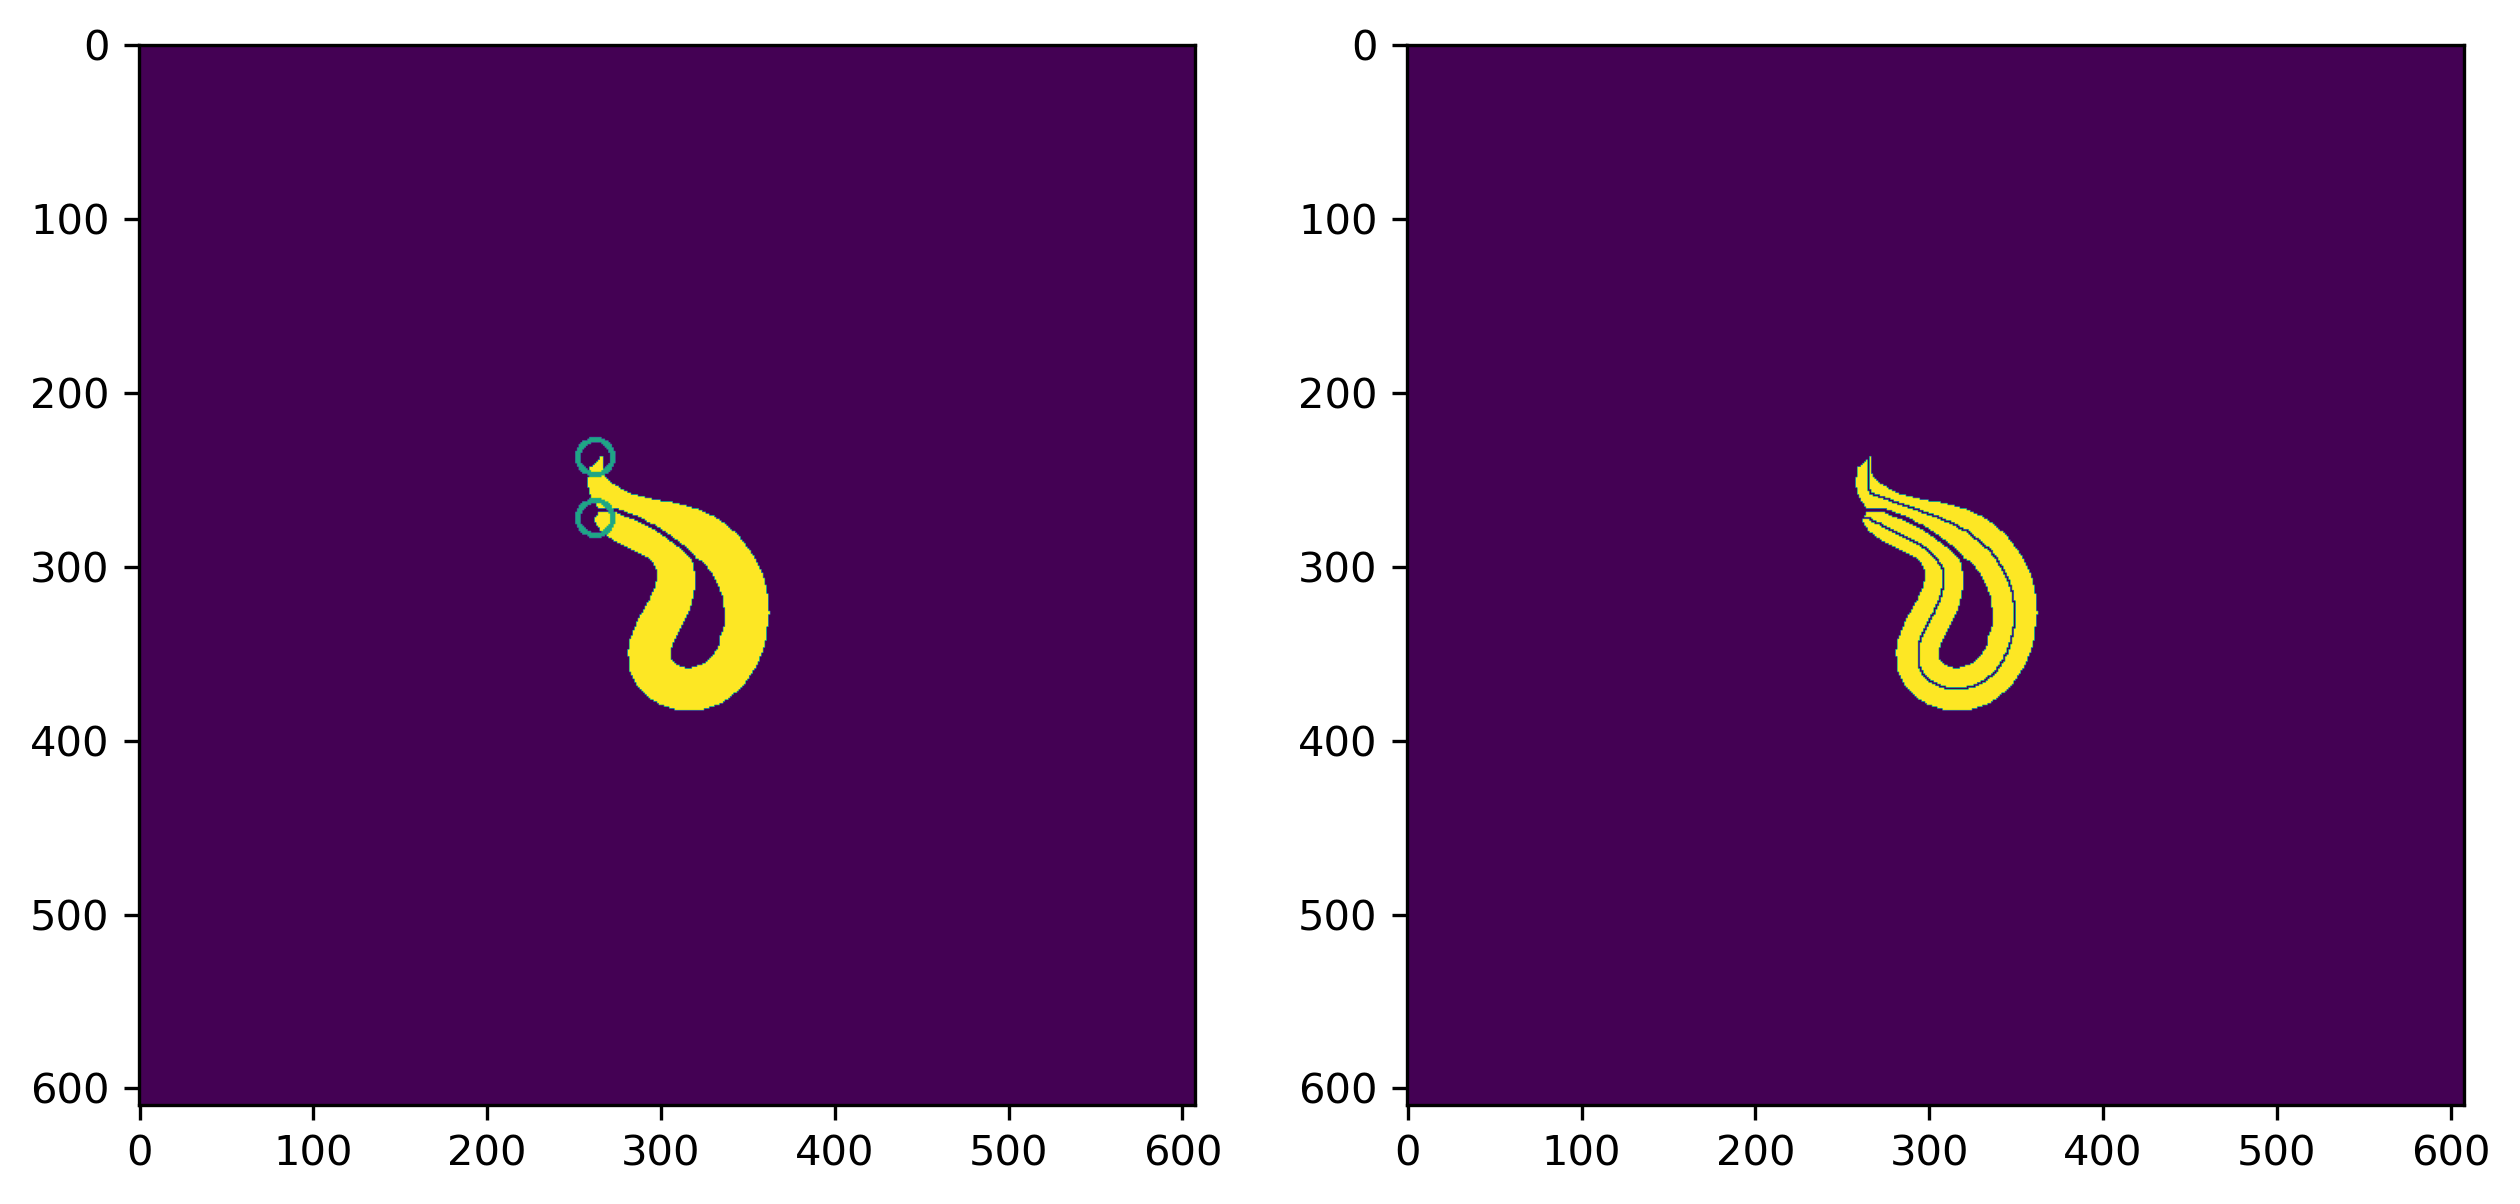

img067.tif
head and tail were too close, no centerline could be created
img106.tif


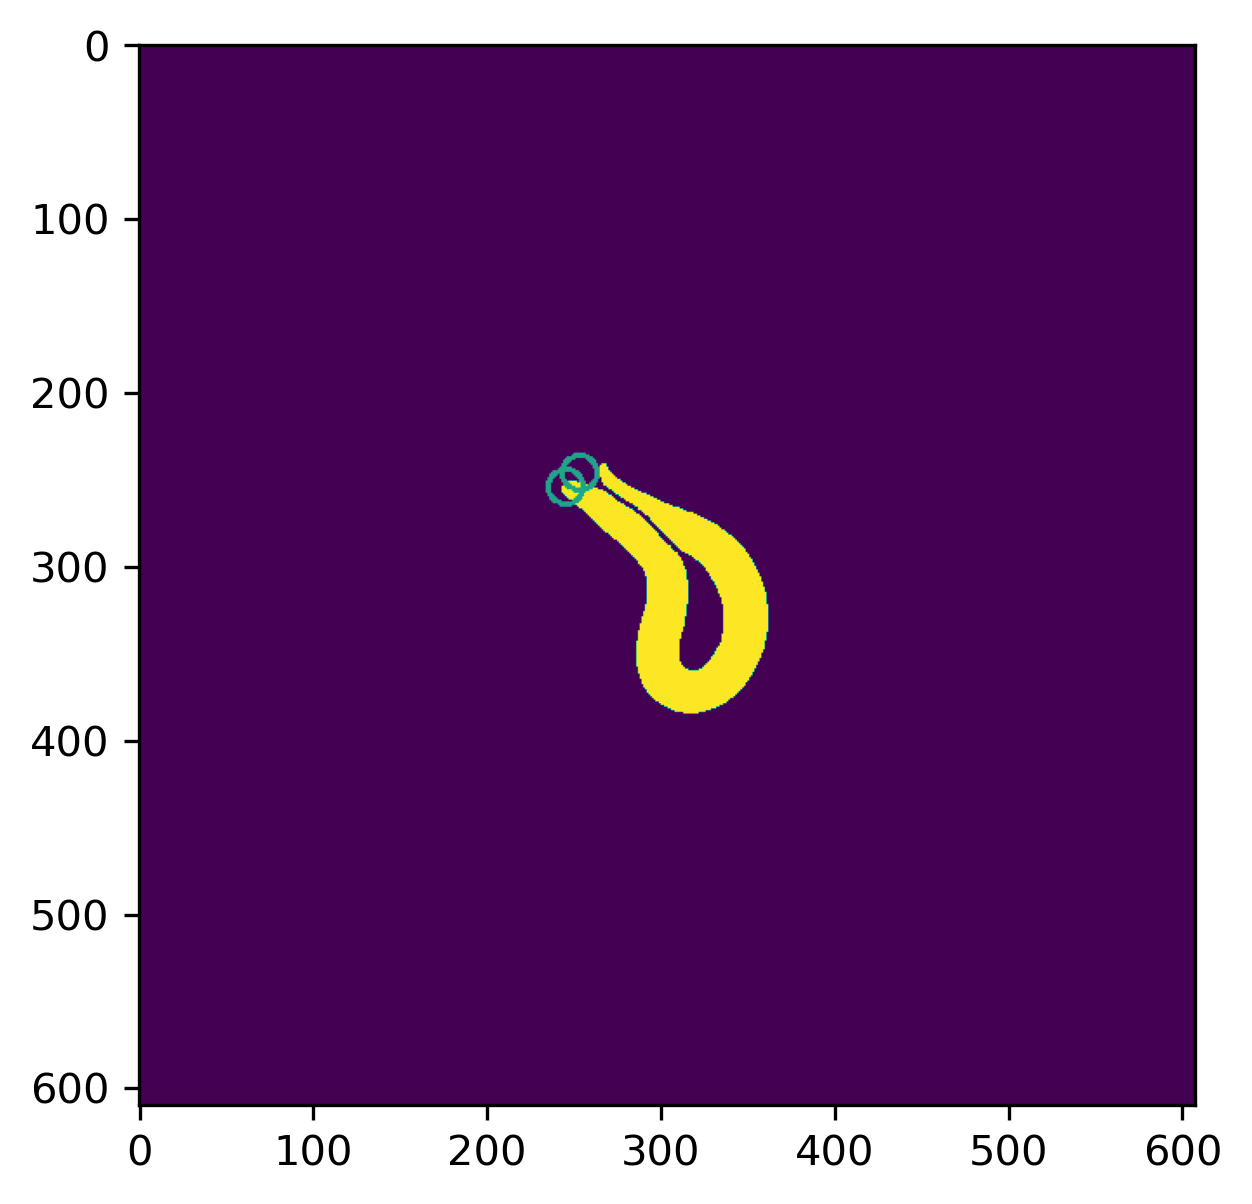

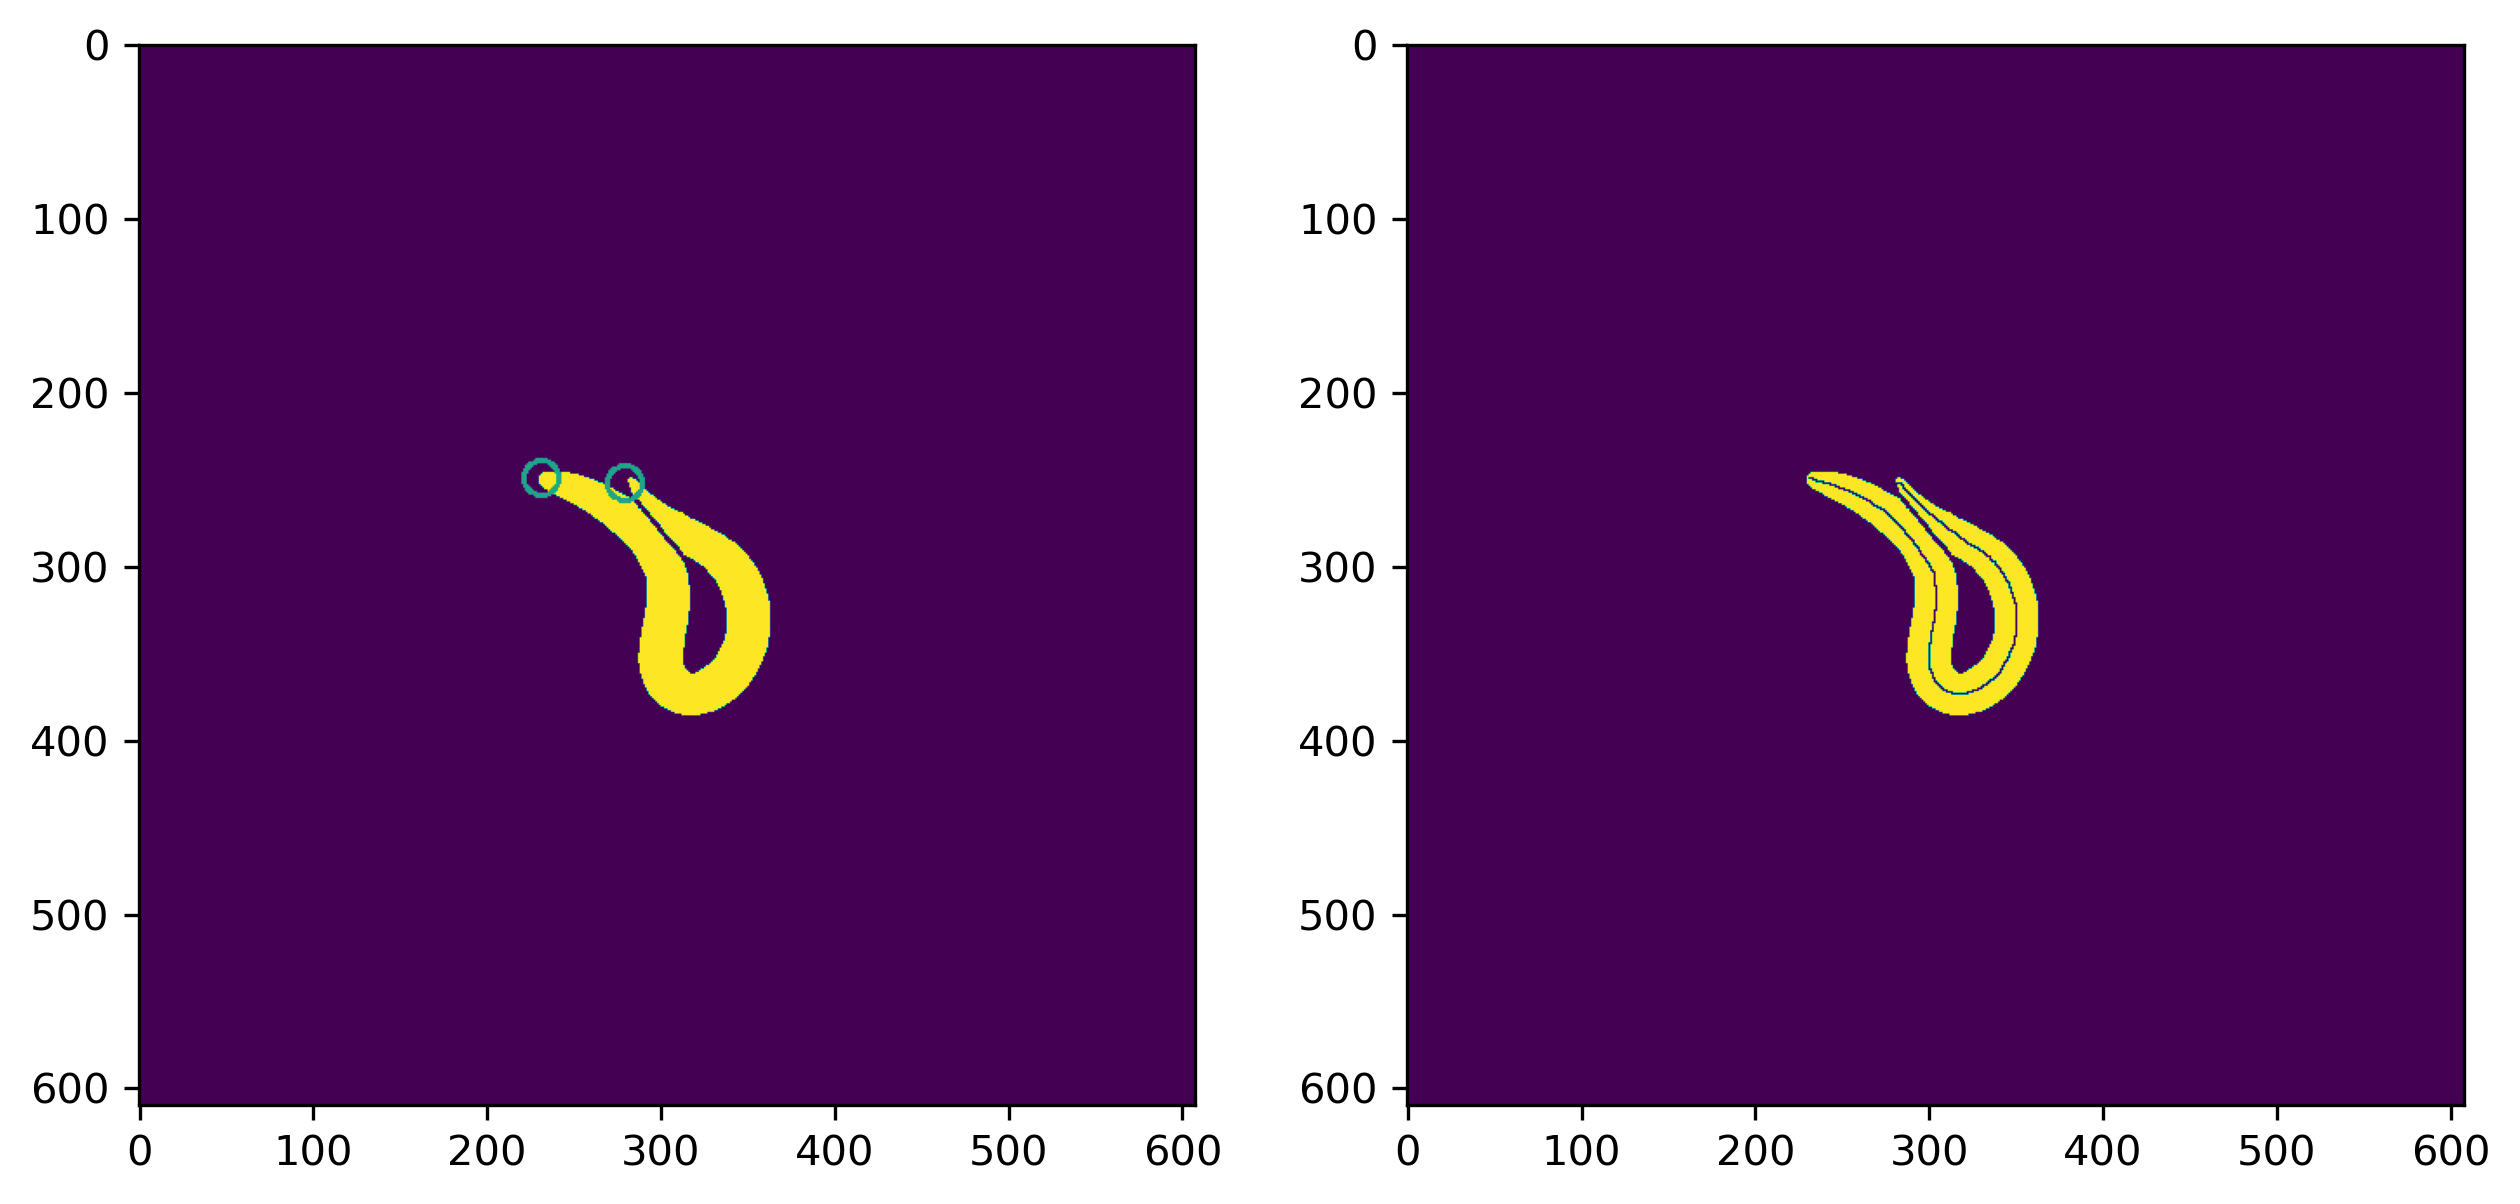

img140.tif
head and tail were too close, no centerline could be created
img174.tif


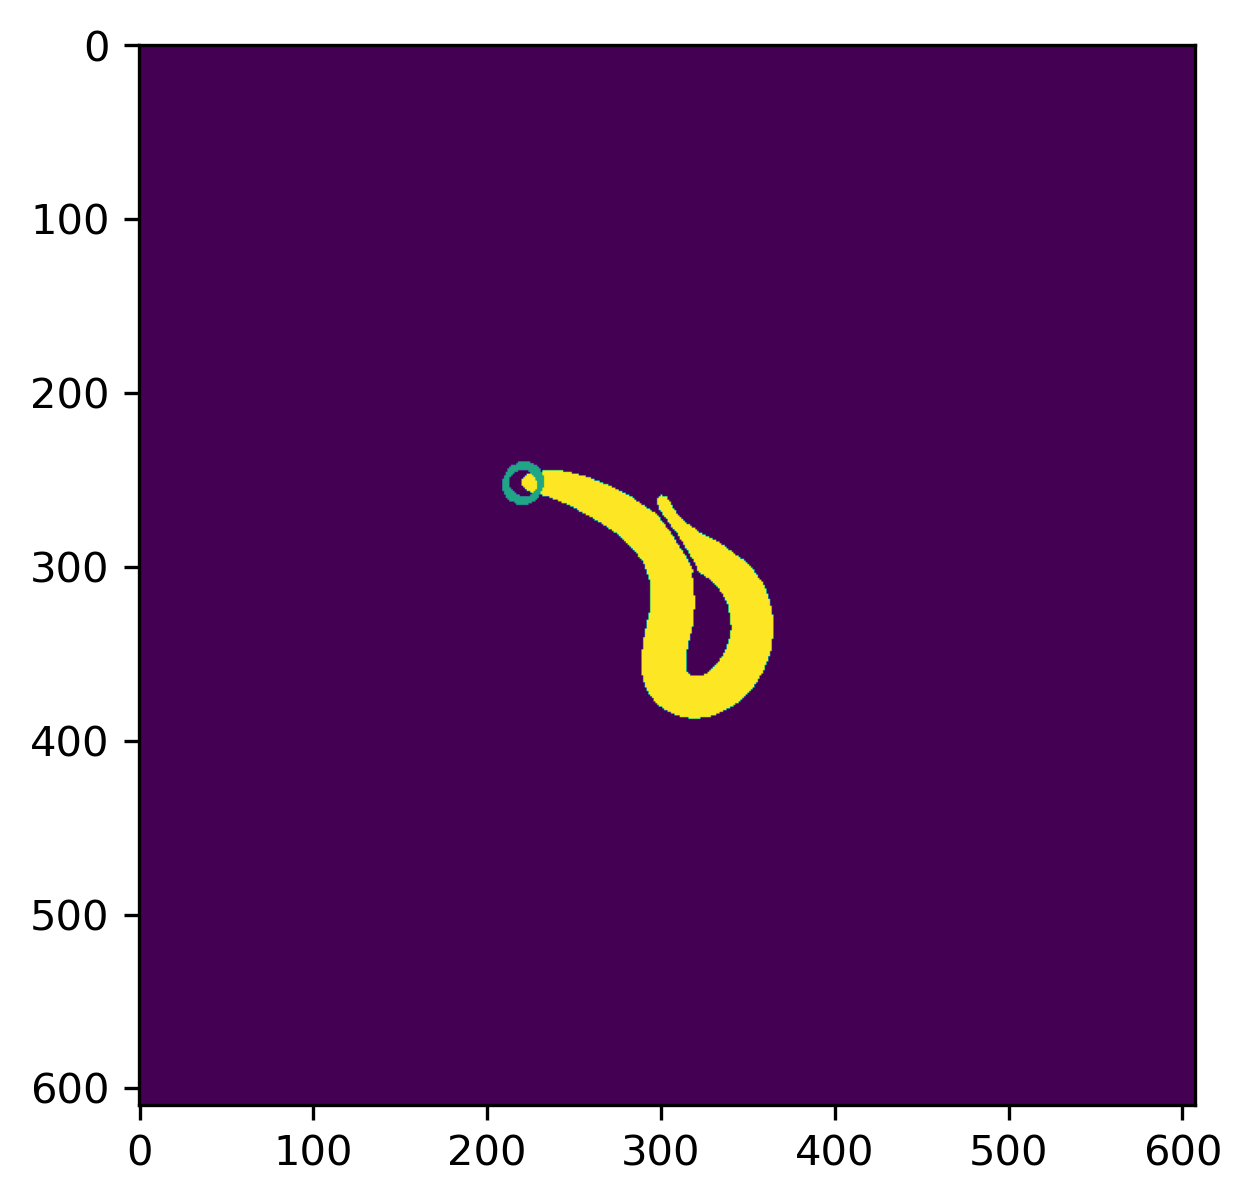

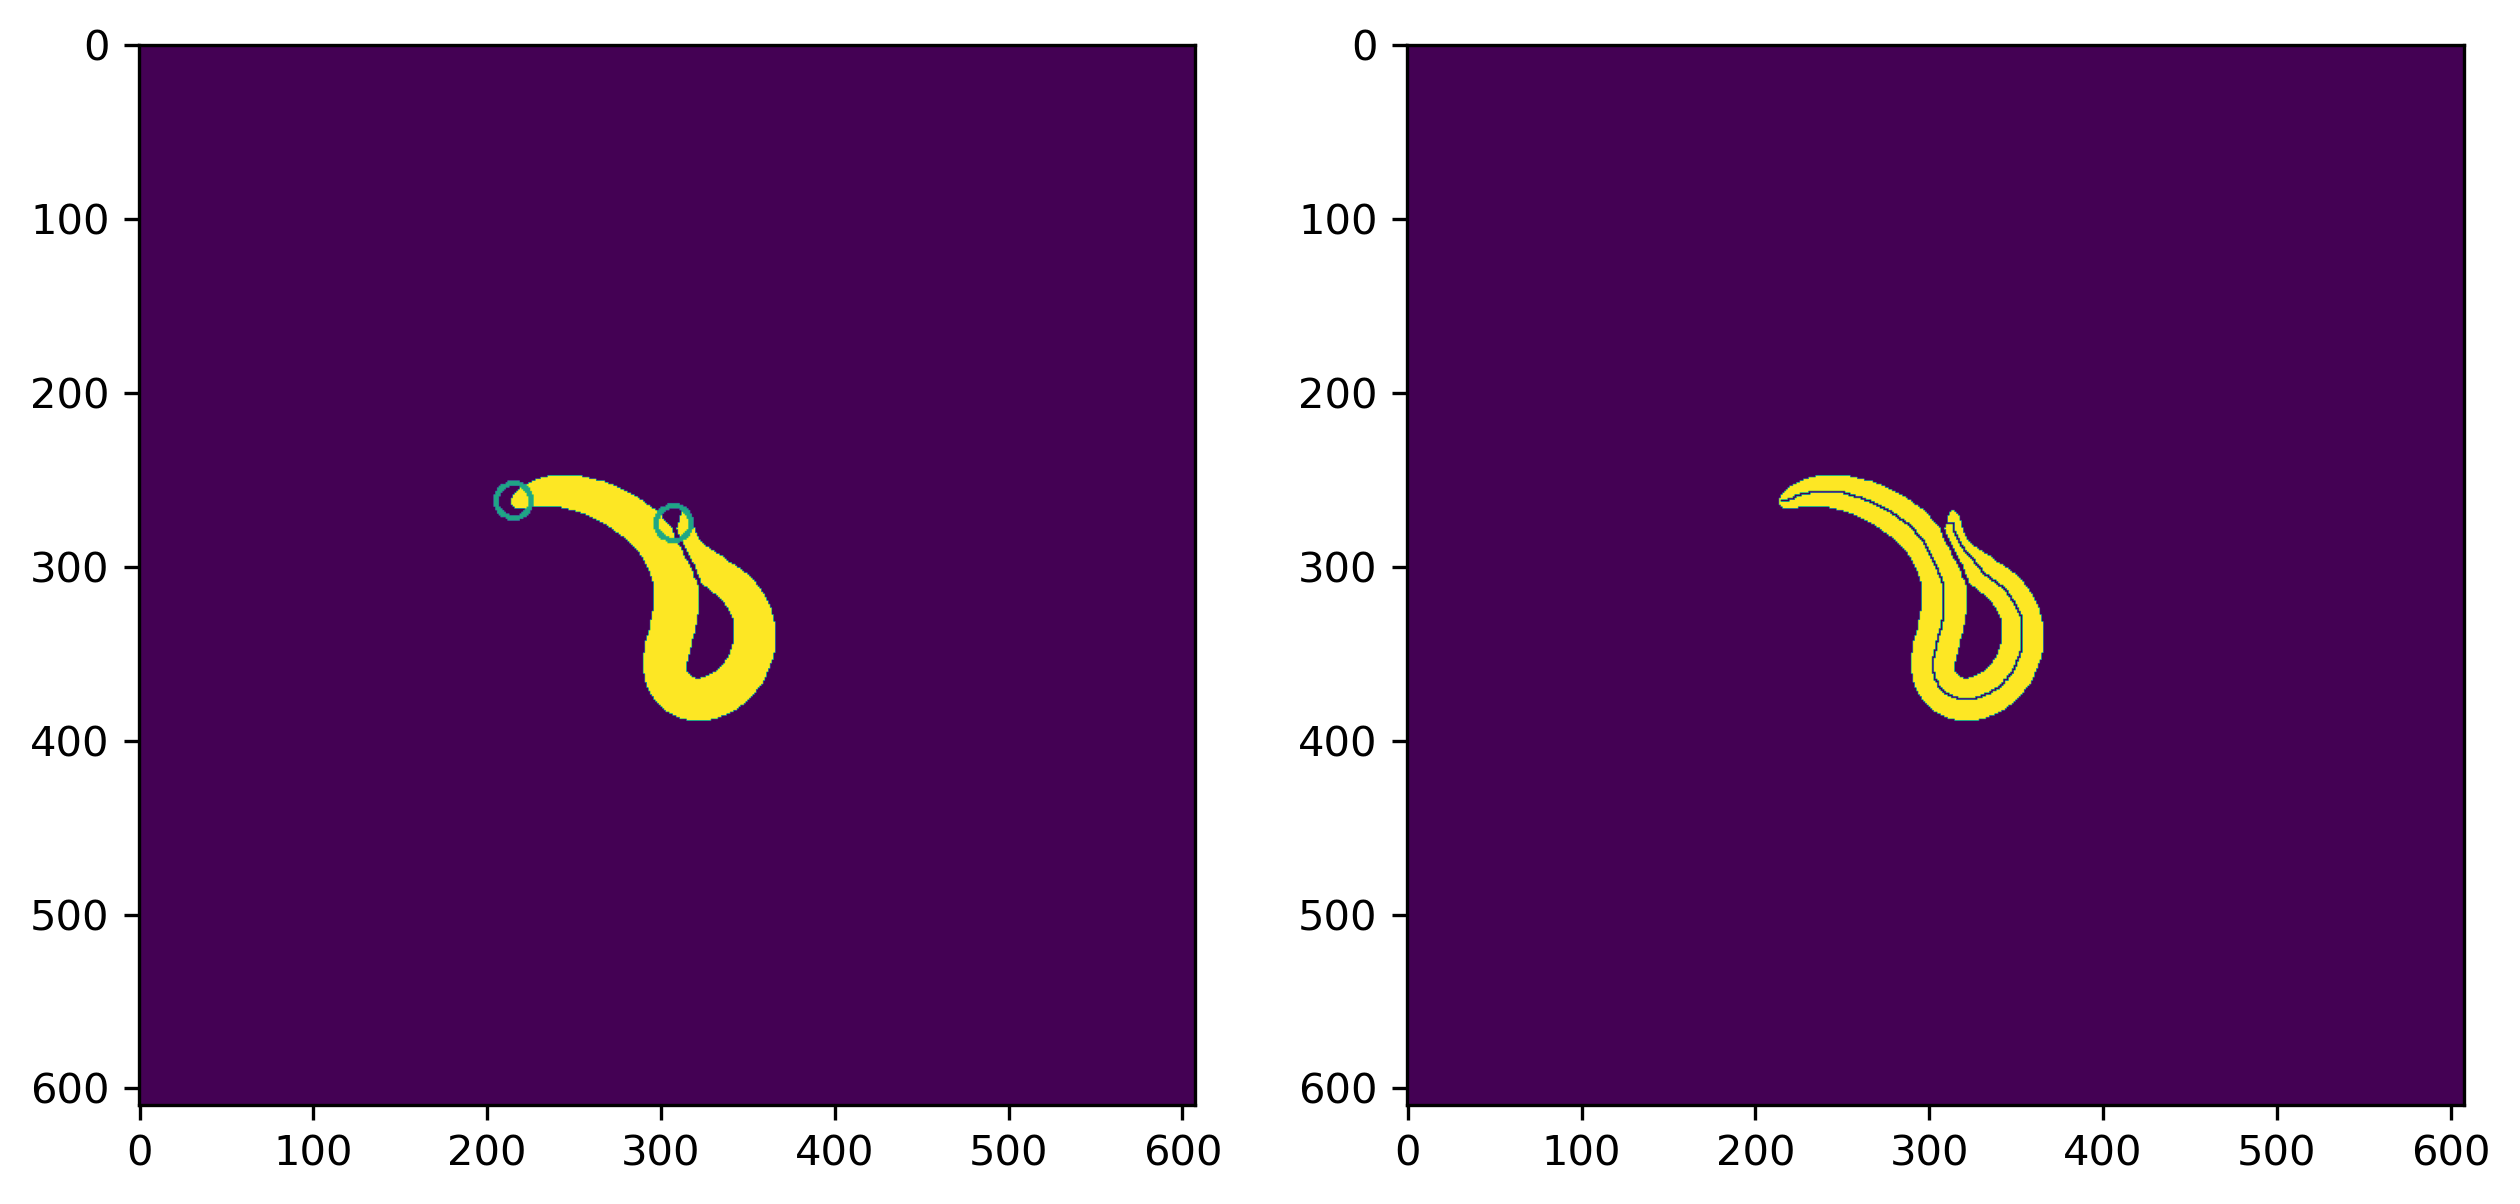

img207.tif


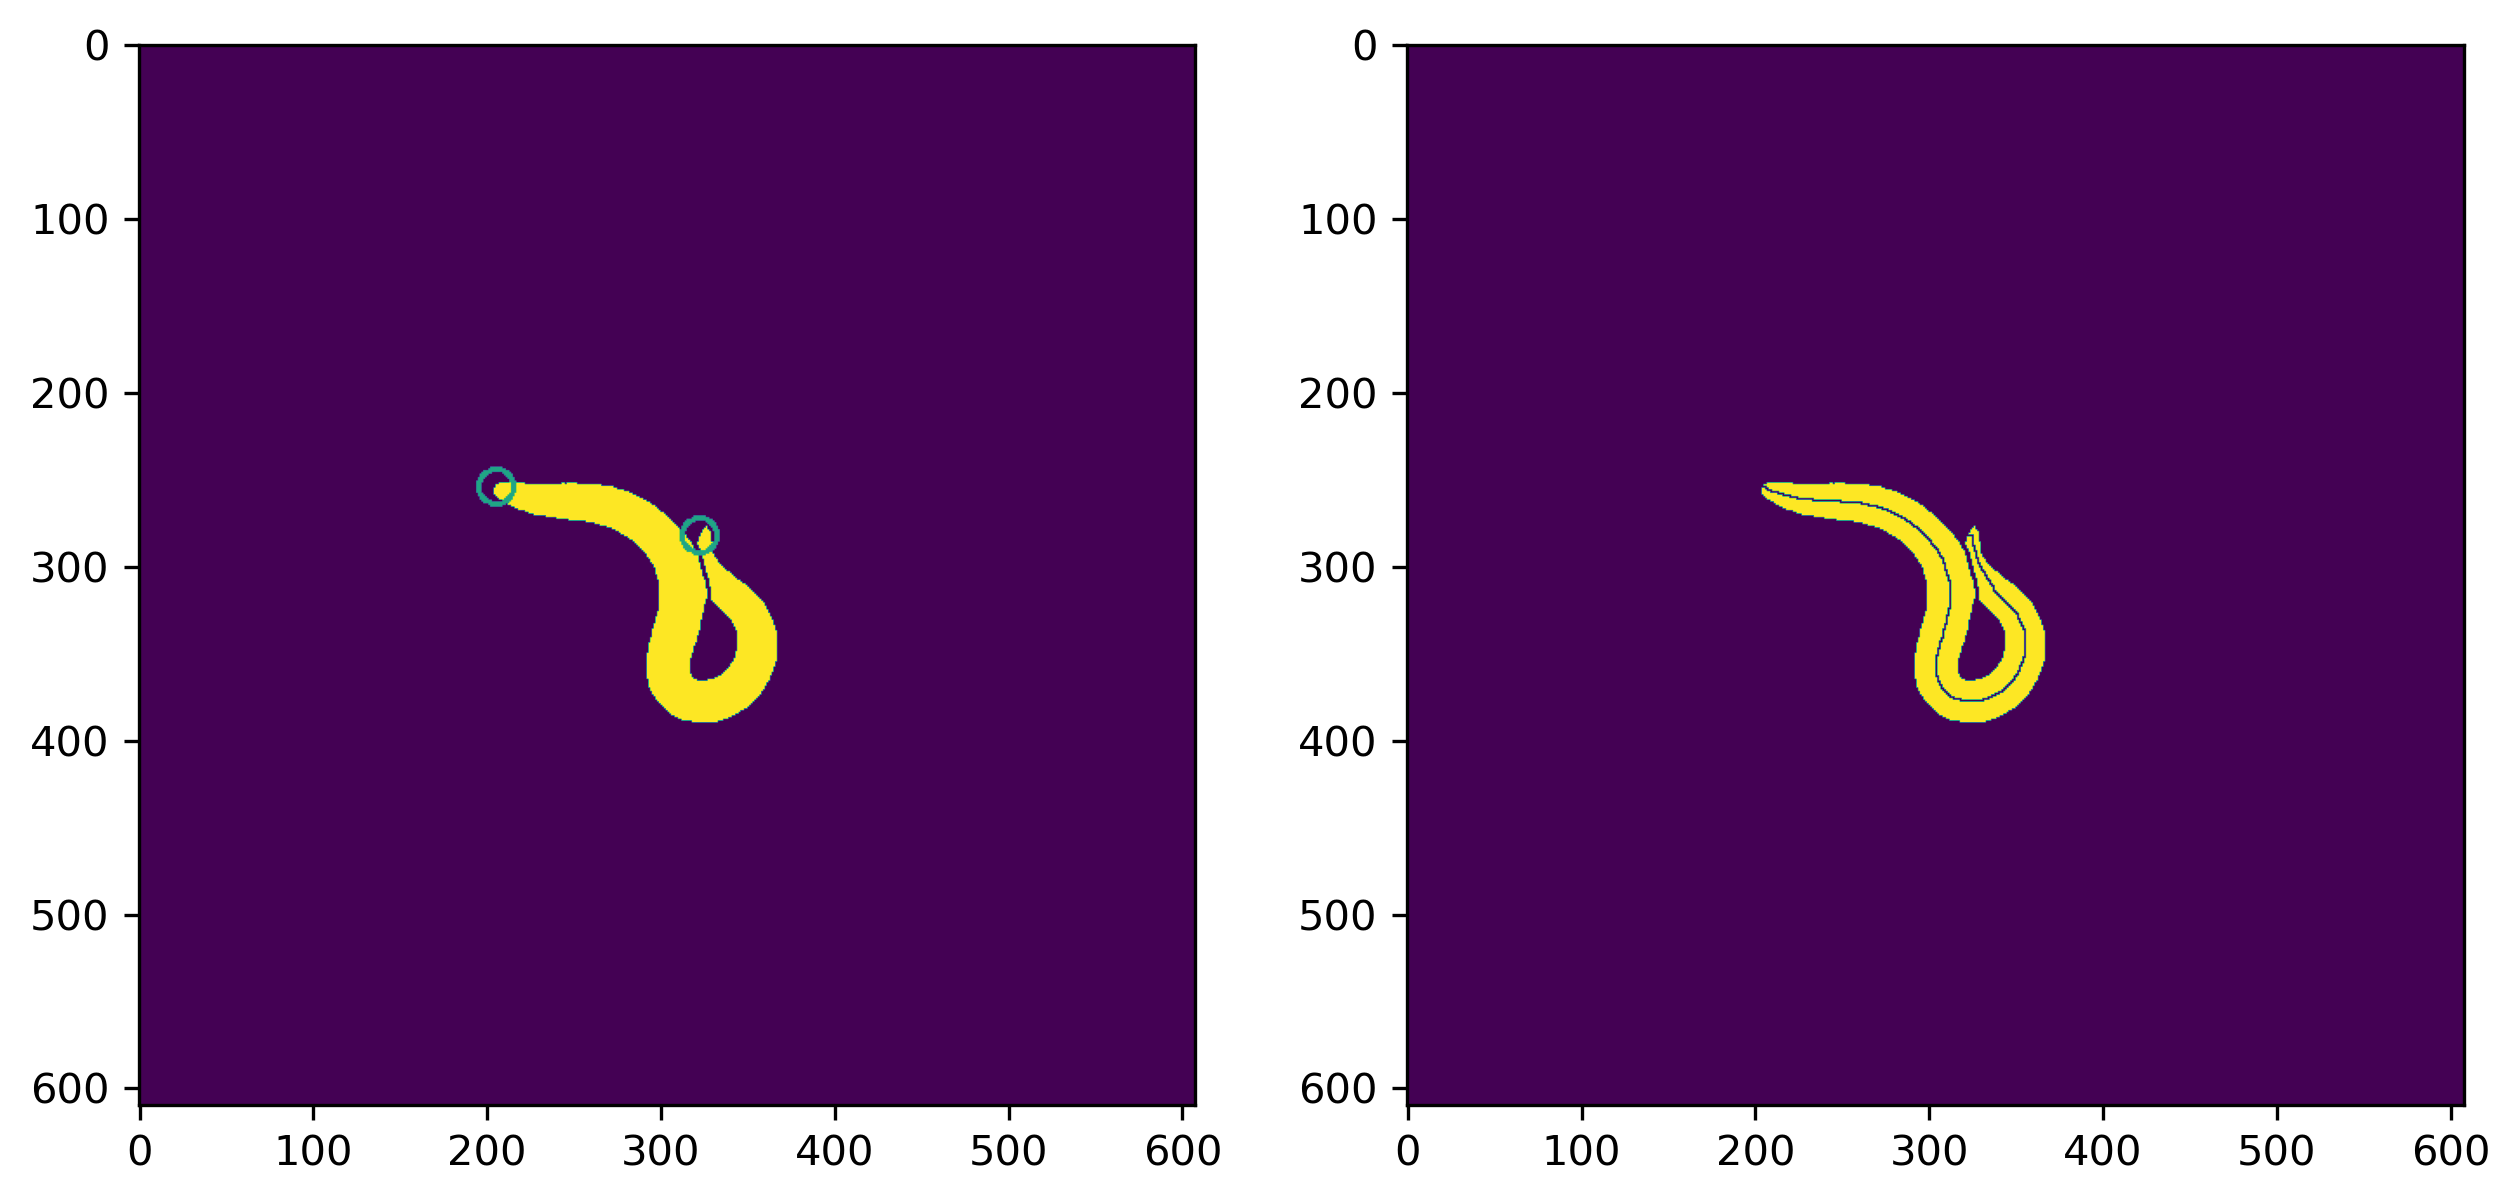

img245.tif


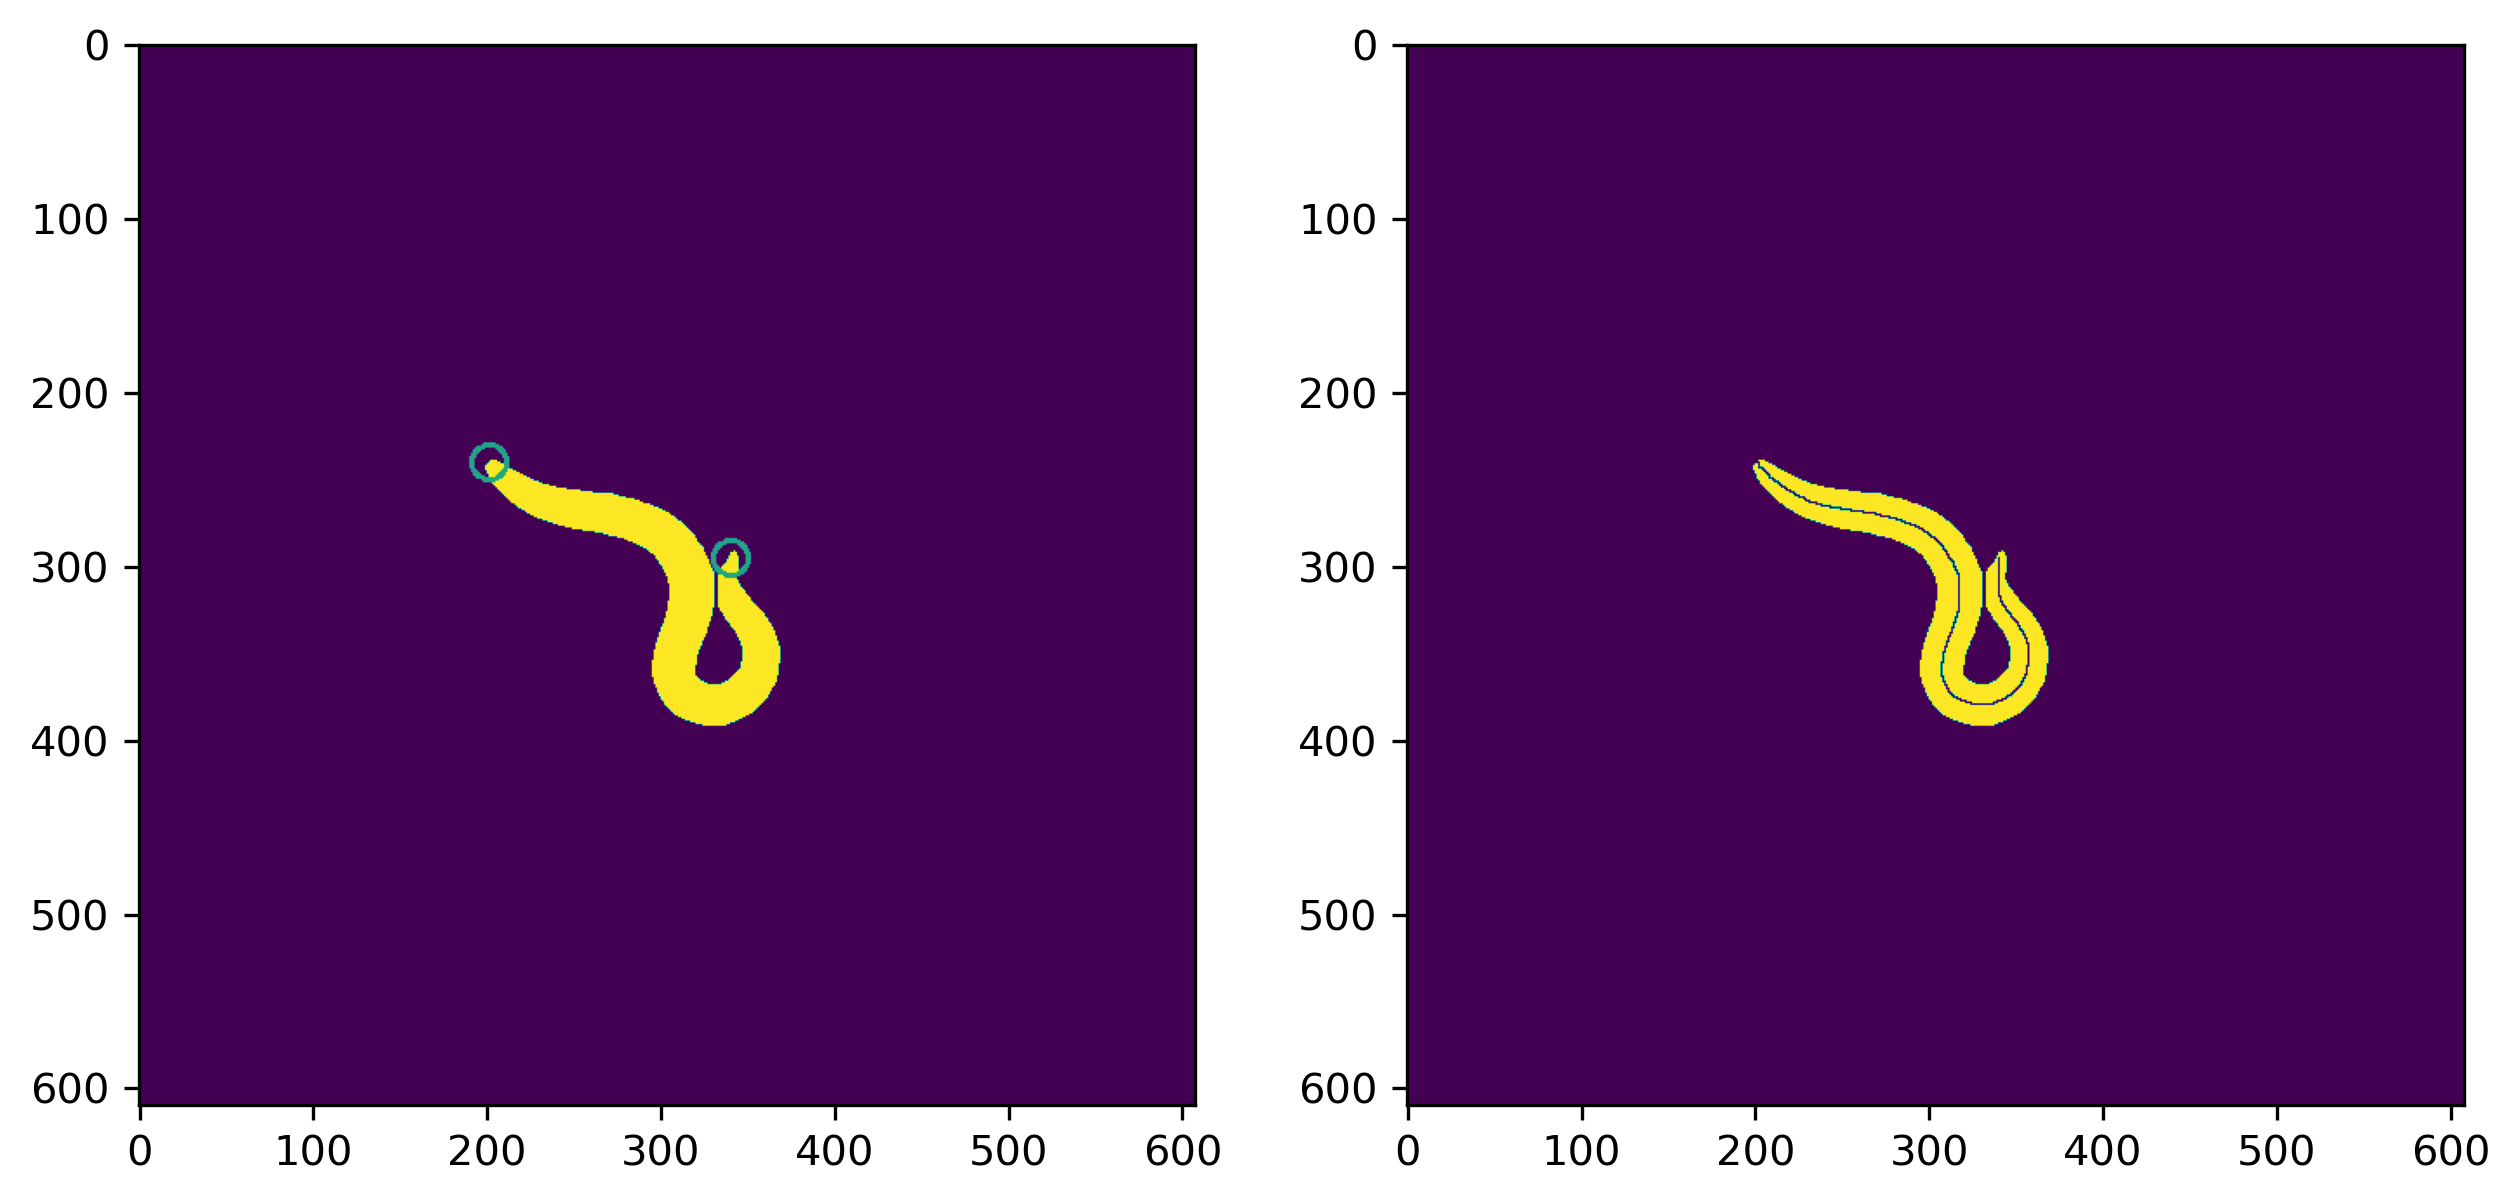

img256.tif


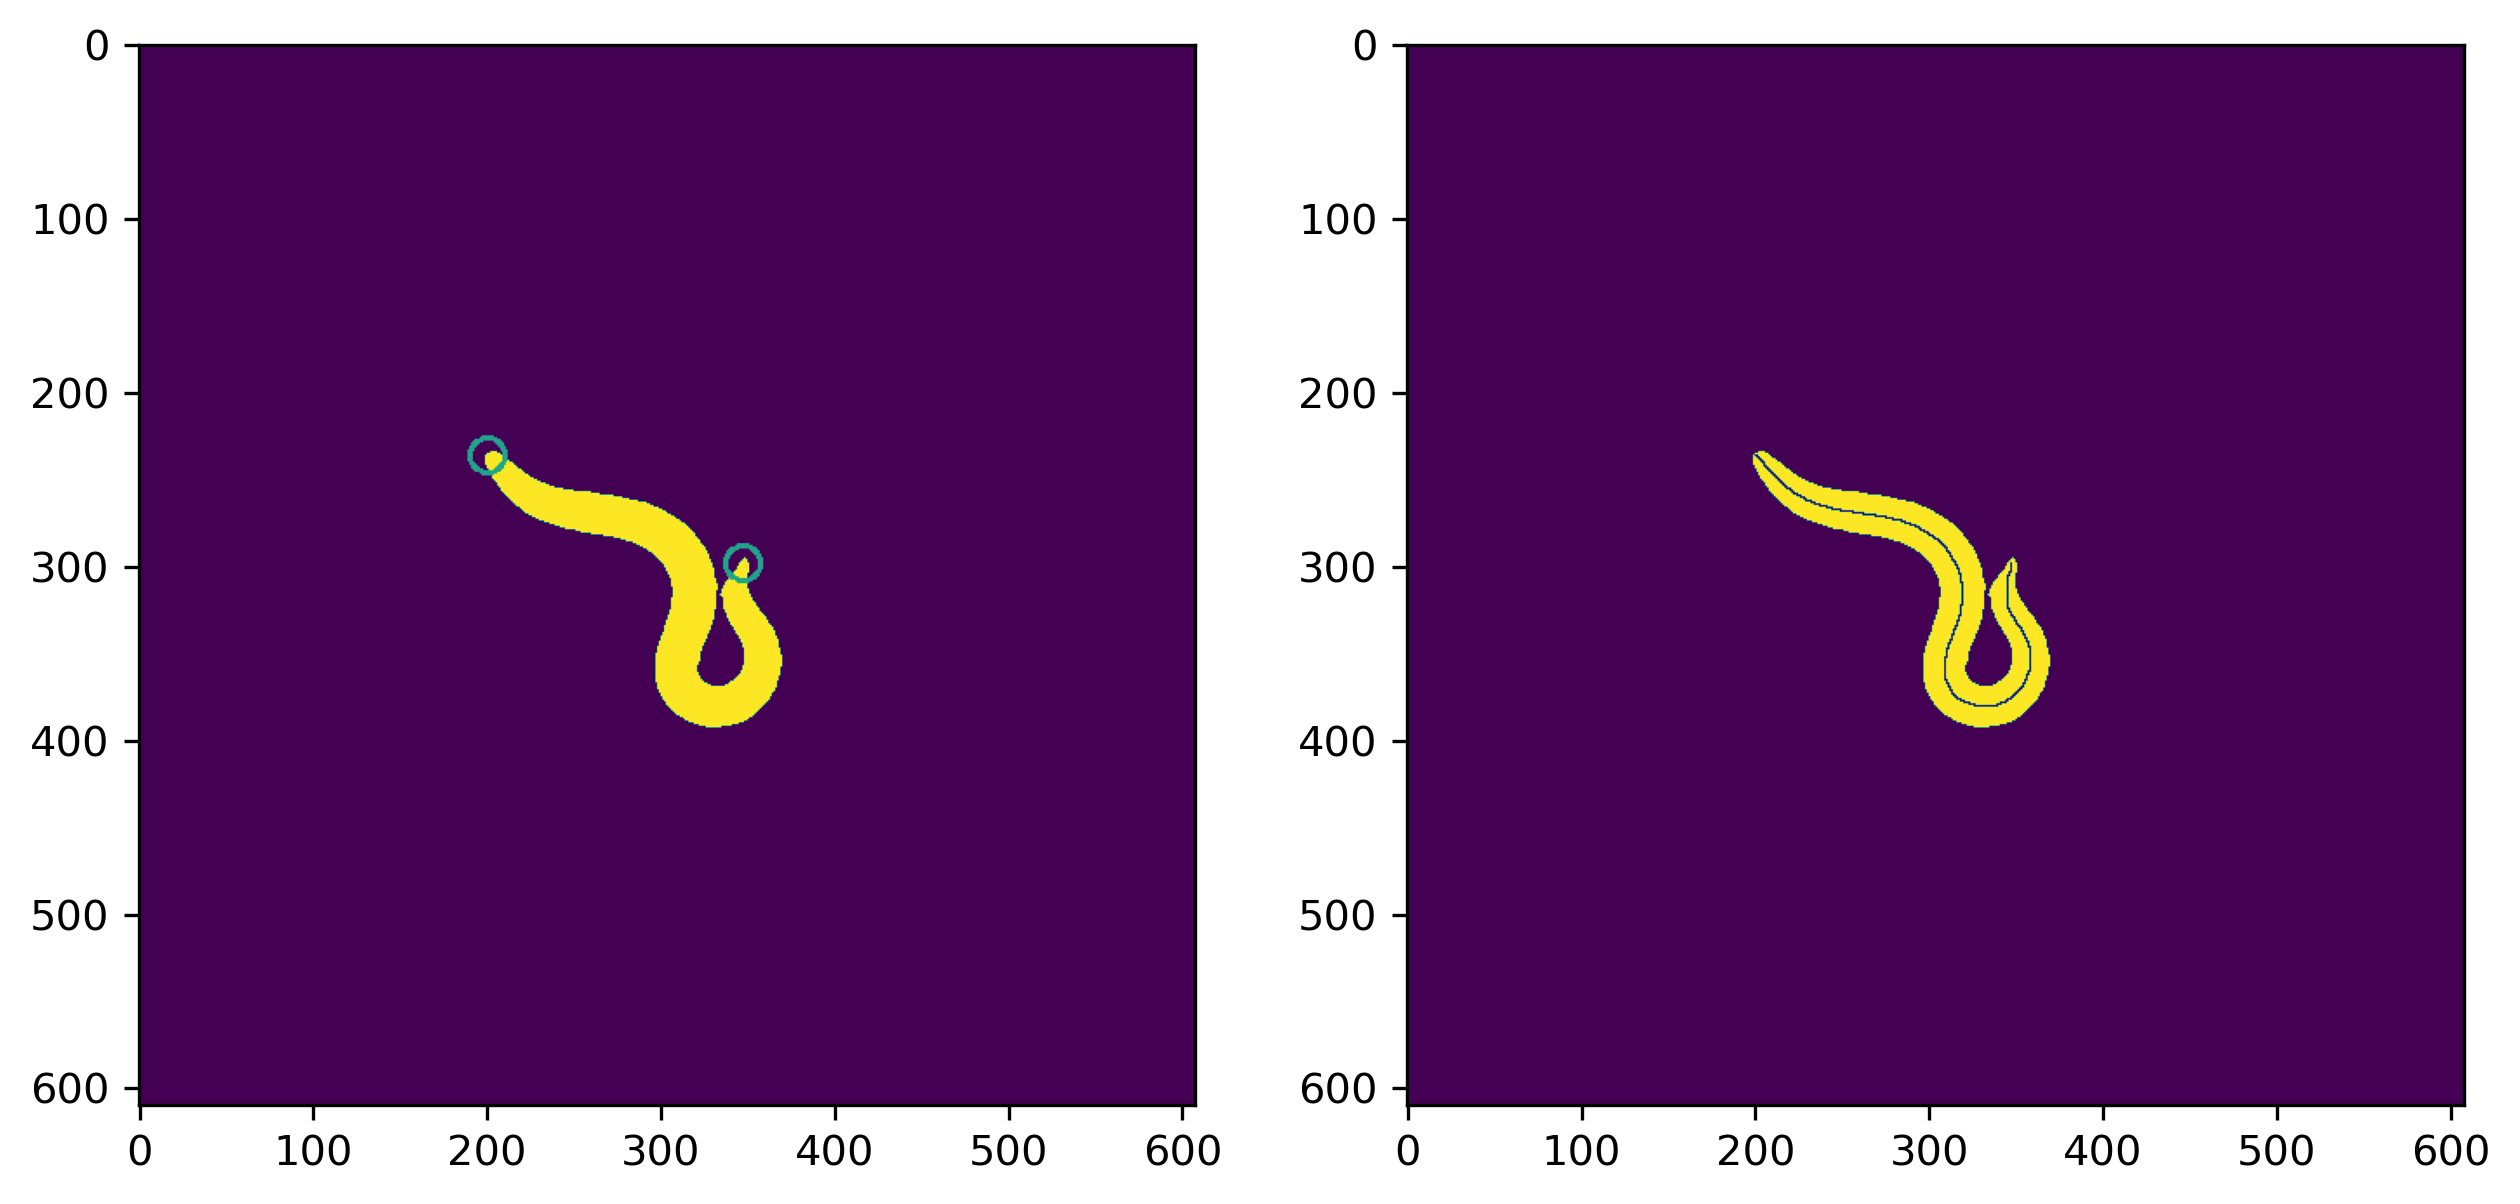

img2739.tif


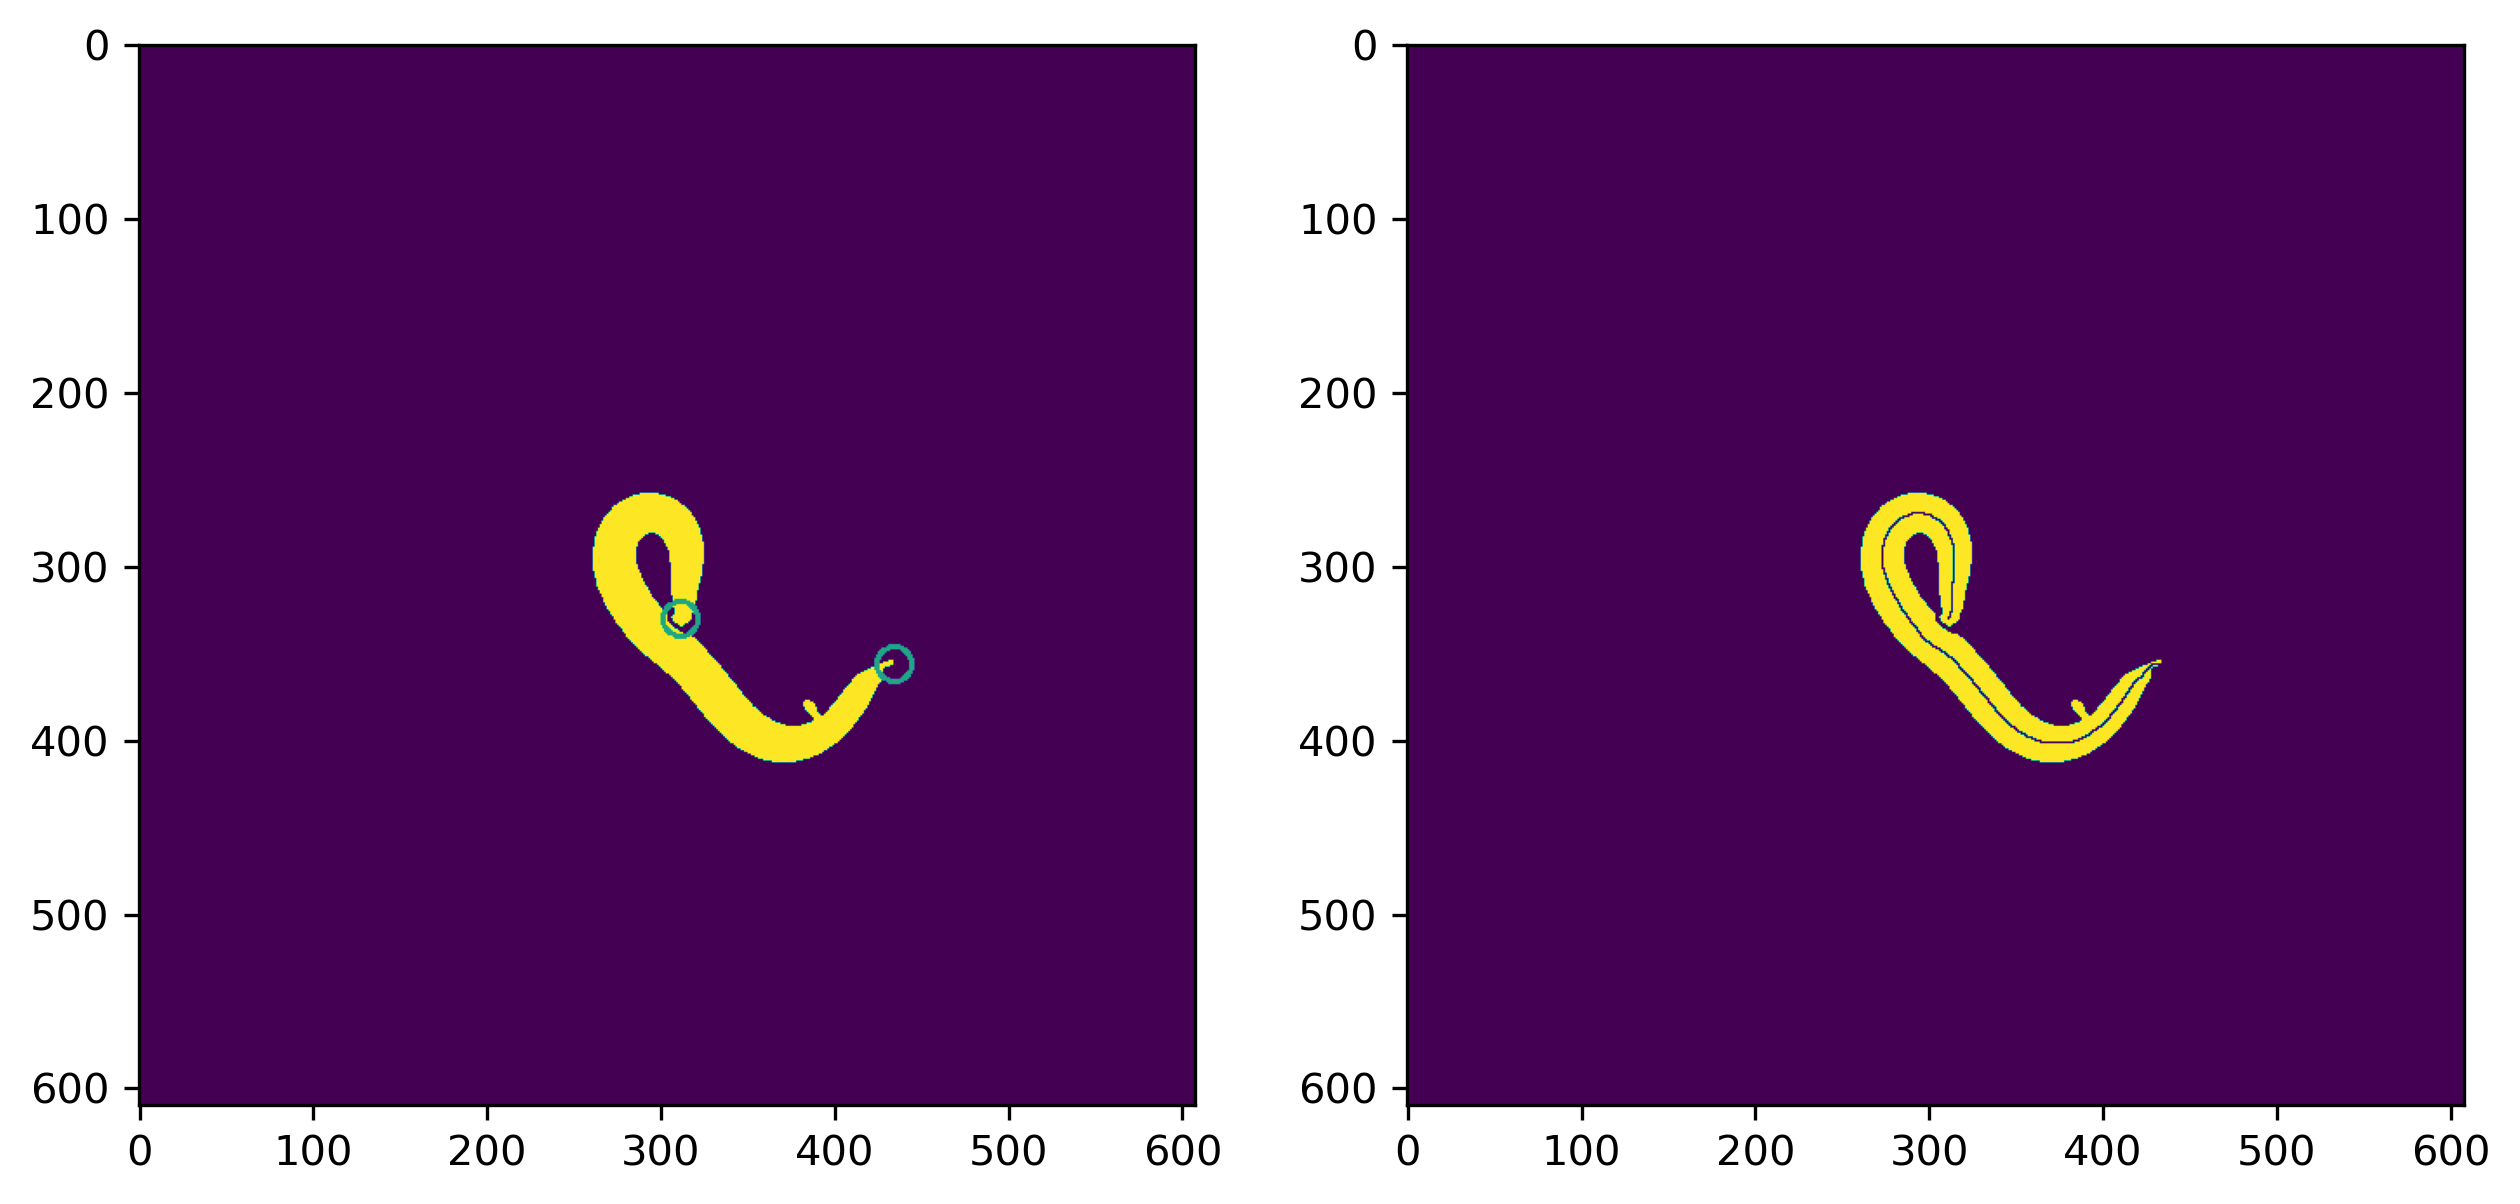

img2754.tif


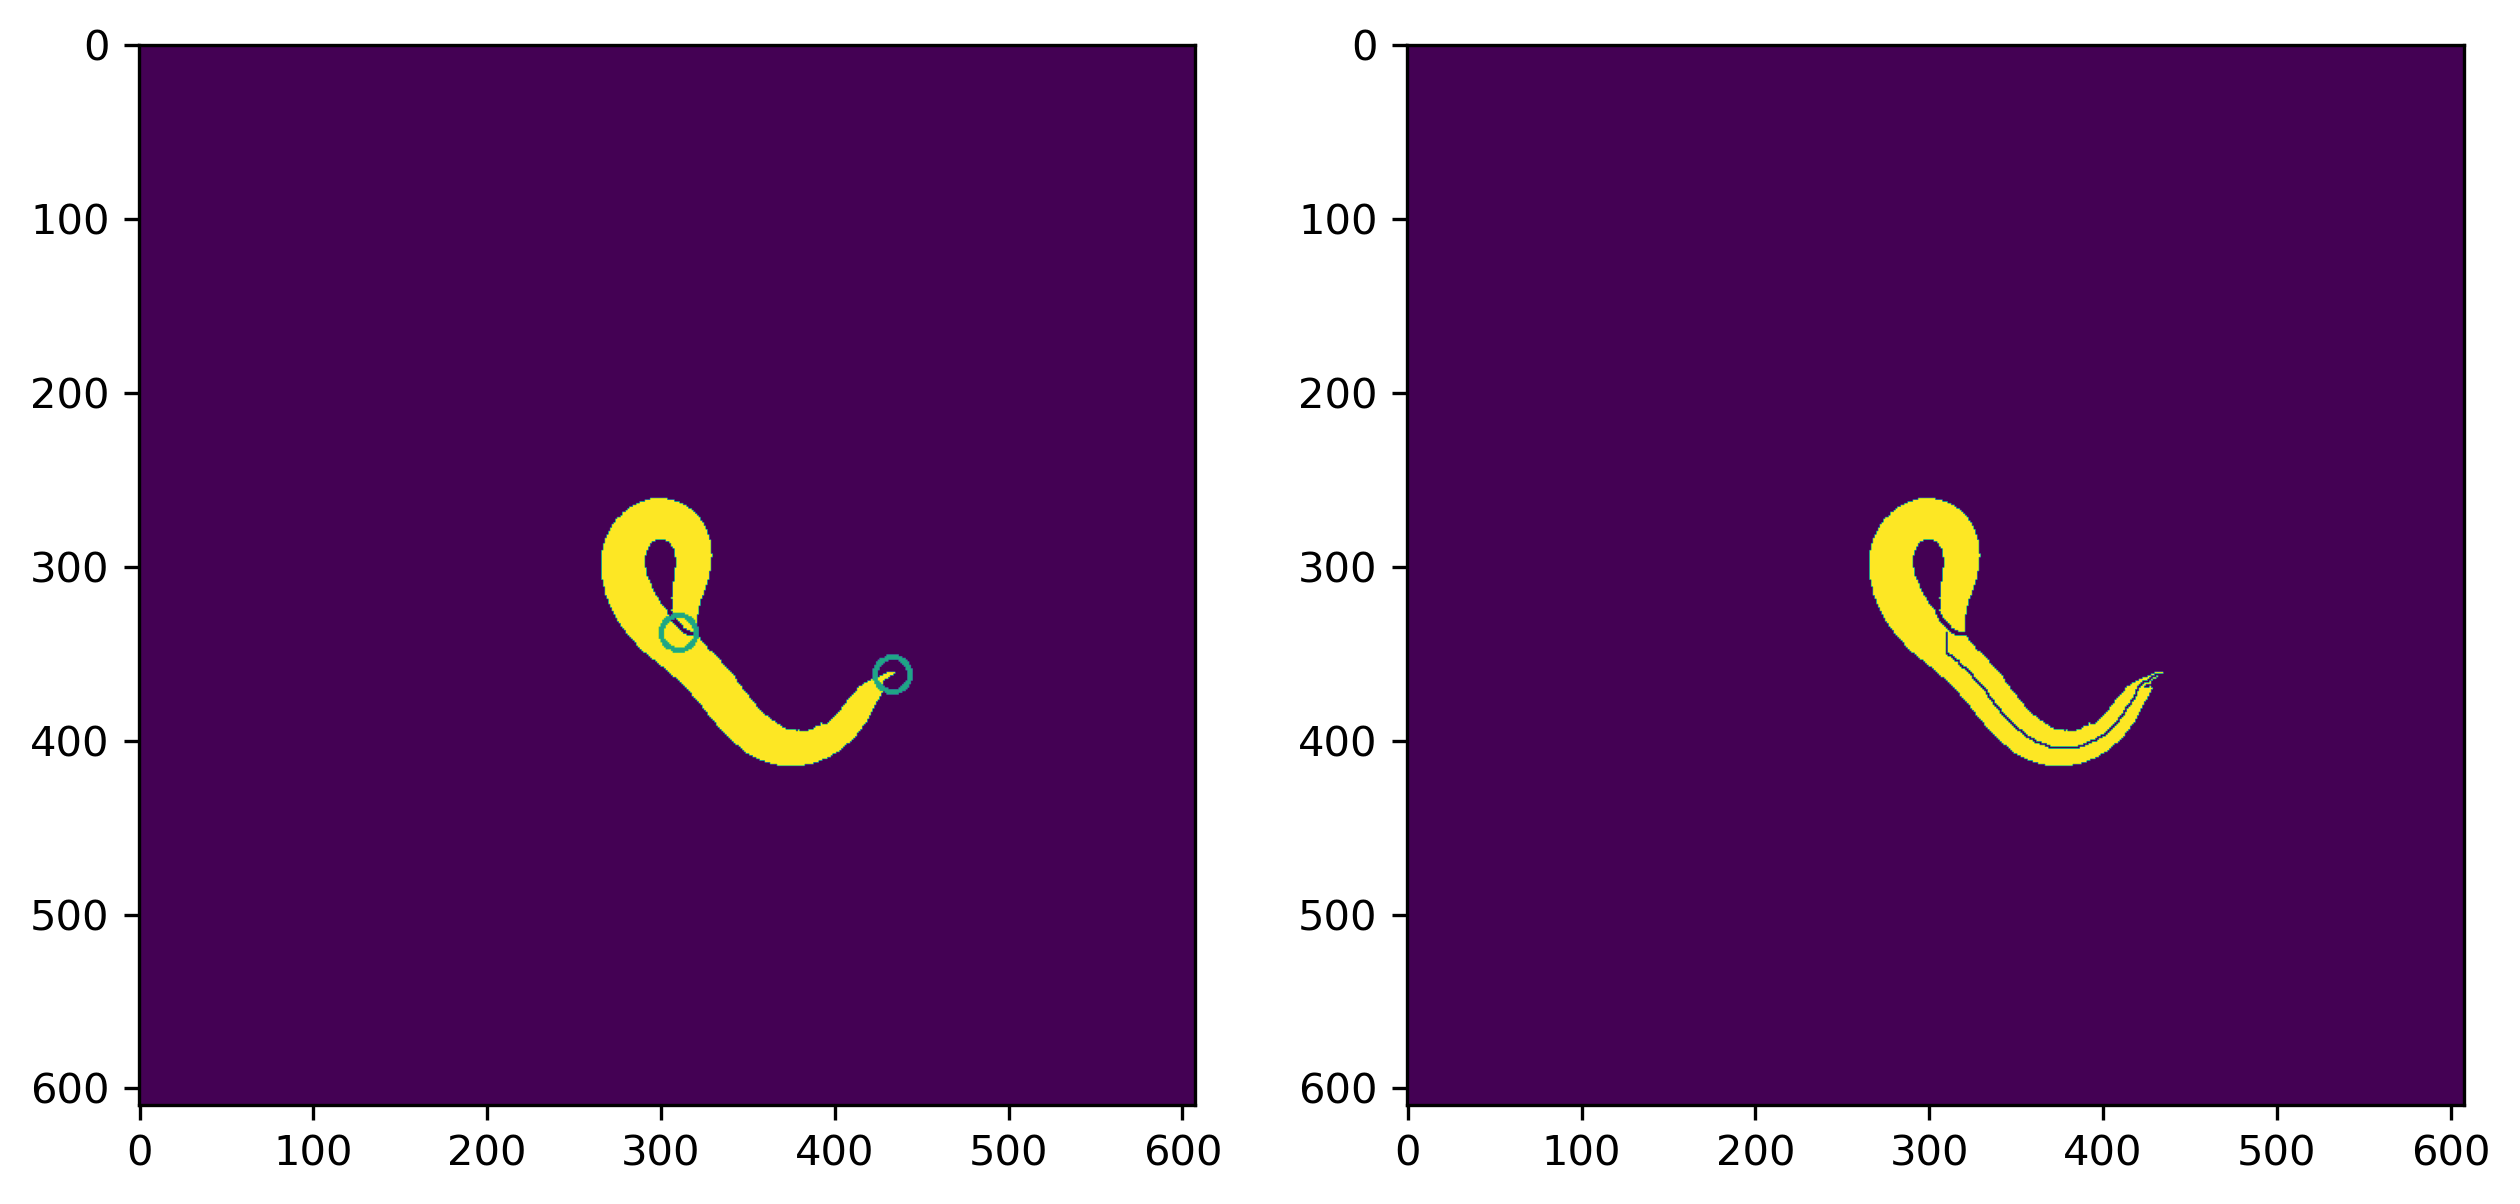

img2775.tif


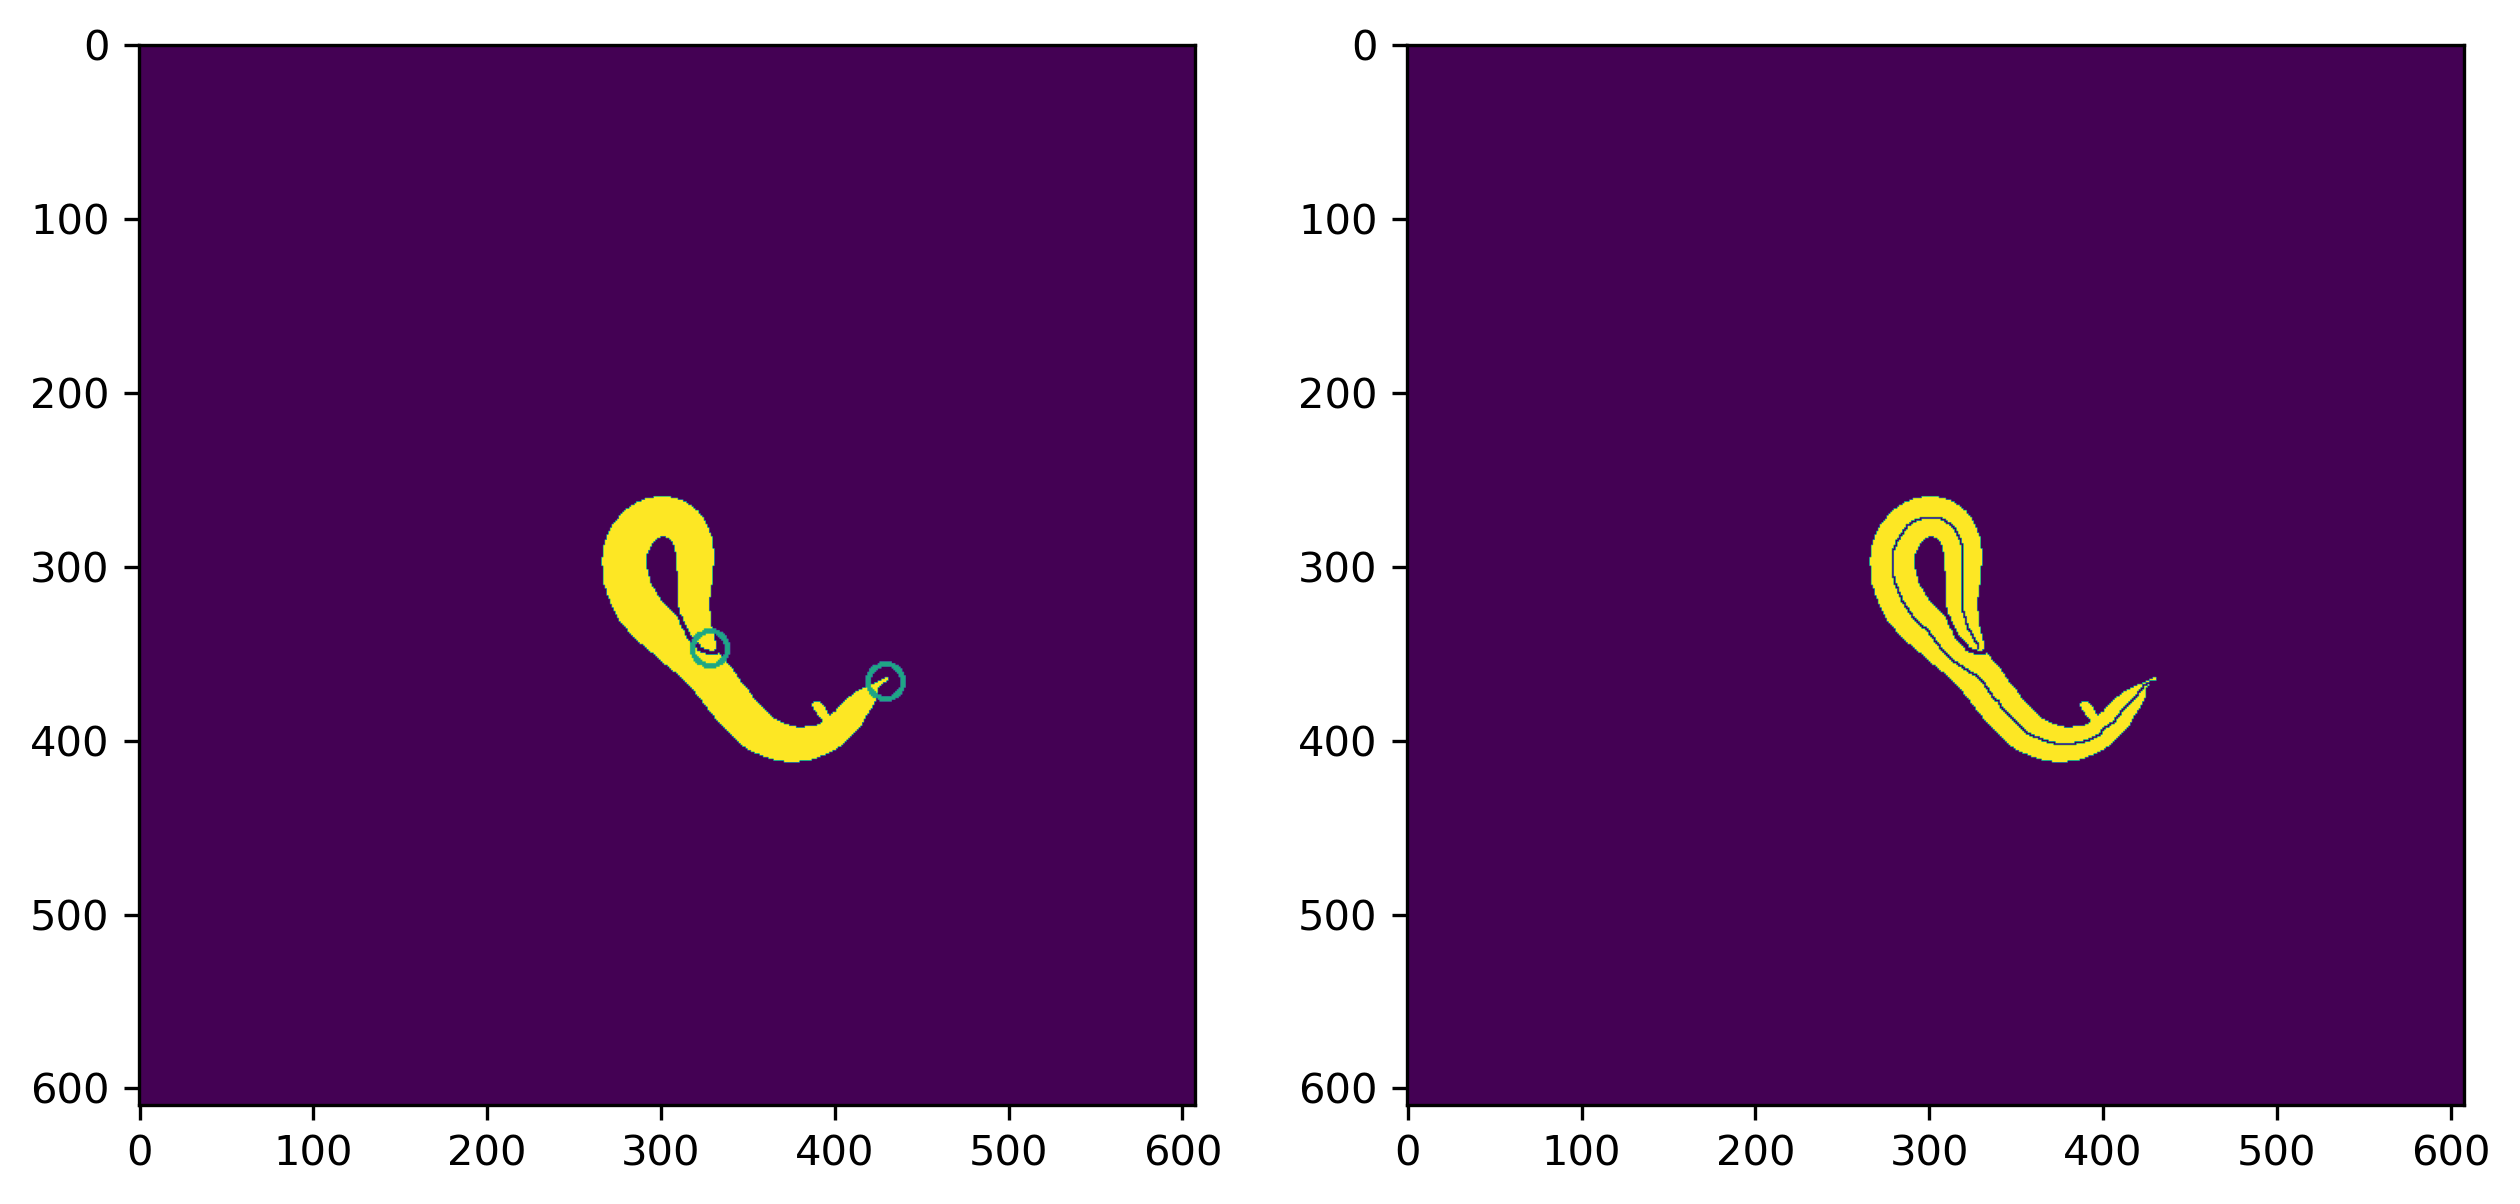

img2798.tif
head and tail were too close, no centerline could be created
img2809.tif


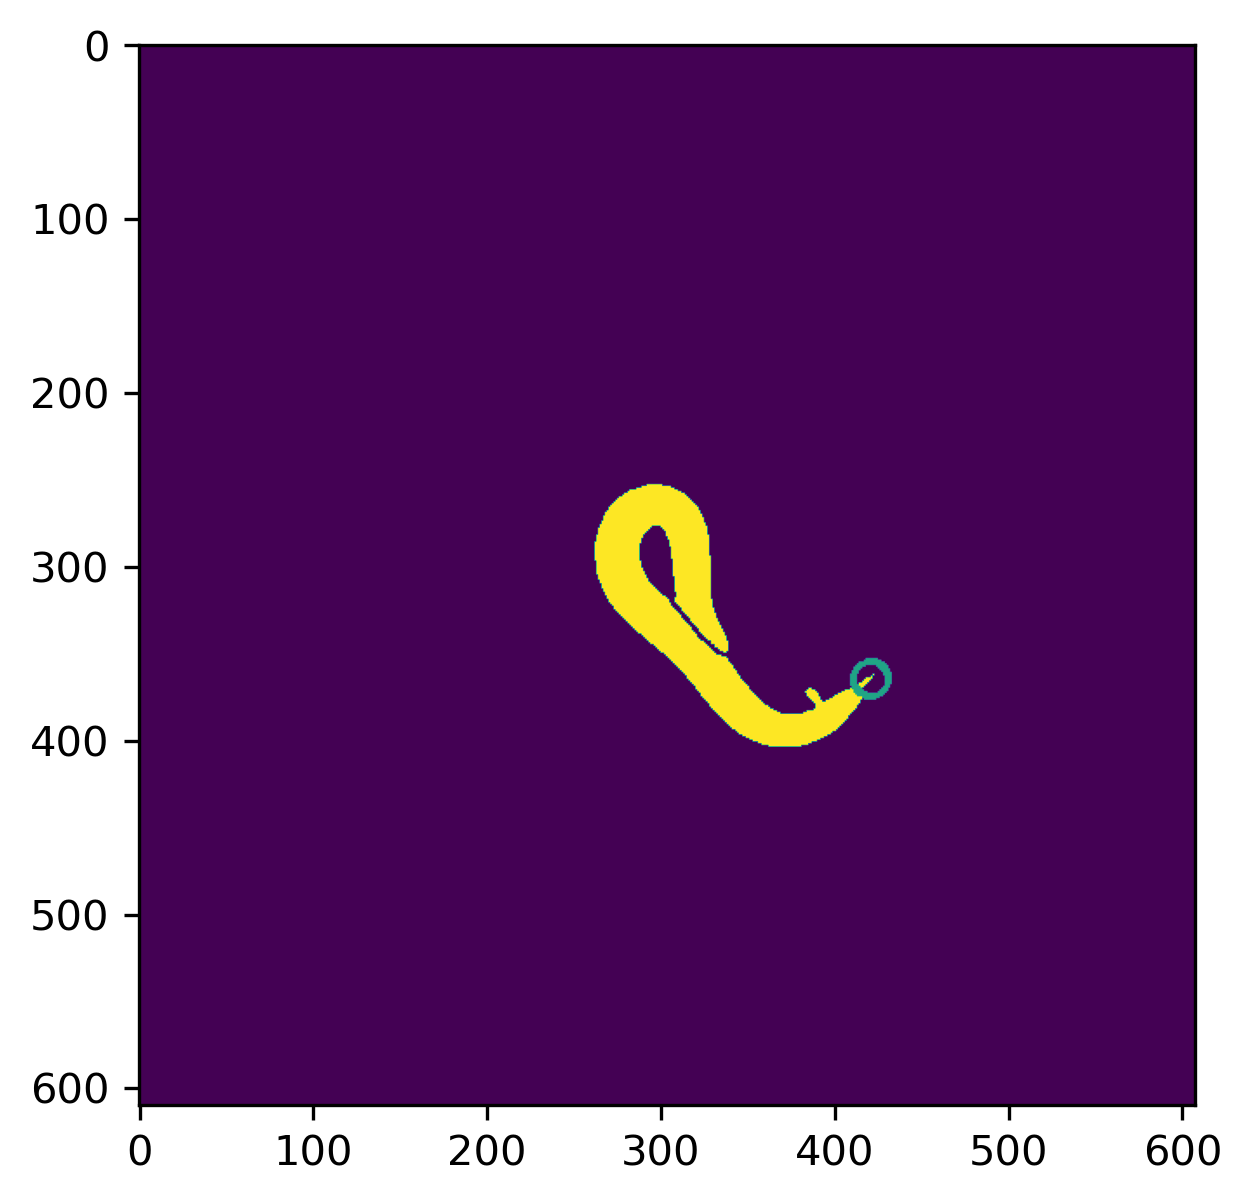

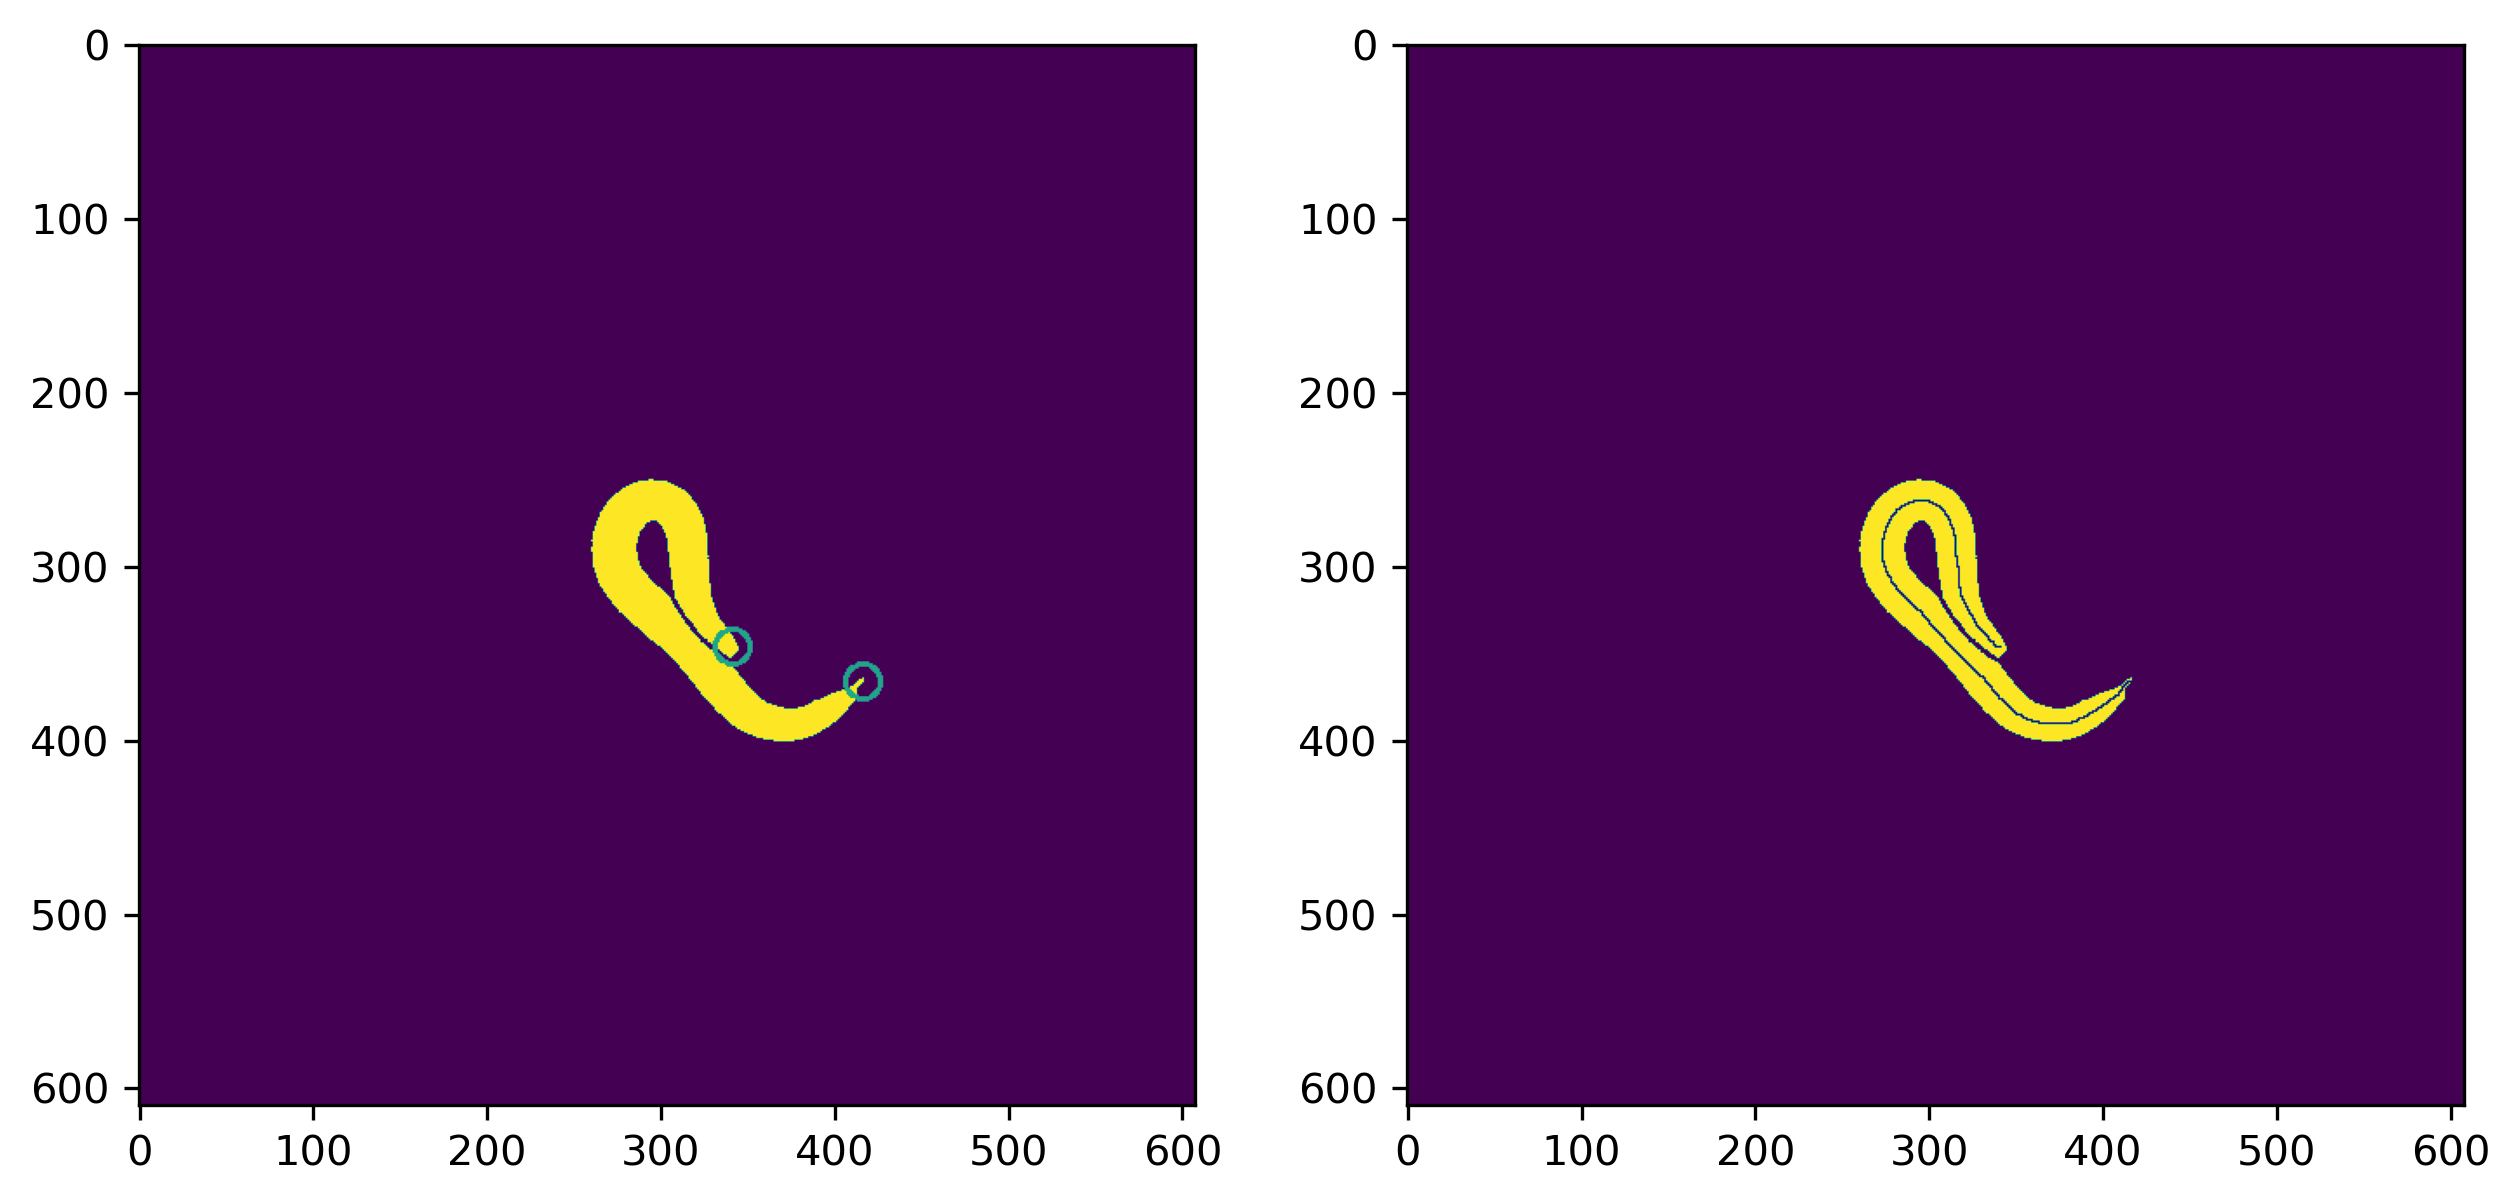

img2820.tif


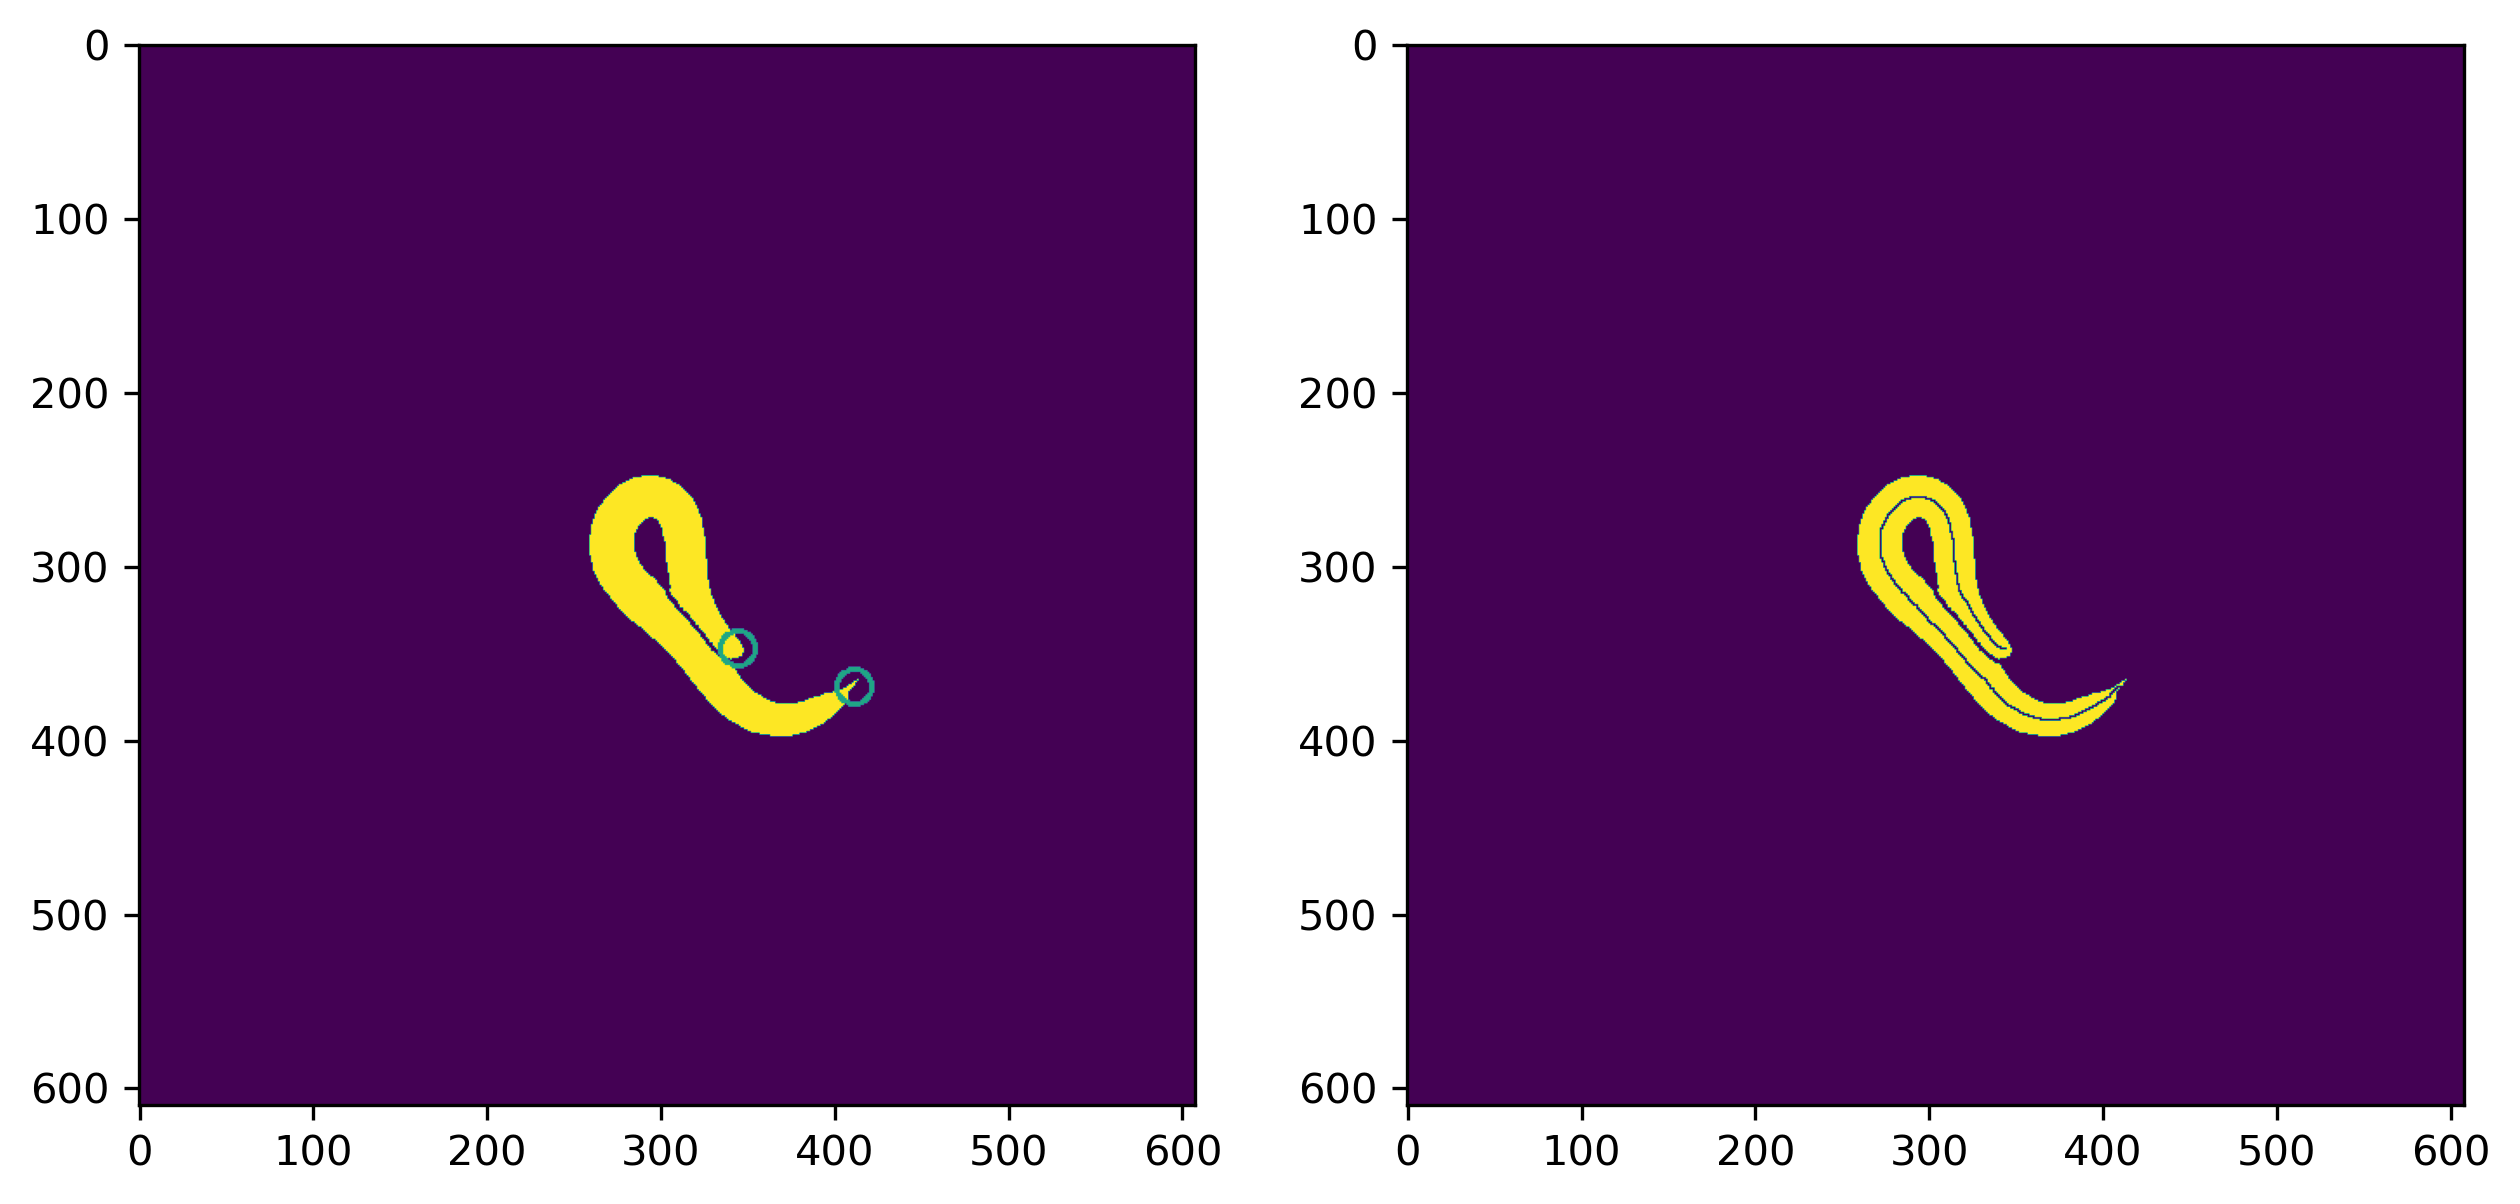

img2840.tif


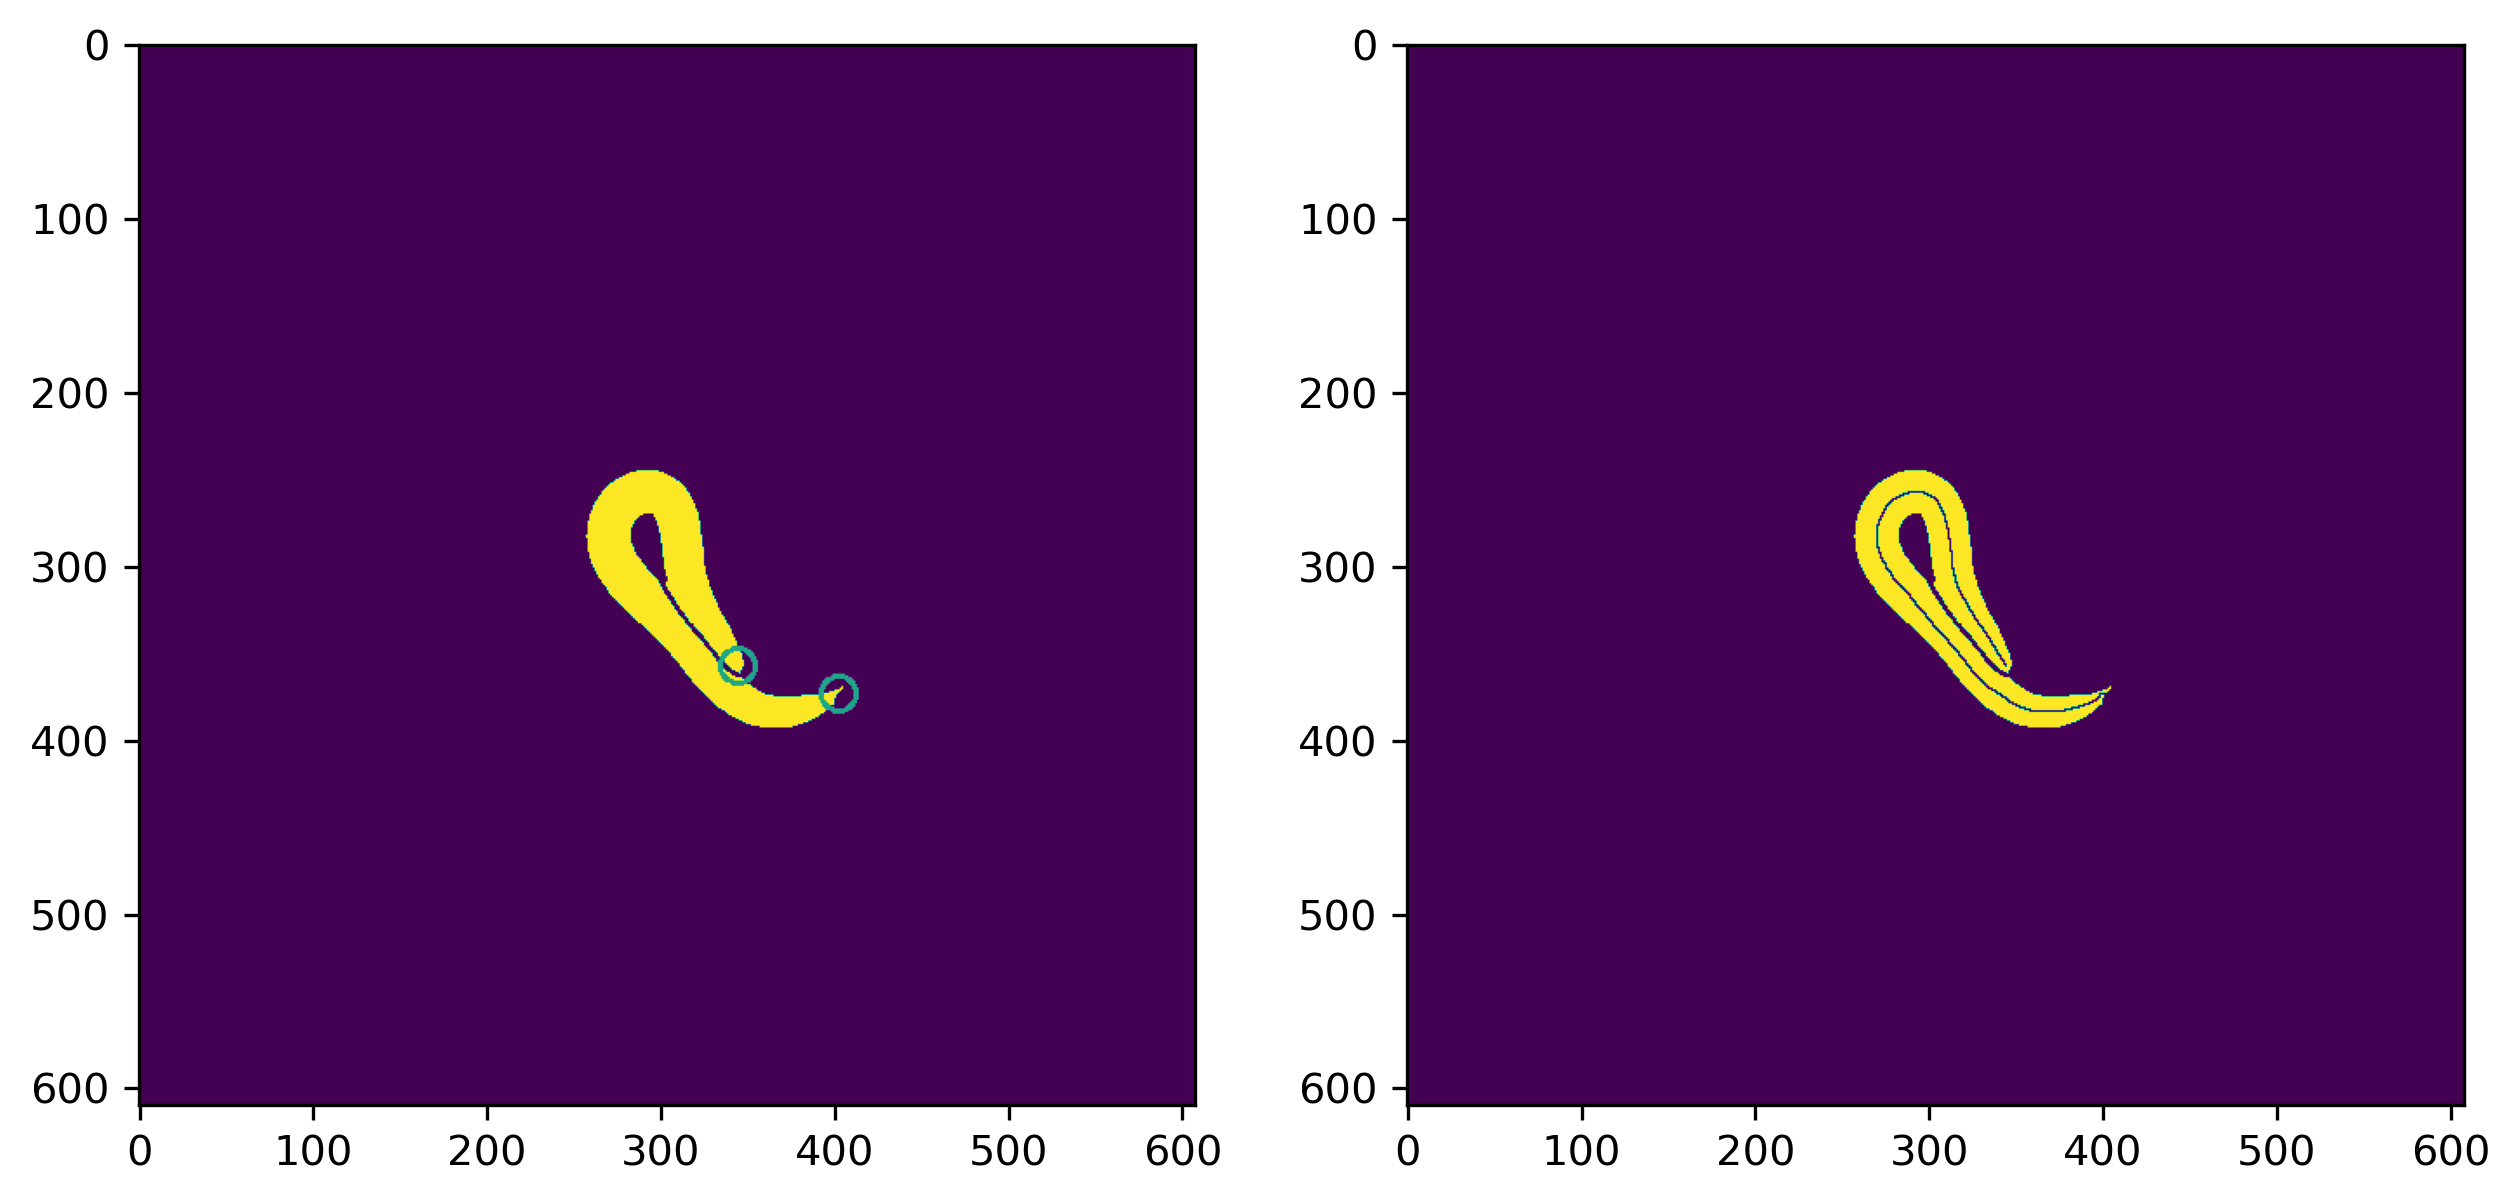

img2842.tif


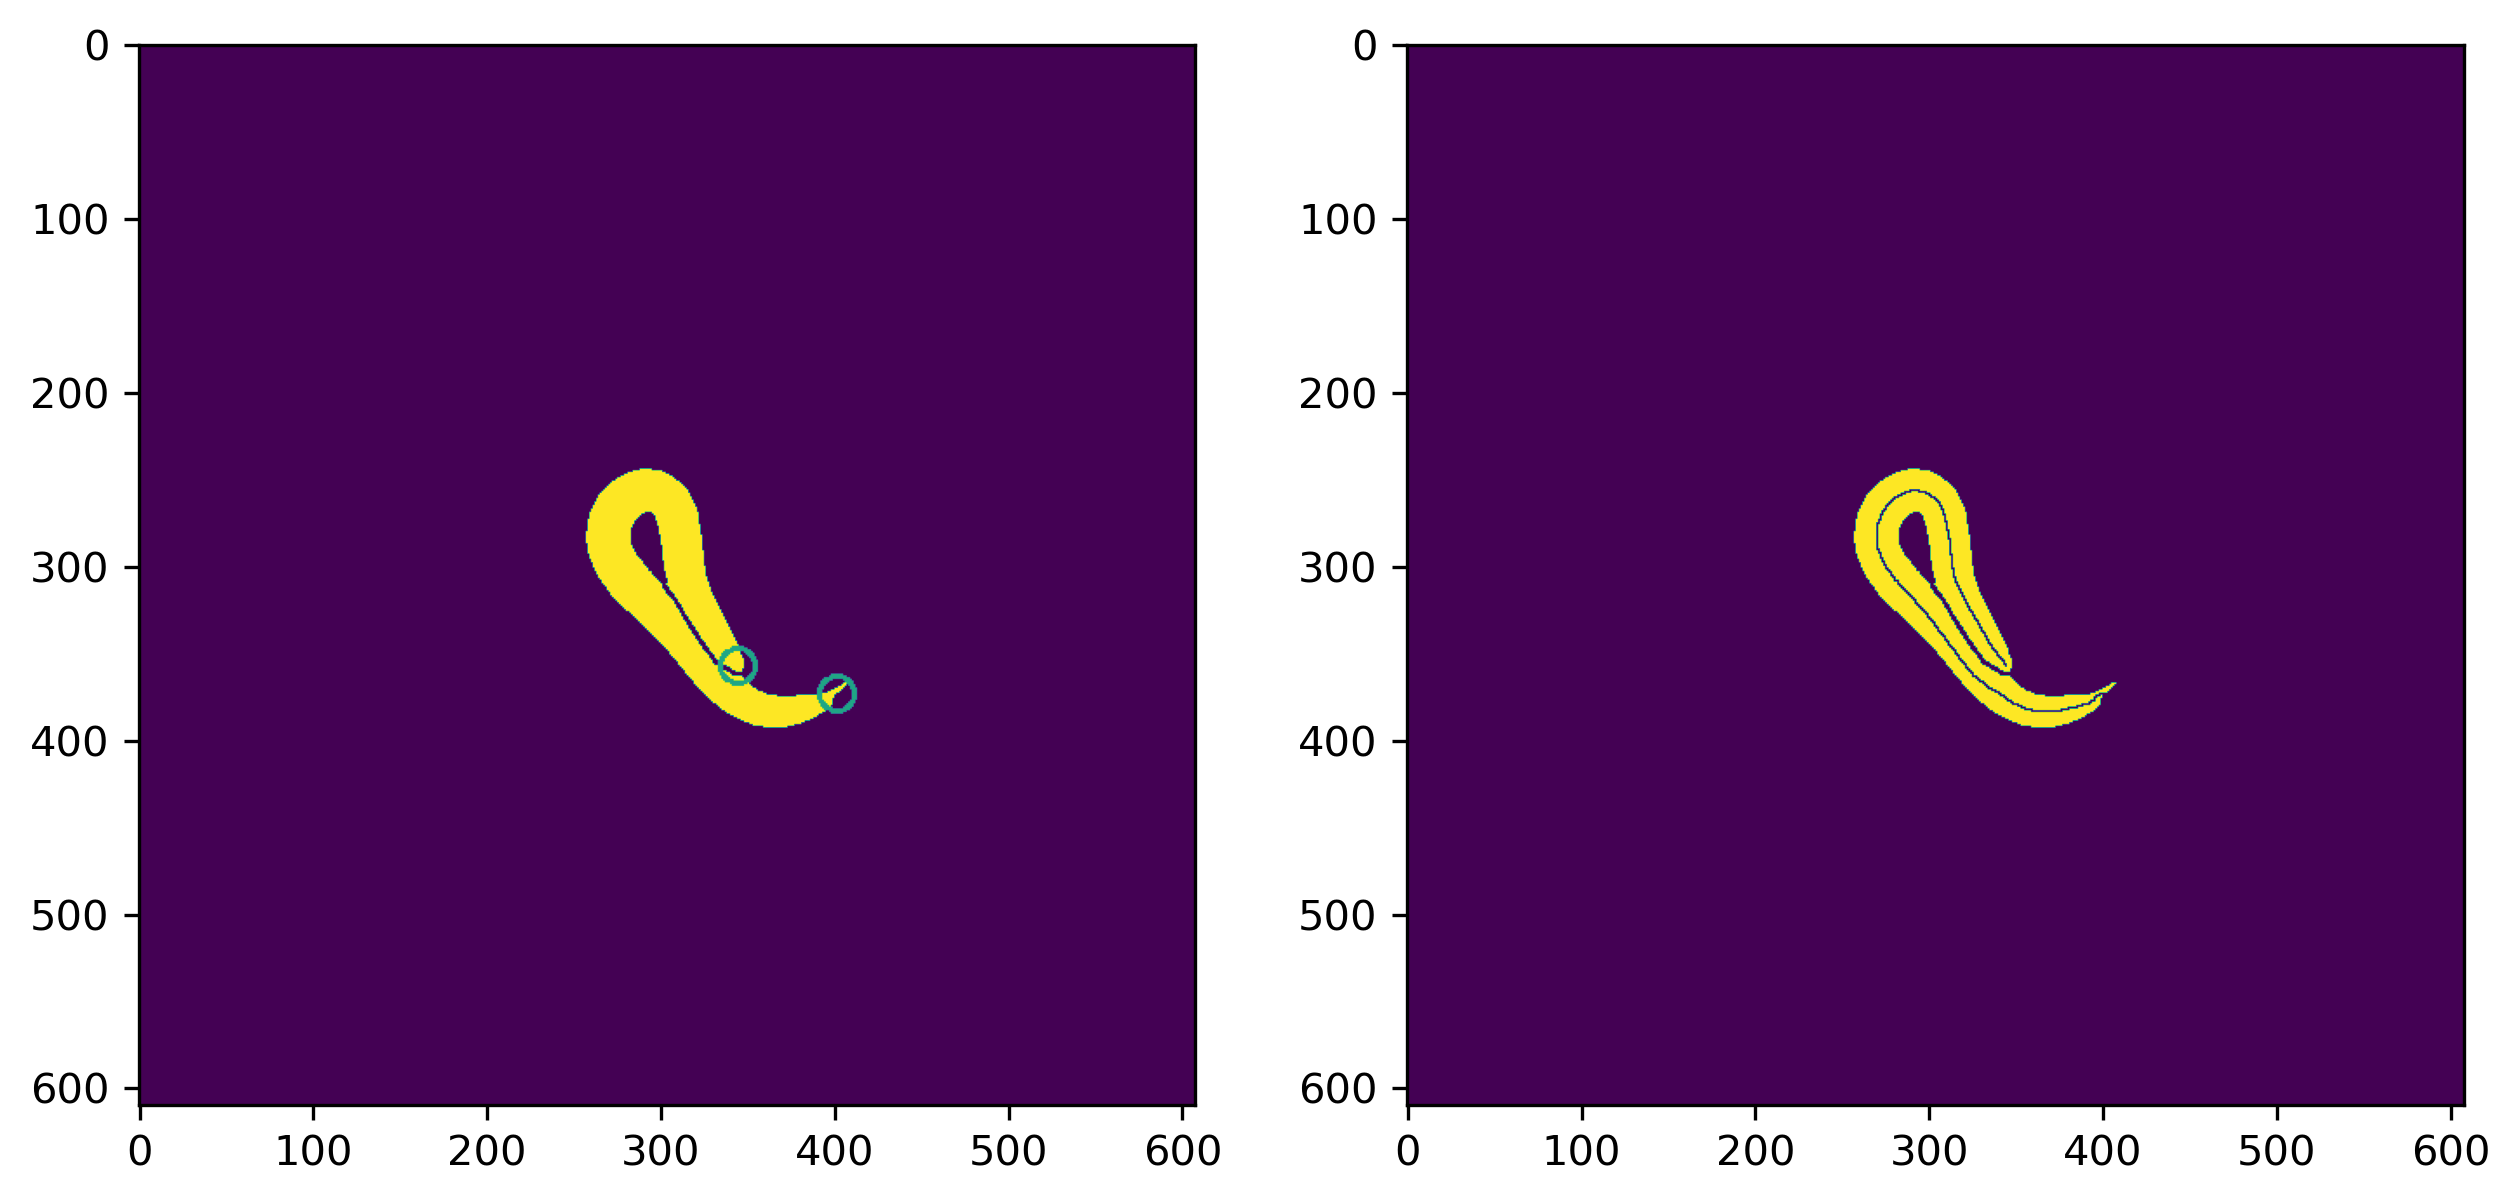

img2865.tif
head and tail were too close, no centerline could be created
img2889.tif
head and tail were too close, no centerline could be created
img2906.tif


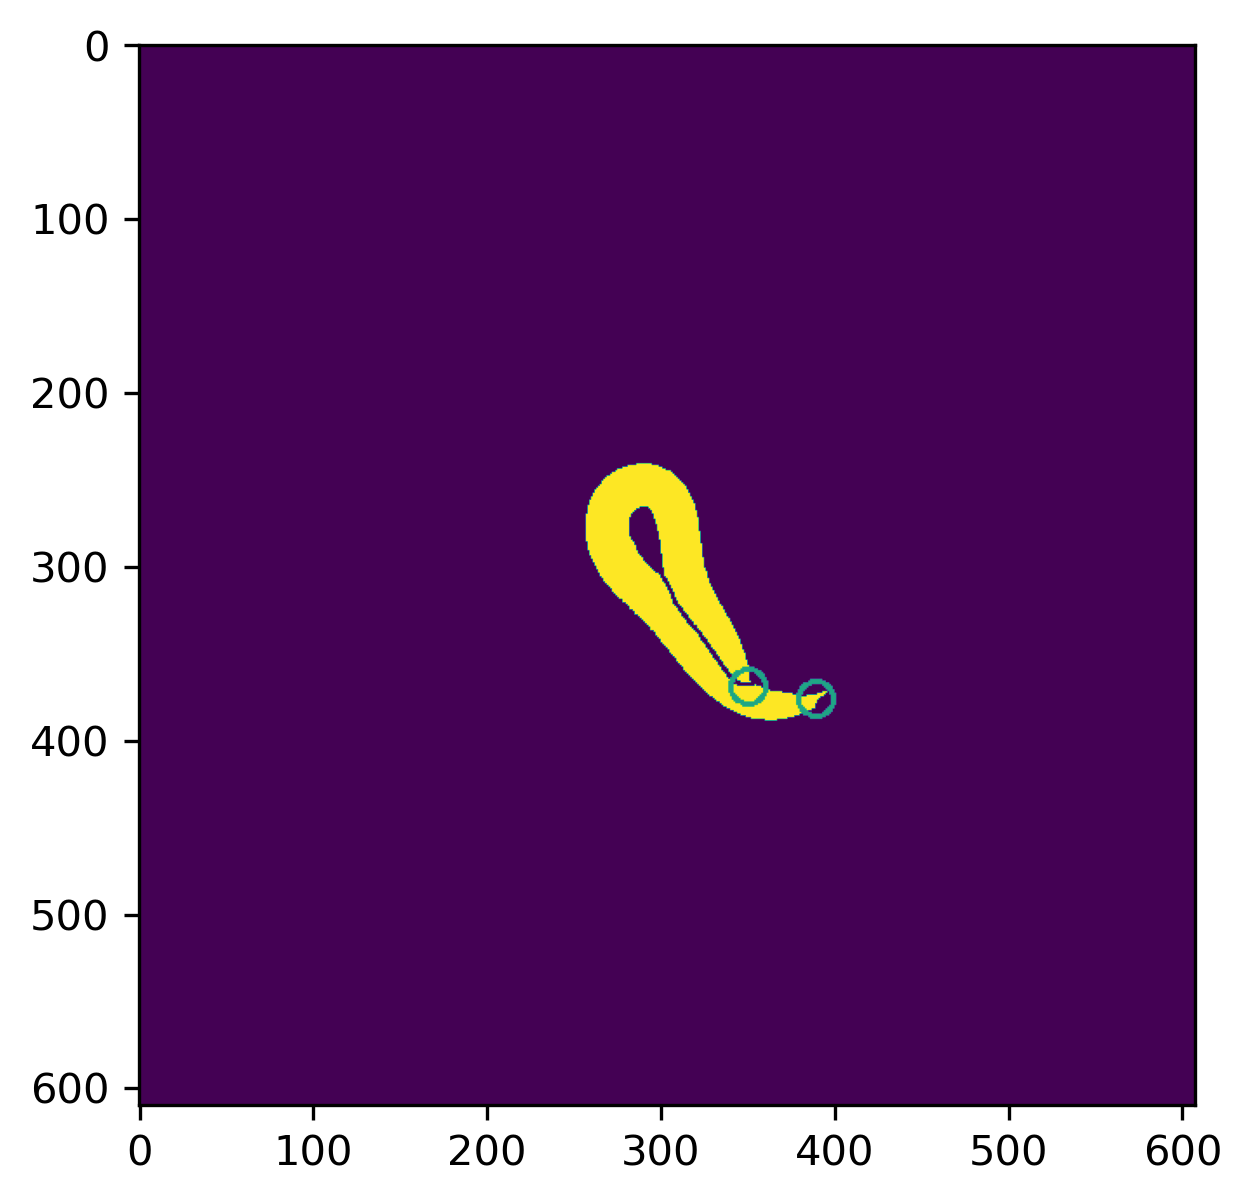

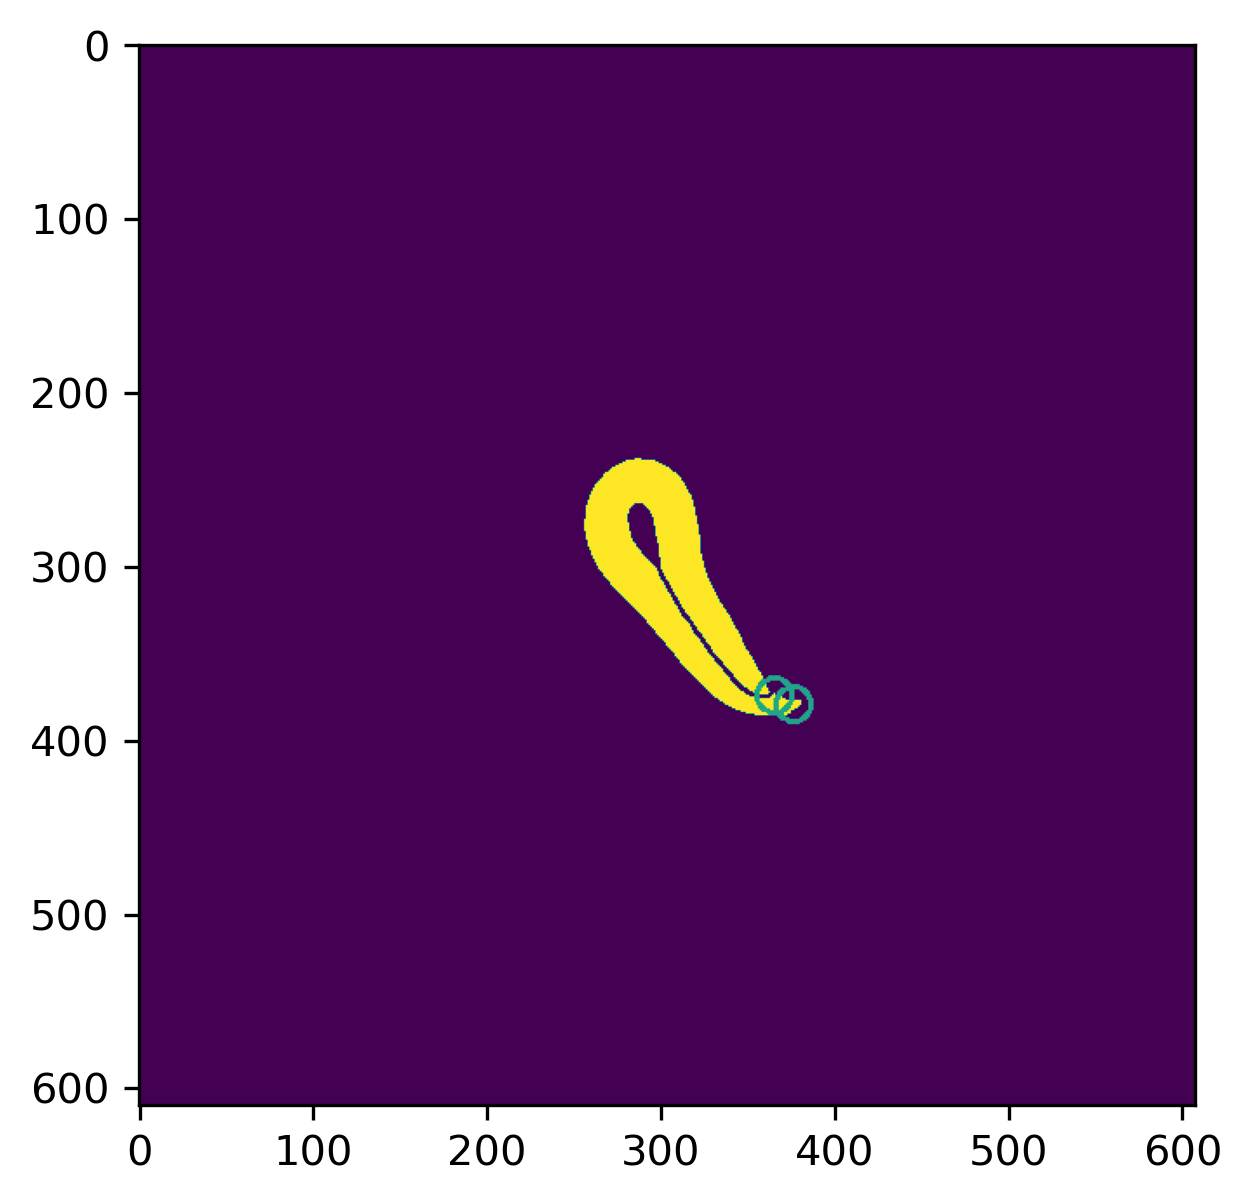

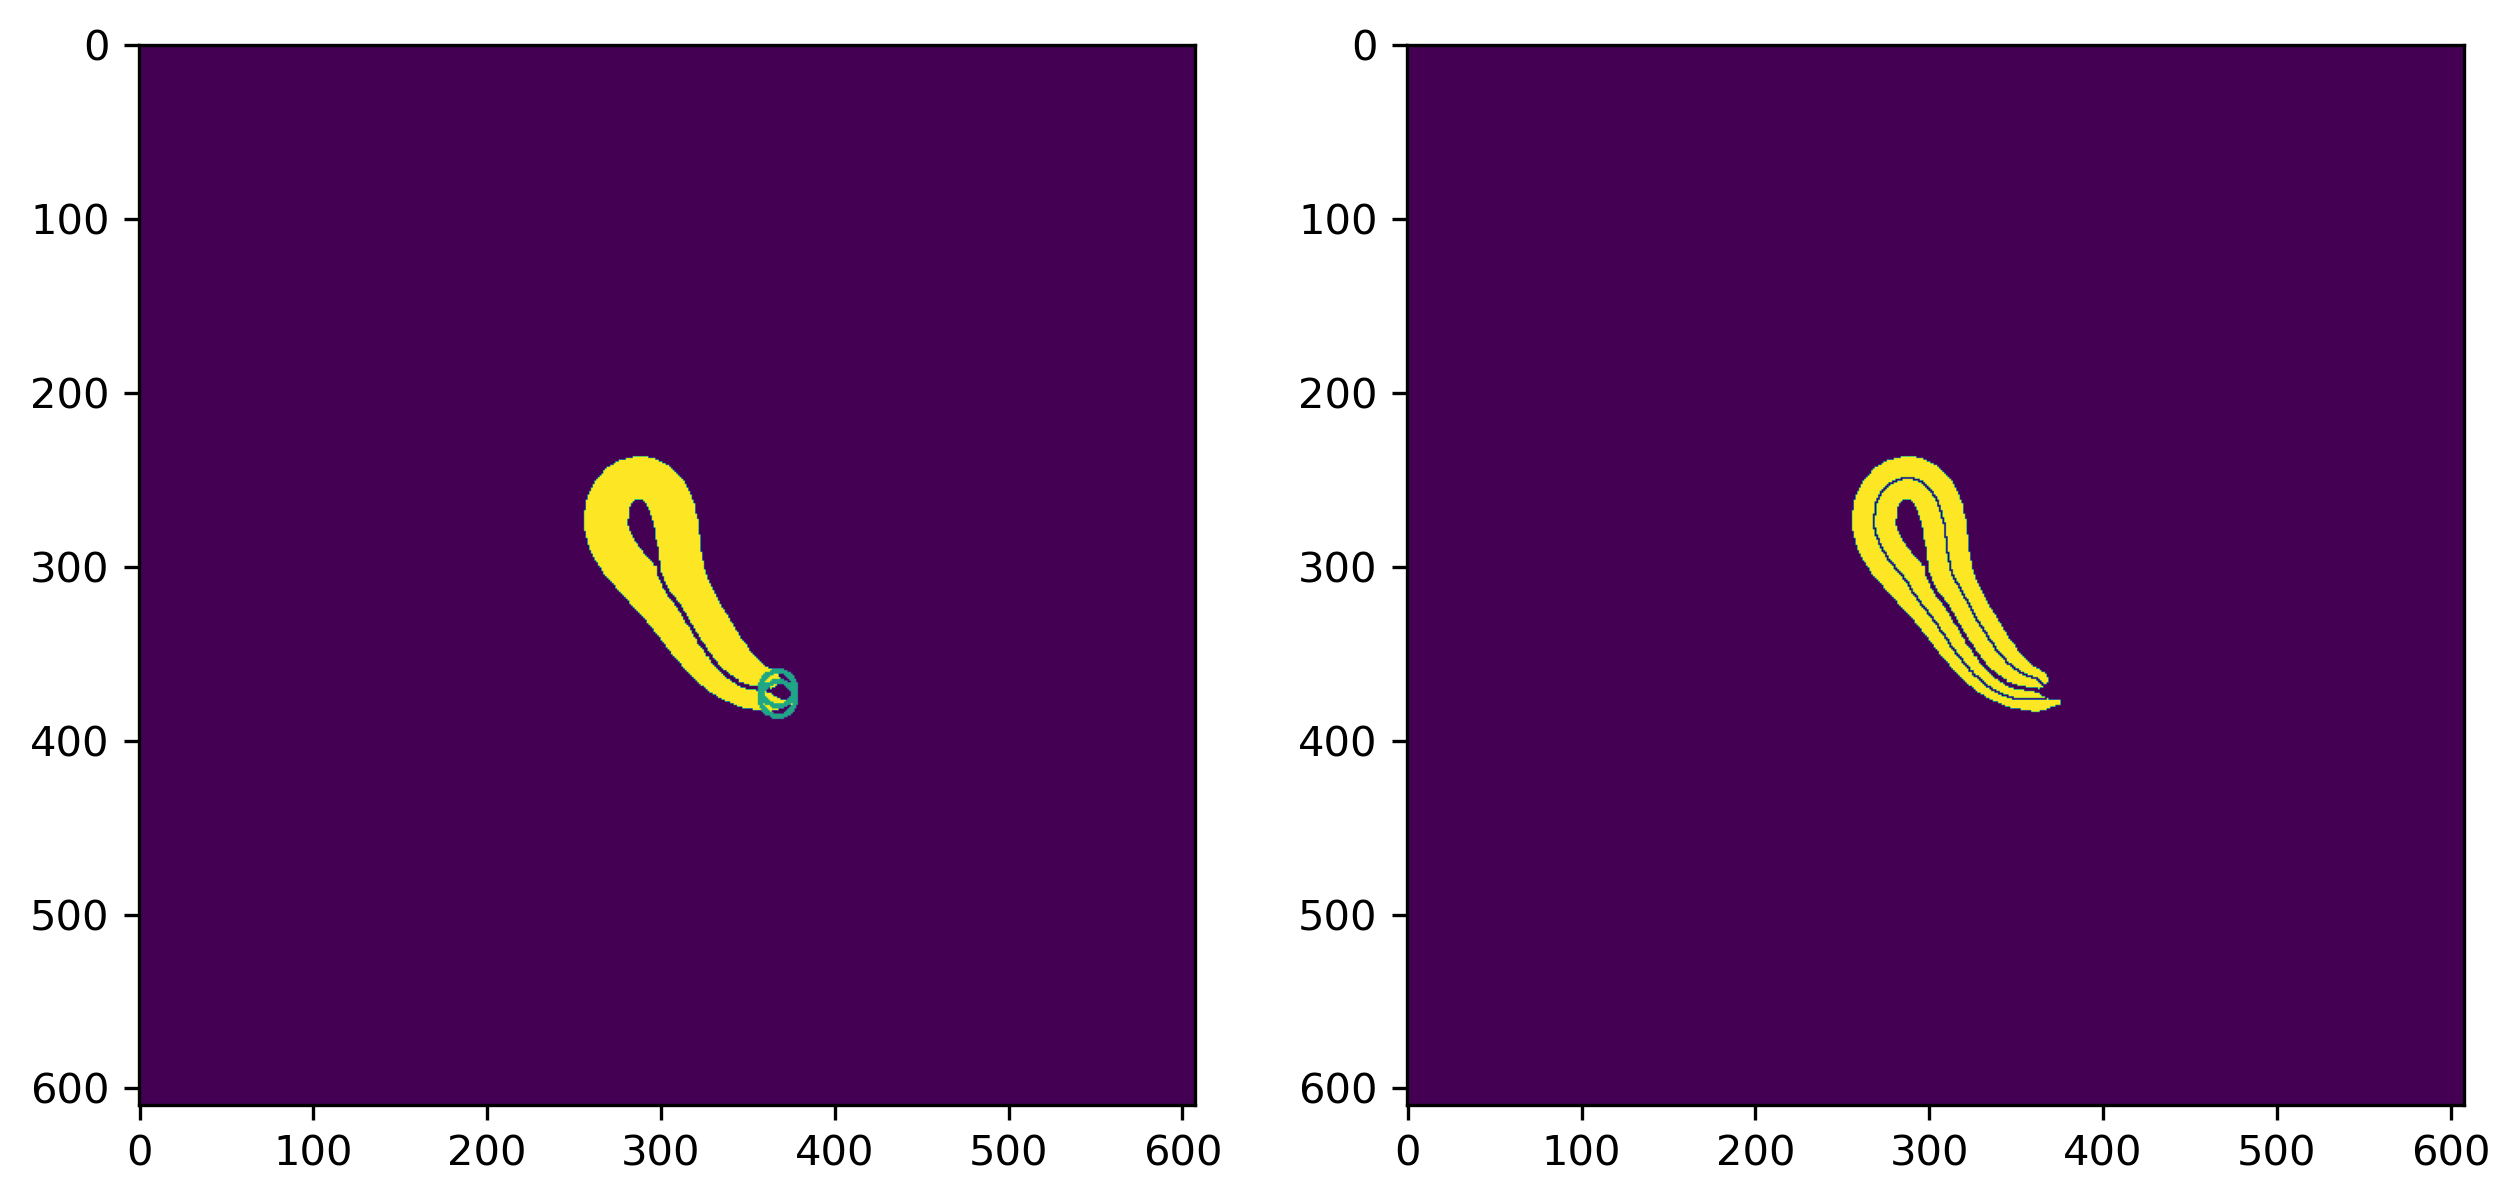

img2924.tif
head and tail were too close, no centerline could be created
img2948.tif
head and tail were too close, no centerline could be created
img2970.tif


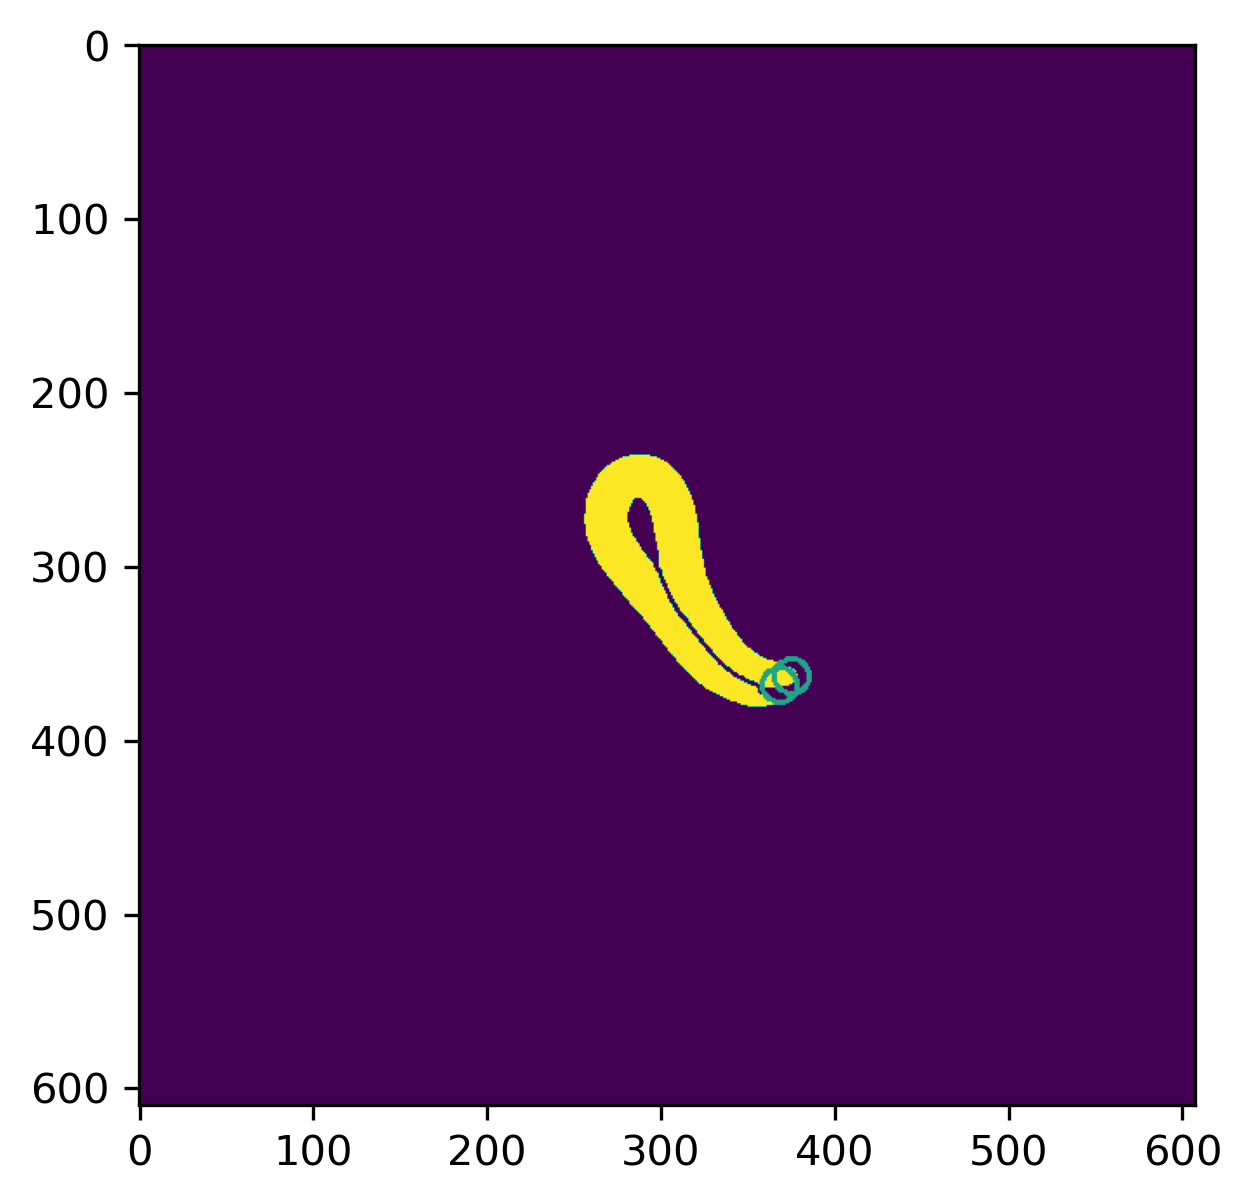

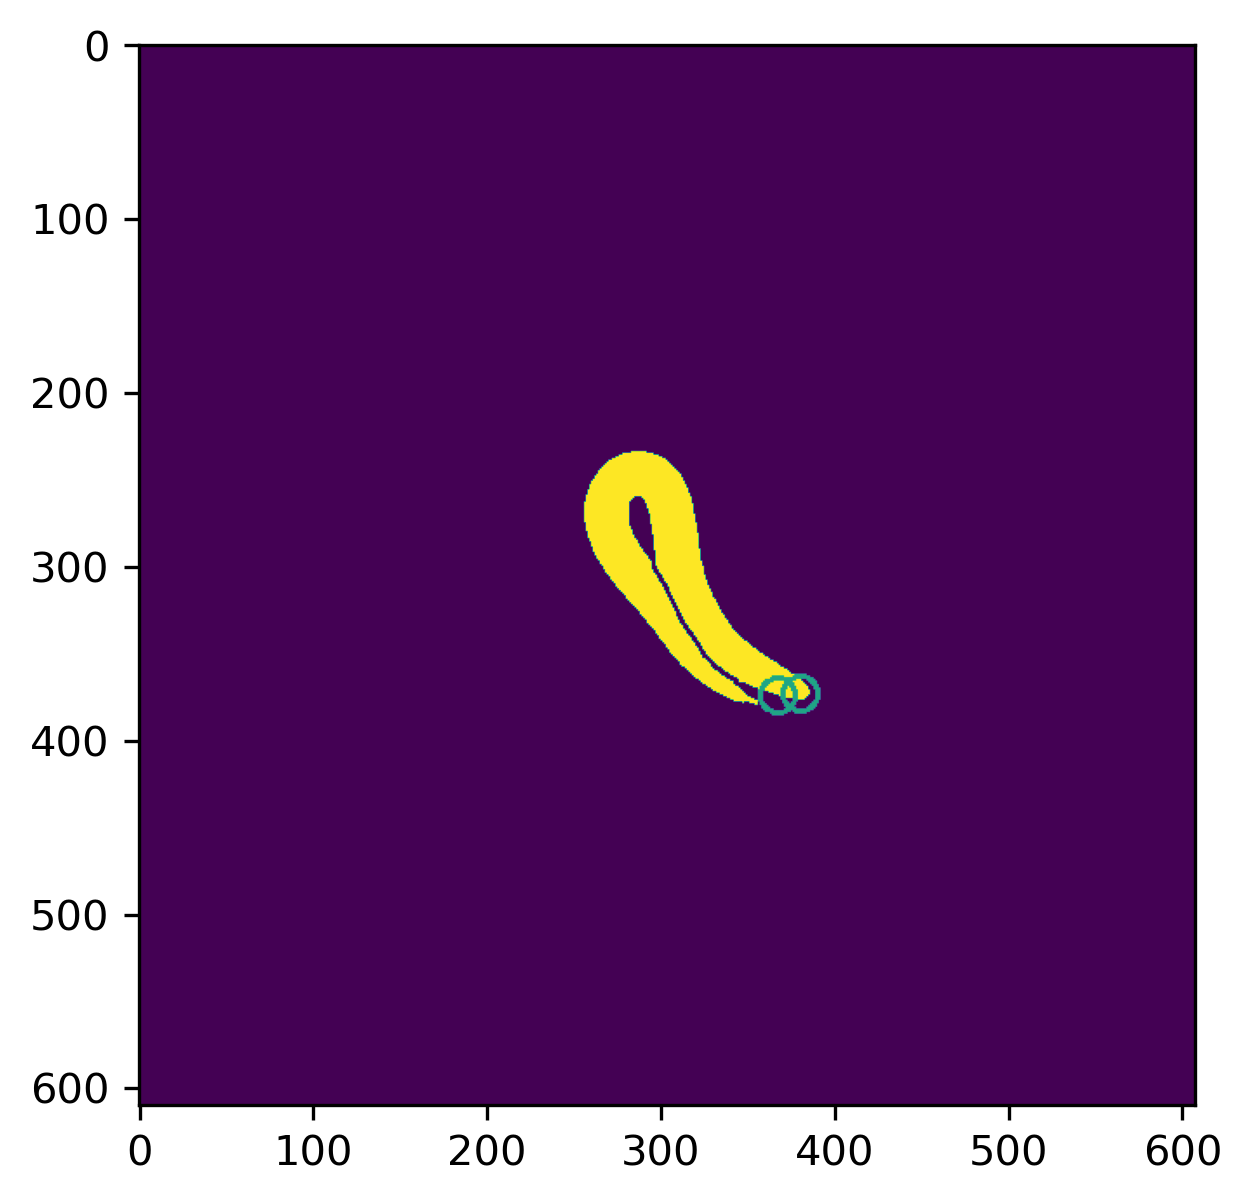

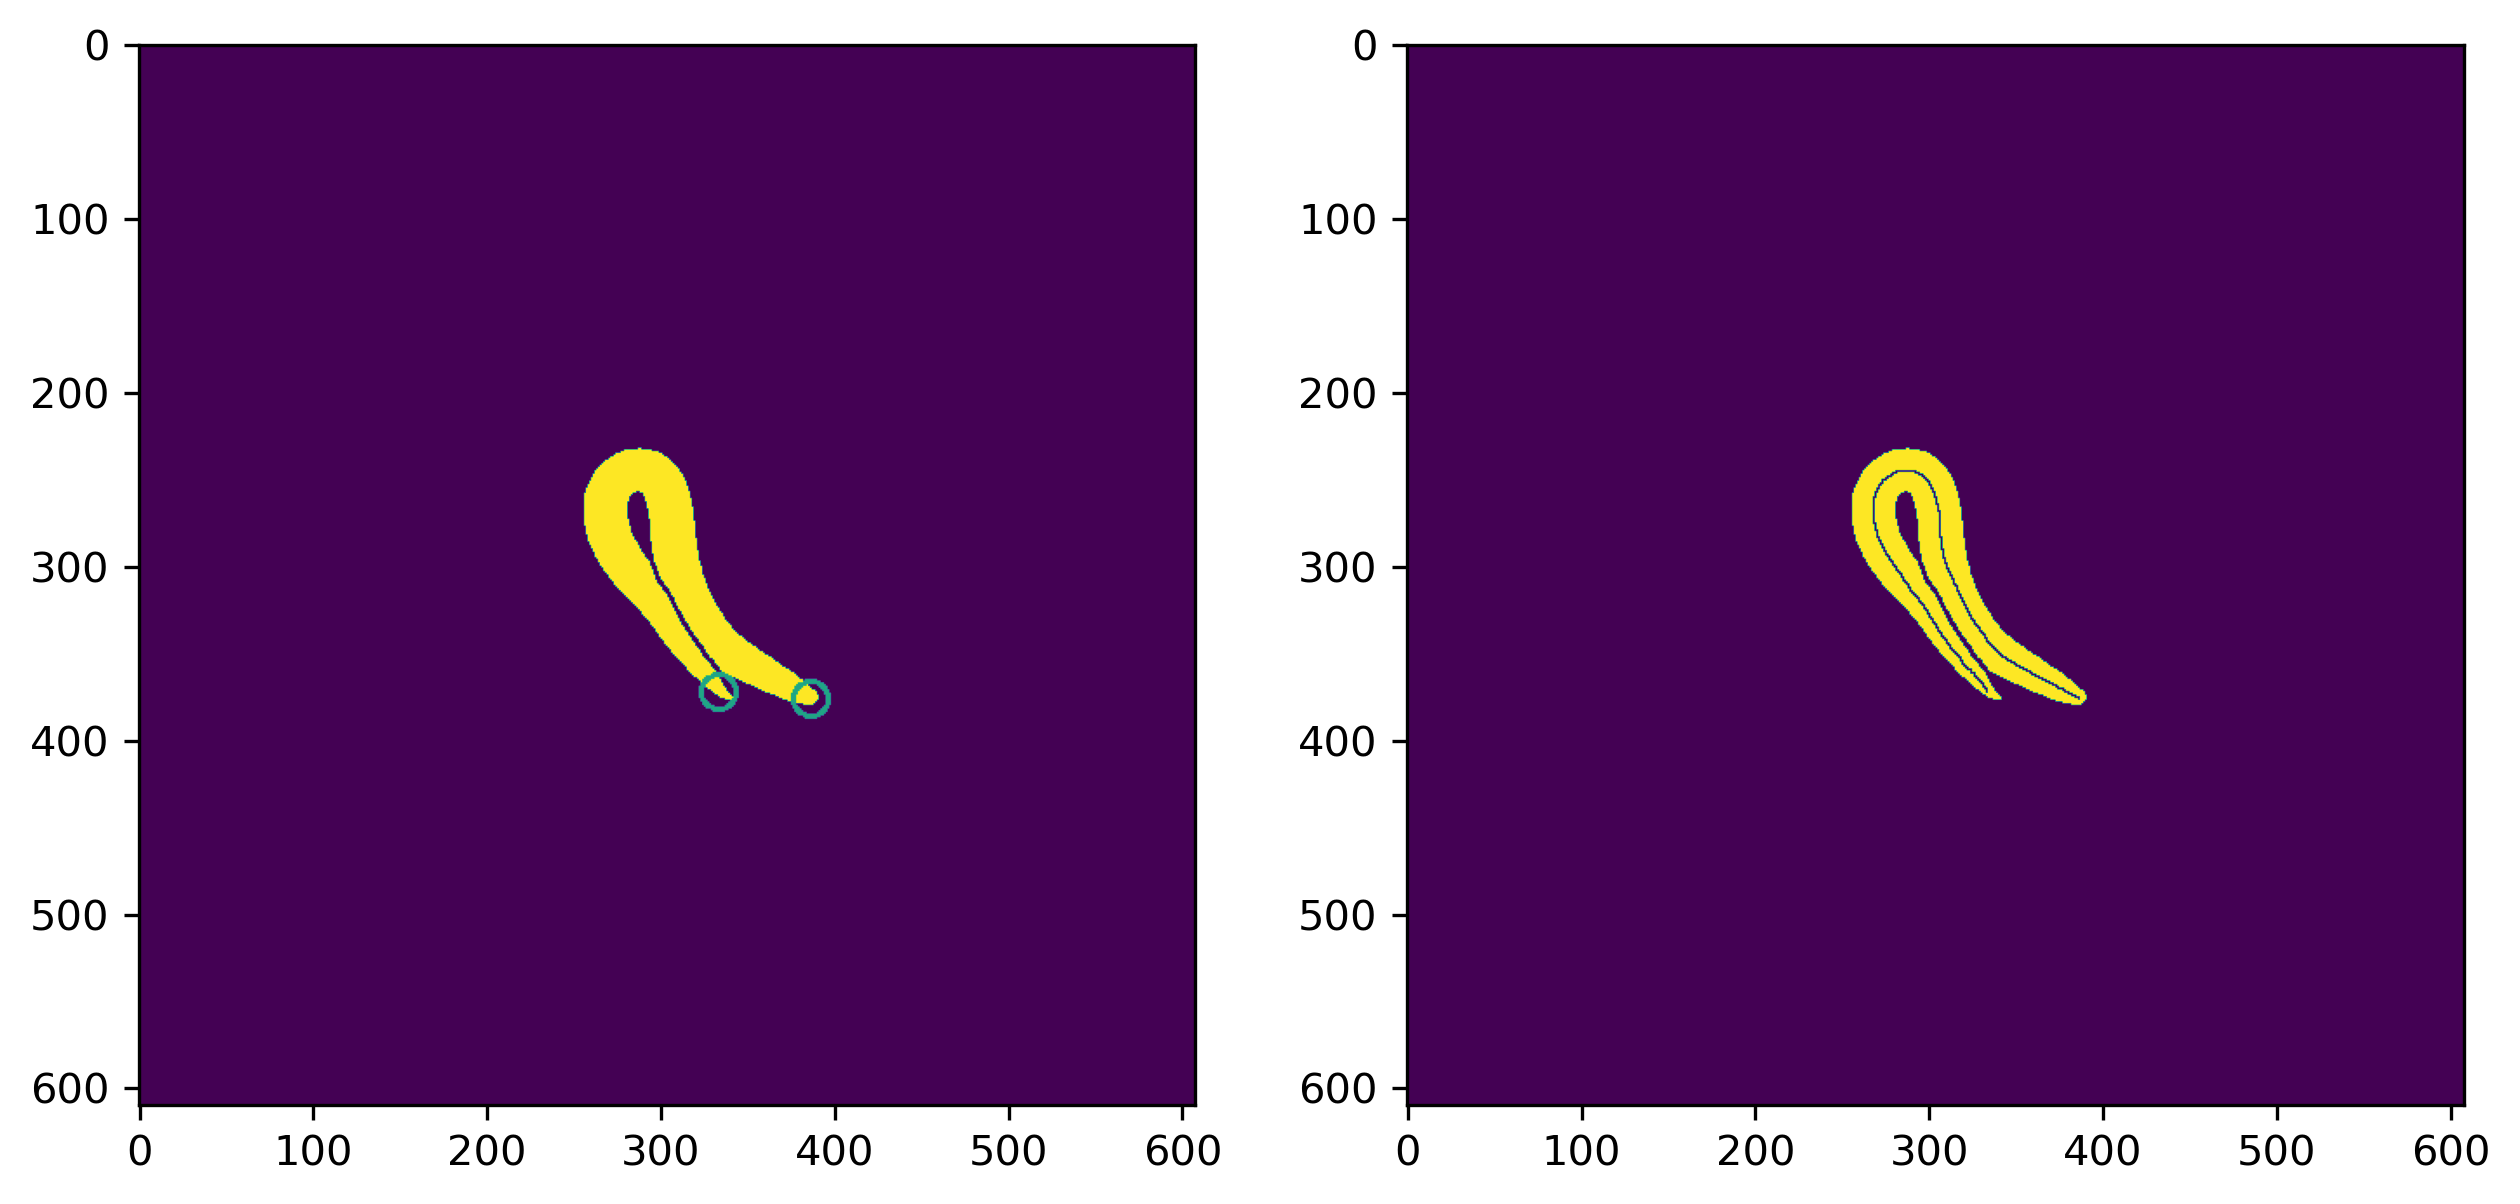

img3017.tif


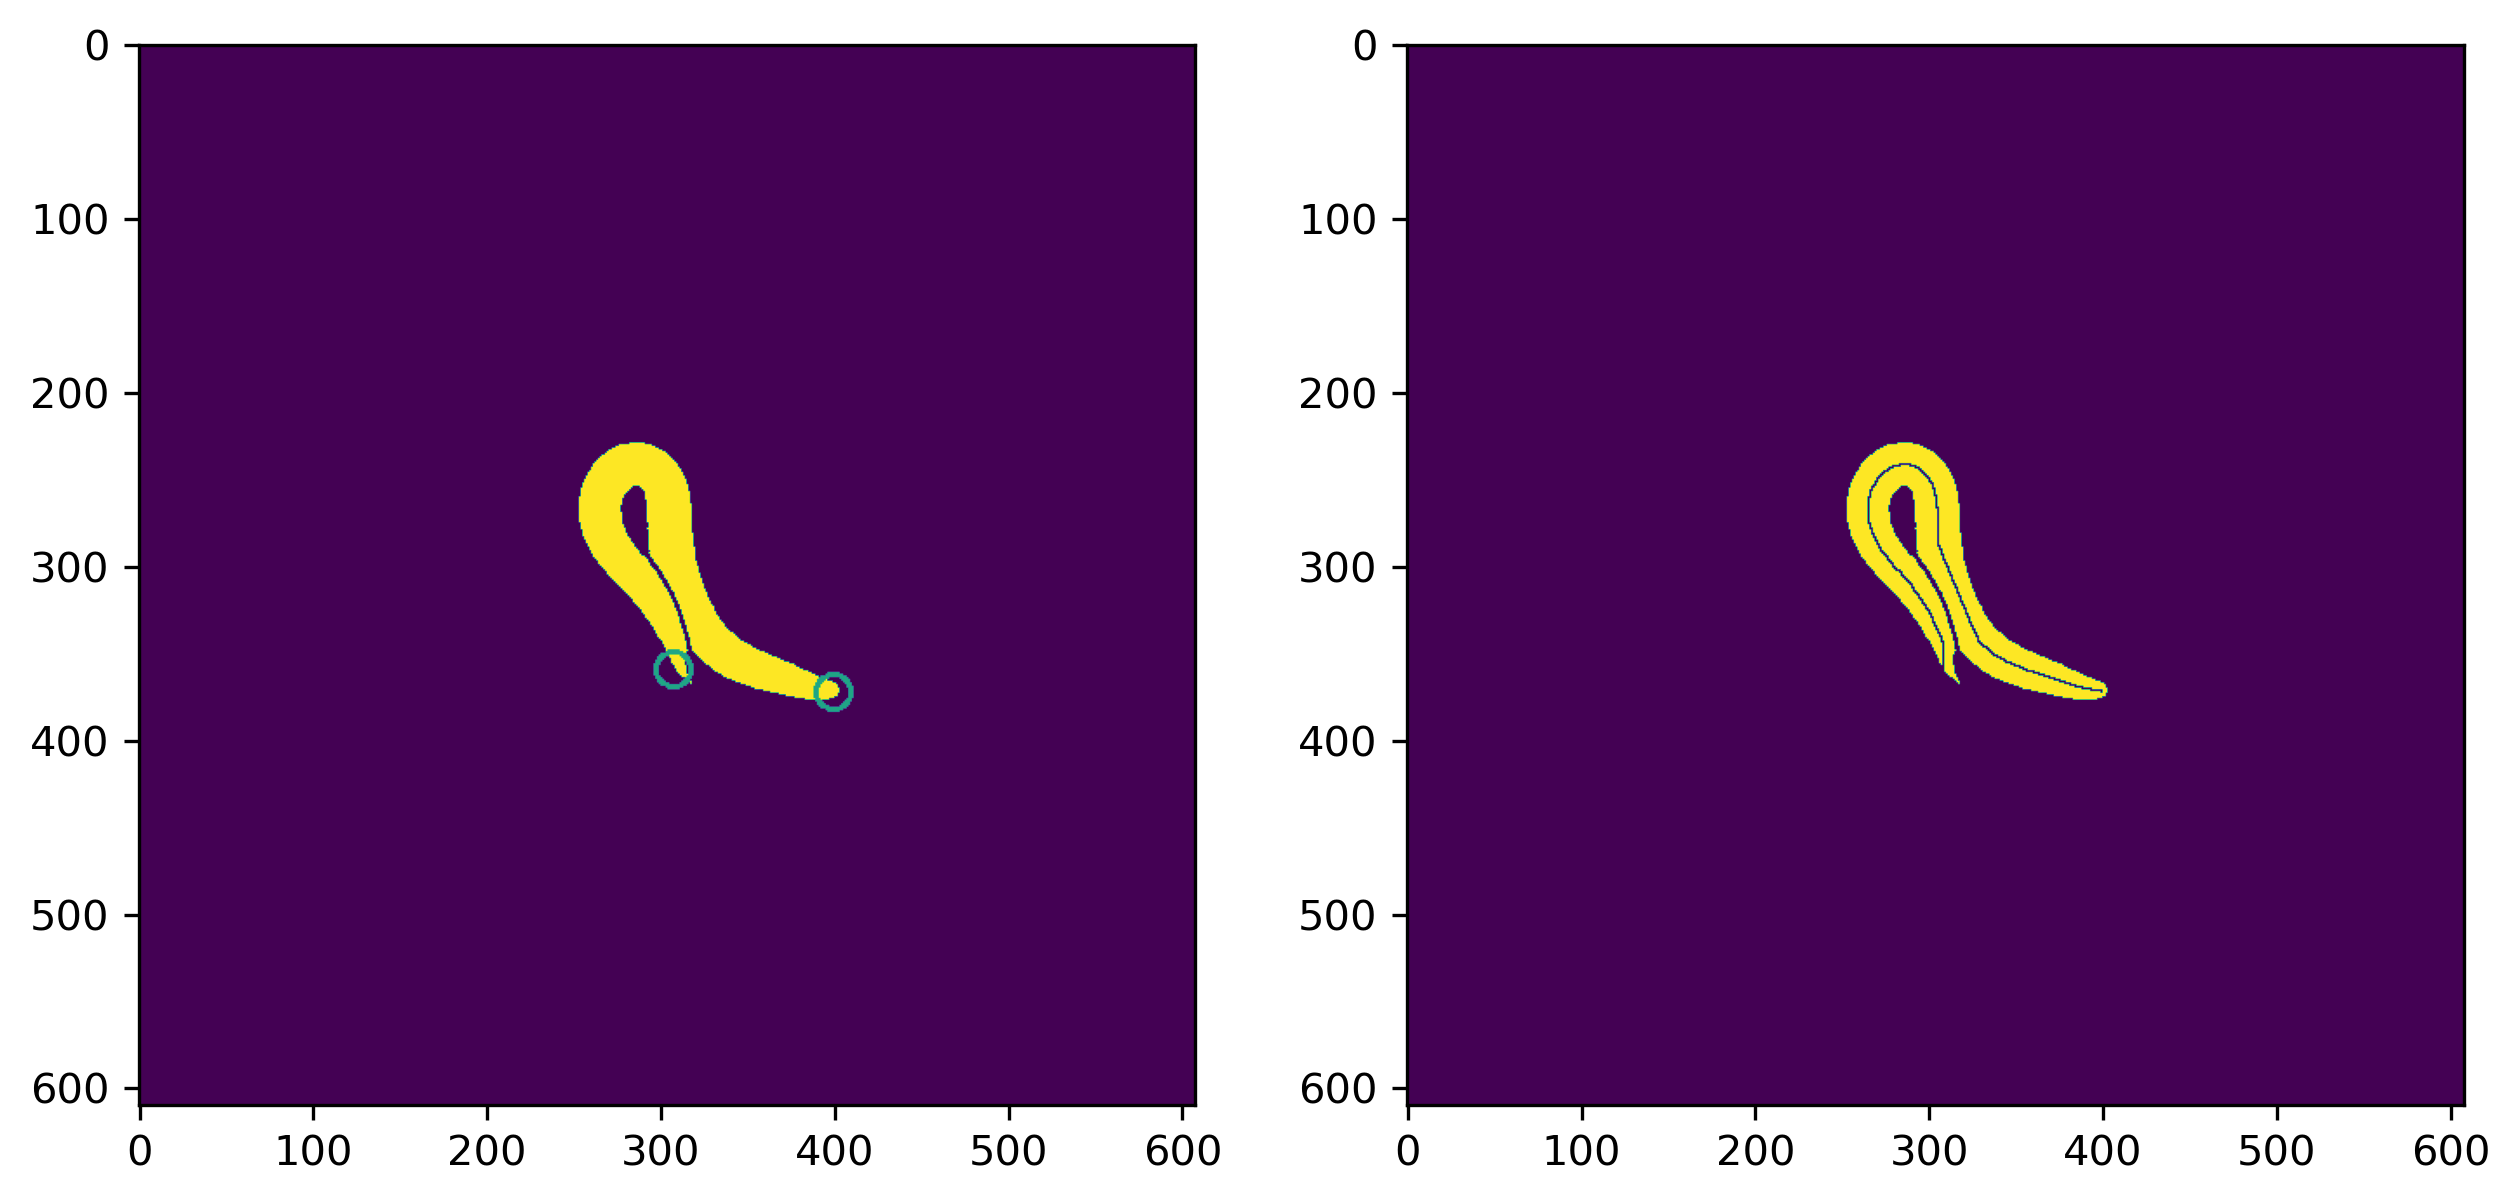

img3072.tif


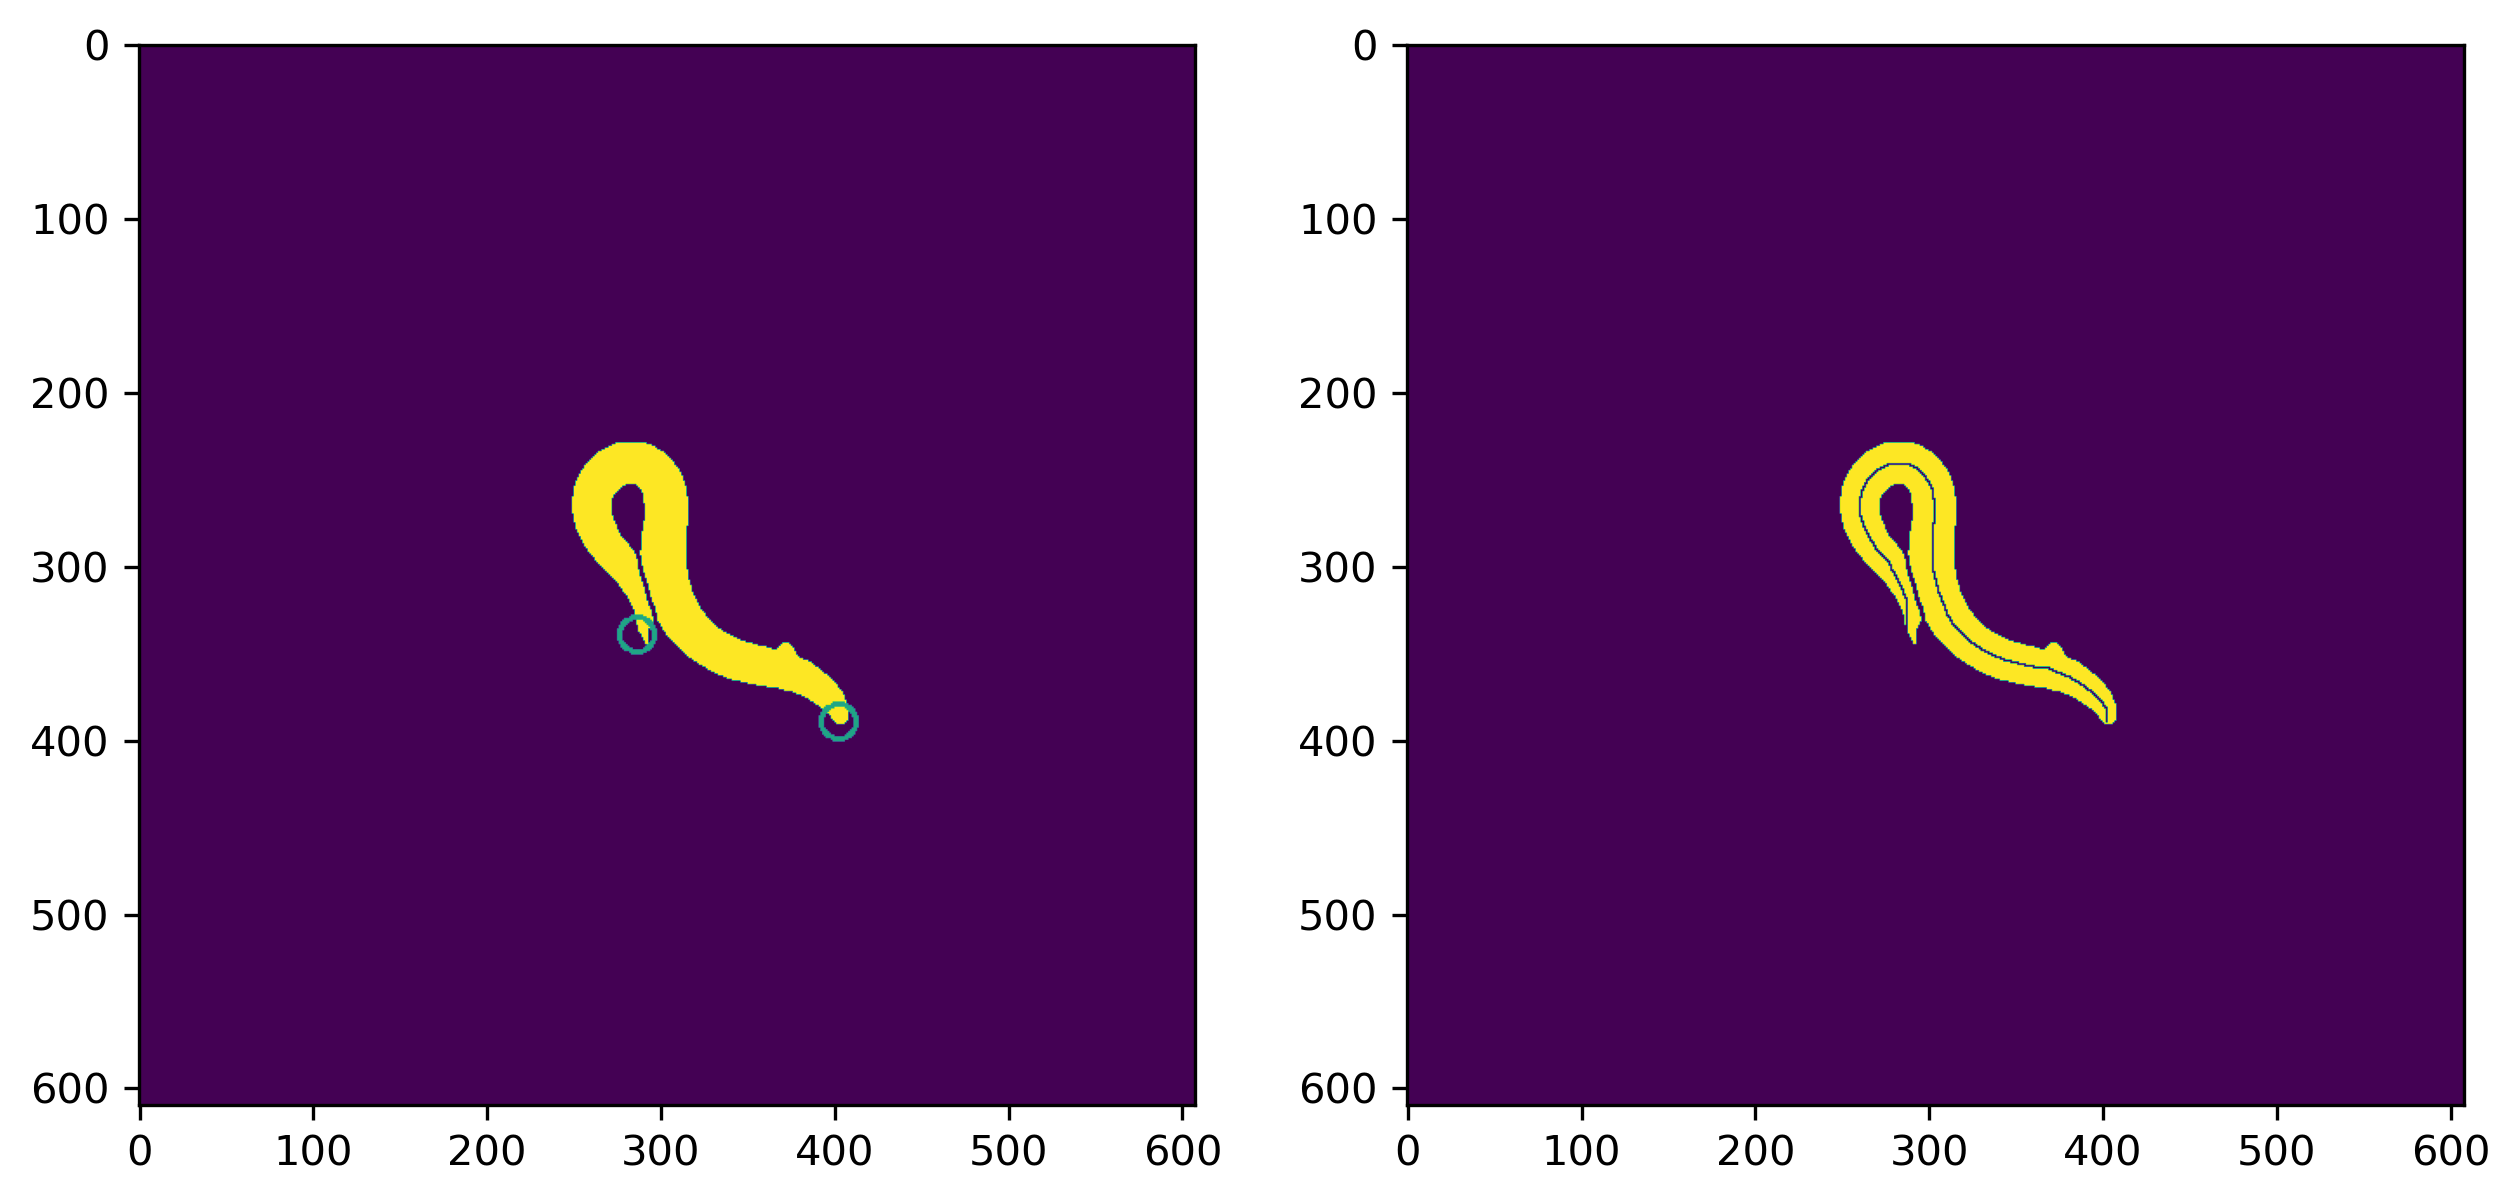

img3110.tif


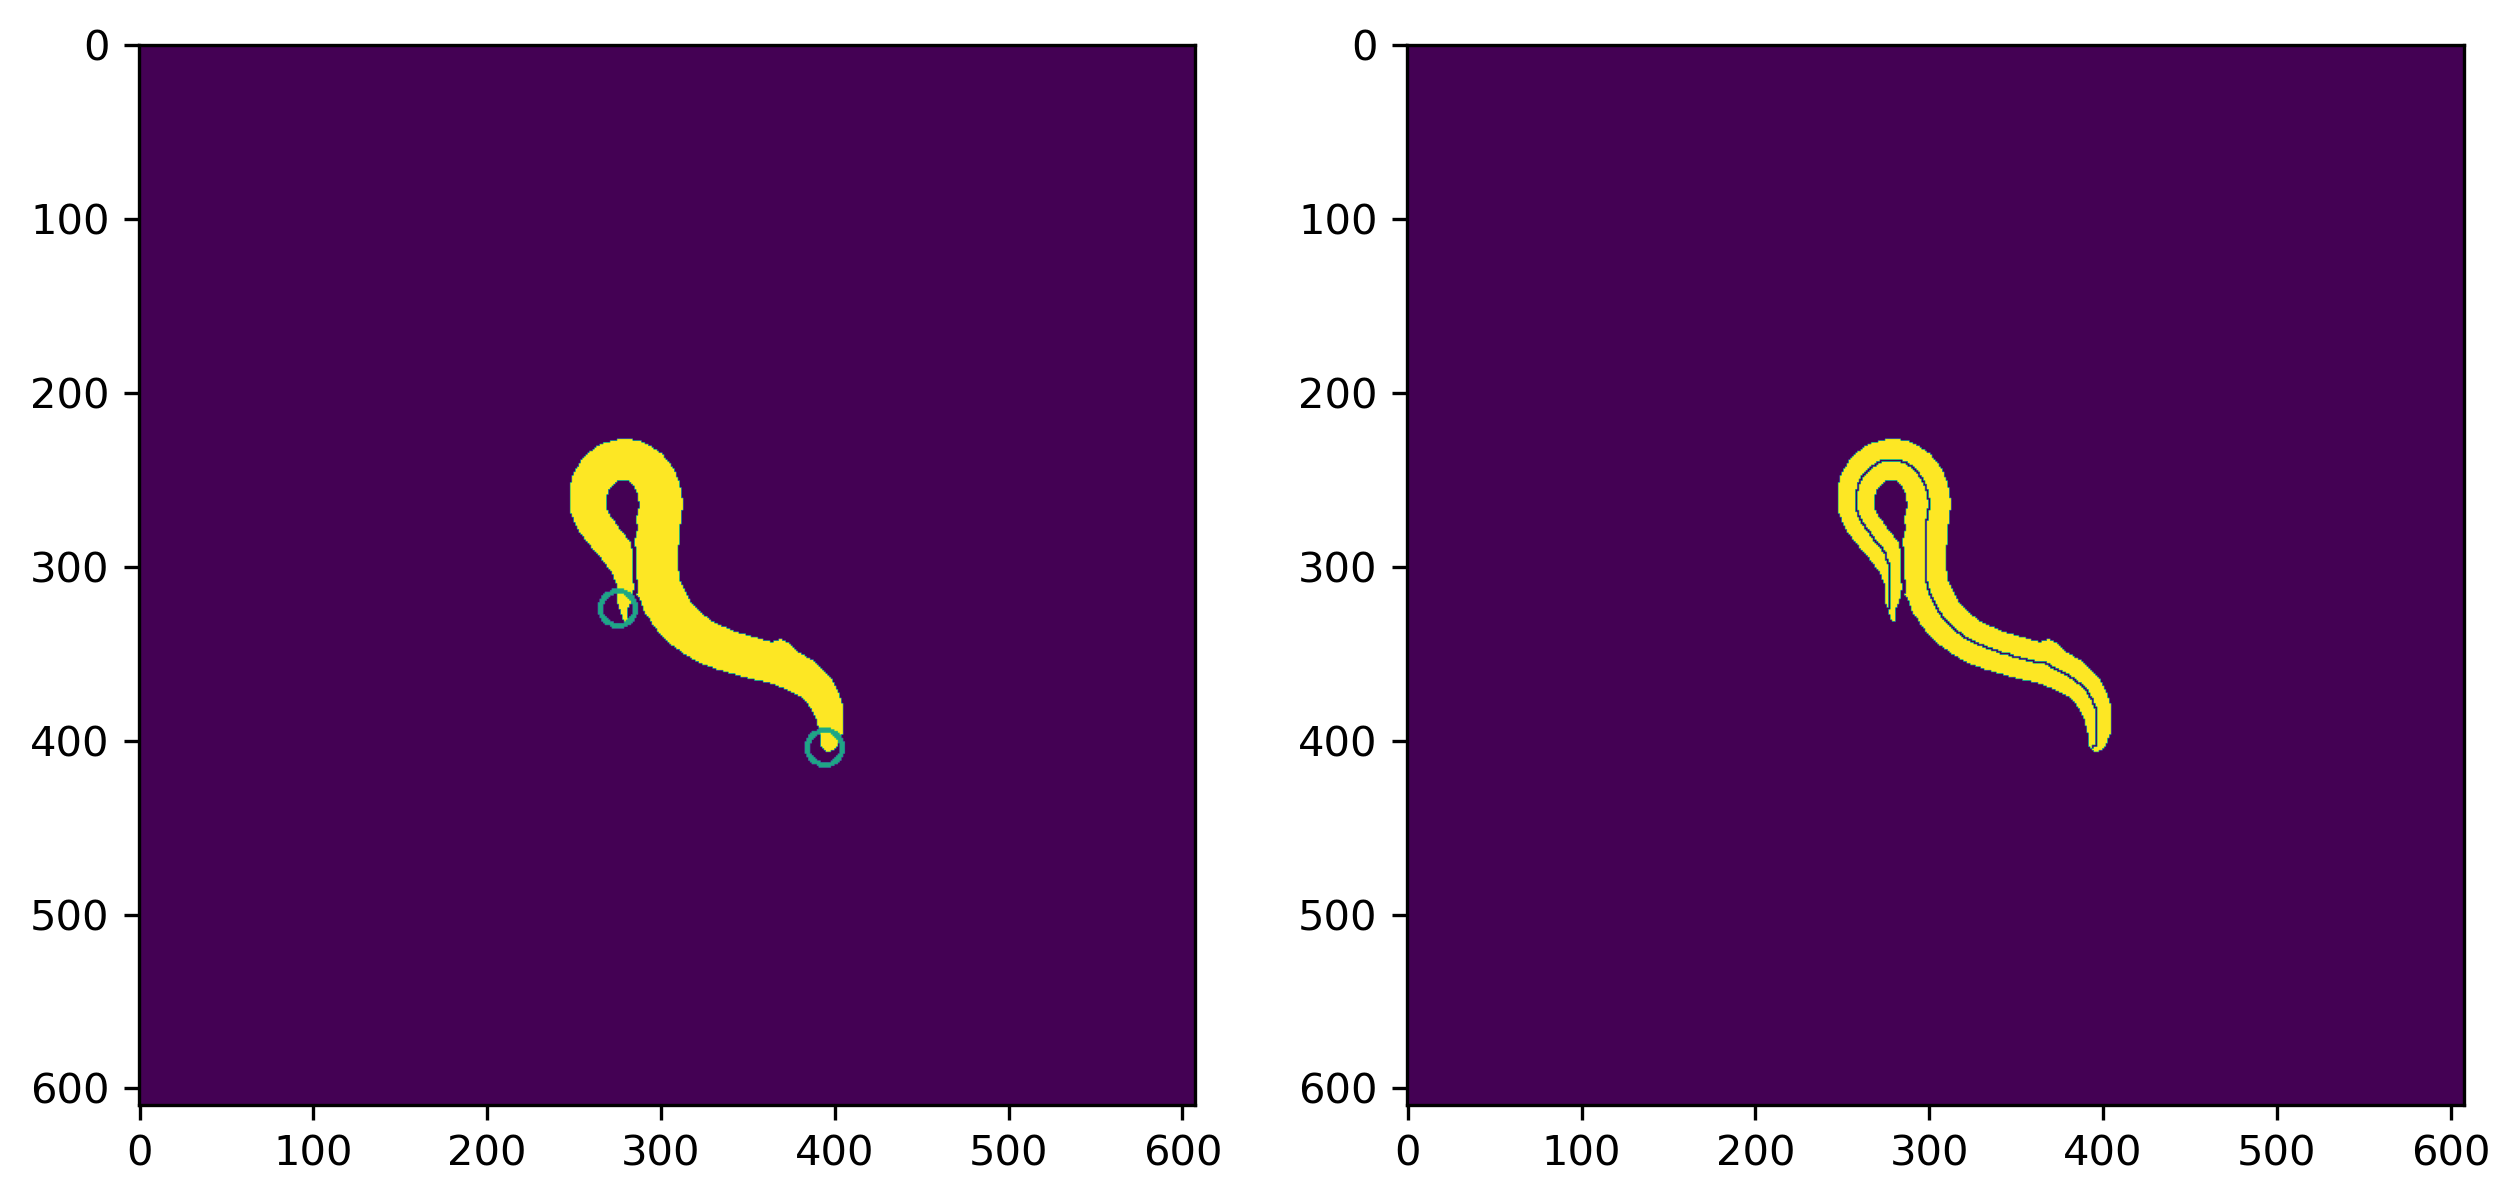

img3128.tif


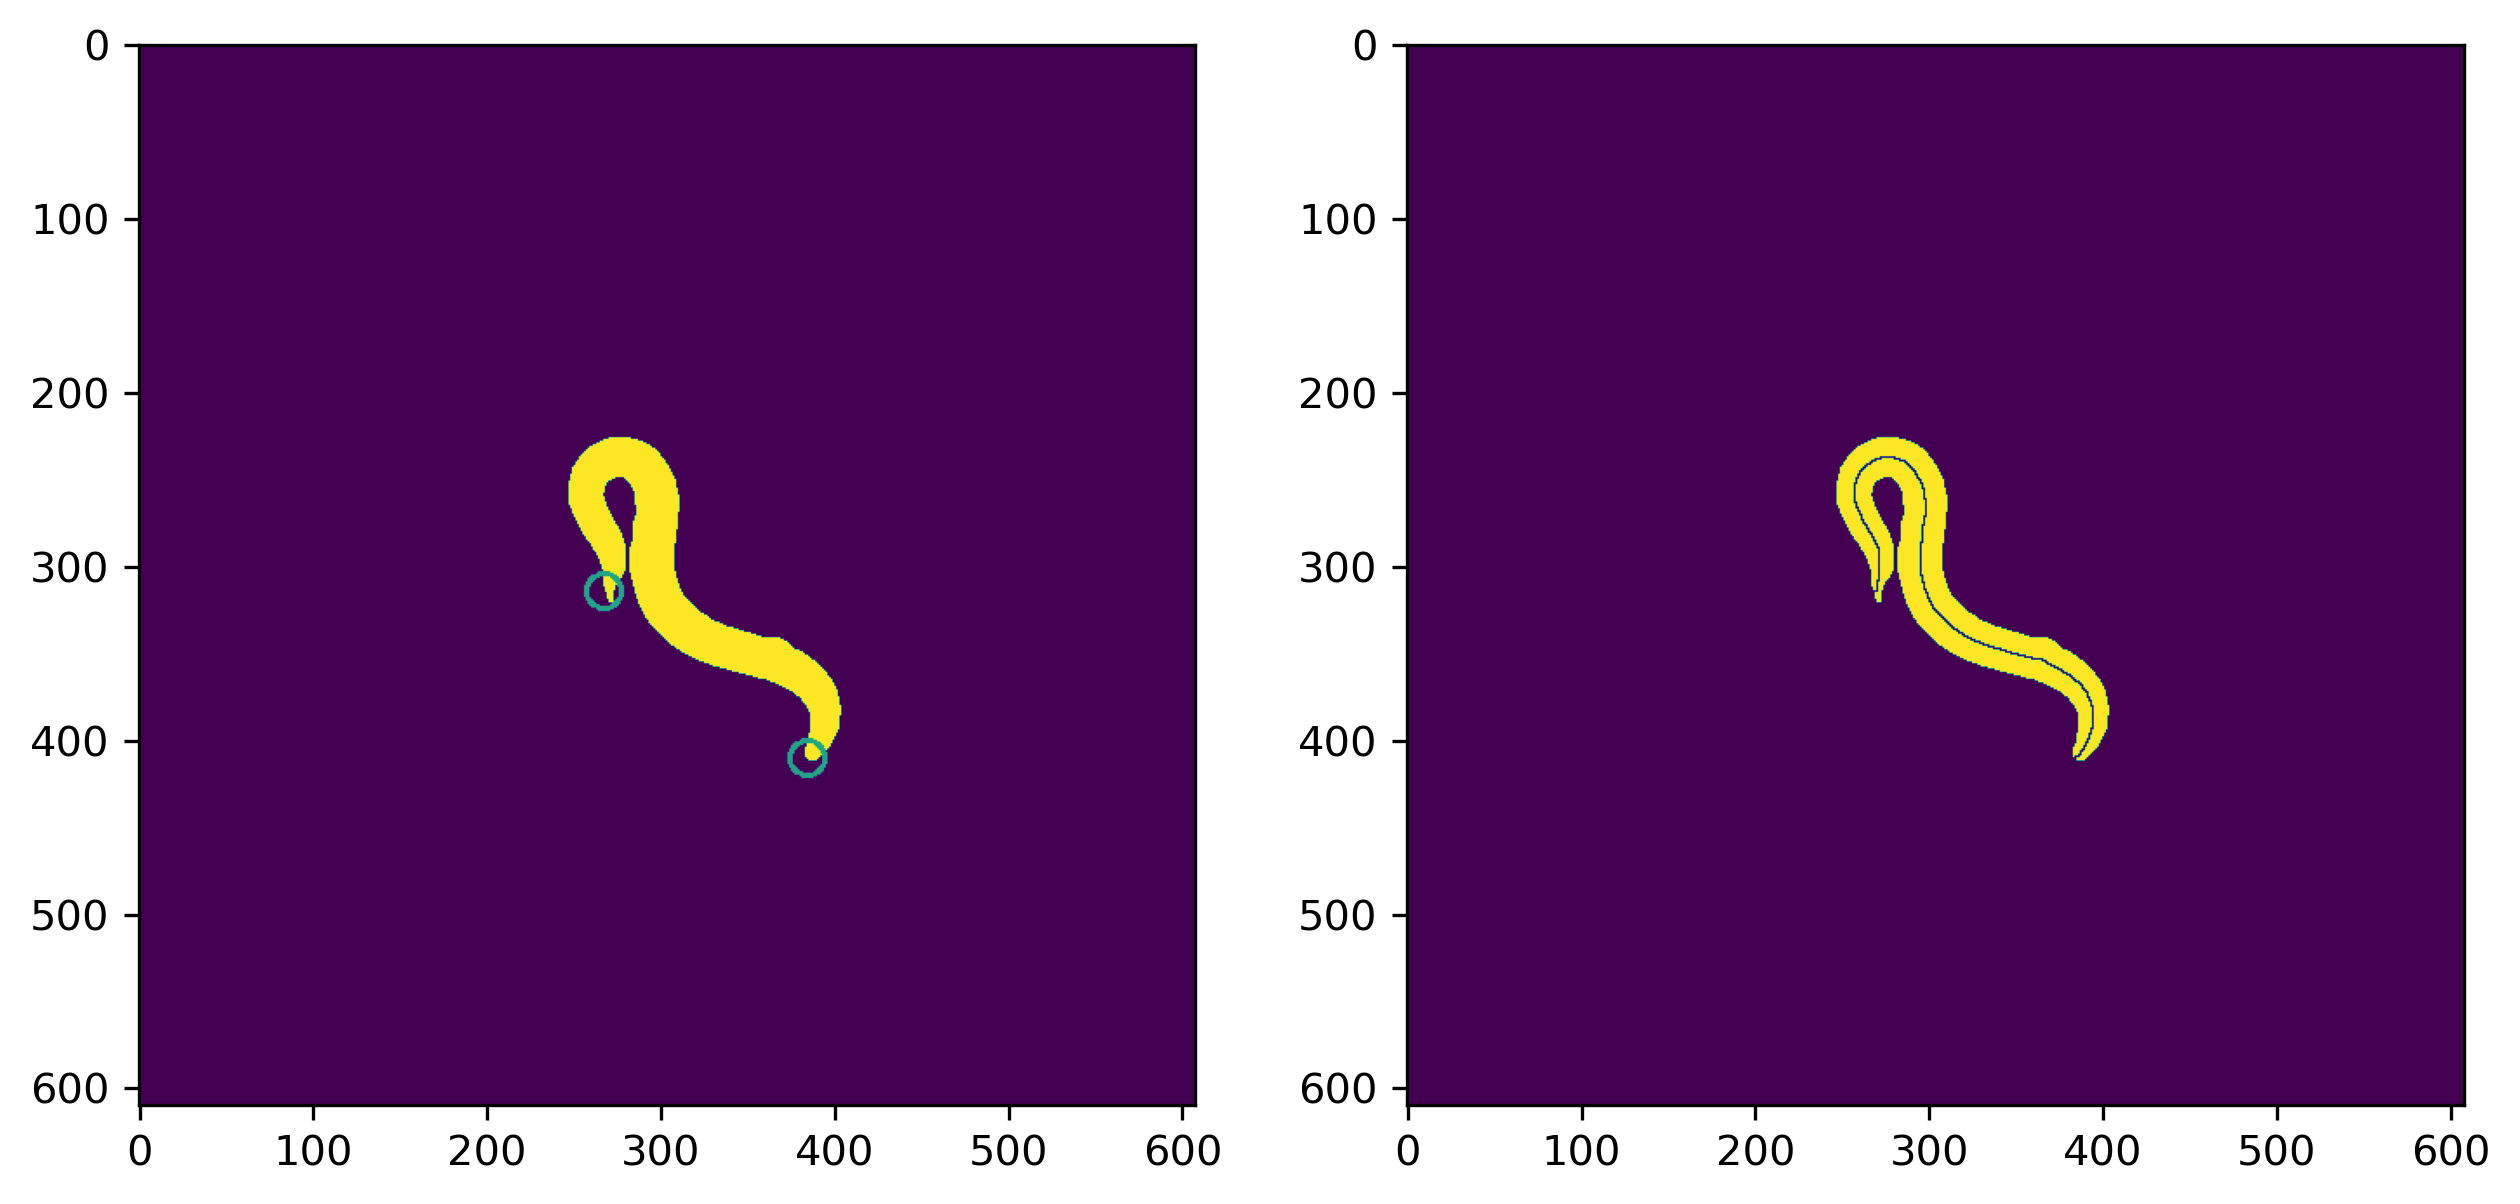

img5174.tif
head and tail were too close, no centerline could be created
img5202.tif
head and tail were too close, no centerline could be created
img5218.tif
head and tail were too close, no centerline could be created
img5243.tif


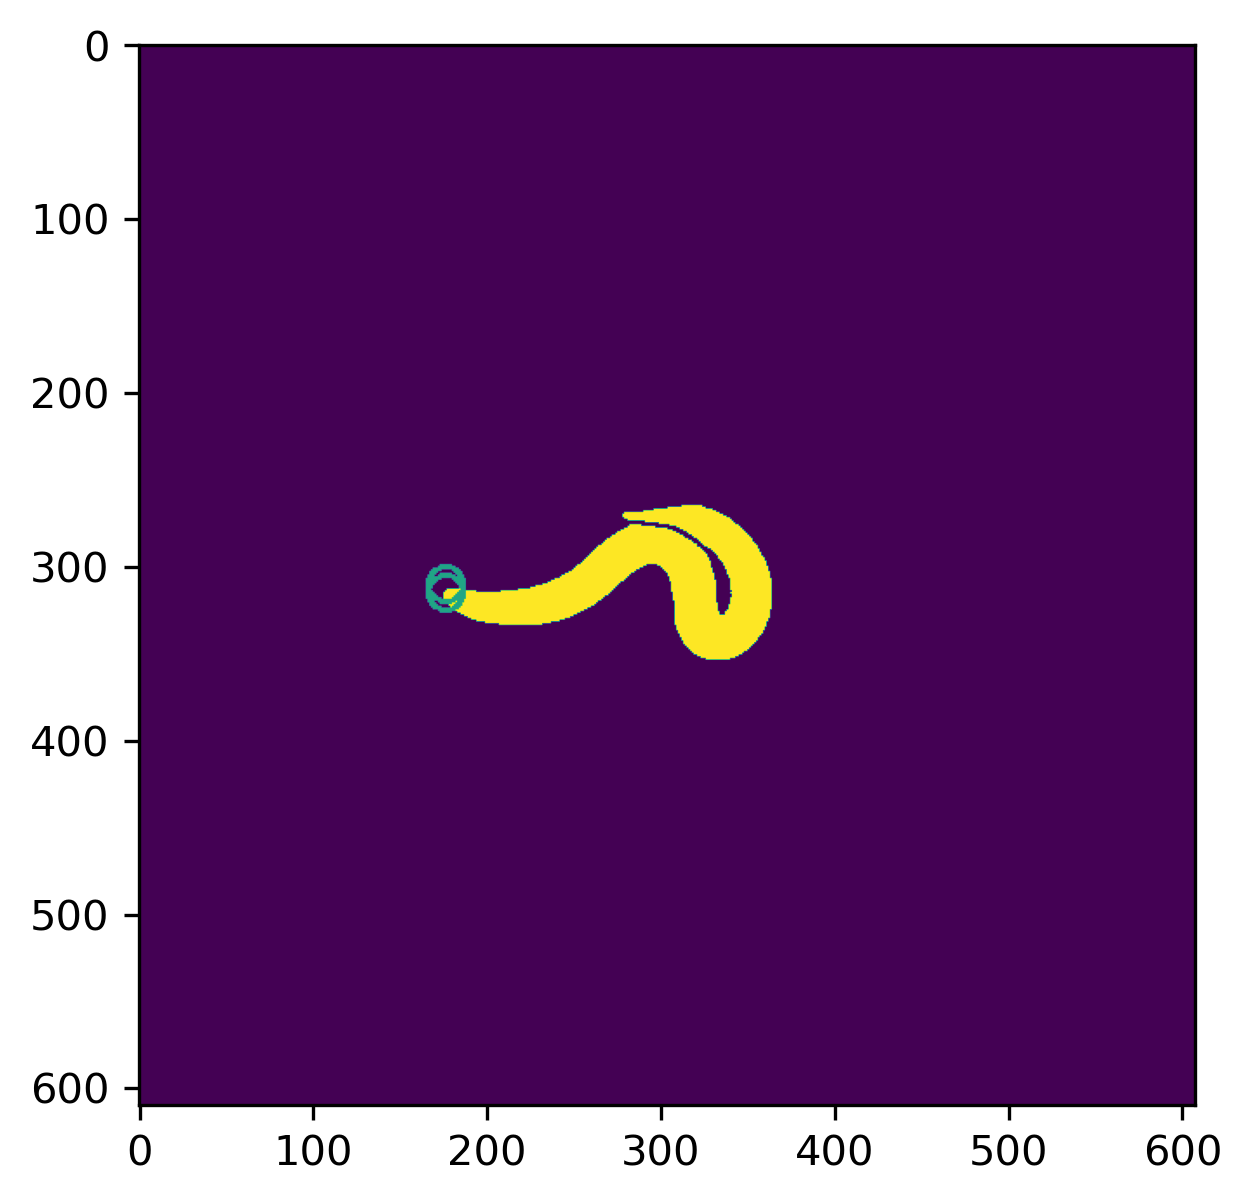

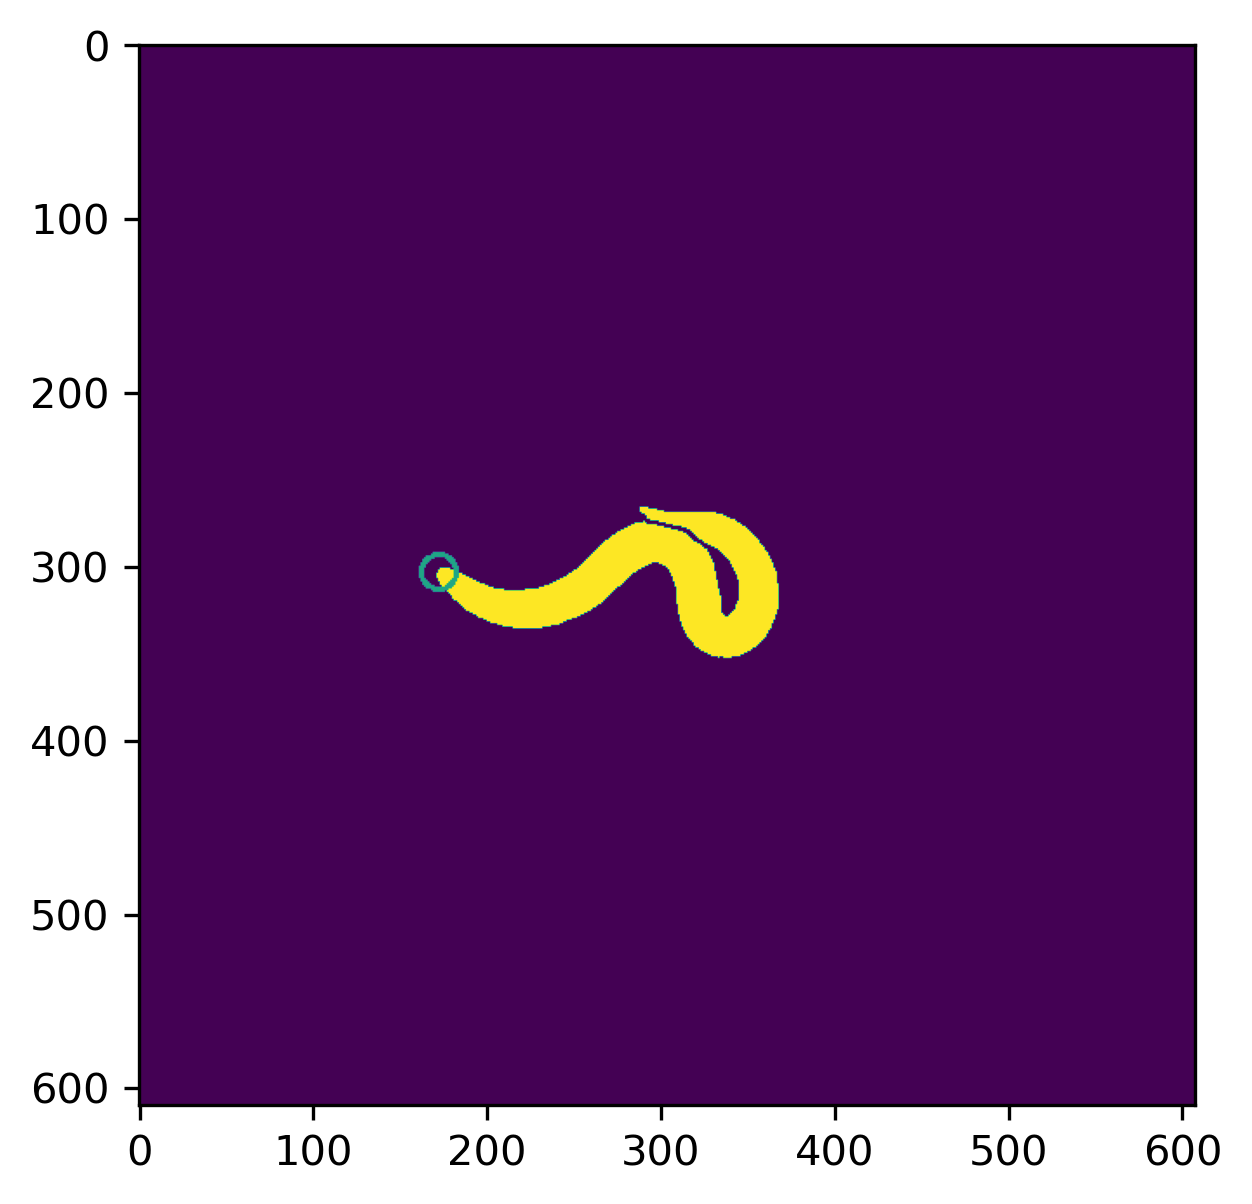

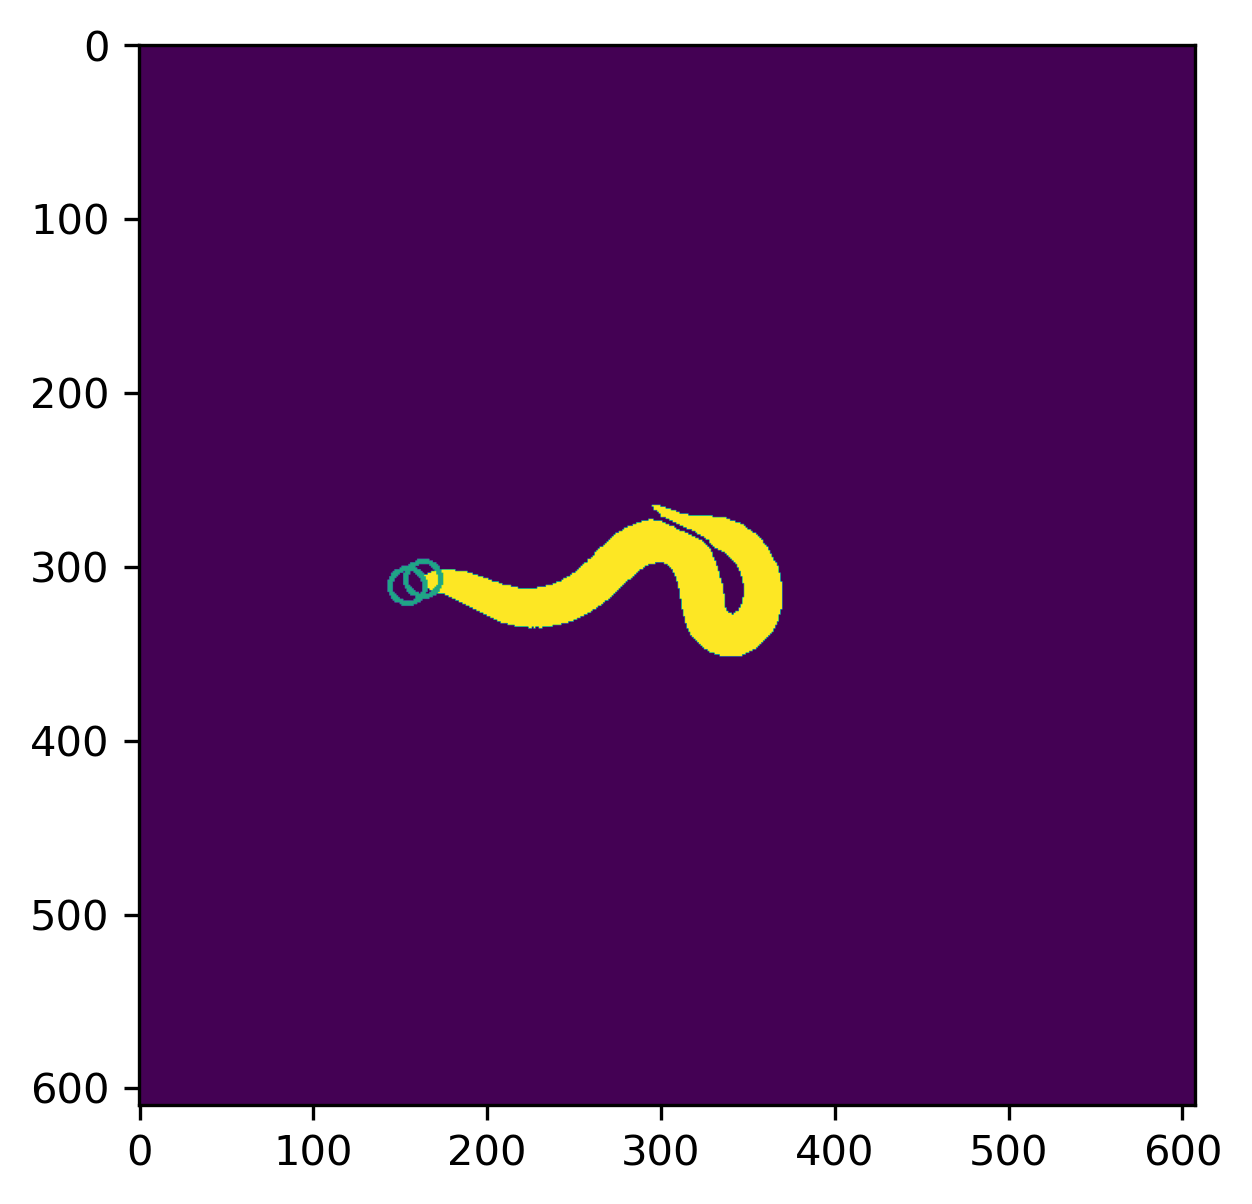

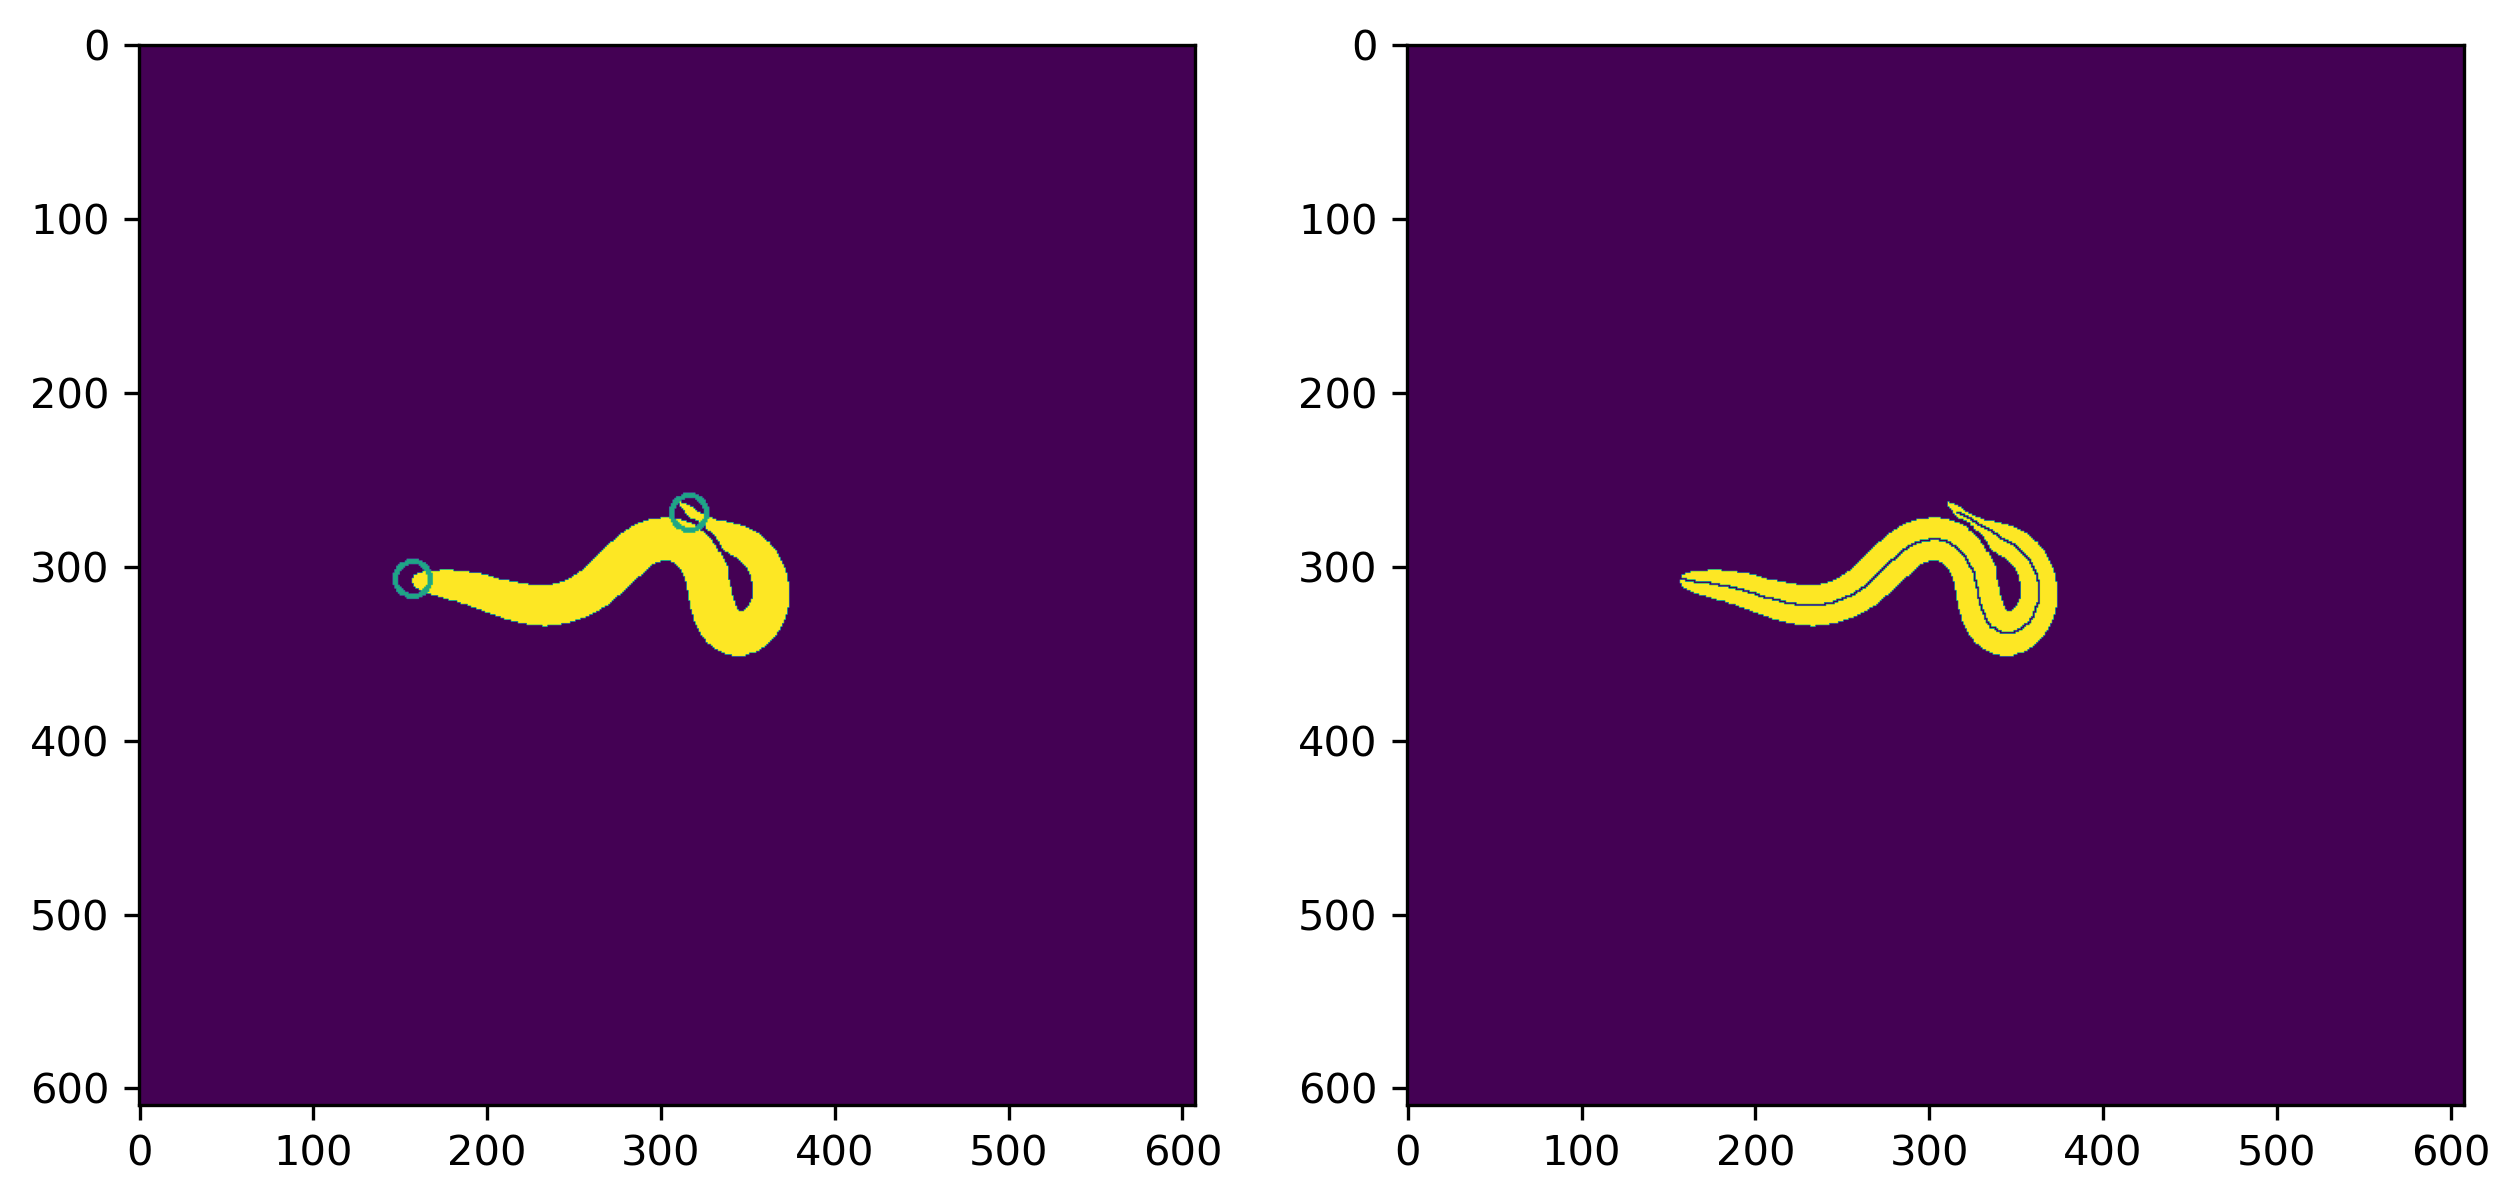

img5259.tif


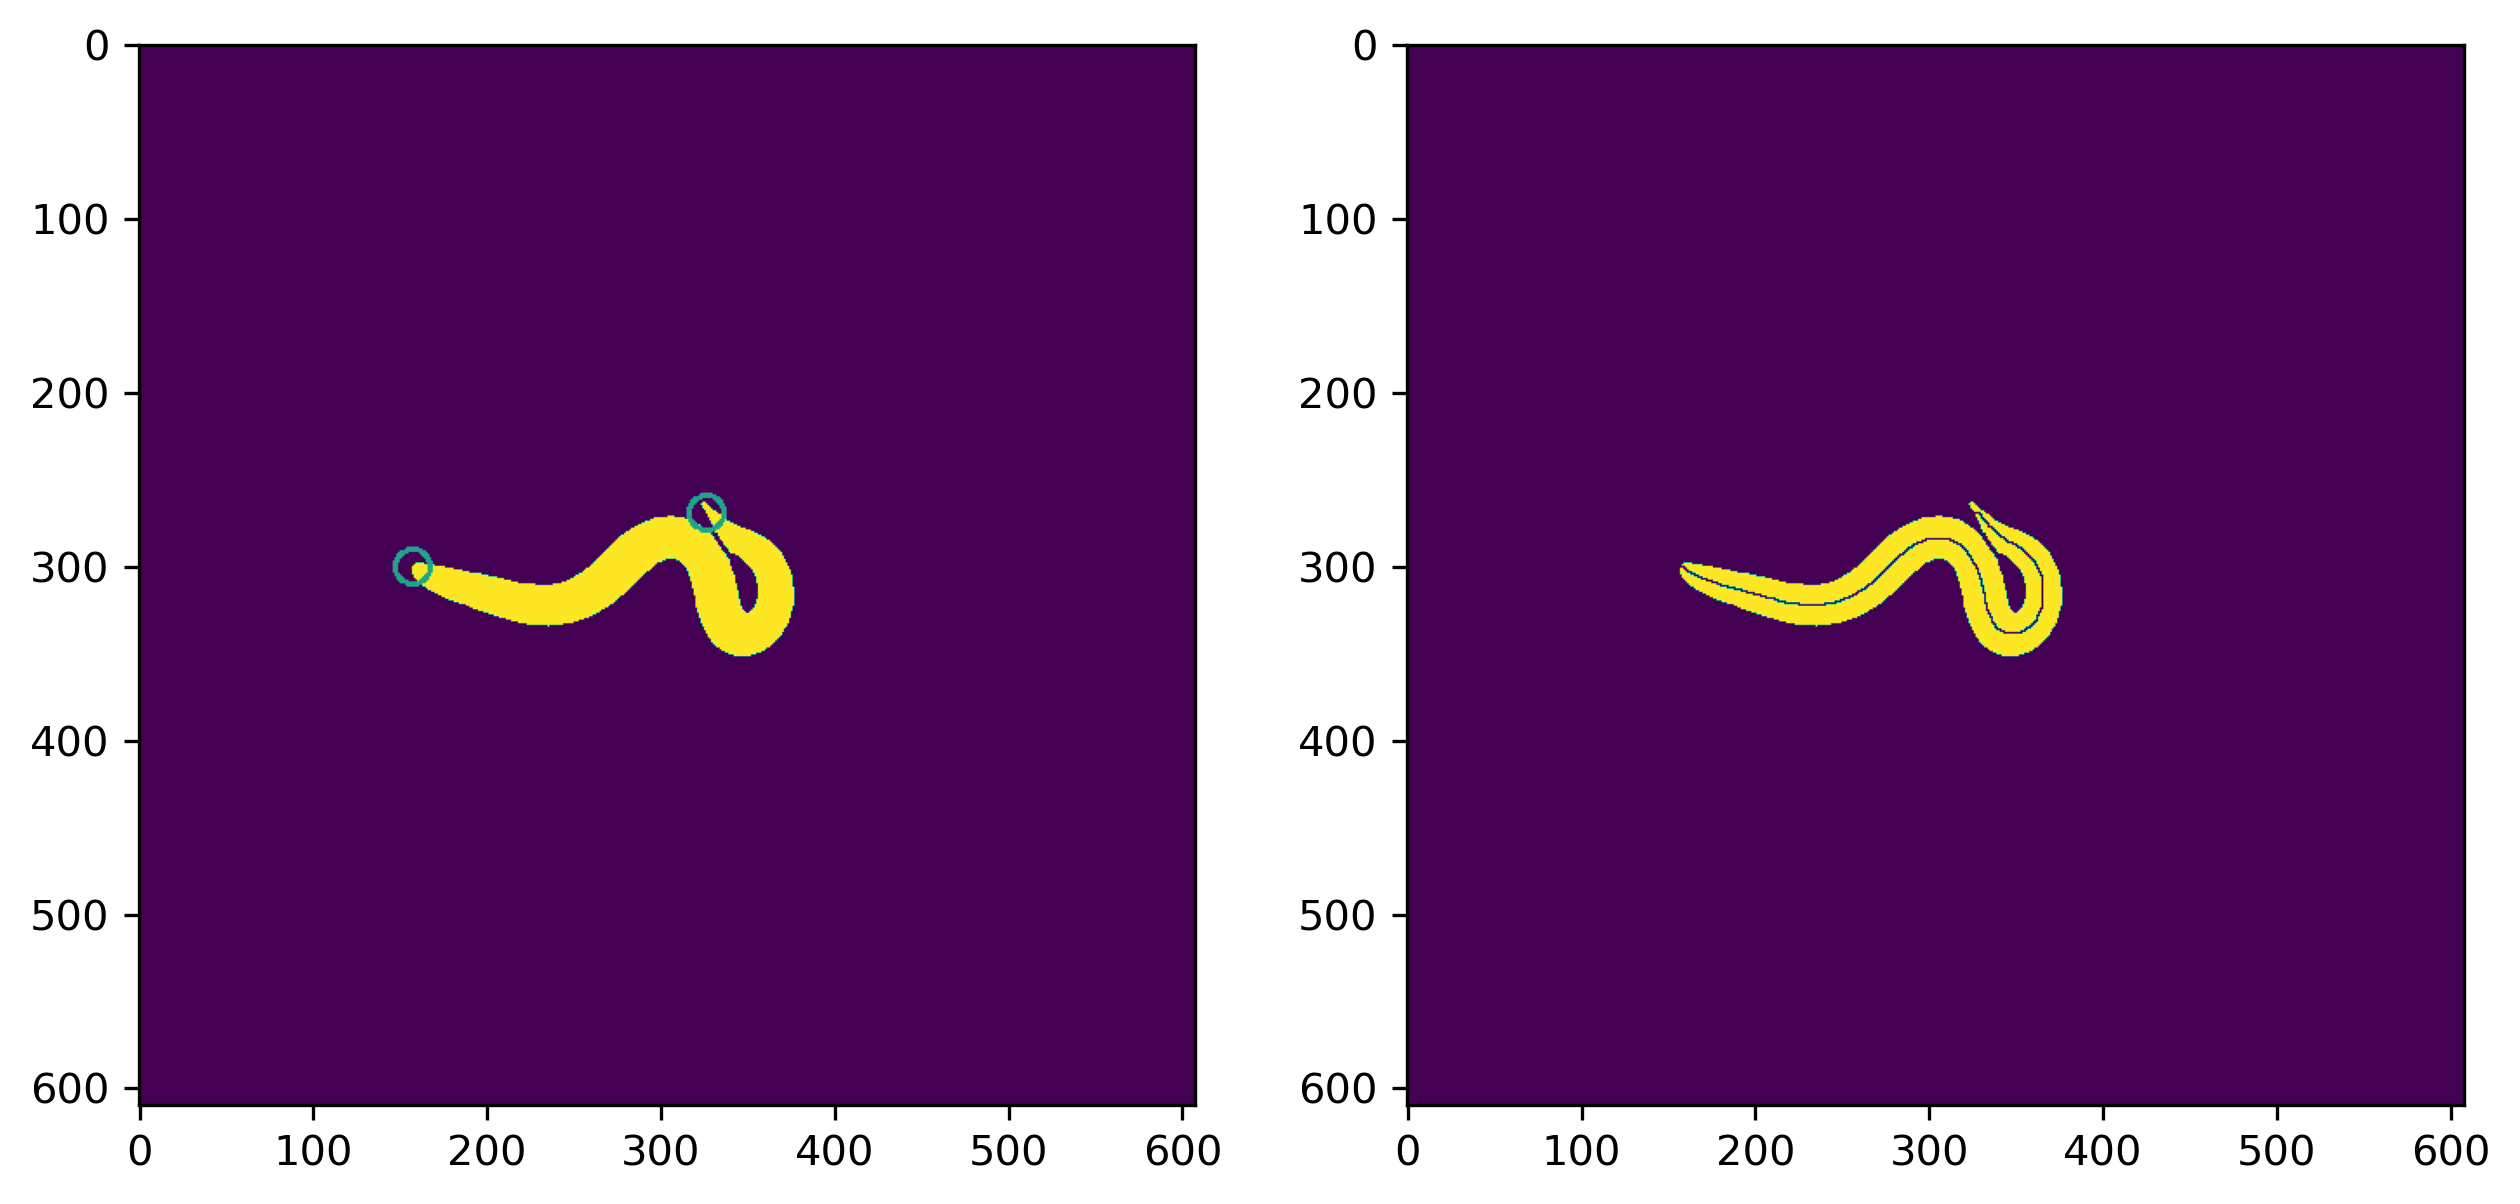

img6961.tif


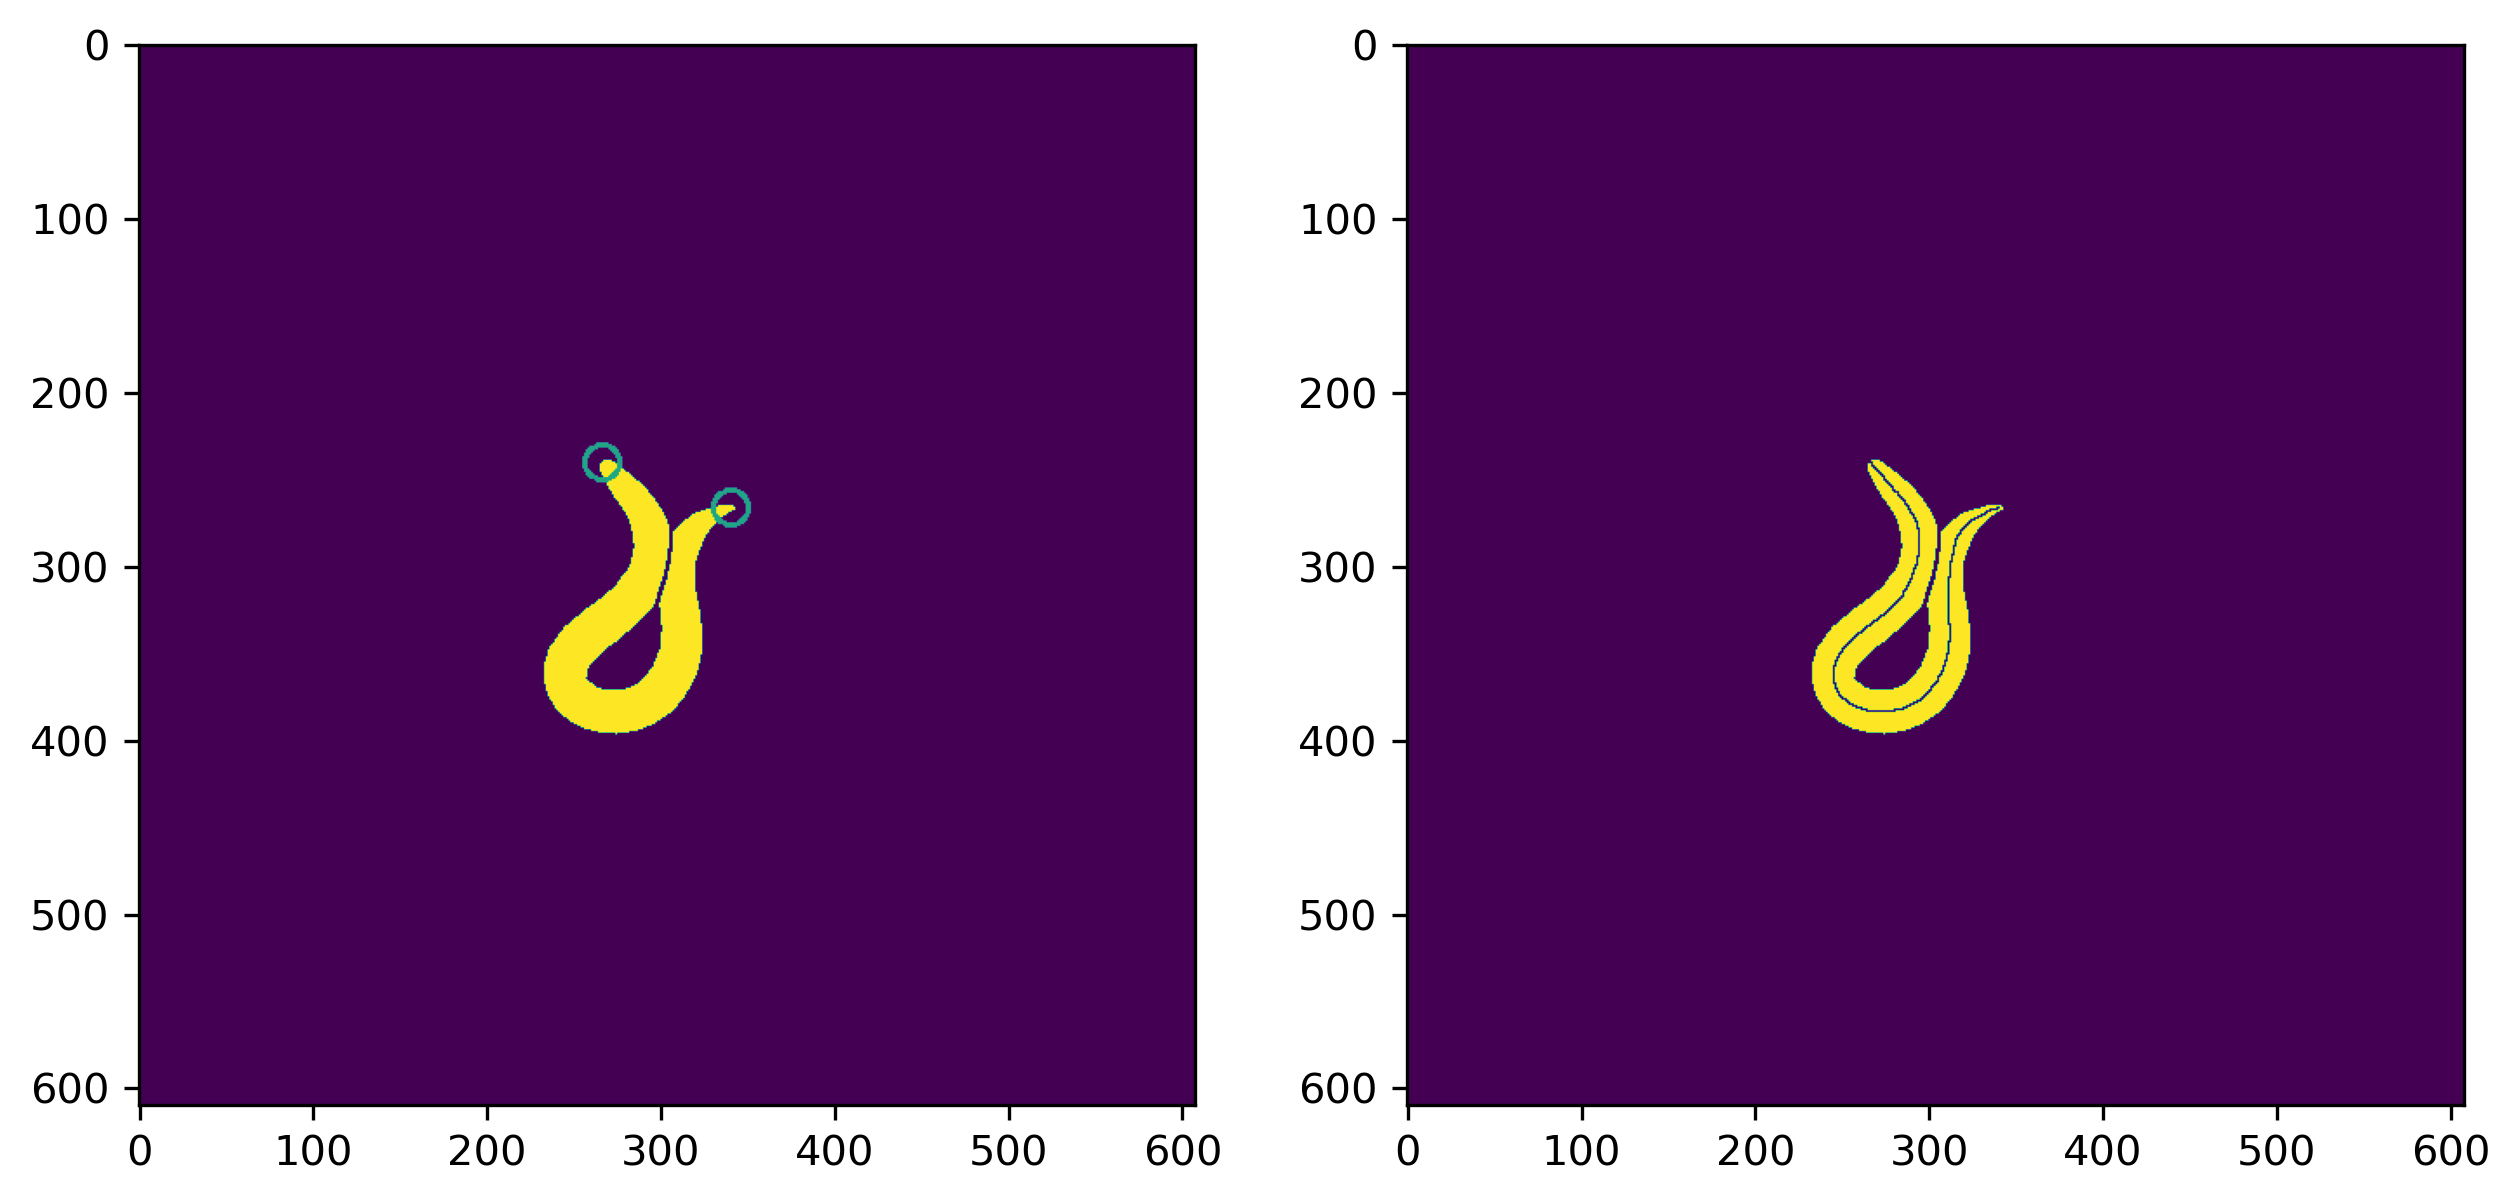

img6984.tif


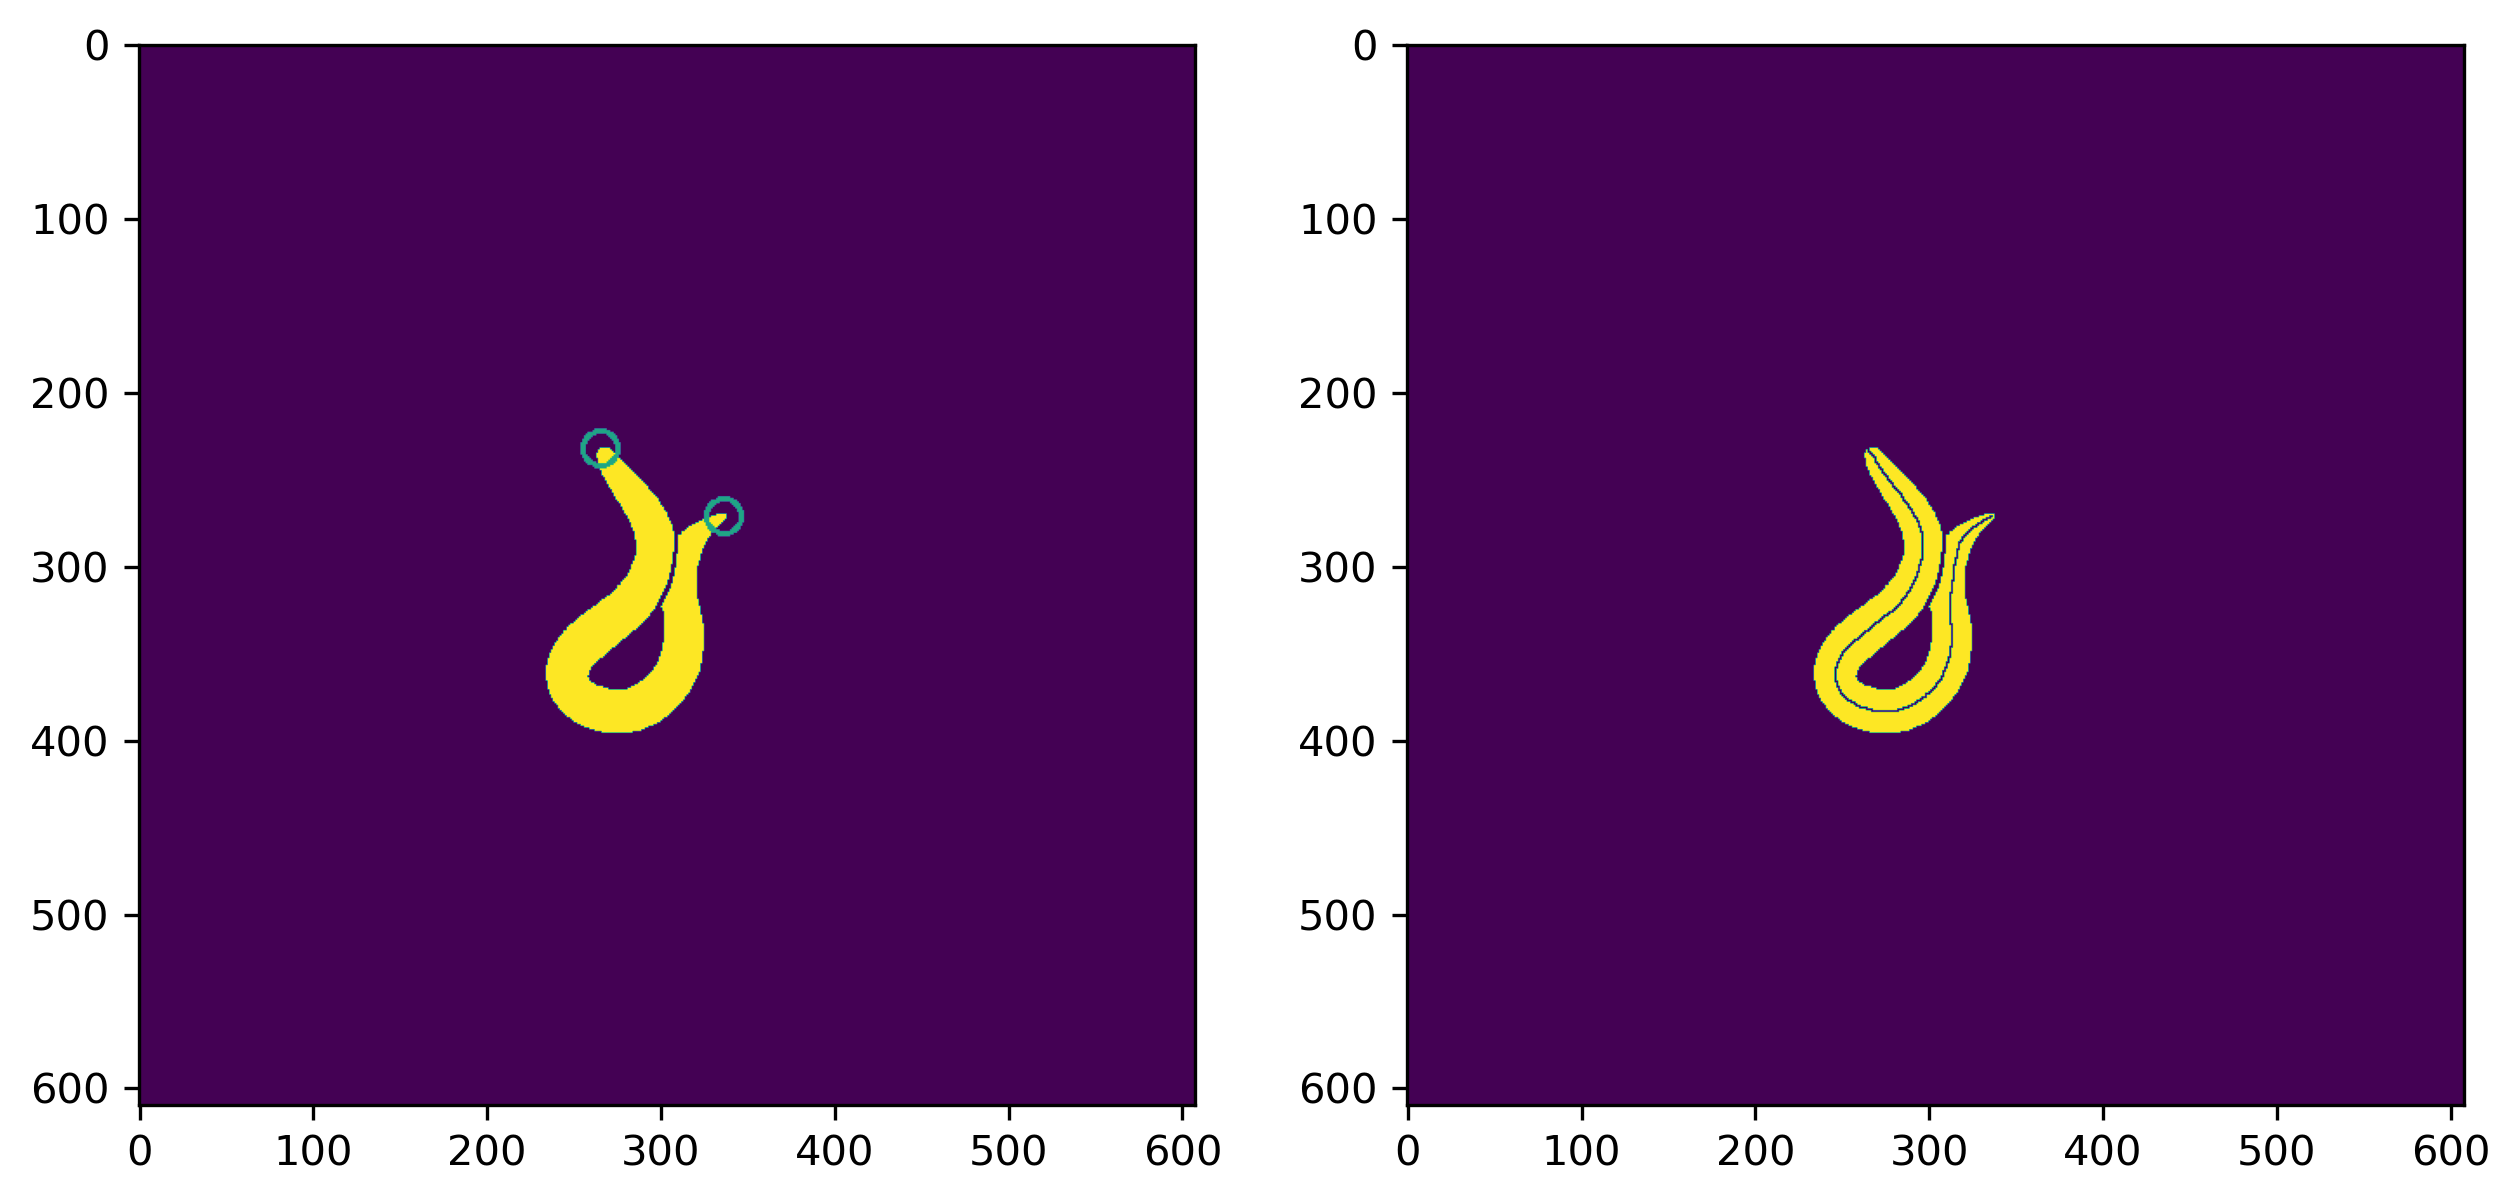

img7006.tif


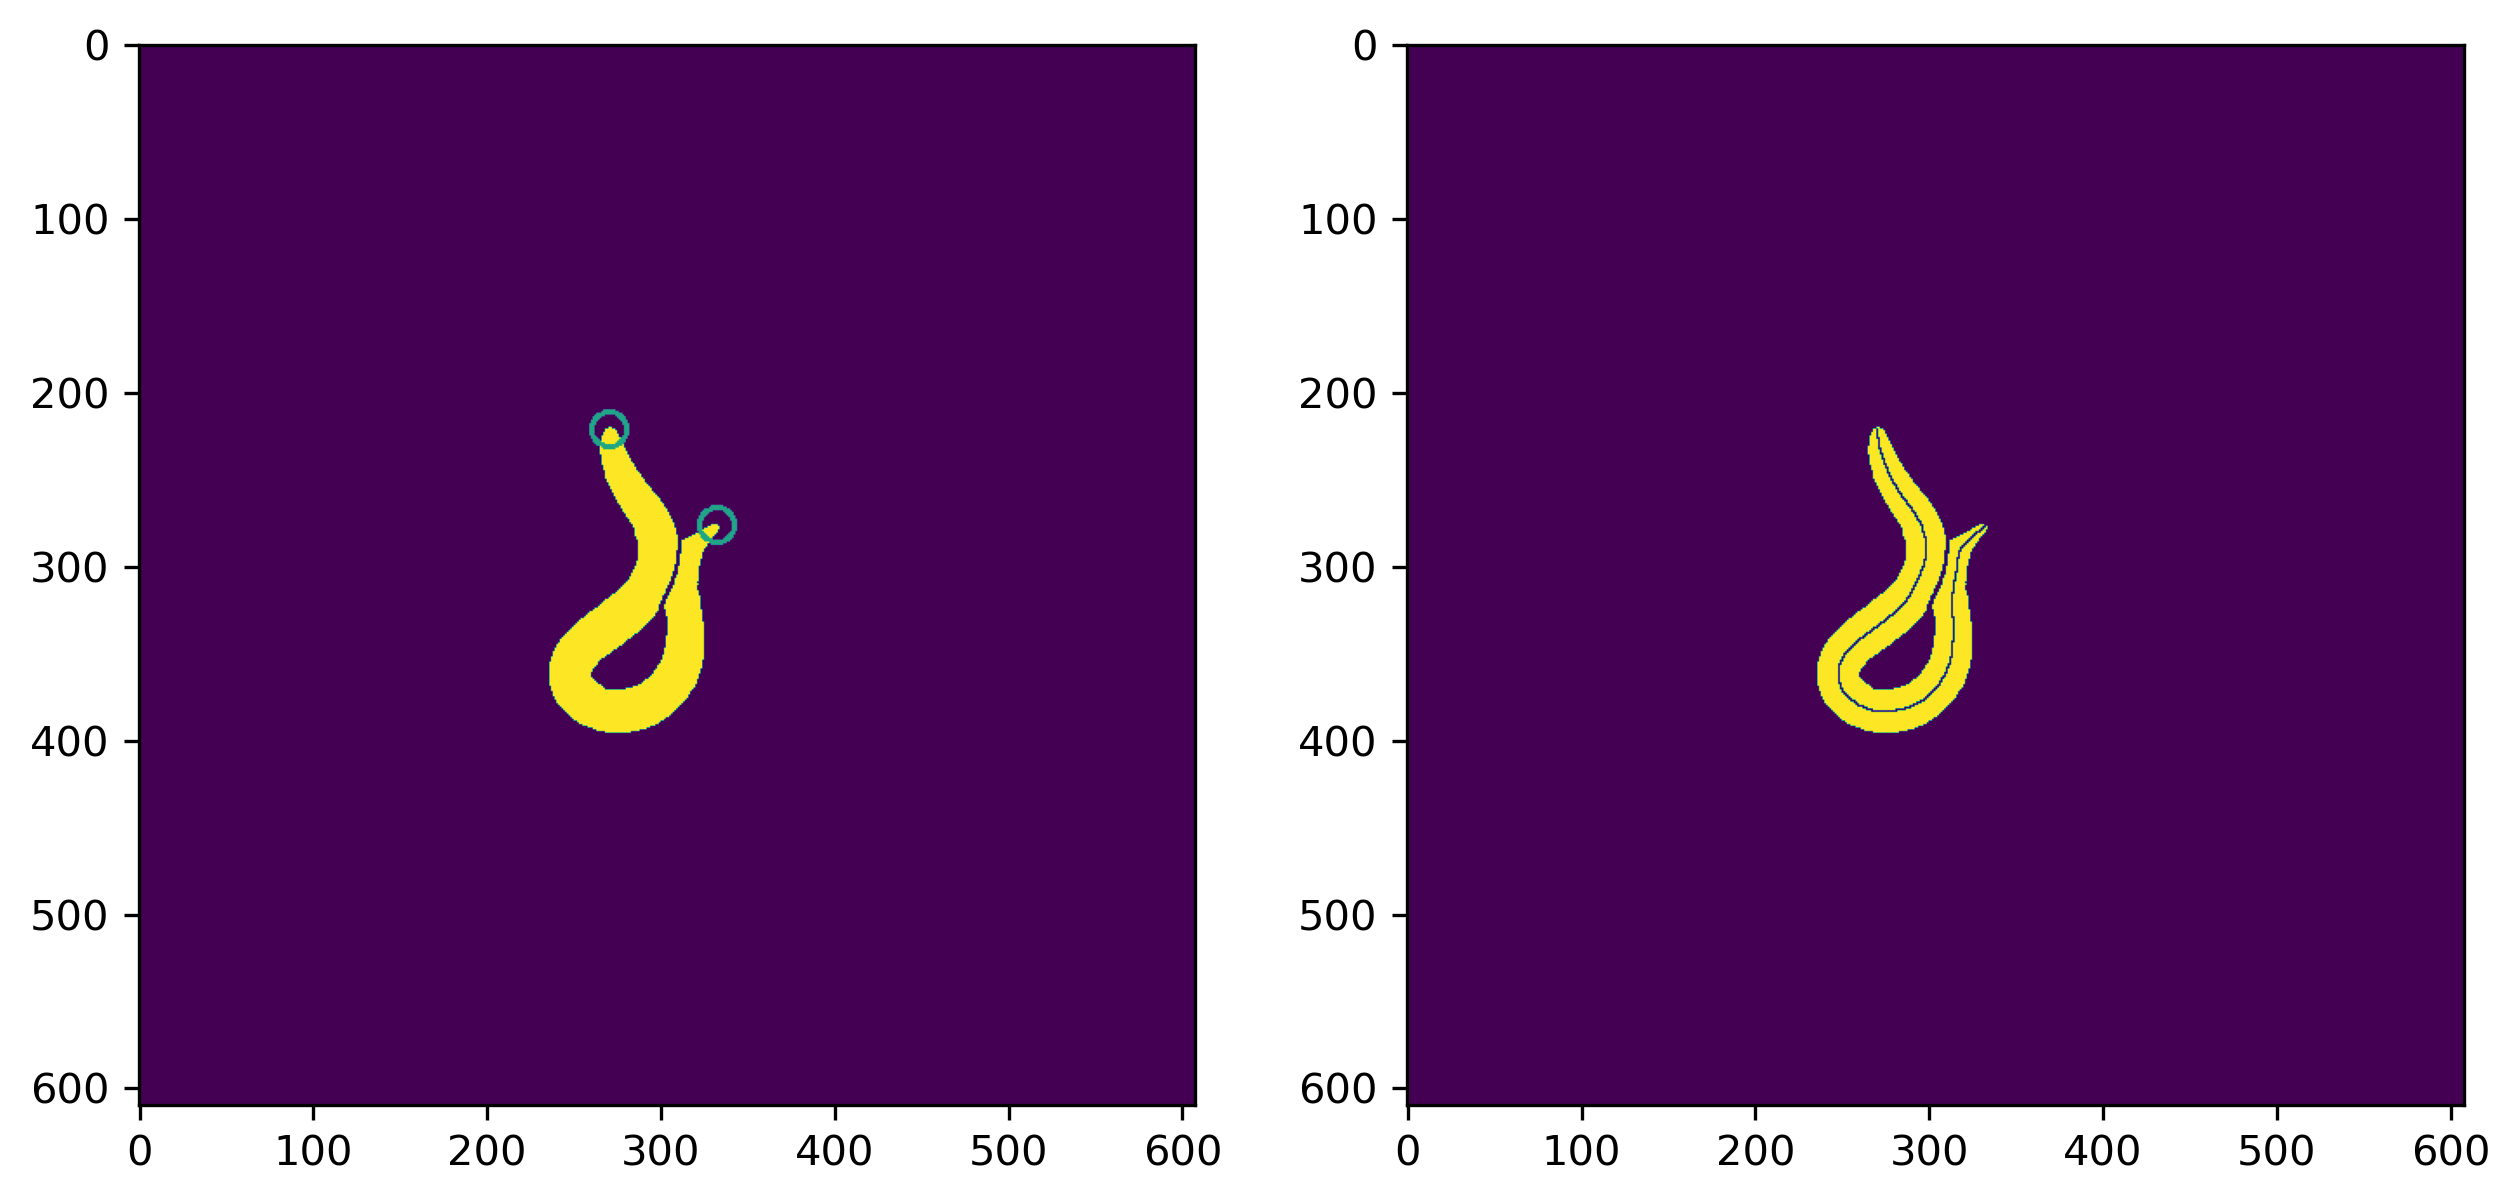

img7033.tif


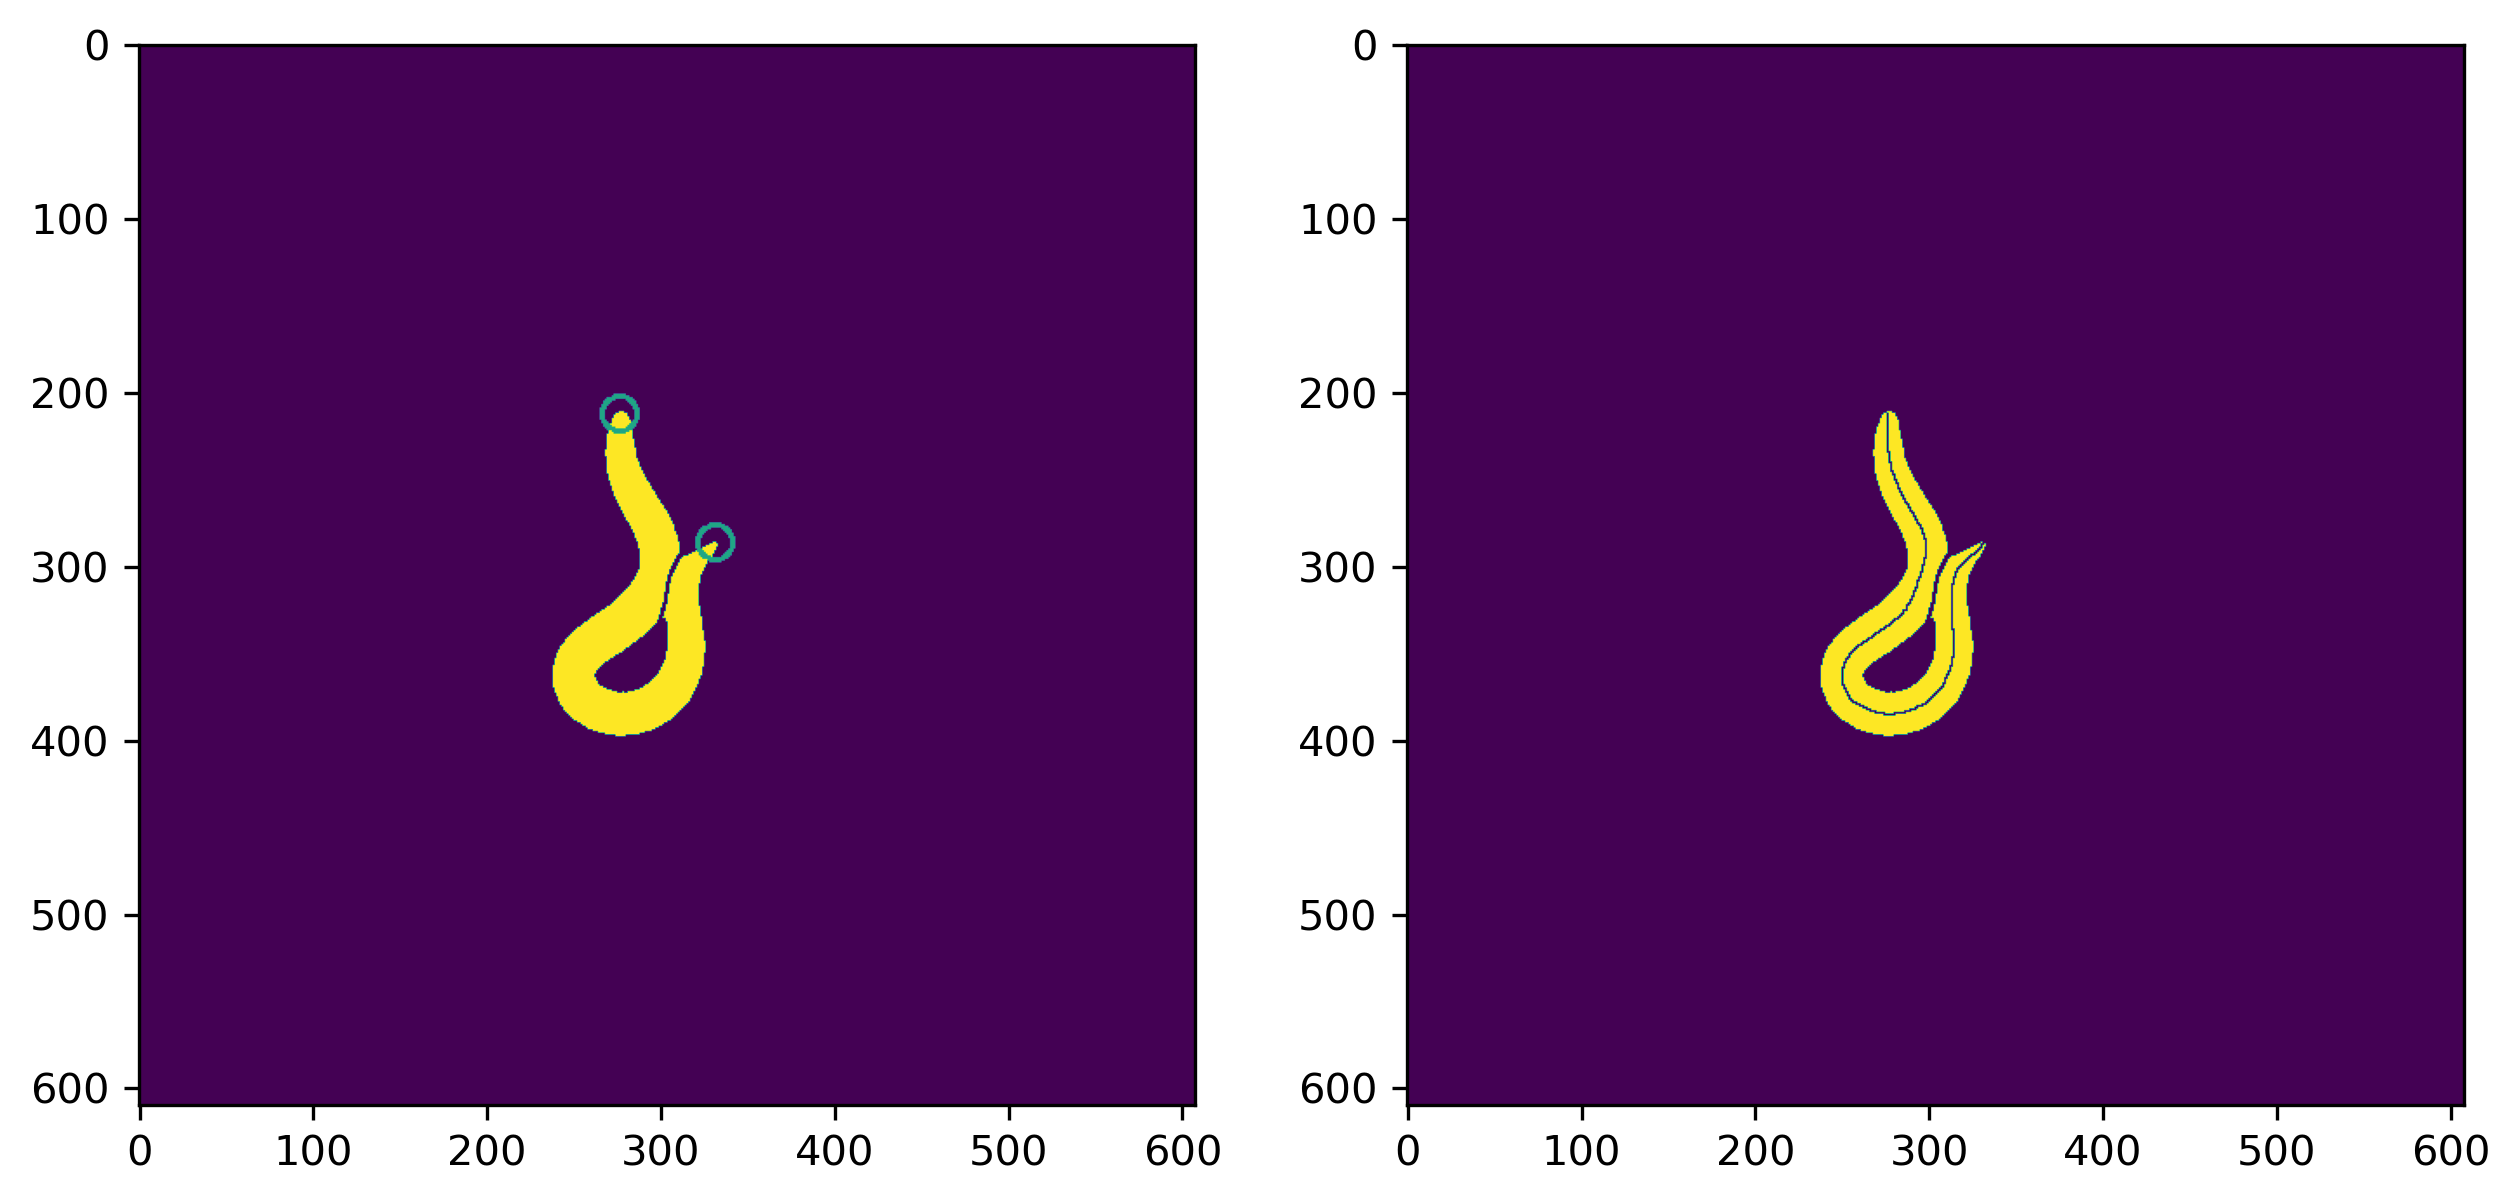

img7070.tif


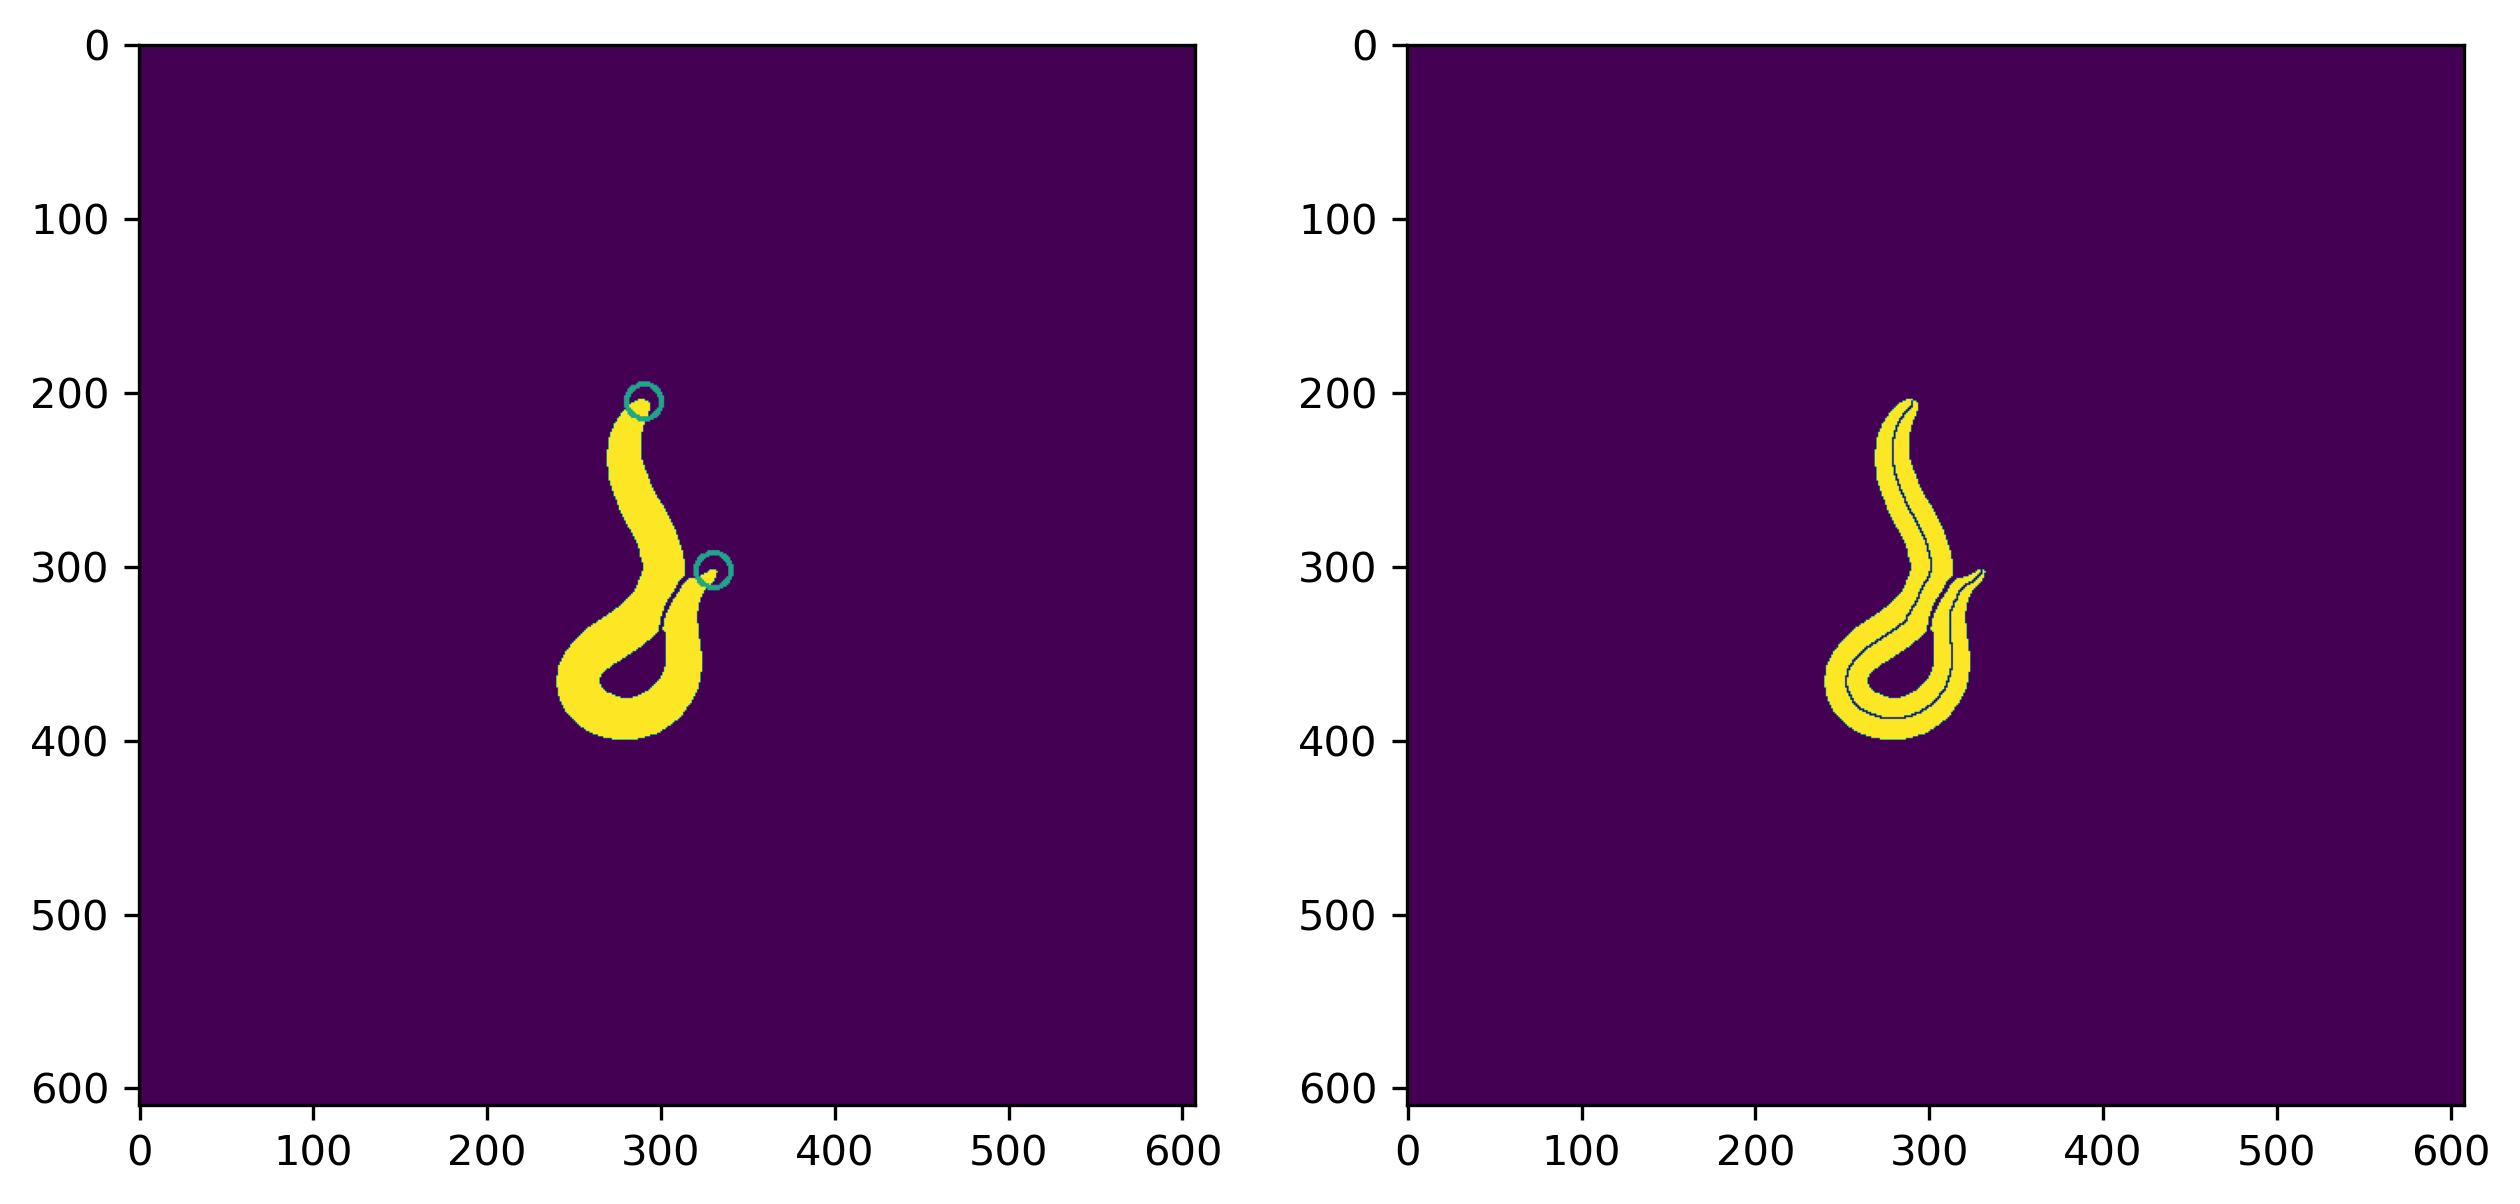

img7103.tif


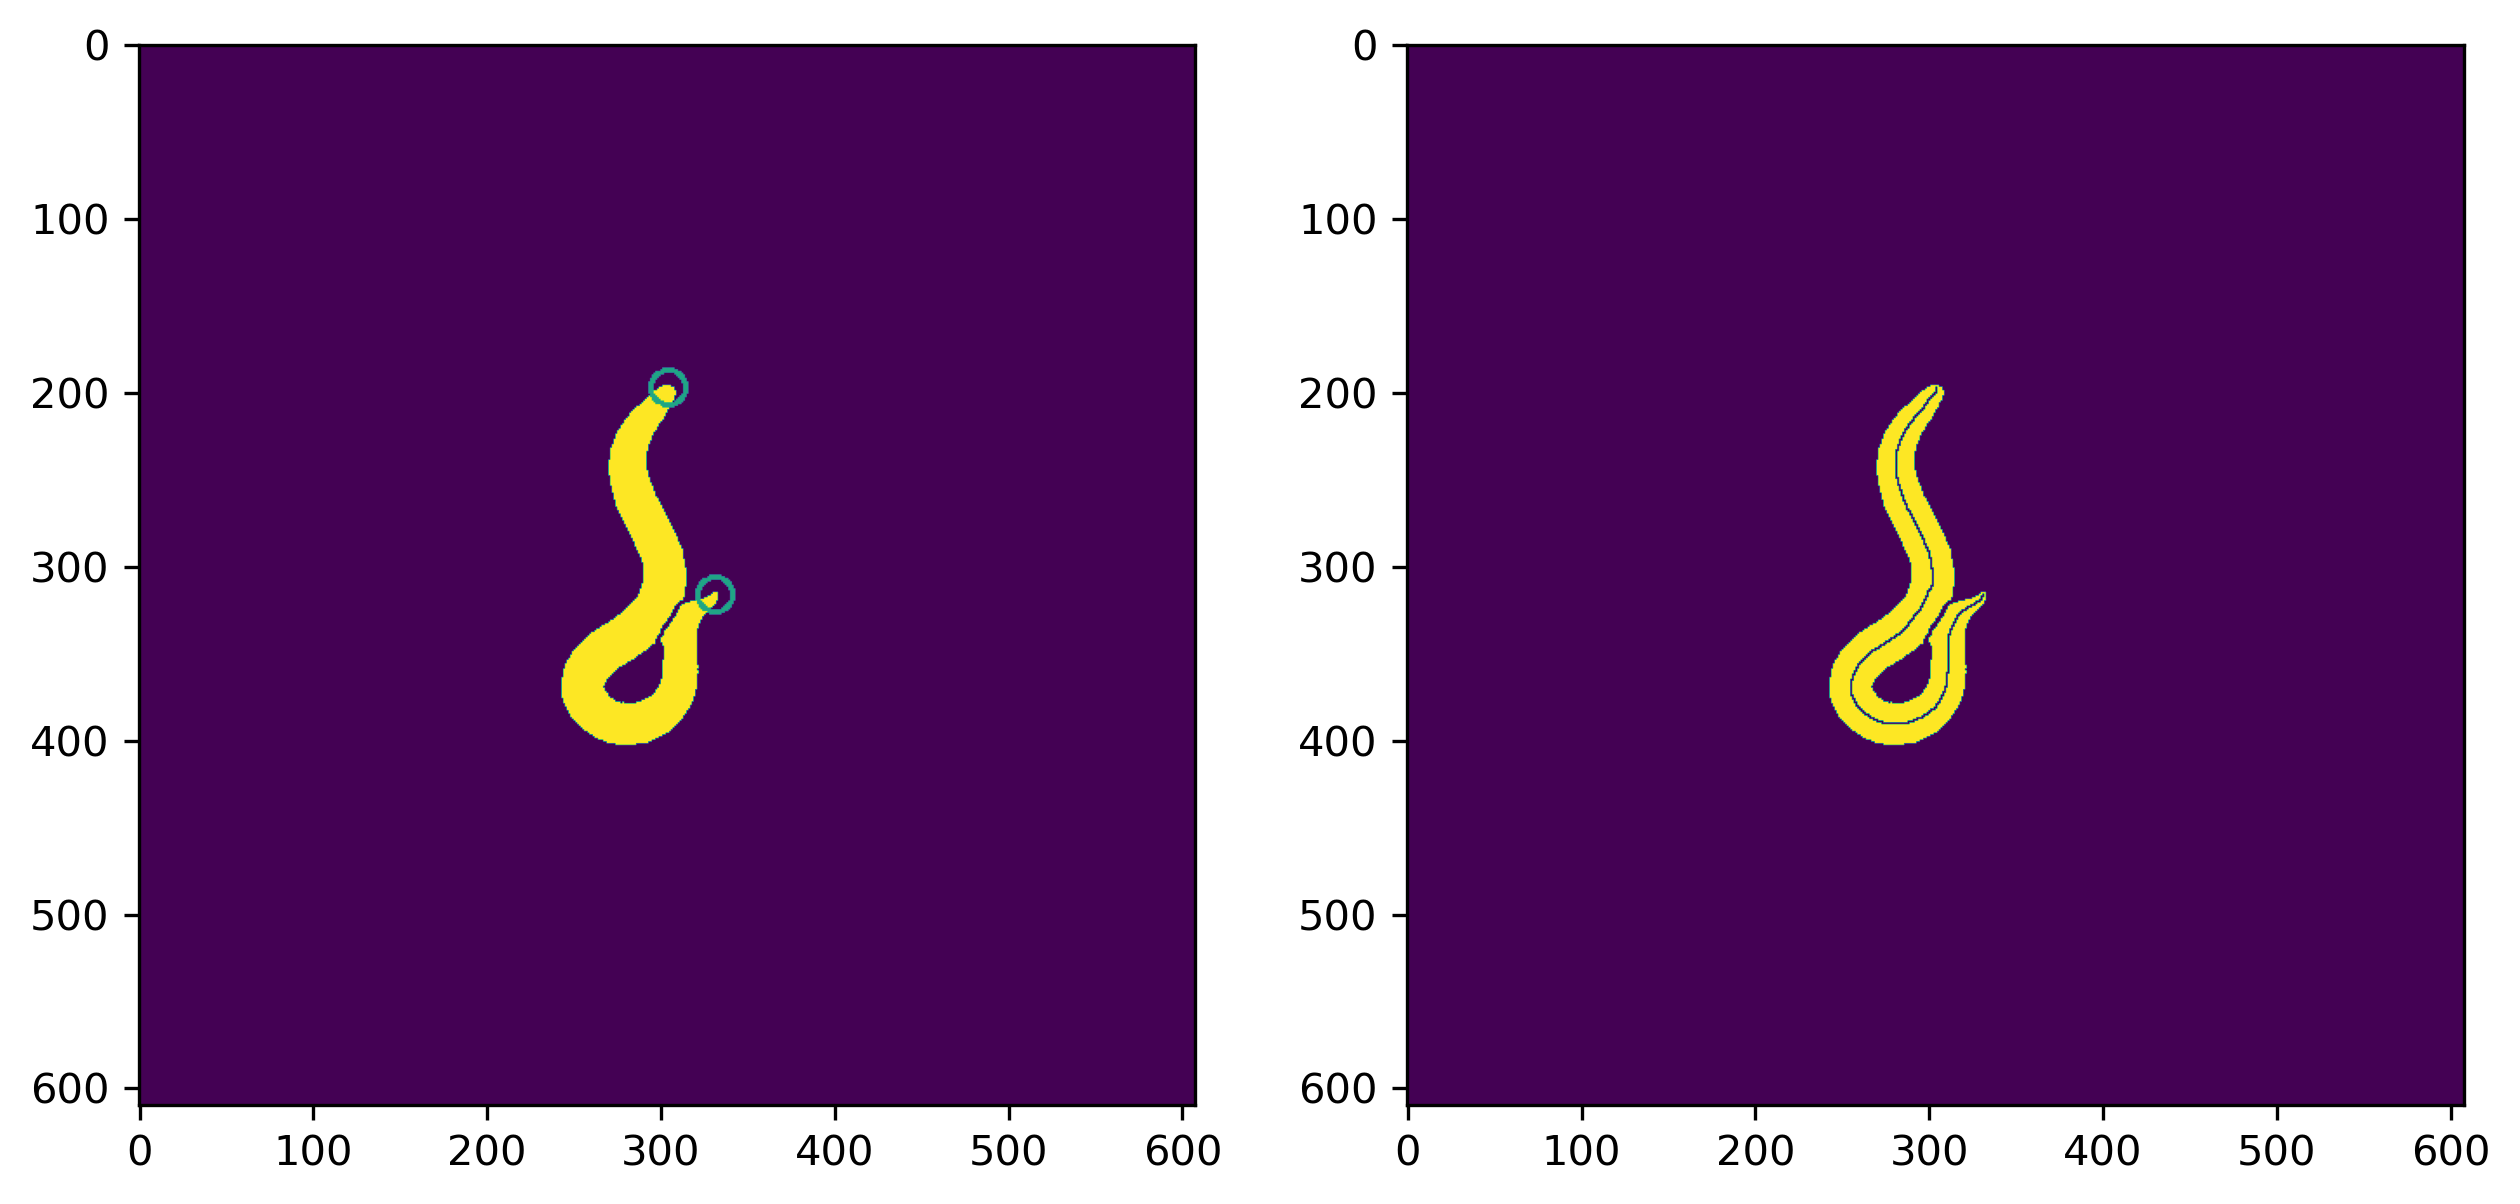

img7125.tif


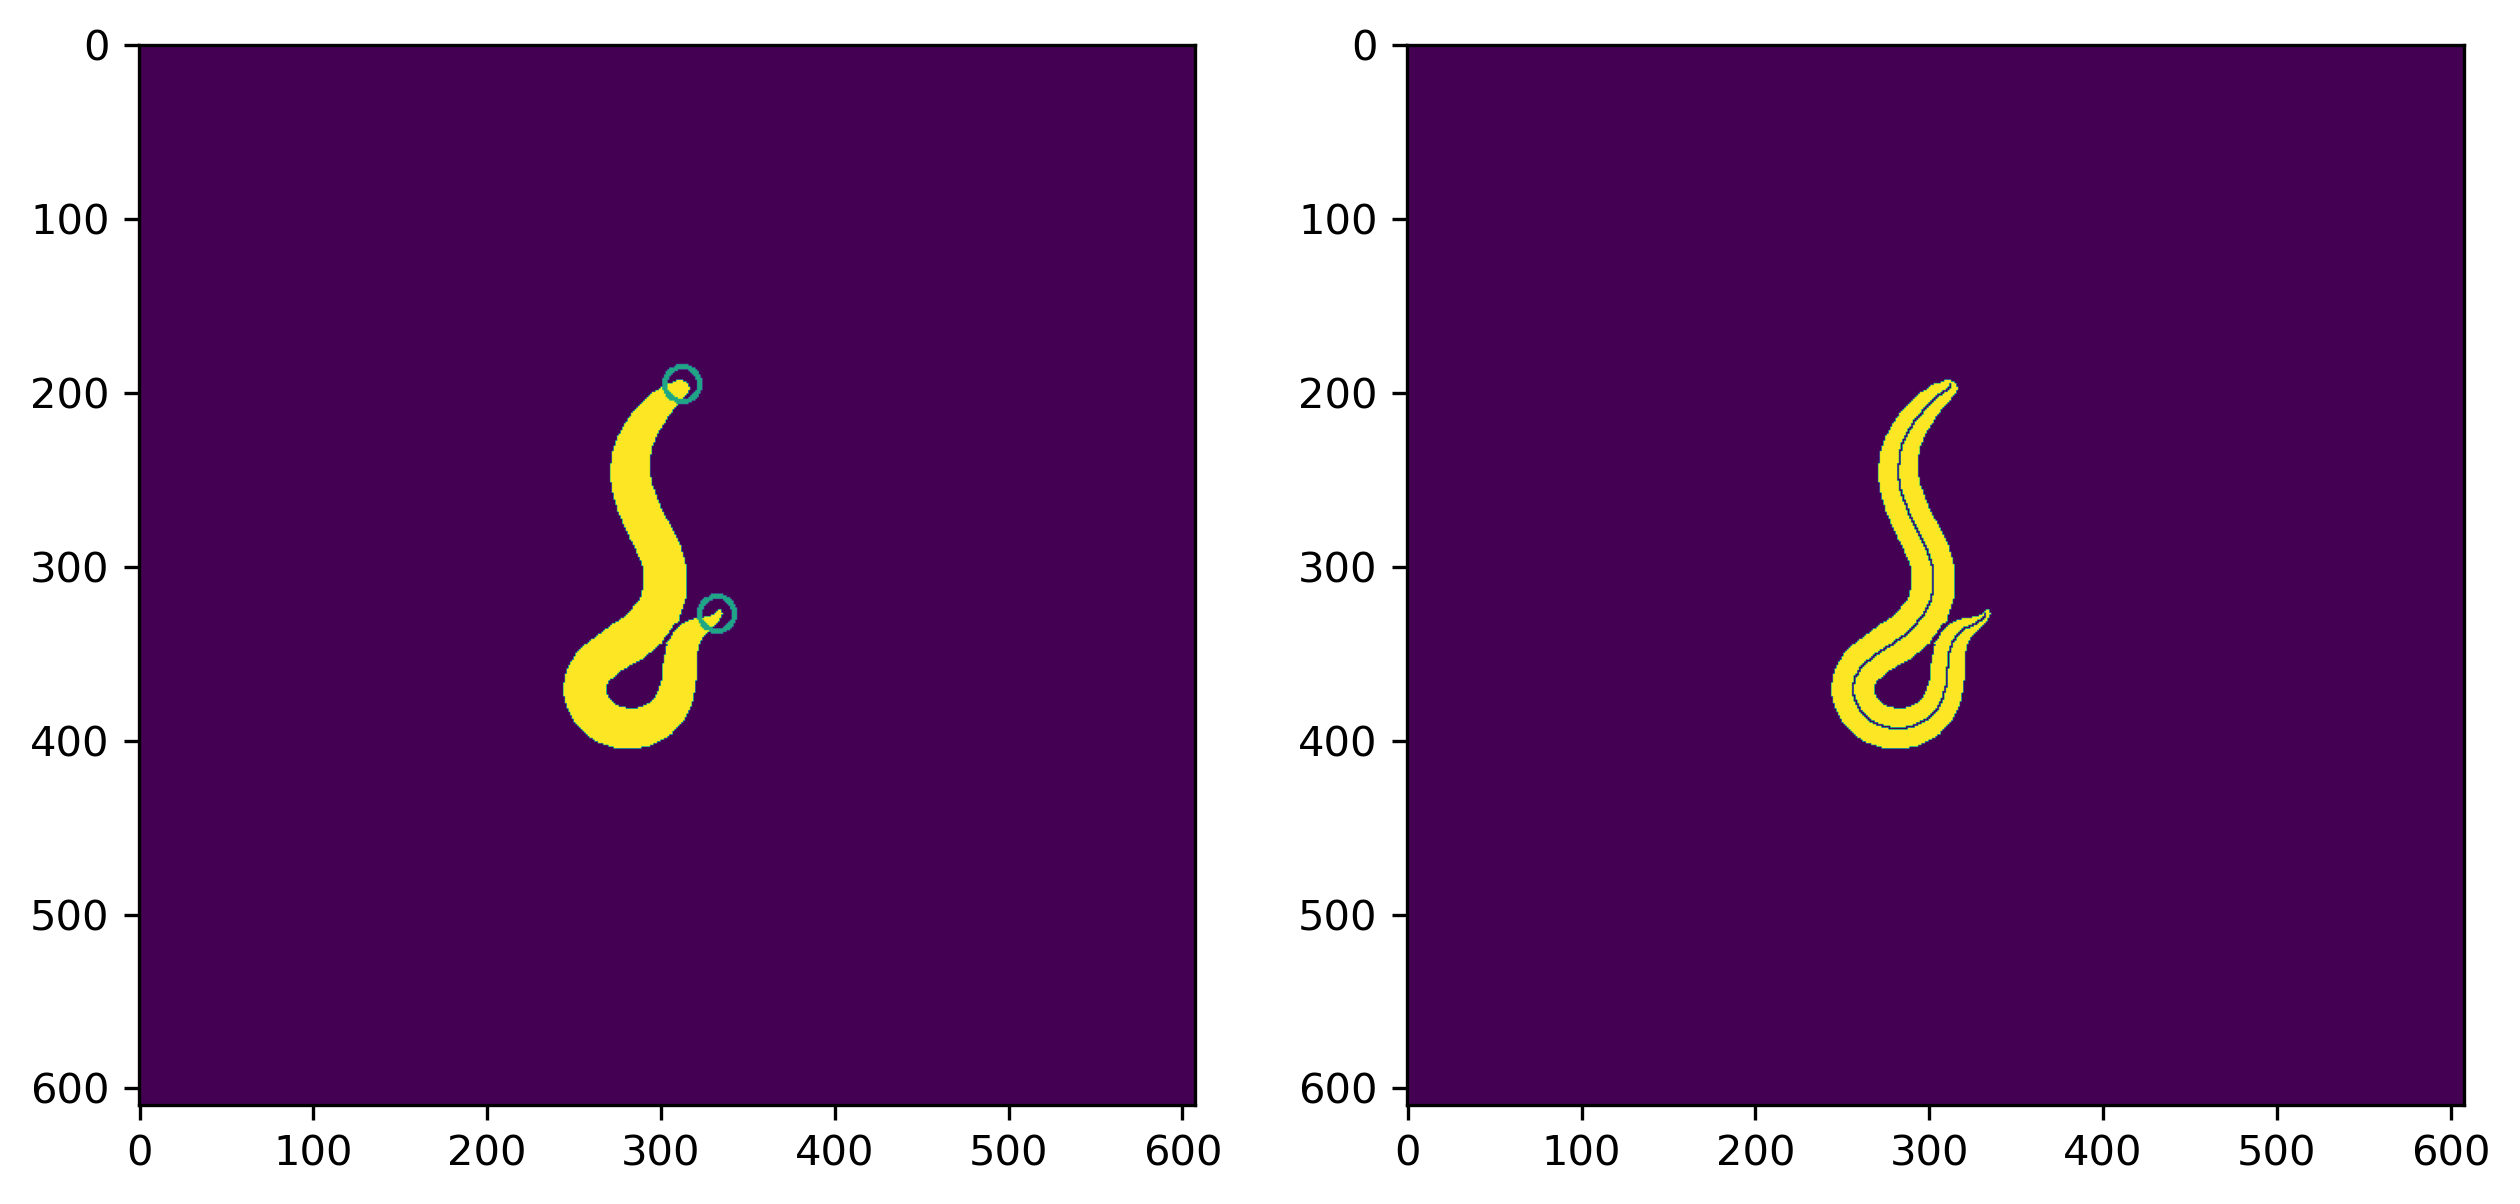

img21705.tif


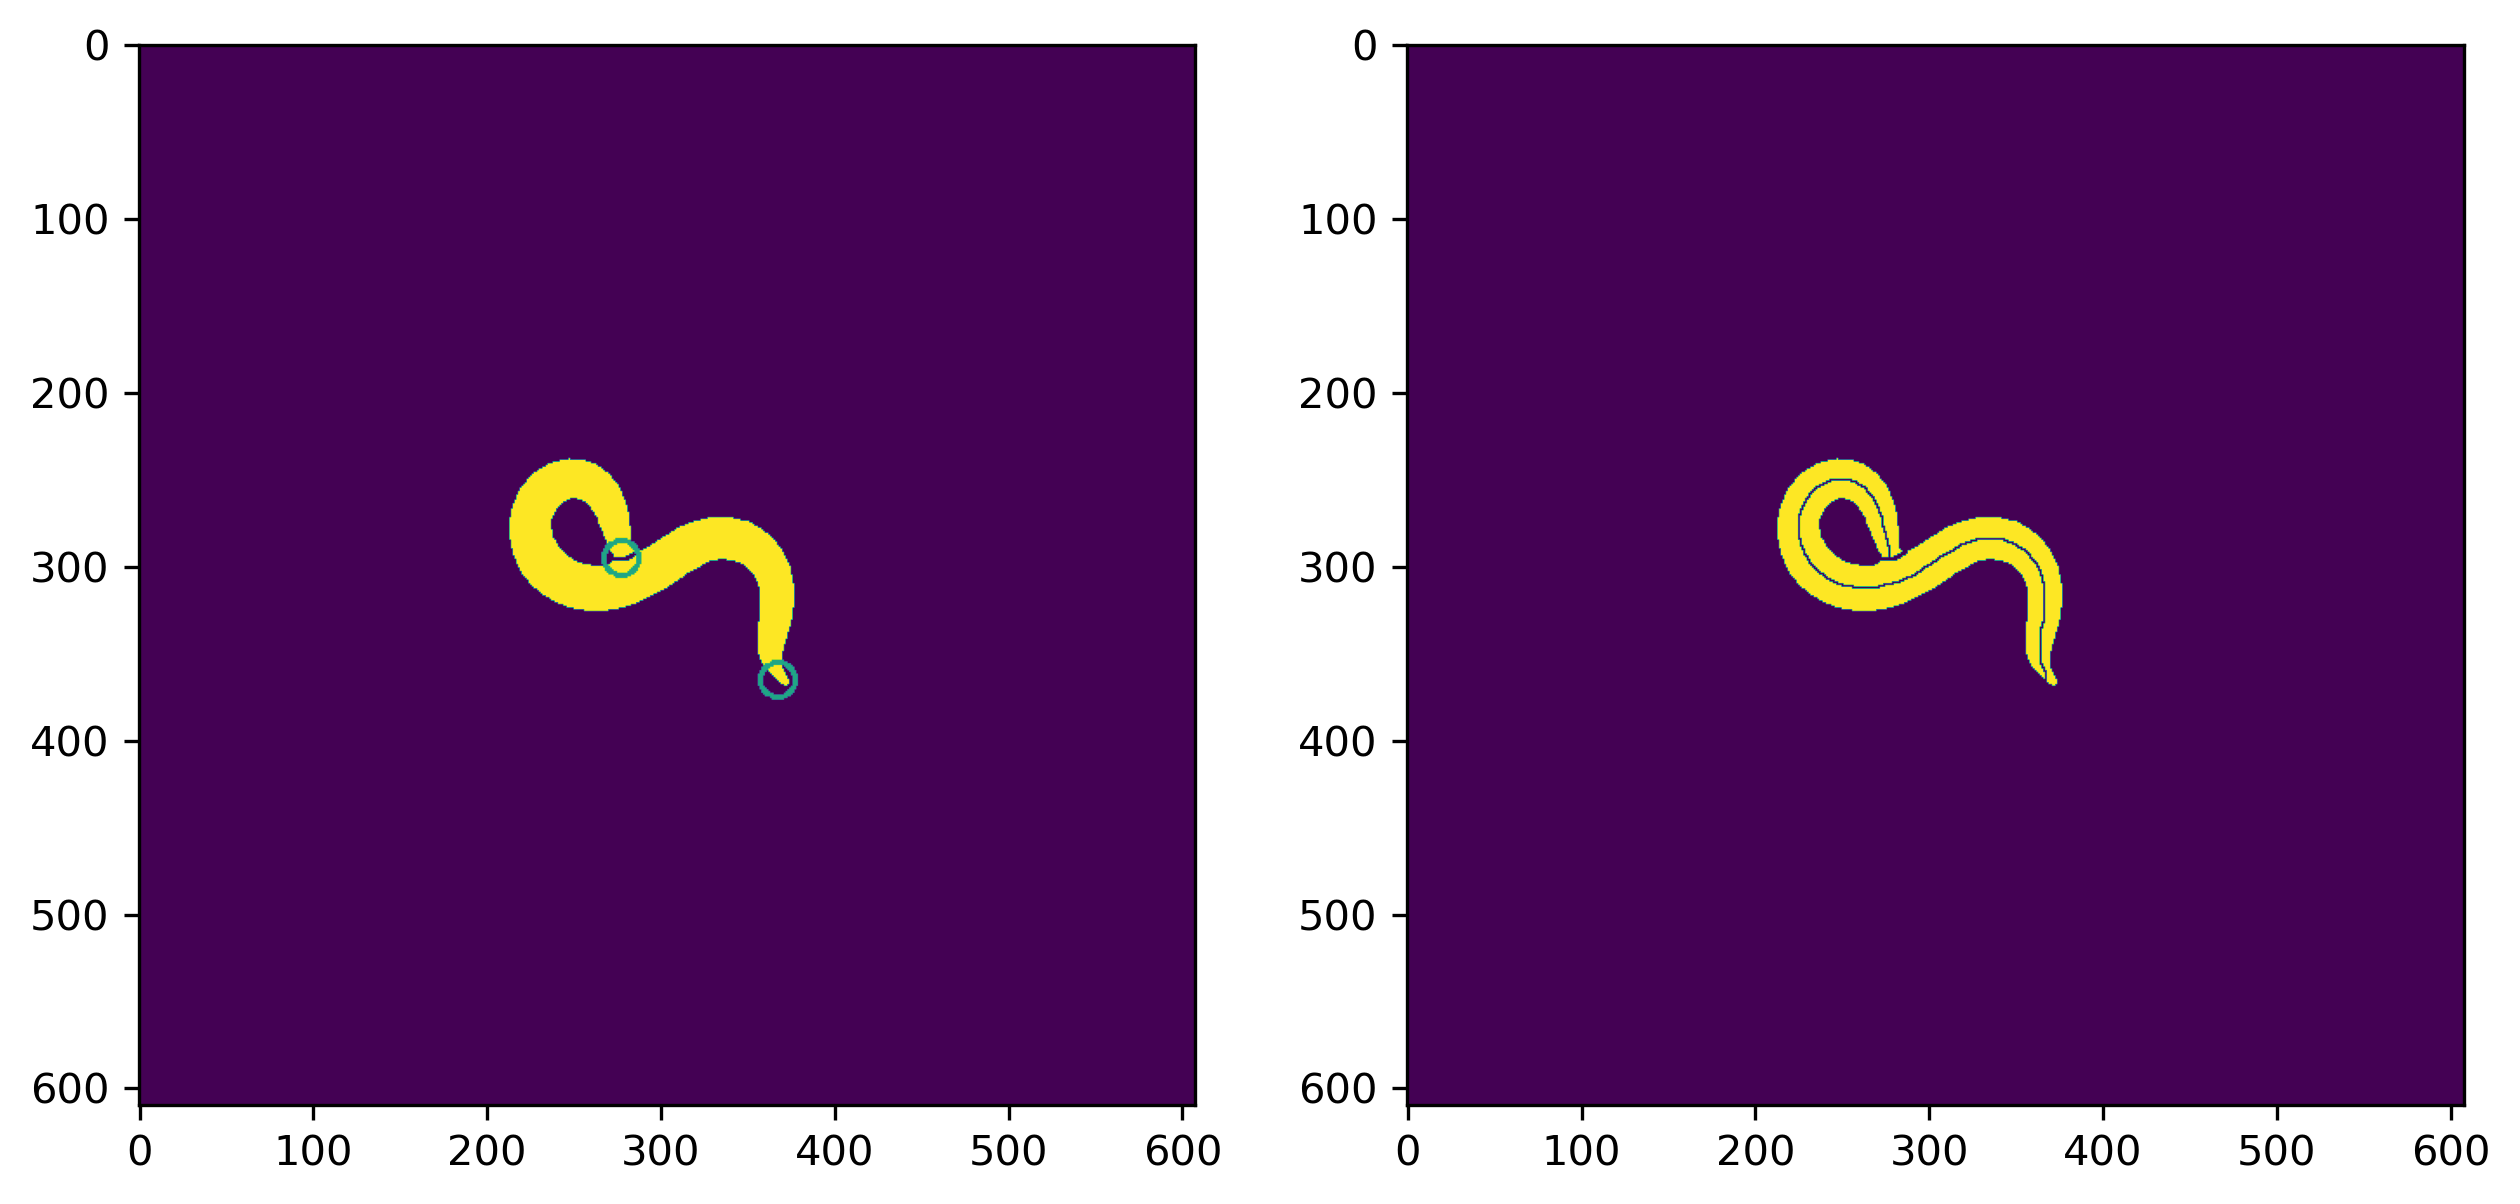

img21745.tif


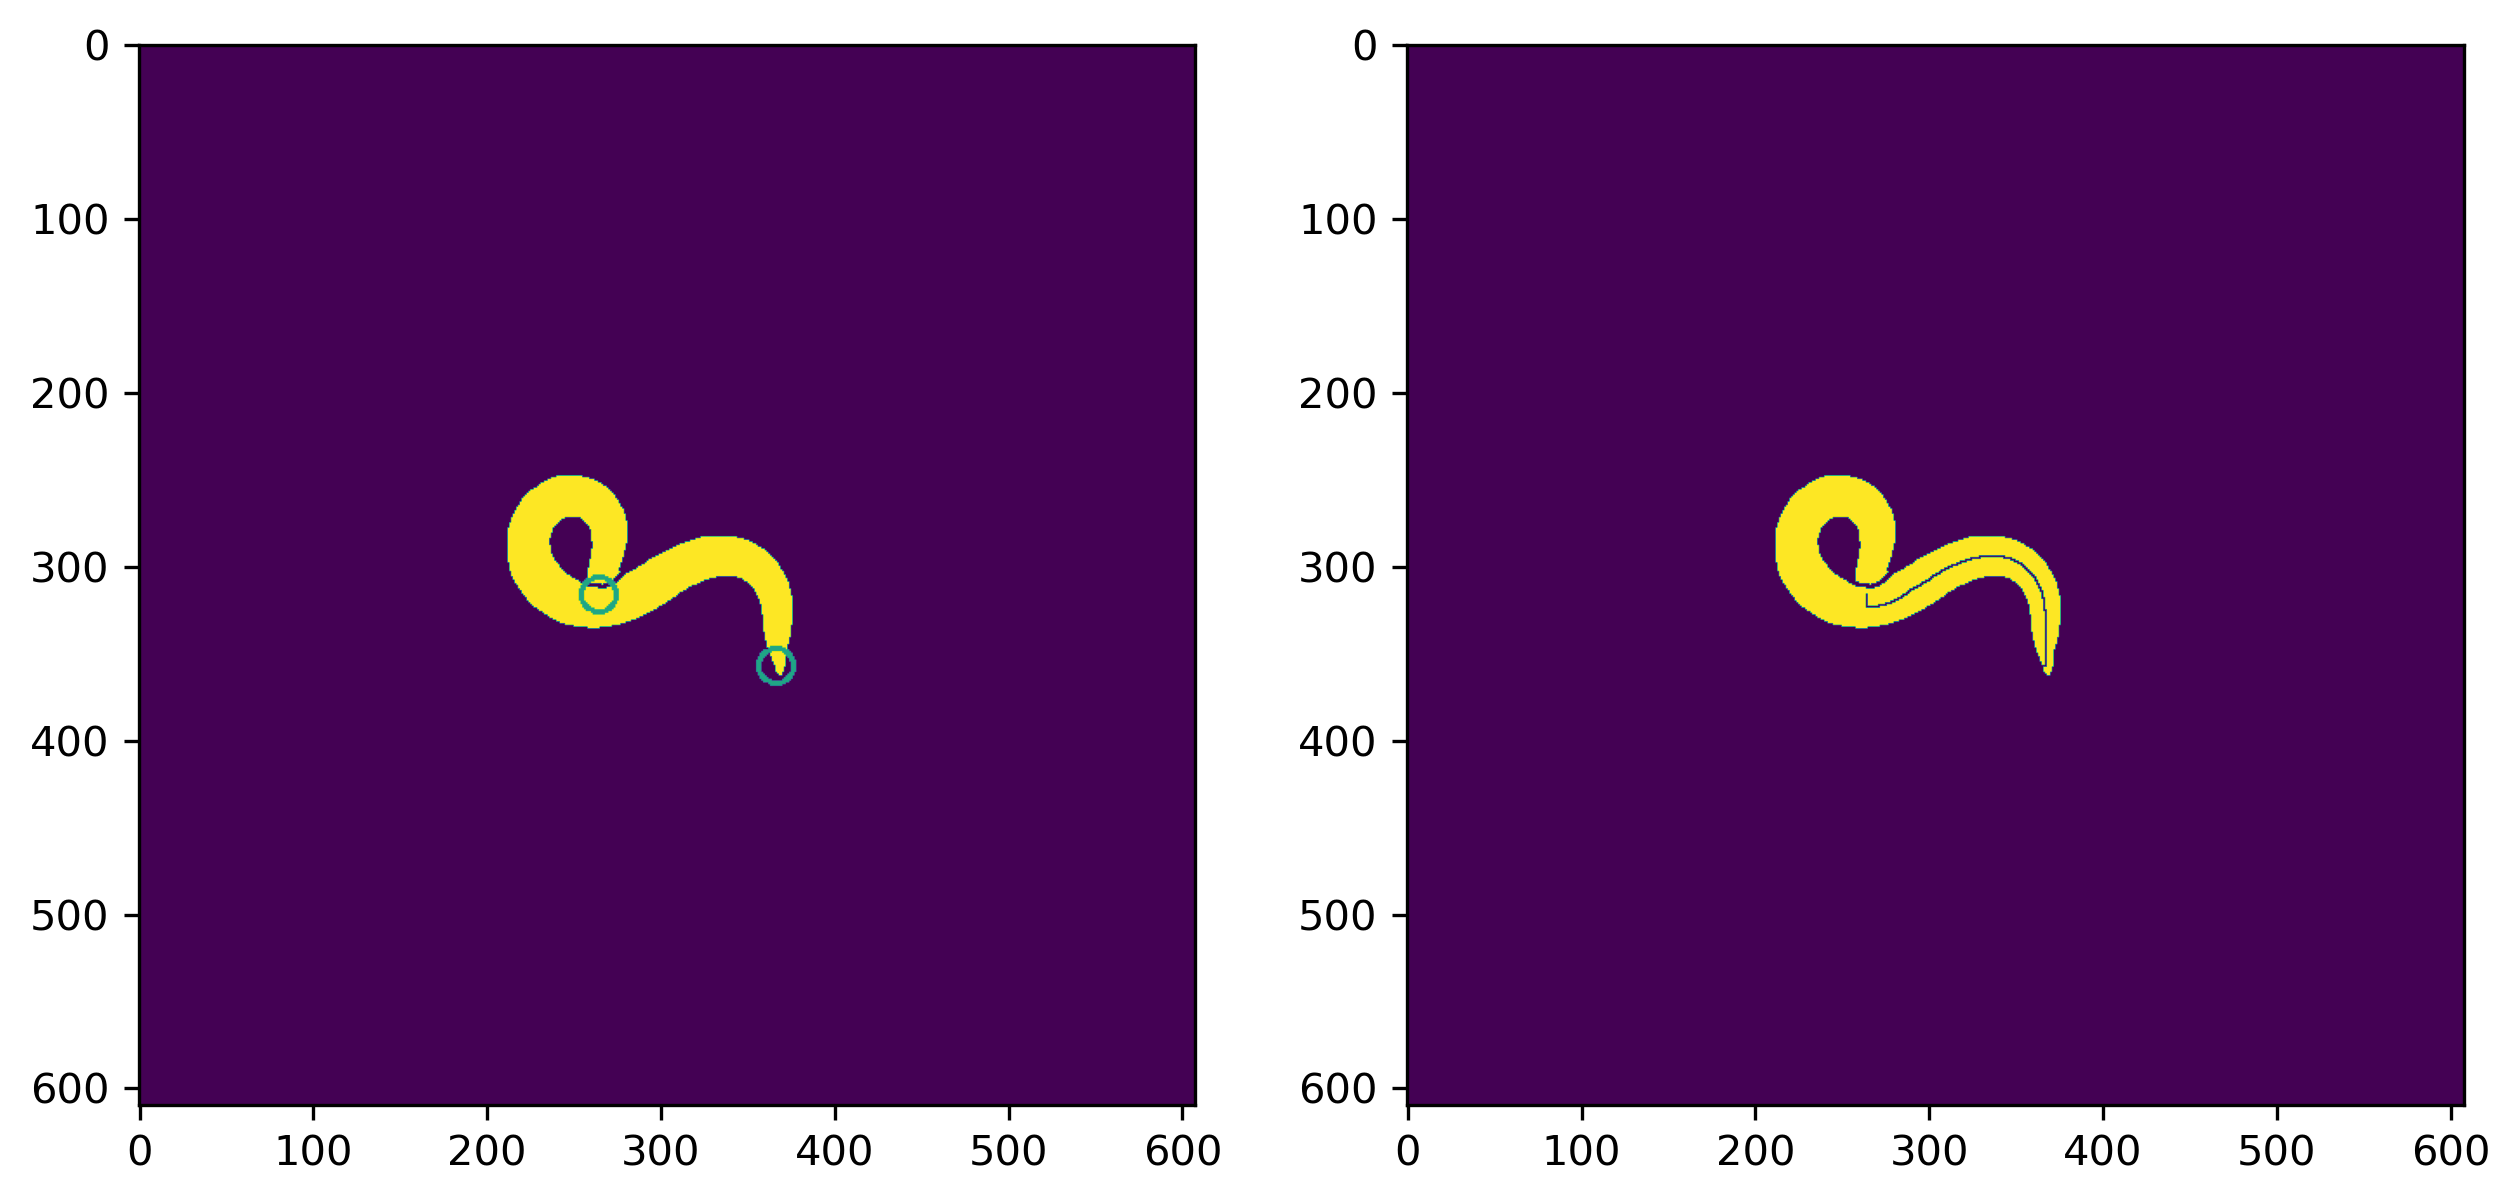

img21775.tif


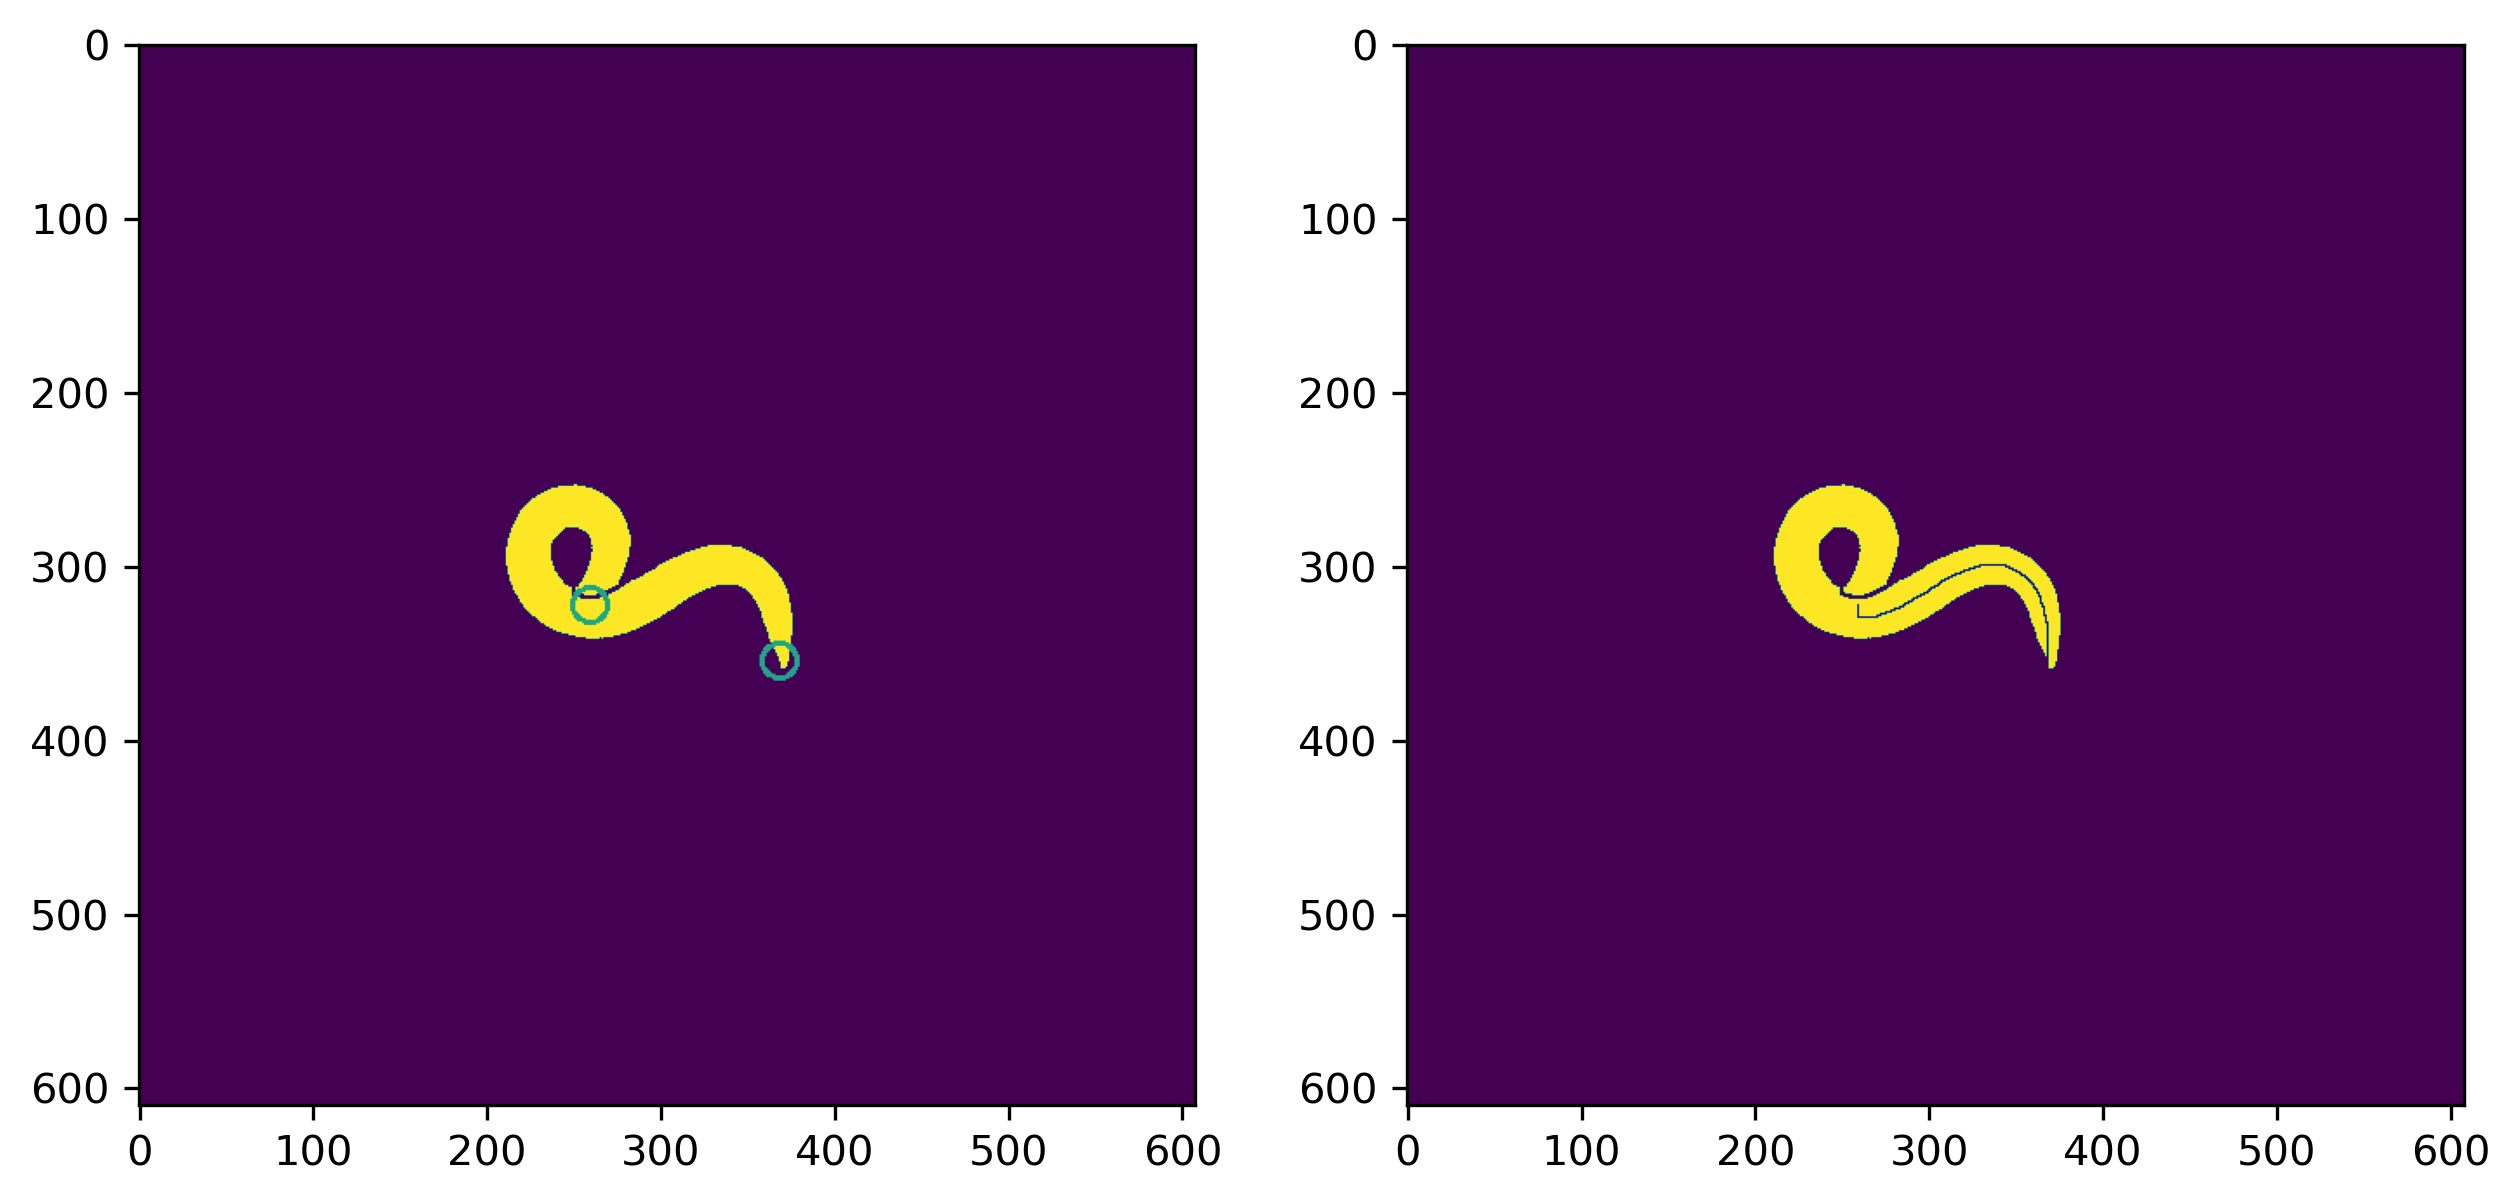

img21805.tif


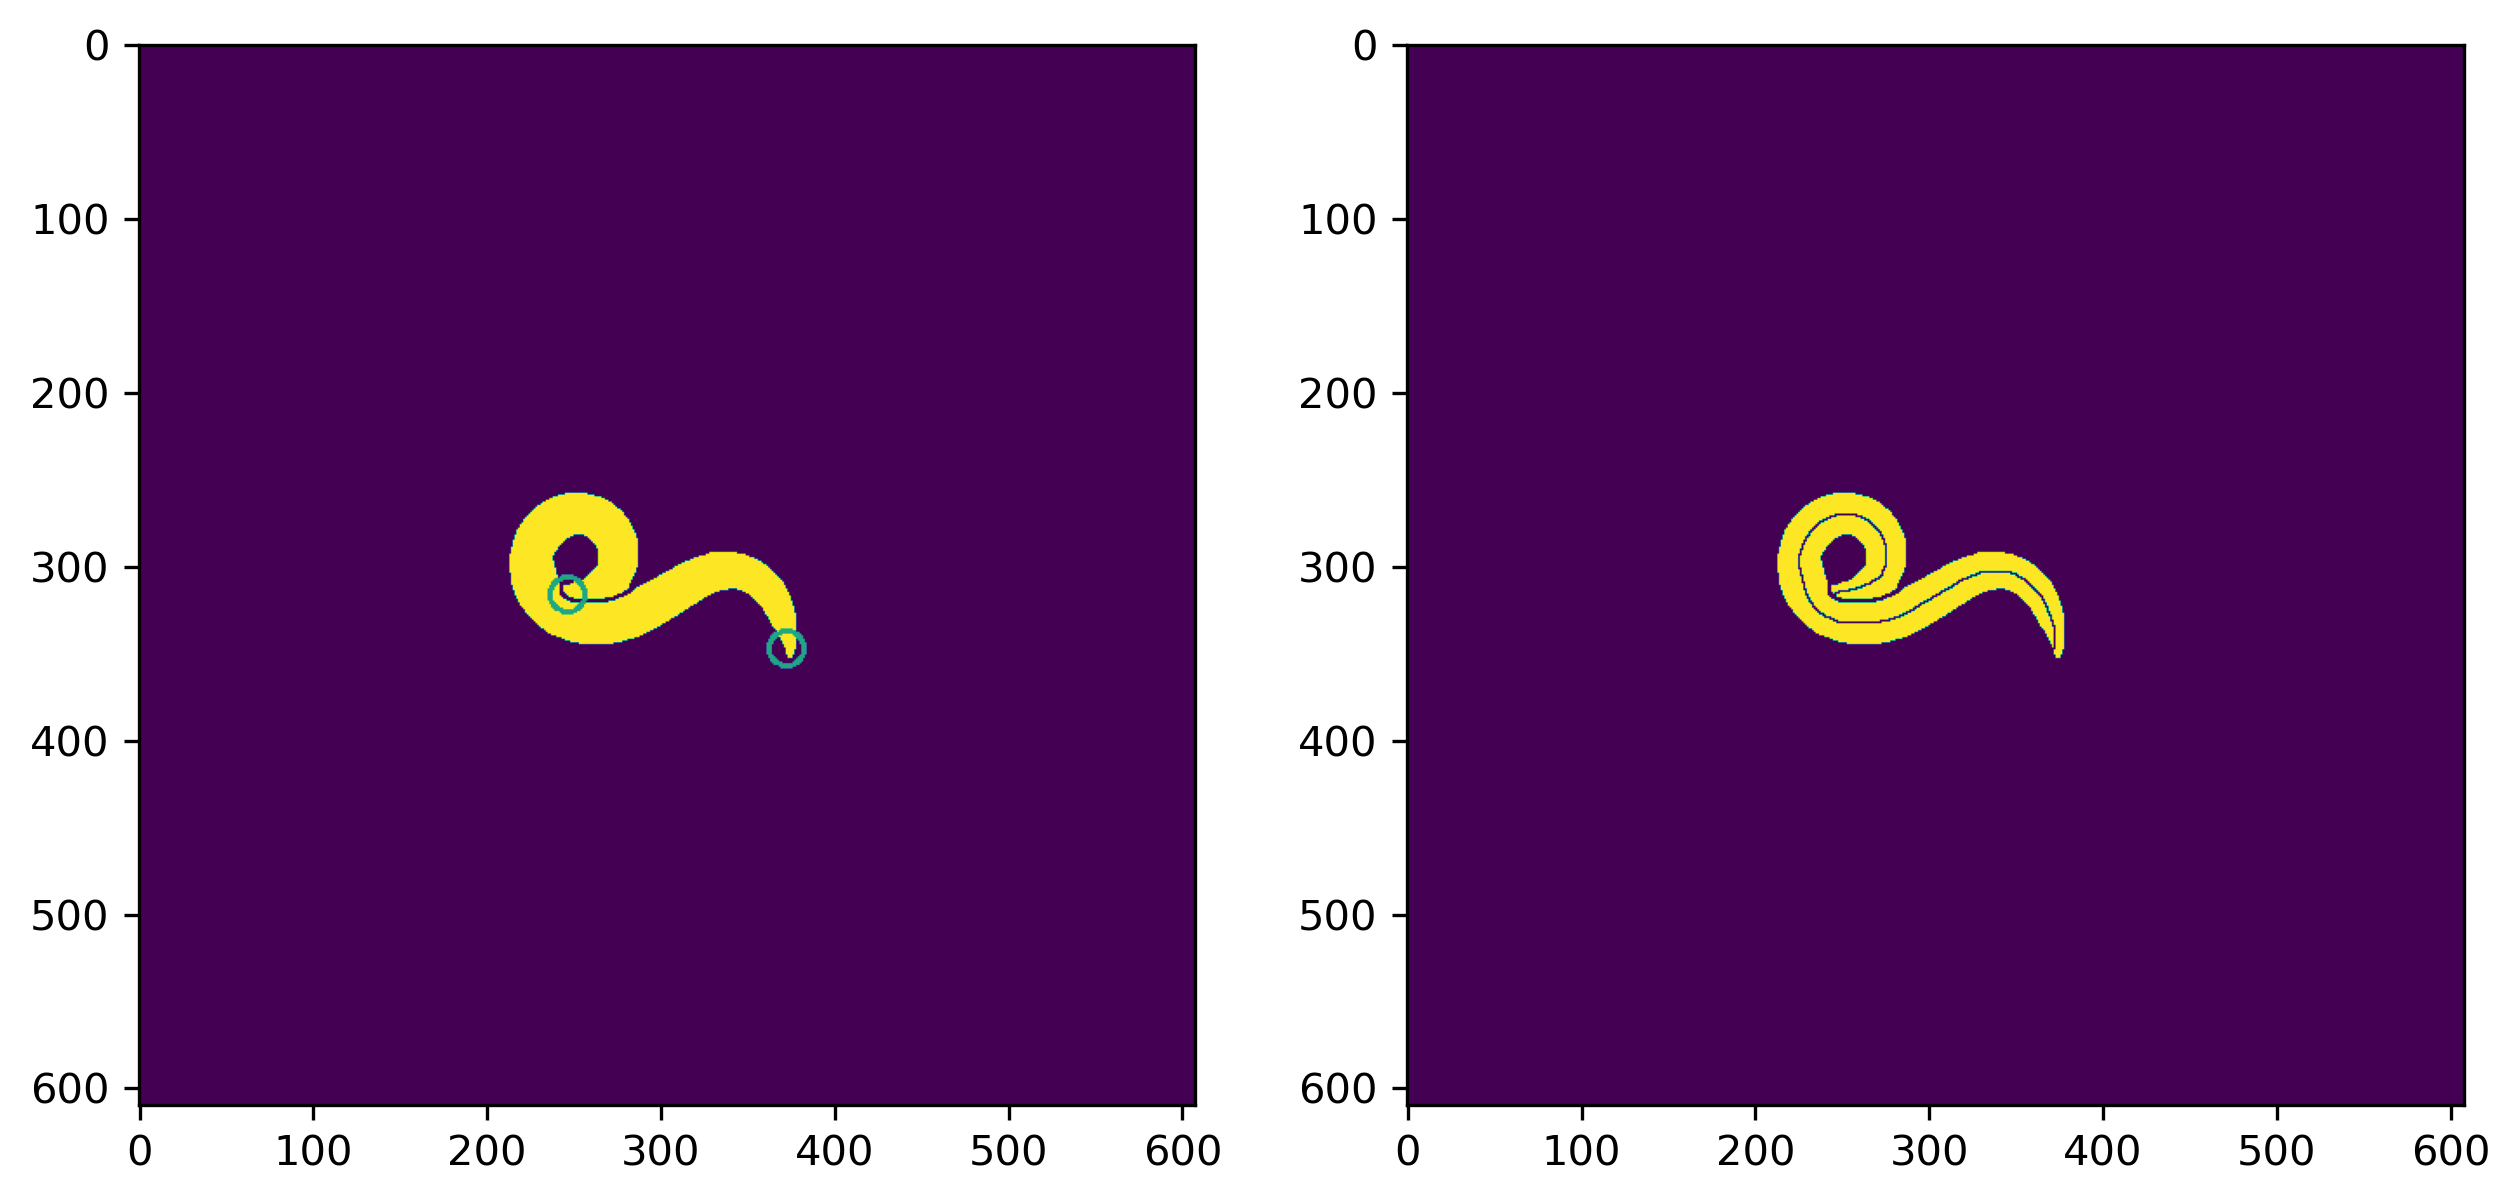

img21834.tif


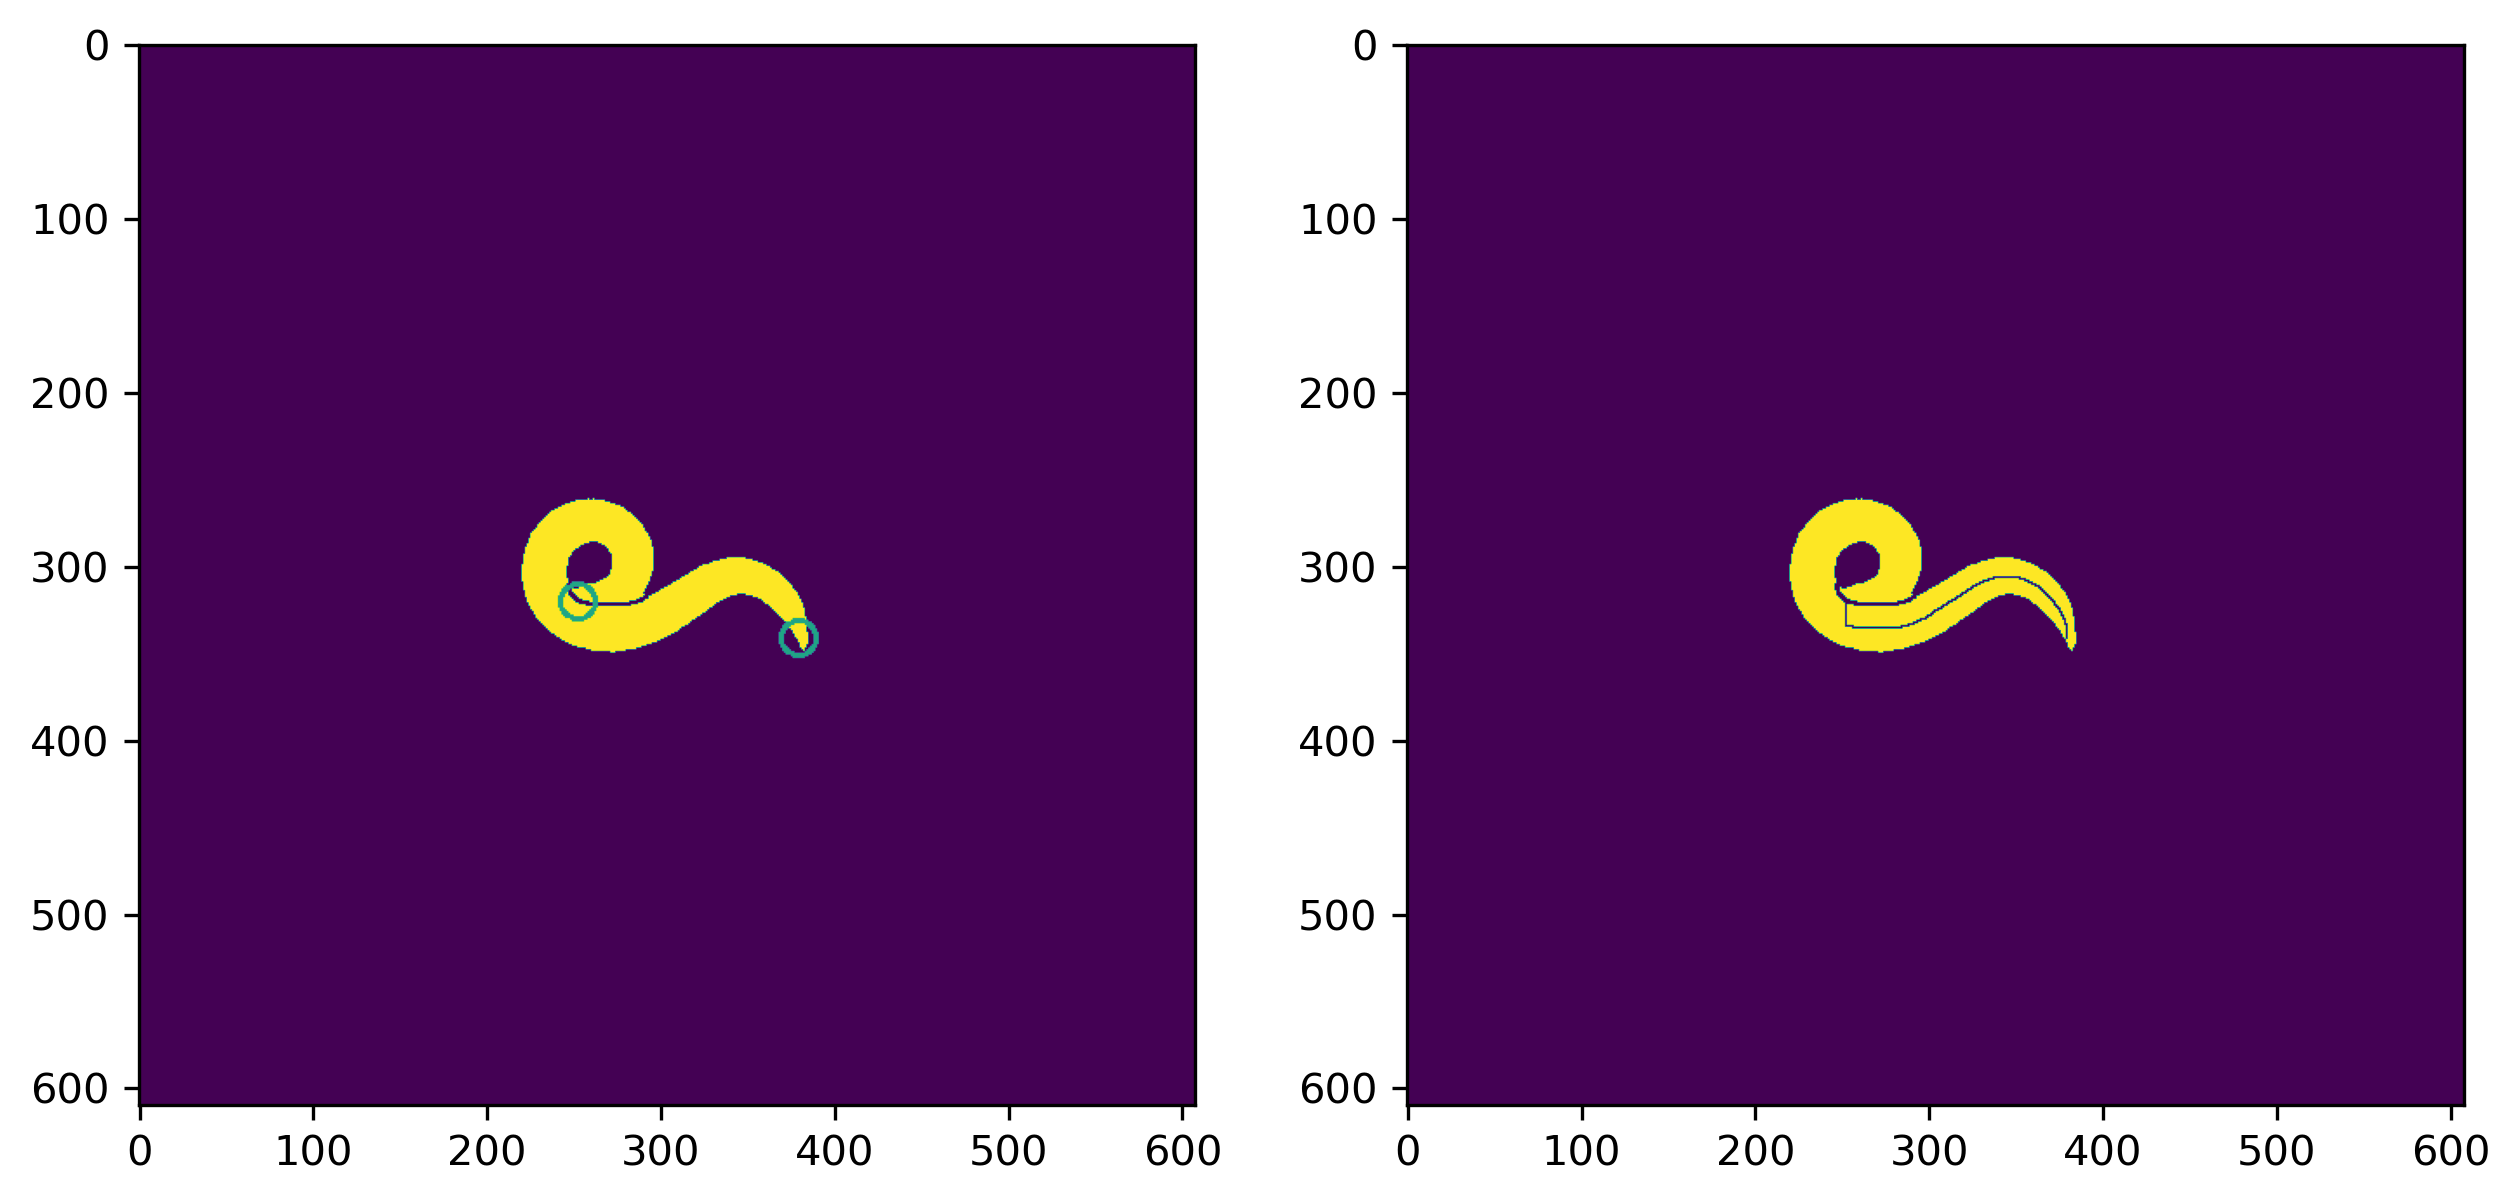

img21901.tif


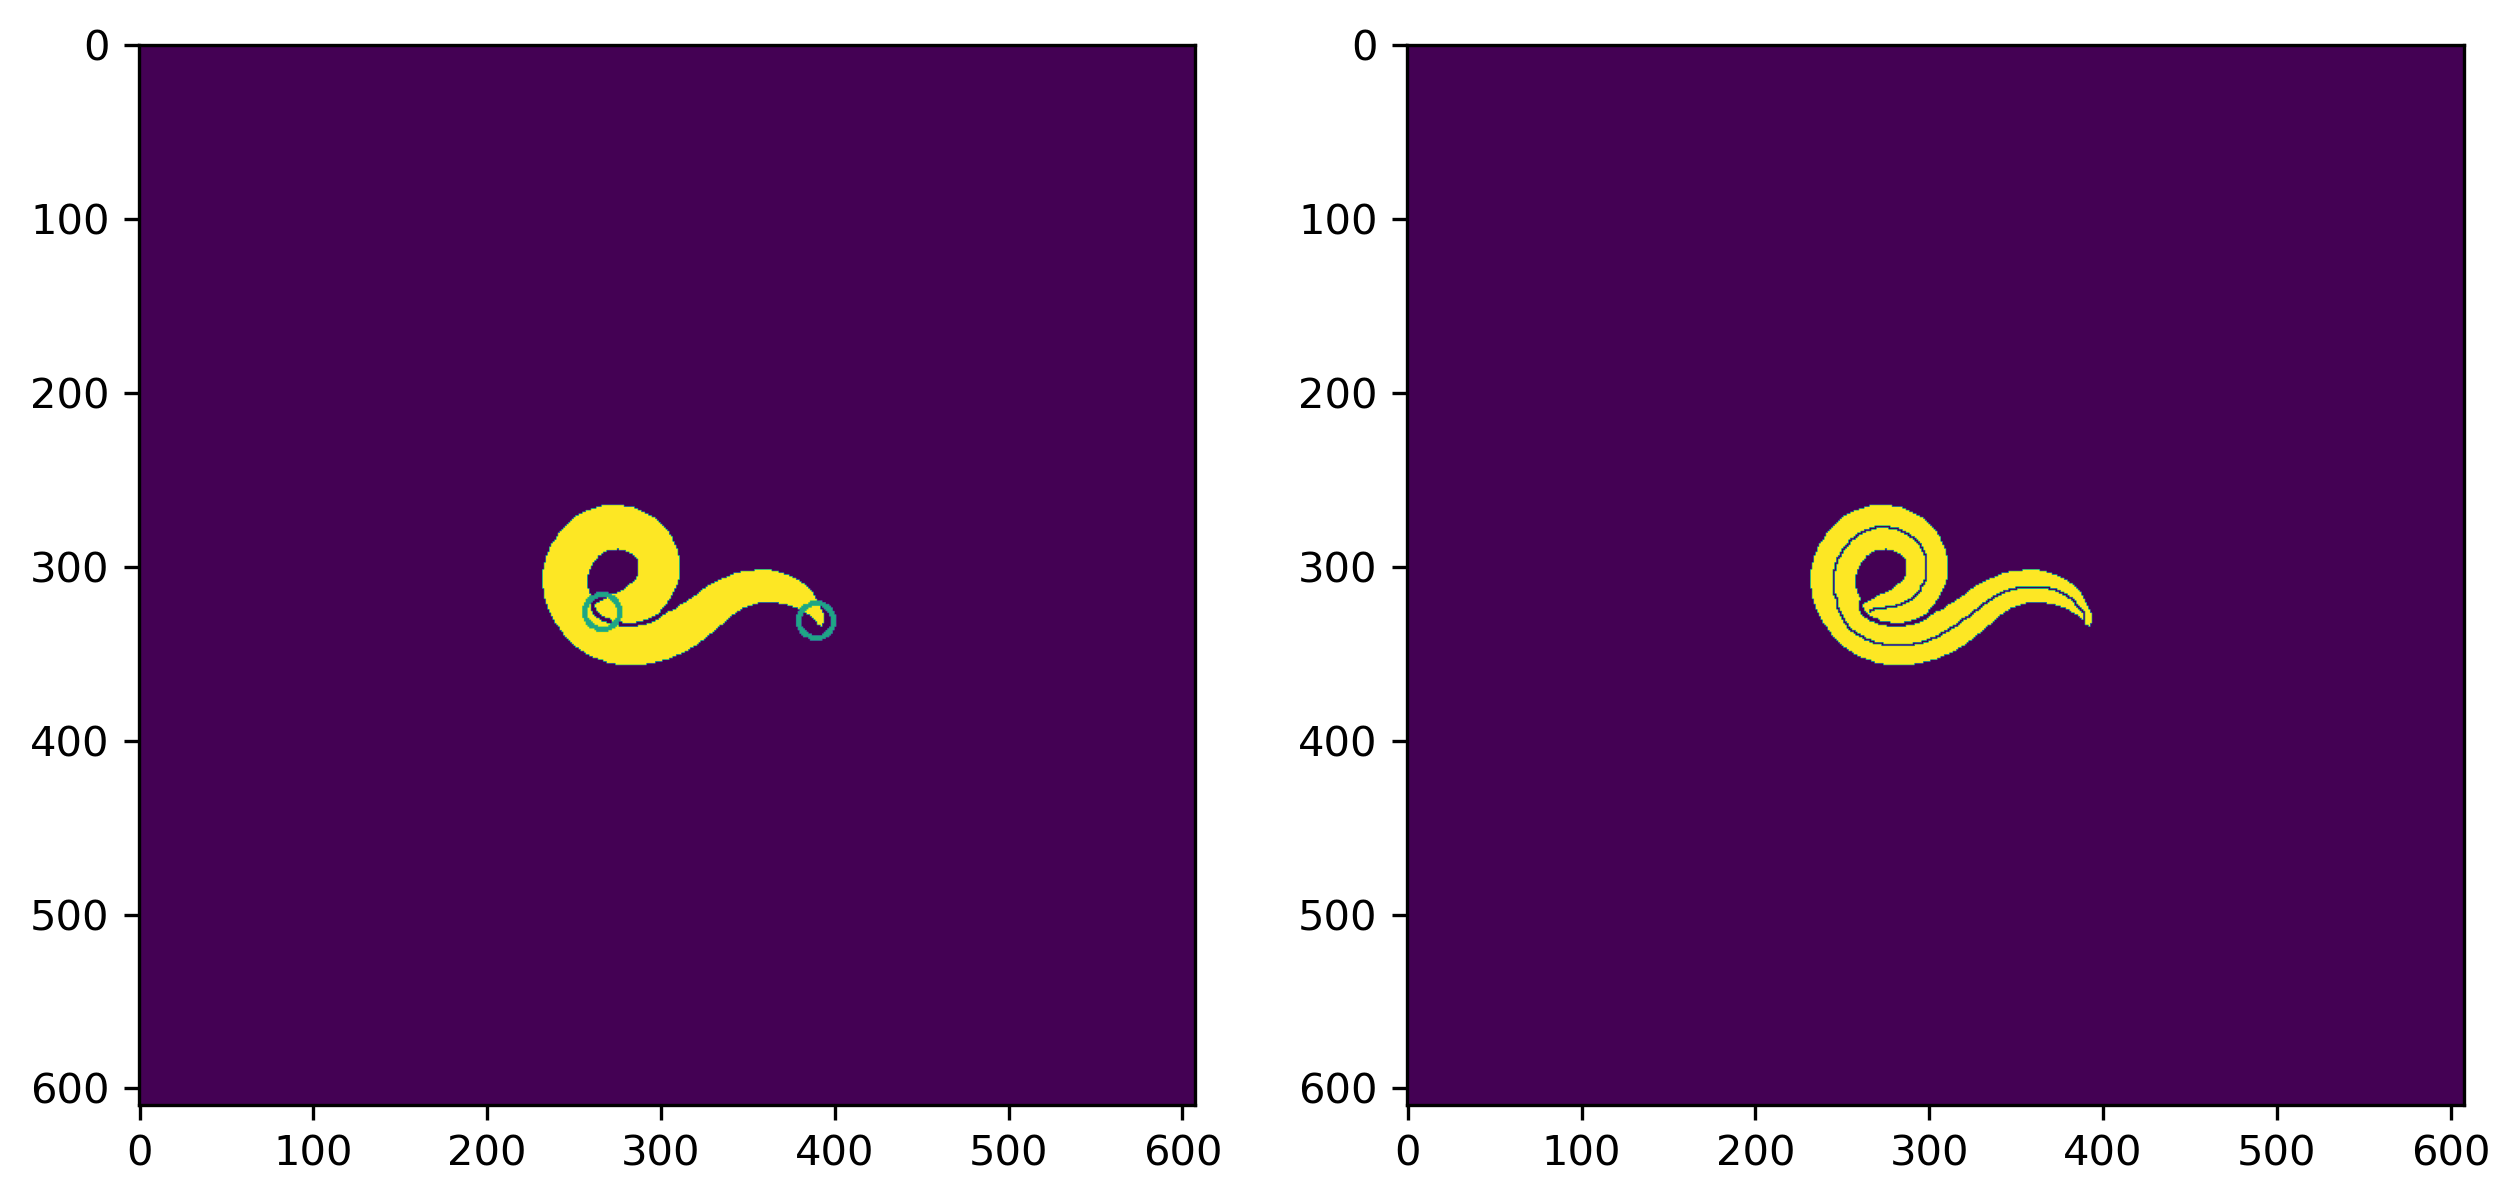

img21944.tif


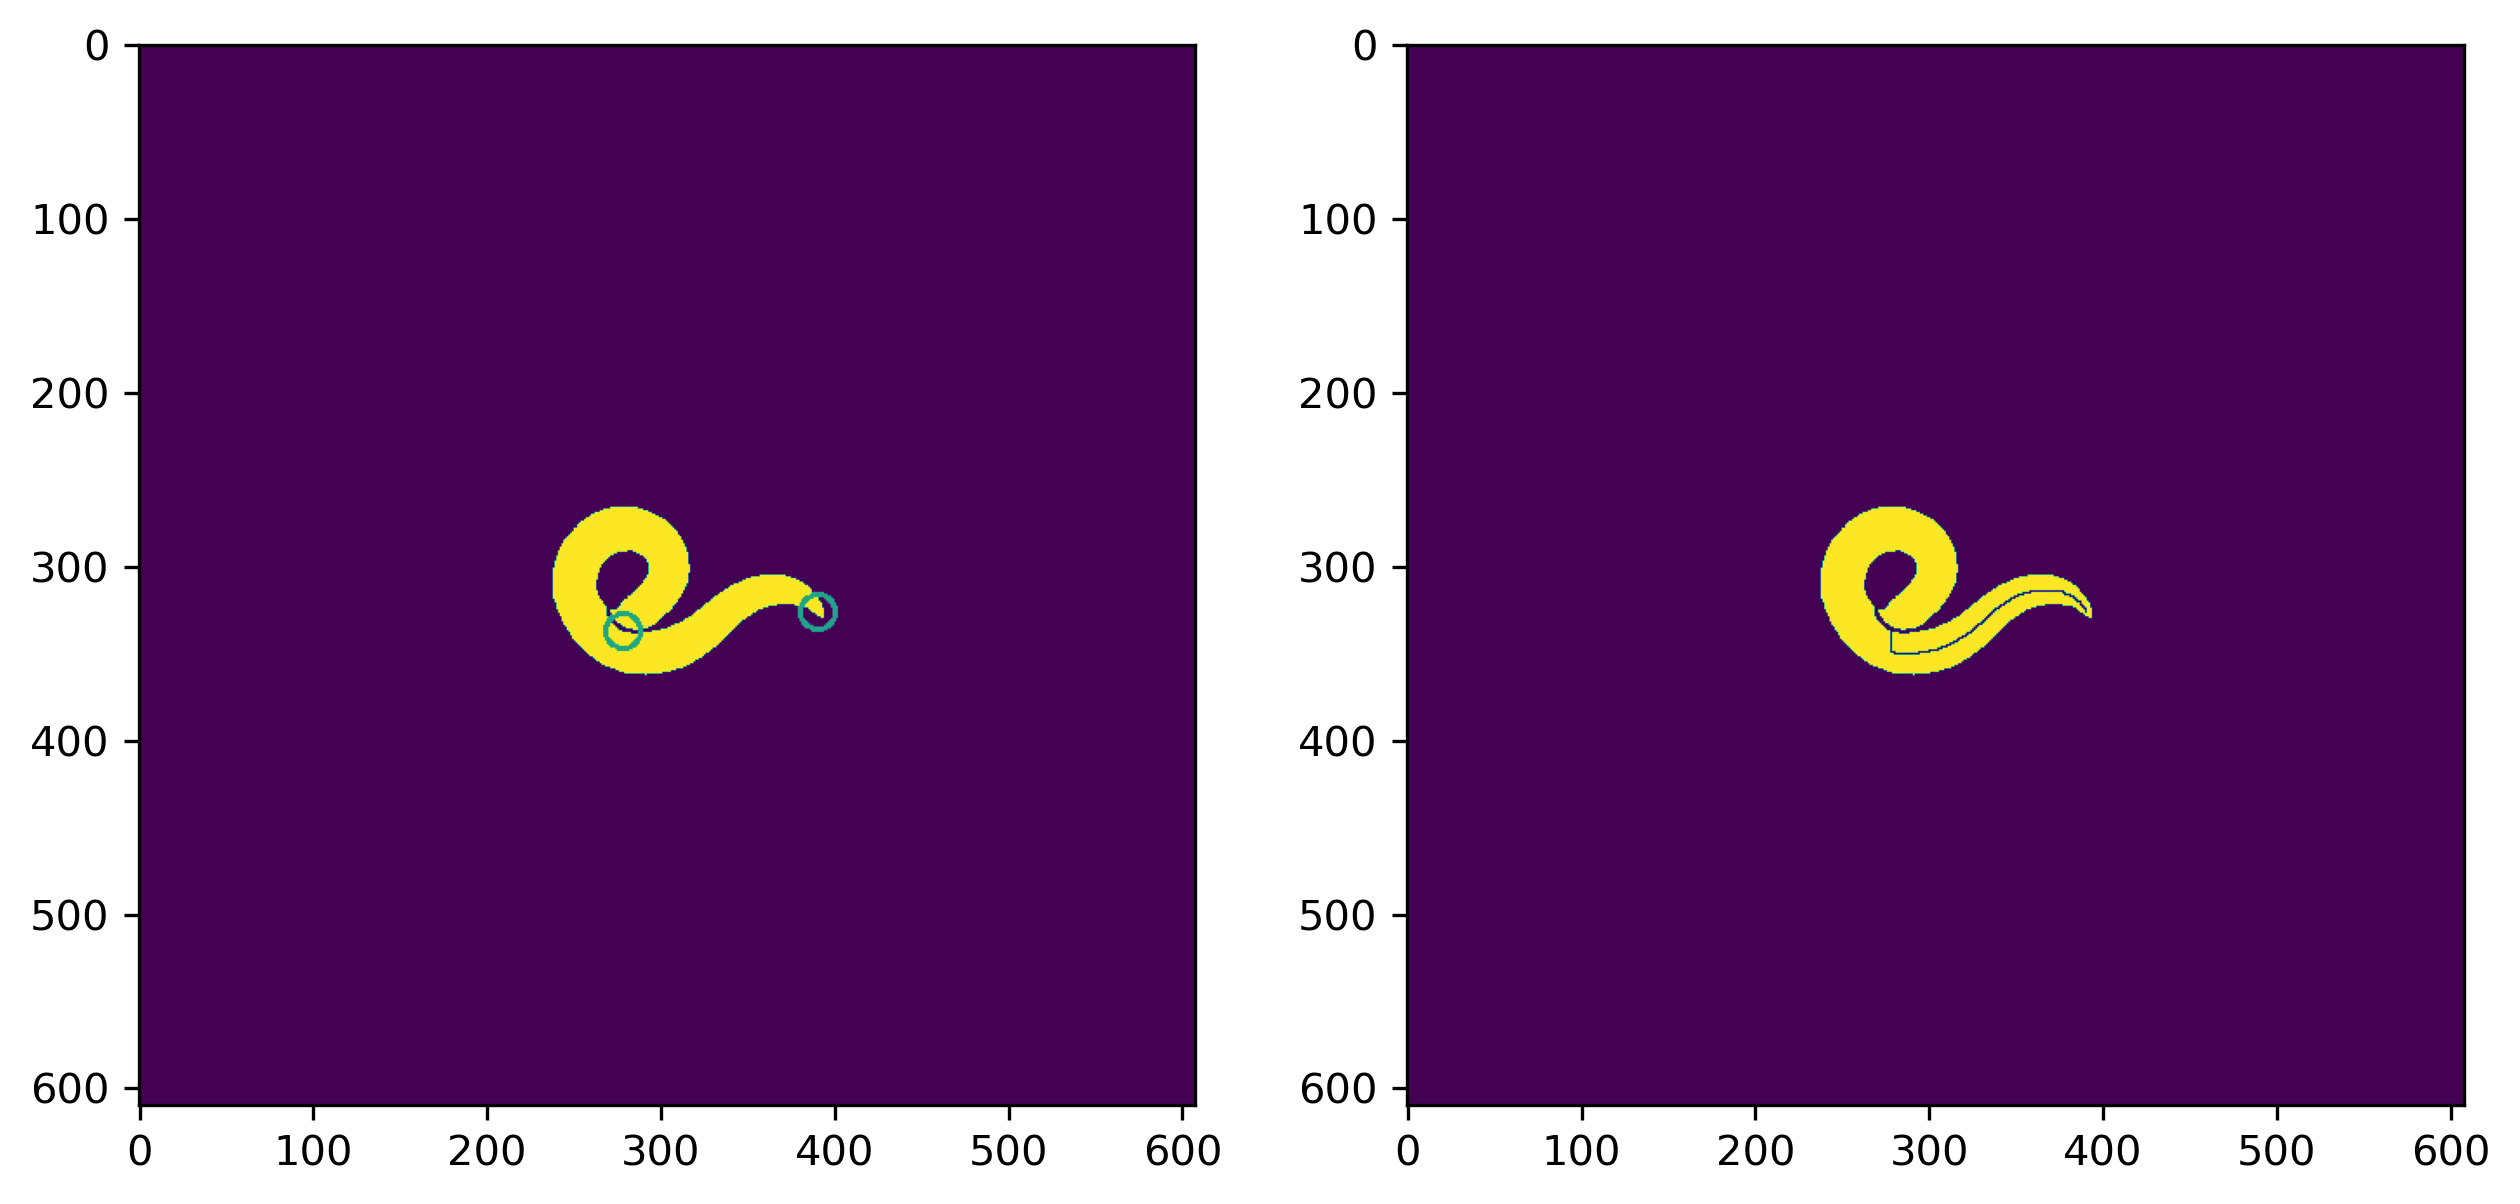

img21966.tif


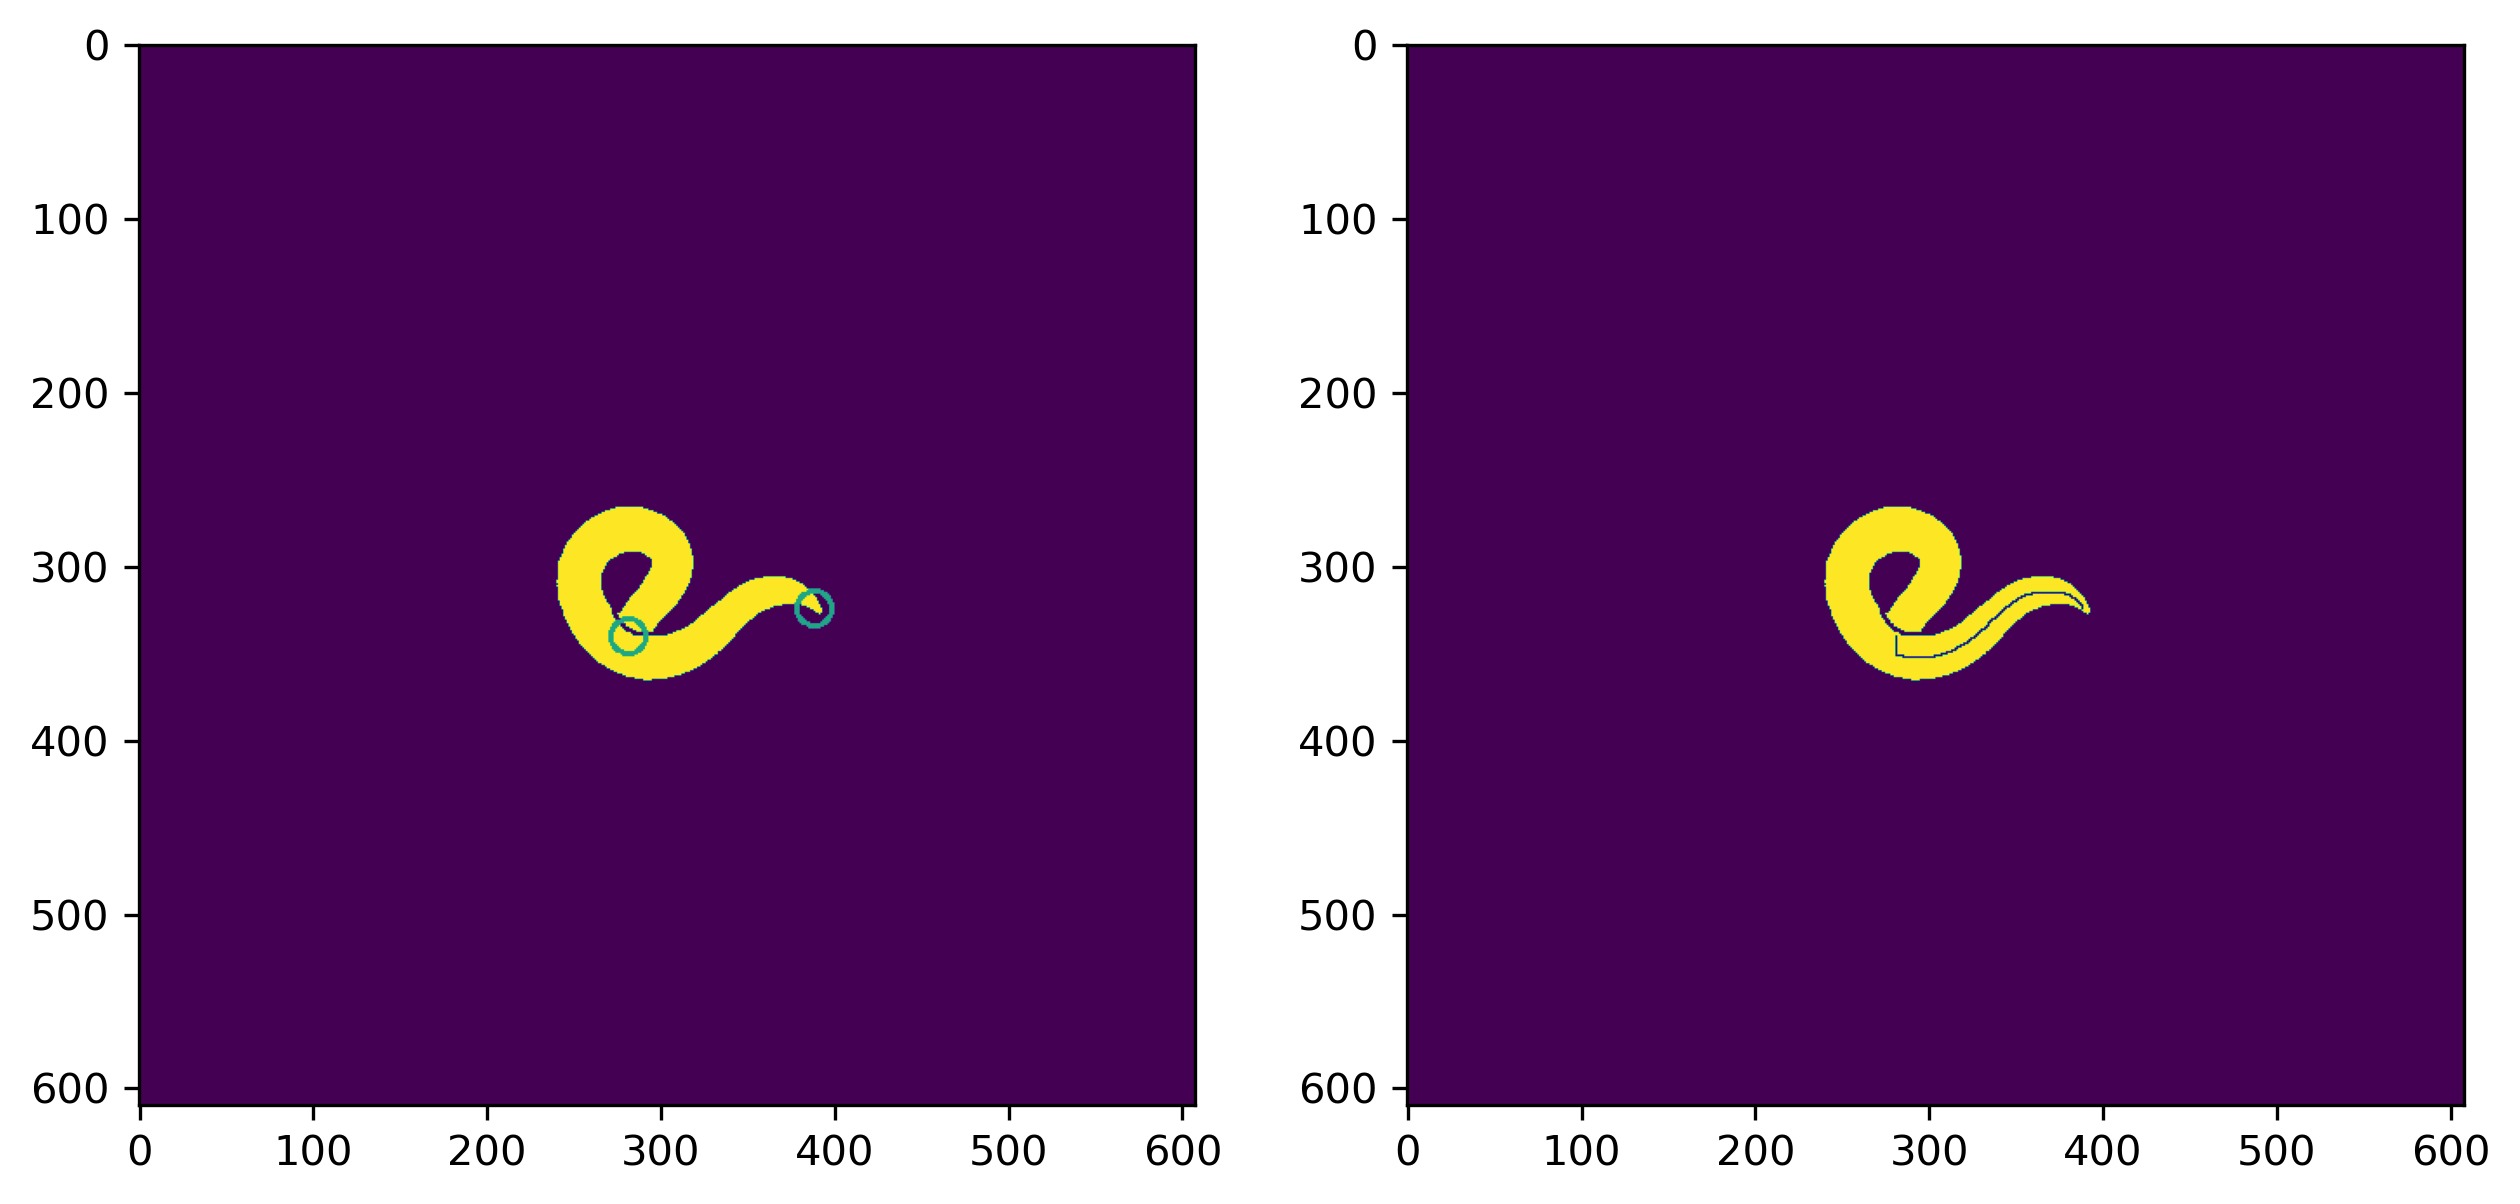

img21974.tif


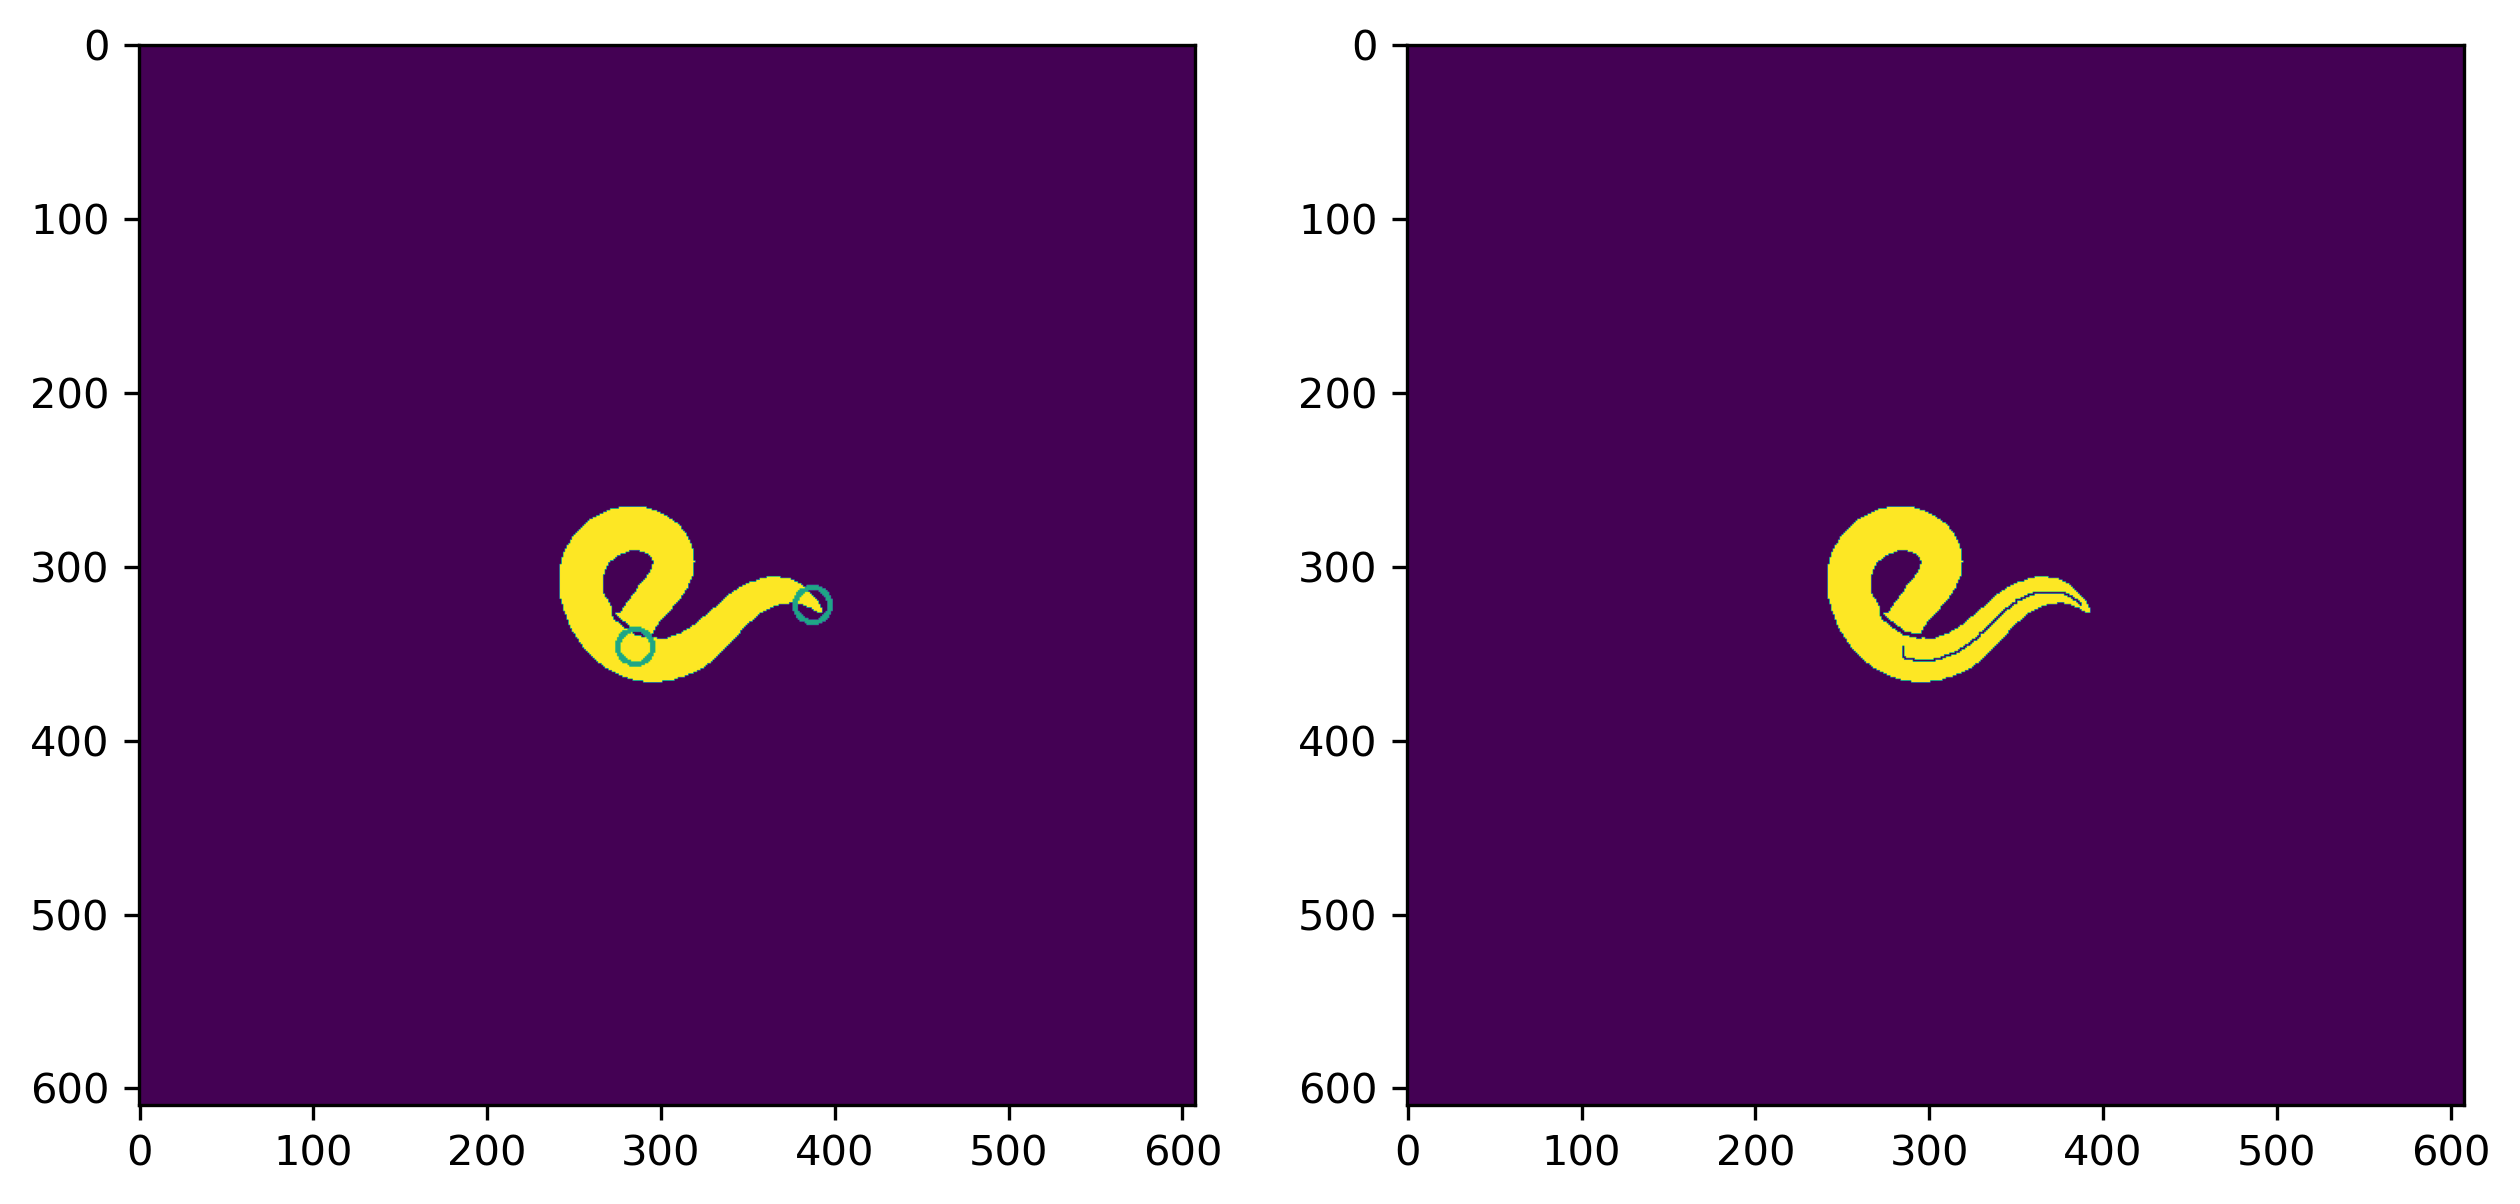

img22015.tif
head and tail were too close, no centerline could be created
img22029.tif


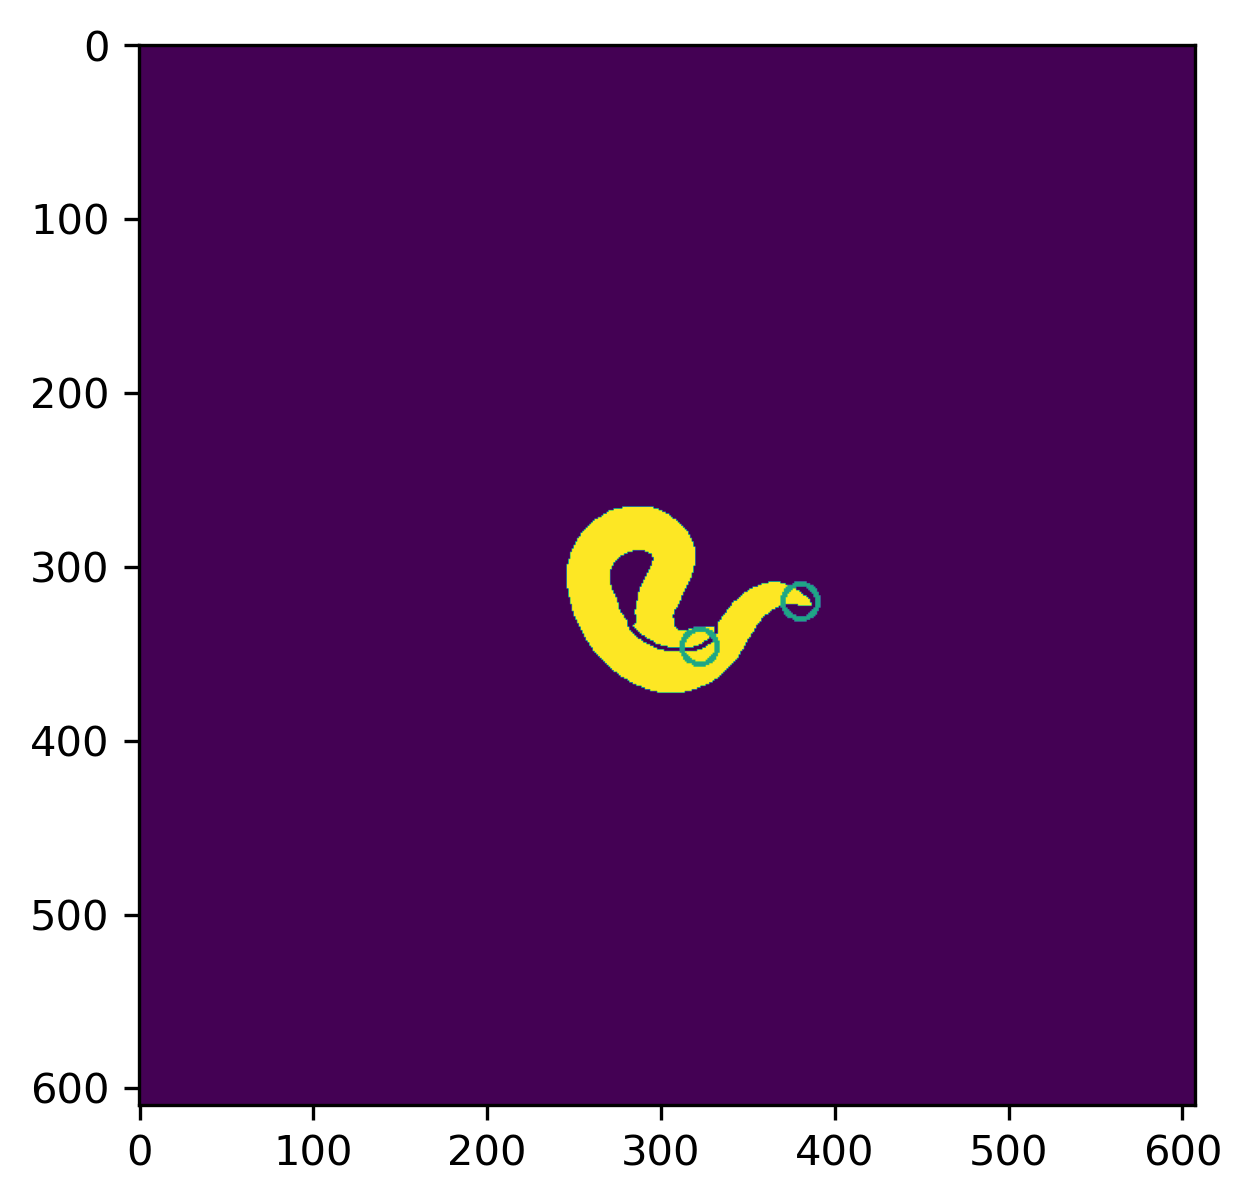

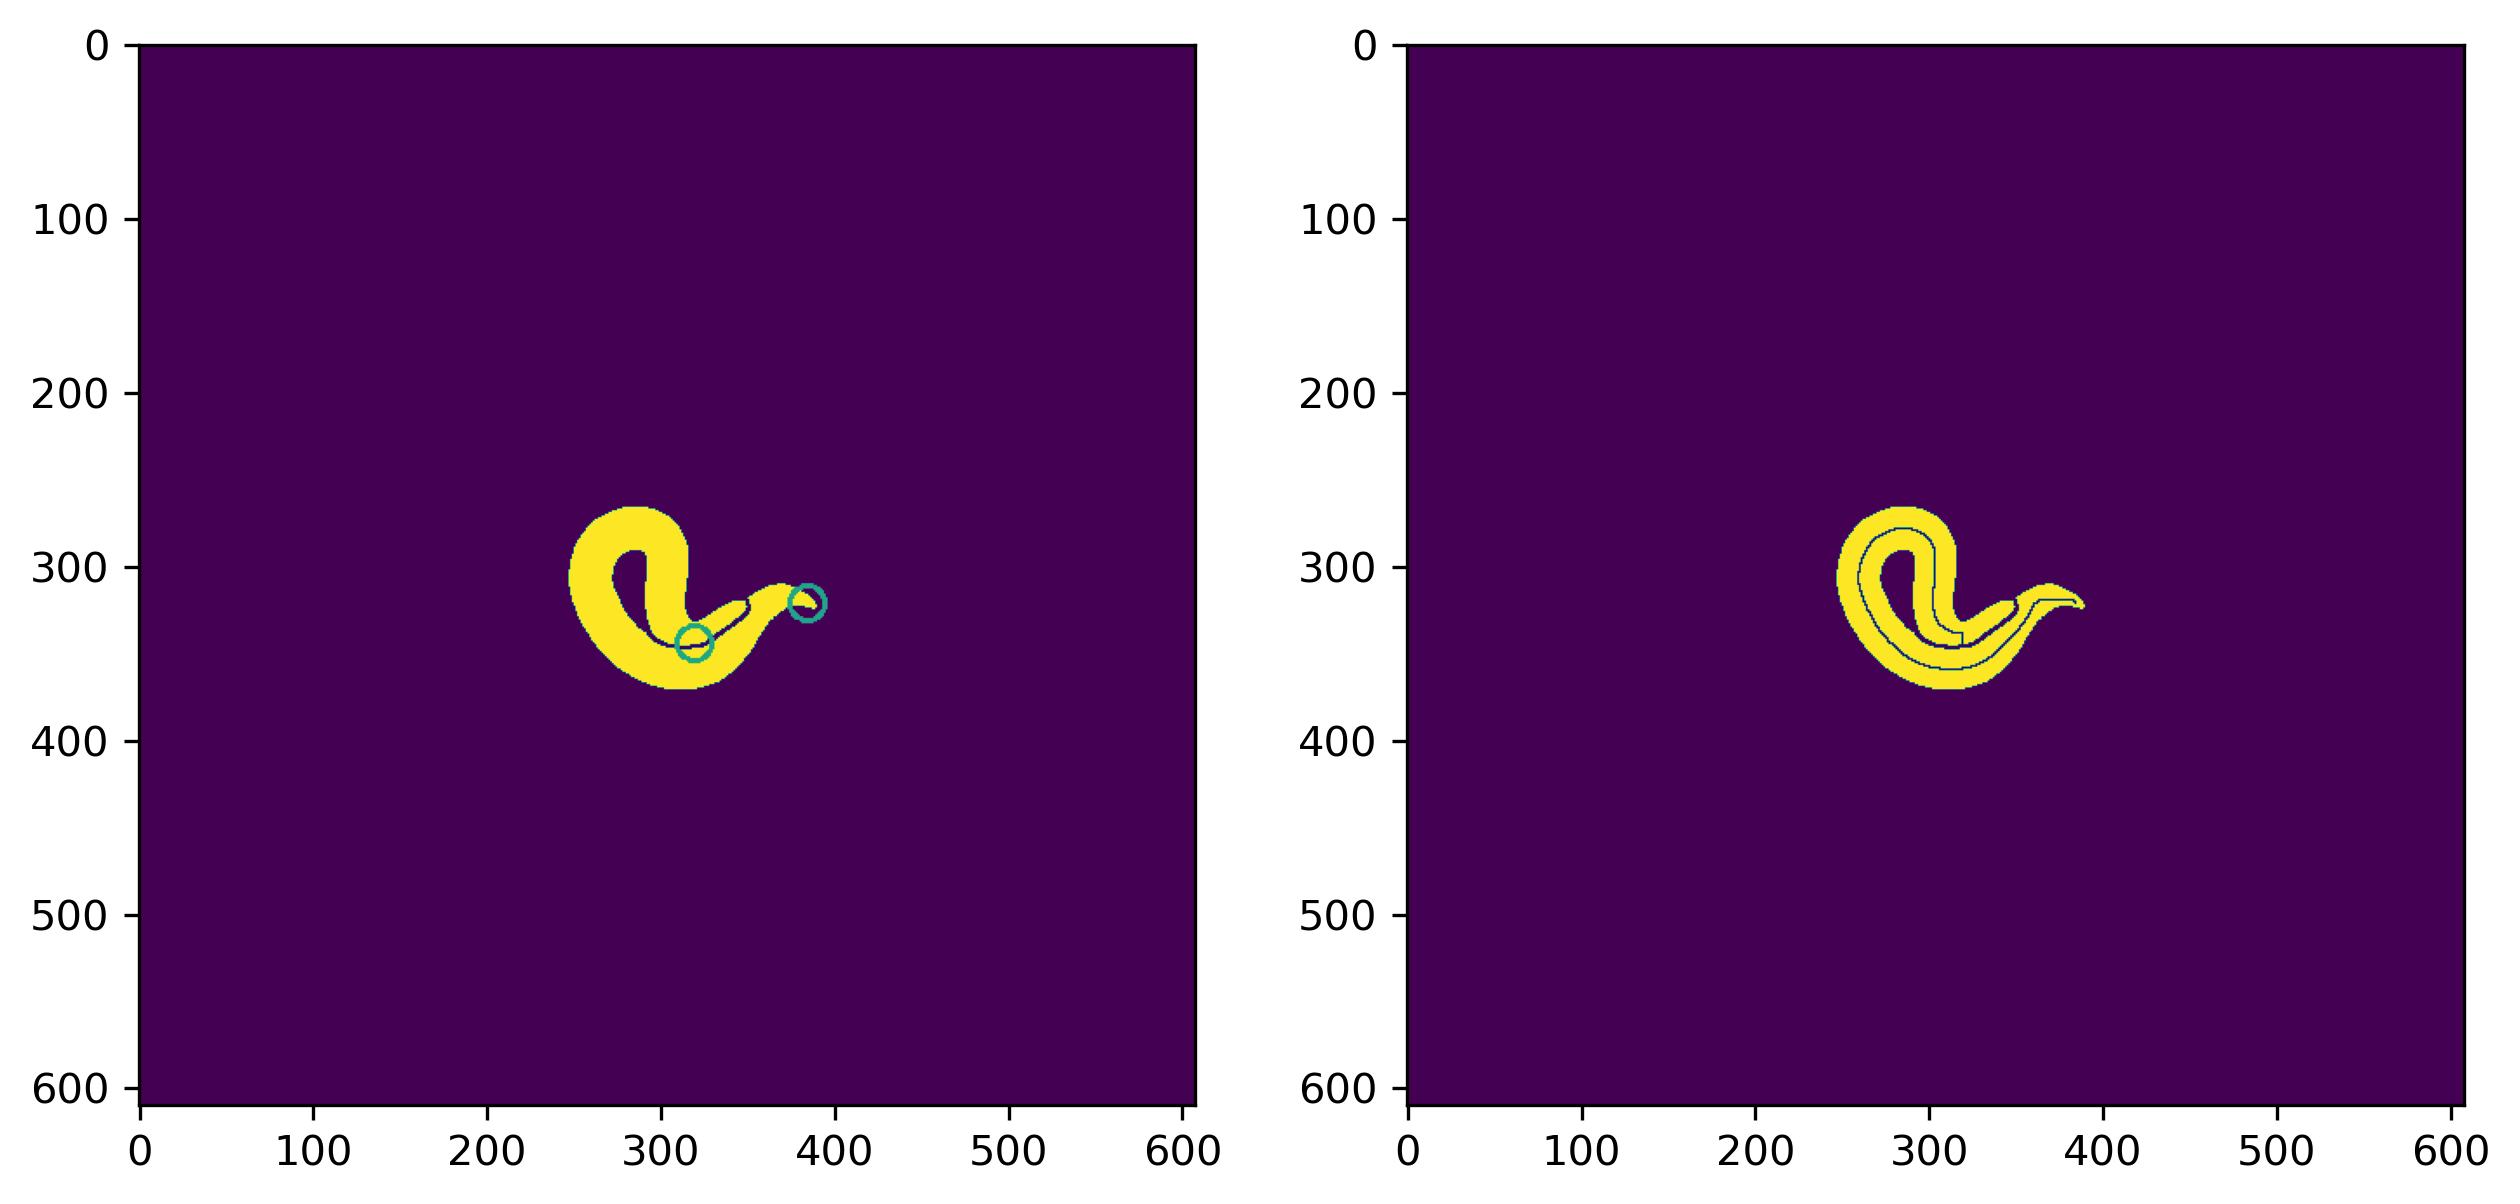

img22055.tif


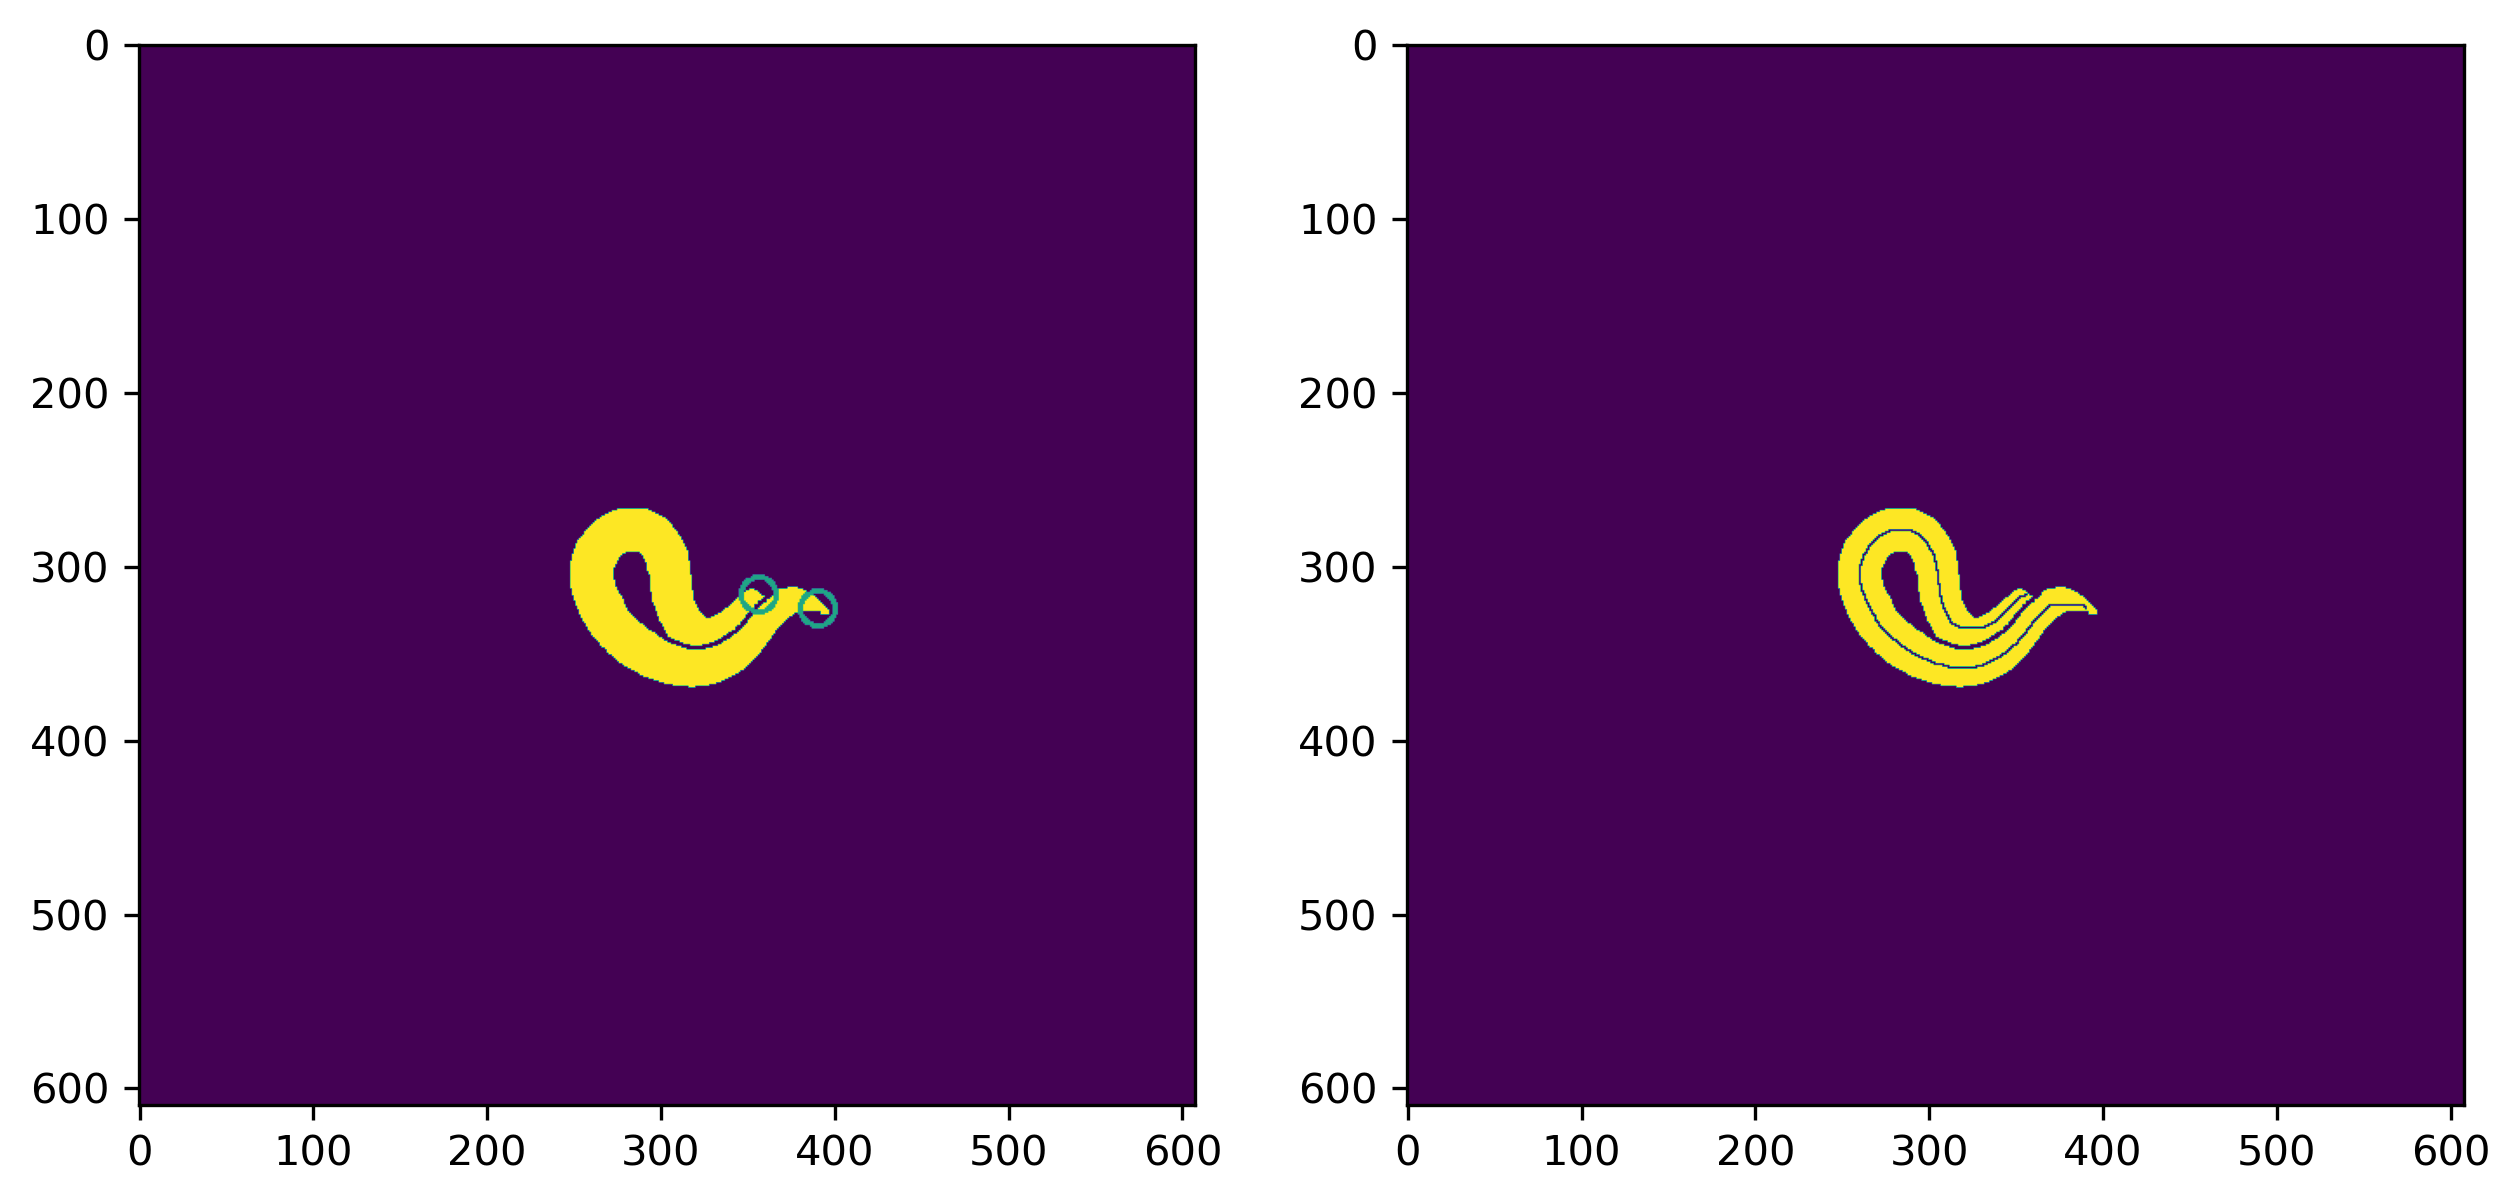

img22073.tif


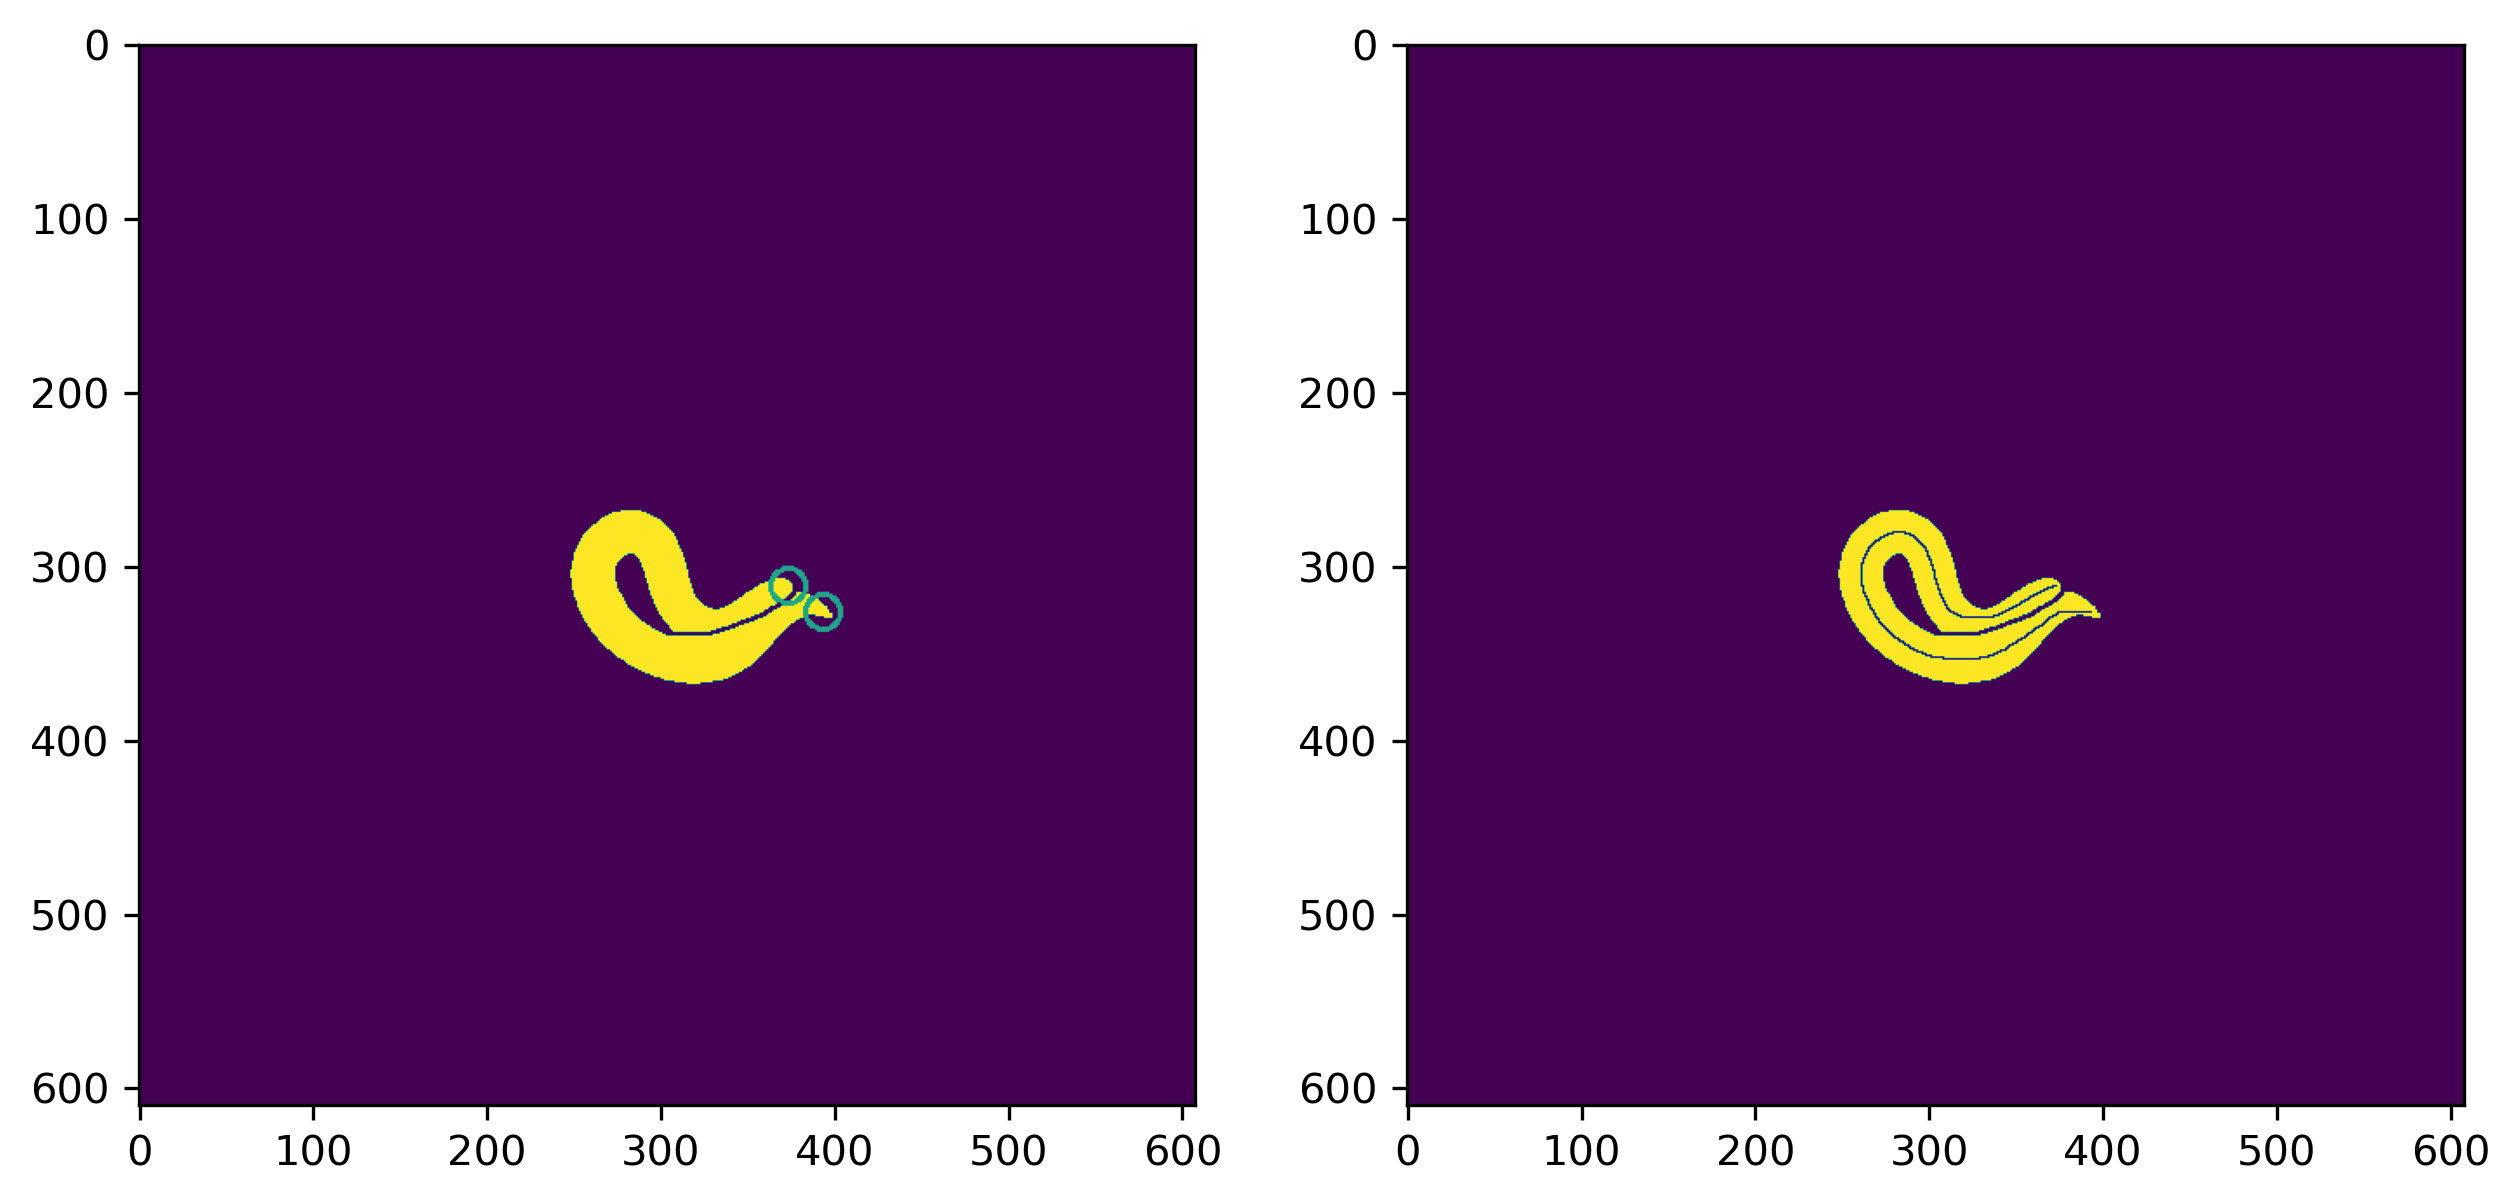

img22091.tif


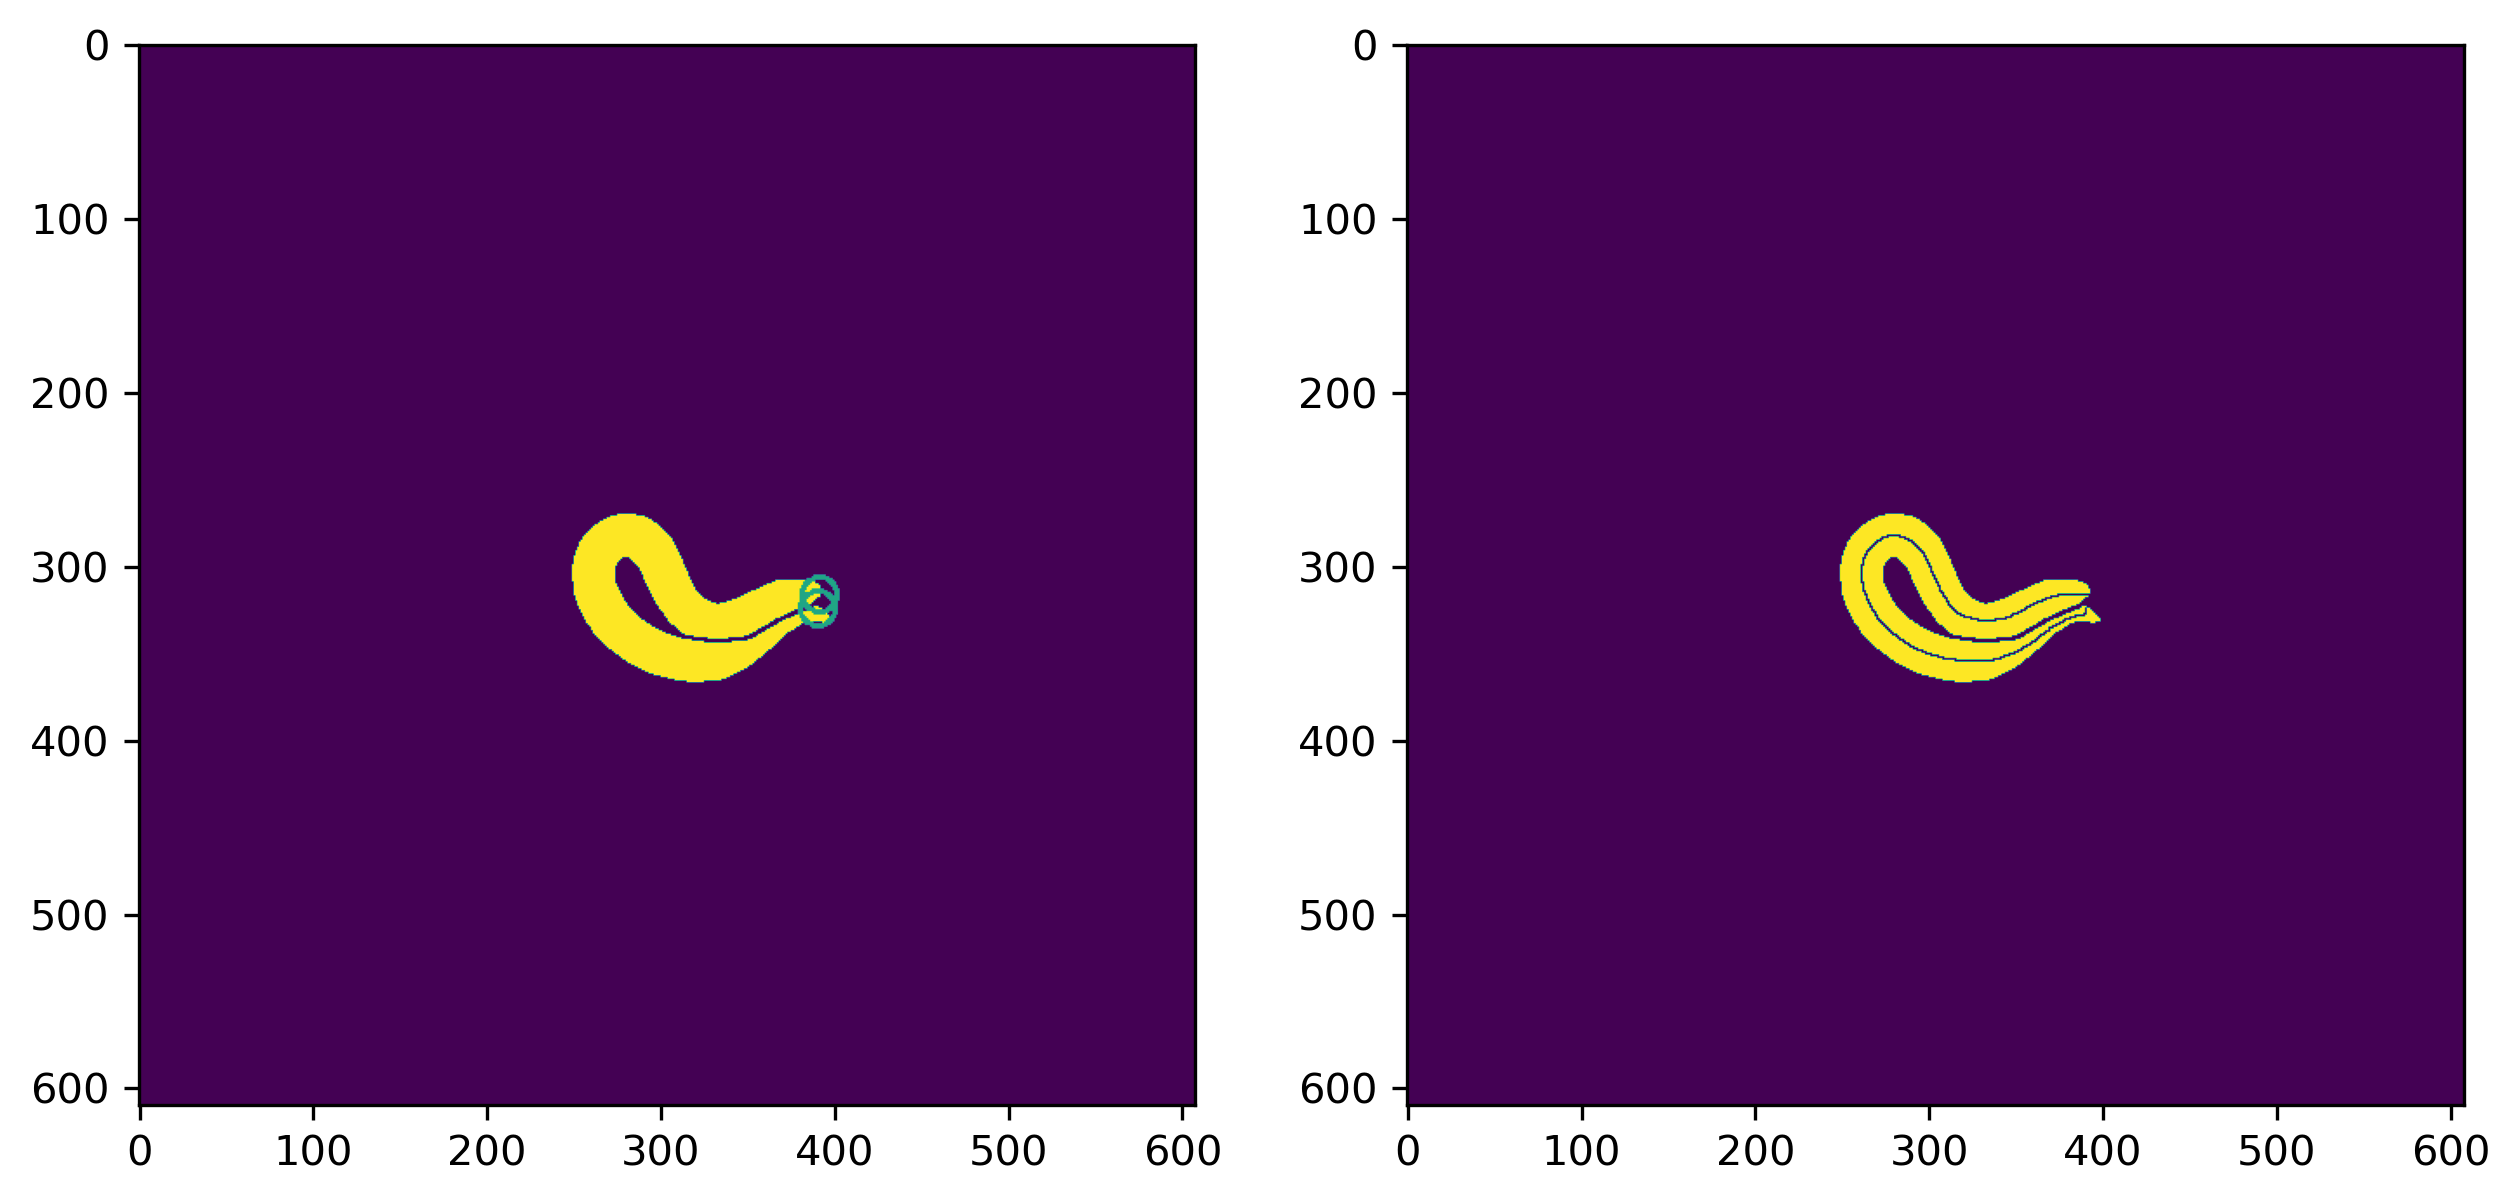

img22111.tif
head and tail were too close, no centerline could be created
img22157.tif


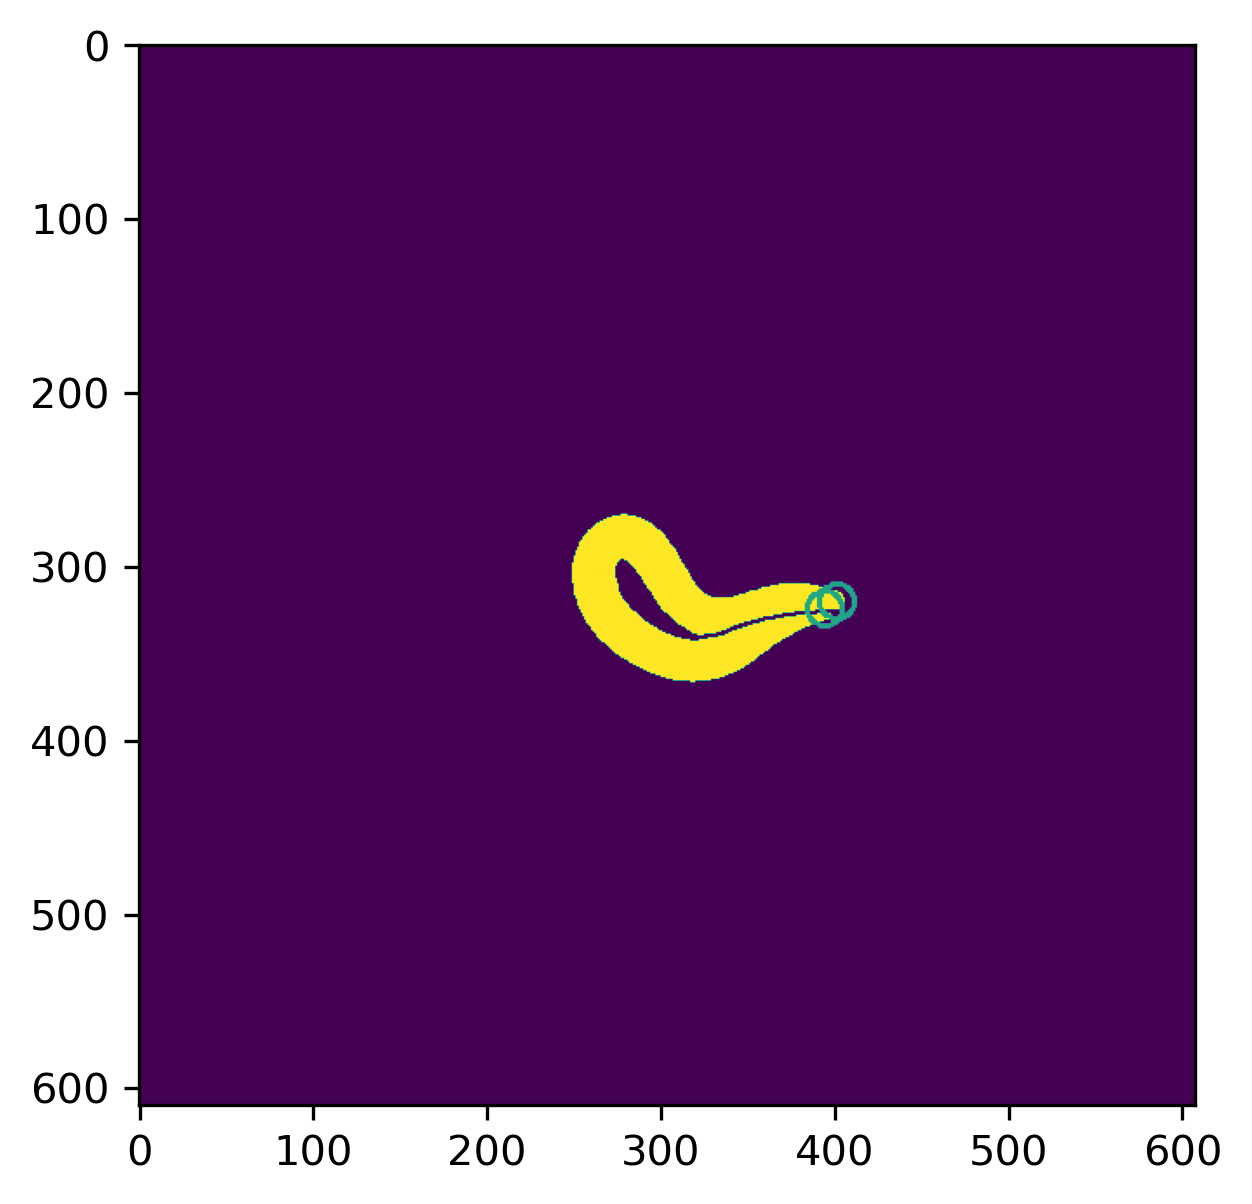

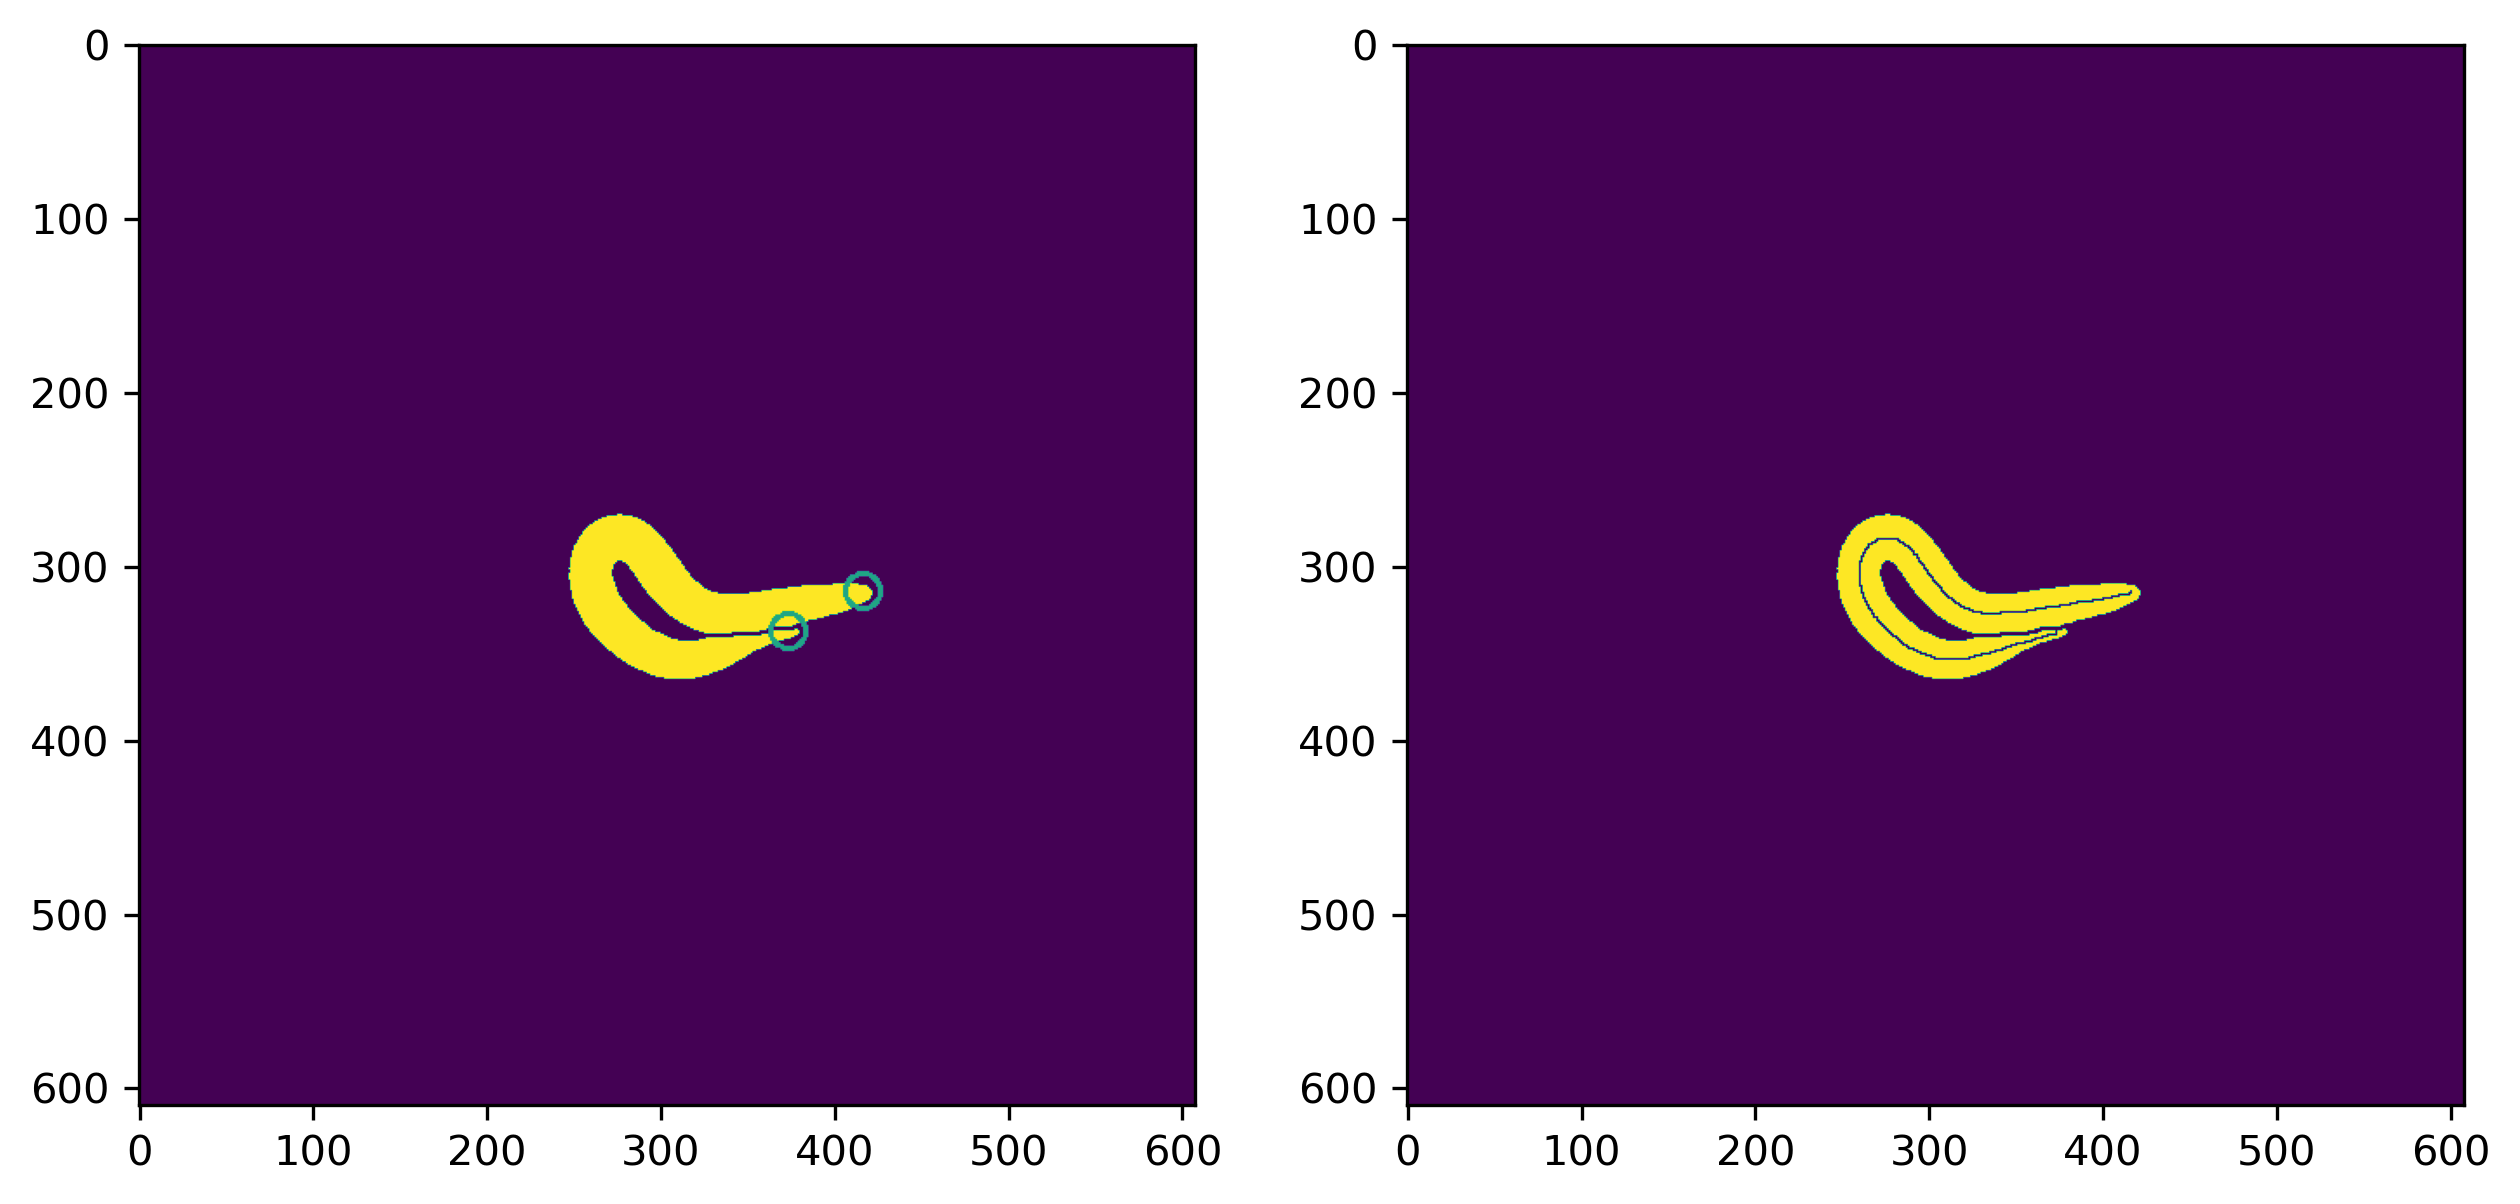

img22182.tif


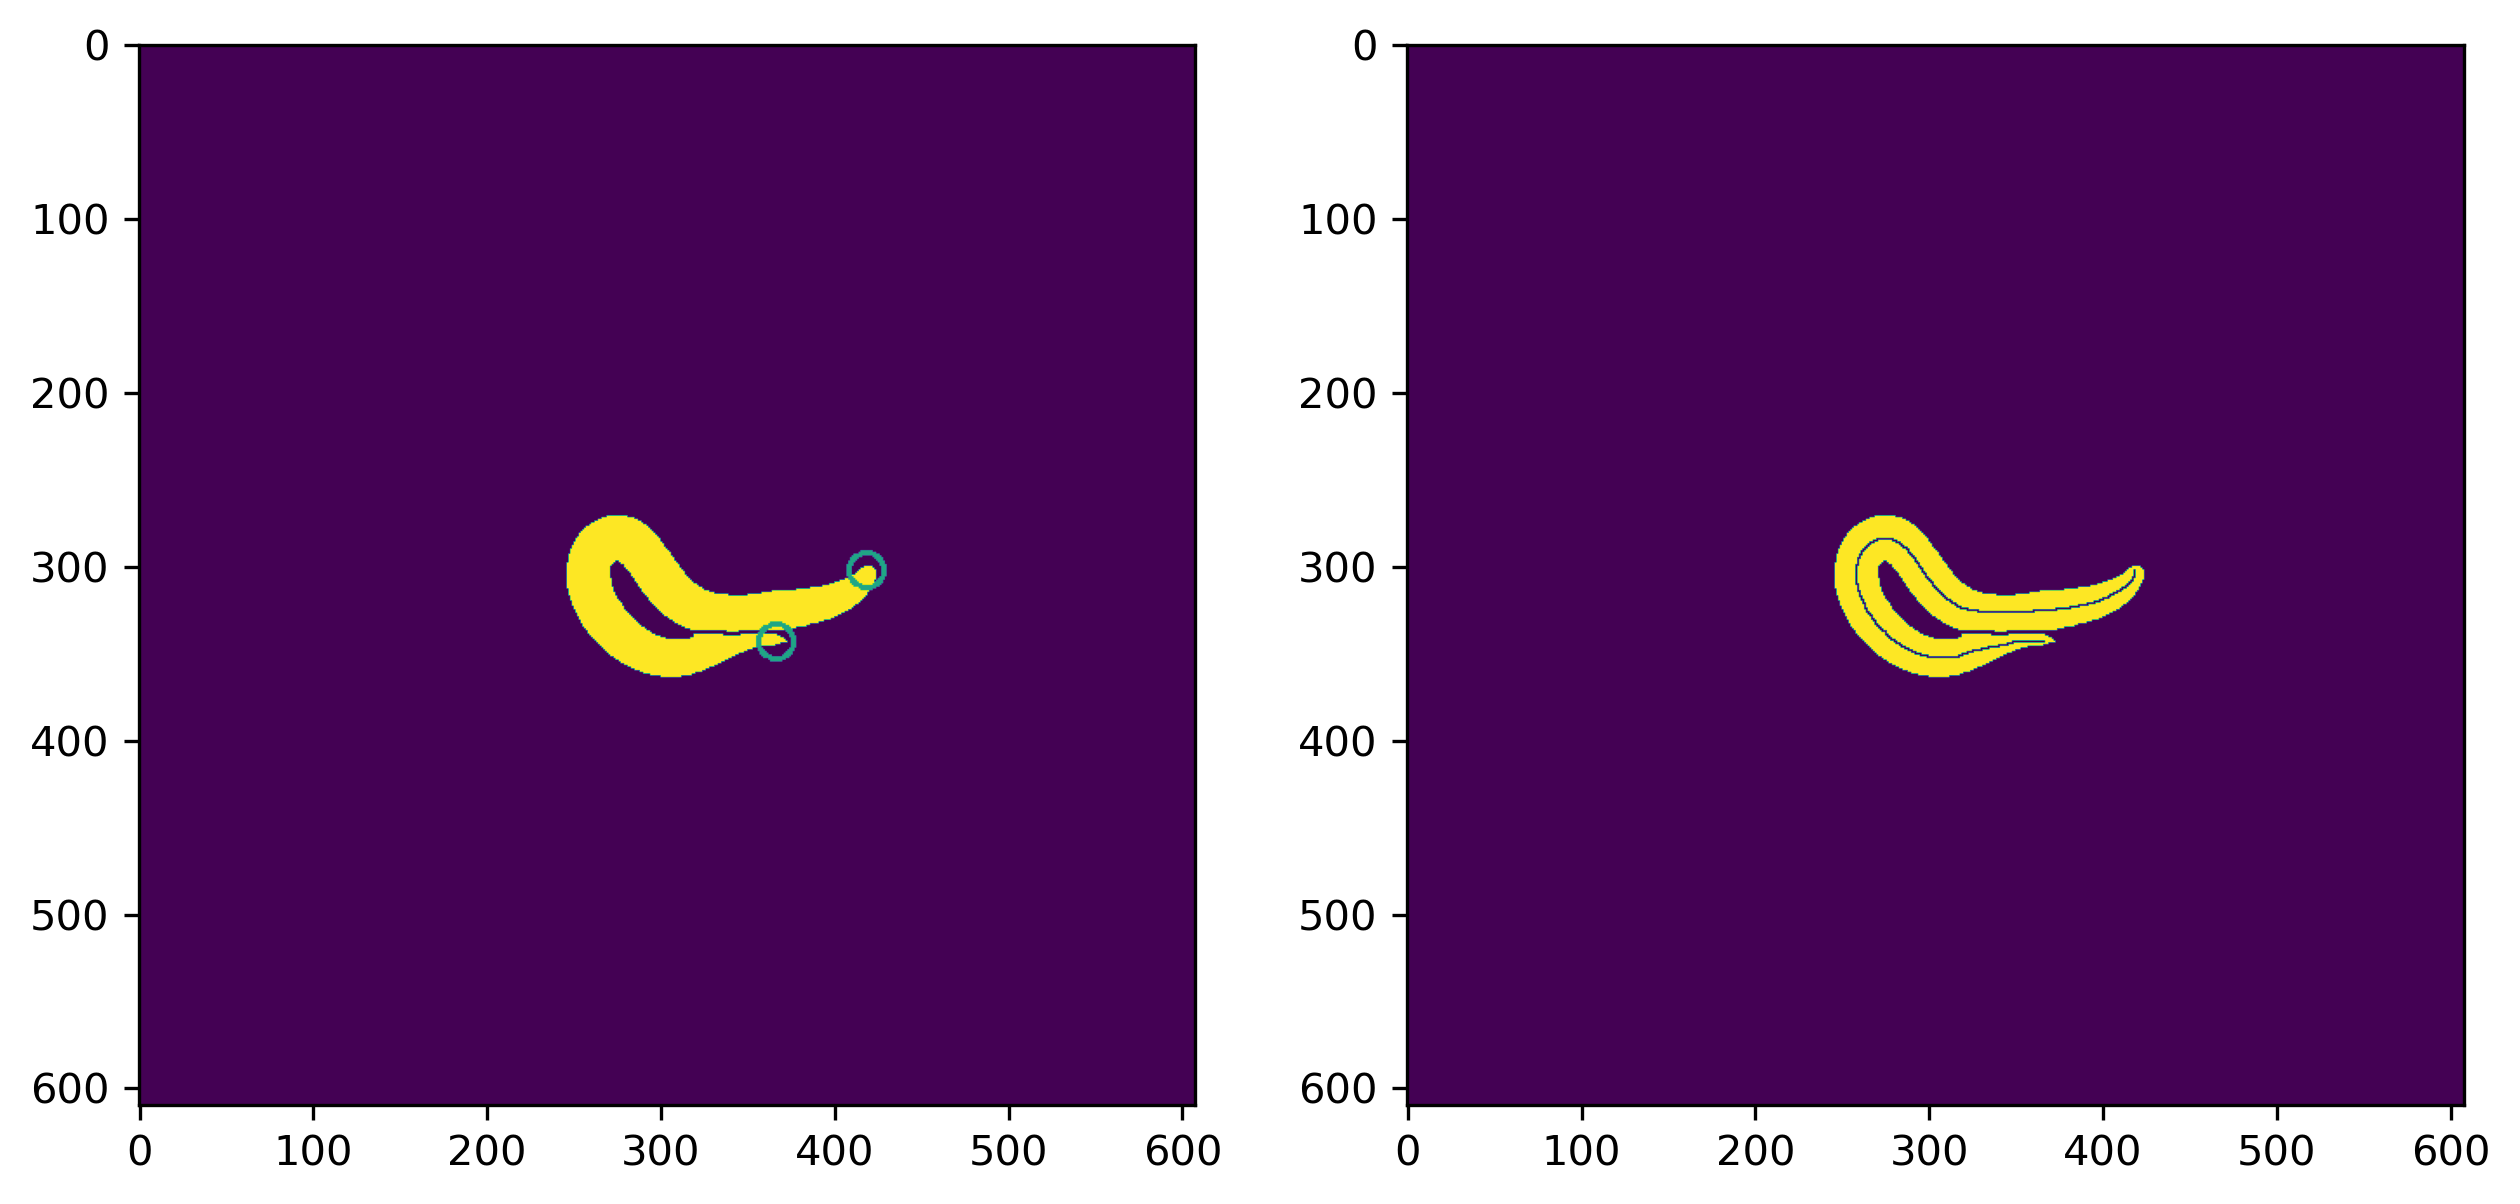

img22250.tif
head and tail were too close, no centerline could be created
img22286.tif


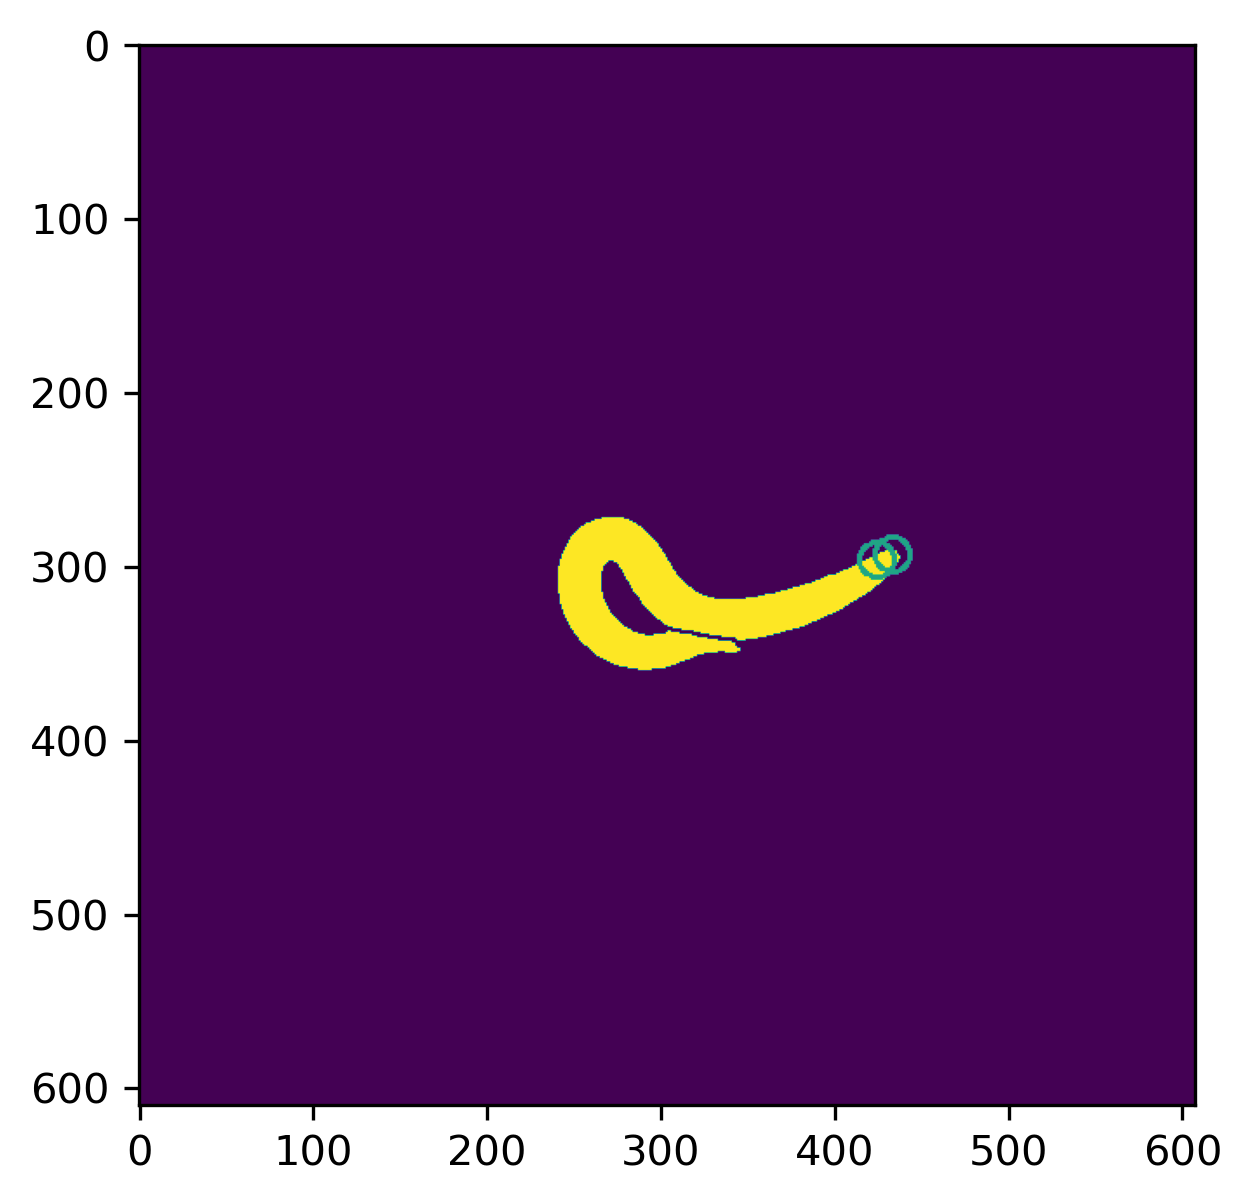

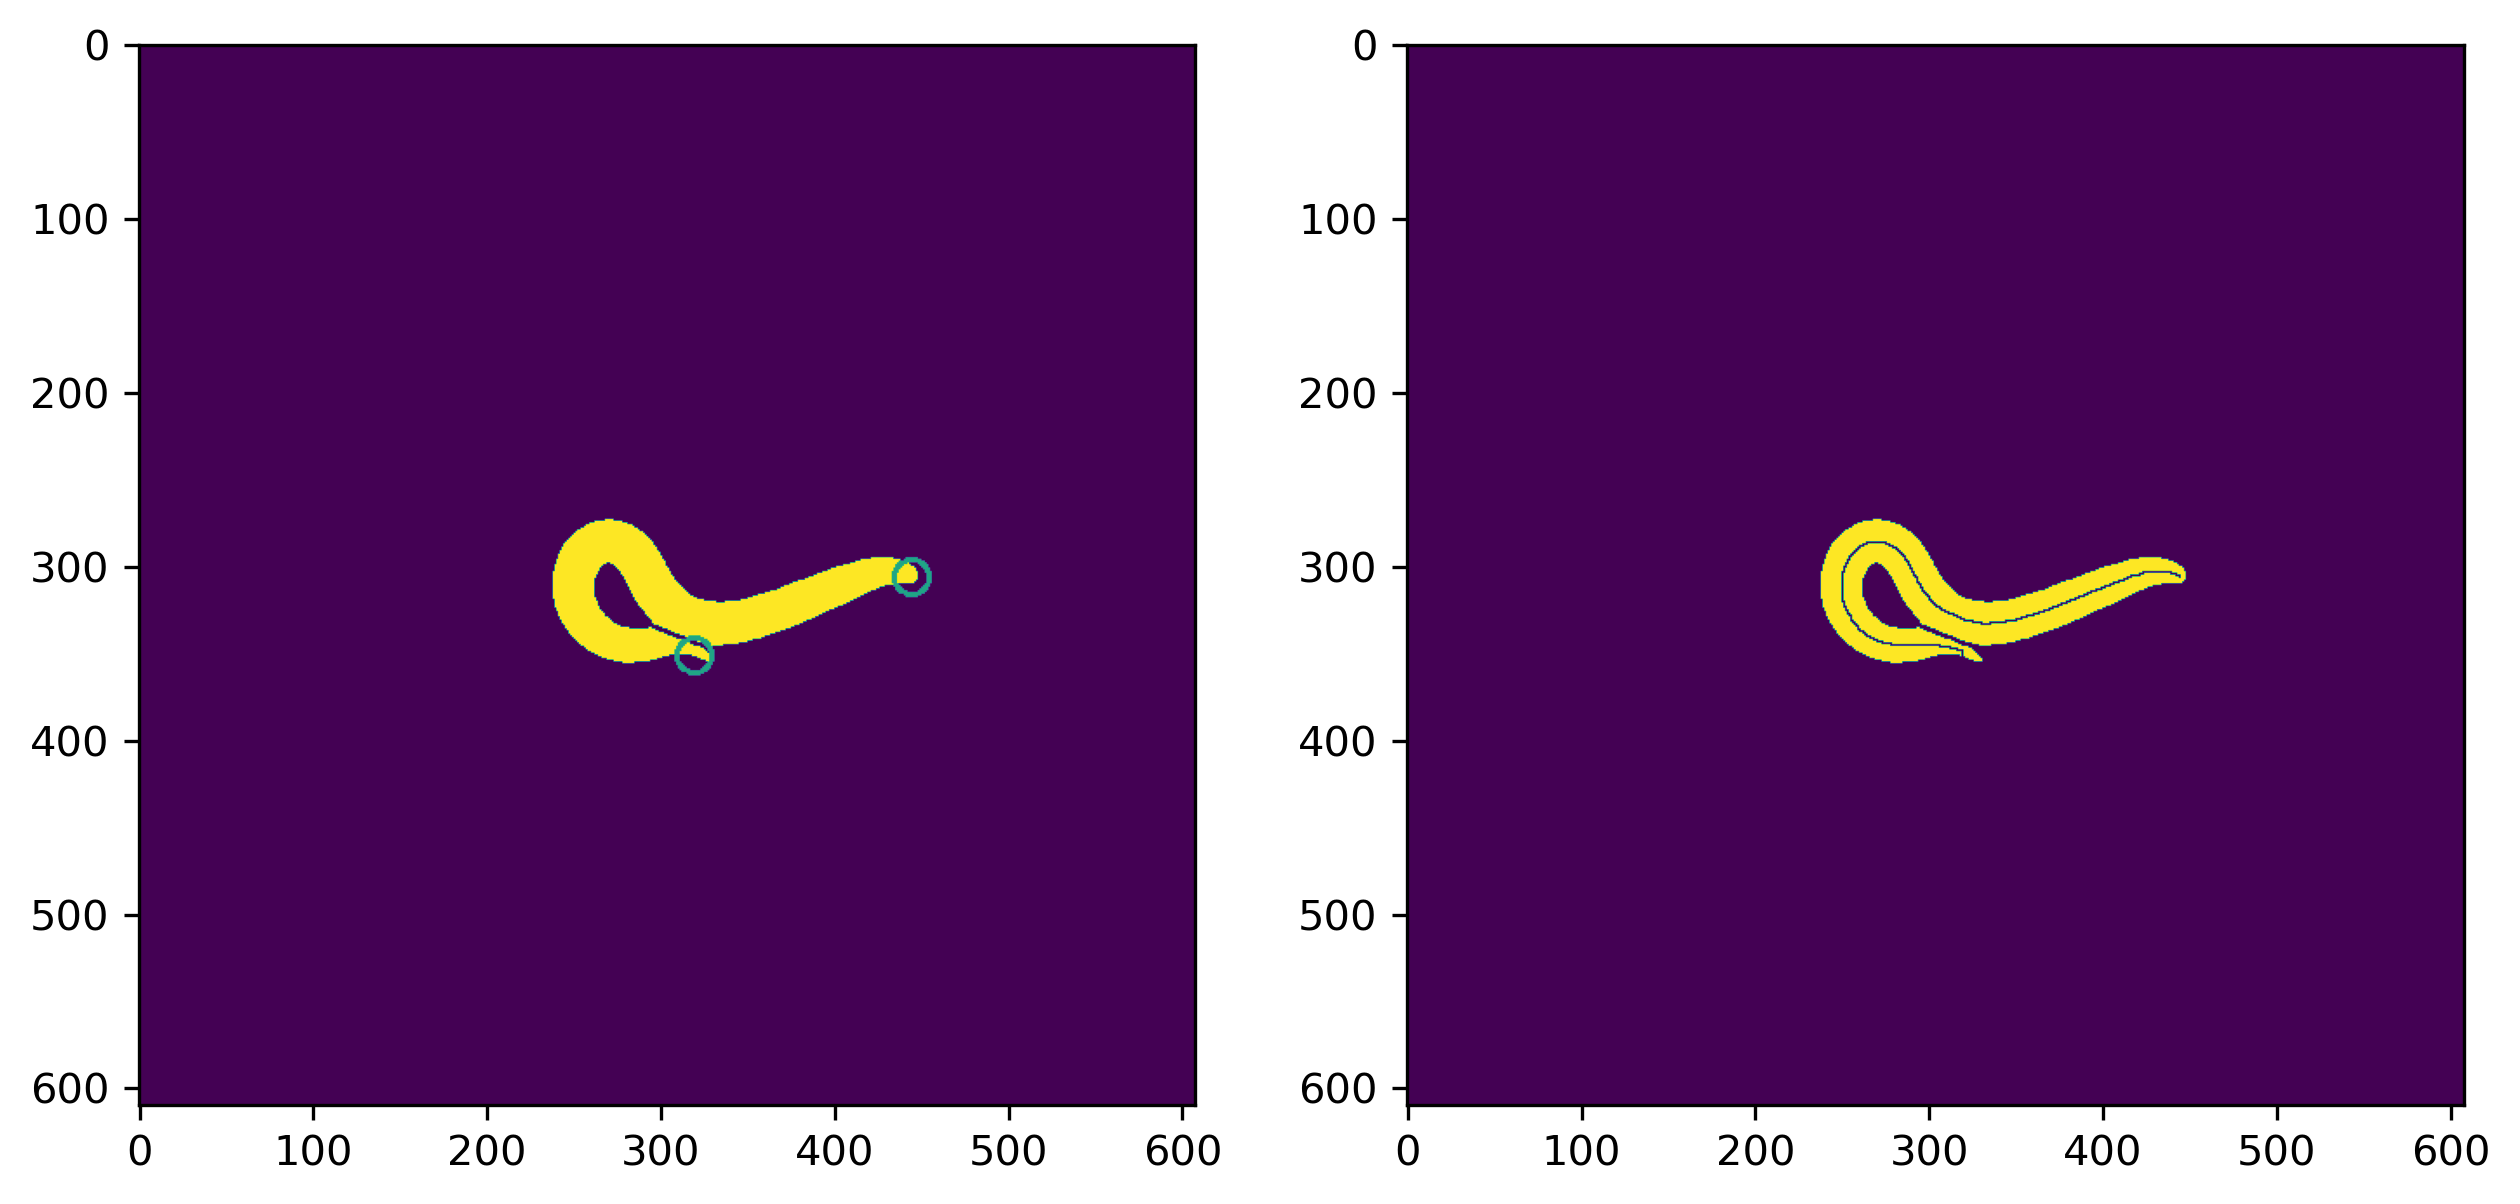

img22314.tif


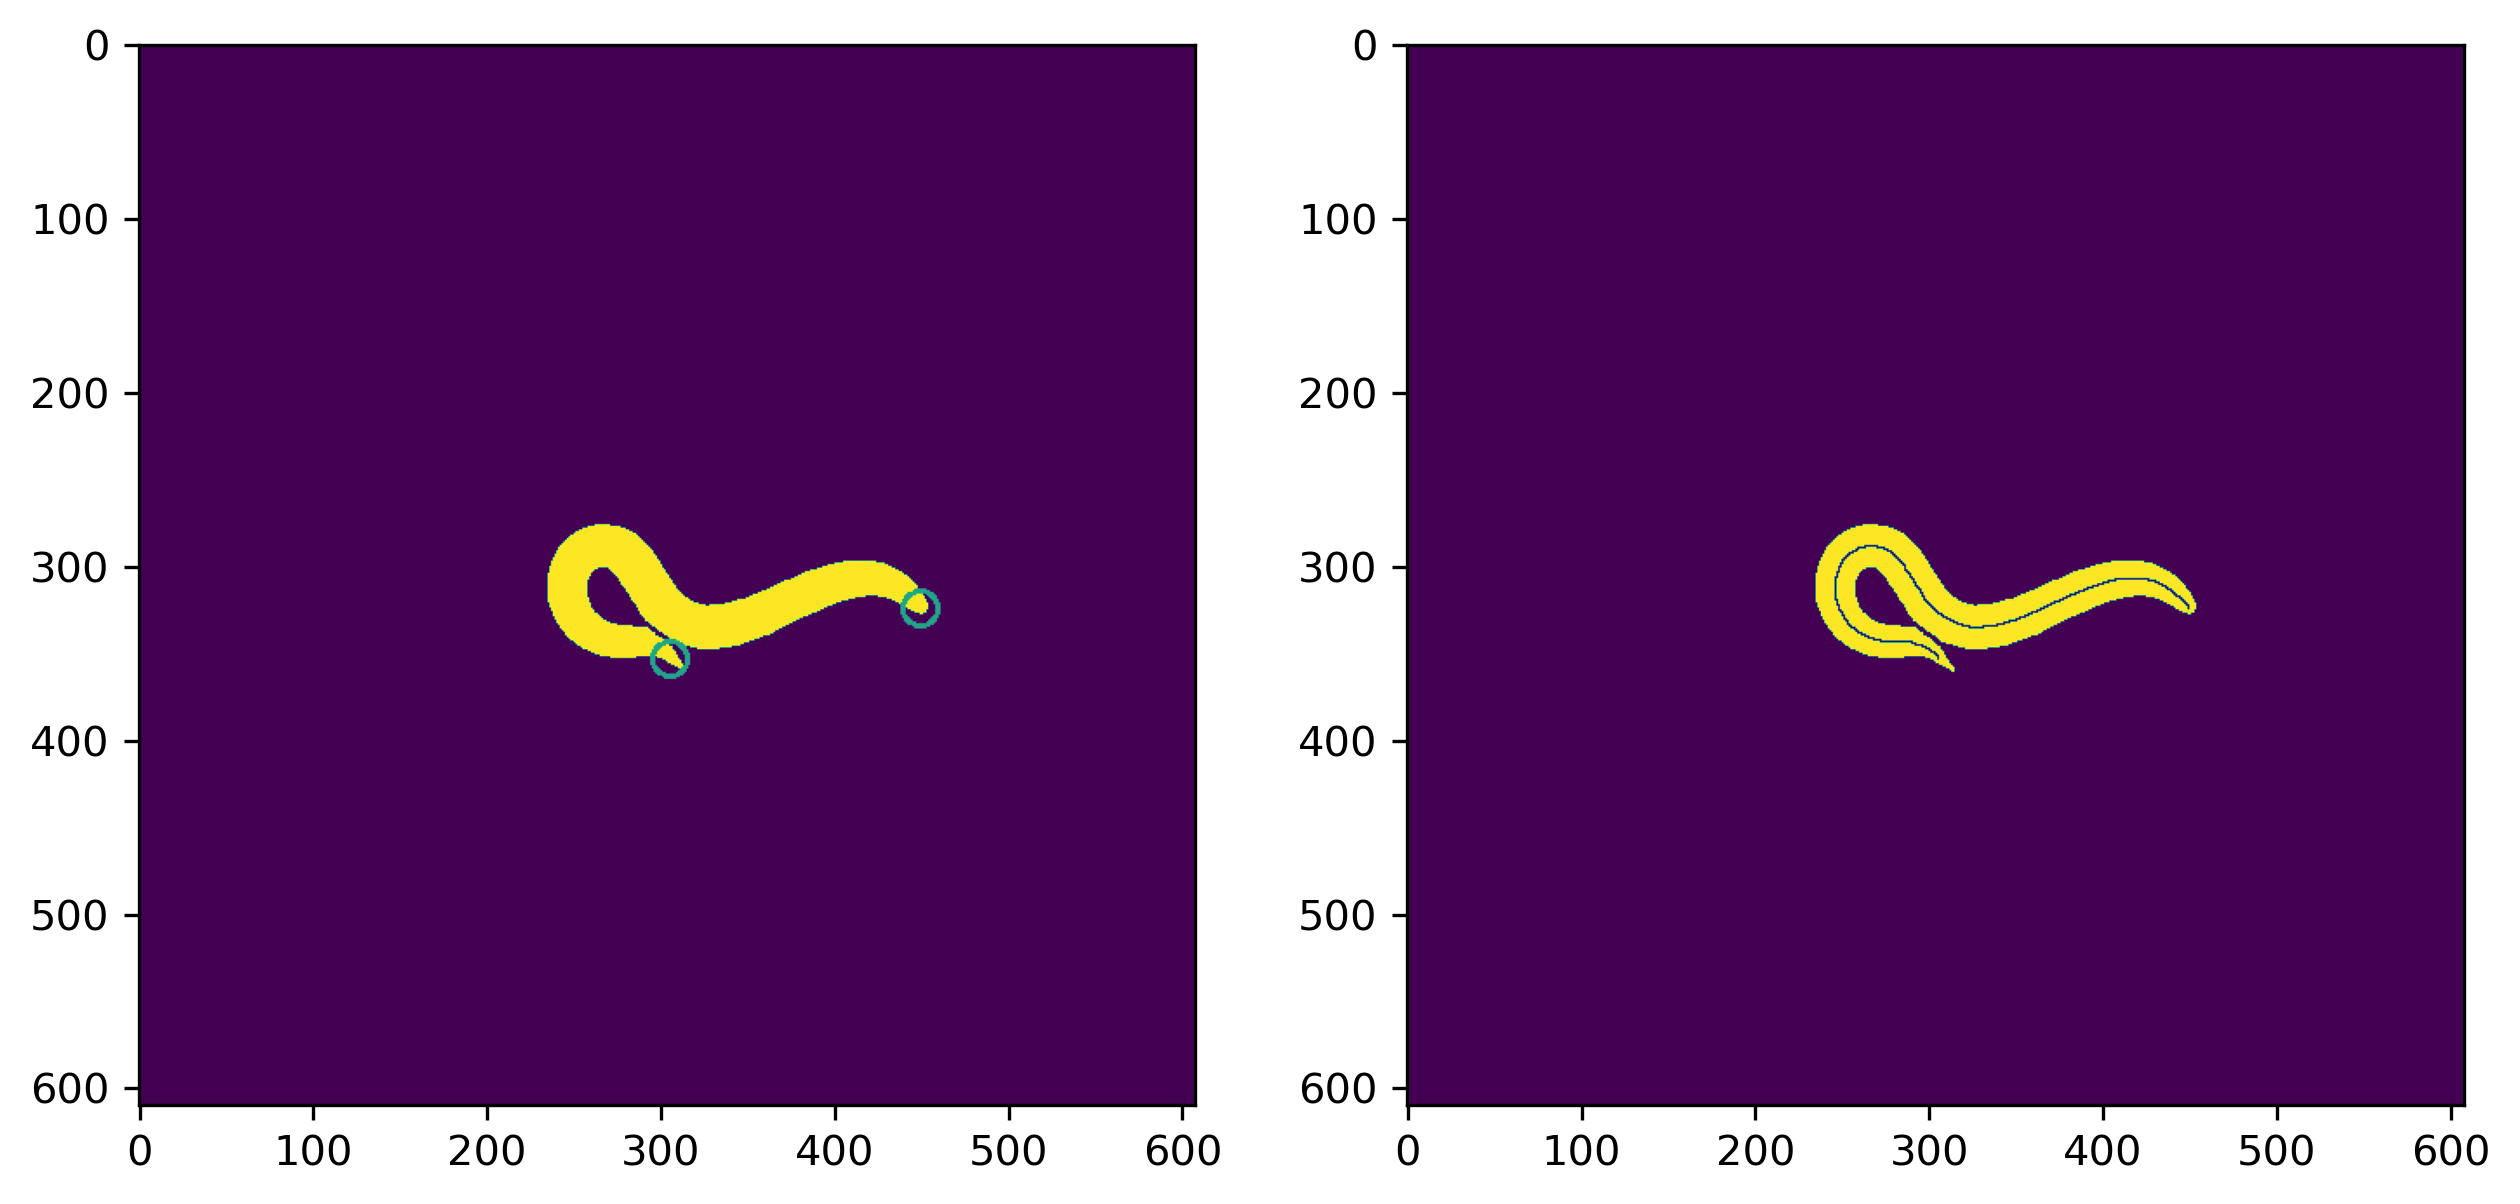

img24362.tif


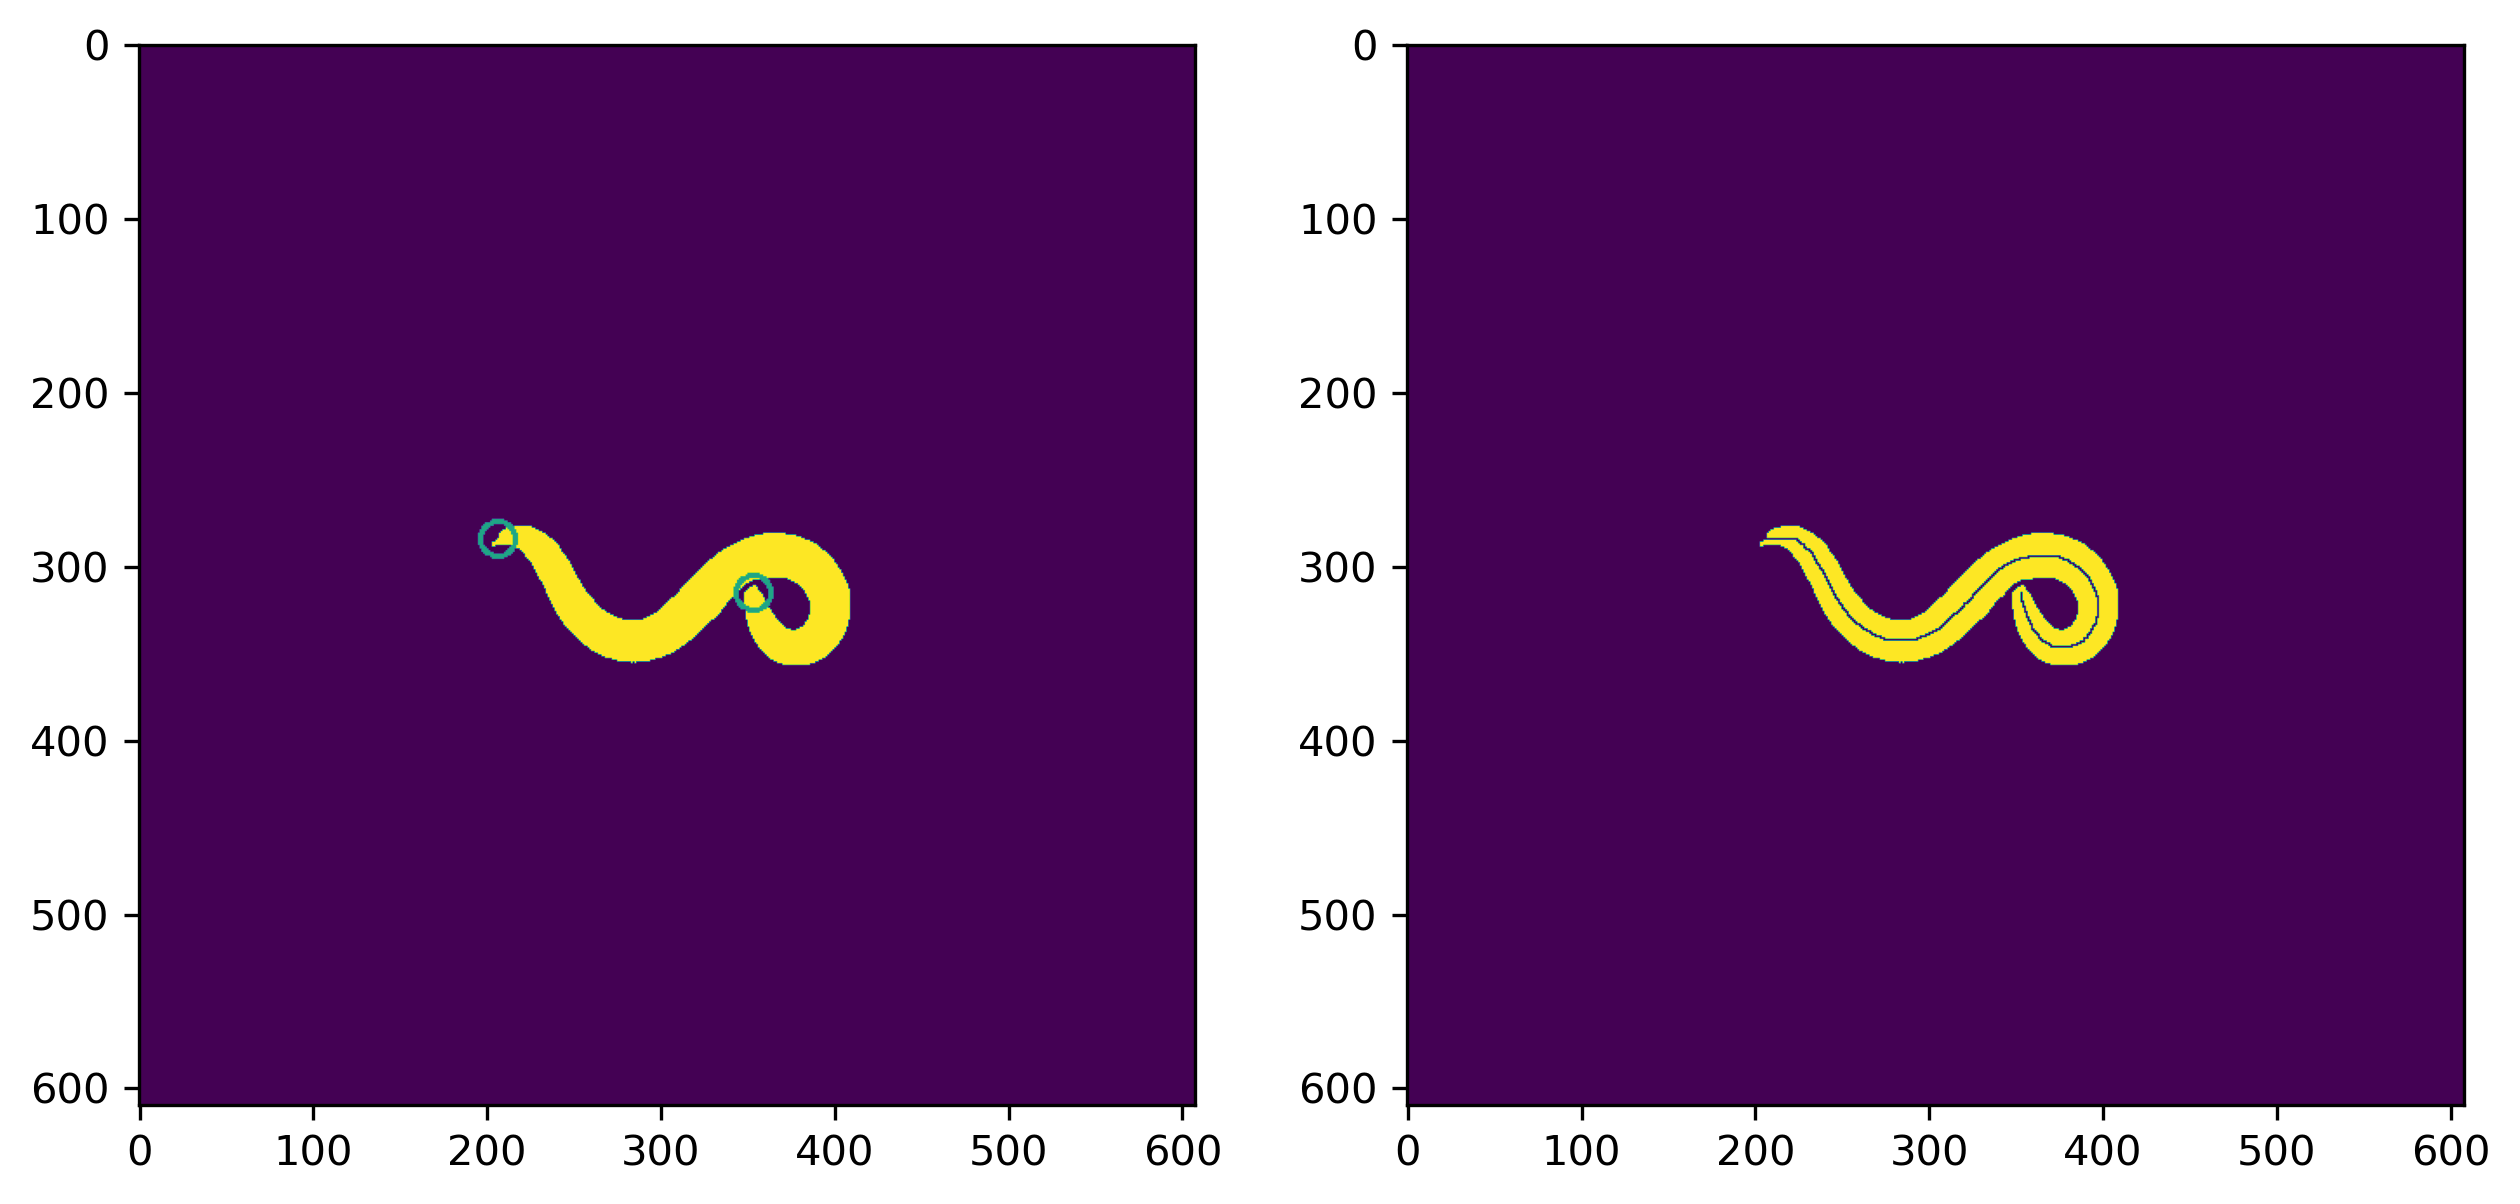

img24414.tif
head and tail were too close, no centerline could be created
img24444.tif
head and tail were too close, no centerline could be created
img24489.tif
head and tail were too close, no centerline could be created
img24563.tif
head and tail were too close, no centerline could be created
img24623.tif
head and tail were too close, no centerline could be created
img24683.tif
head and tail were too close, no centerline could be created
img24743.tif


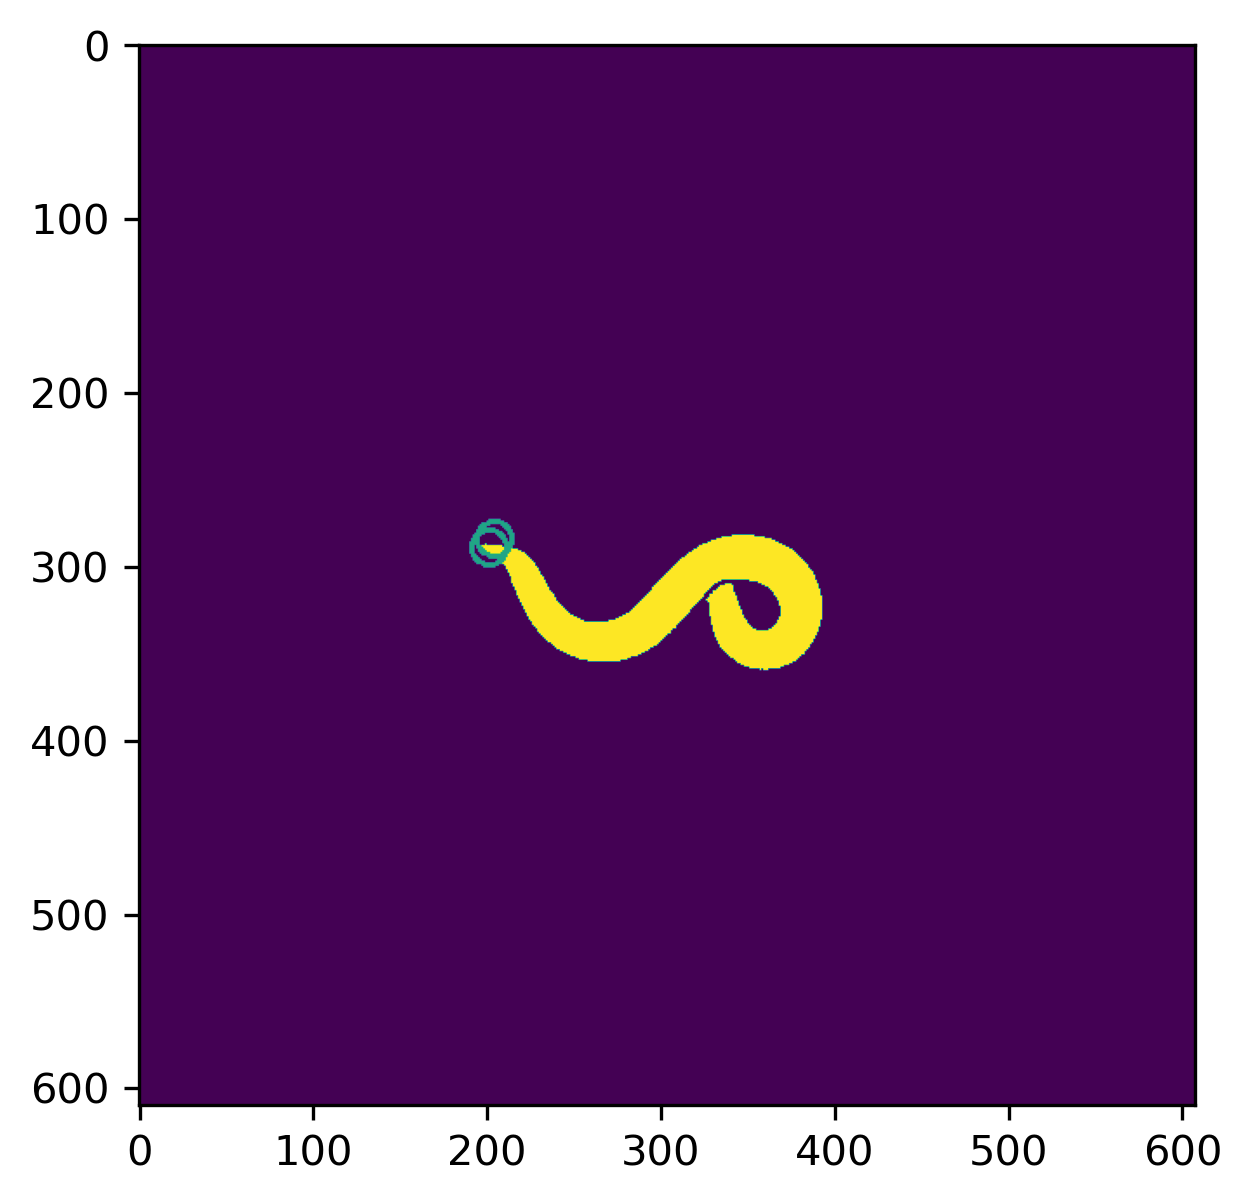

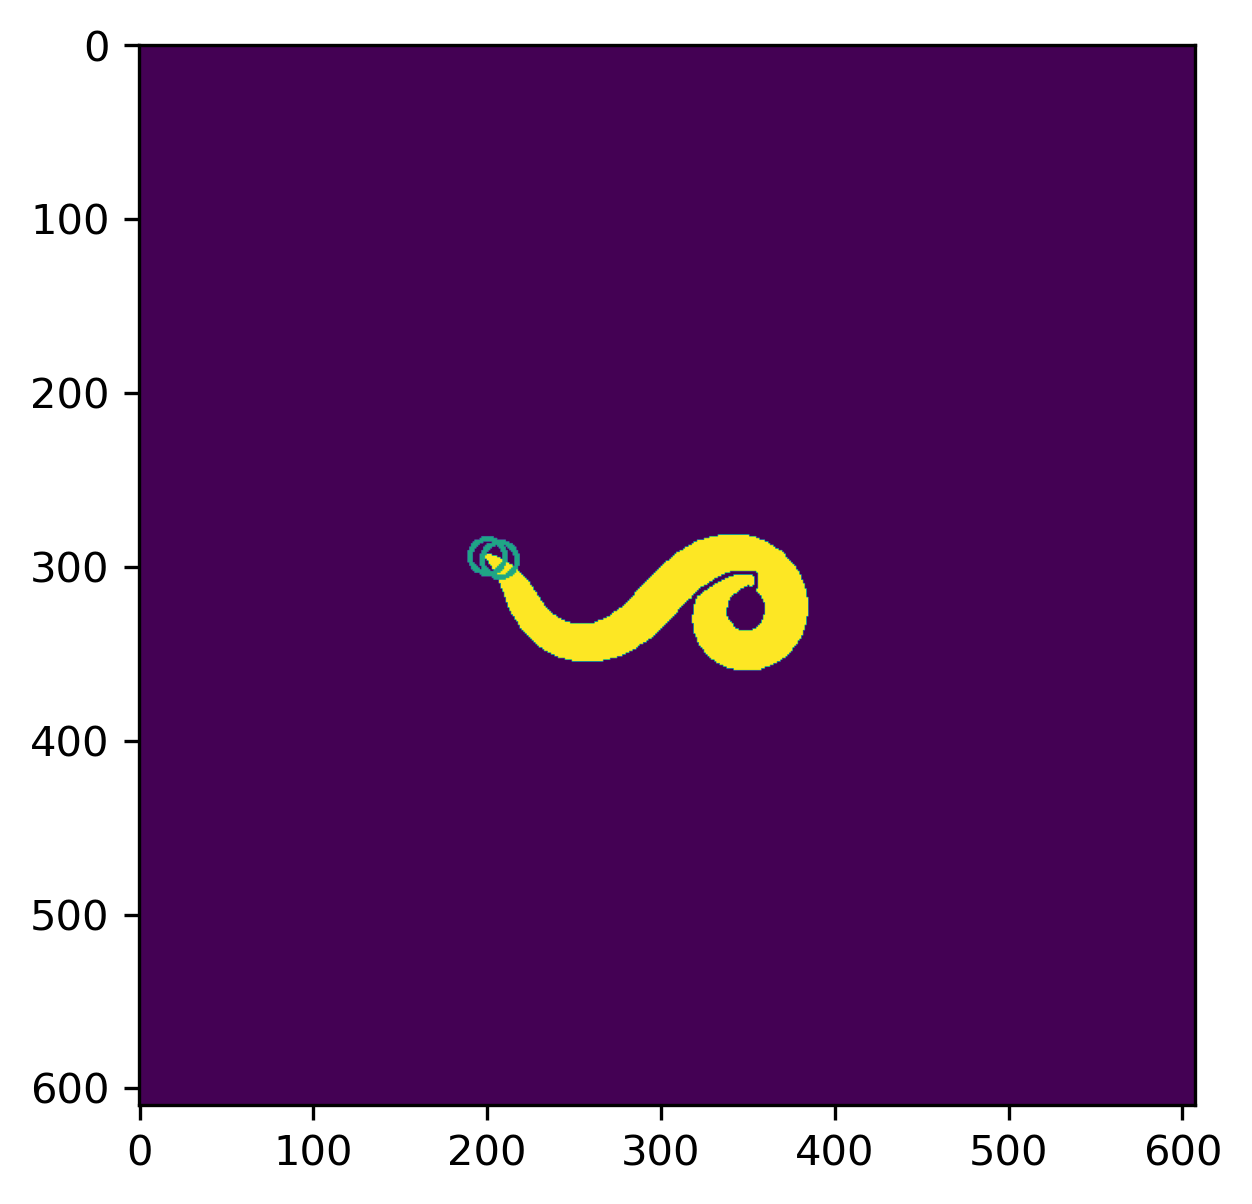

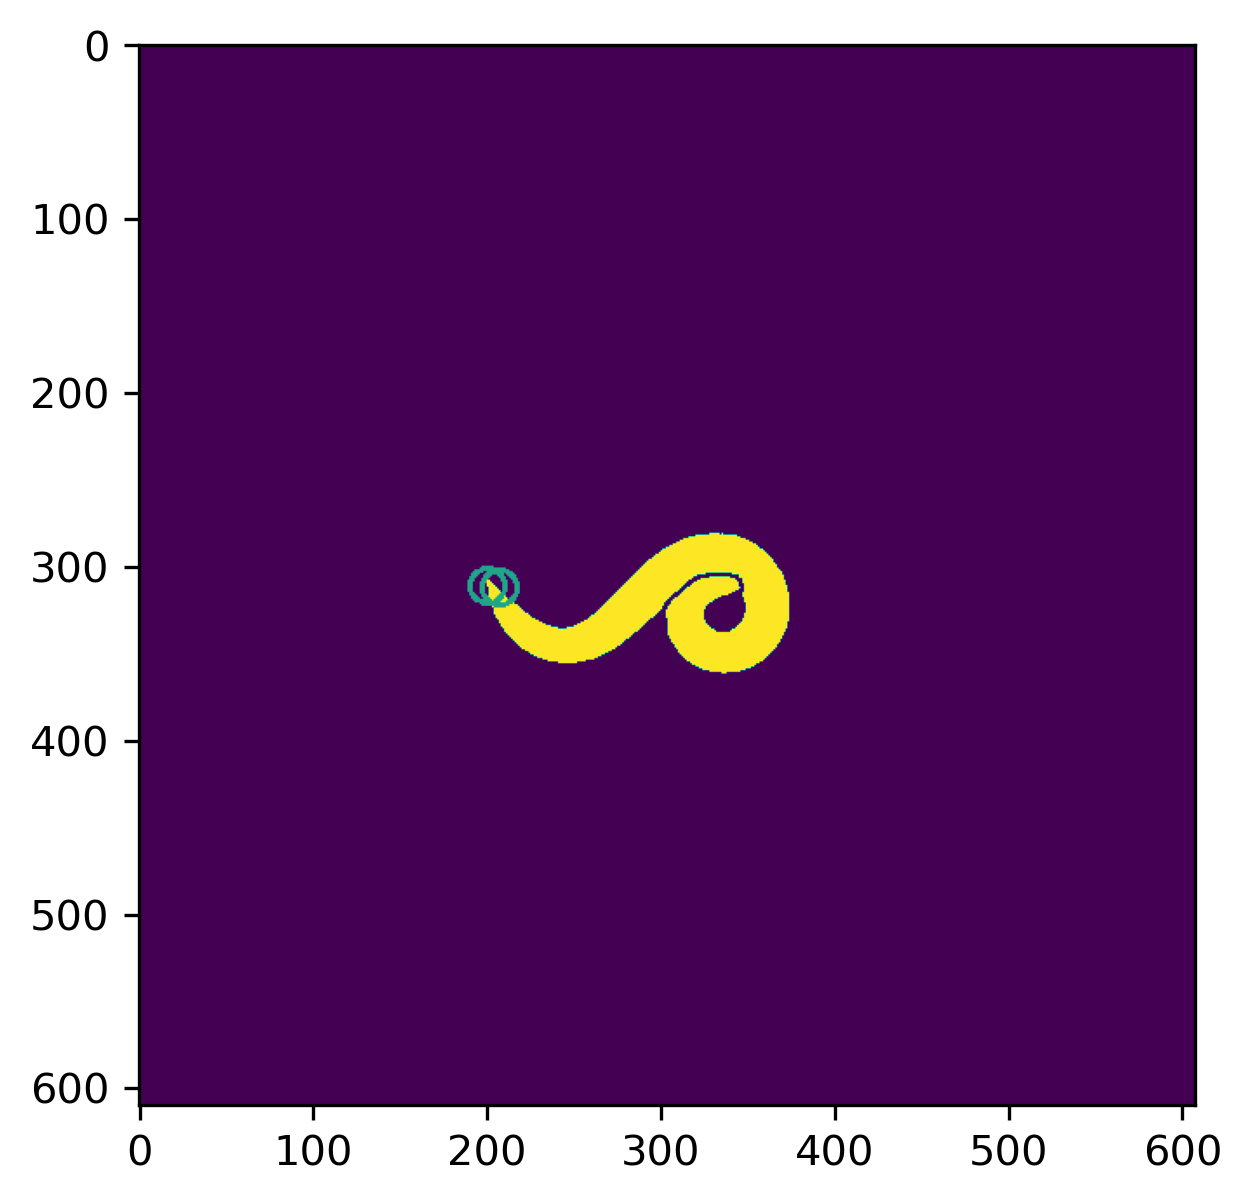

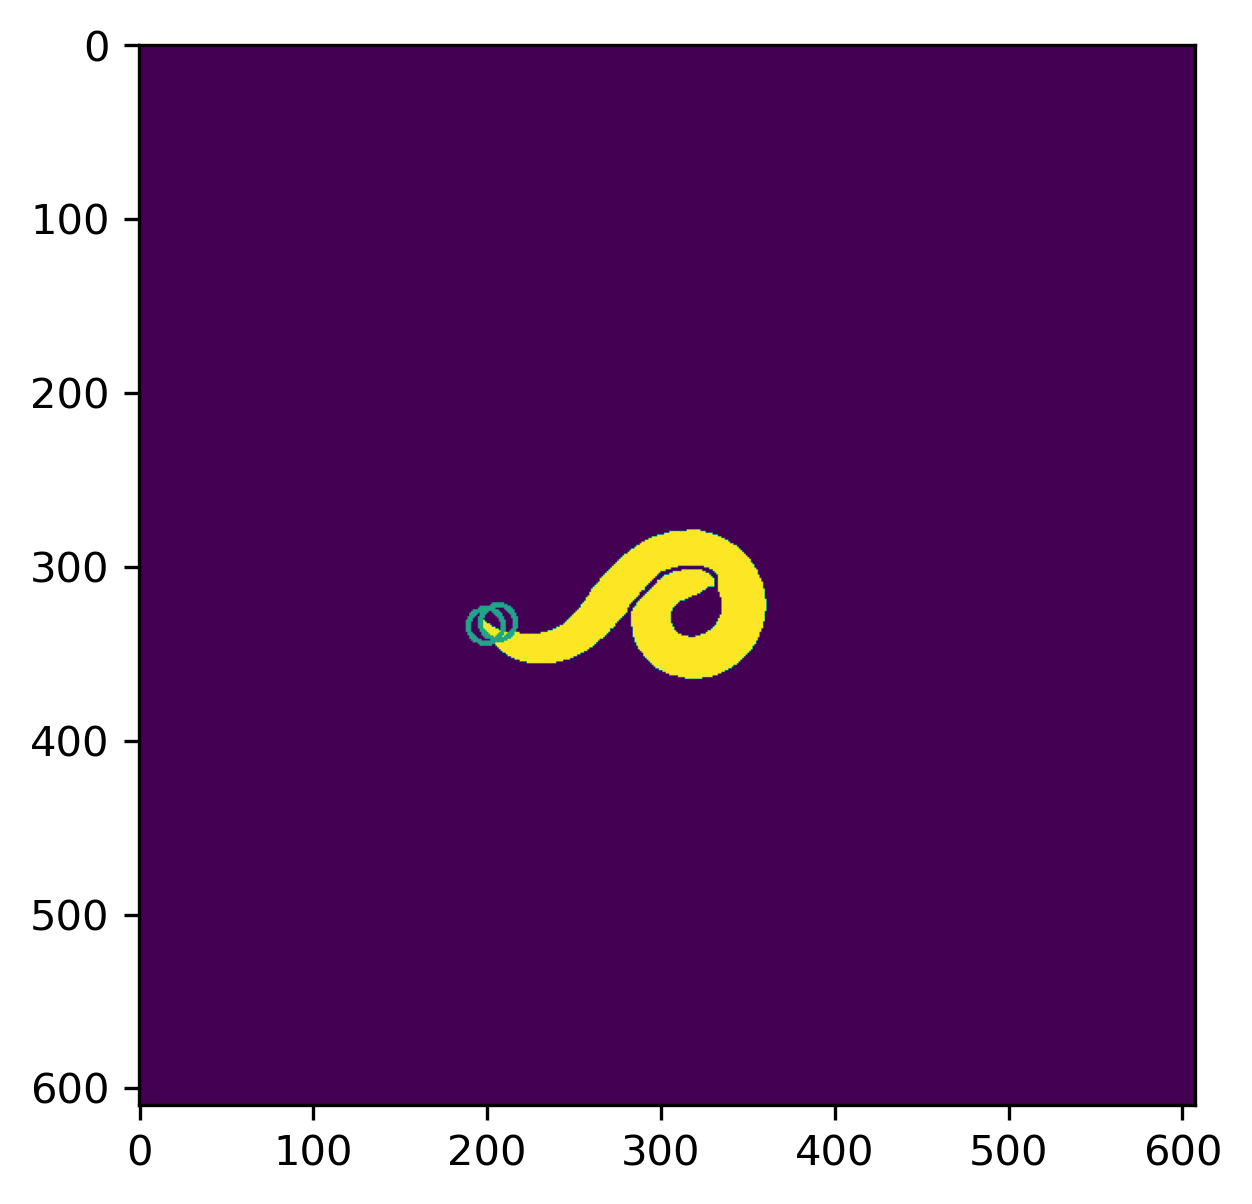

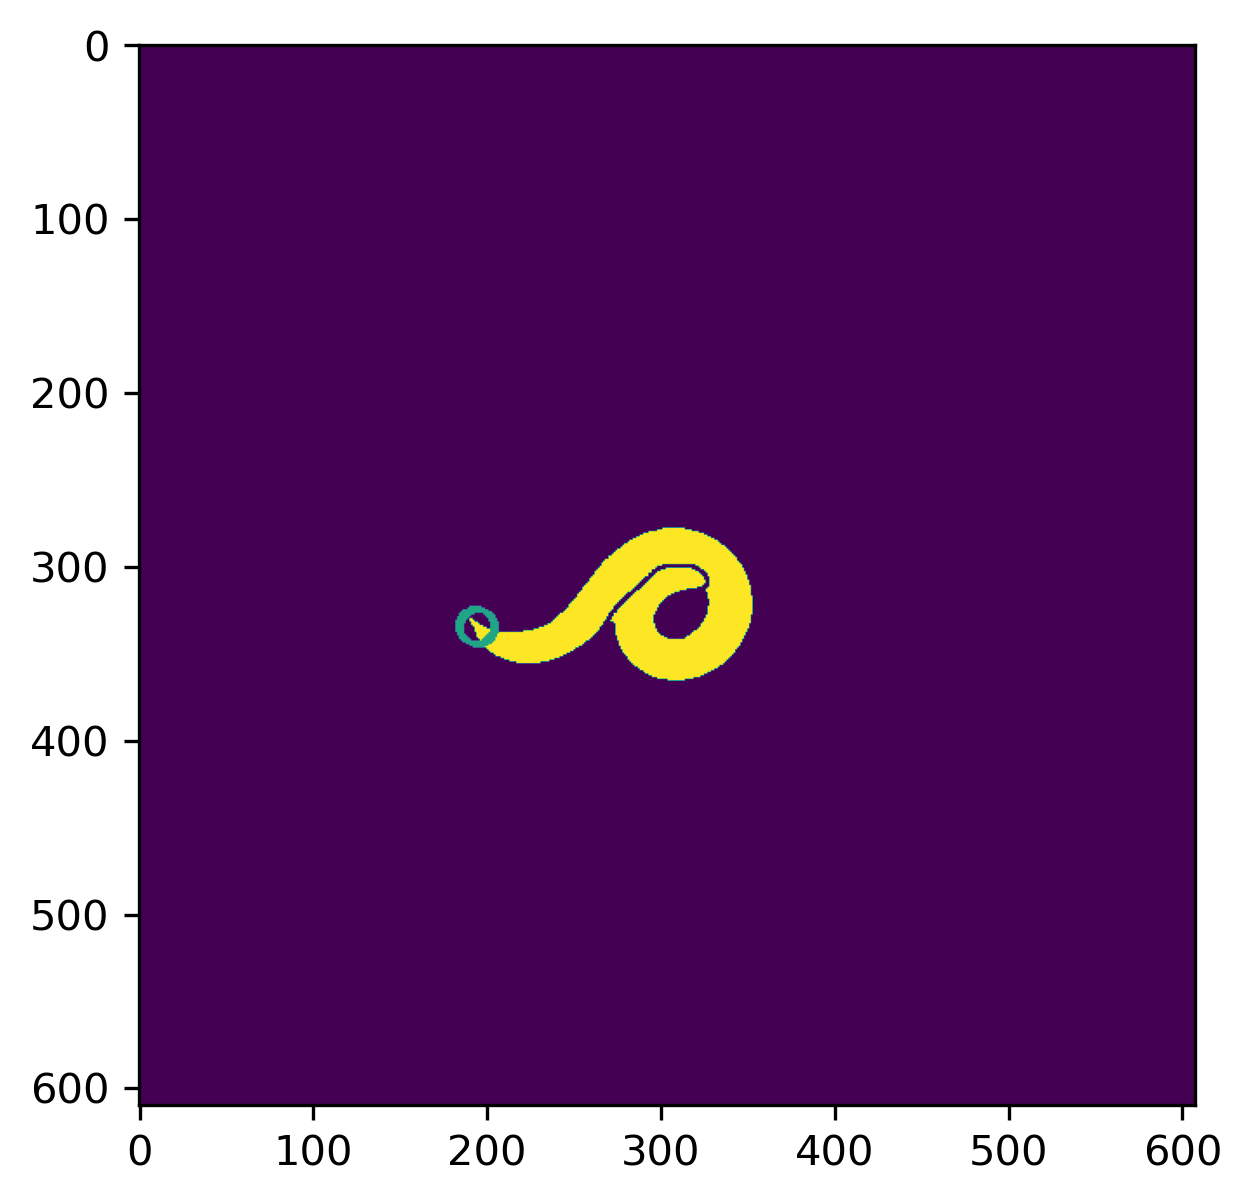

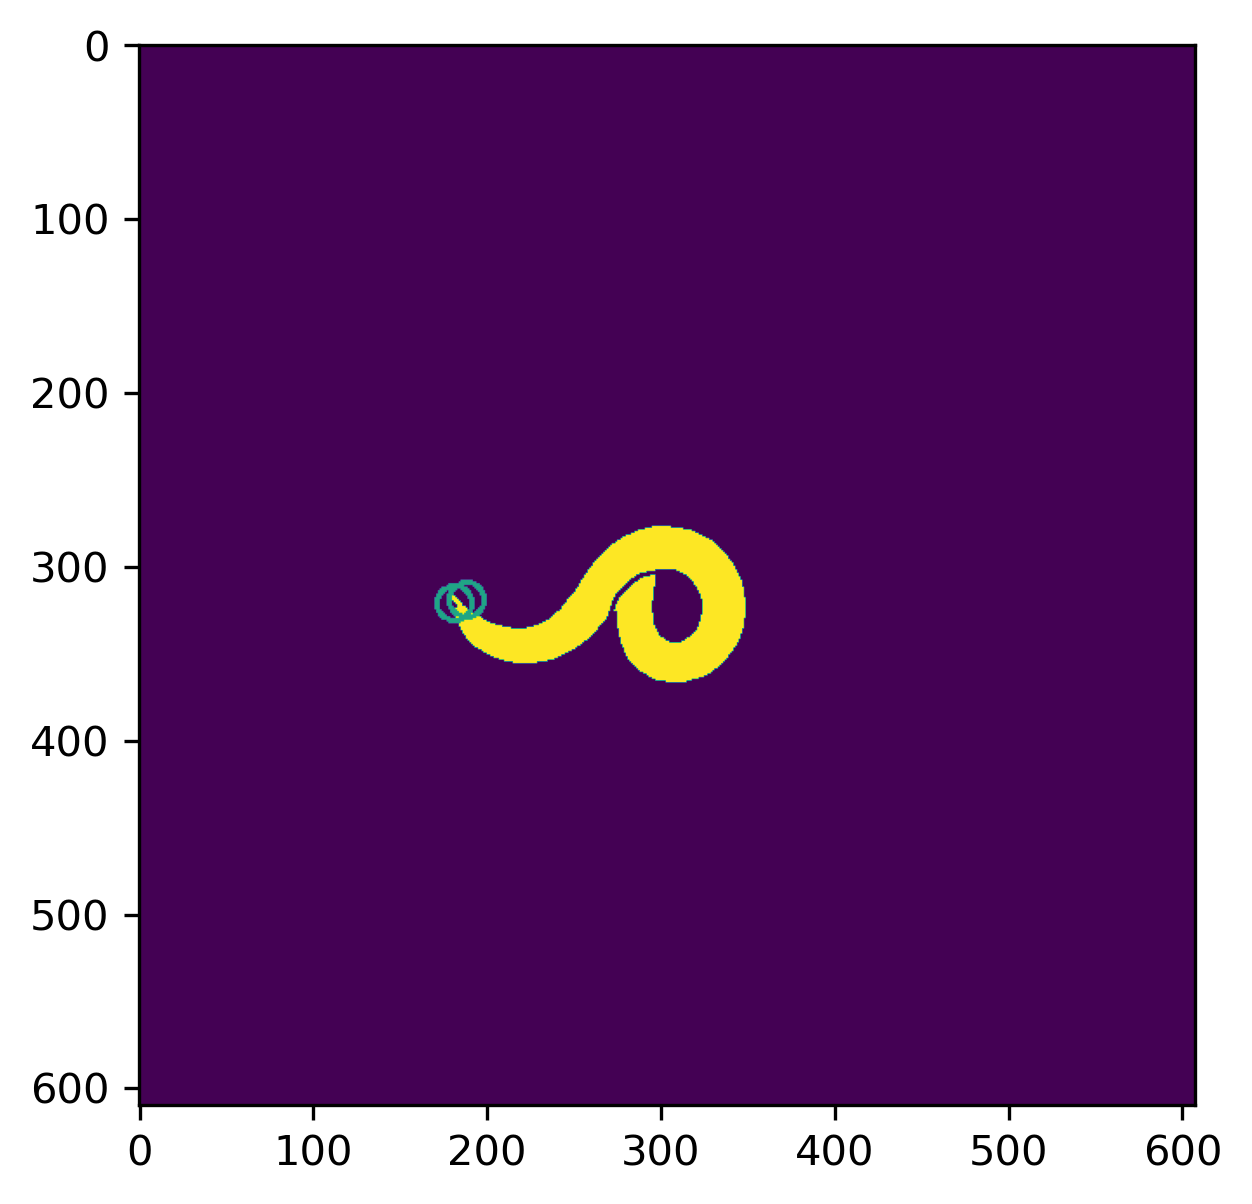

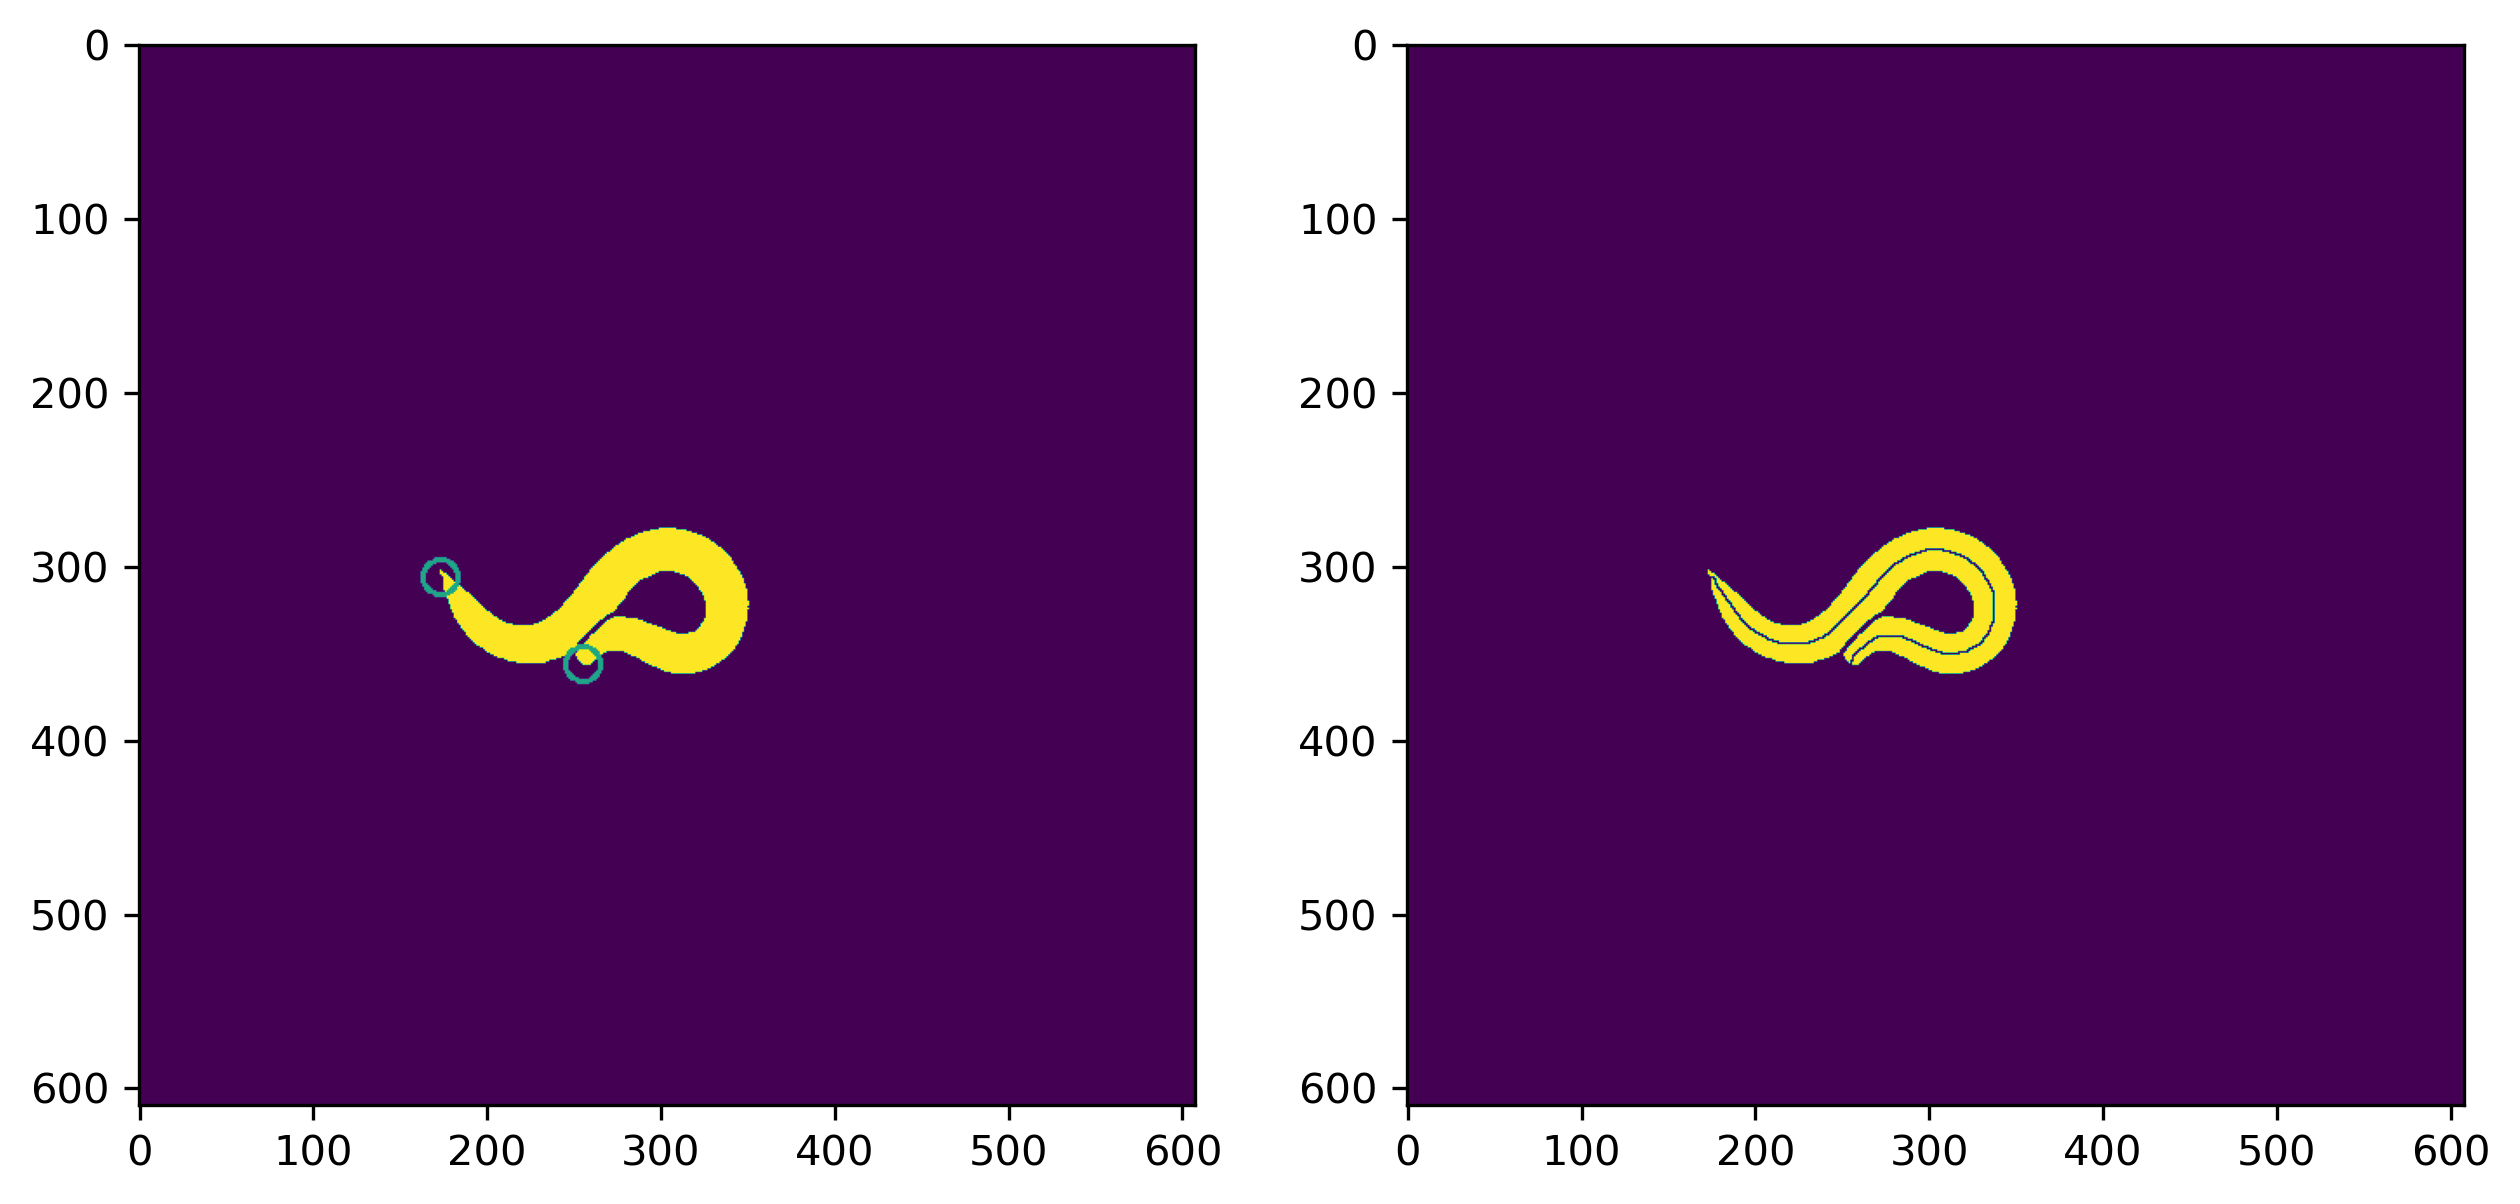

img24803.tif


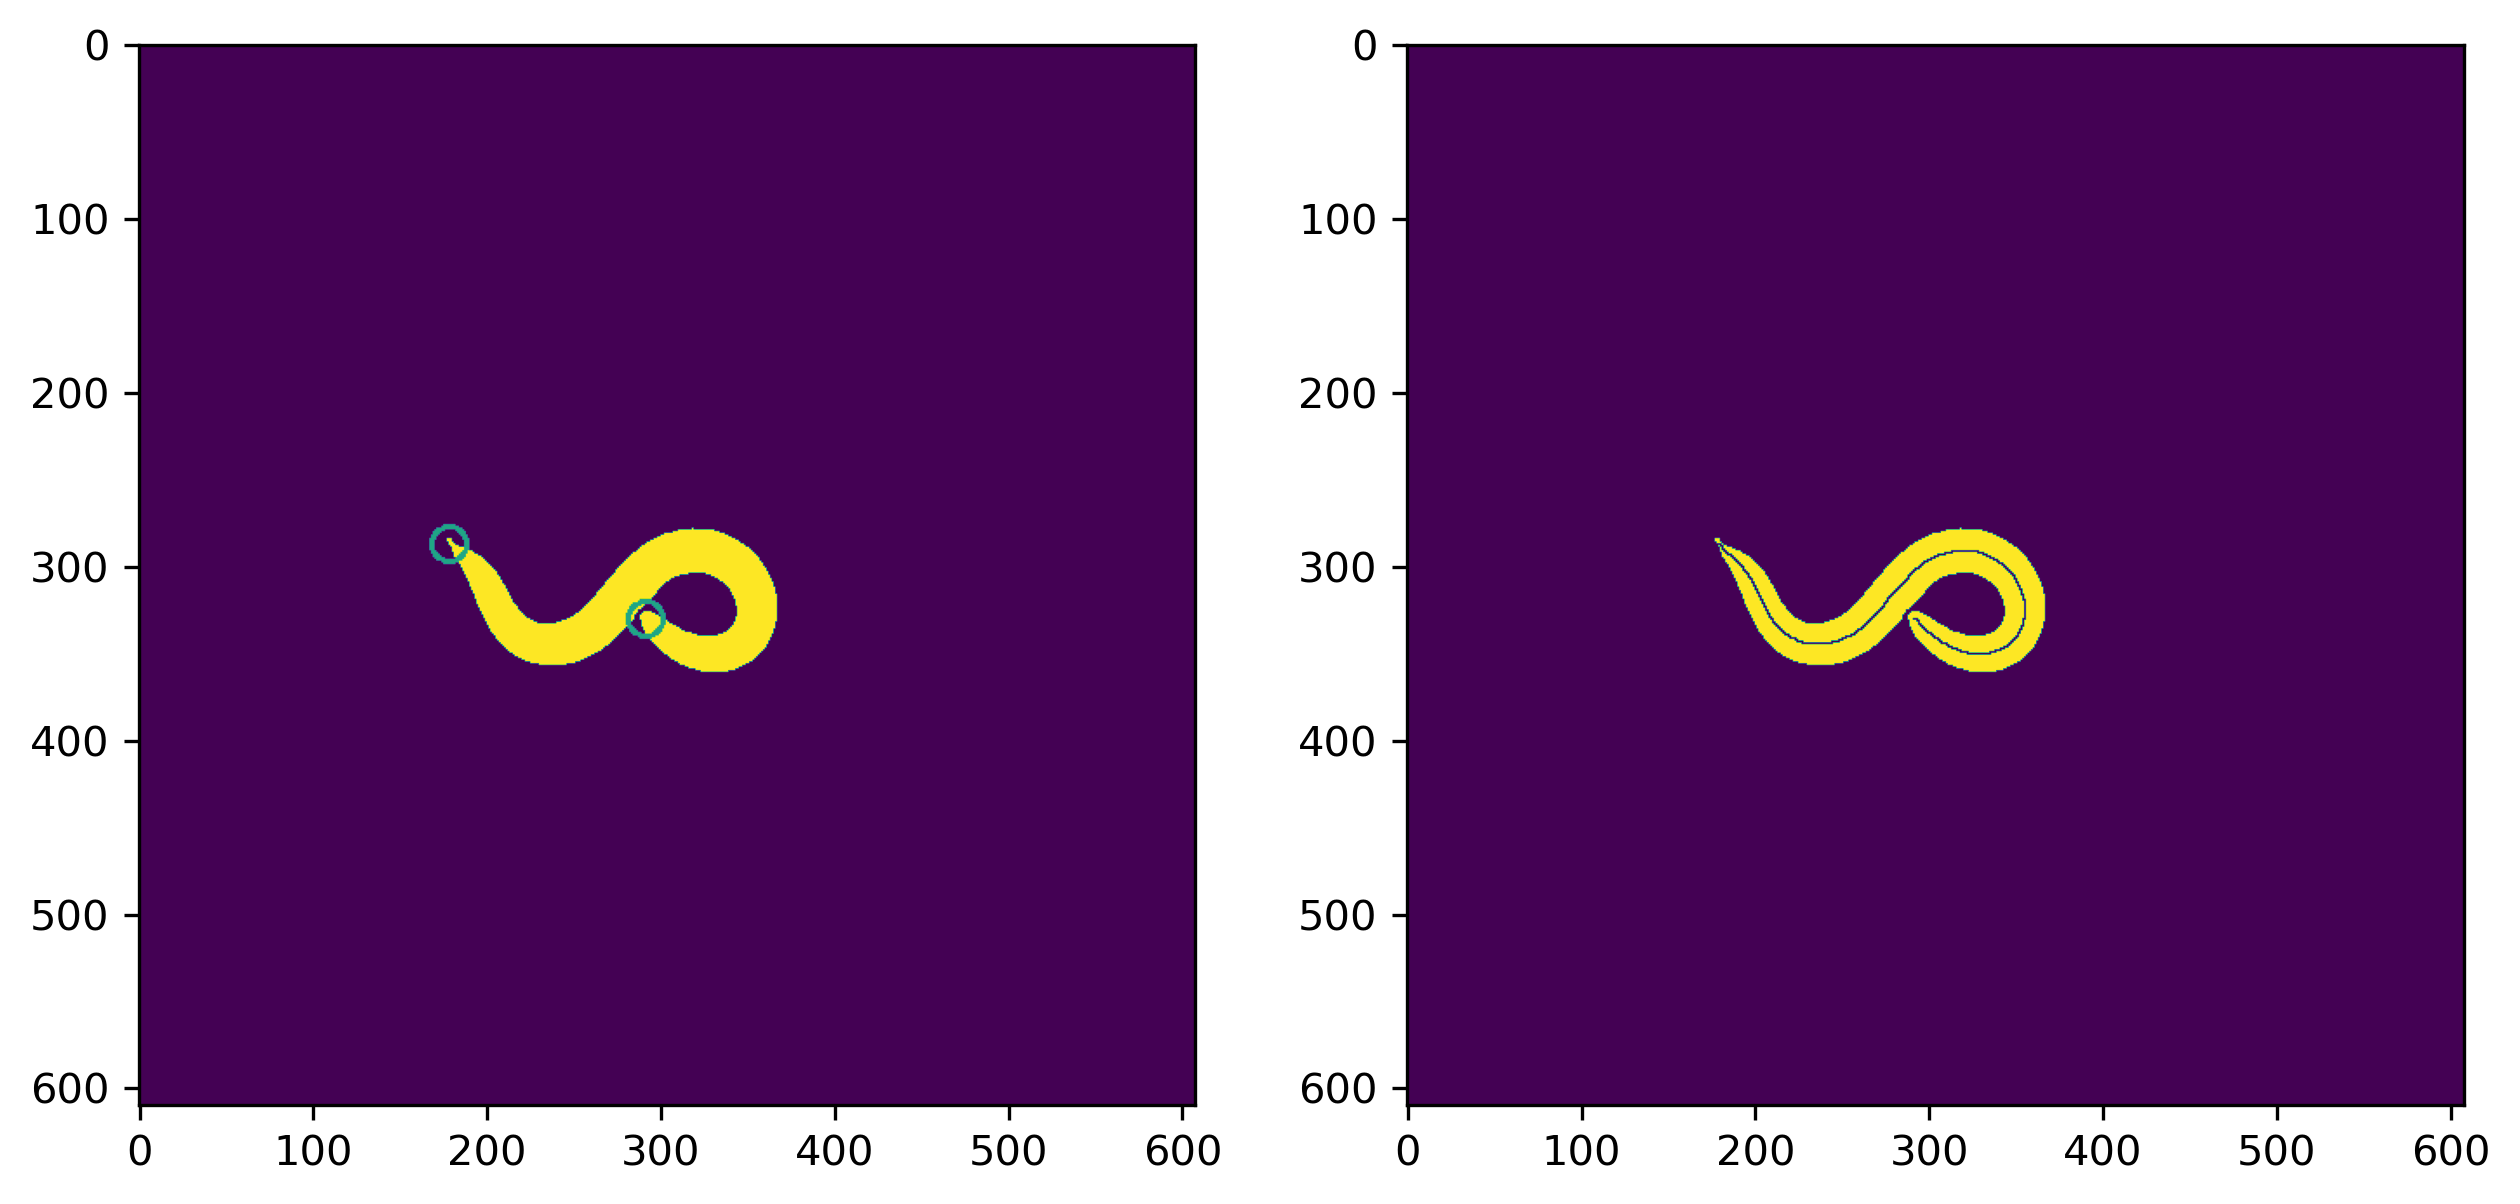

img27739.tif


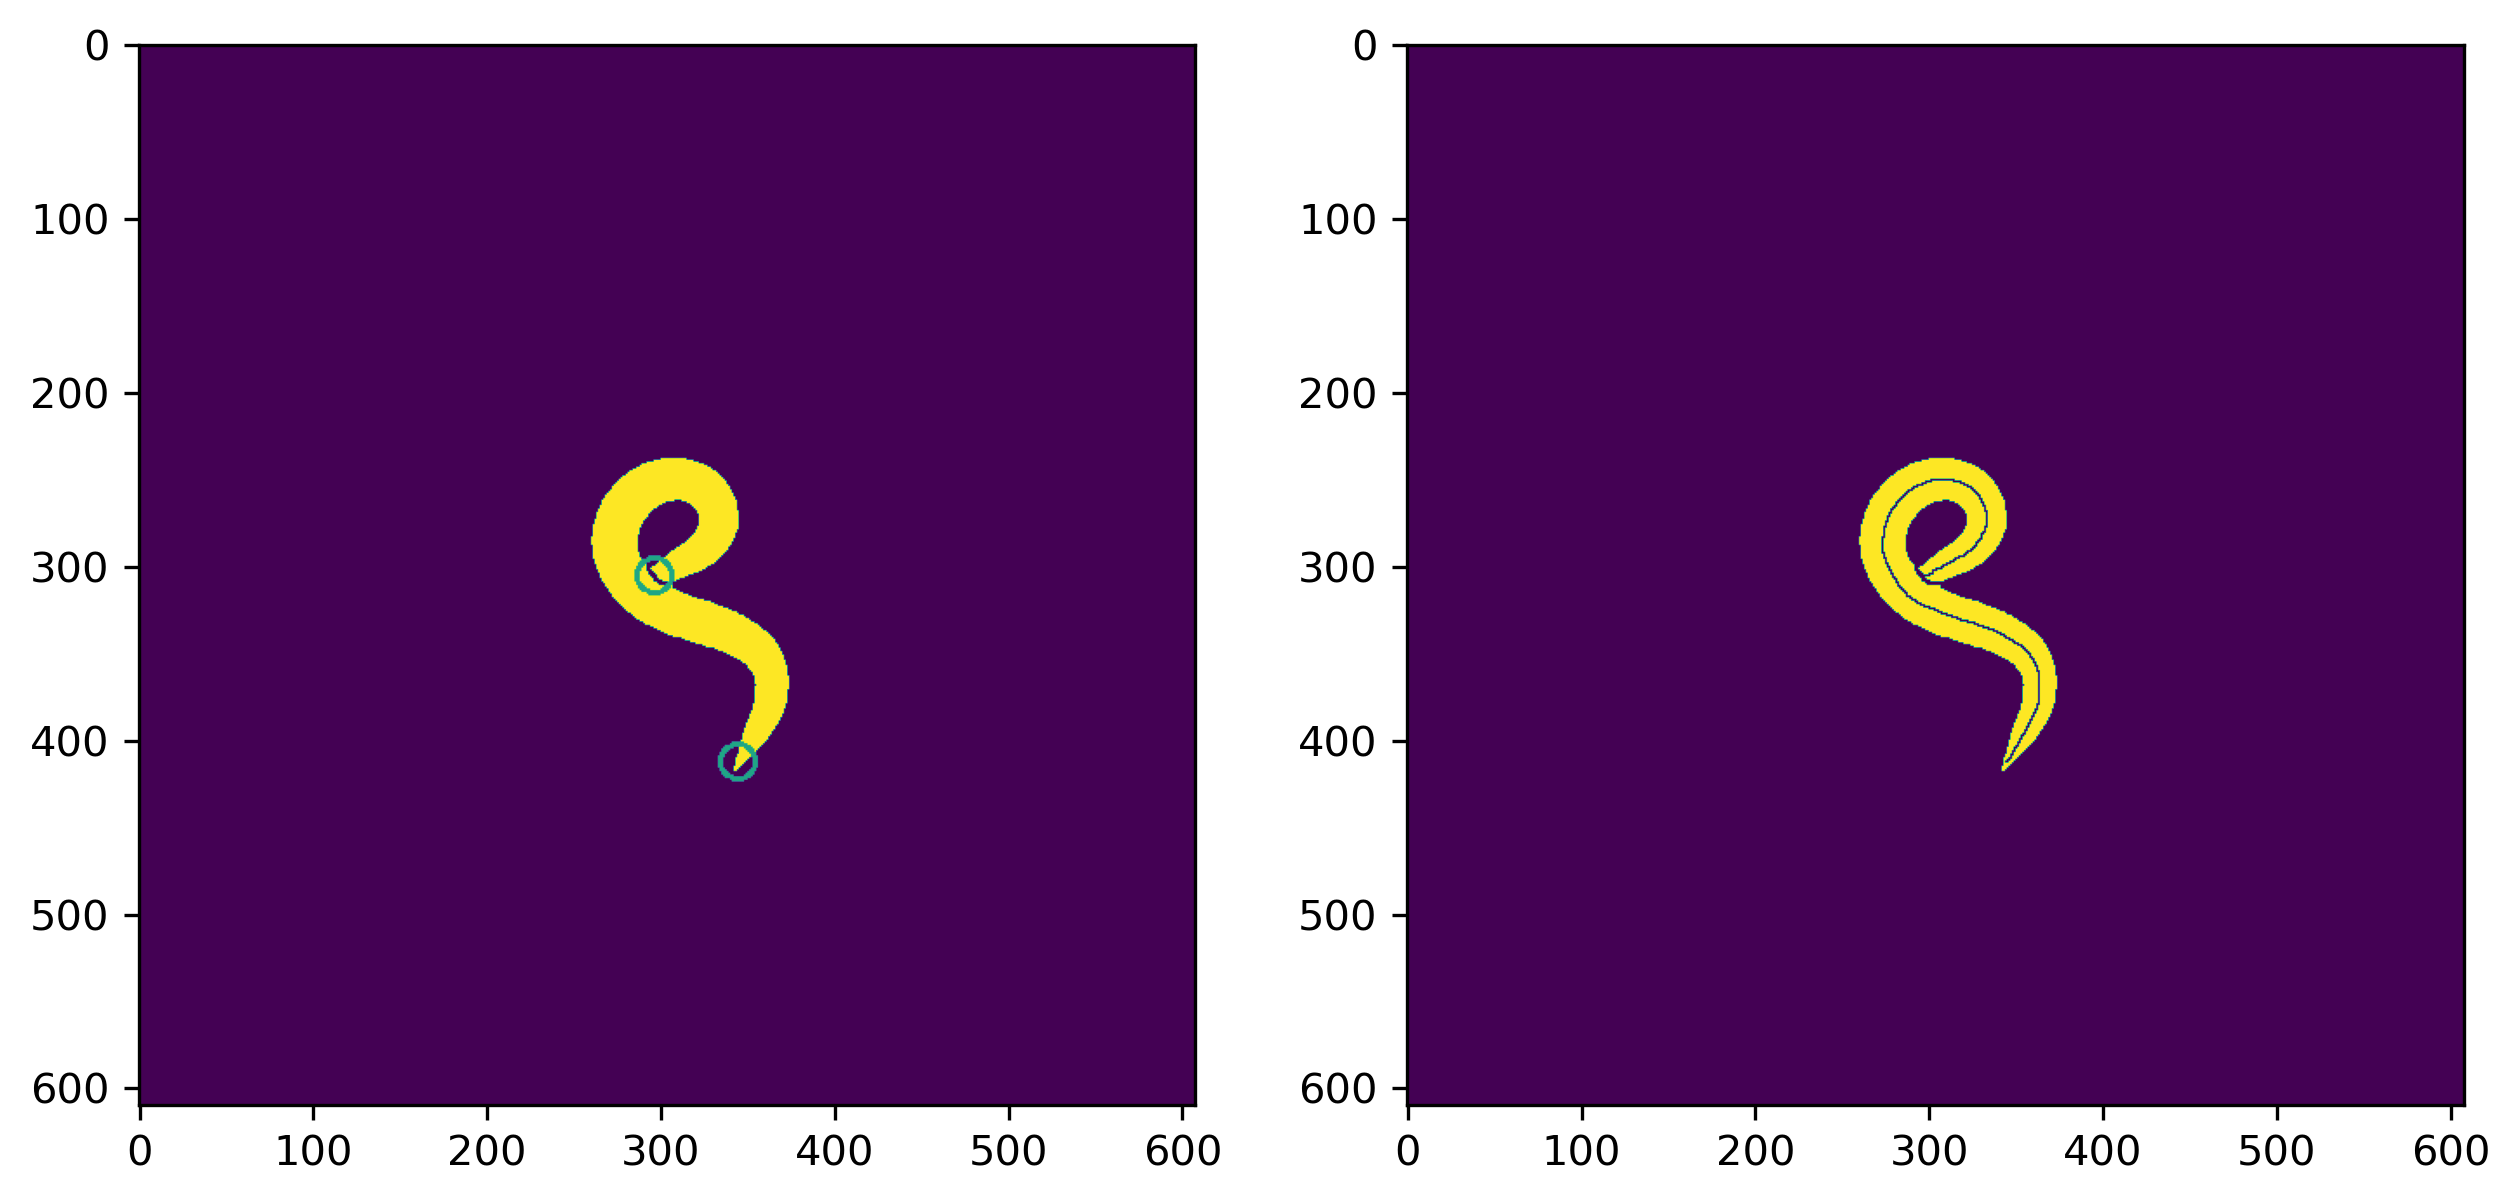

img27799.tif


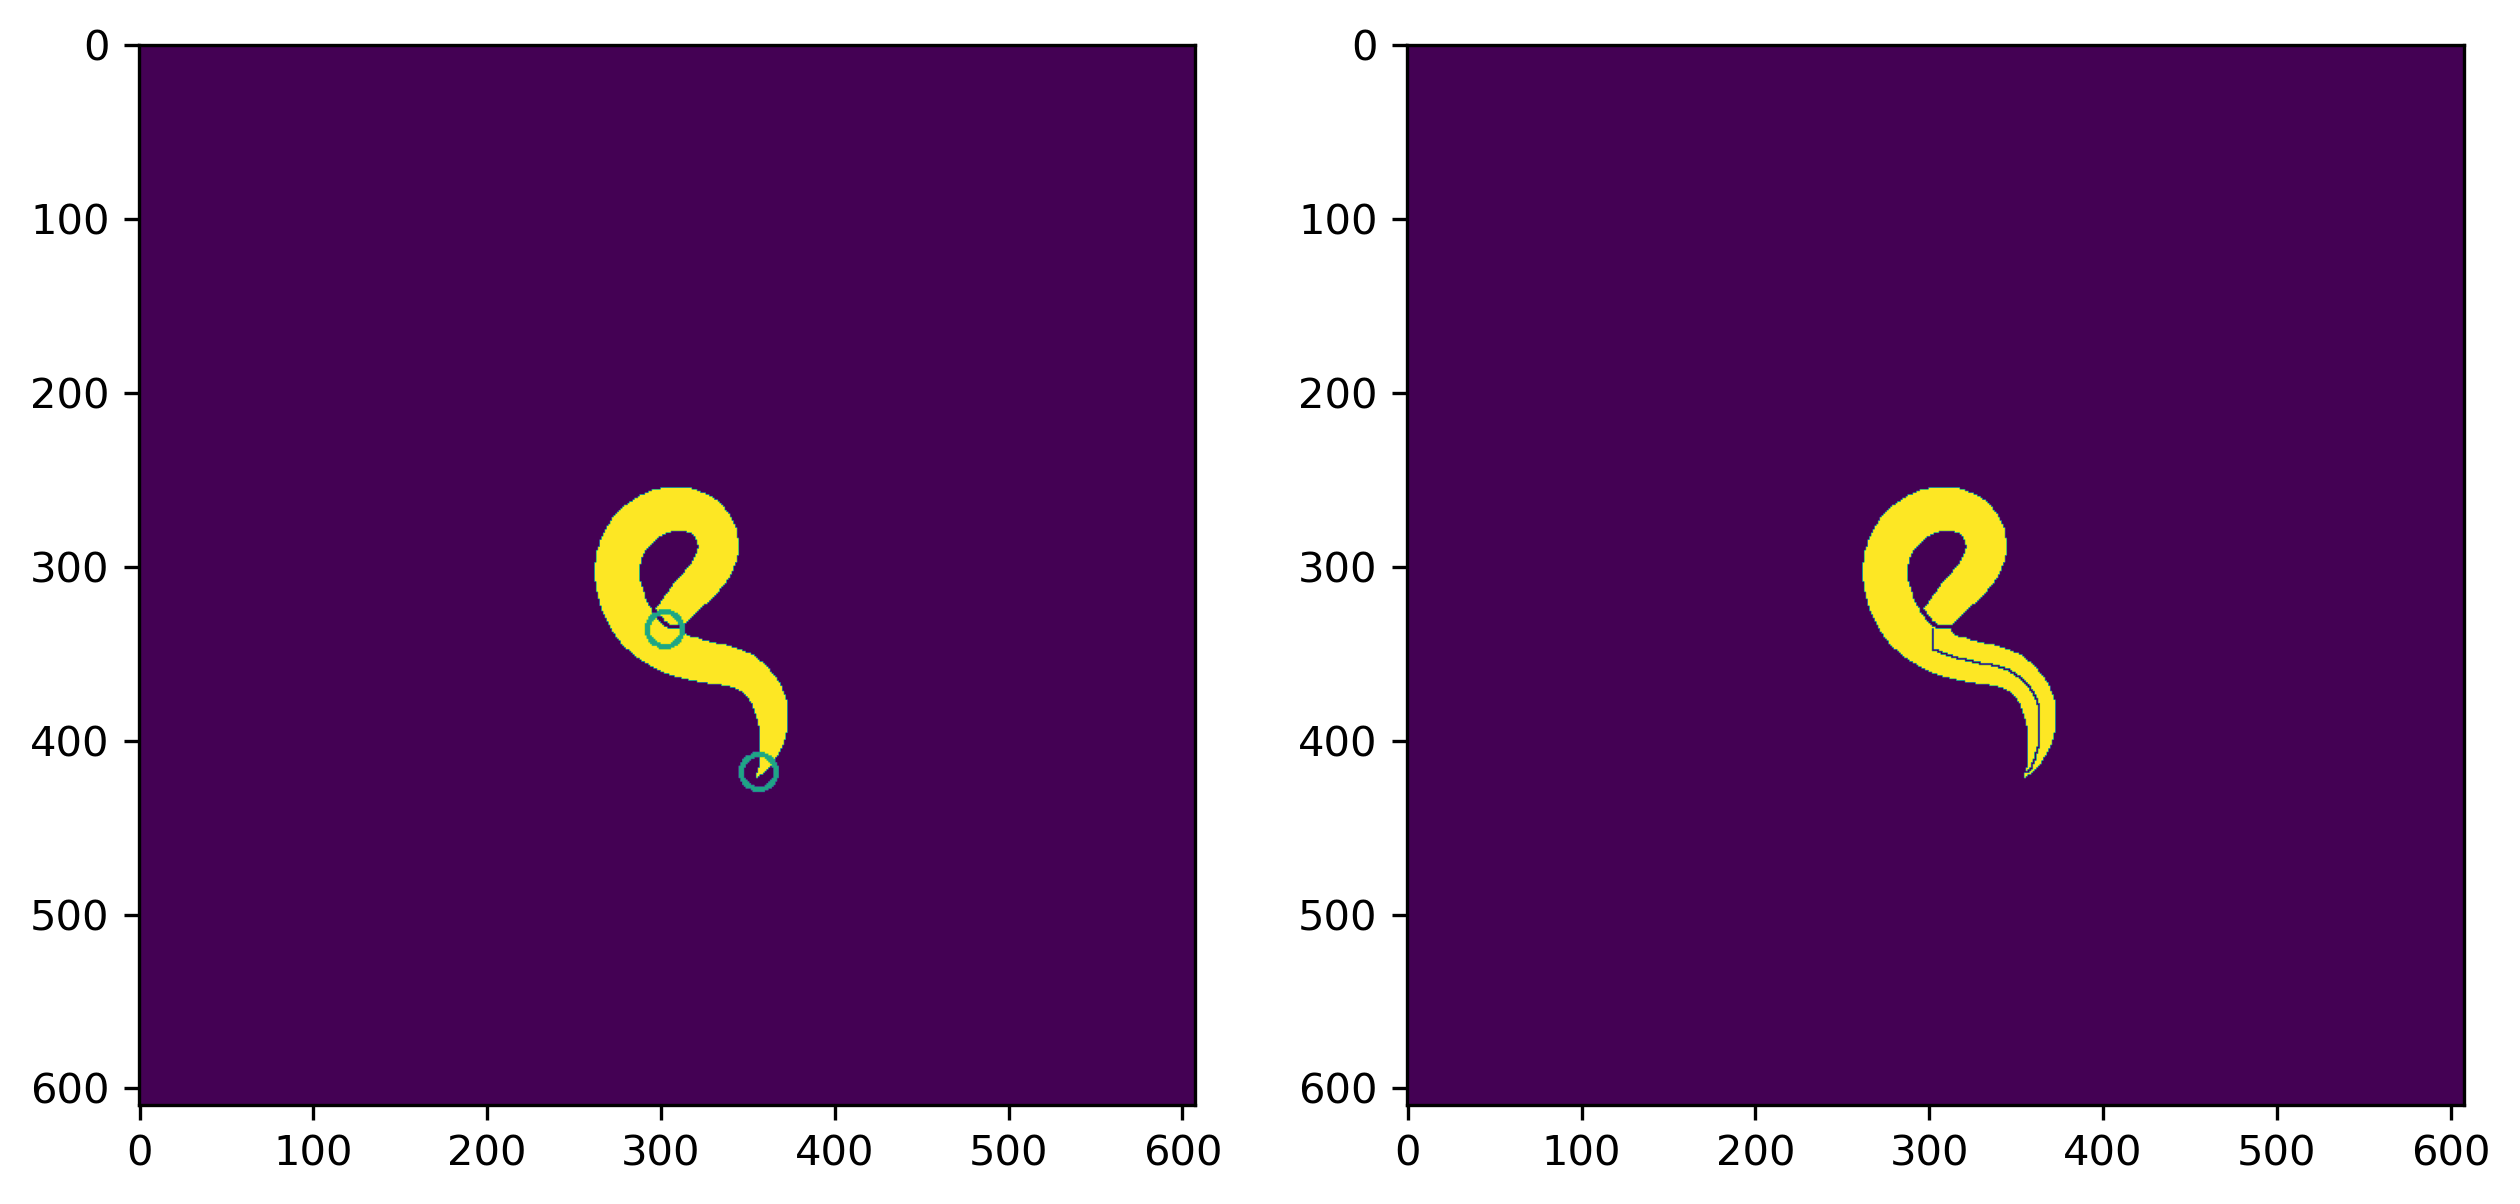

img27859.tif
head and tail were too close, no centerline could be created
img27919.tif


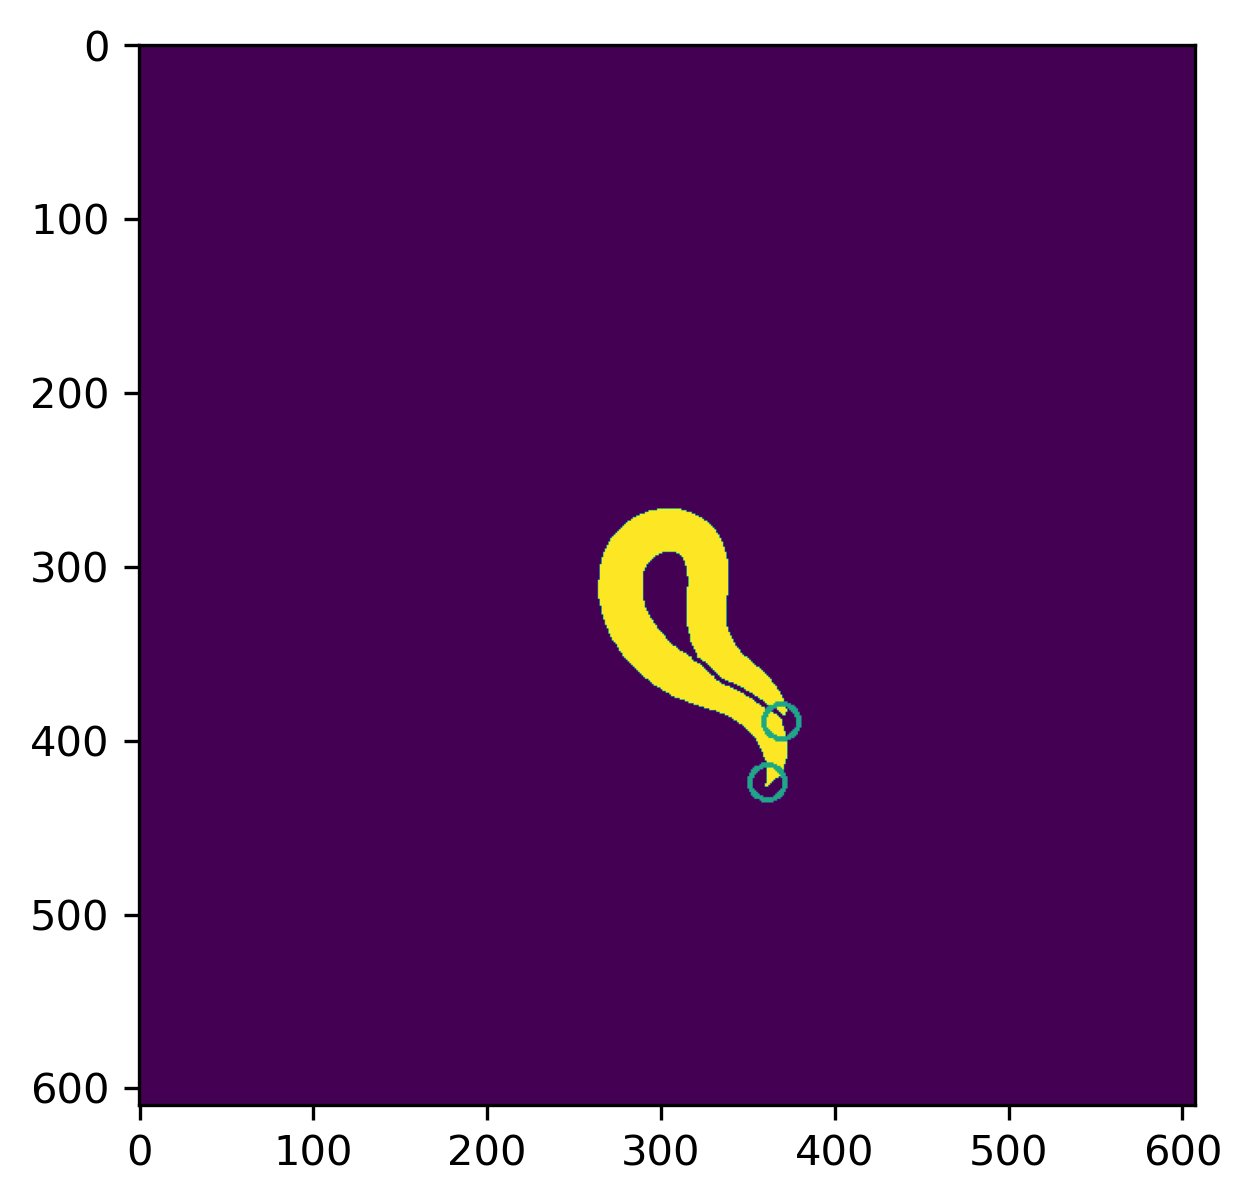

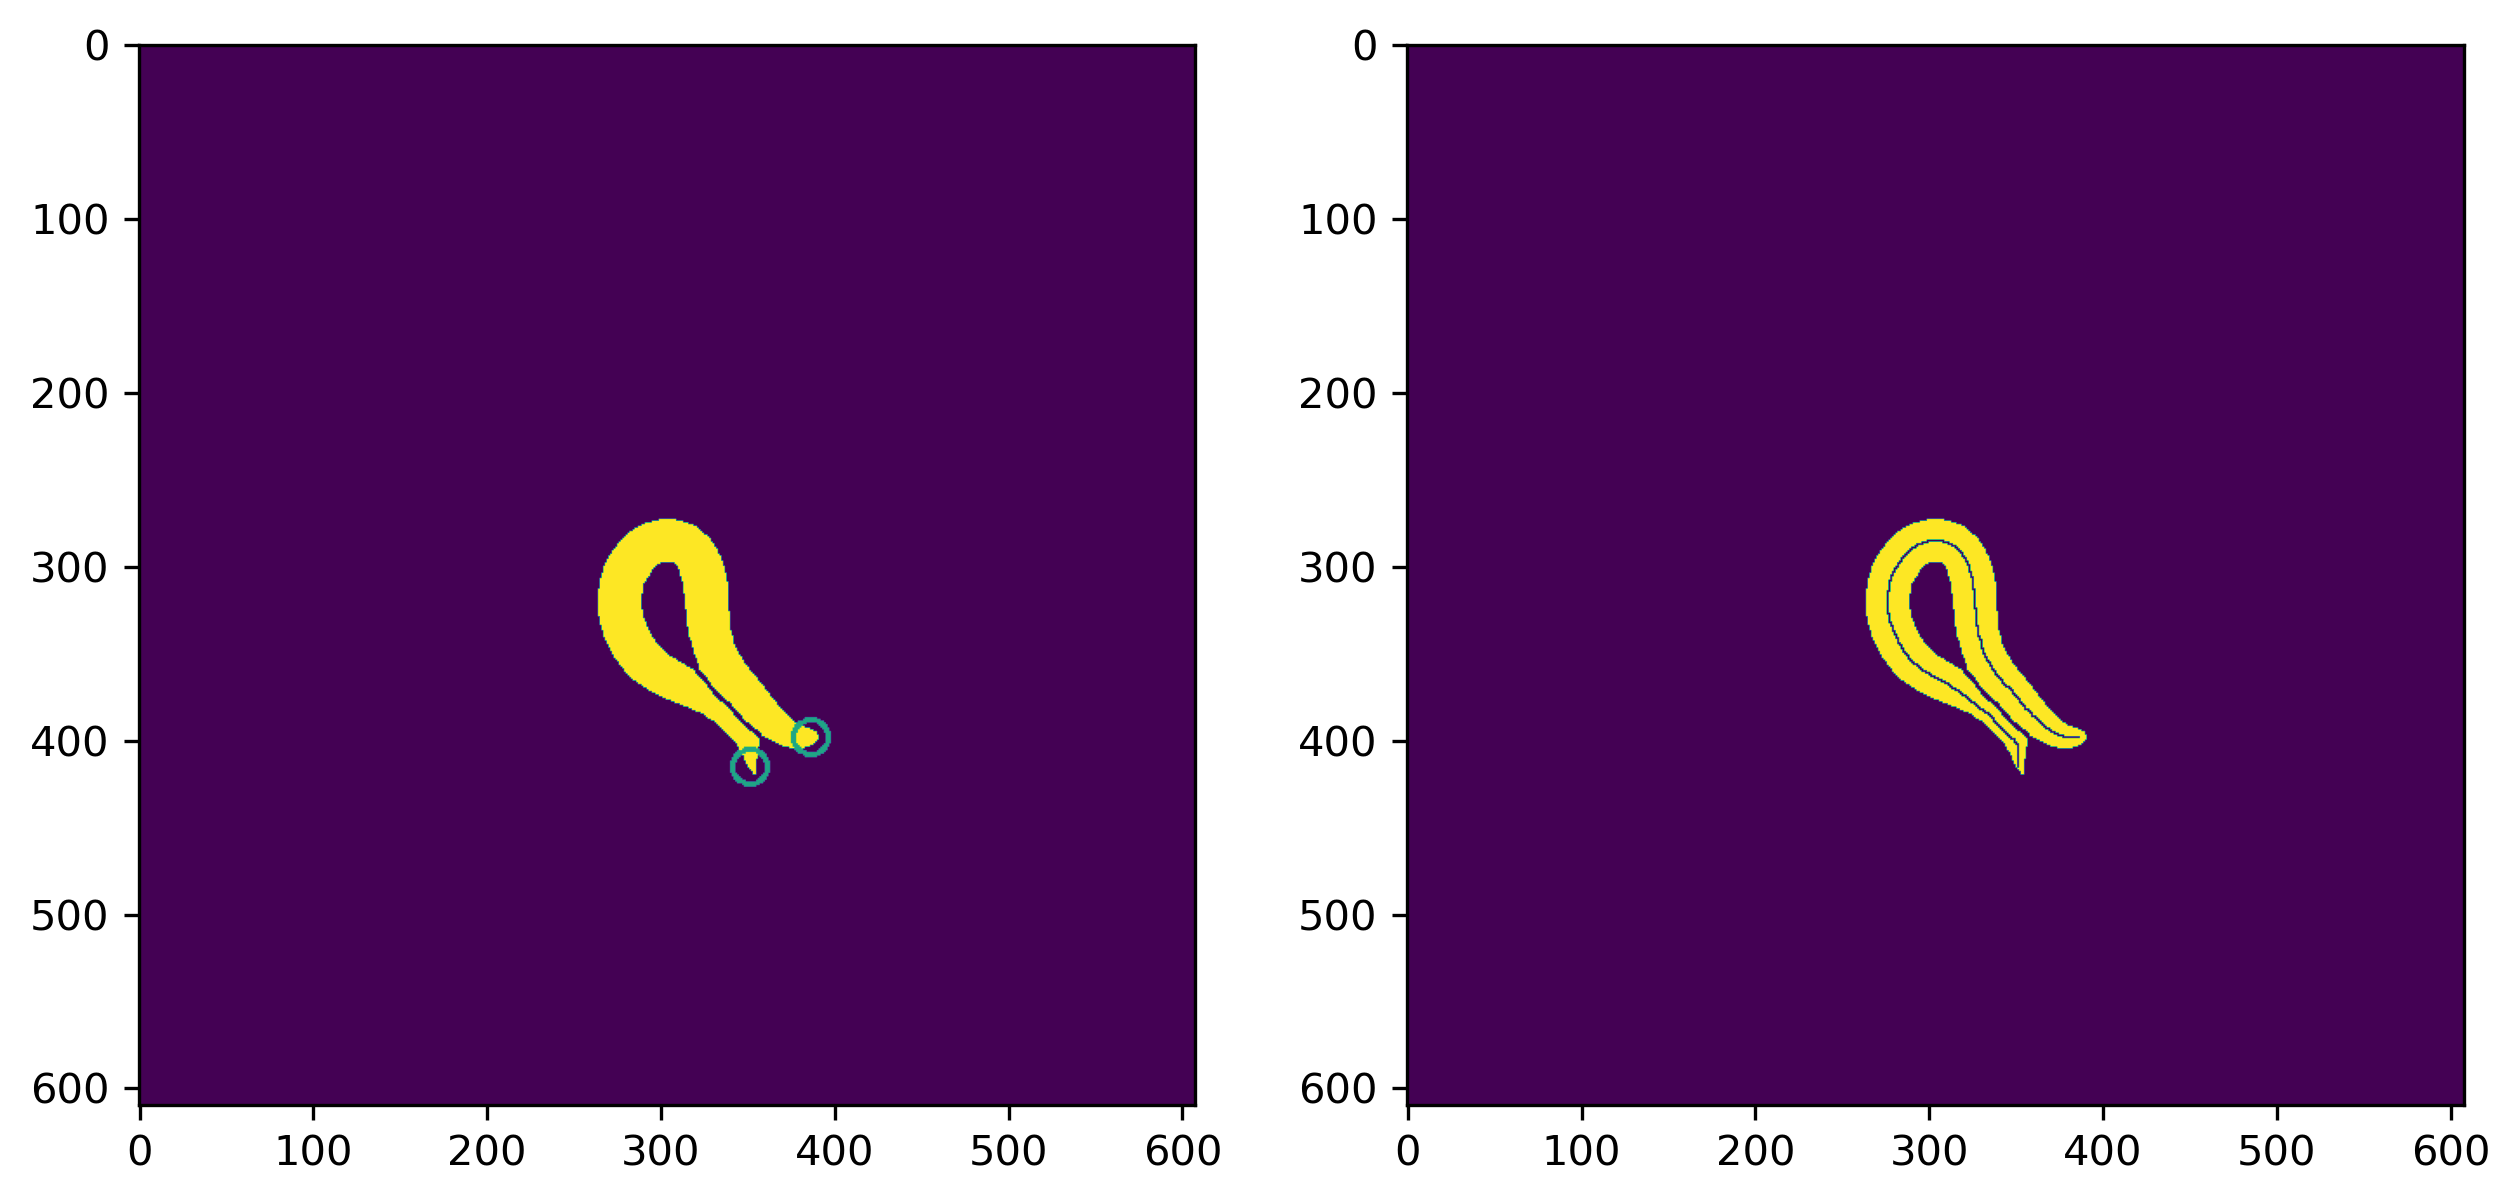

img27979.tif


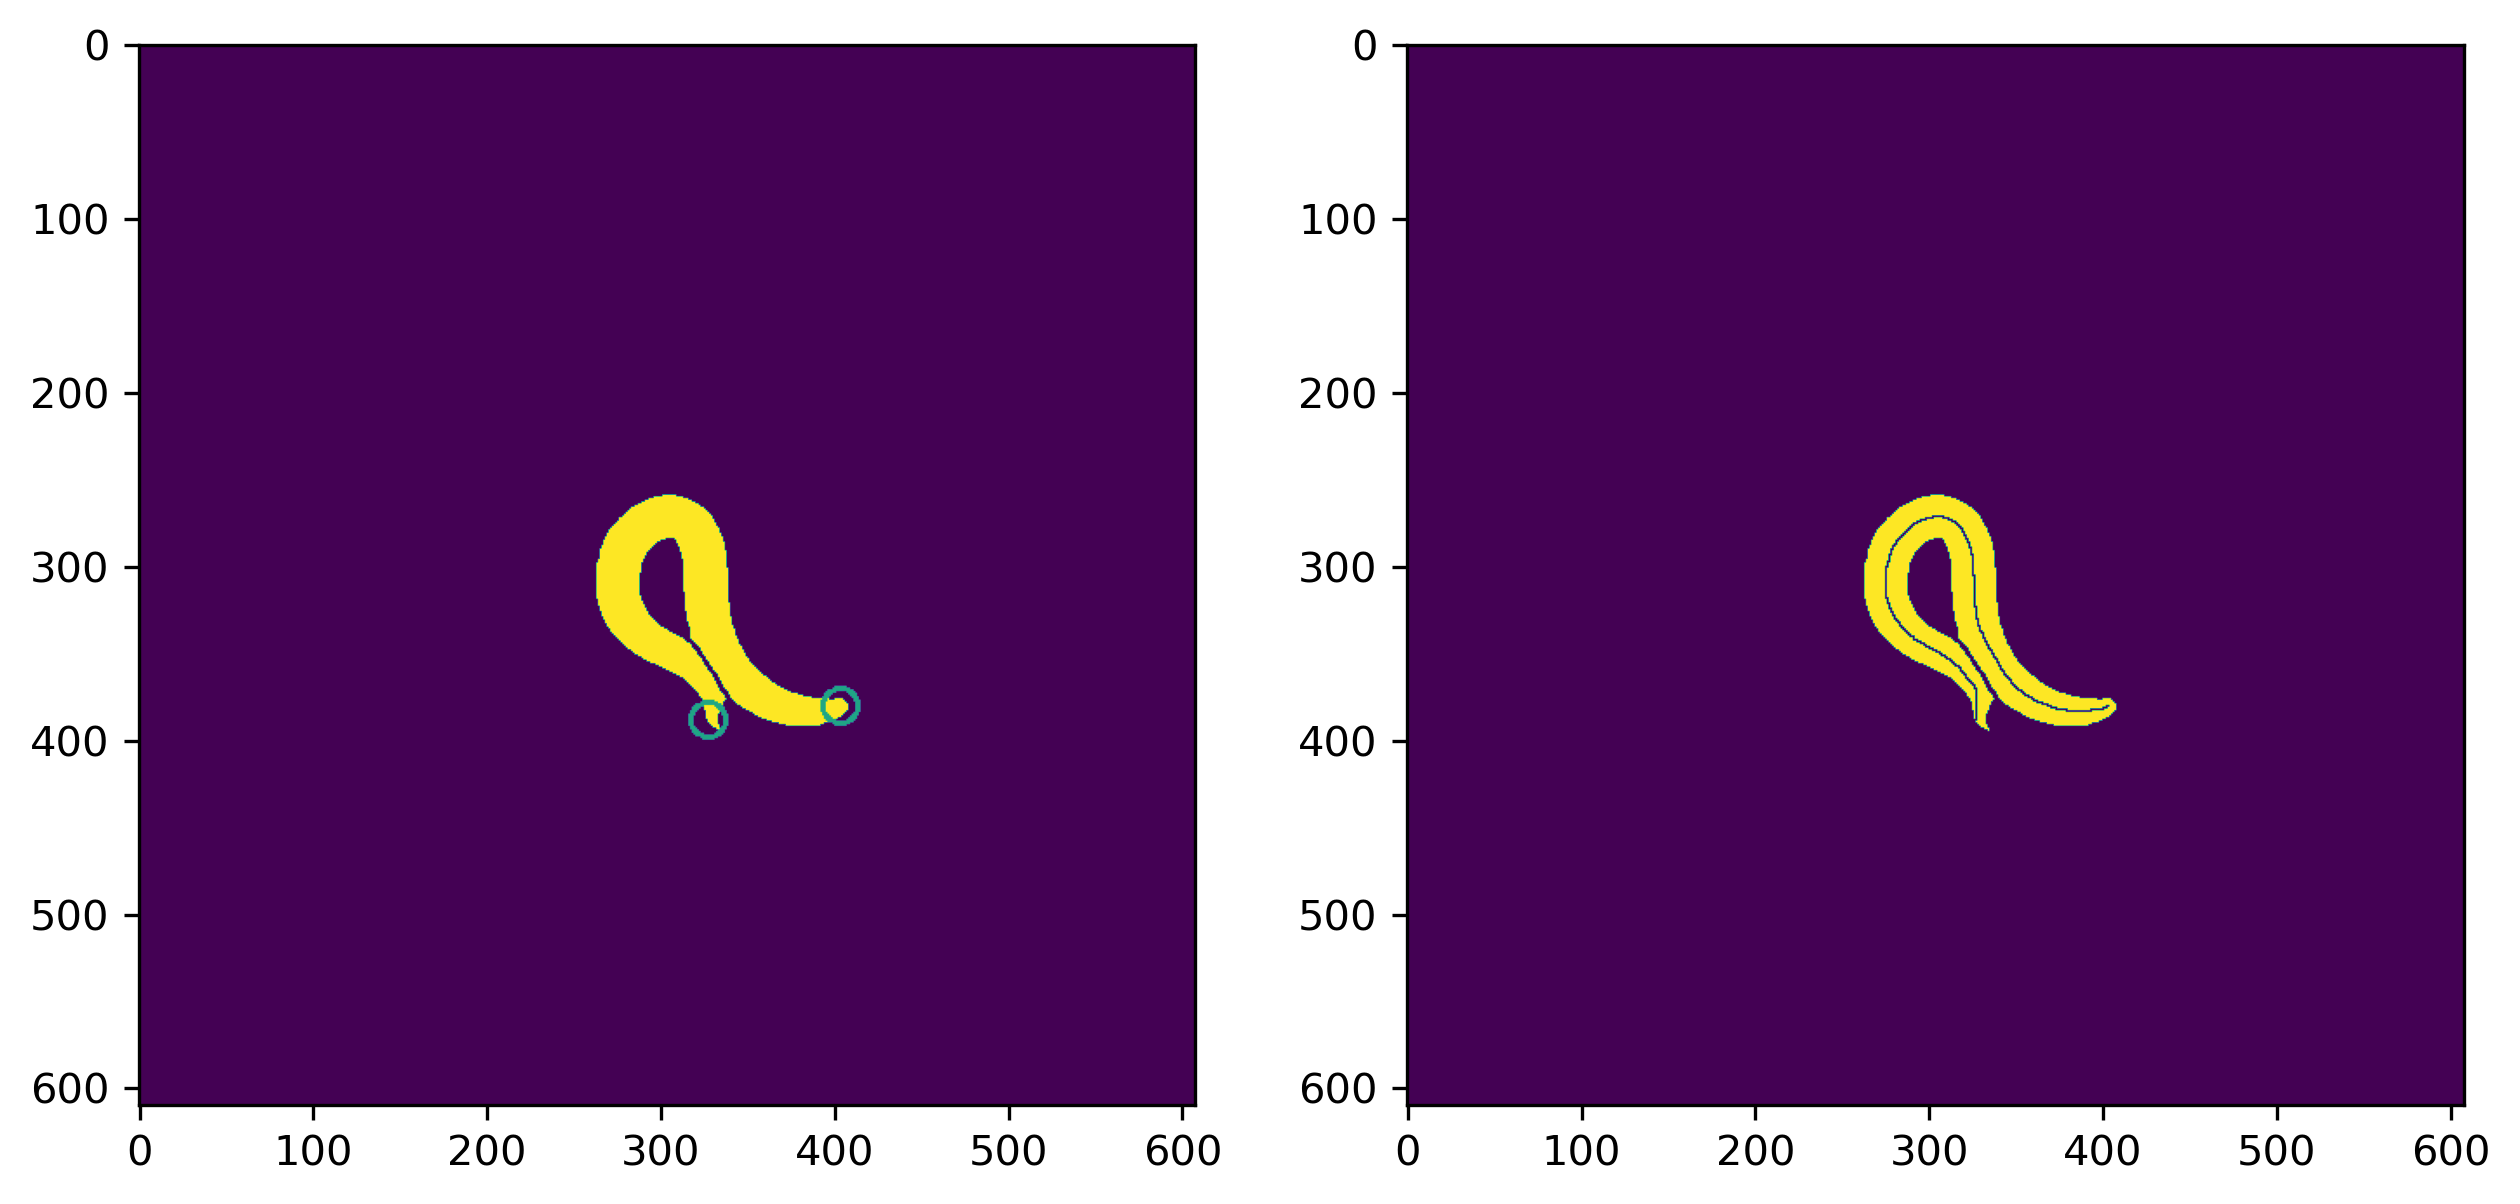

img28039.tif


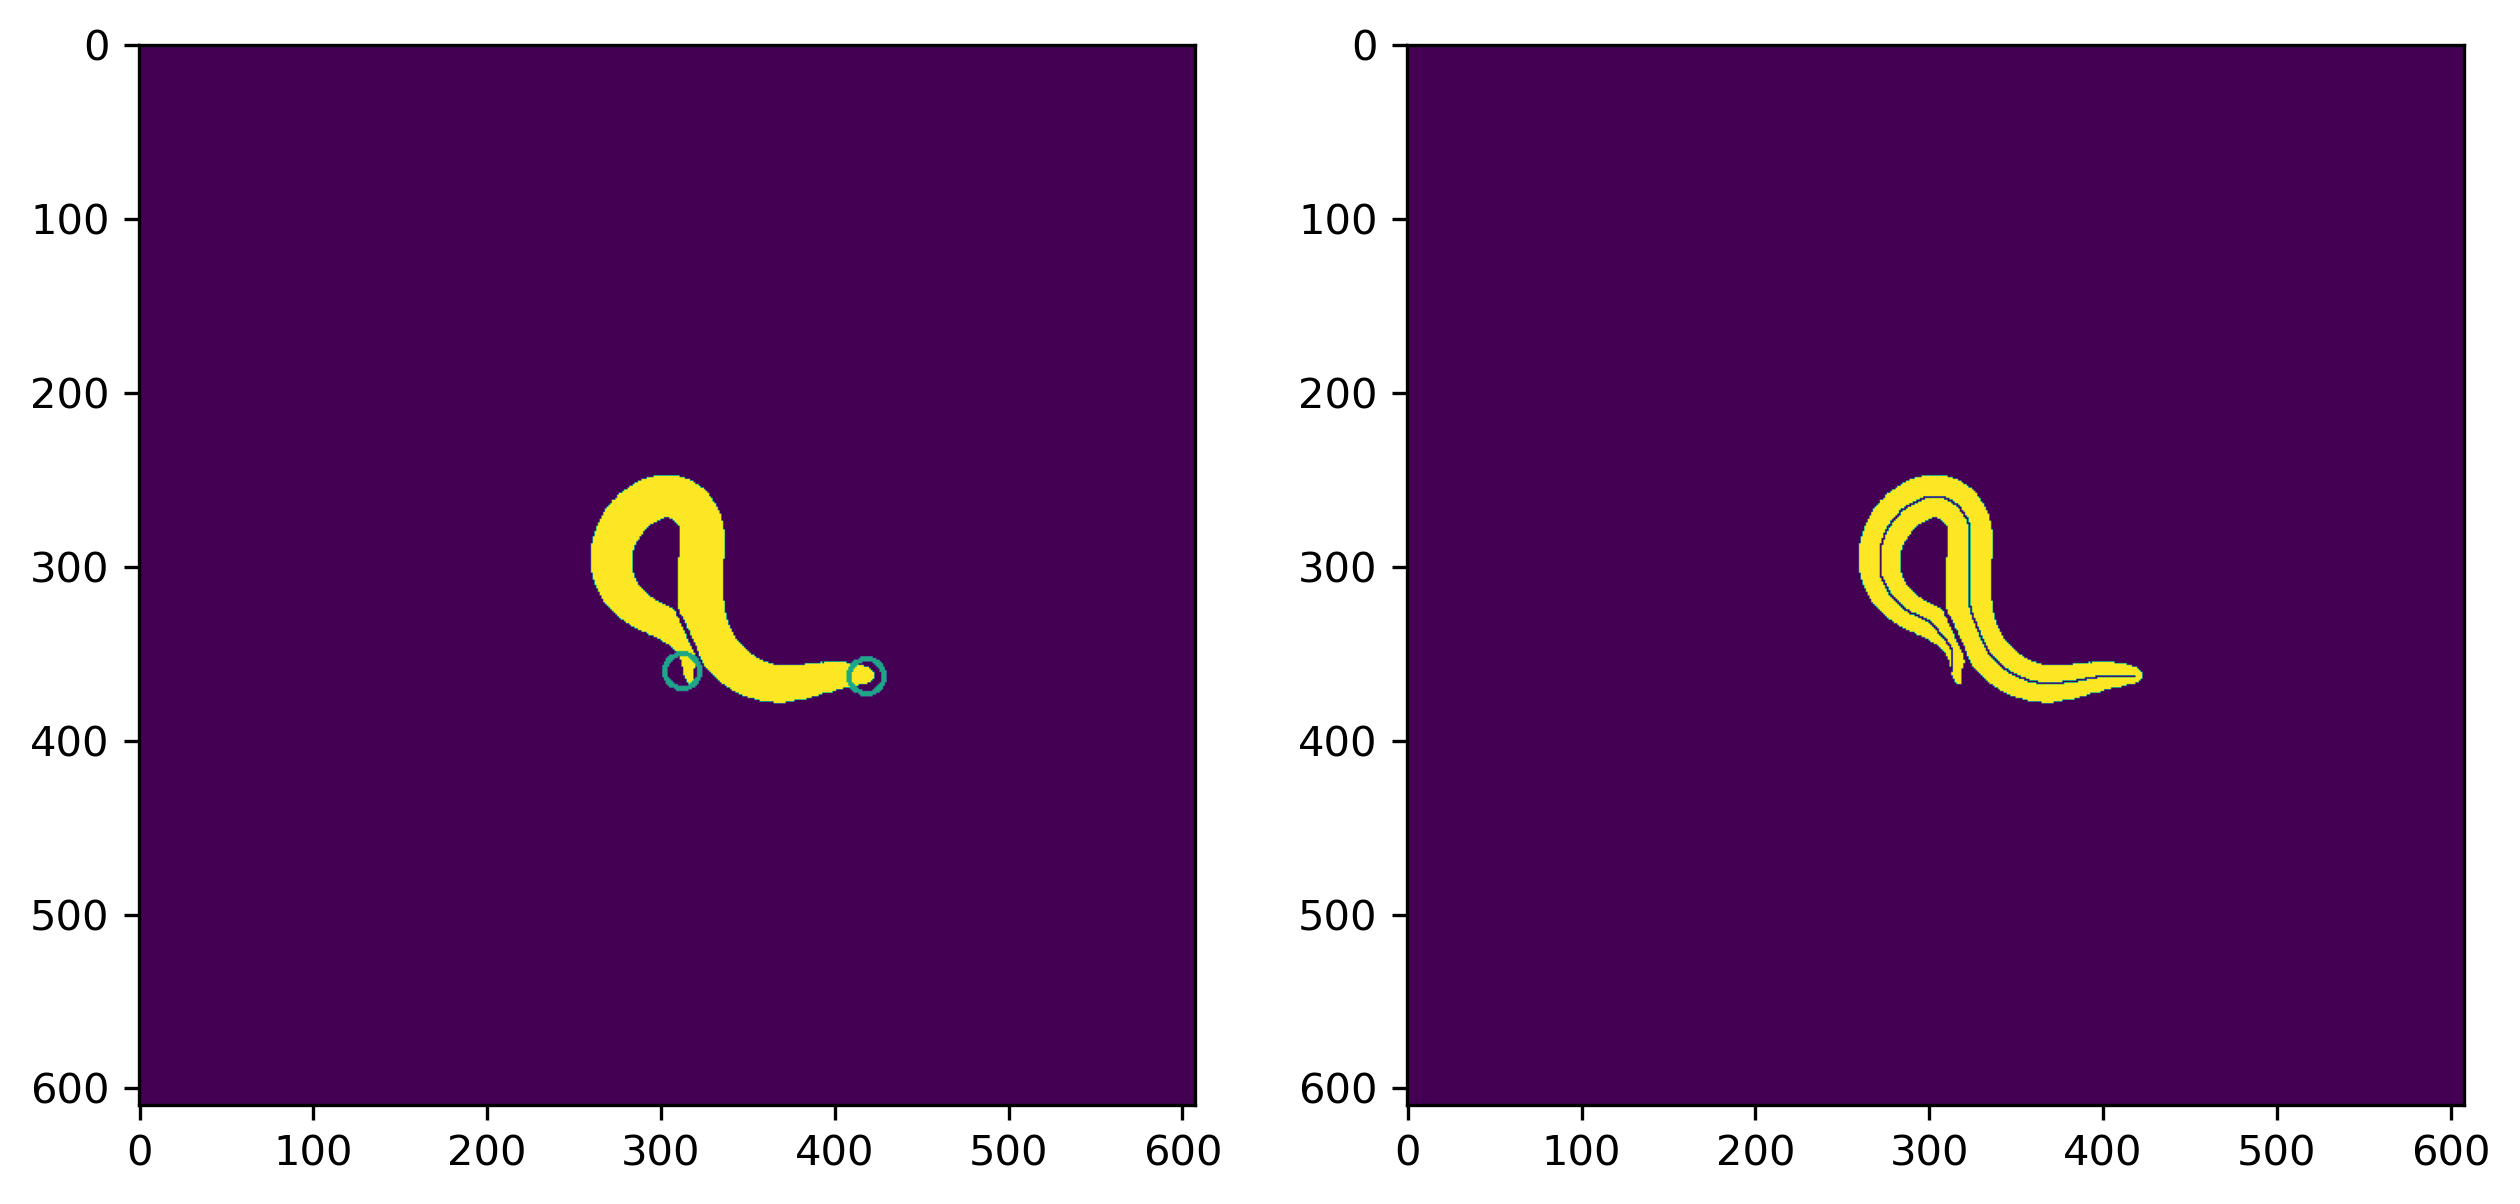

img28099.tif


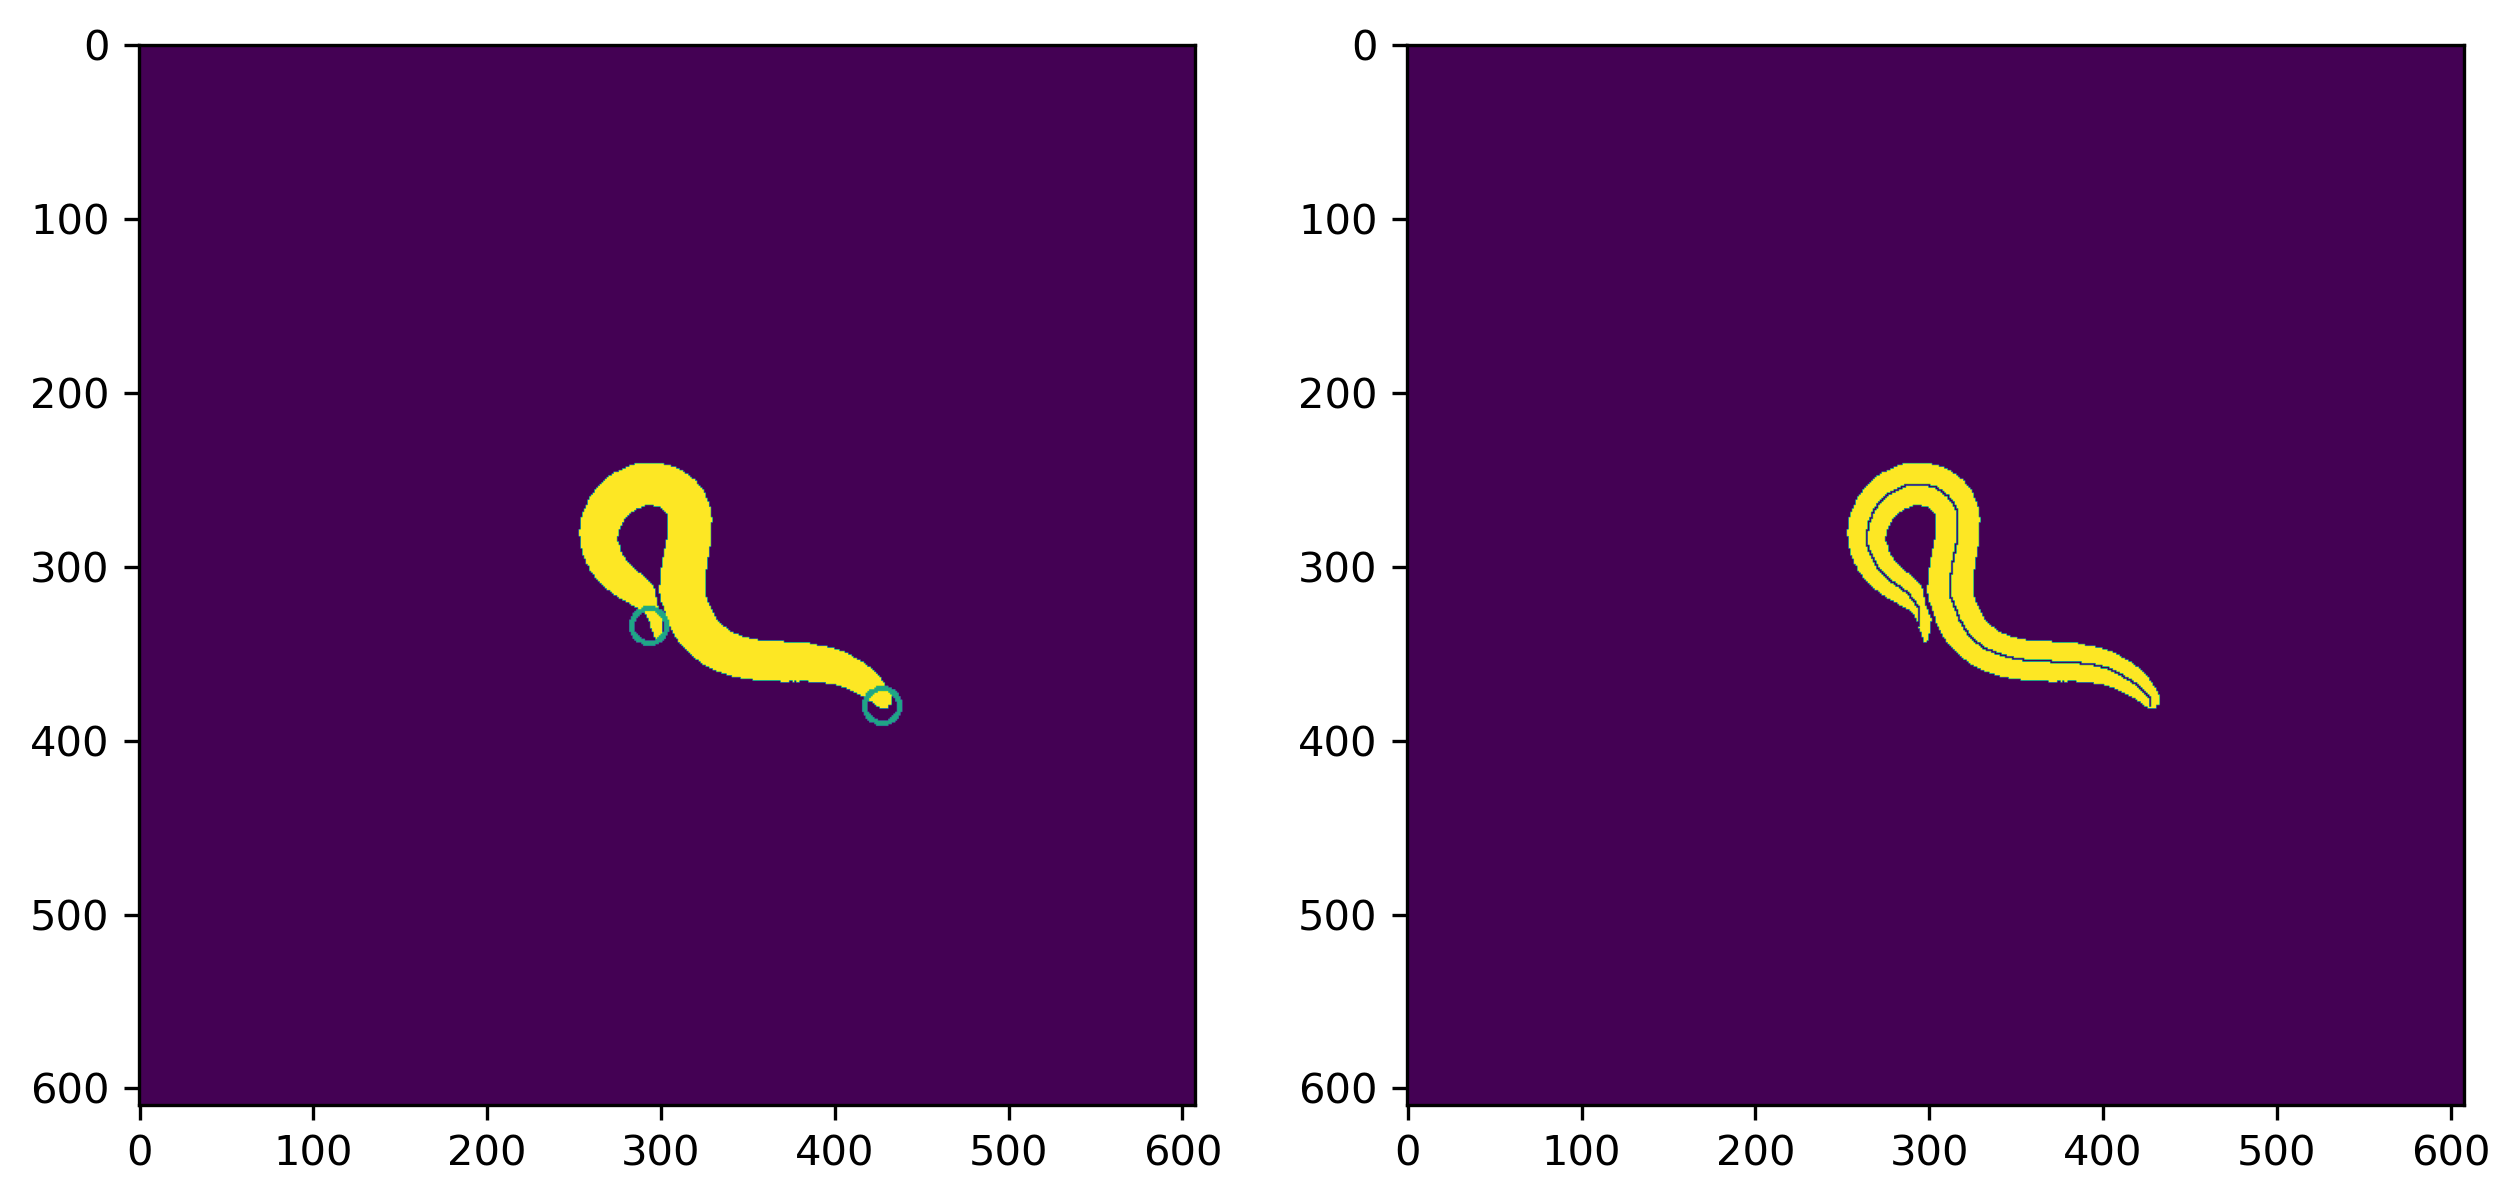

img34797.tif


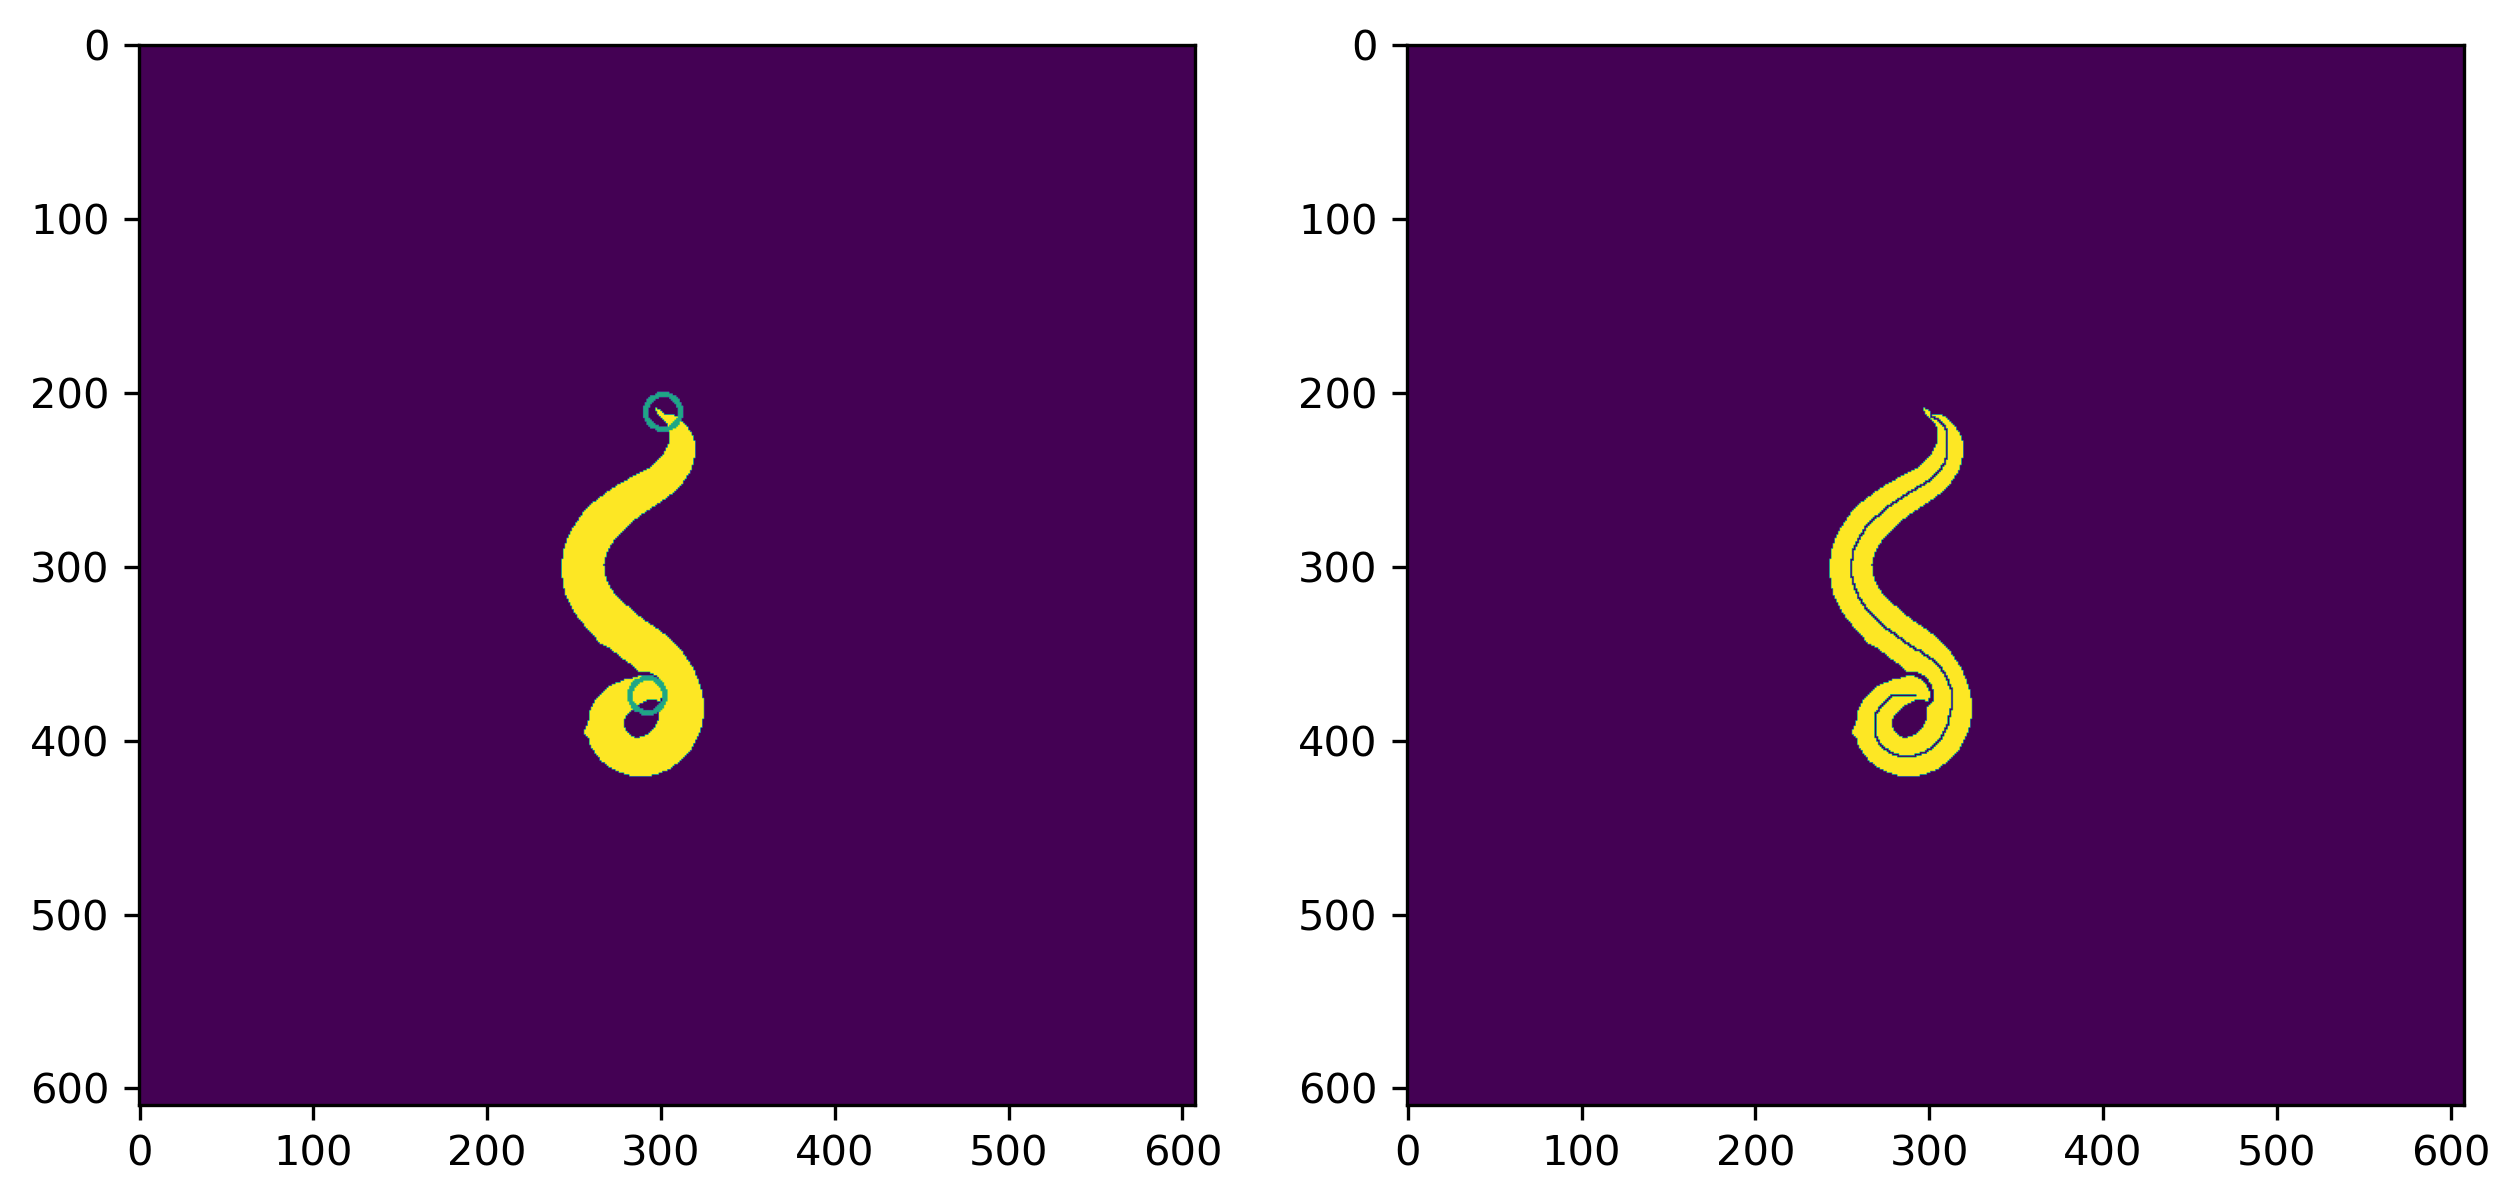

img34917.tif


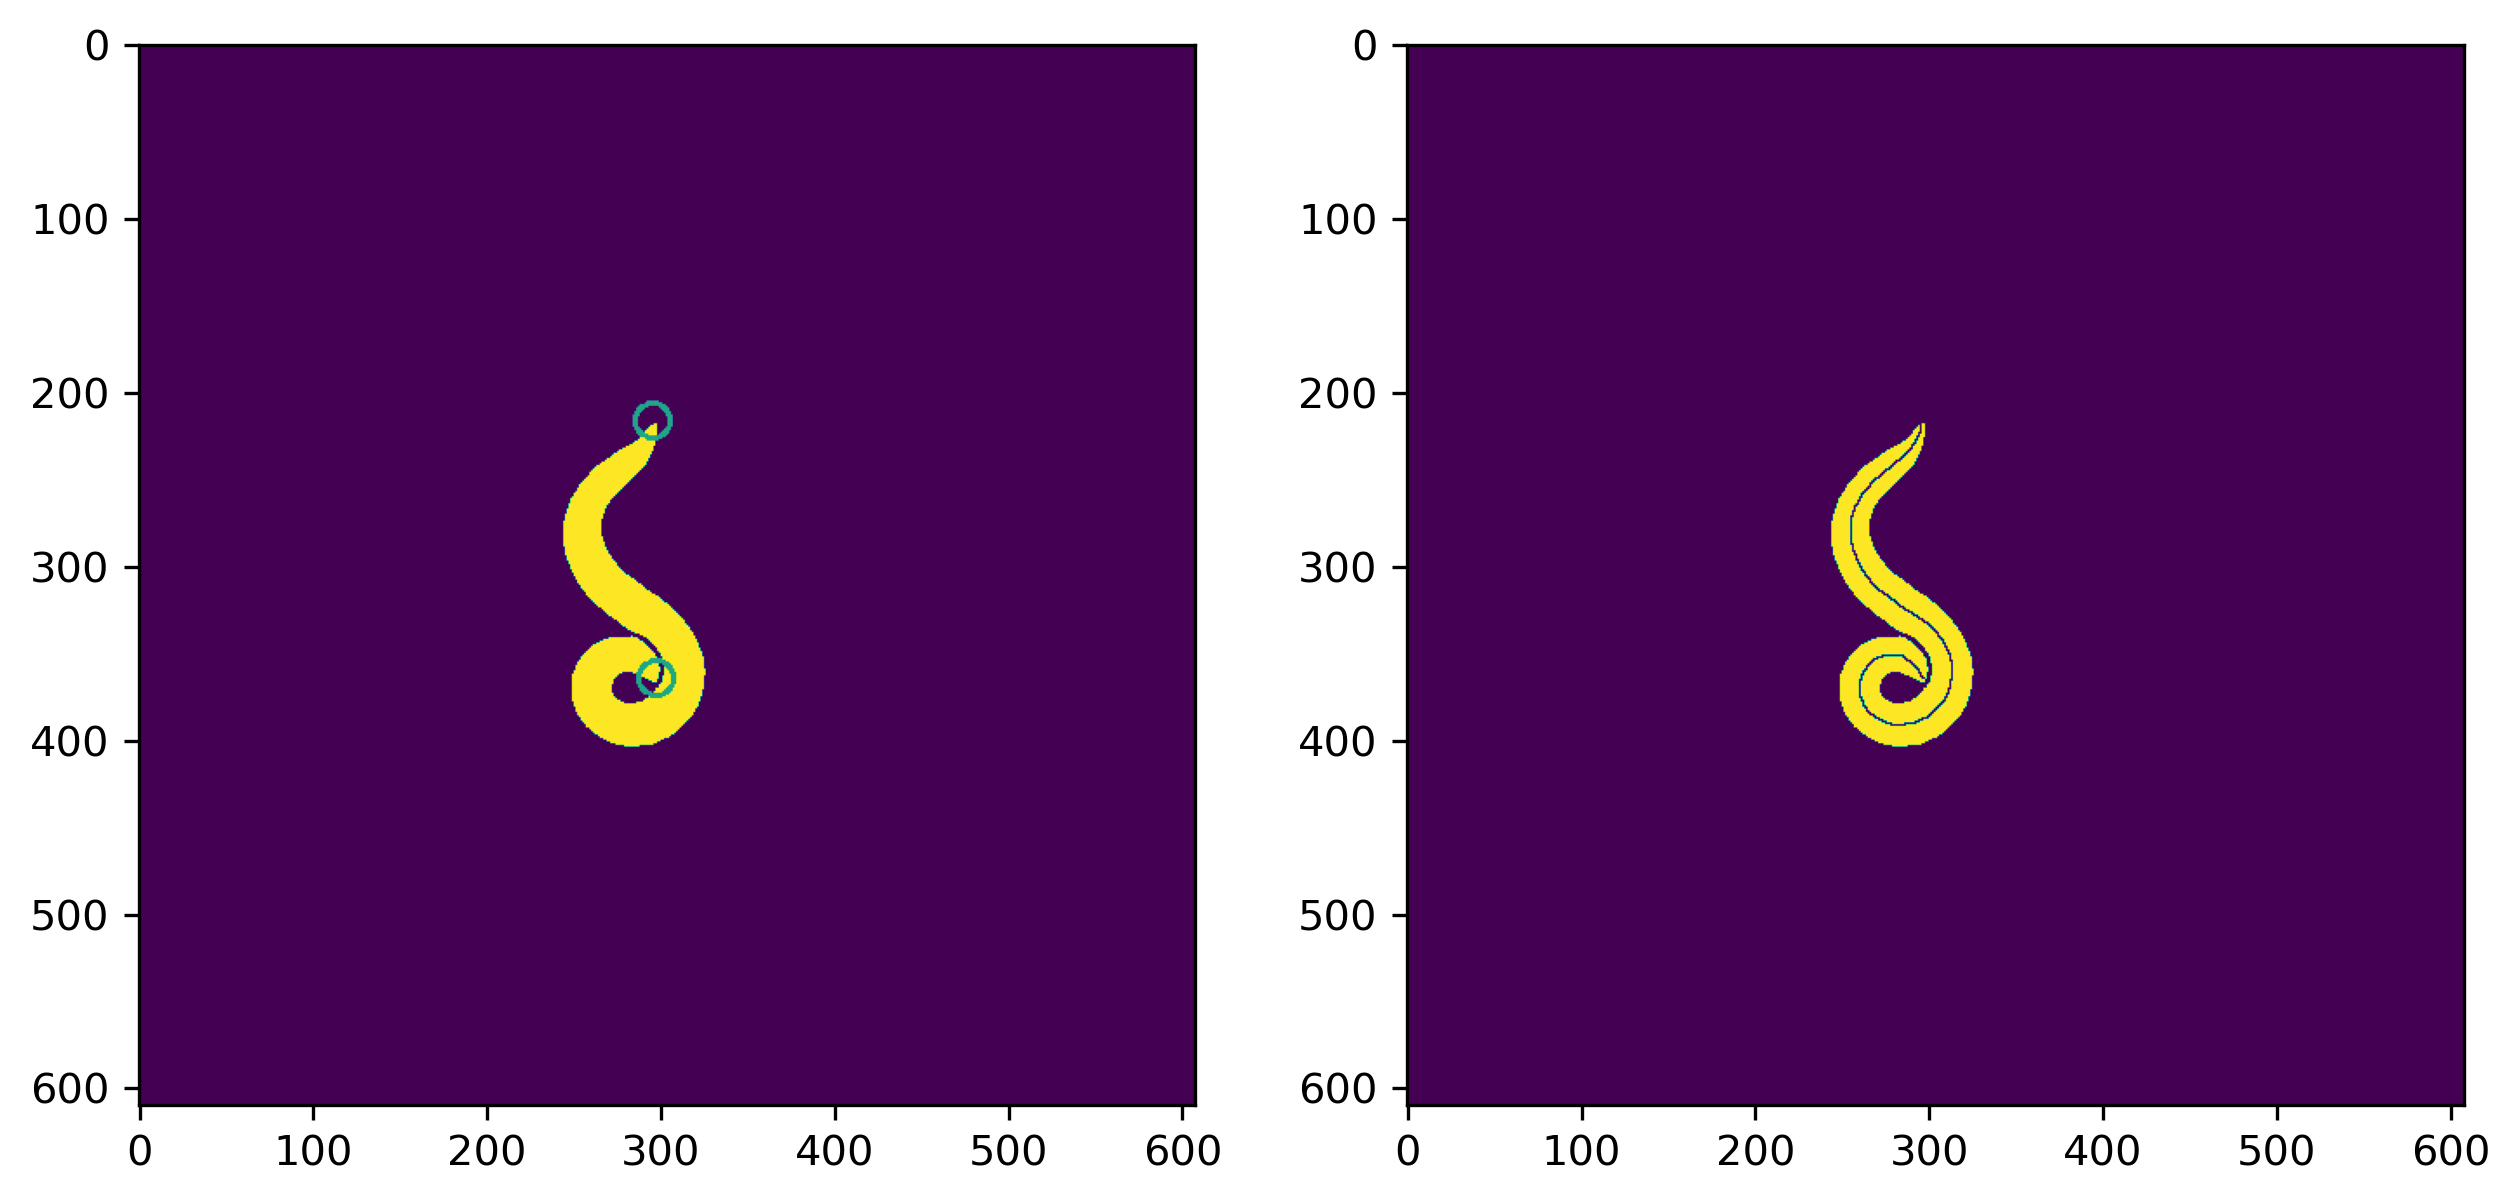

img34977.tif
head and tail were too close, no centerline could be created
img35037.tif
head and tail were too close, no centerline could be created
img35097.tif
head and tail were too close, no centerline could be created
img35157.tif
head and tail were too close, no centerline could be created
img35217.tif


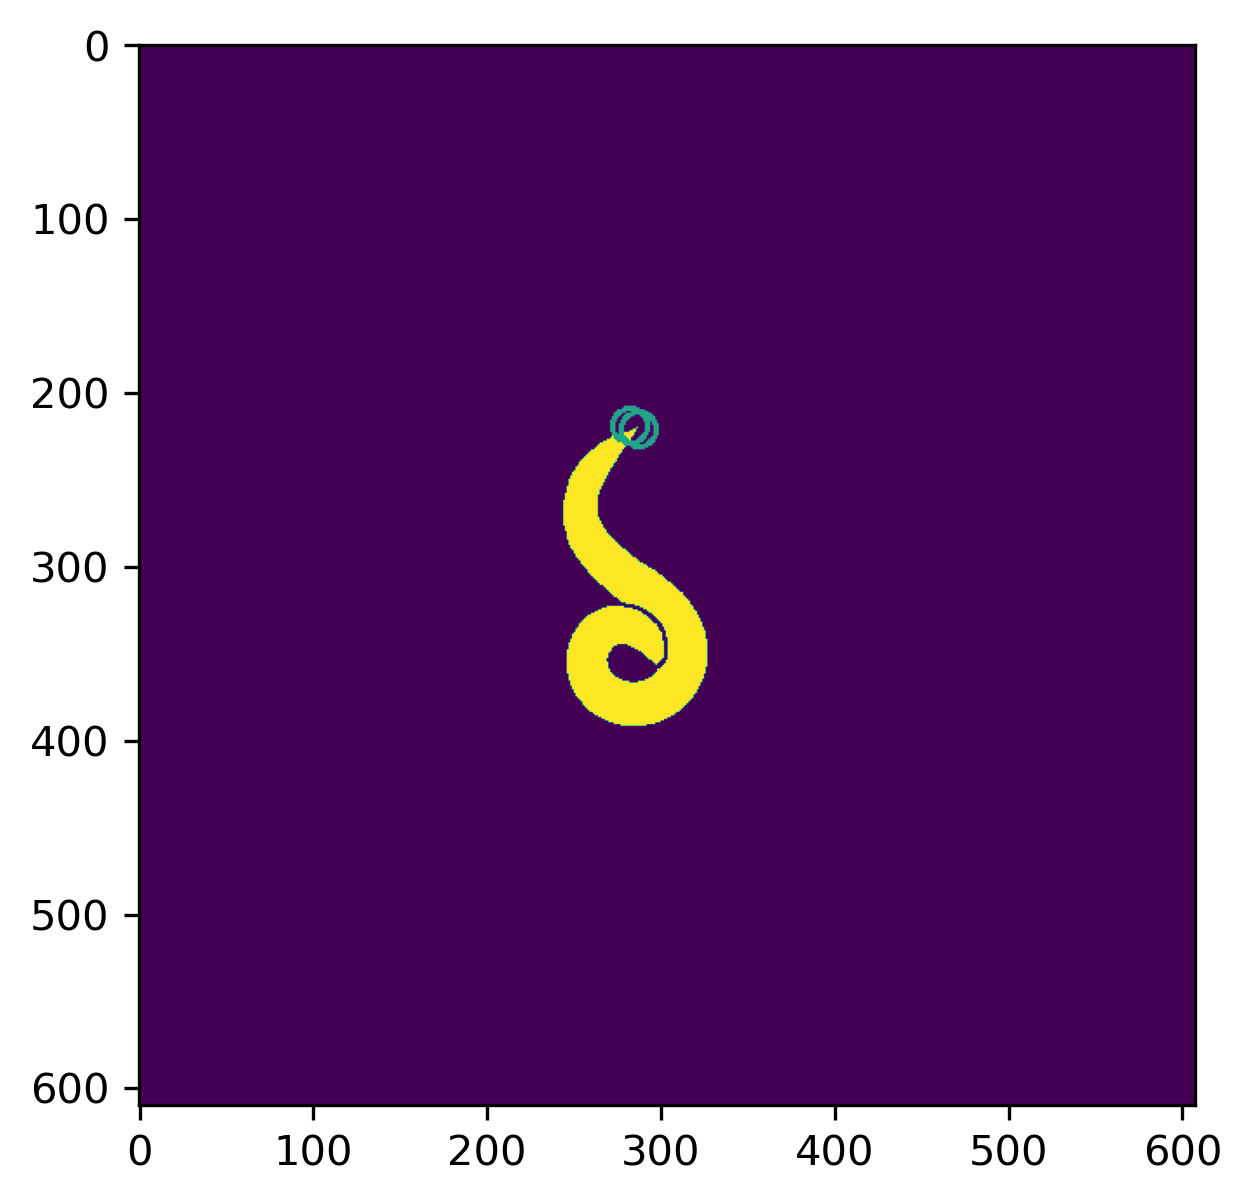

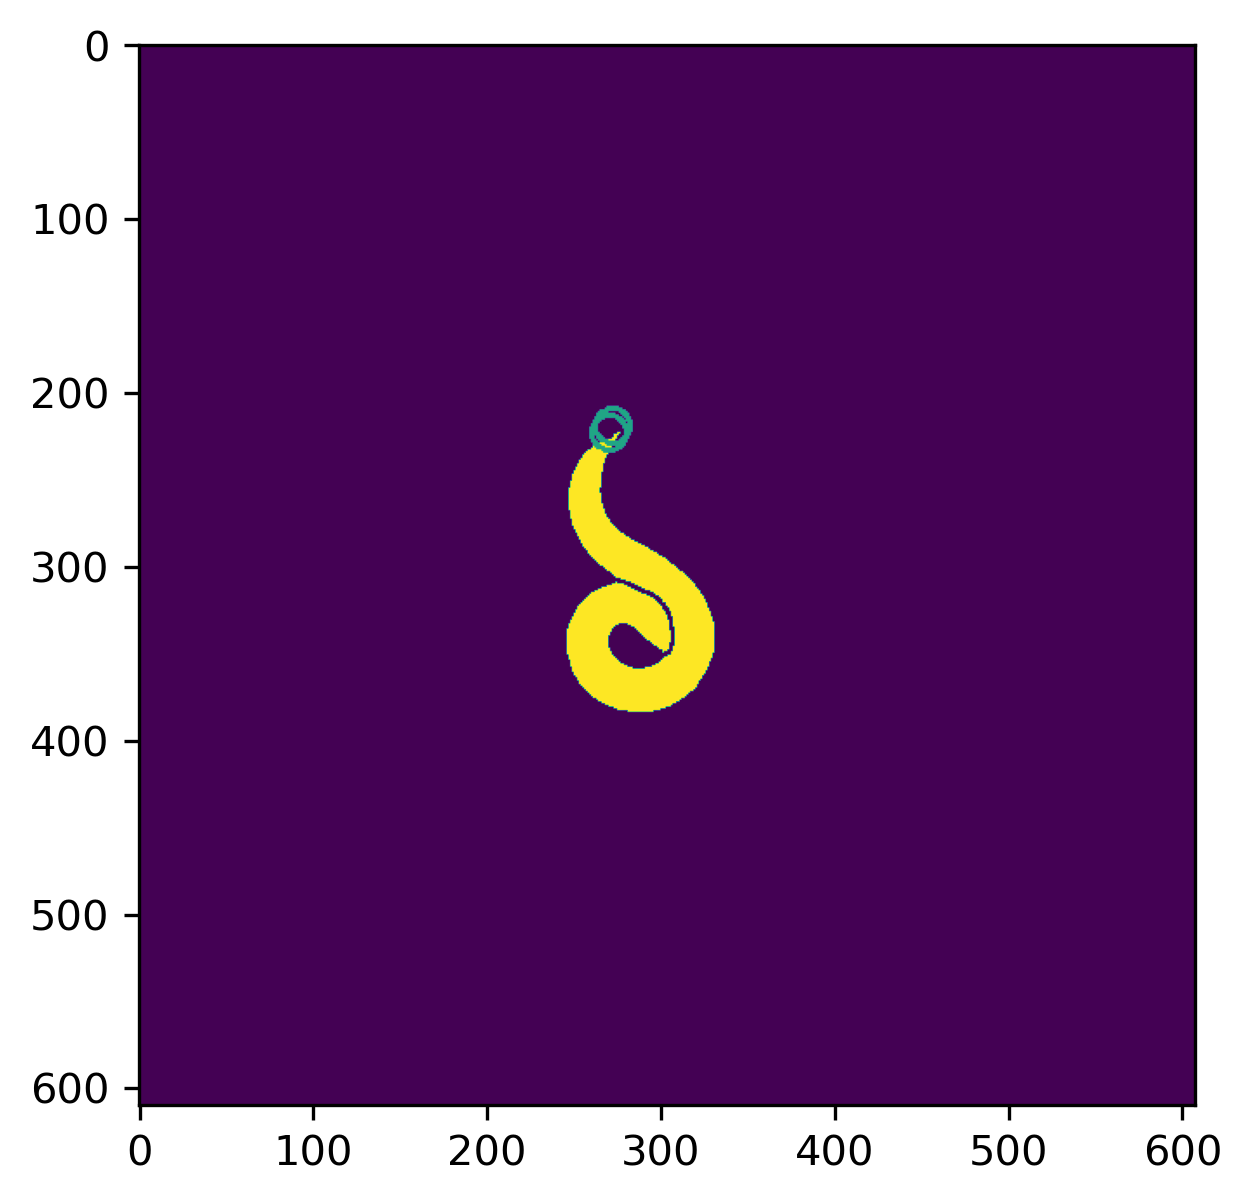

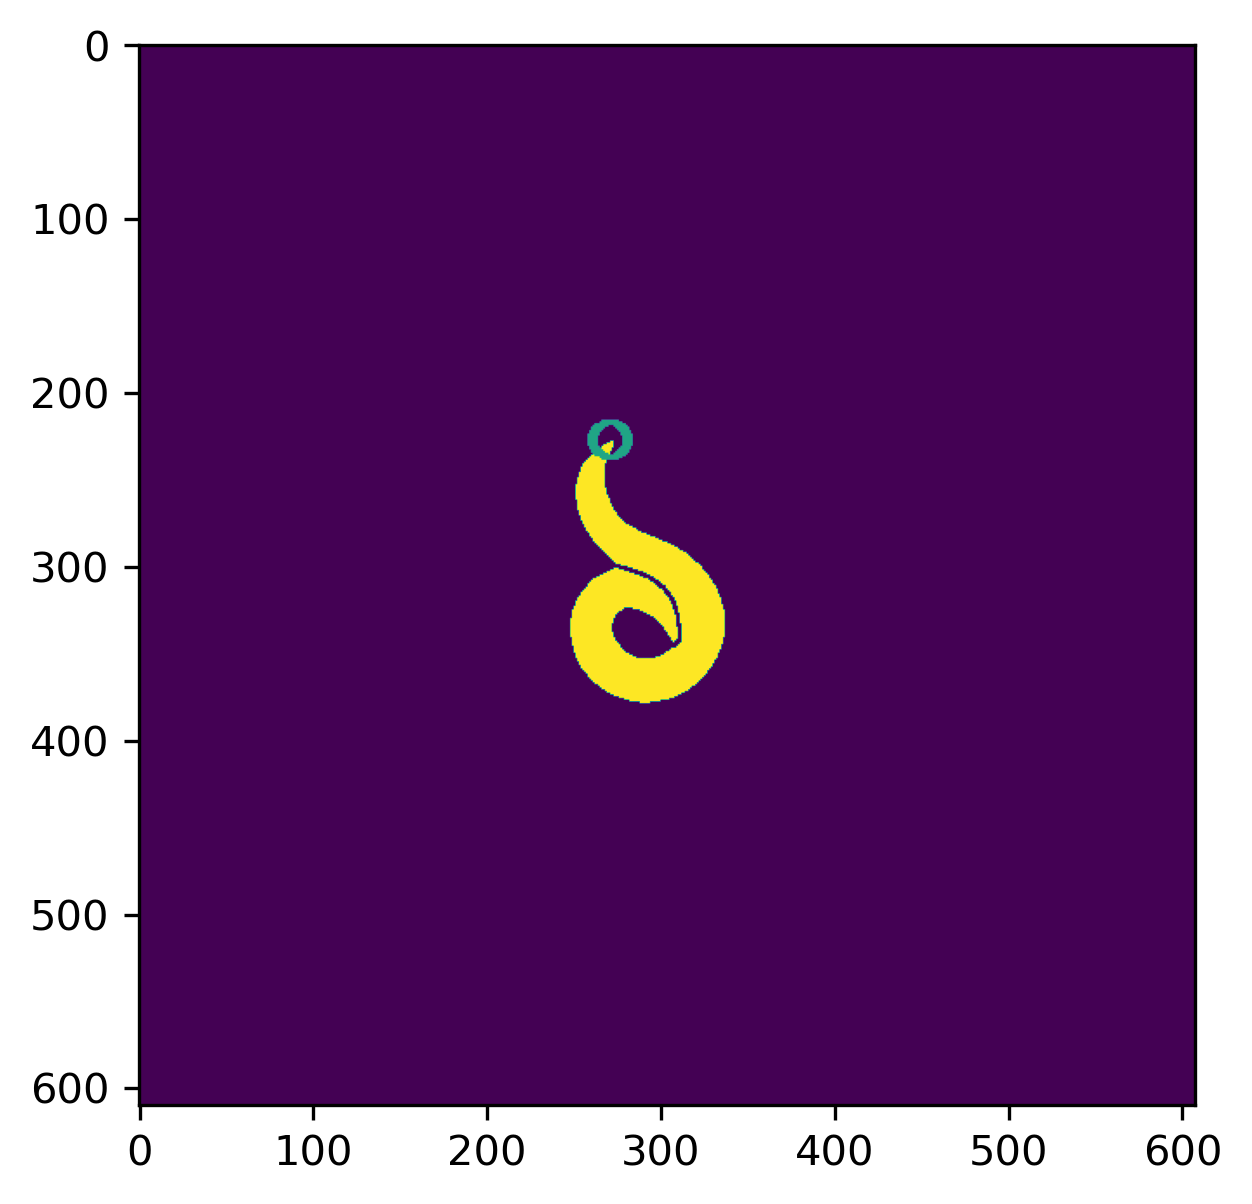

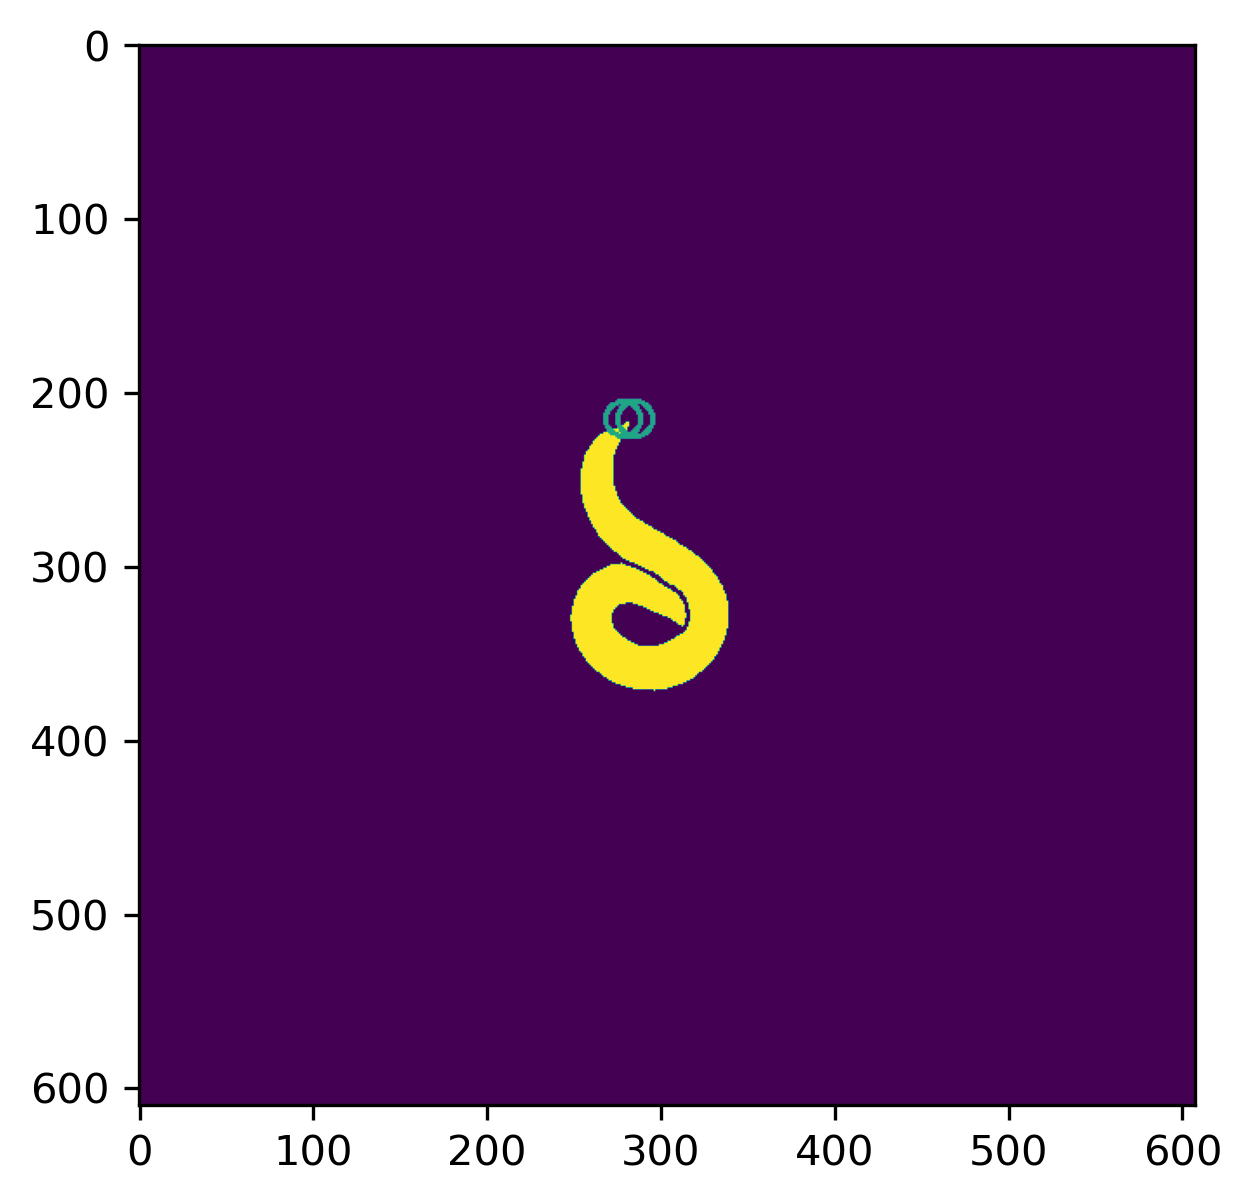

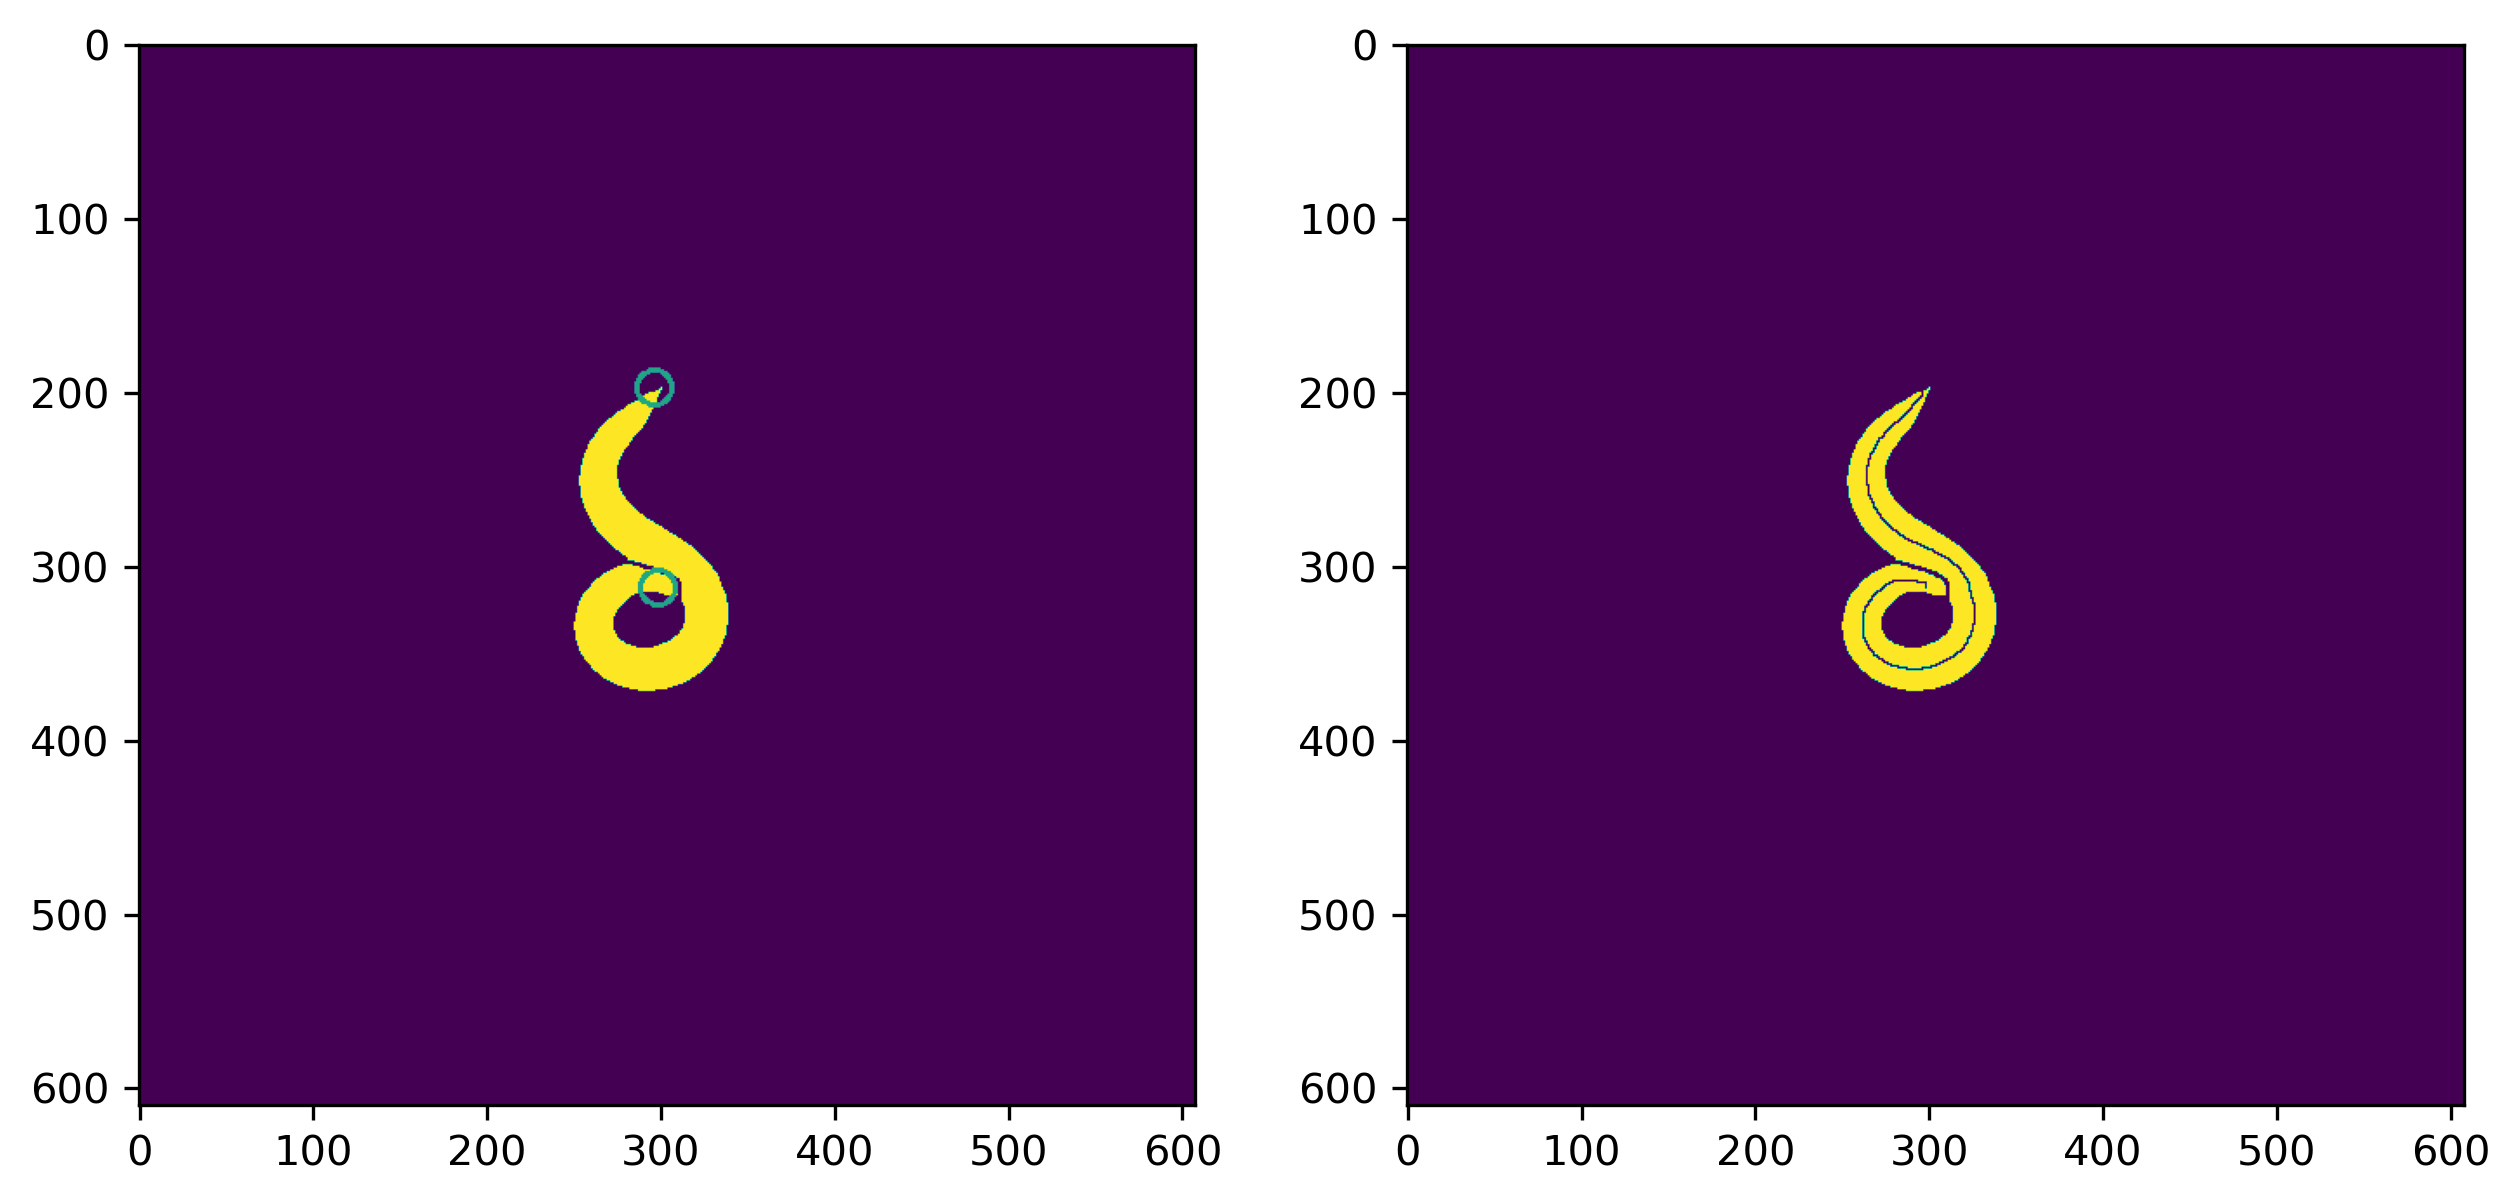

img35277.tif


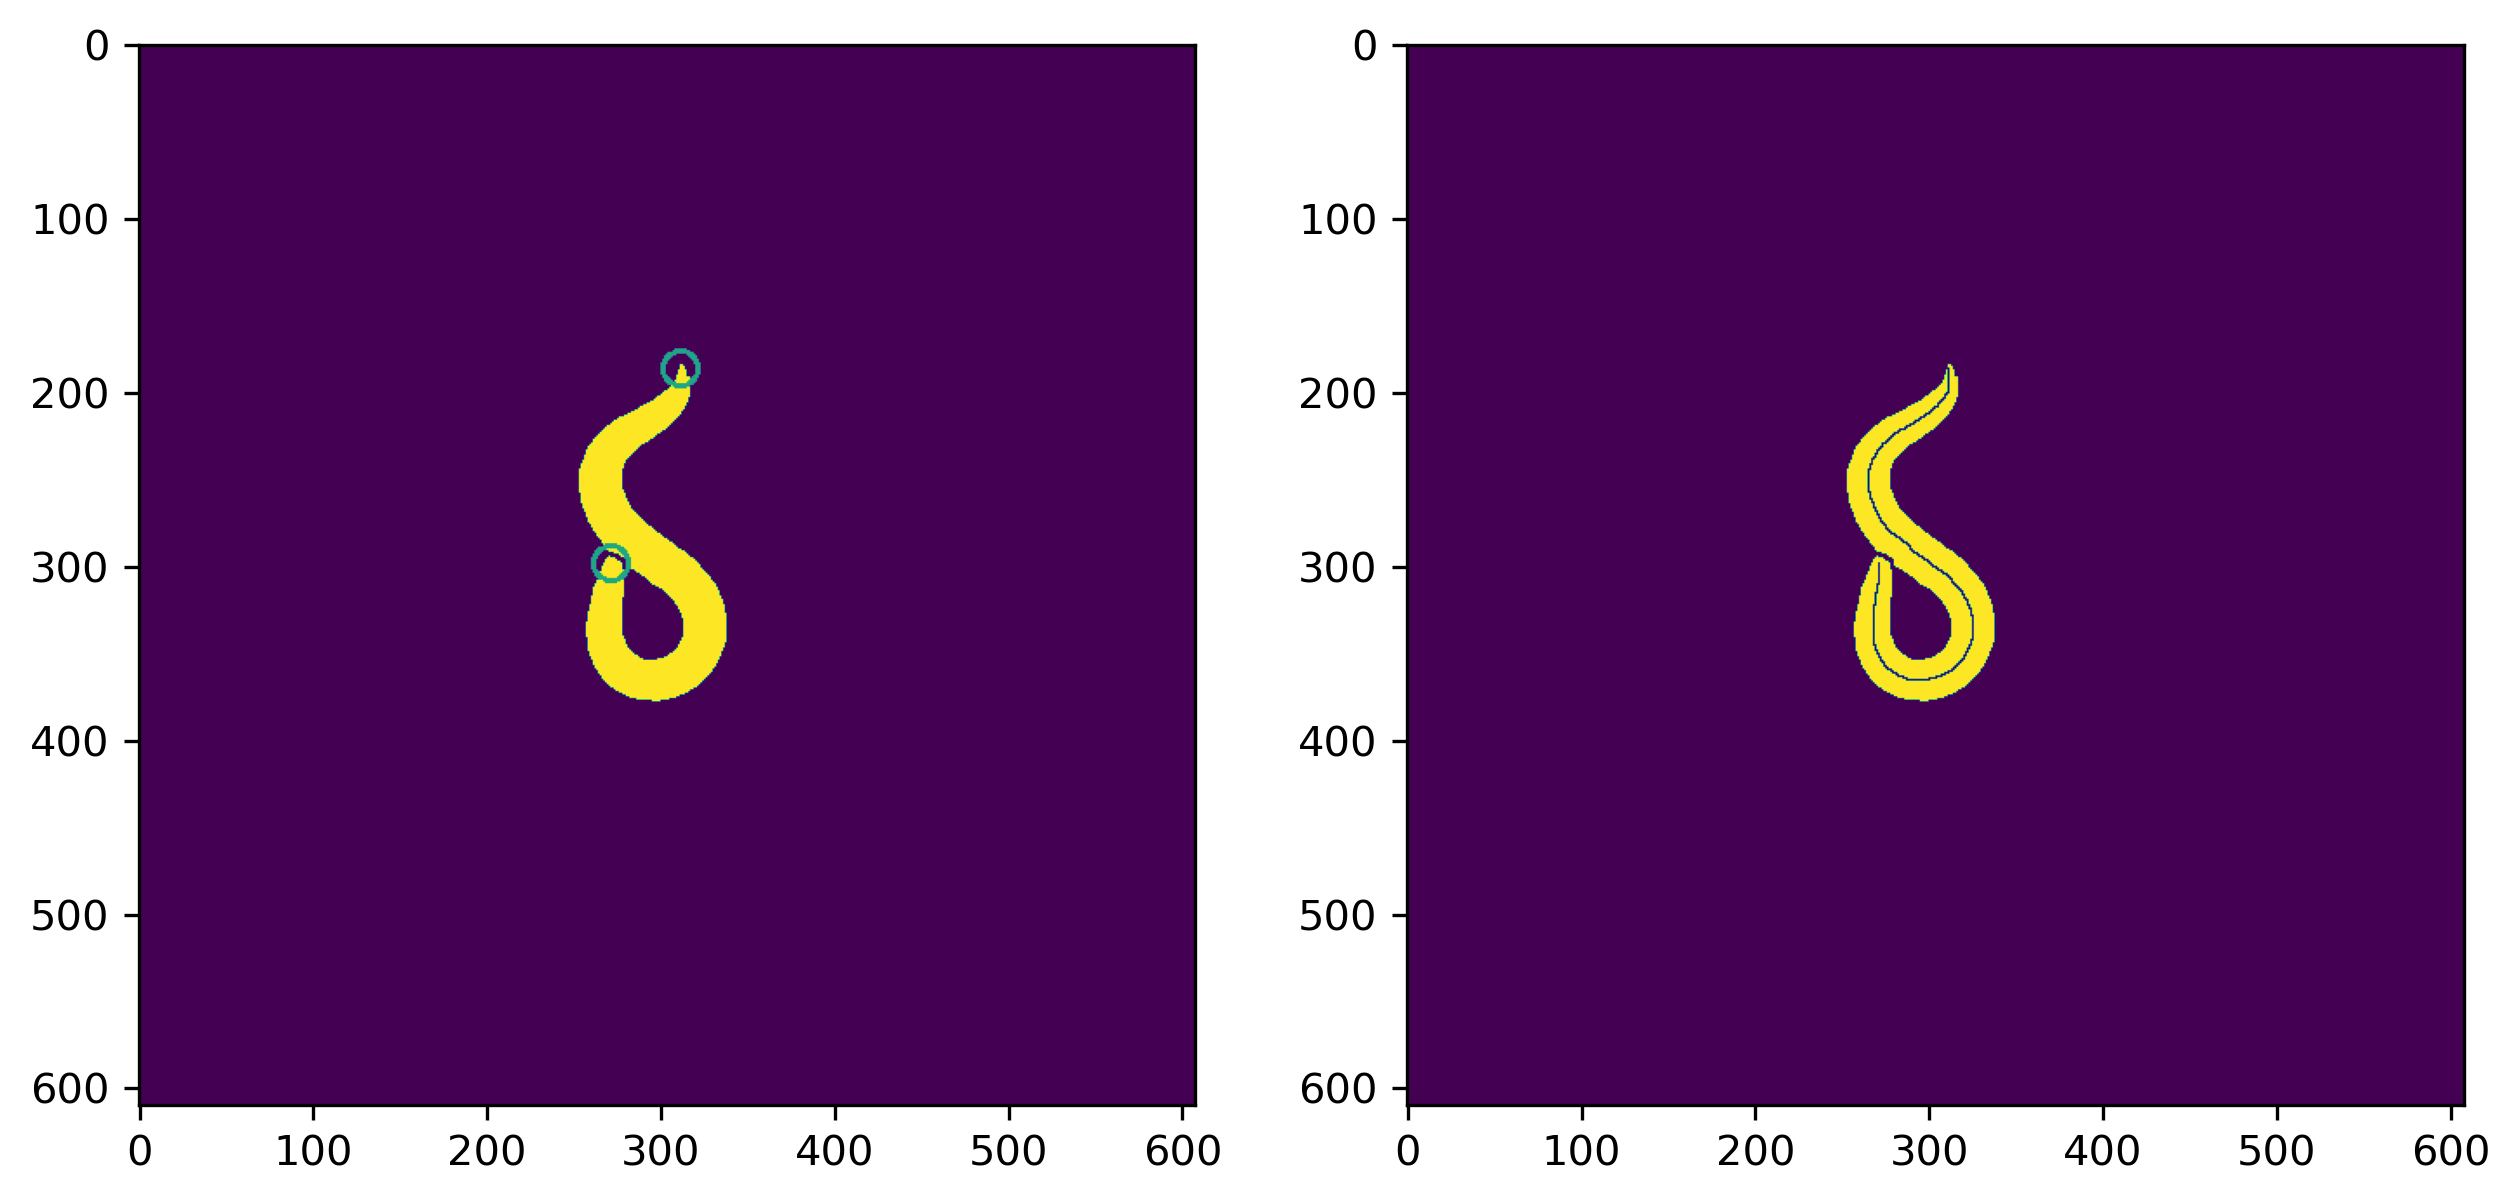

img39802.tif
head and tail were too close, no centerline could be created
img39862.tif
head and tail were too close, no centerline could be created
img39922.tif
head and tail were too close, no centerline could be created
img48080.tif


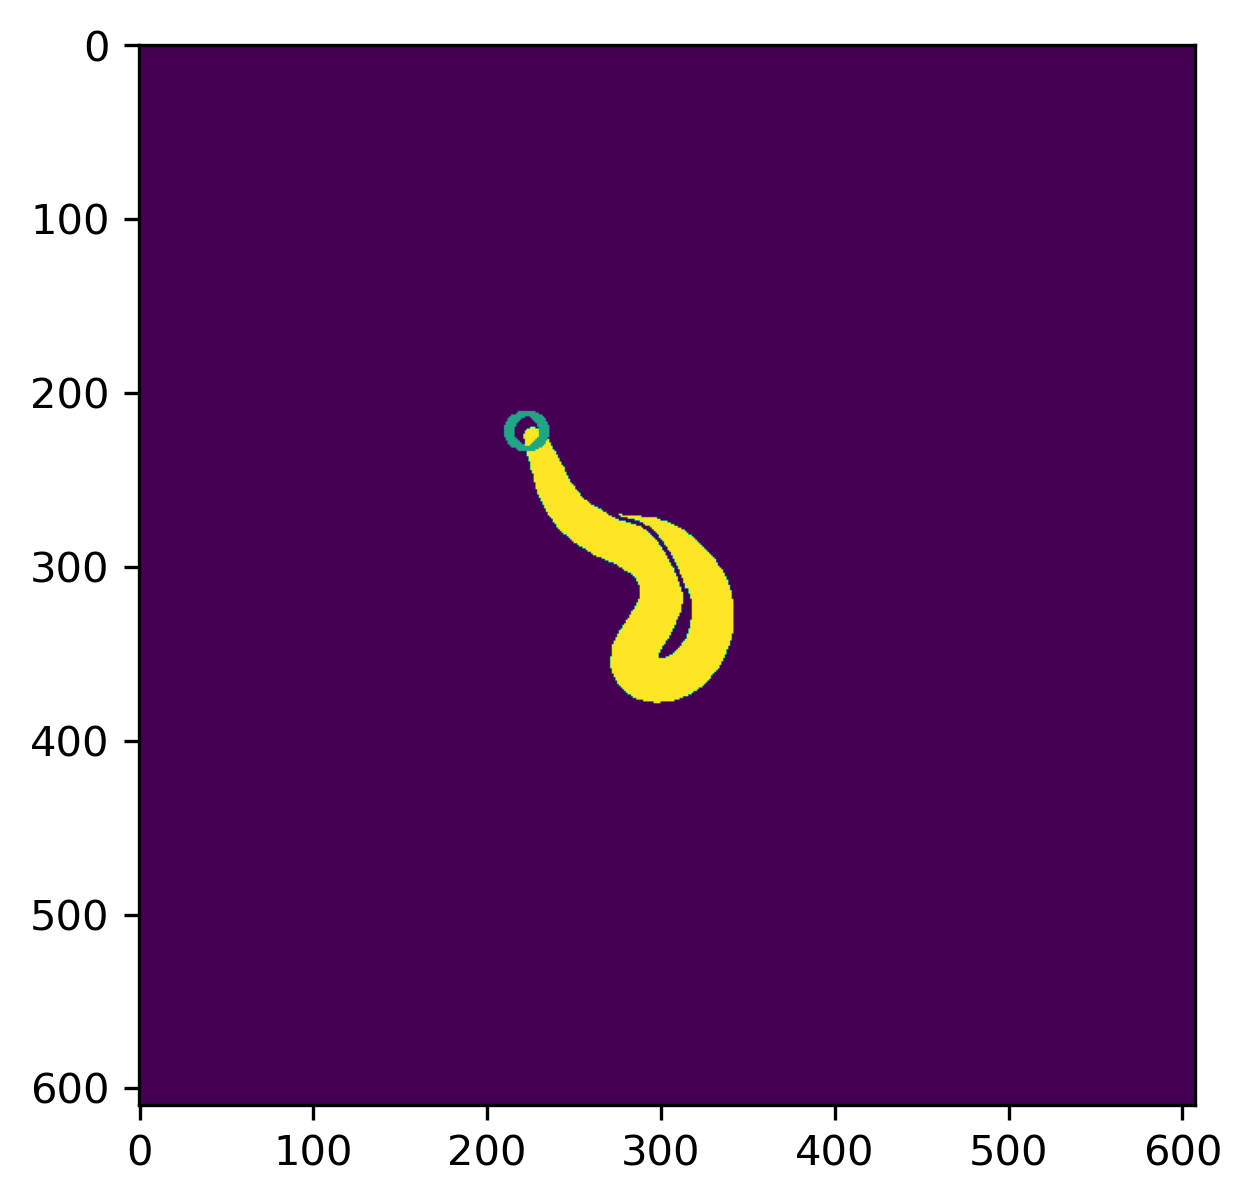

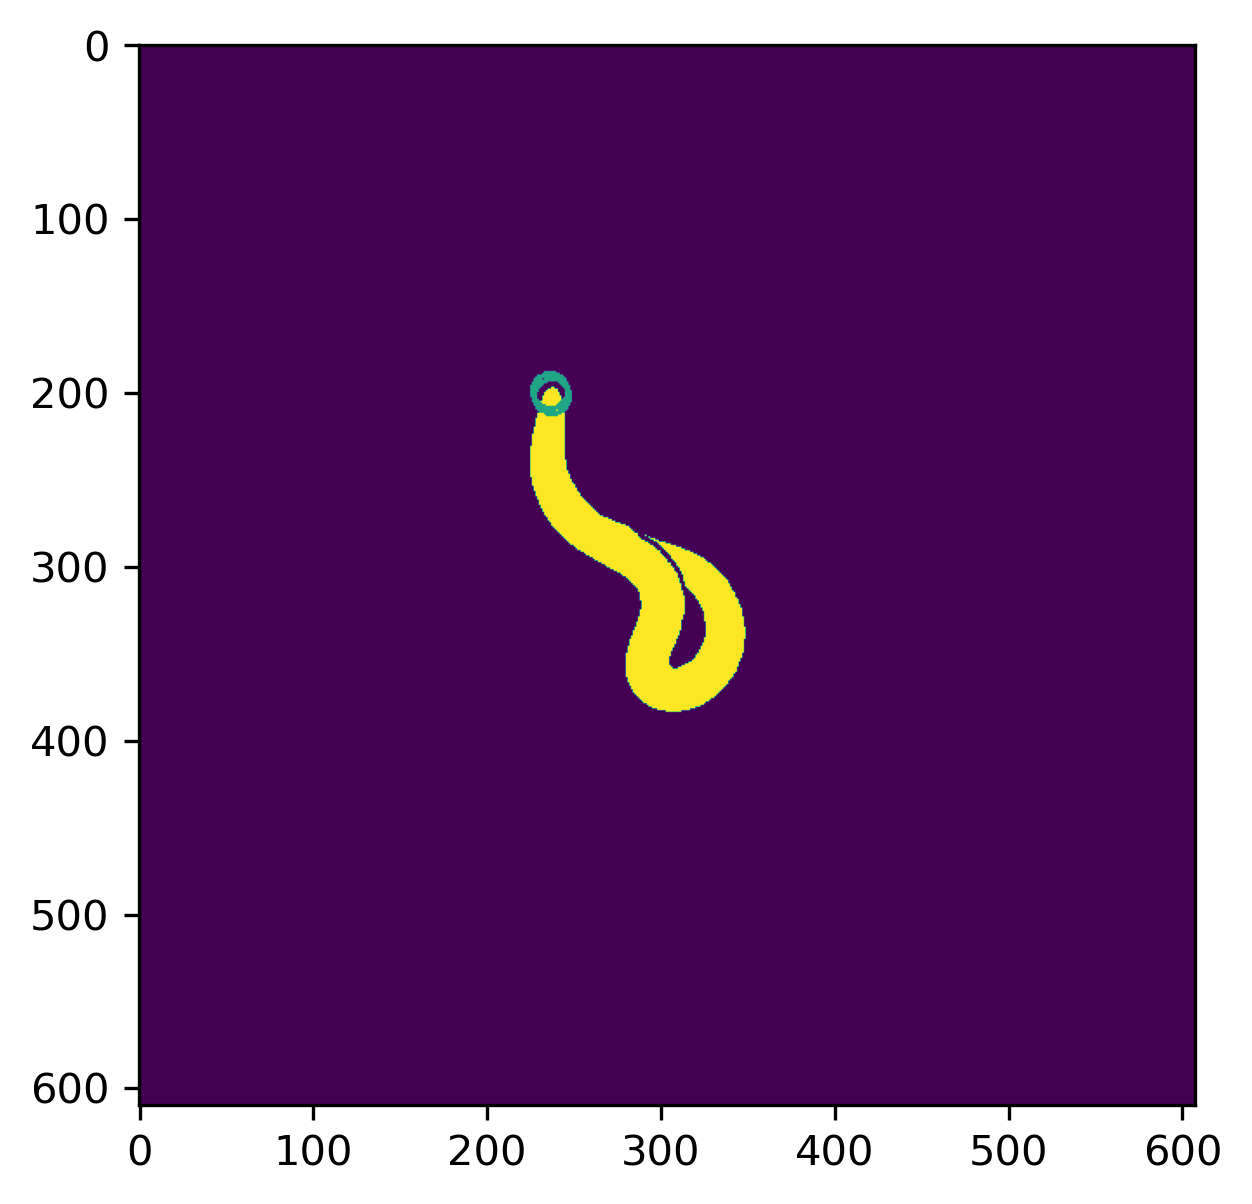

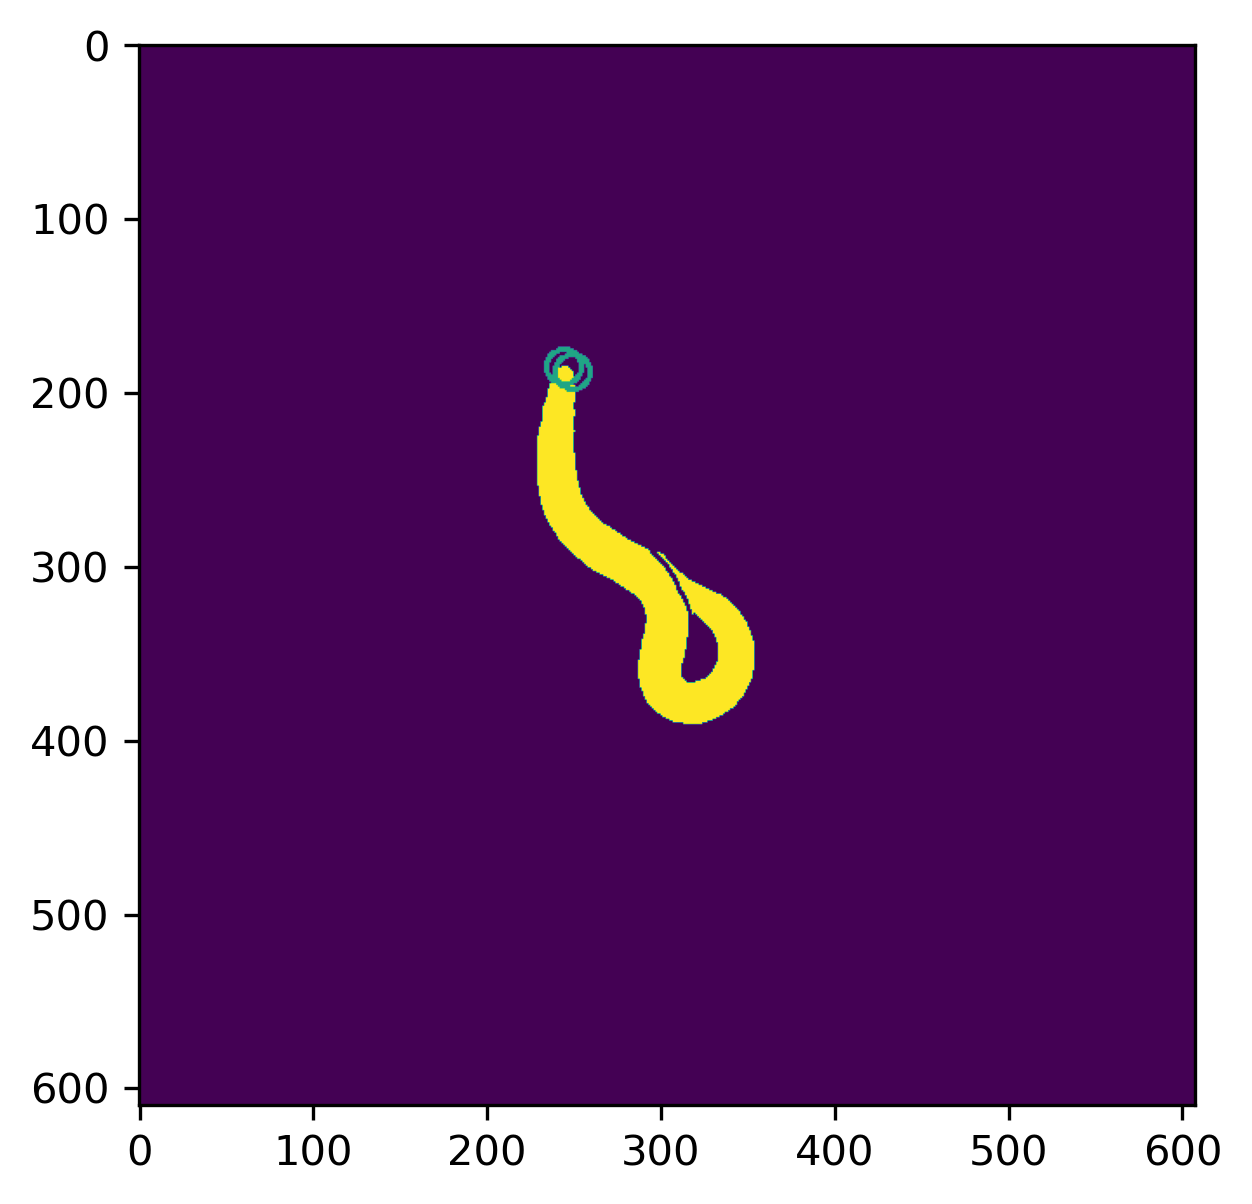

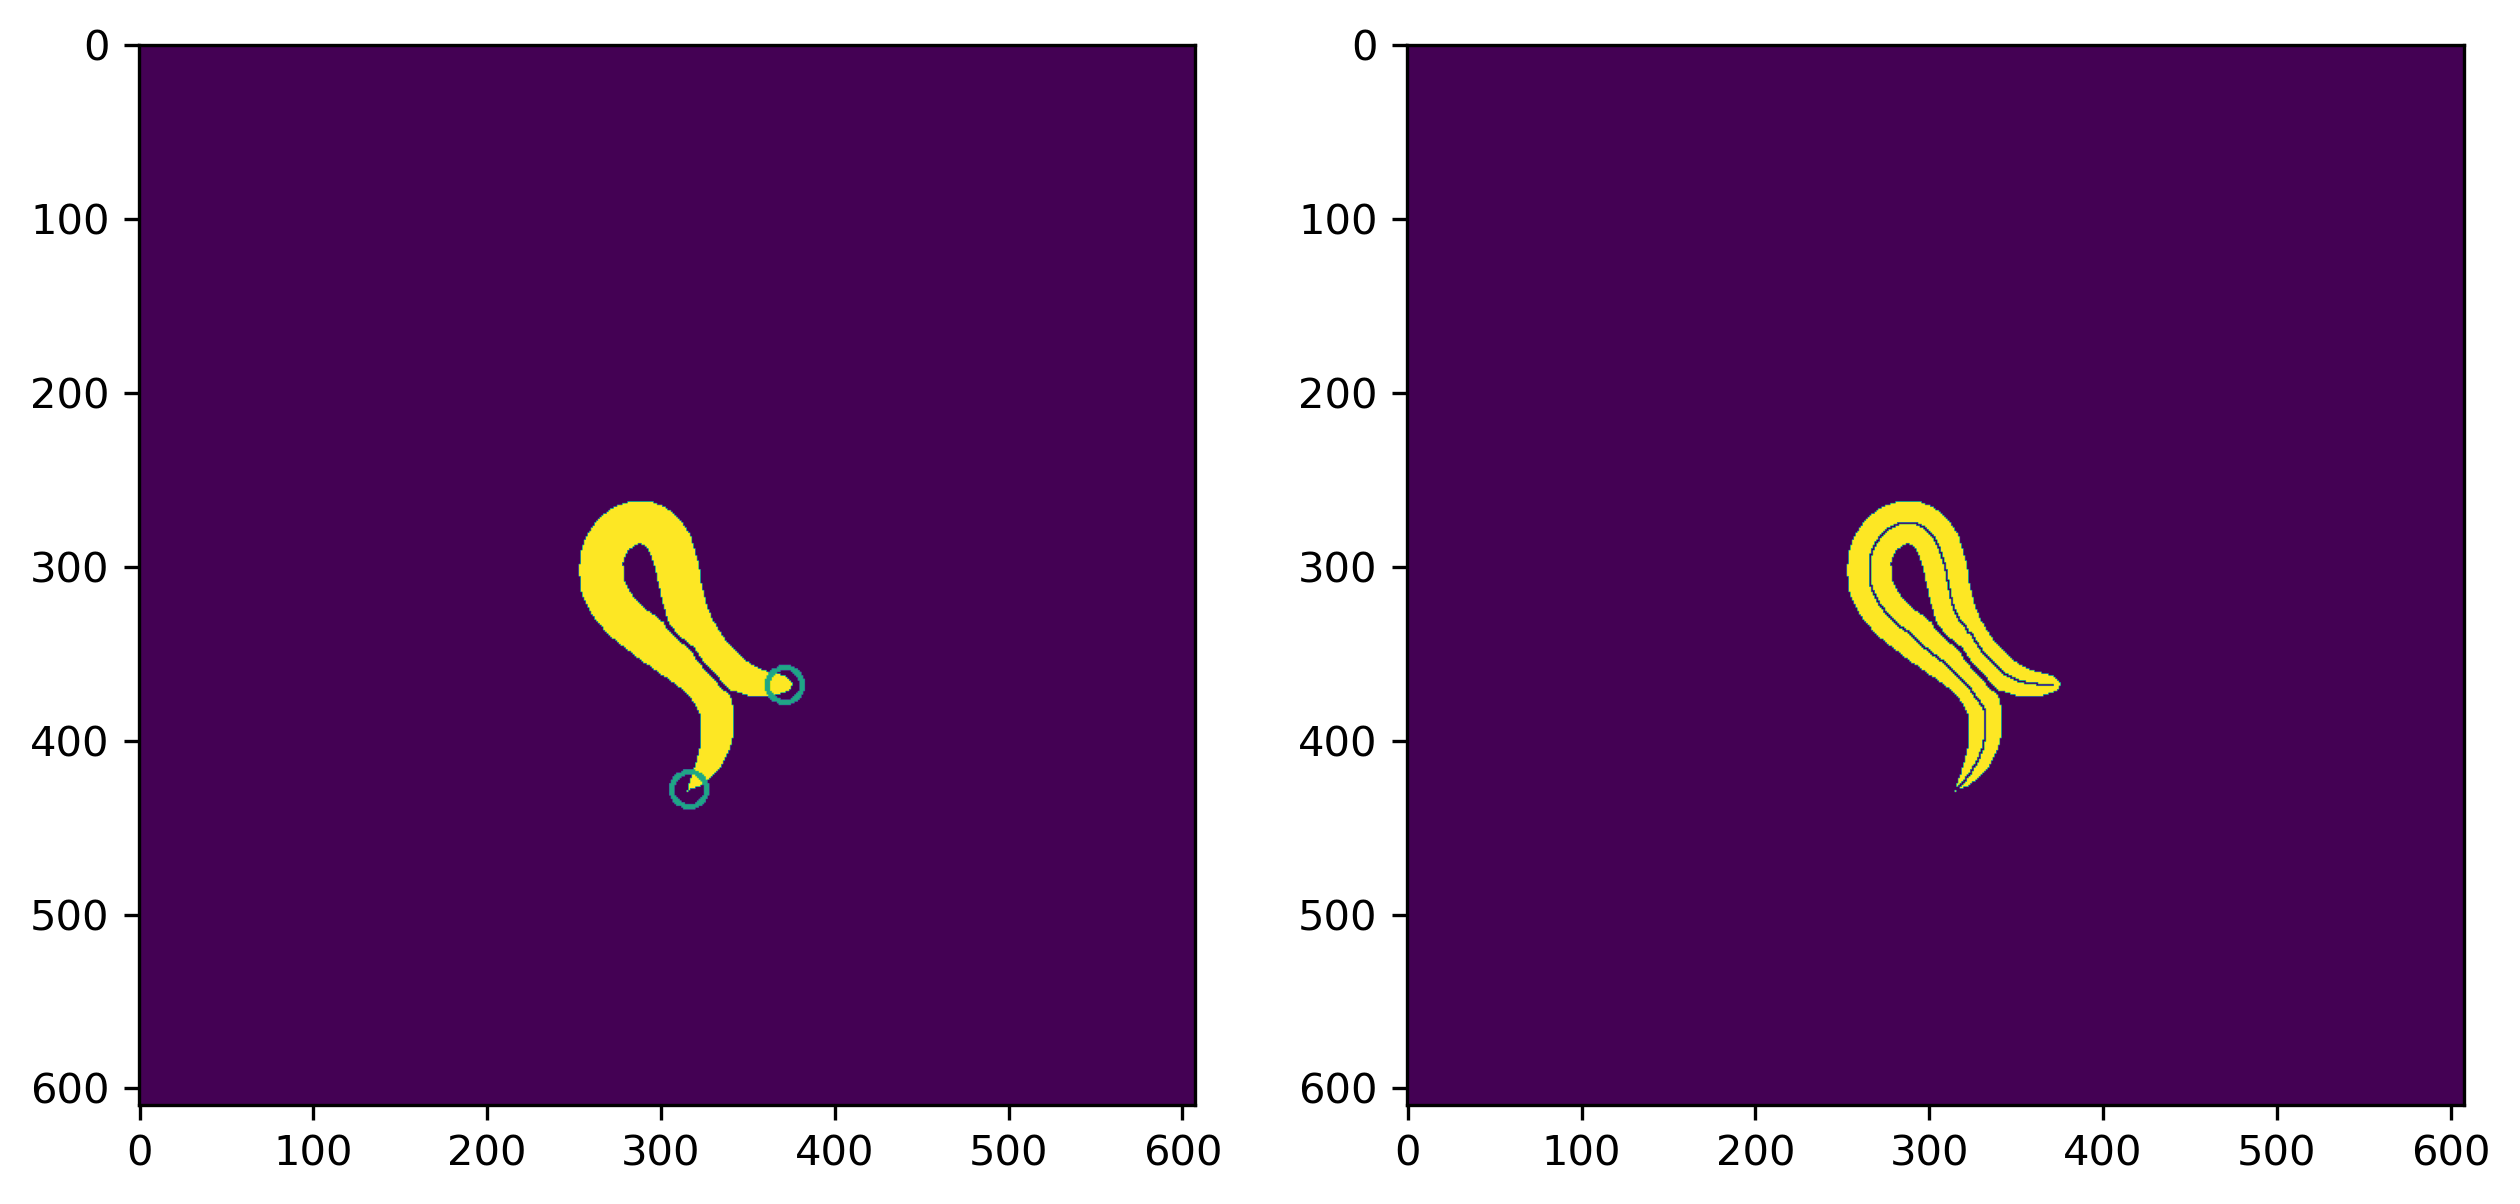

img48140.tif


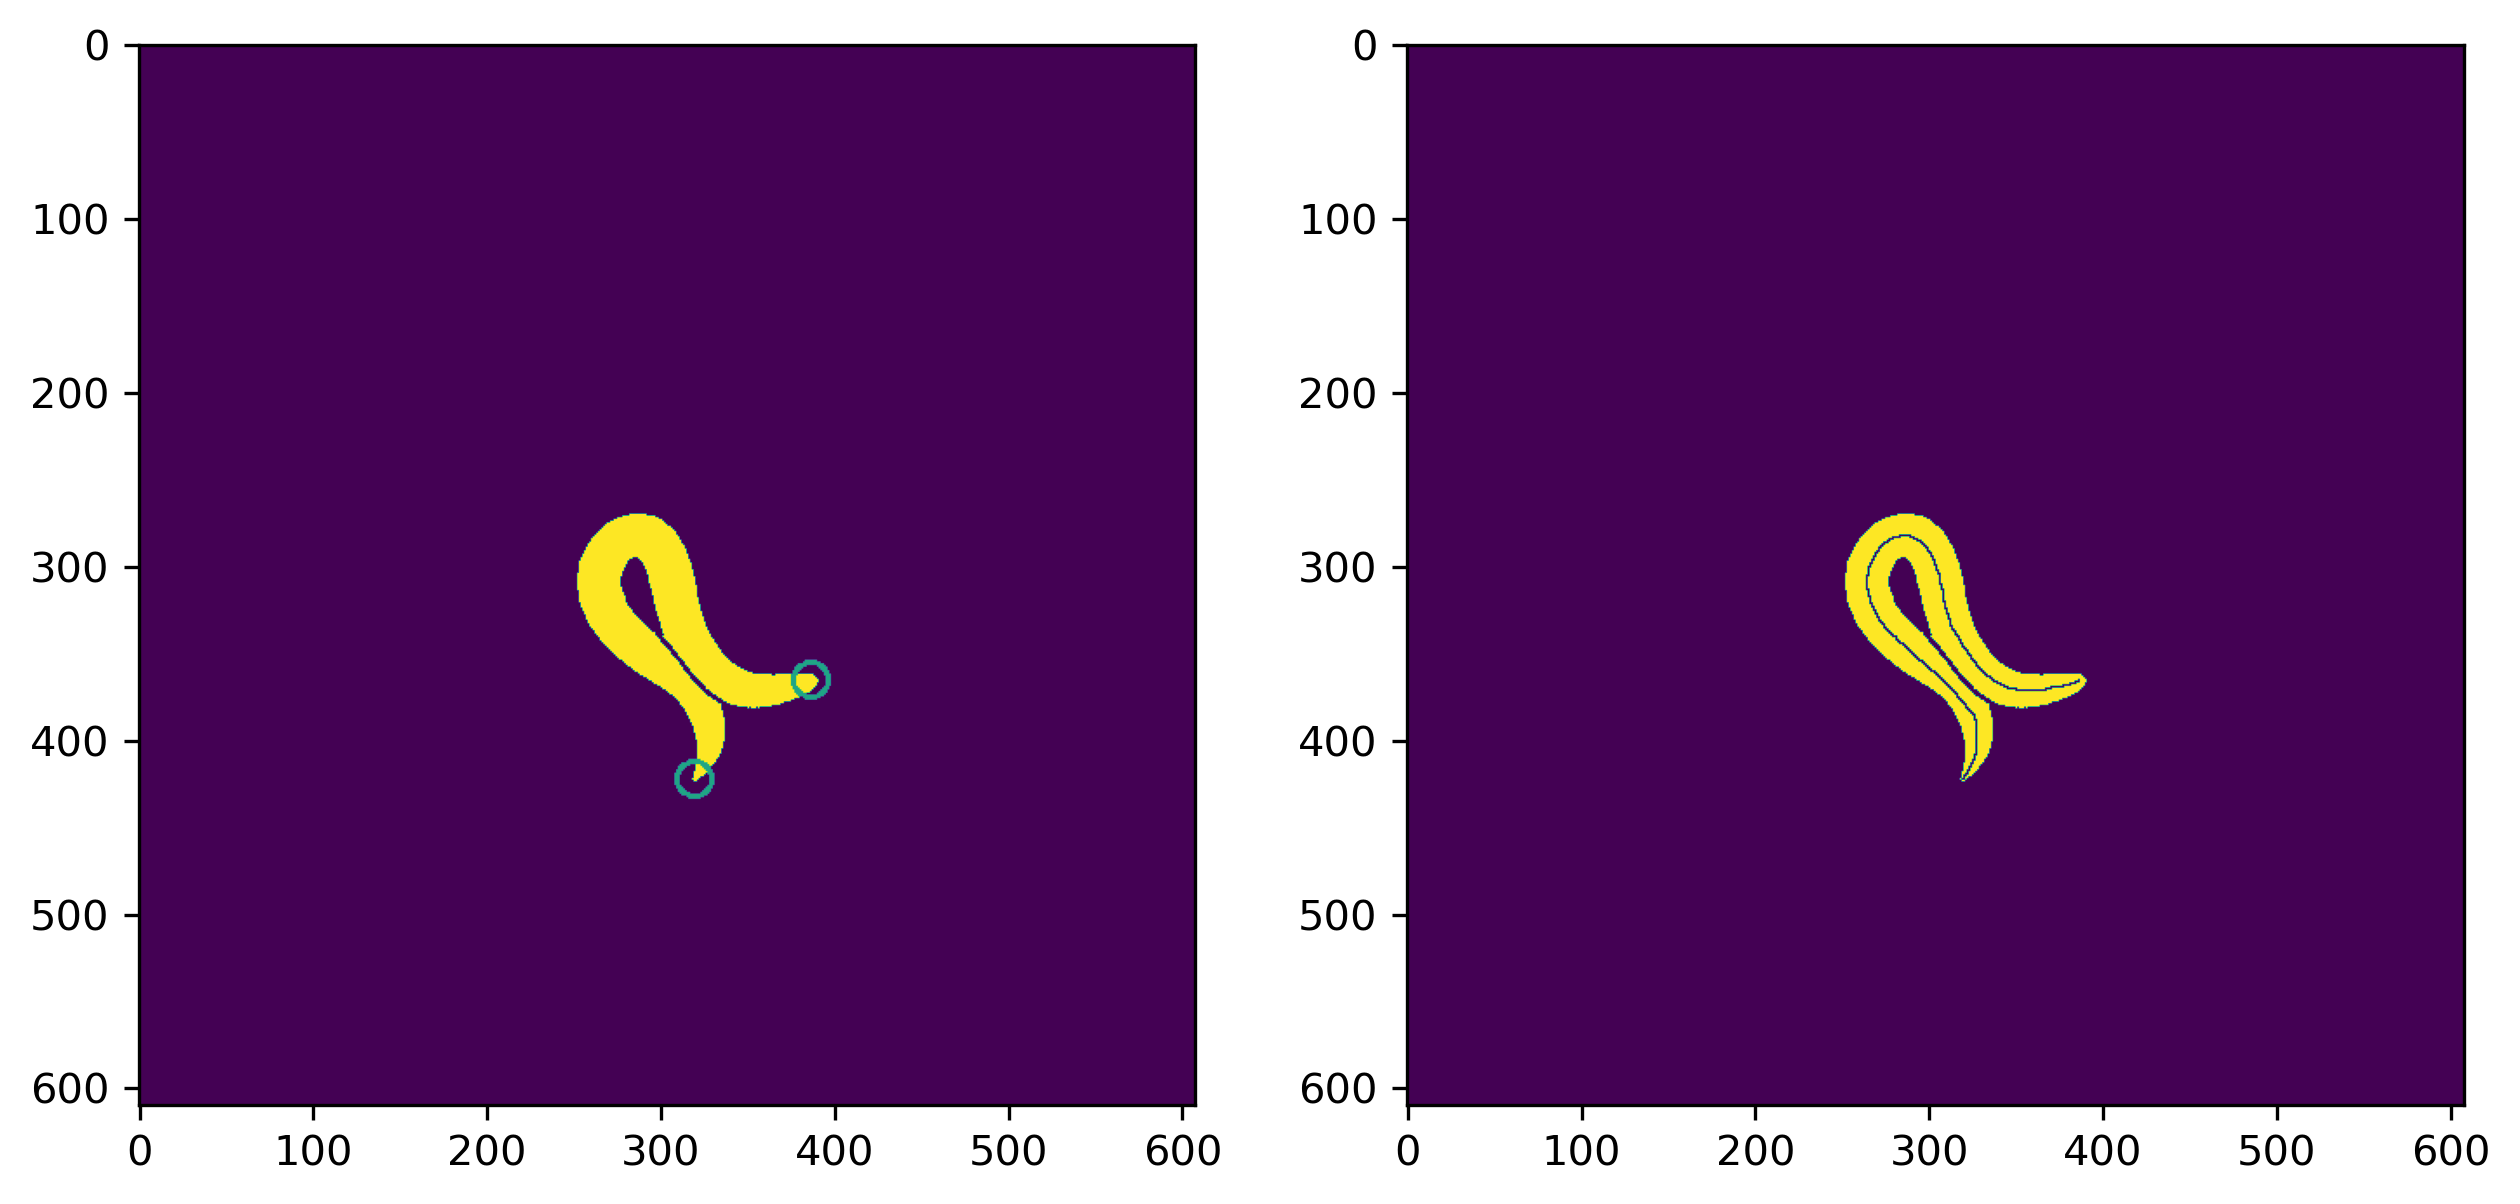

img48200.tif


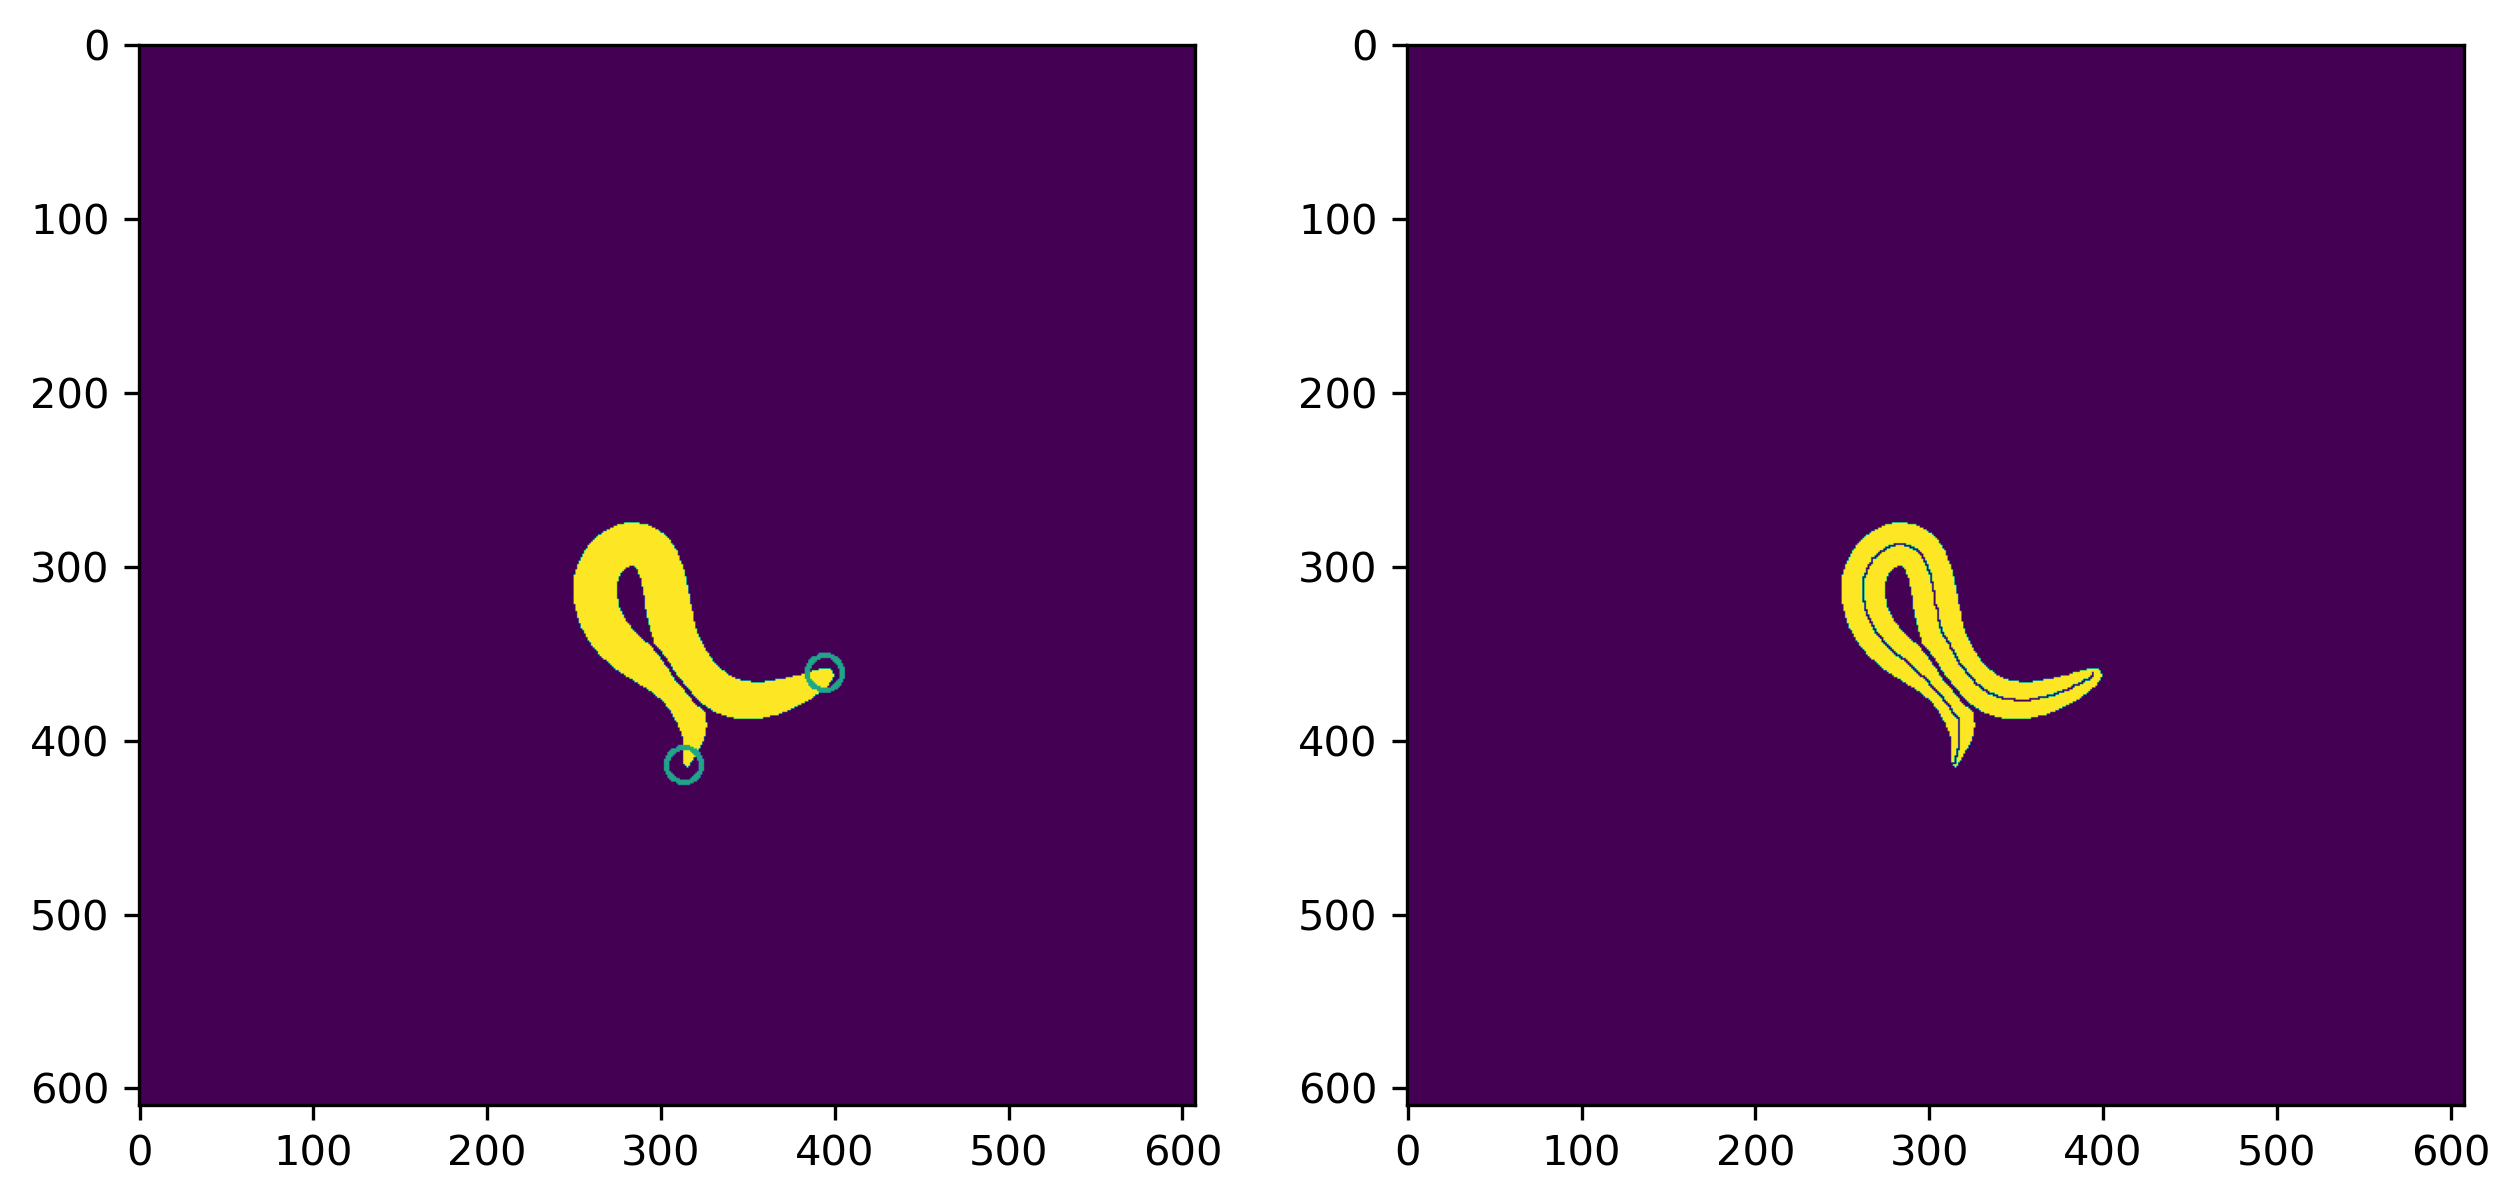

img48260.tif


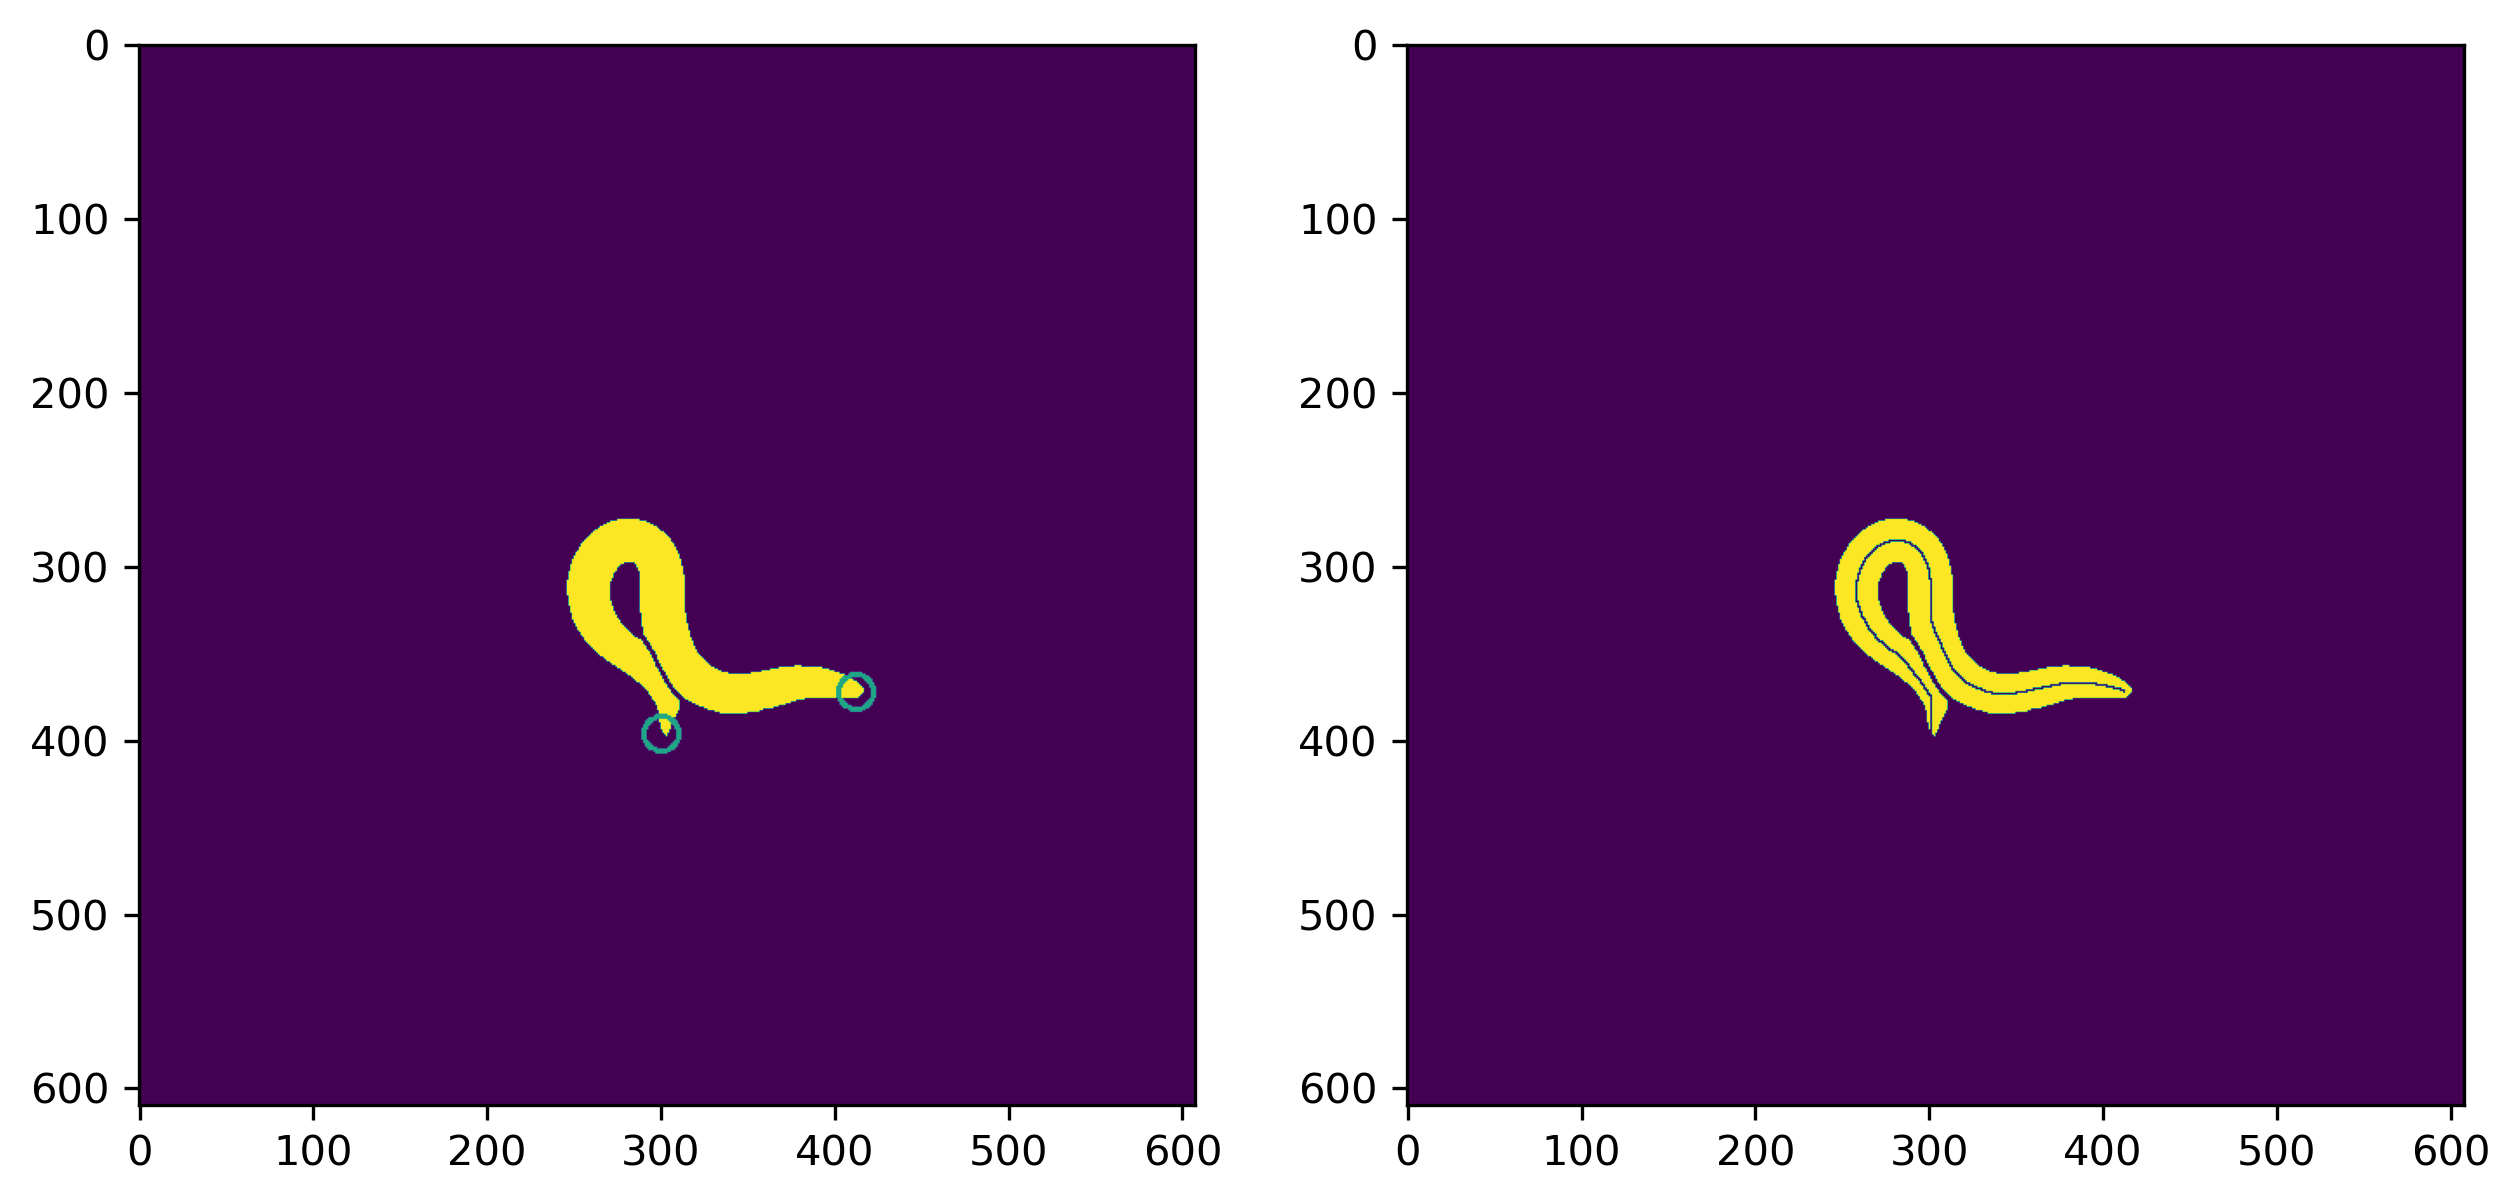

img48320.tif


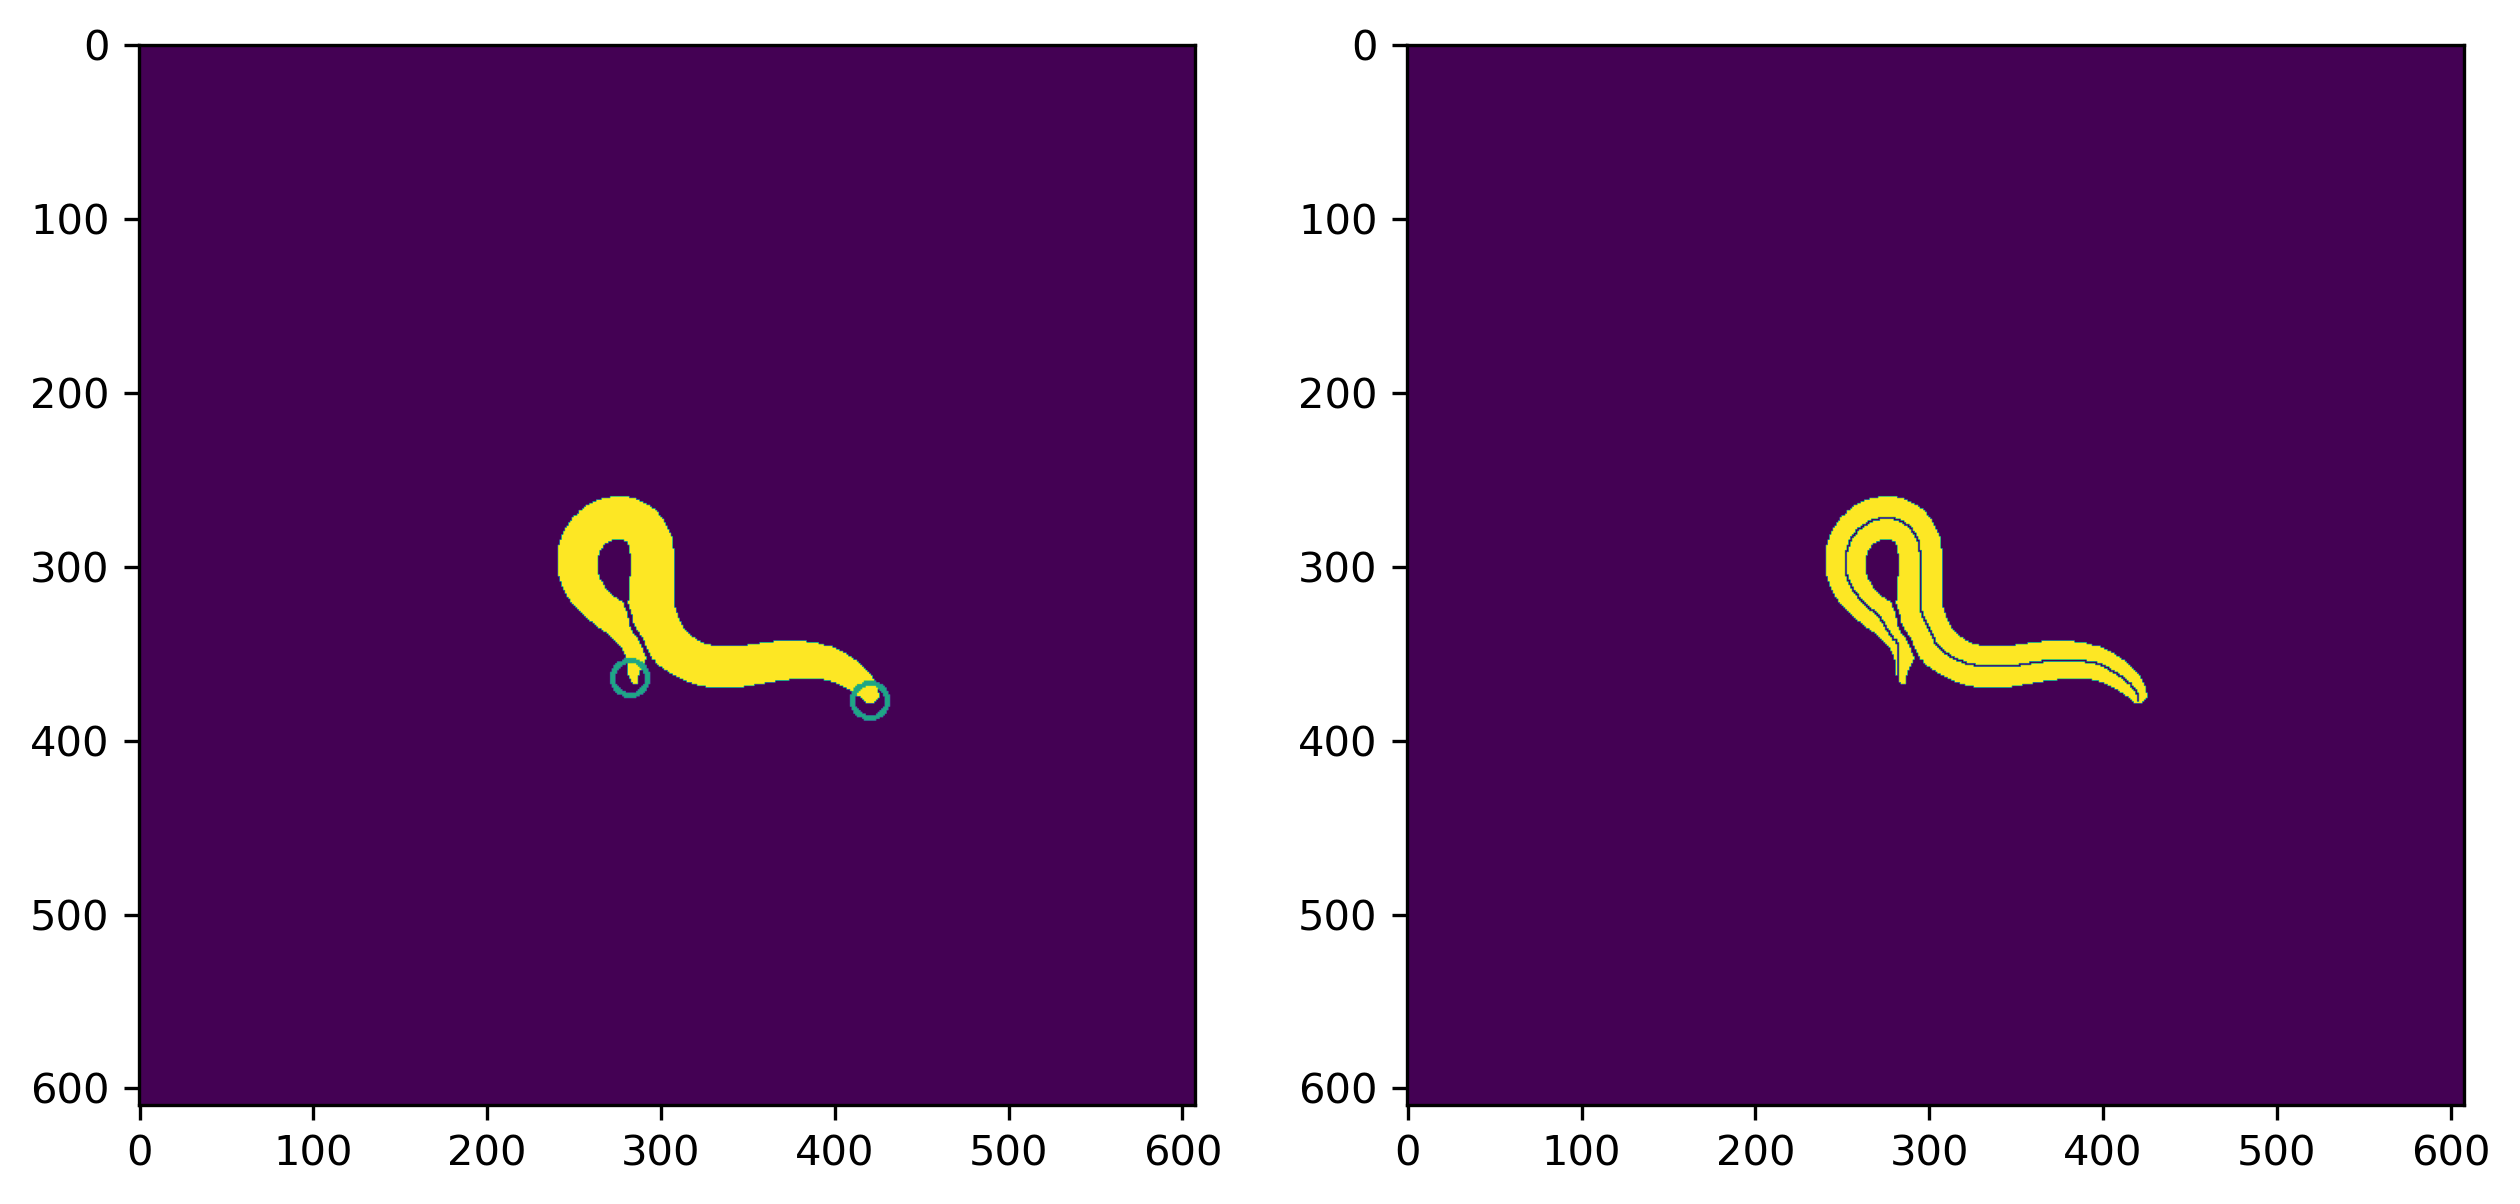

img59647.tif


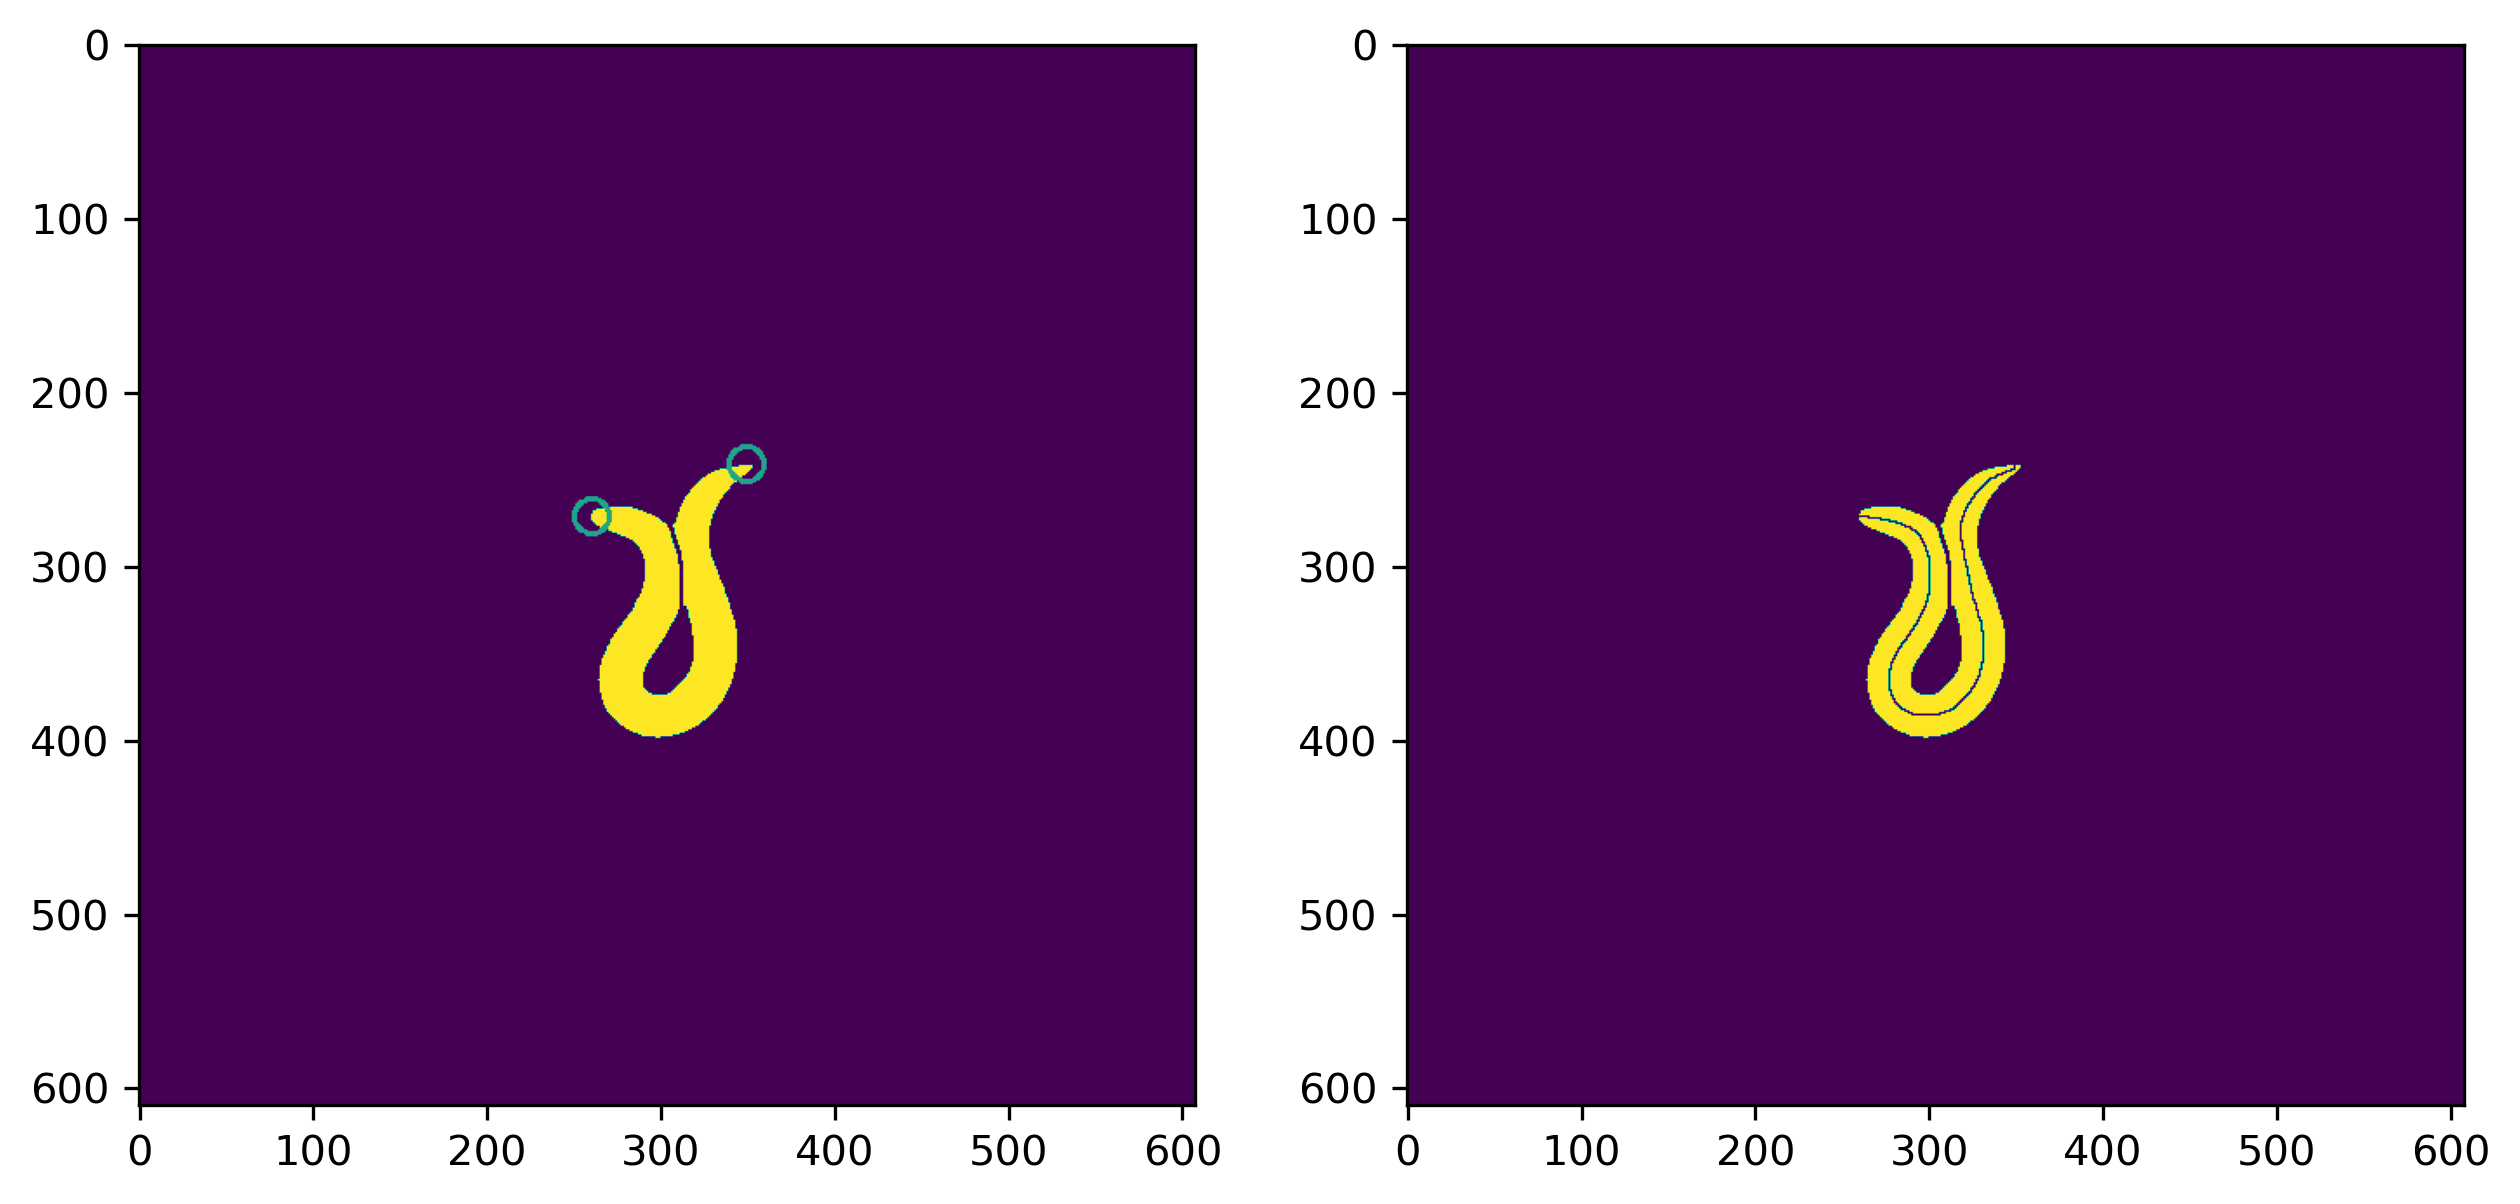

img59707.tif


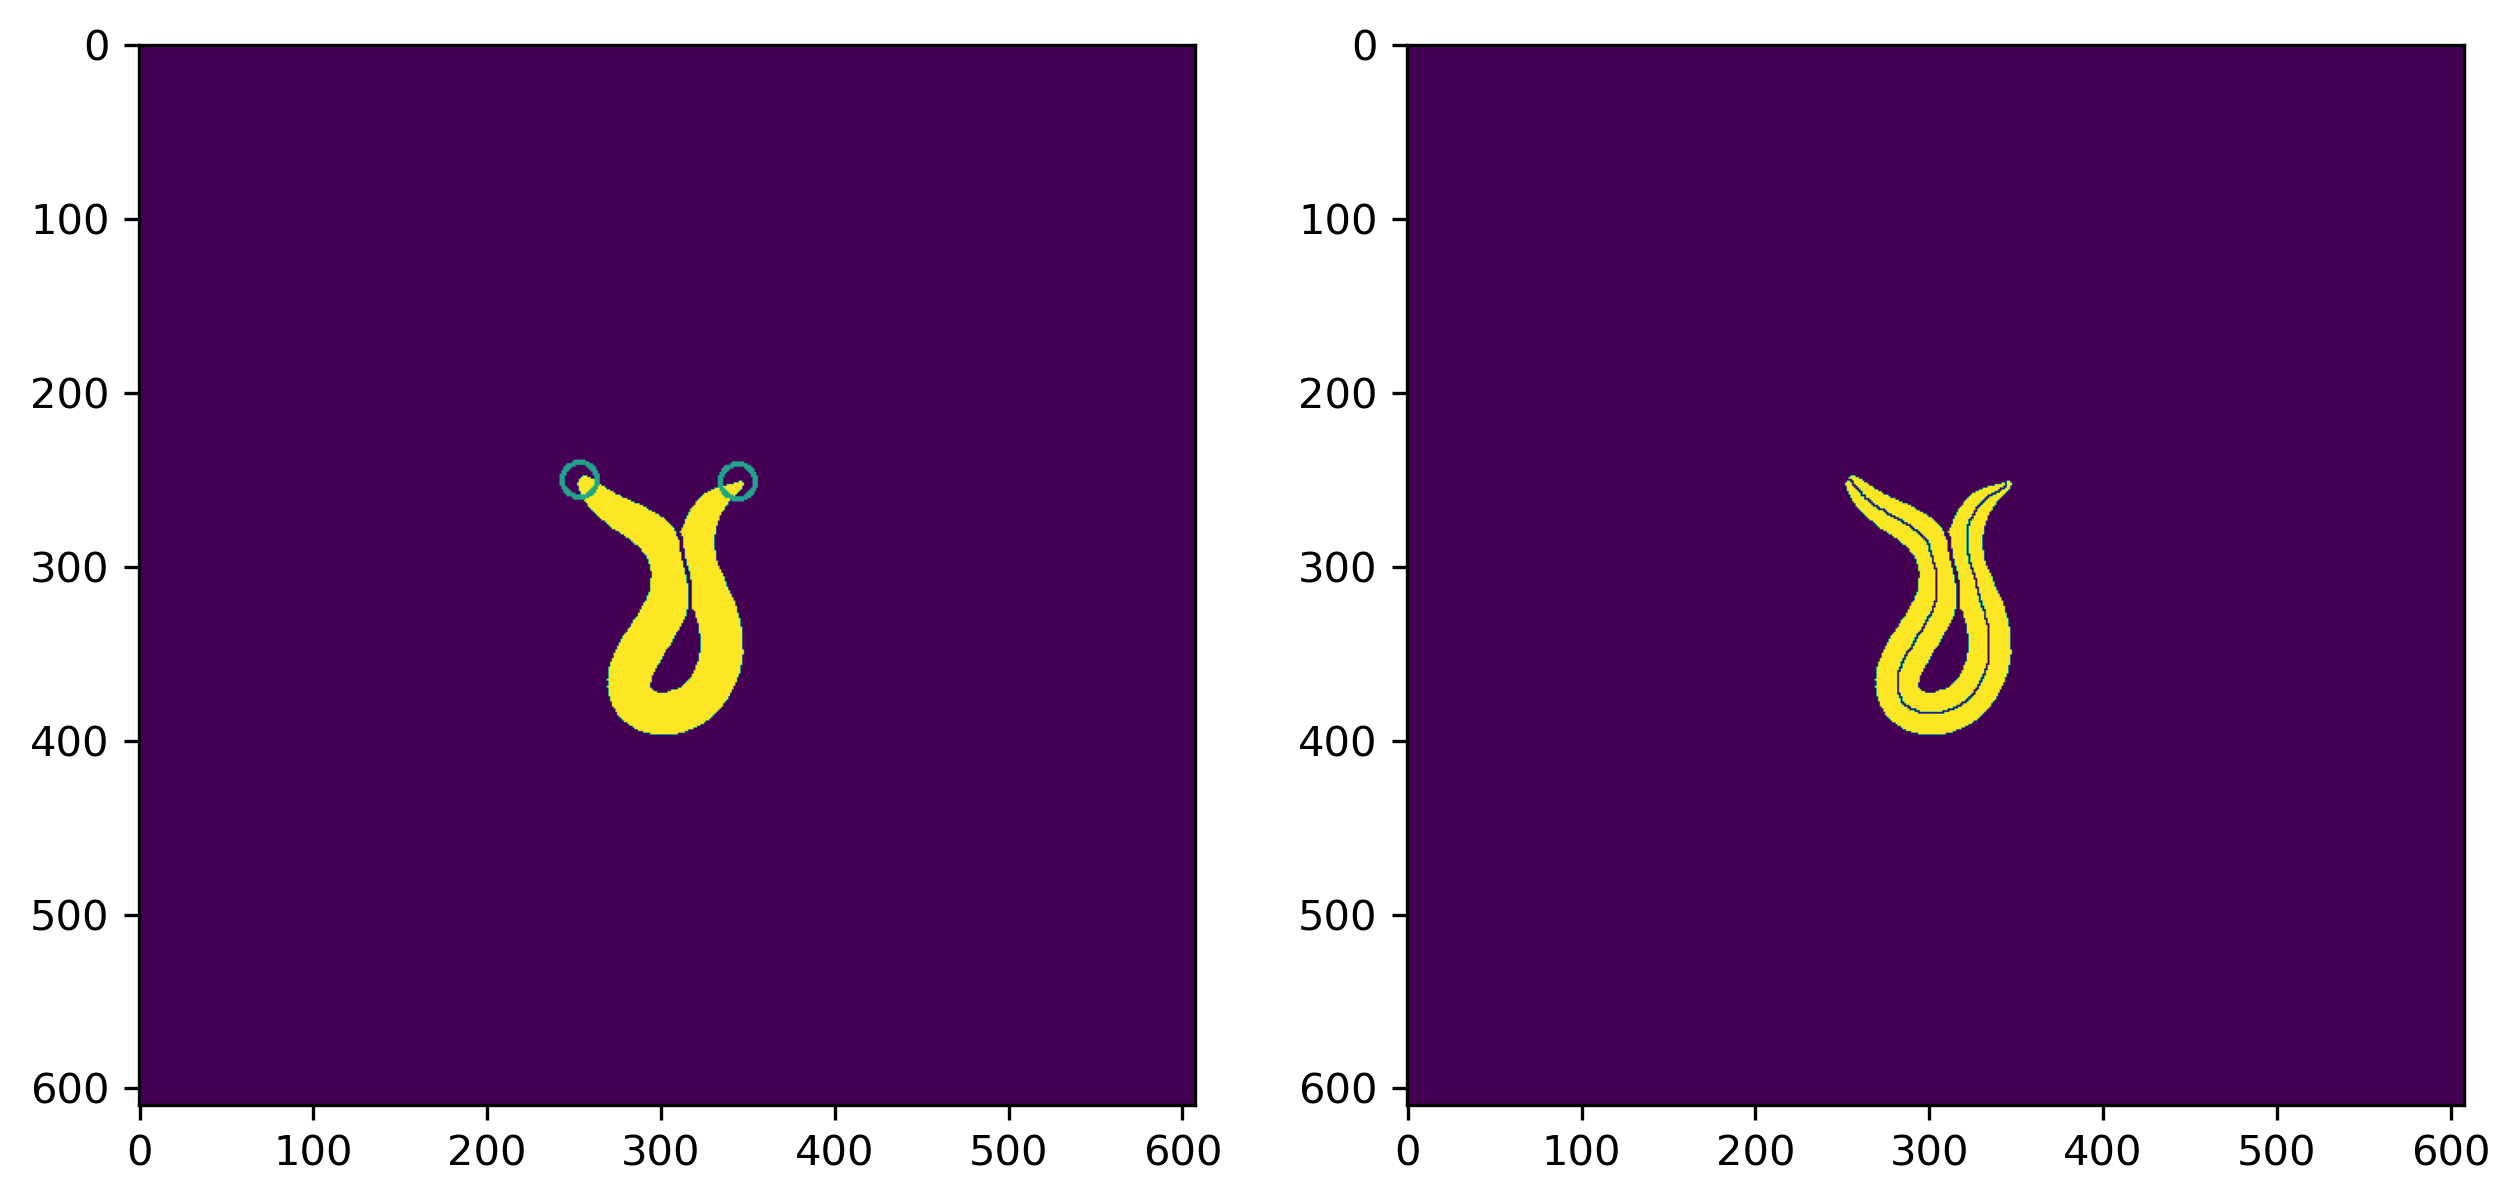

img59767.tif


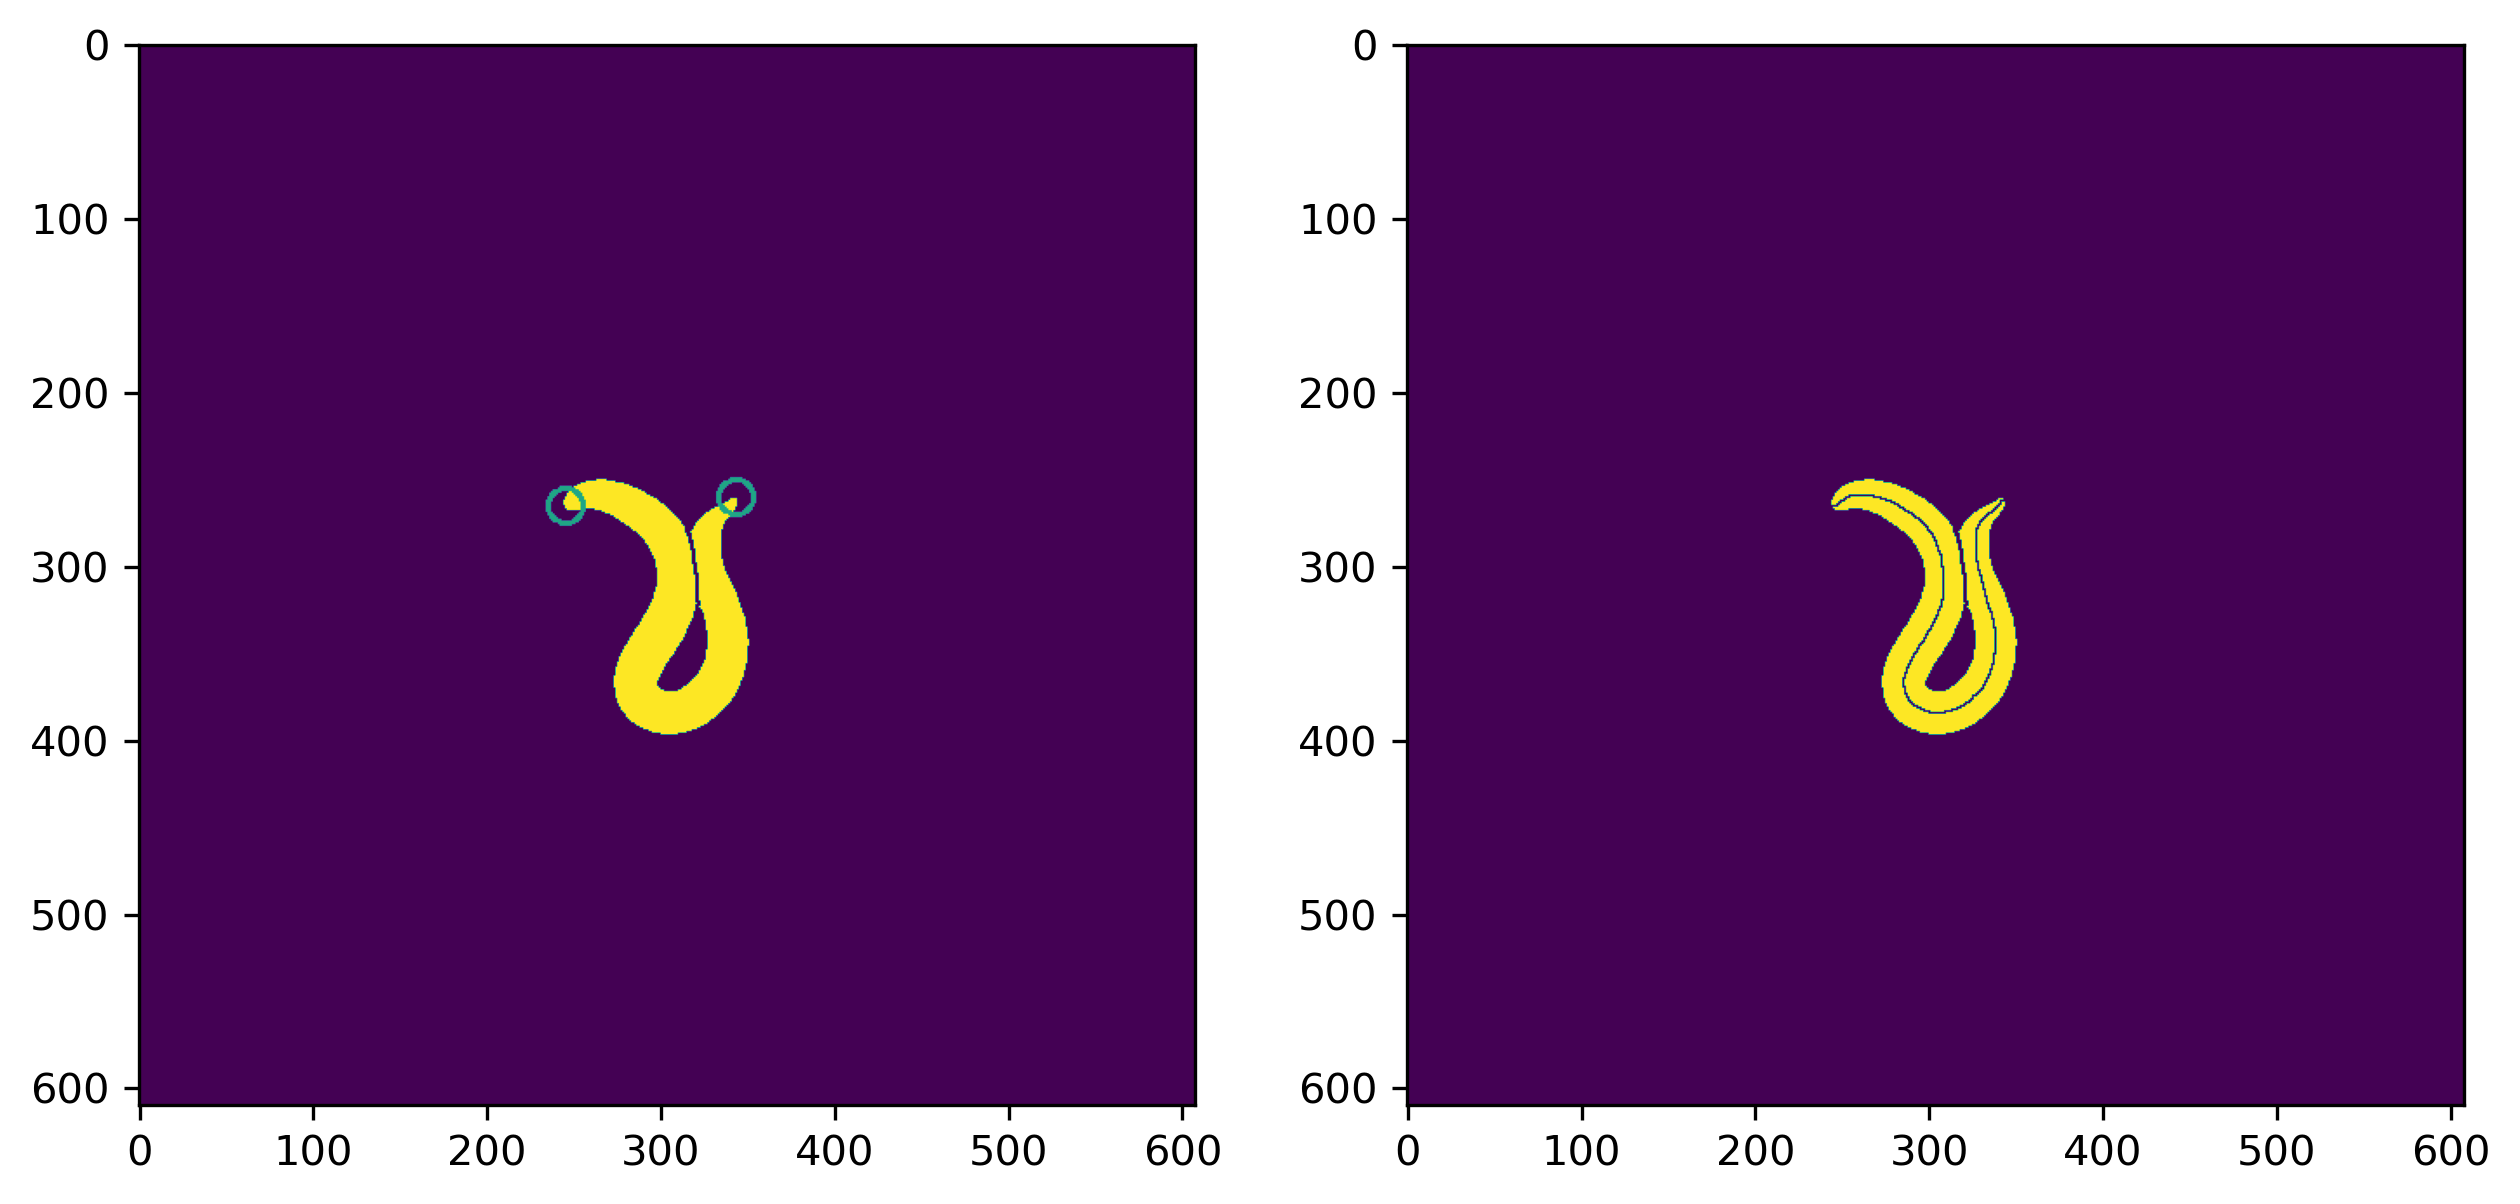

img59827.tif


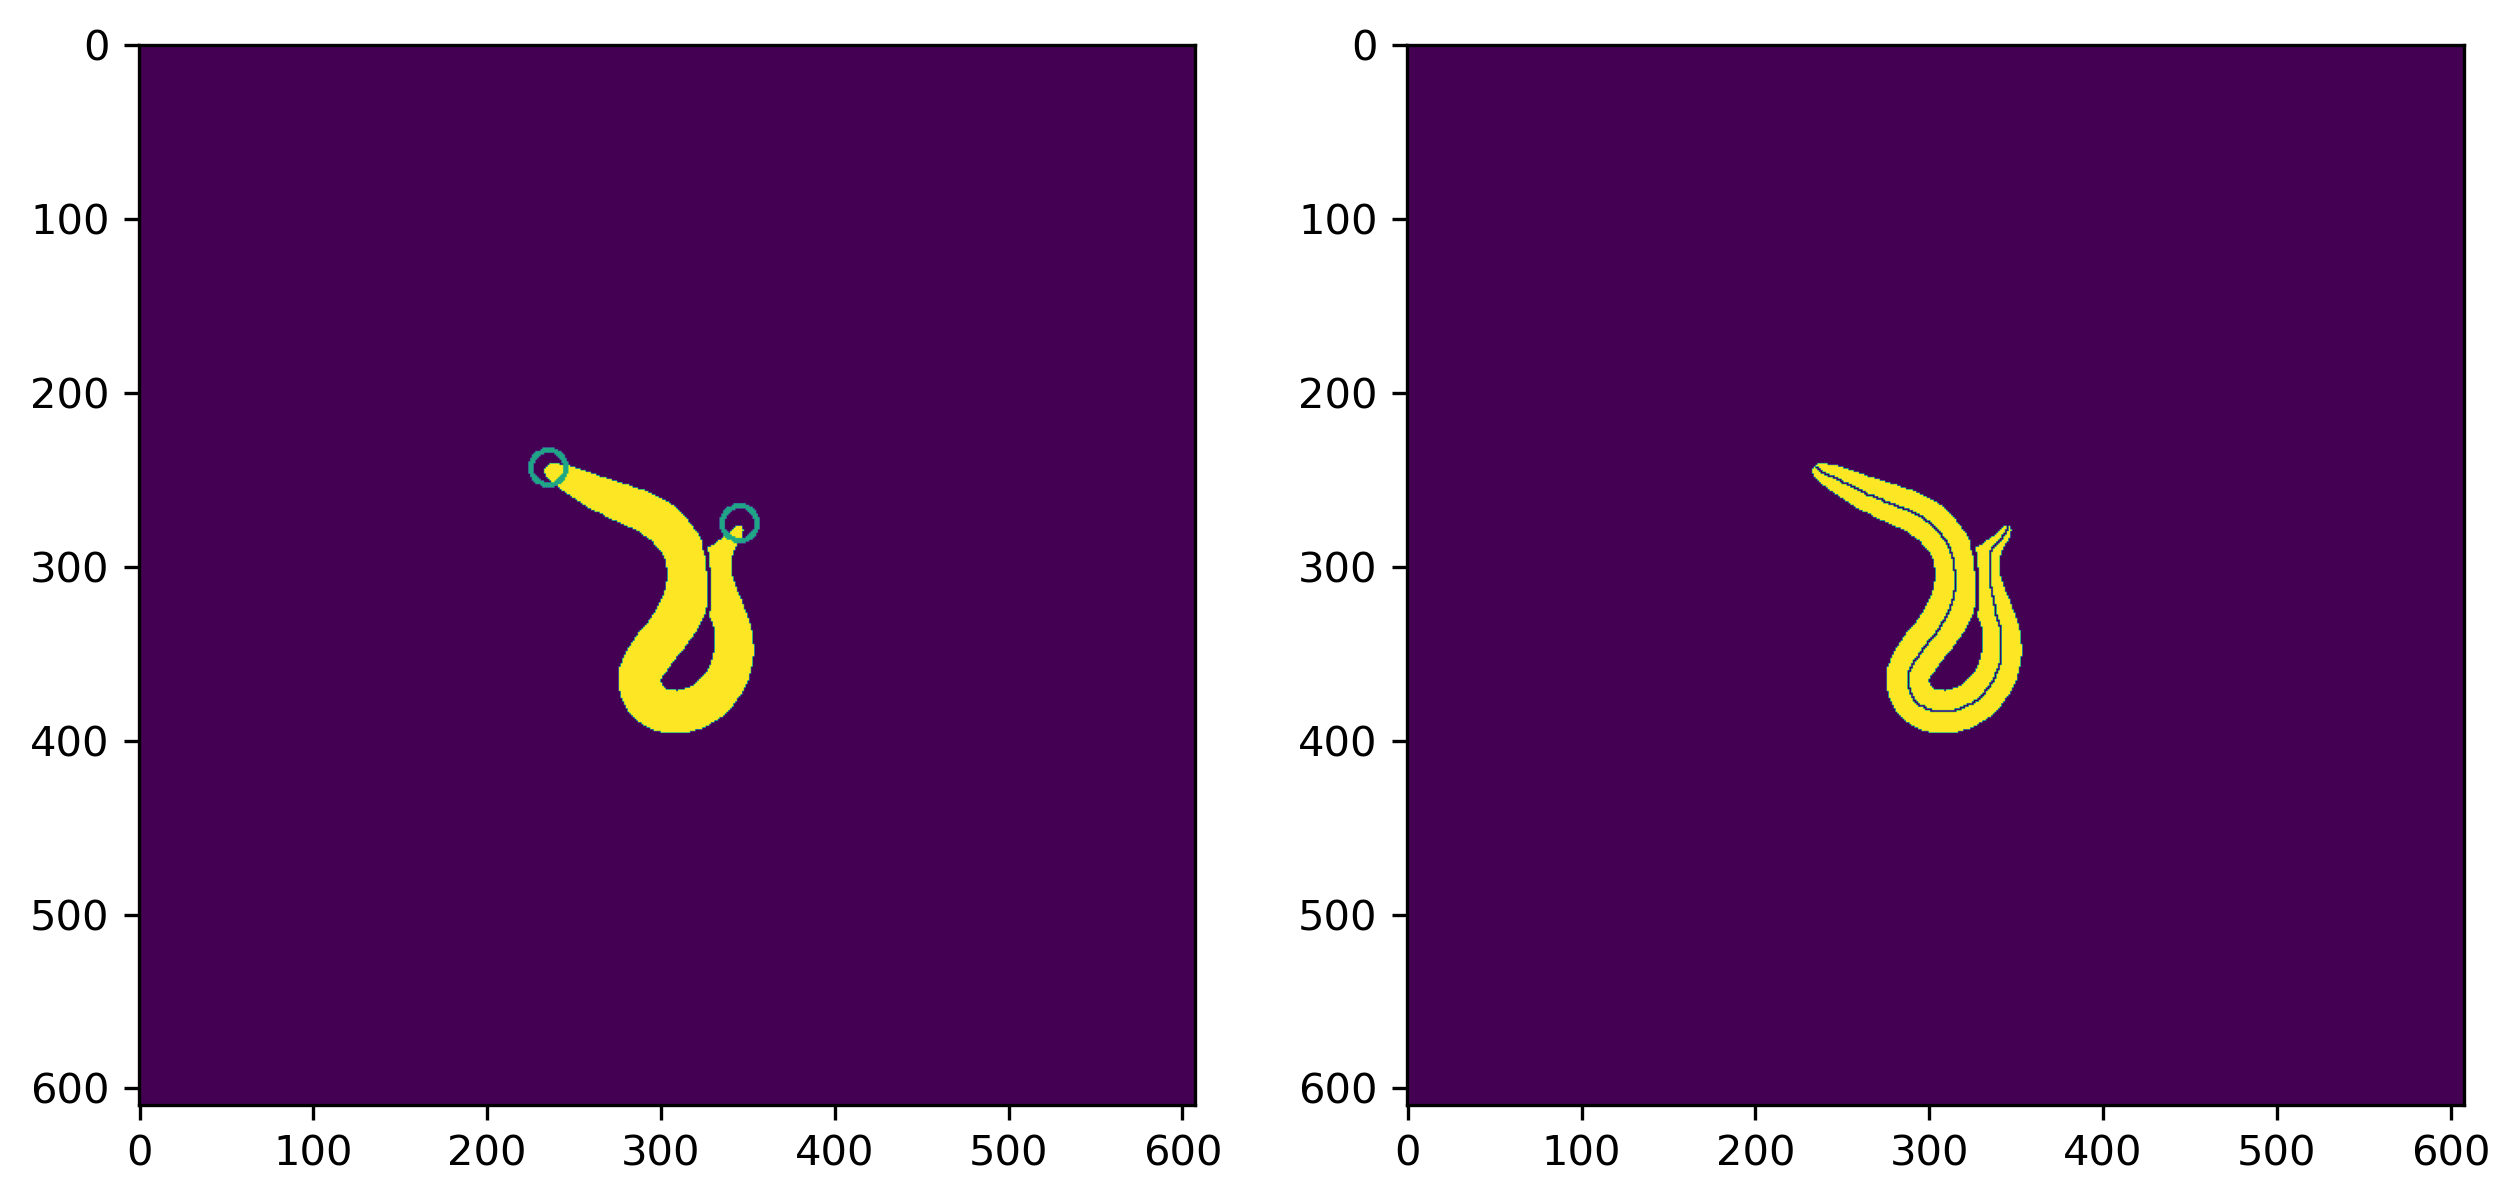

img59887.tif


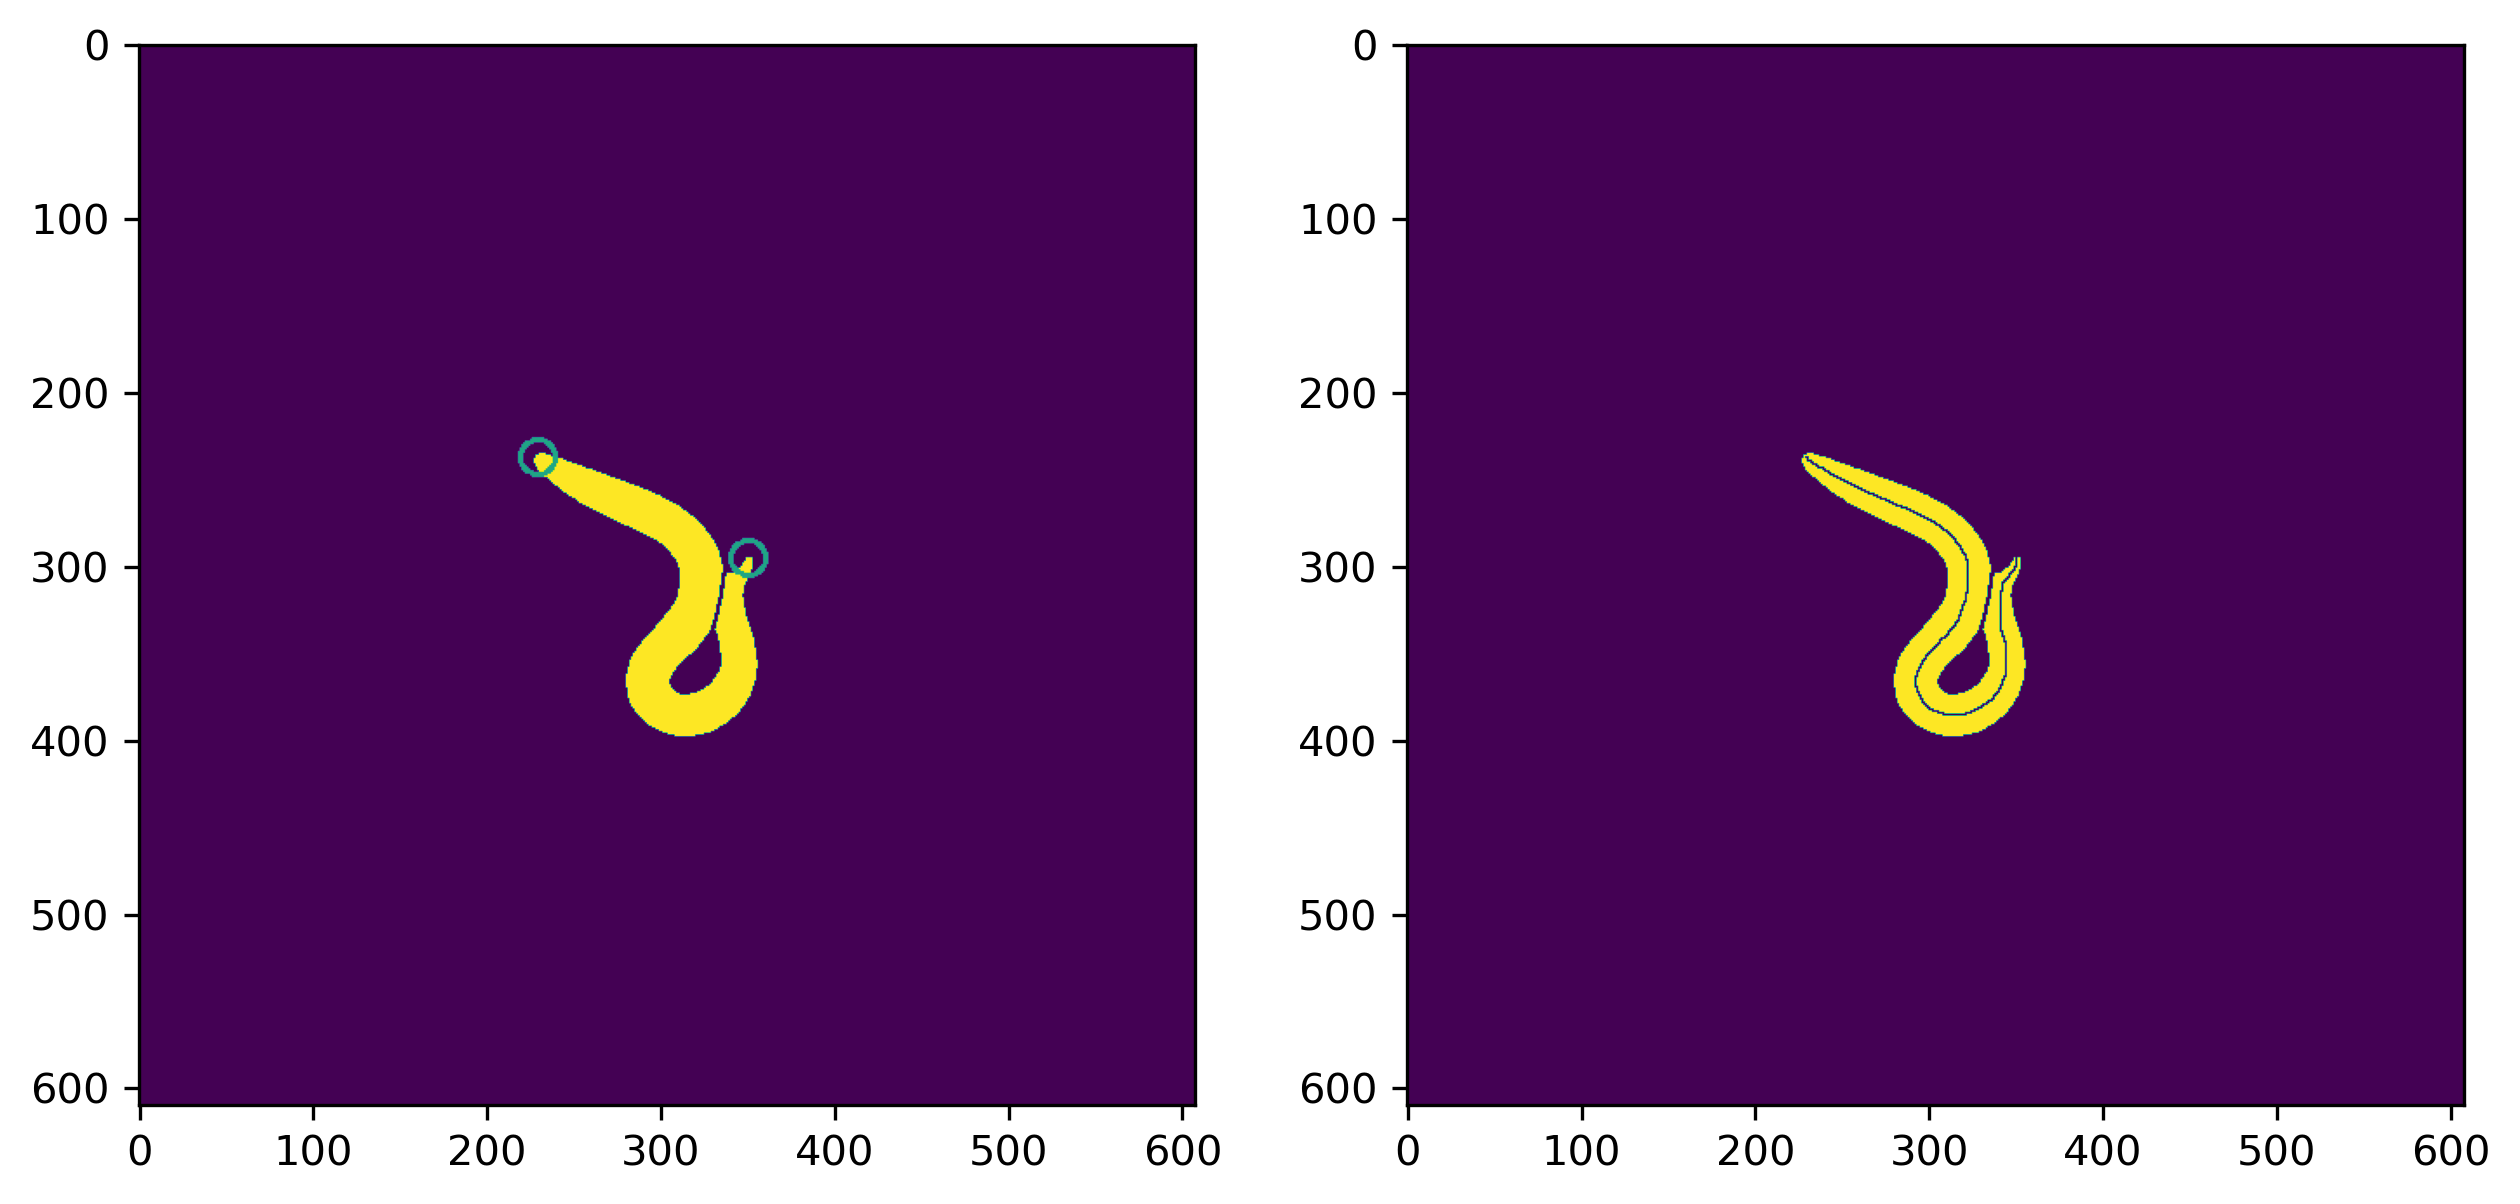

img62763.tif
head and tail were too close, no centerline could be created
img62823.tif
head and tail were too close, no centerline could be created
img62883.tif


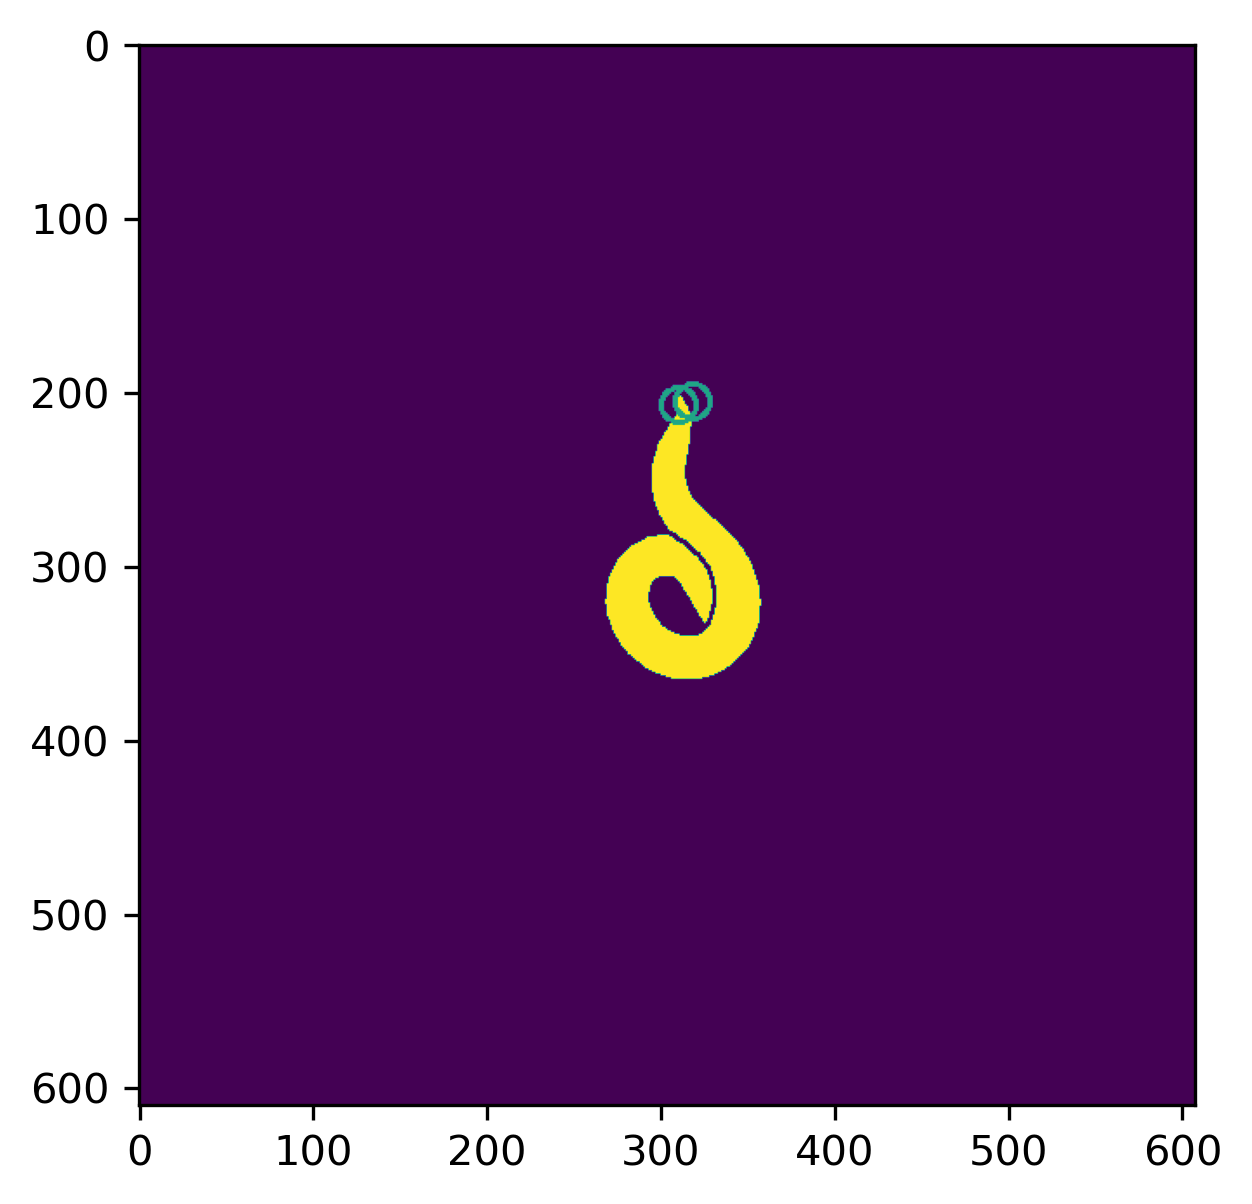

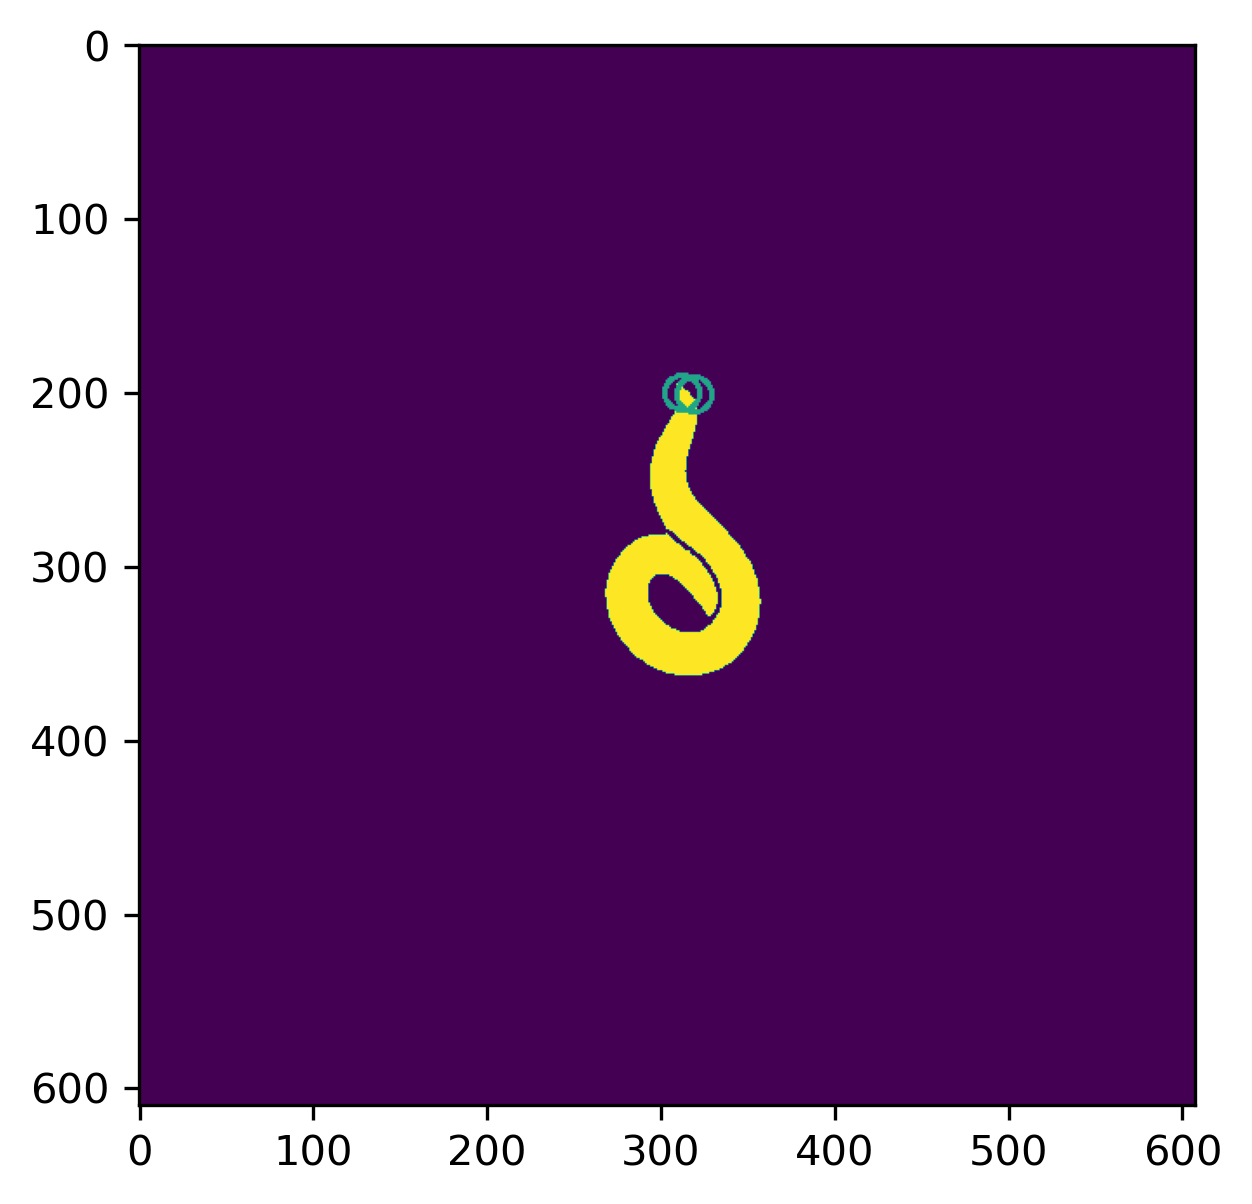

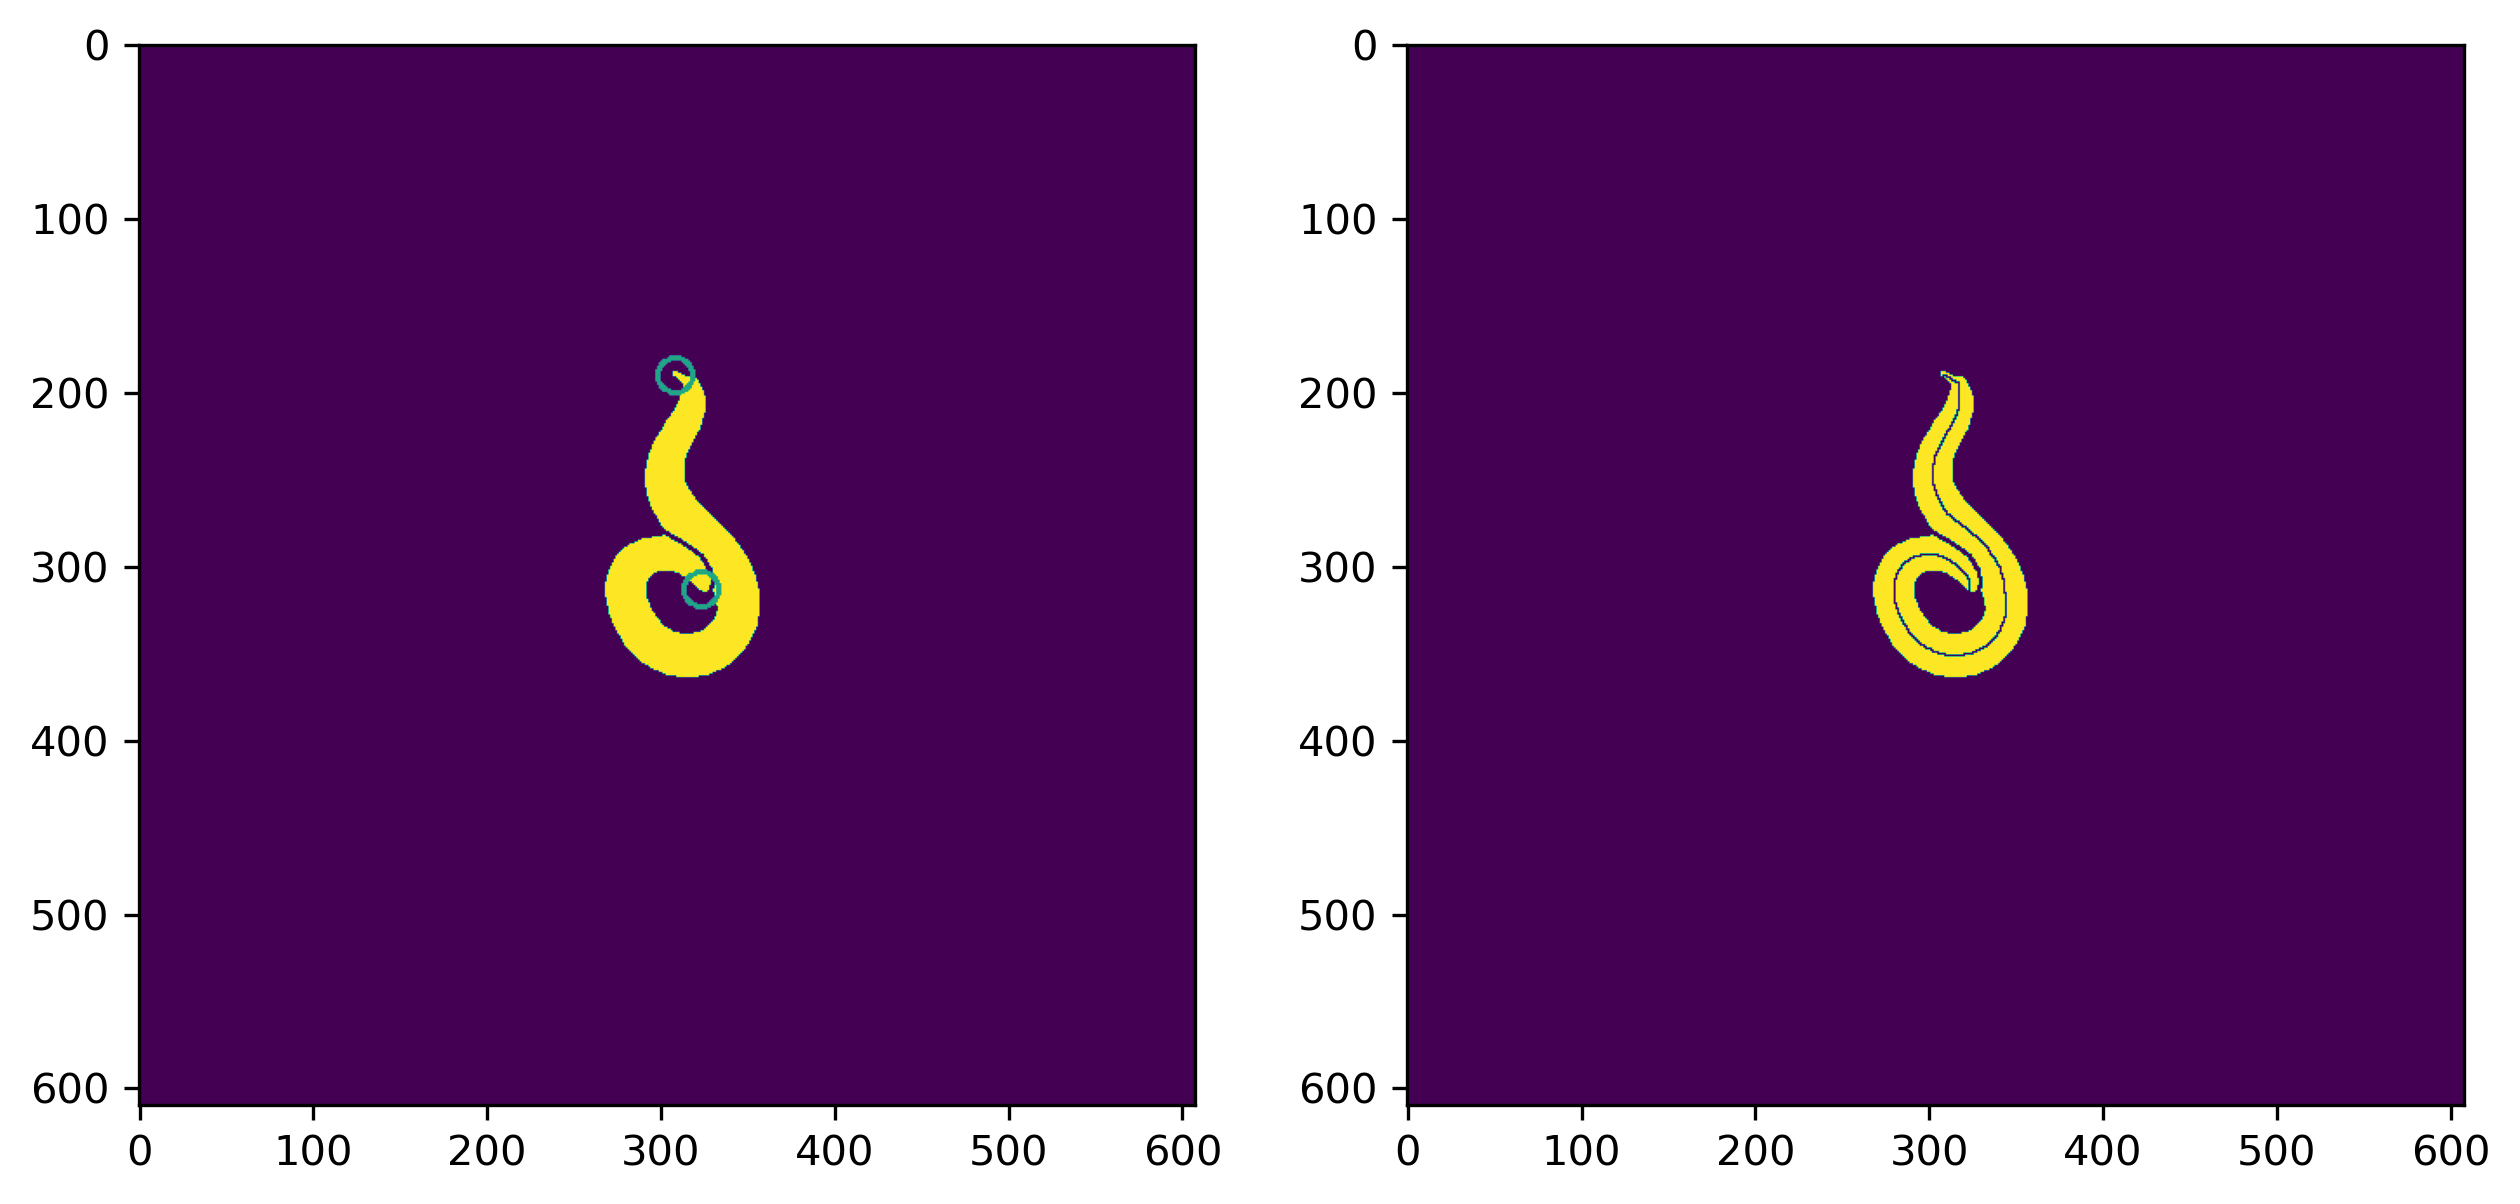

img62943.tif


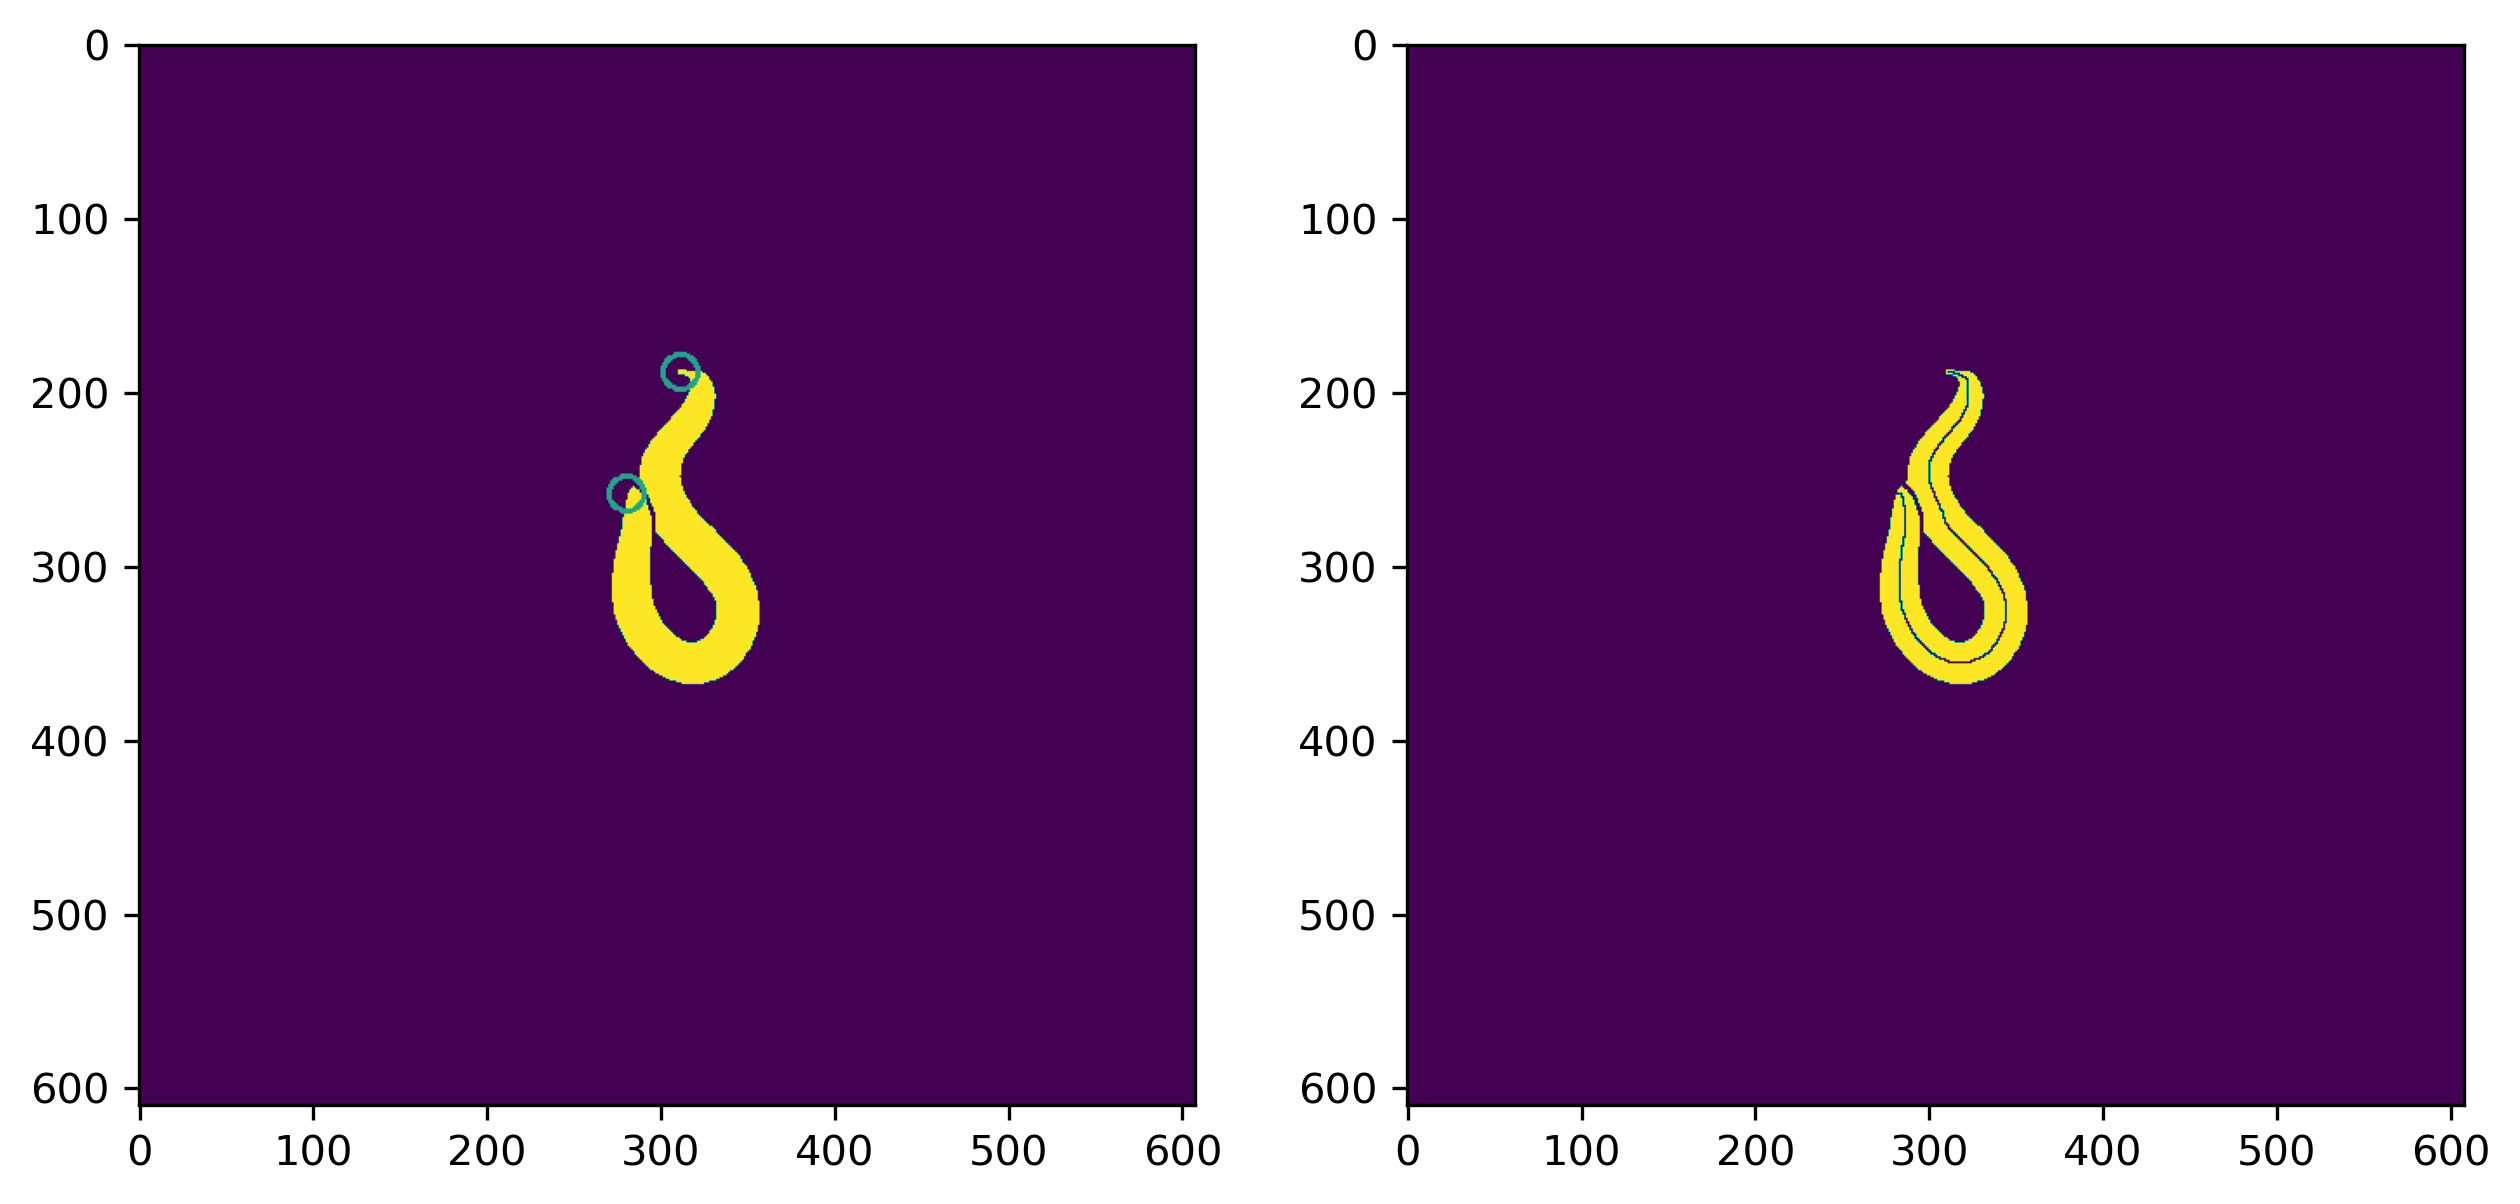

img63003.tif


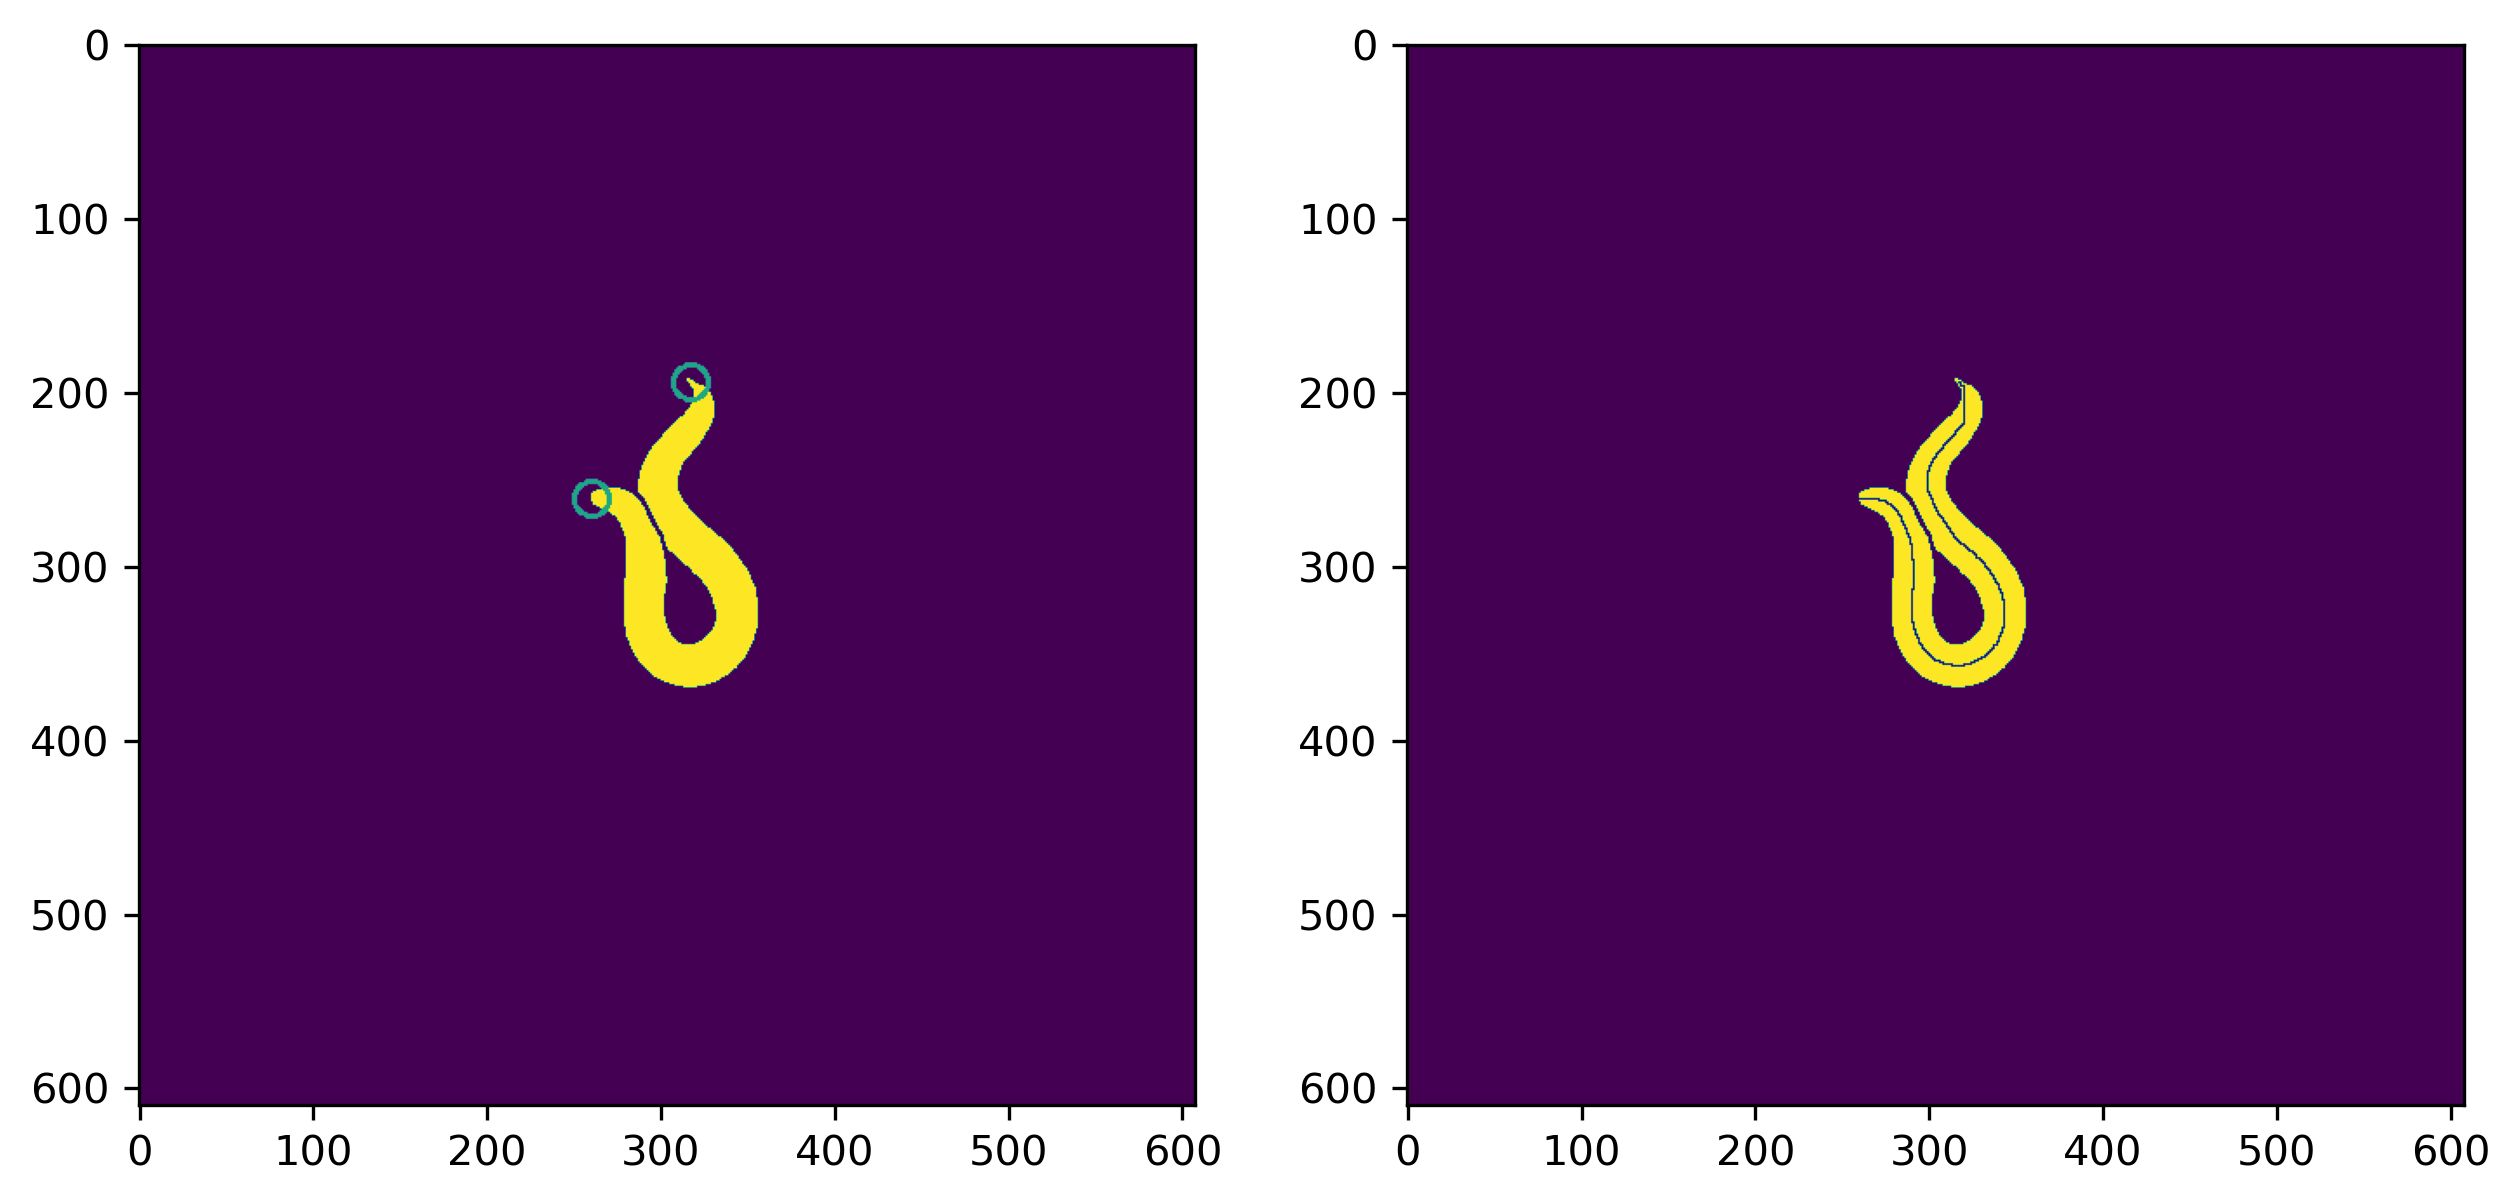

img63063.tif


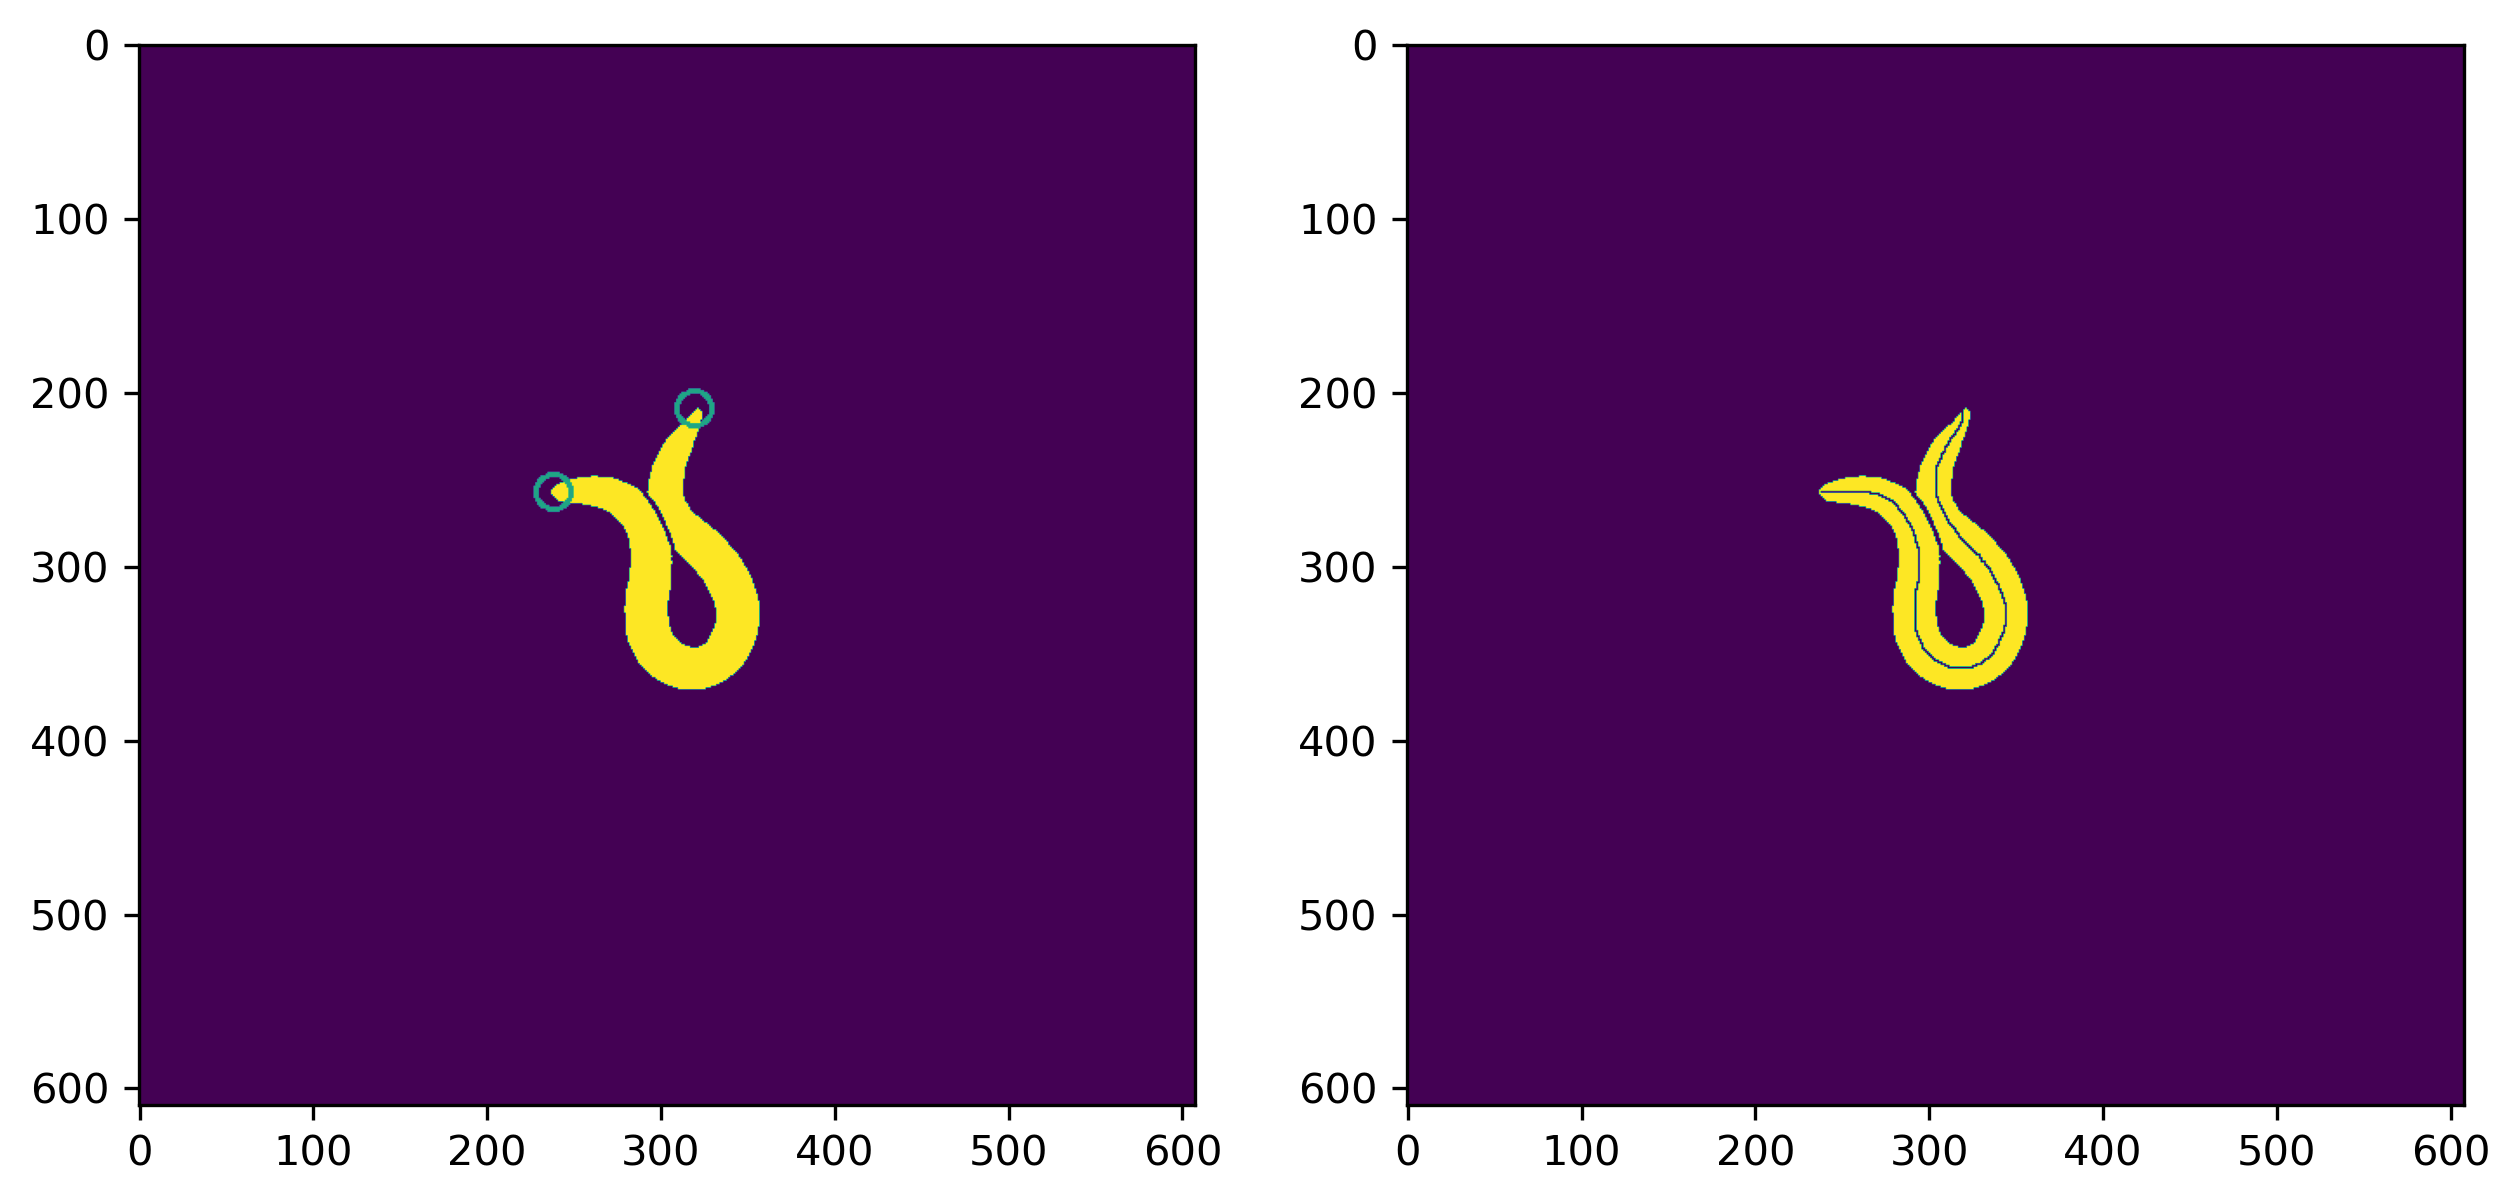

img63123.tif


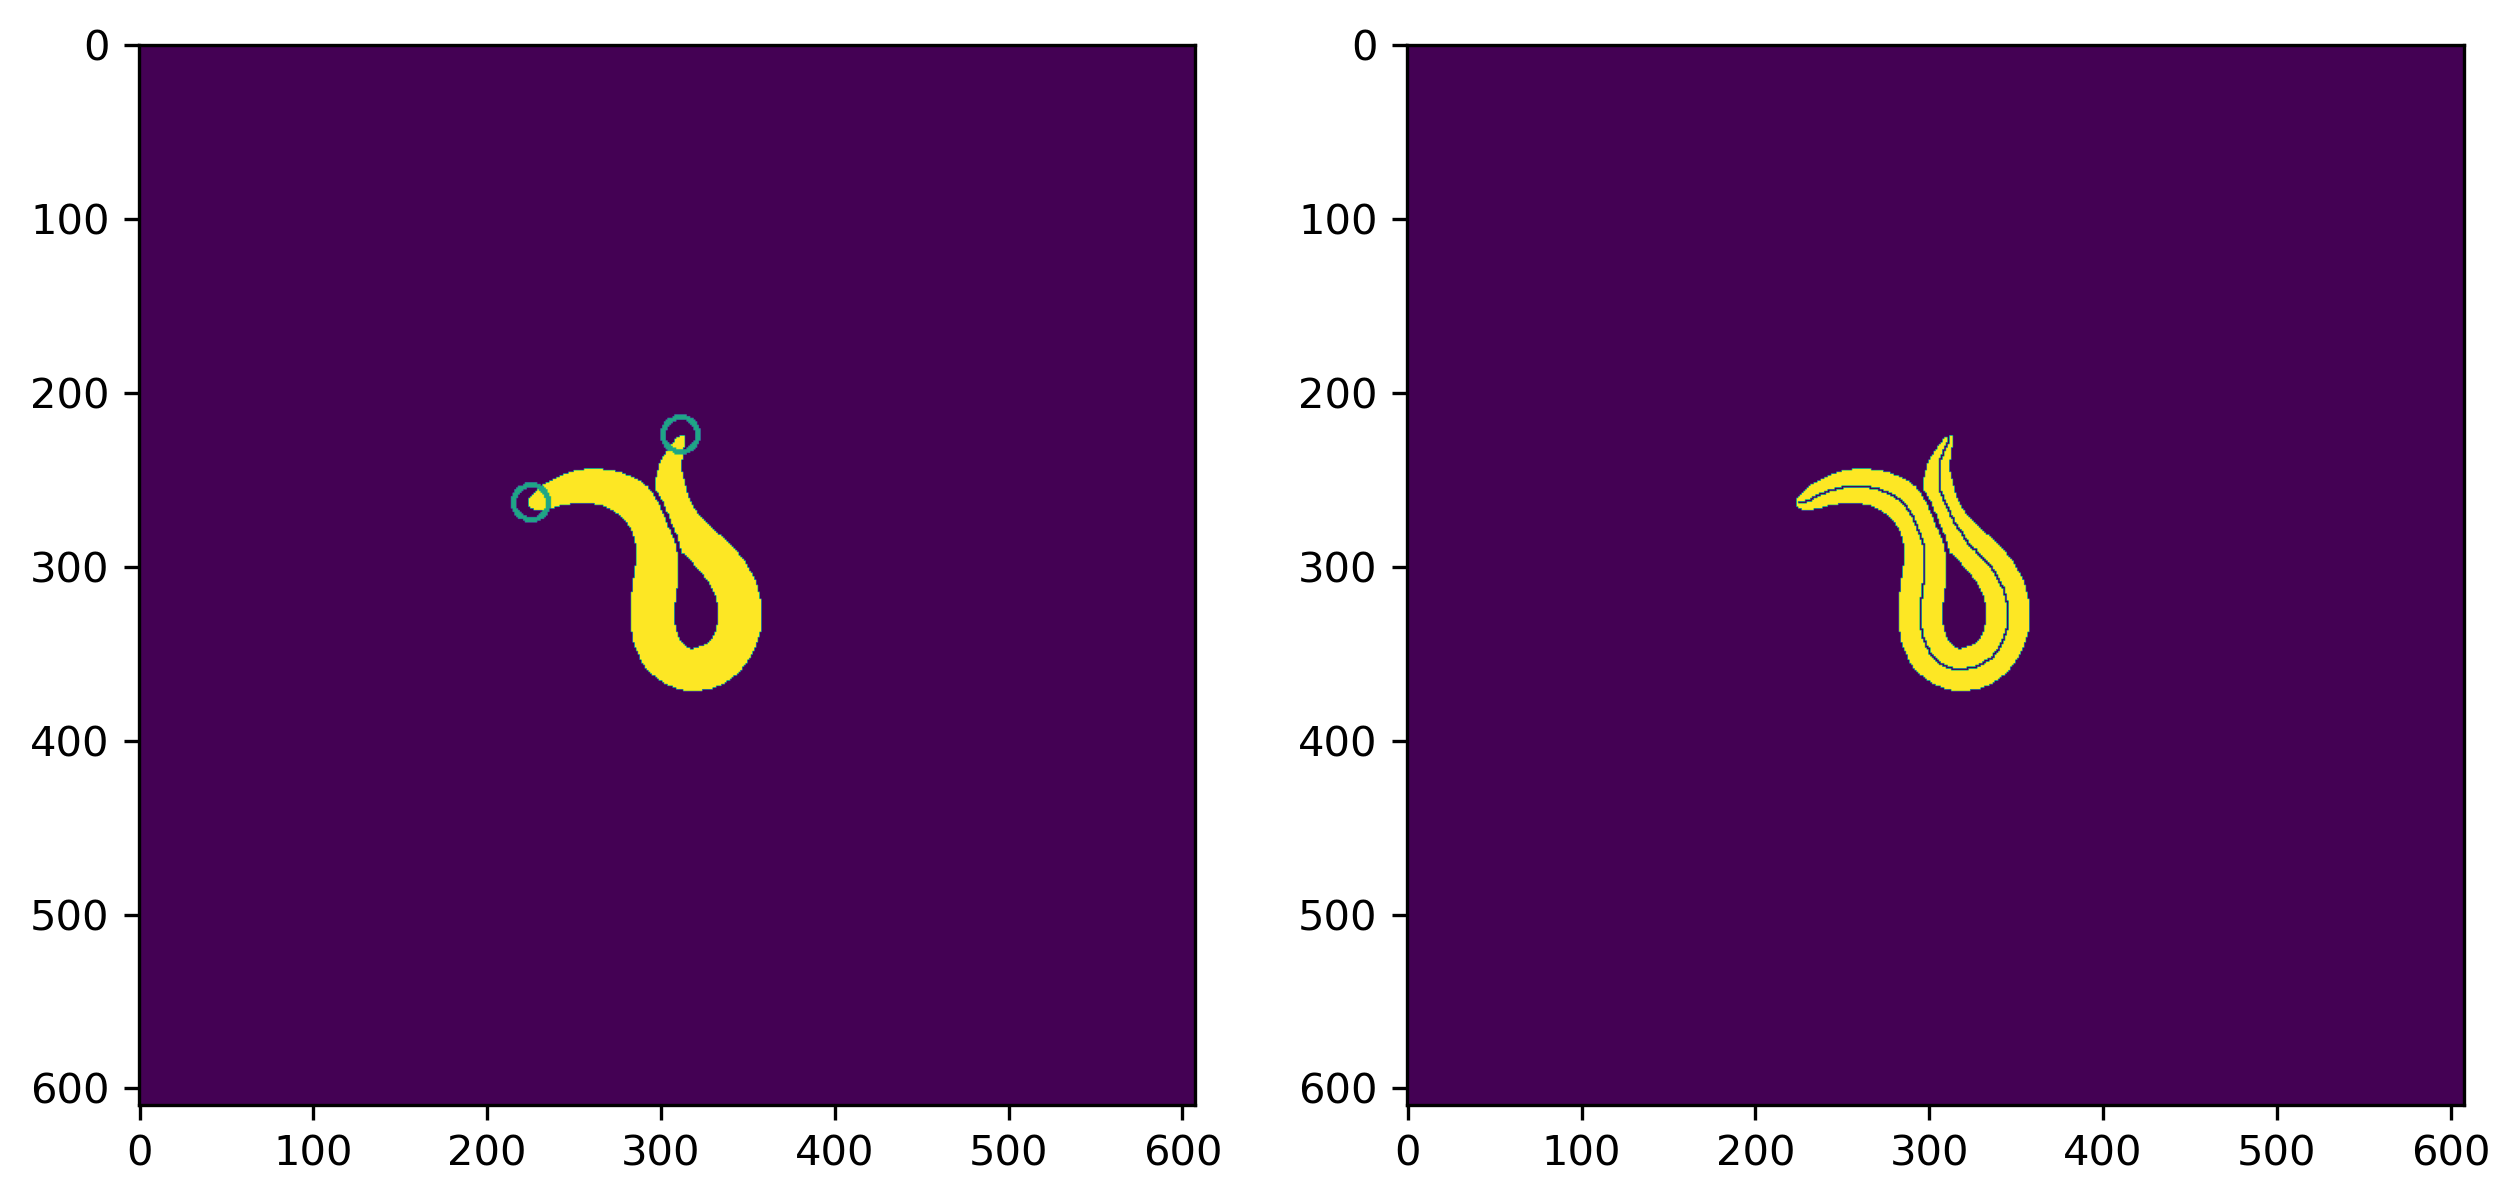

img63183.tif


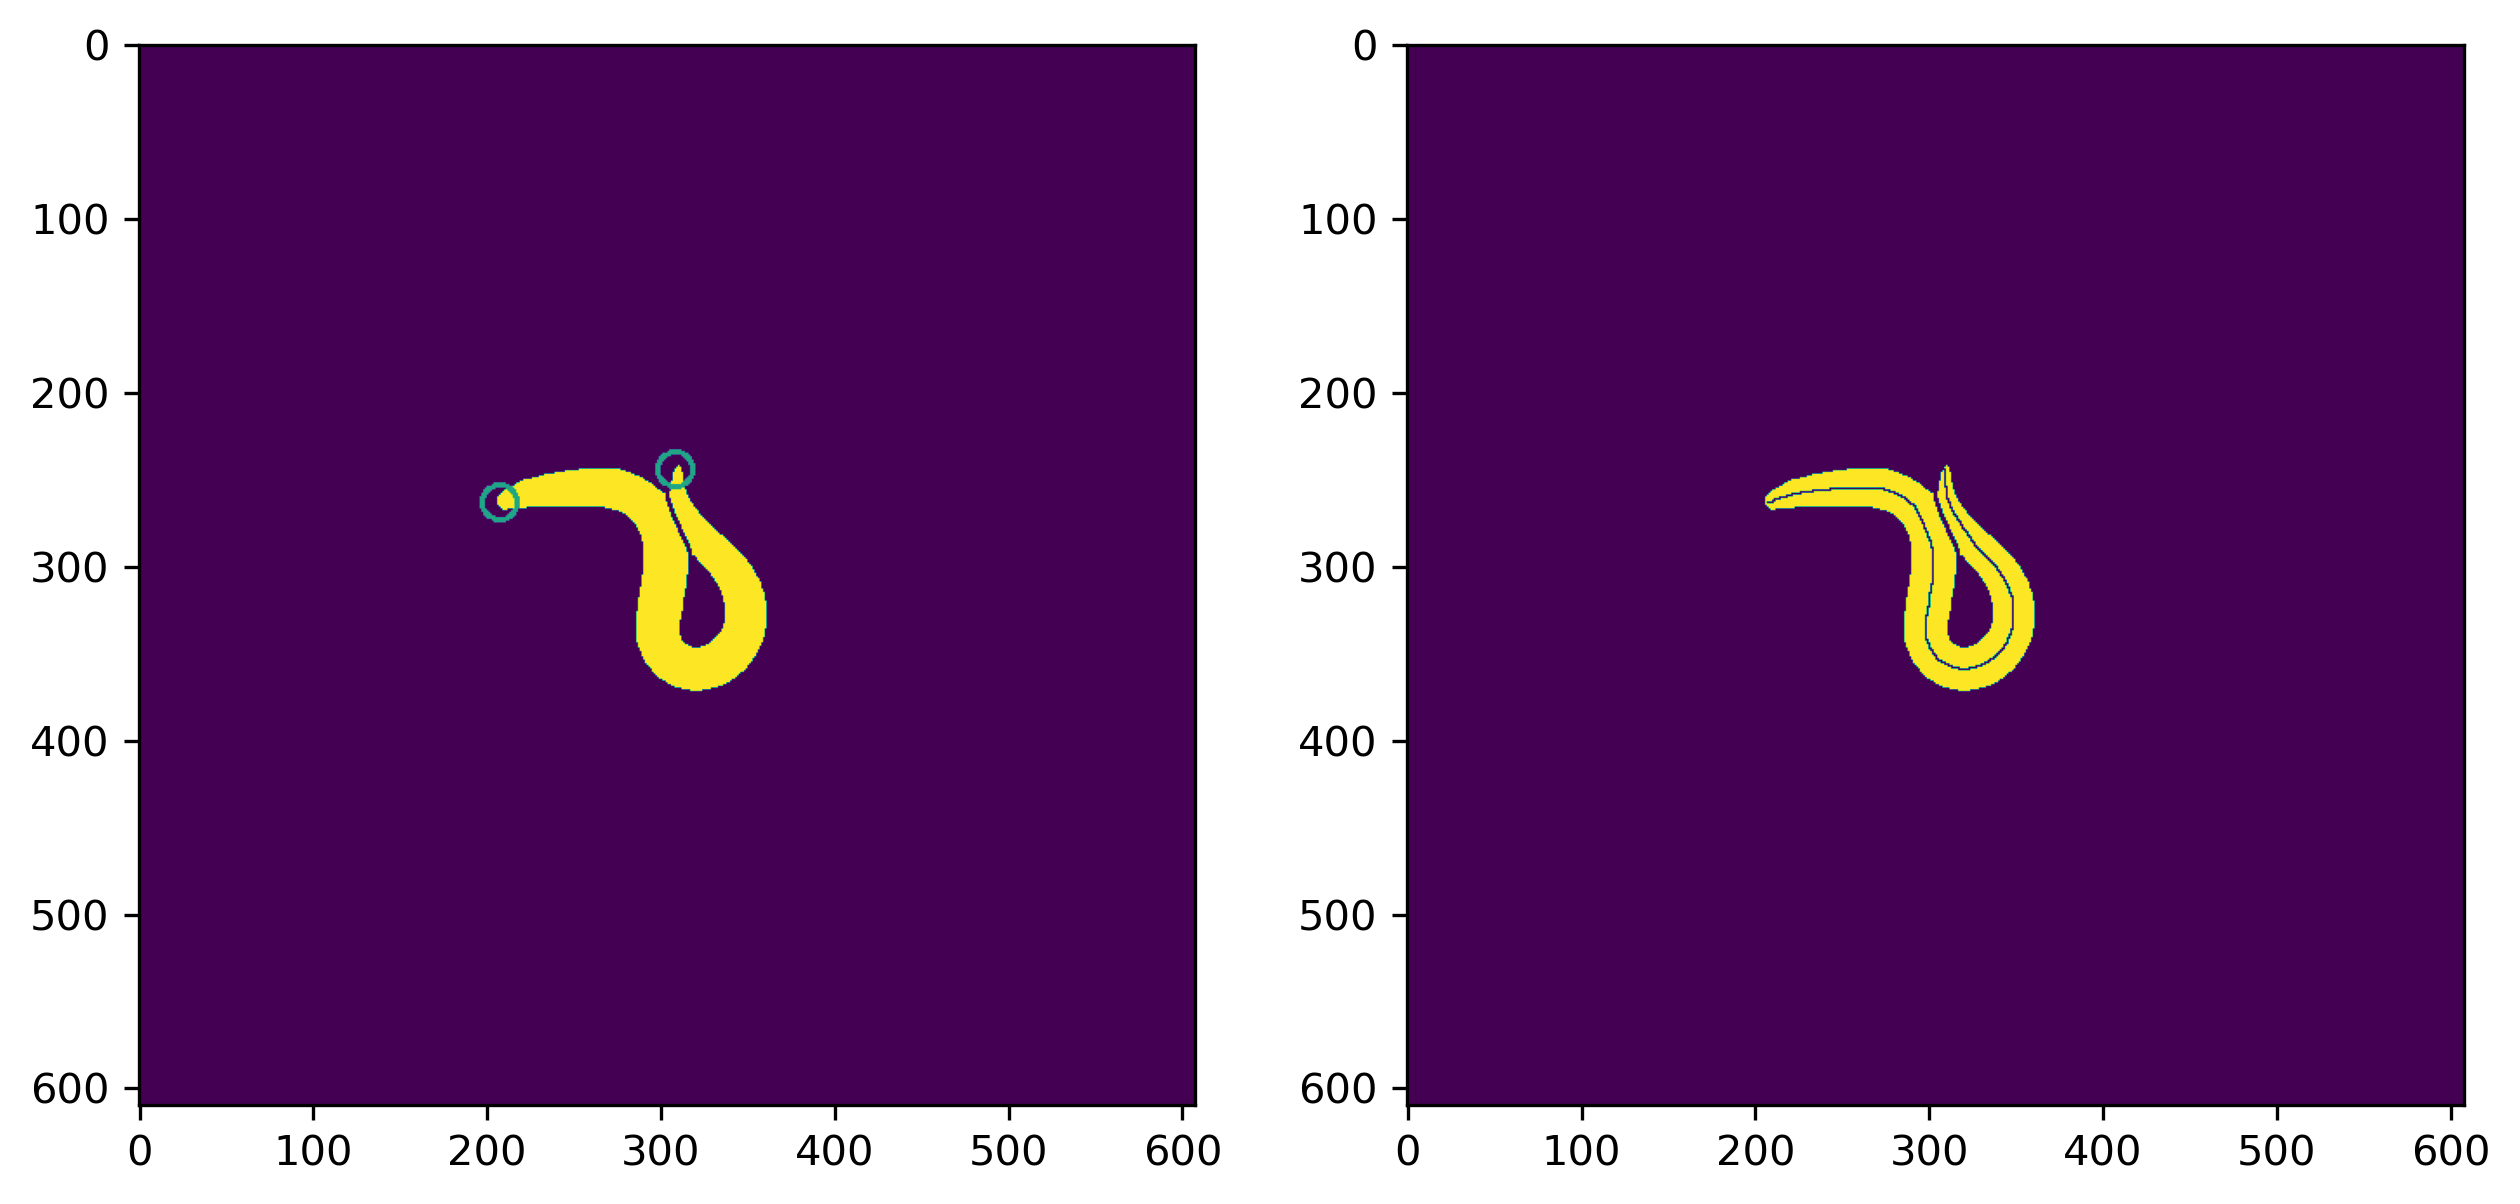

img63243.tif
head and tail were too close, no centerline could be created
img108725.tif
head and tail were too close, no centerline could be created
img108845.tif
head and tail were too close, no centerline could be created
img108905.tif


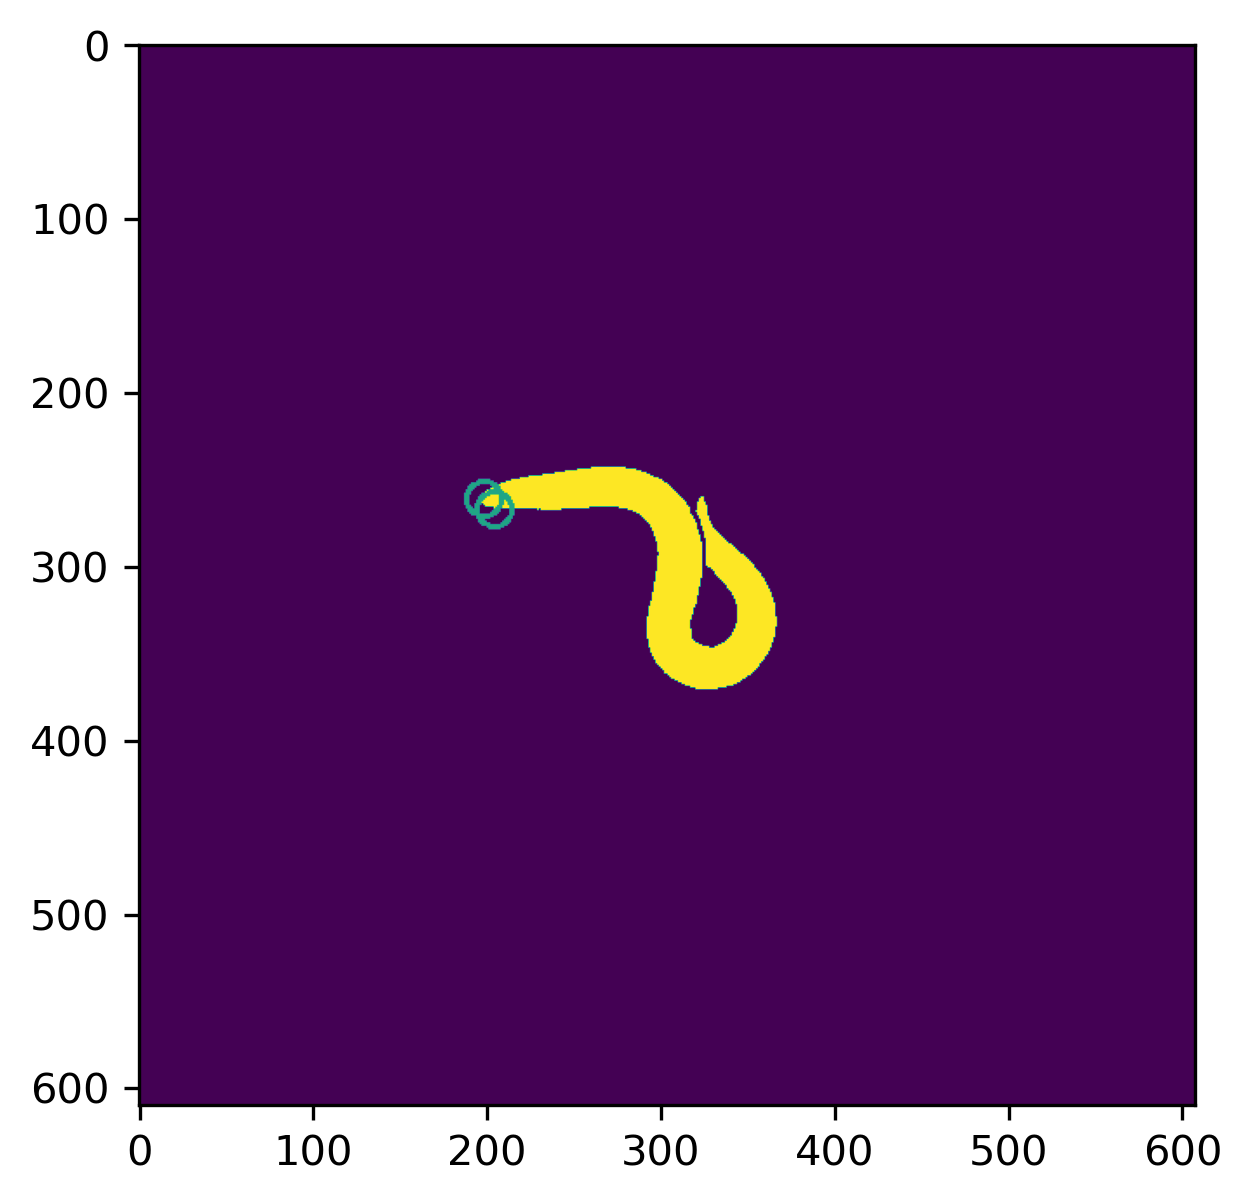

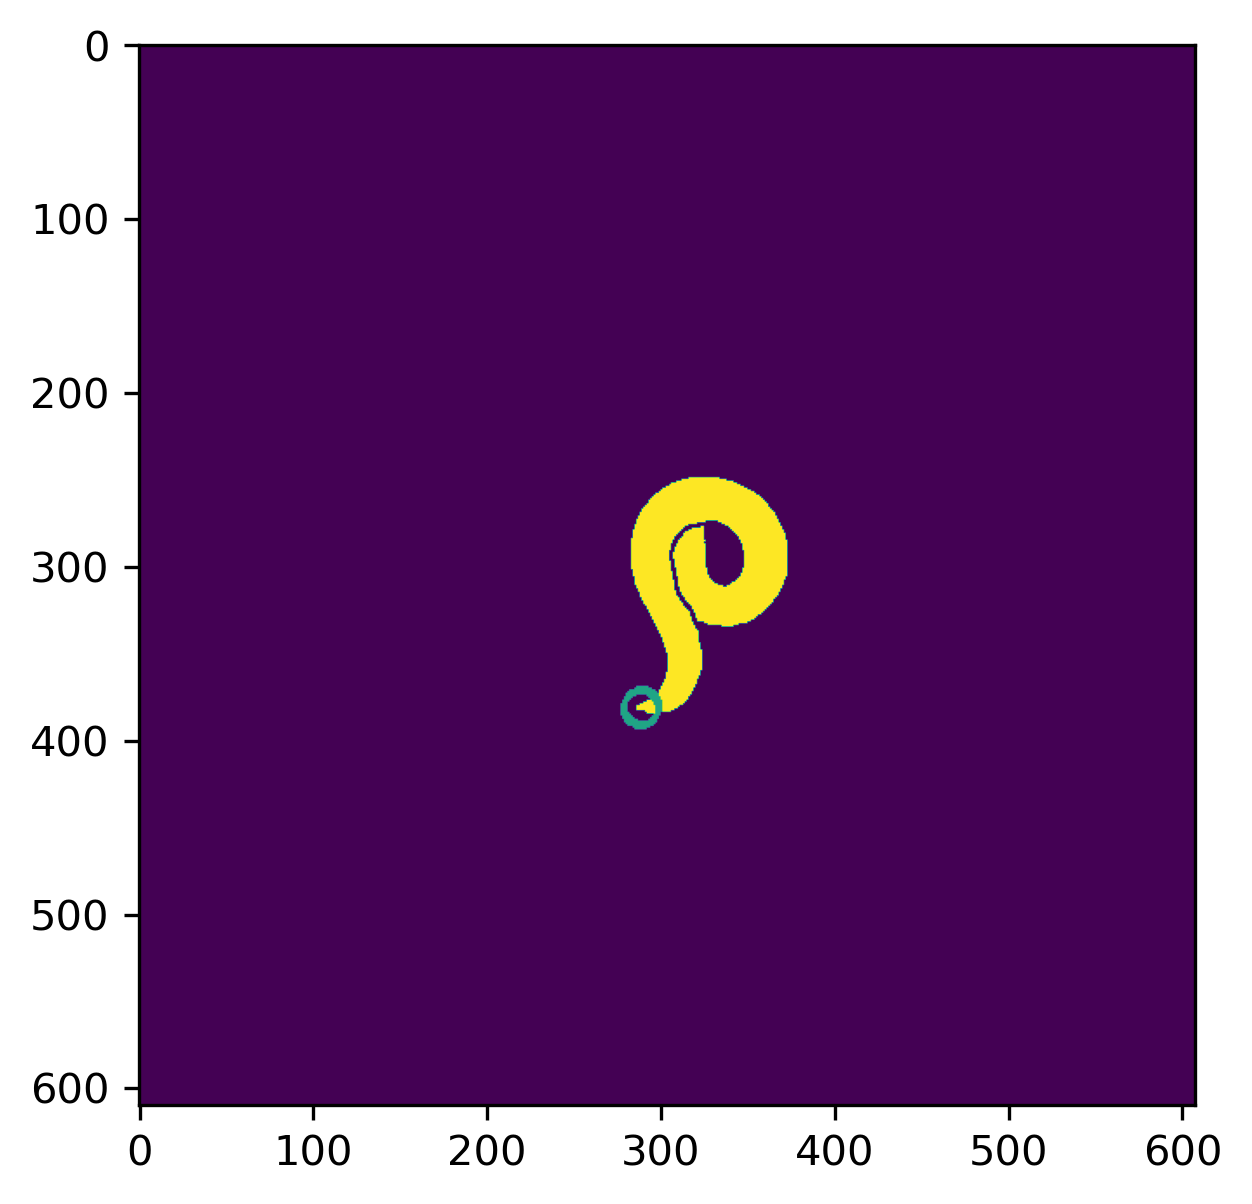

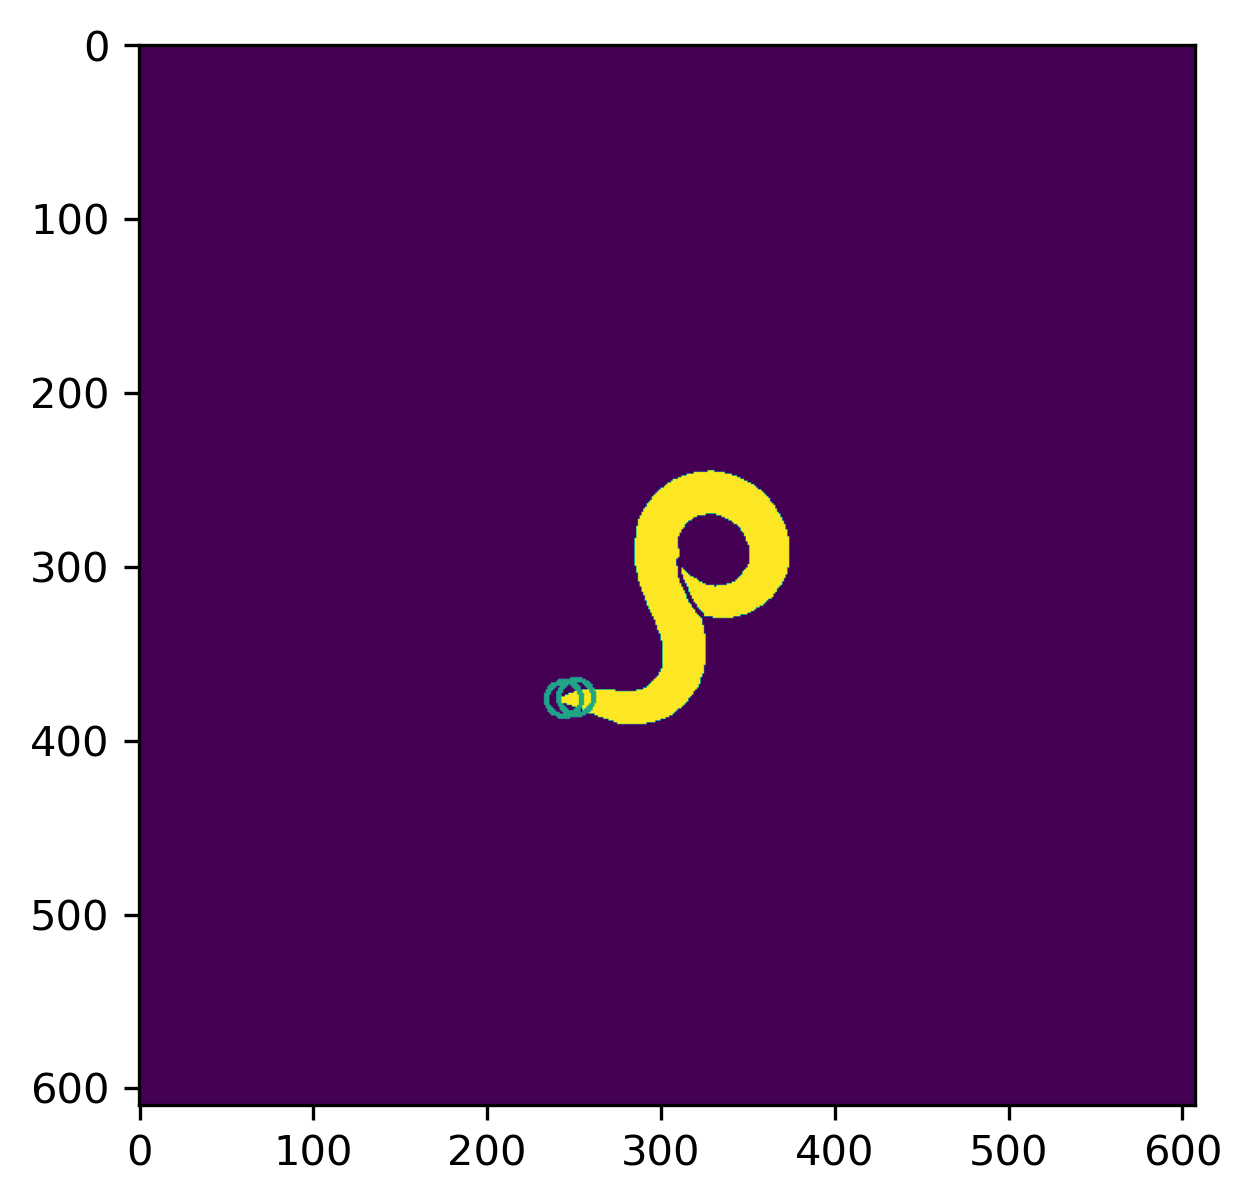

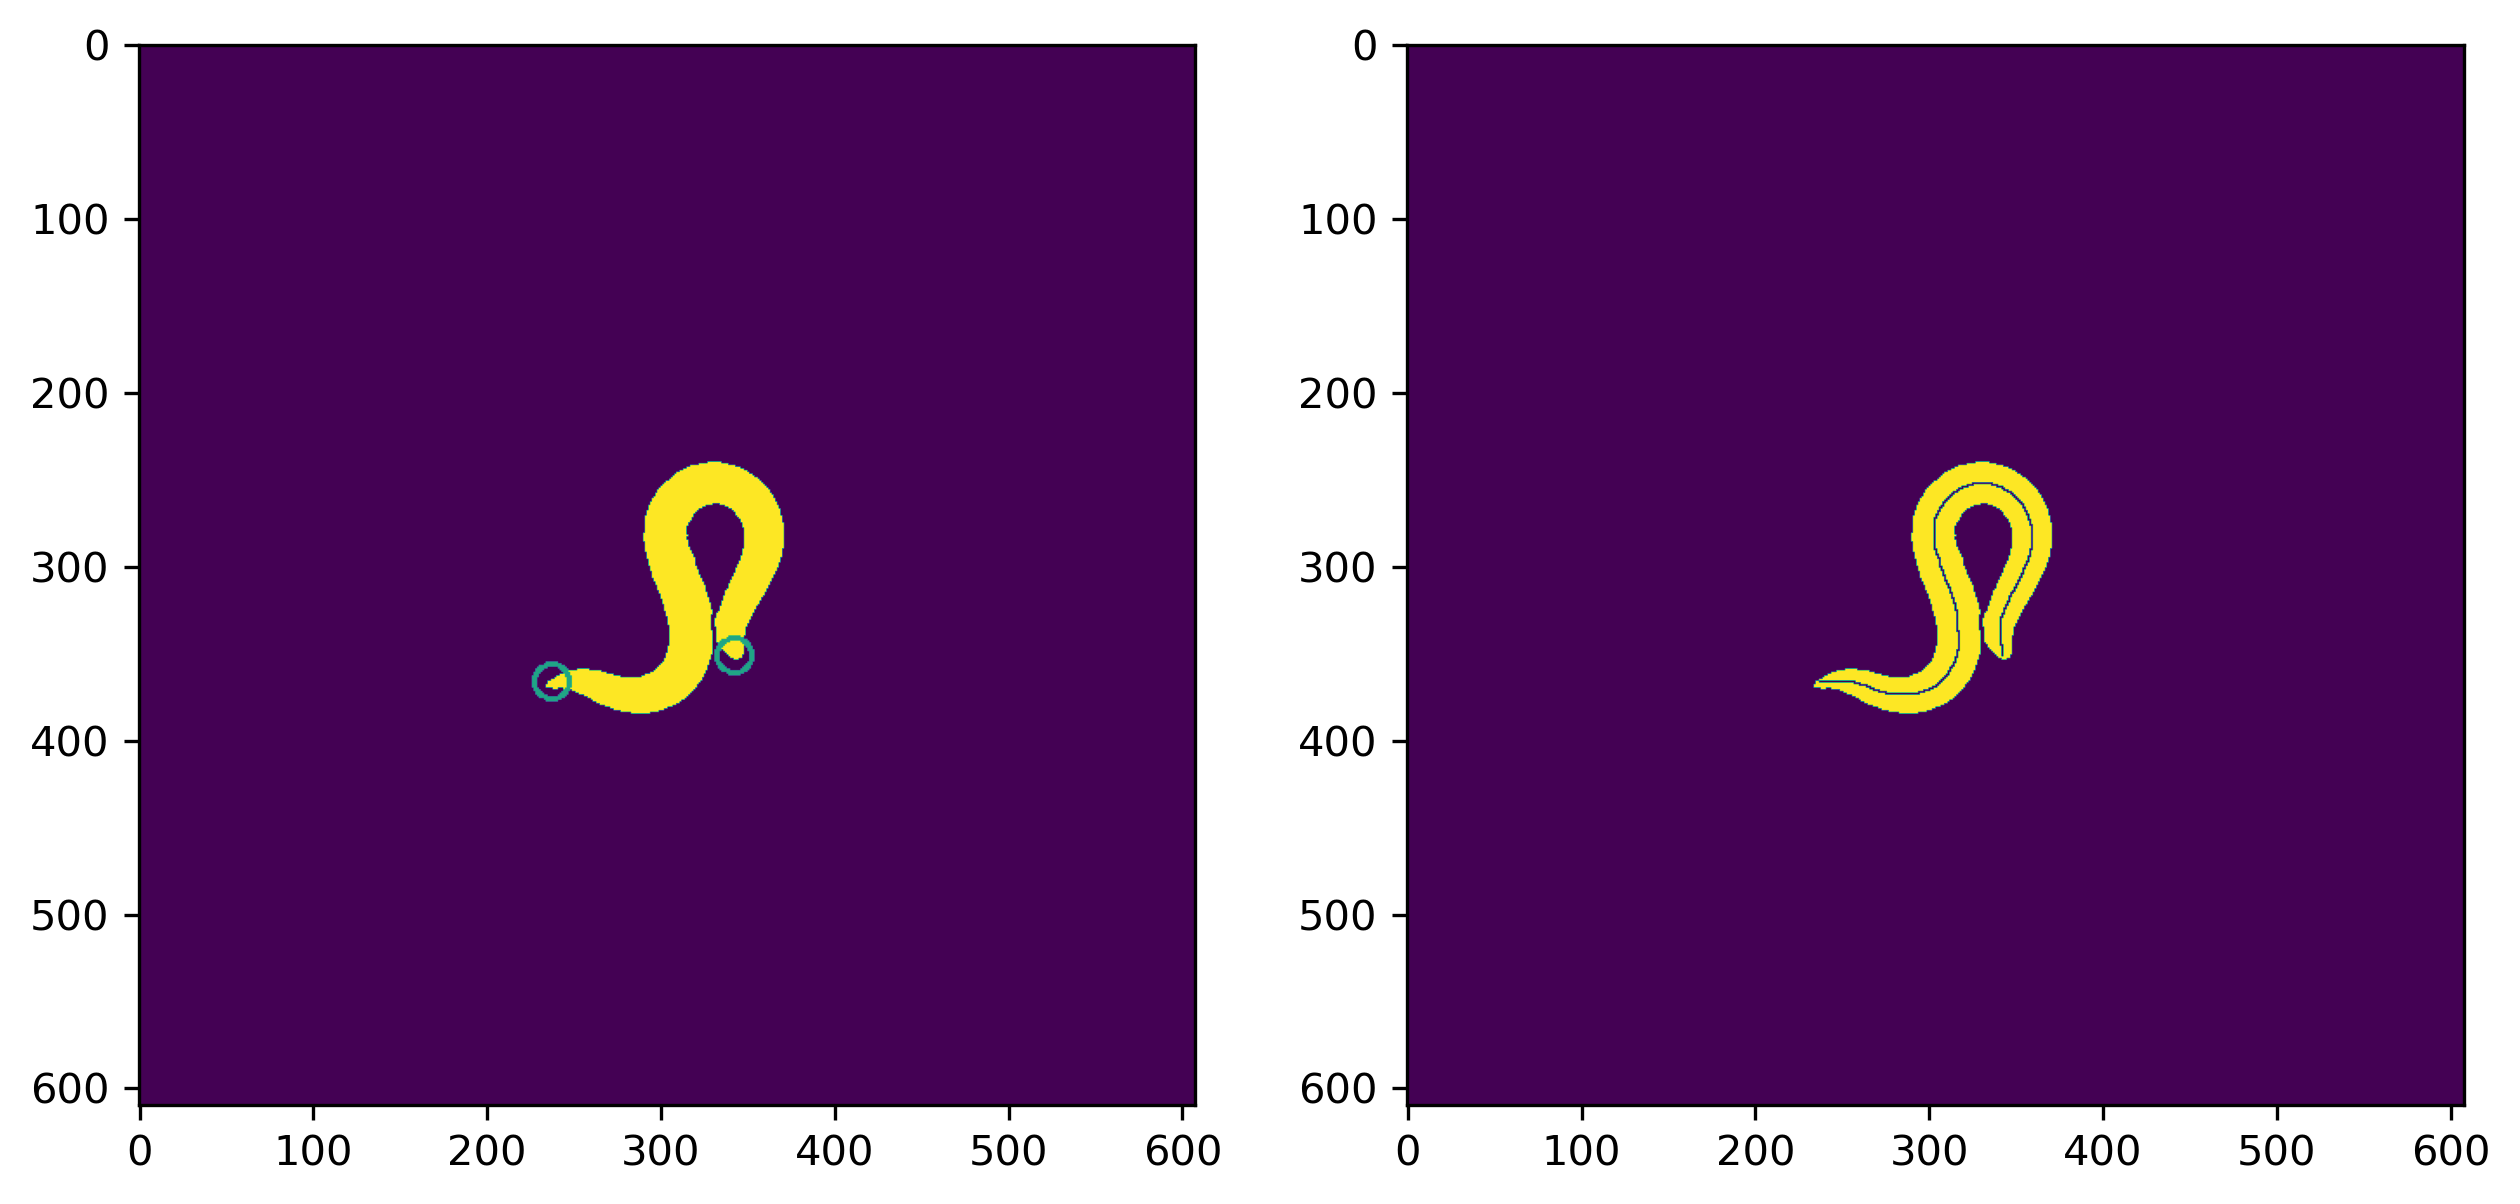

img109085.tif


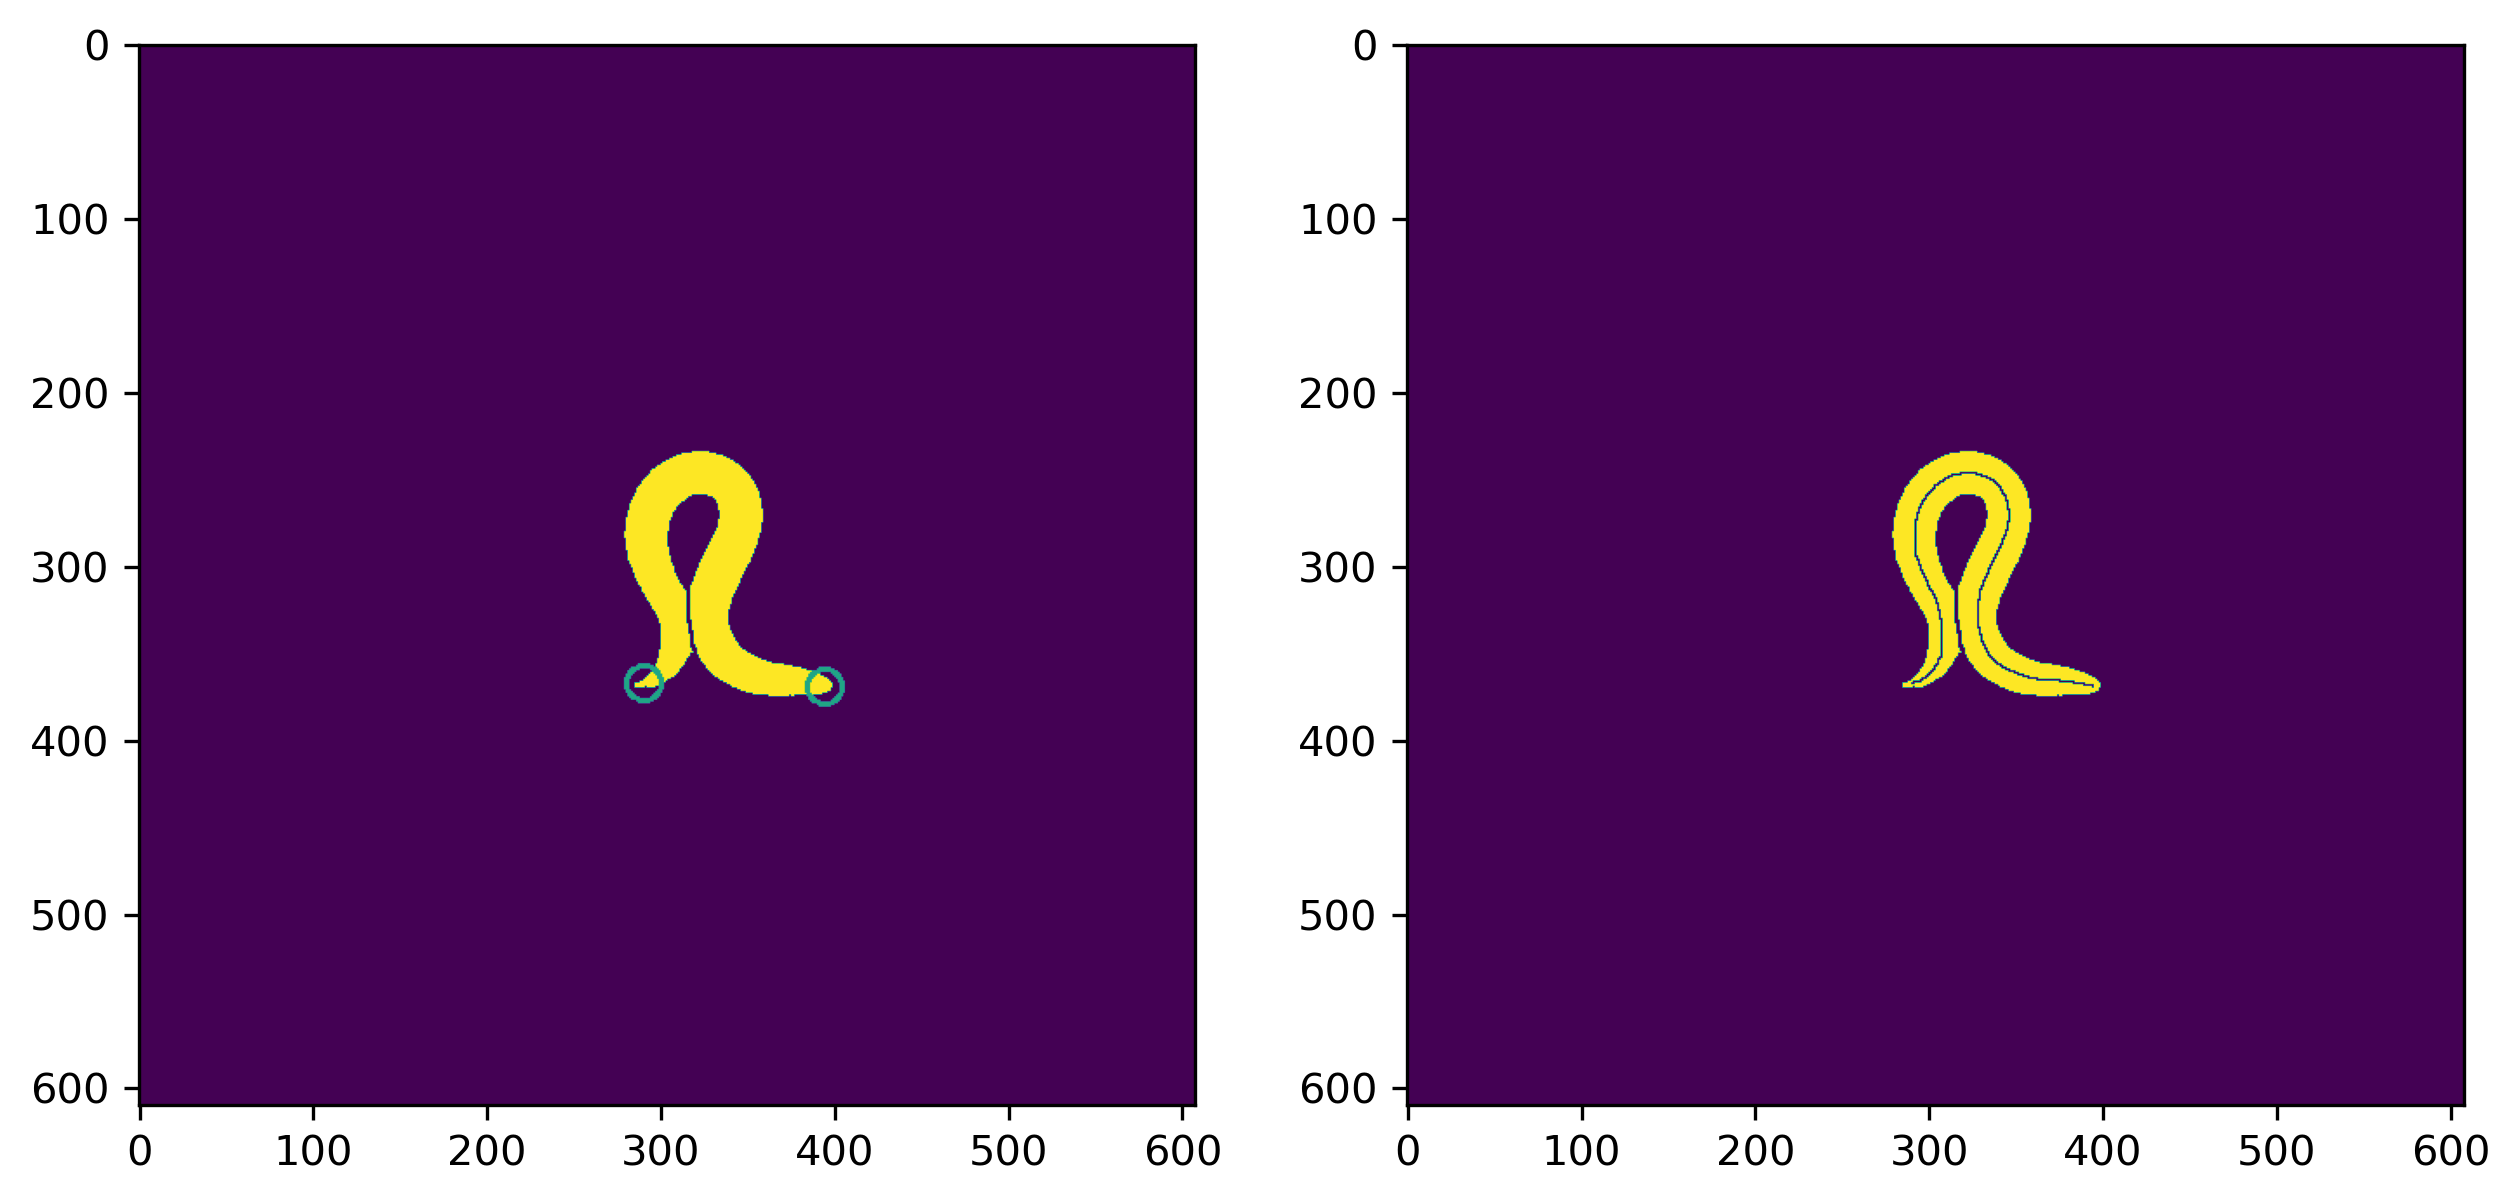

img109145.tif


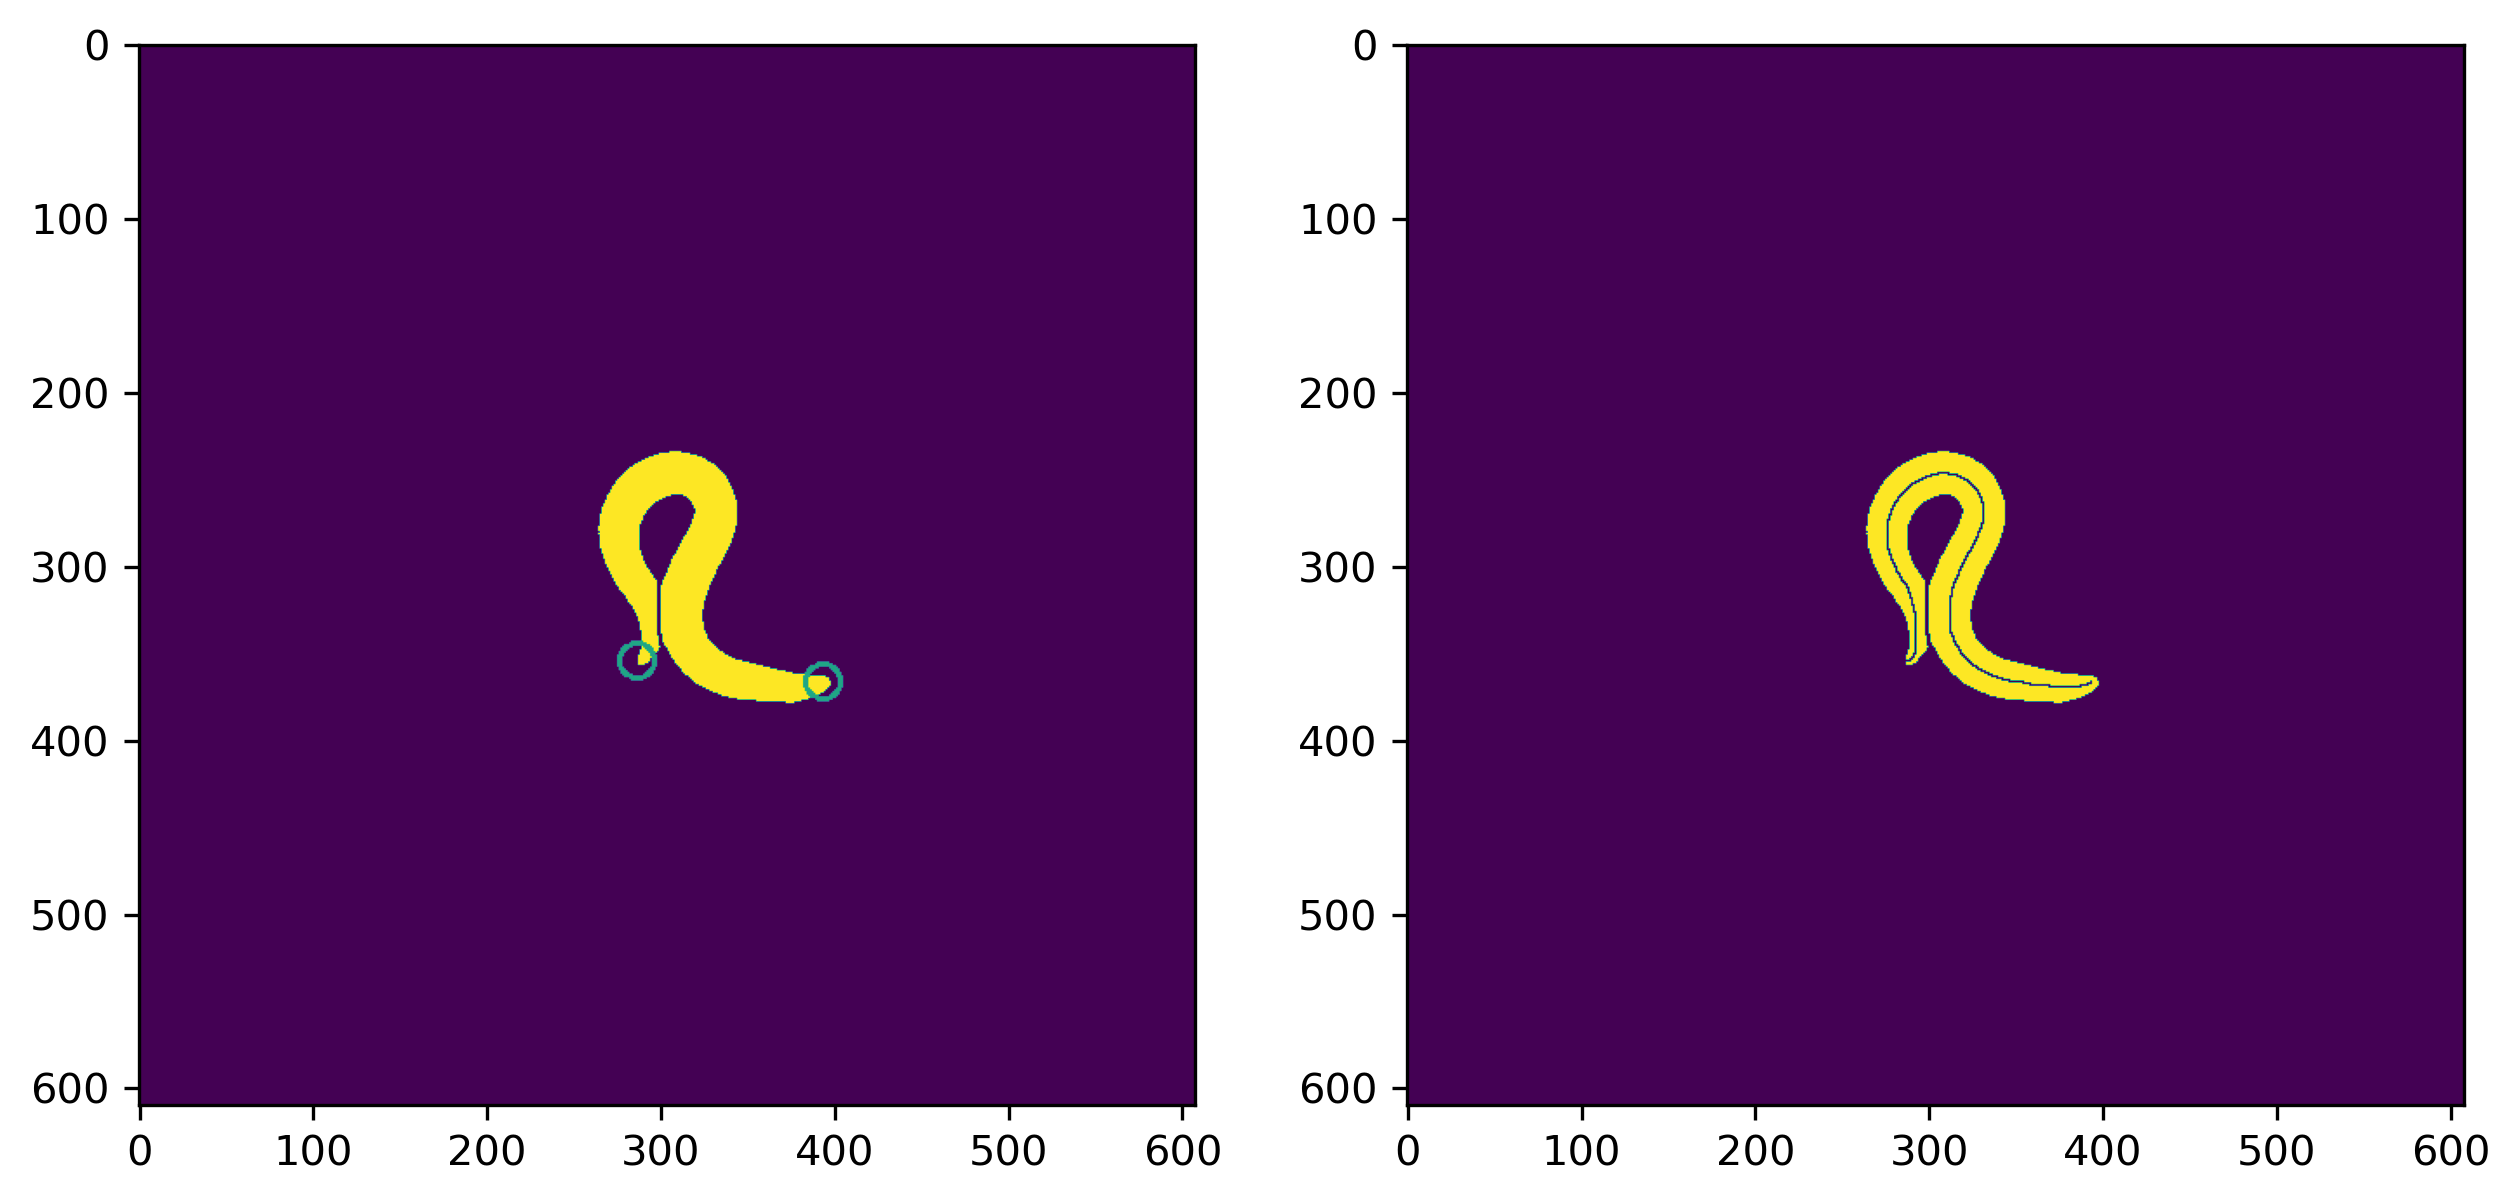

img109205.tif


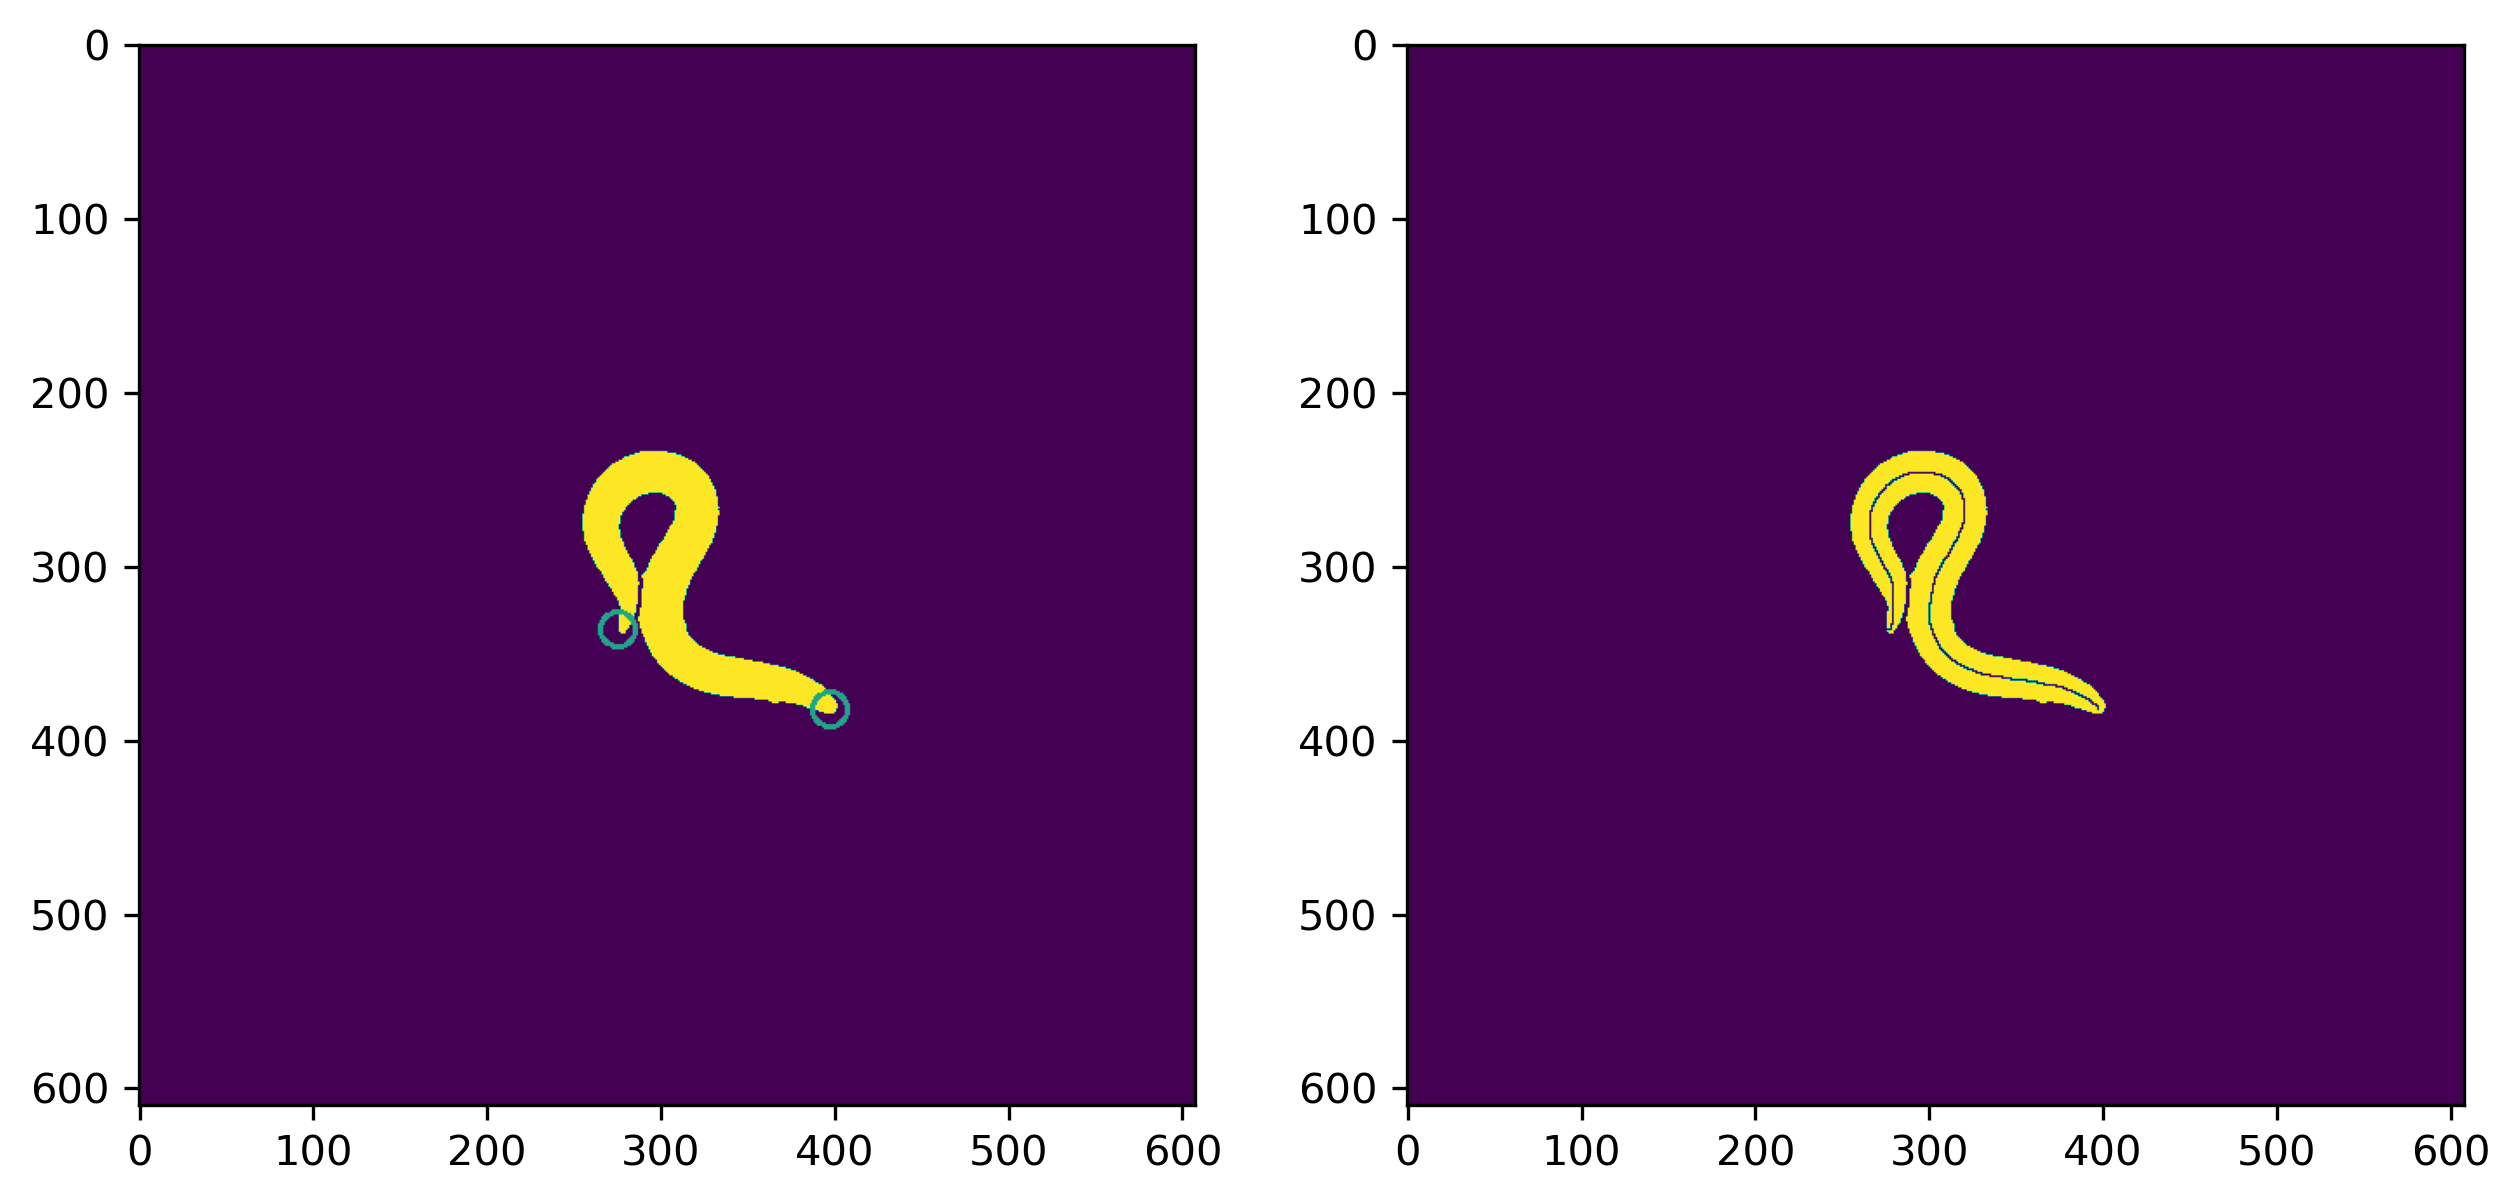

img117011.tif


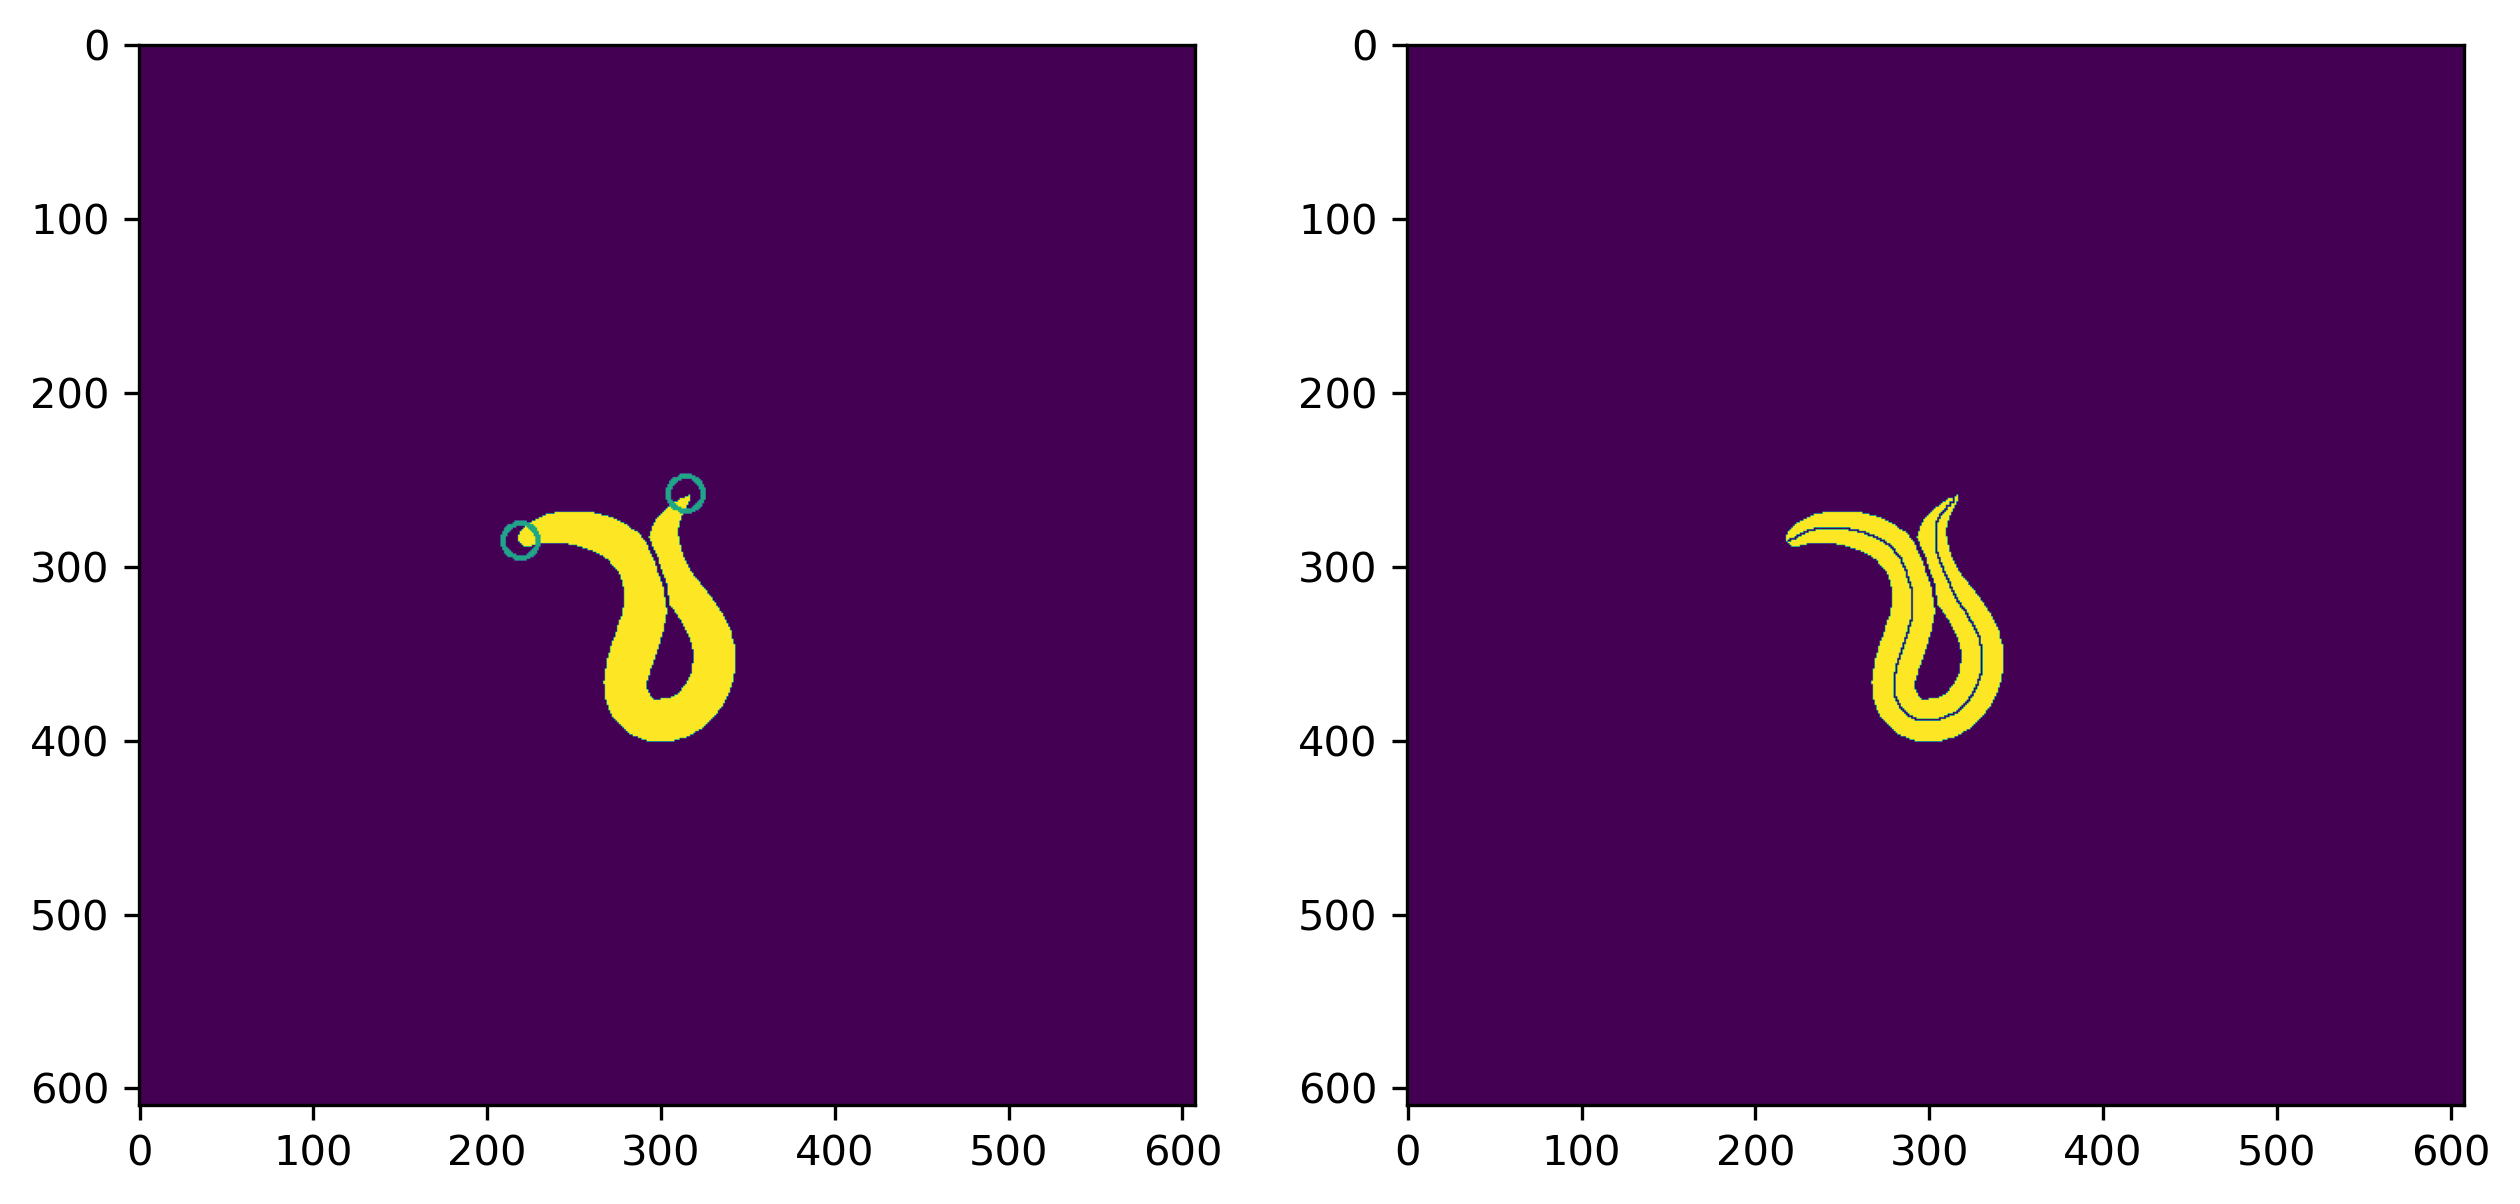

img117071.tif


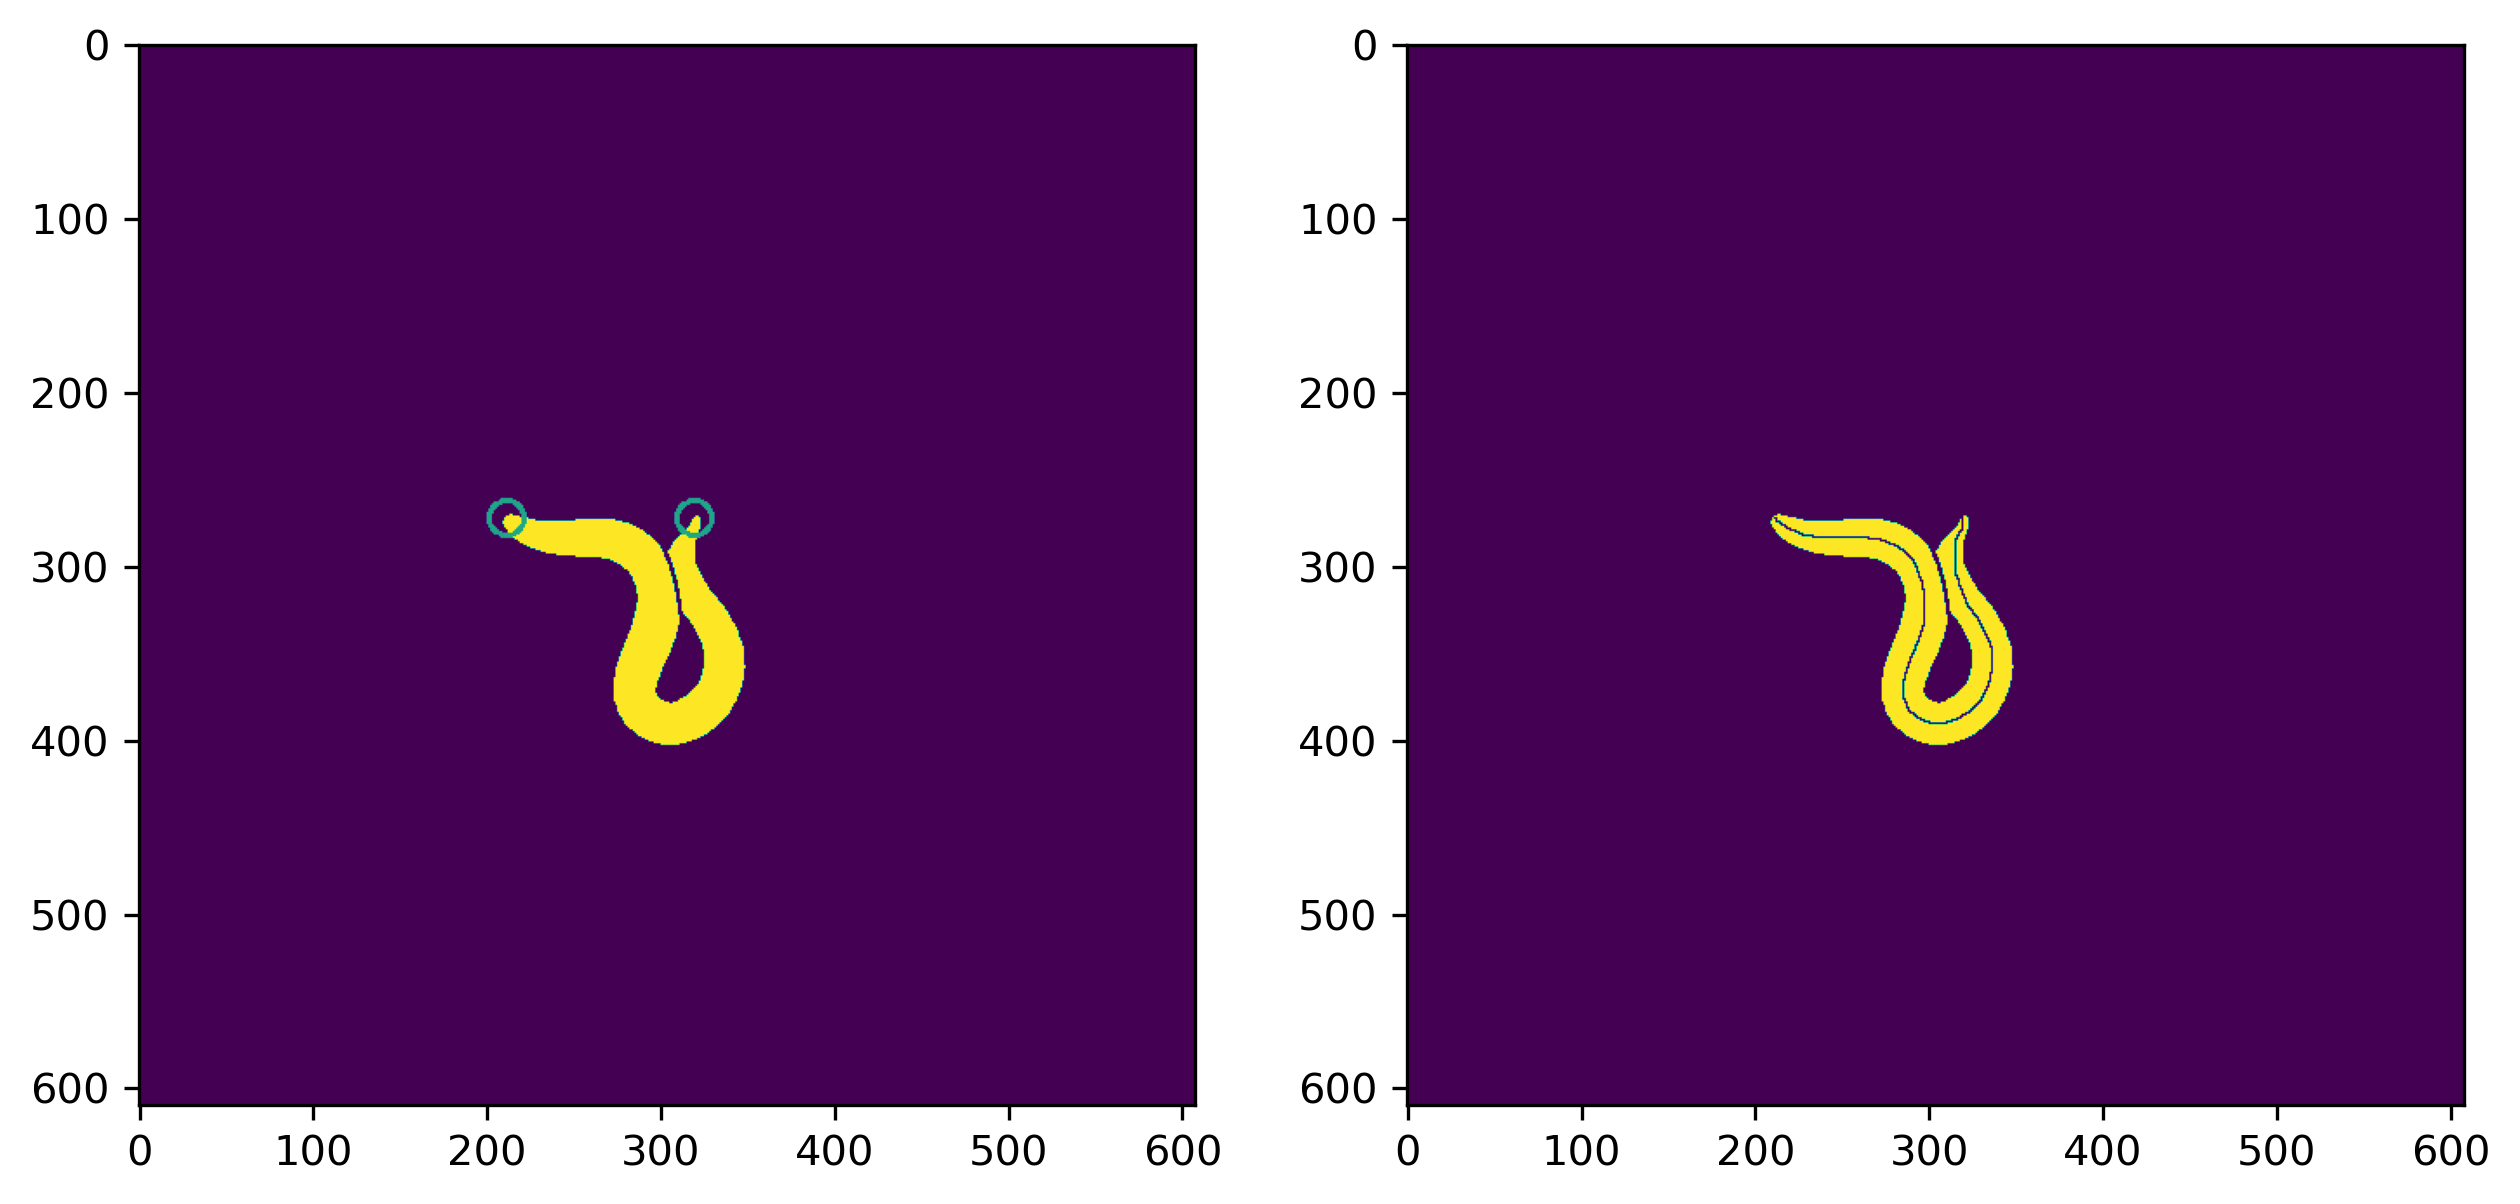

img117131.tif


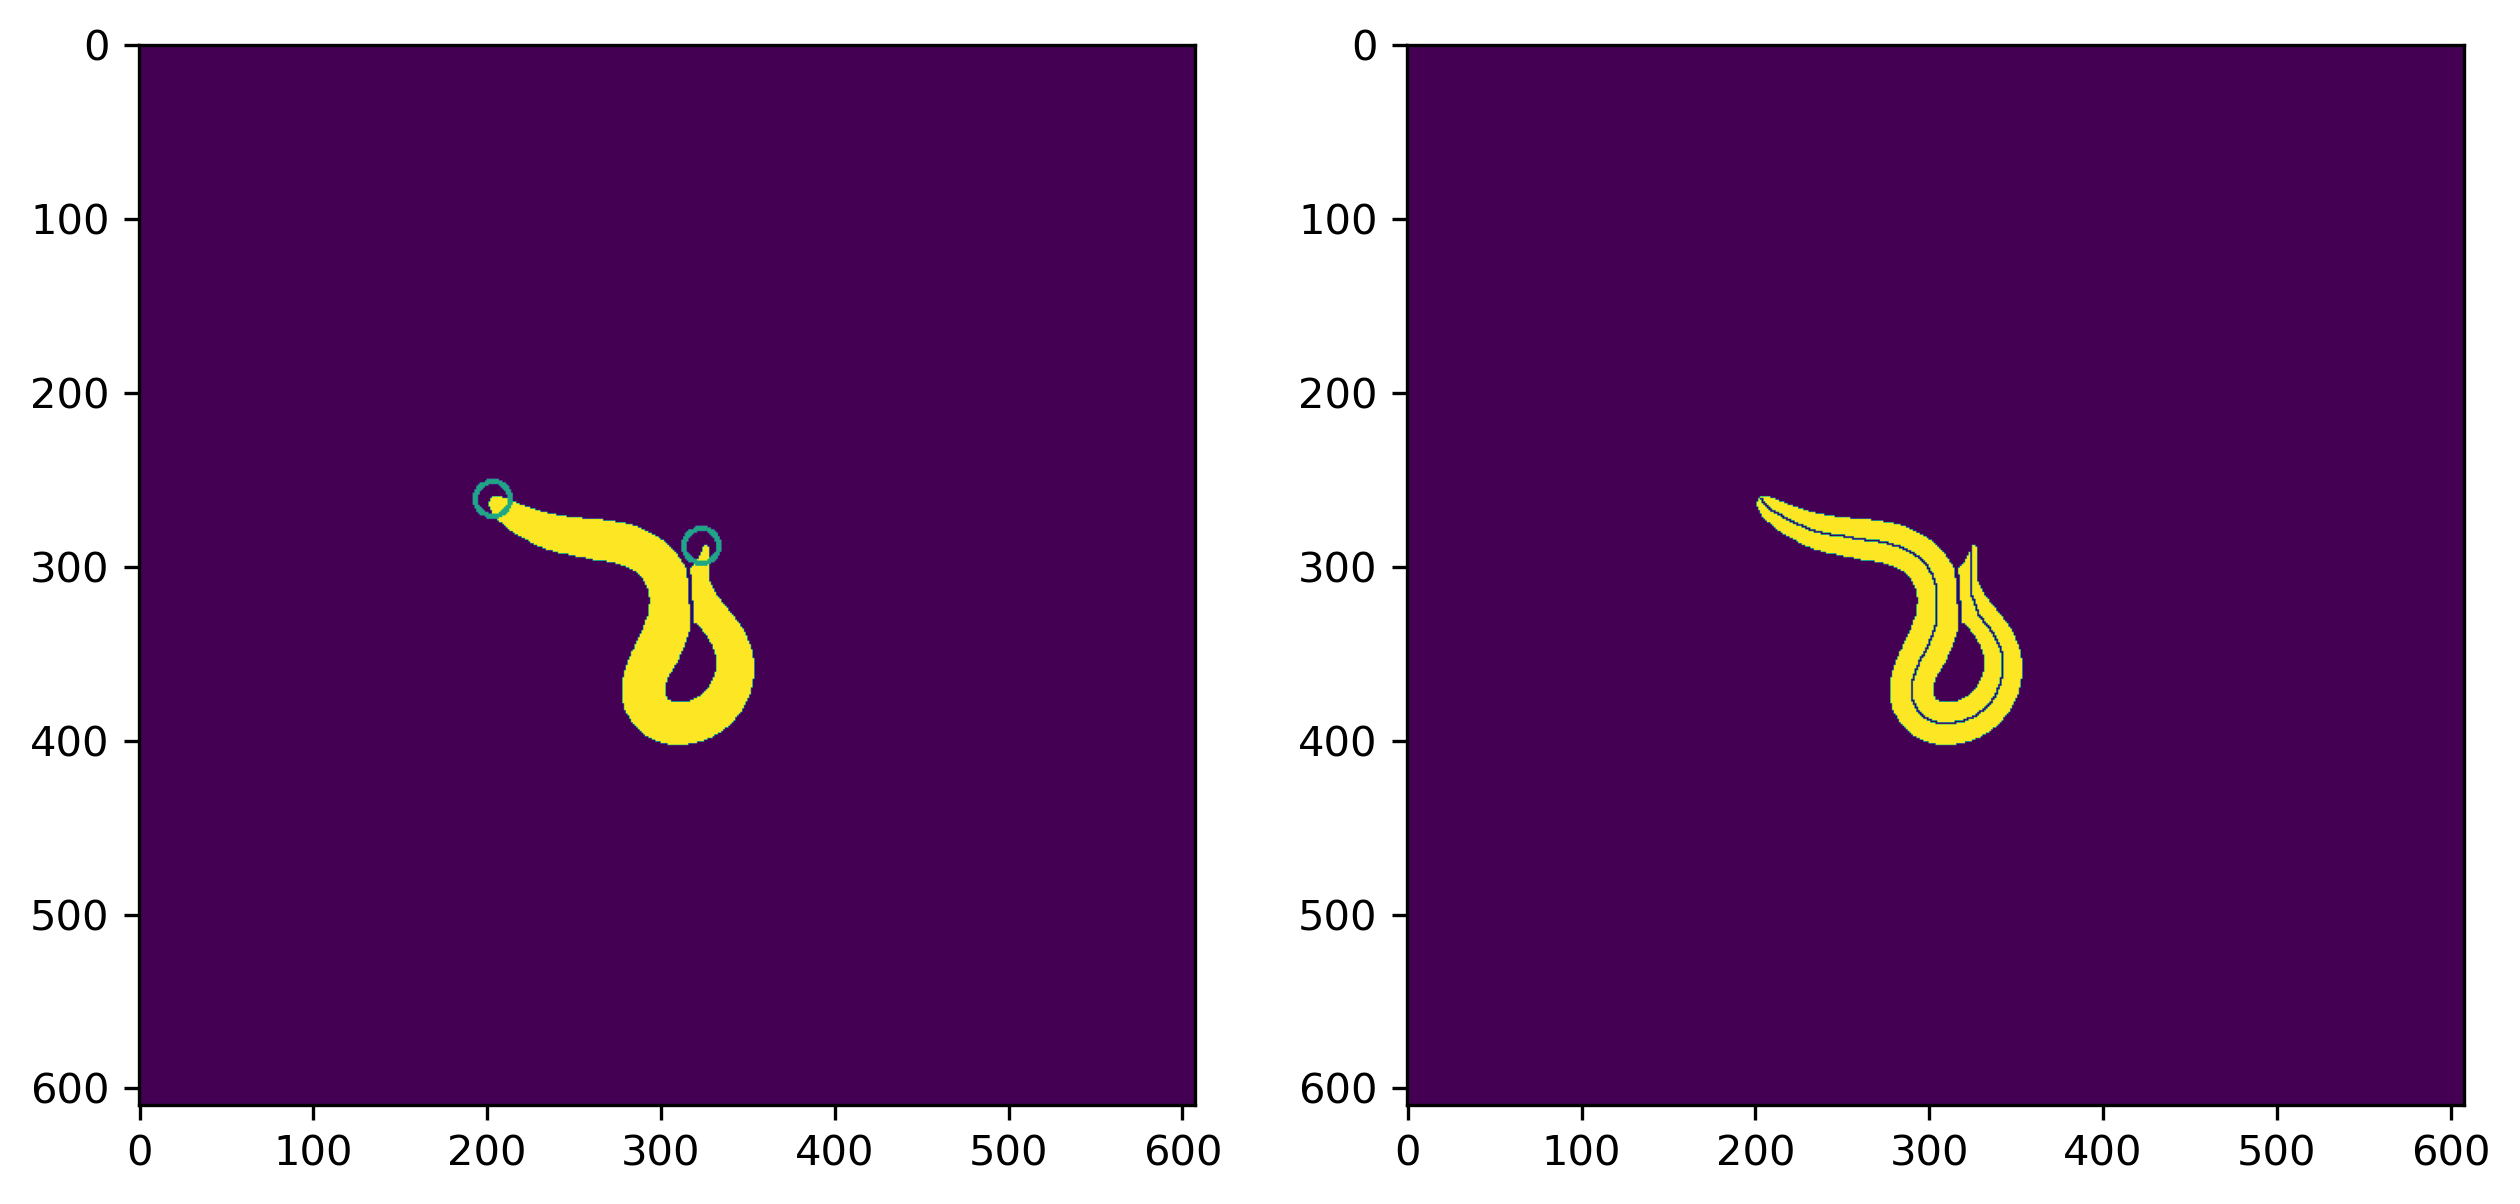

In [6]:
#to visualize
regex = re.compile(r'\d+')
for filename in img_list:
    if 'img' in filename:
        
        print(filename)
        
        i=int(regex.search(filename).group(0))
        #print(i)
        start_point=(int(head_y[i]), int(head_x[i]))
        end_point = (int(tail_y[i]), int(tail_x[i]))
        #print(start_point)
        #print(end_point)
        
        img=tiff.imread(os.path.join(path,filename))
        
        plt.figure(figsize=(10,10), dpi=300)
#         plt.subplot(1,3,1)
#         plt.imshow(img)
        
        annotated_img=img.copy()
        cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
        cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)
        plt.subplot(1,2,1)
        plt.imshow(annotated_img)
        
        
        u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
        #print(skel_coords)
        try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)
        except: print('head and tail were too close, no centerline could be created')
        else:
            skel_img=img.copy()
            for idx,coords in enumerate(coords):
                skel_img[coords[0],coords[1]]=0

            plt.subplot(1,2,2)
            plt.imshow(skel_img)
            plt.show()

In [23]:
#to analyze
regex = re.compile(r'\d+')

num_splines=100

output_path='2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_th20_TEST'

skel_df=pd.DataFrame(index=)

for filename in img_list:
    if 'img' in filename:

        print(filename)

        i=int(regex.search(filename).group(0))
        start_point=(int(head_y[i]), int(head_x[i]))
        end_point = (int(tail_y[i]), int(tail_x[i]))

        img=tiff.imread(os.path.join(path,filename))

    #     plt.figure(figsize=(10,10), dpi=300)
    #     plt.subplot(1,3,1)
    #     plt.imshow(img)

    #     annotated_img=img.copy()
    #     cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
    #     cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)
    #     plt.subplot(1,3,2)
    #     plt.imshow(annotated_img)


        u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
        csv_writerK.writerow(K)
        break
        ##print(skel_coords)
    #     try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)
    #     except: print('head and tail were too close, no centerline could be created')
    #     else:
    #         skel_img=img.copy()
    #         for idx,coords in enumerate(coords):
    #             skel_img[coords[0],coords[1]]=0

    #         plt.subplot(1,3,3)
    #         plt.imshow(skel_img)
    #         plt.show()
csvfileK.close()
print('end')

img001.tif
end


In [42]:
bodyparts=[]
for i in np.arange(100):
    bodyparts.append('bodypart'+str(i))

In [43]:
bodyparts

['bodypart0',
 'bodypart1',
 'bodypart2',
 'bodypart3',
 'bodypart4',
 'bodypart5',
 'bodypart6',
 'bodypart7',
 'bodypart8',
 'bodypart9',
 'bodypart10',
 'bodypart11',
 'bodypart12',
 'bodypart13',
 'bodypart14',
 'bodypart15',
 'bodypart16',
 'bodypart17',
 'bodypart18',
 'bodypart19',
 'bodypart20',
 'bodypart21',
 'bodypart22',
 'bodypart23',
 'bodypart24',
 'bodypart25',
 'bodypart26',
 'bodypart27',
 'bodypart28',
 'bodypart29',
 'bodypart30',
 'bodypart31',
 'bodypart32',
 'bodypart33',
 'bodypart34',
 'bodypart35',
 'bodypart36',
 'bodypart37',
 'bodypart38',
 'bodypart39',
 'bodypart40',
 'bodypart41',
 'bodypart42',
 'bodypart43',
 'bodypart44',
 'bodypart45',
 'bodypart46',
 'bodypart47',
 'bodypart48',
 'bodypart49',
 'bodypart50',
 'bodypart51',
 'bodypart52',
 'bodypart53',
 'bodypart54',
 'bodypart55',
 'bodypart56',
 'bodypart57',
 'bodypart58',
 'bodypart59',
 'bodypart60',
 'bodypart61',
 'bodypart62',
 'bodypart63',
 'bodypart64',
 'bodypart65',
 'bodypart66',
 'bod

In [47]:
#create pandas dataframe
scorer=['Ulises']
bodyparts=[]
for i in np.arange(100):
    bodyparts.append('bodypart'+str(i))
coords=['x','y']
arrays=pd.MultiIndex.from_product([scorer,bodyparts, coords],

                           names=['scorer','bodyparts', 'coords'])
frames=np.arange(0,10)
skeleton_df=pd.DataFrame(index=frames, columns=arrays)

In [48]:
skeleton_df.head(2)

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  

[2 rows x 200 columns]

In [89]:
skeleton_df.iloc[0]['Ulises',:]

bodyparts   coords
bodypart0   x           2
            y         NaN
bodypart1   x           3
            y         NaN
bodypart2   x         NaN
                     ... 
bodypart97  y         NaN
bodypart98  x         NaN
            y         NaN
bodypart99  x         NaN
            y         NaN
Name: 0, Length: 200, dtype: object

In [79]:
skeleton_df

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0                 2  NaN         3  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
2               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
3               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
4               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
5               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
6               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
7               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
8               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
9               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
2               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
3               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
4               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
5               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
6               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
7               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
8               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
9               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  
2                NaN  NaN        NaN  NaN  
3                NaN  NaN        NaN  NaN  
4                NaN  NaN        NaN  NaN  
5                NaN  NaN        NaN  NaN  
6                NaN  NaN        NaN  NaN  
7                NaN  NaN        NaN  NaN  
8                NaN  NaN        NaN  NaN  
9                NaN  NaN        NaN  NaN  

[10 rows x 200 columns]

In [59]:
spline_coords[0]

array([272.06519468, 272.58295585, 273.83594757, 275.45451869,
       277.18062054, 278.85271699, 280.39069441, 281.78077162,
       283.06040993, 284.30322311, 285.60388737, 287.06305135,
       288.77224611, 290.79879811, 293.17199568, 295.87981947,
       298.8777941 , 302.09985613, 305.46923557, 308.90933739,
       312.35432305, 315.75583285, 319.08361524, 322.32469668,
       325.48252851, 328.57613393, 331.63914107, 334.71647424,
       337.85592825, 341.09801144, 344.46573704, 347.95441434,
       351.52158106, 355.08191195, 358.51730787, 361.69414902,
       364.48091272, 366.76579114, 368.47425226, 369.58272553,
       370.11556497, 370.13109794, 369.70679018, 368.92441036,
       367.85520486, 366.54672517, 365.01994749, 363.27563206,
       361.30182077, 359.08133791, 356.59929018, 353.85016732,
       350.84125007, 347.59146466, 344.12941292, 340.49139539,
       336.71943456, 332.85929798, 328.95852148, 325.06443229,
       321.22217226, 317.47272096, 313.85091893, 310.38

In [12]:
skel_coords

(array([272, 272, 272, 272, 272, 273, 273, 274, 274, 274, 275, 275, 275,
        275, 276, 276, 277, 277, 277, 278, 278, 278, 279, 279, 279, 280,
        280, 280, 281, 281, 281, 282, 282, 282, 283, 283, 283, 284, 284,
        284, 285, 285, 285, 286, 286, 286, 287, 287, 287, 288, 288, 289,
        289, 289, 290, 290, 291, 291, 292, 292, 293, 293, 294, 294, 295,
        295, 296, 296, 297, 298, 298, 299, 299, 300, 301, 301, 302, 303,
        304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 313, 314, 315,
        316, 317, 317, 318, 319, 320, 320, 321, 322, 322, 323, 324, 324,
        325, 326, 327, 327, 328, 328, 329, 330, 330, 331, 332, 332, 333,
        334, 334, 335, 336, 336, 337, 338, 338, 339, 340, 340, 341, 342,
        343, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354,
        355, 356, 357, 358, 358, 359, 360, 360, 361, 362, 362, 363, 363,
        364, 364, 365, 365, 366, 366, 366, 367, 367, 367, 368, 368, 368,
        369, 369, 369, 369, 370, 370, 370, 370, 370